<a href="https://colab.research.google.com/github/amzad-786githumb/Privacy-Preserving-Synthetic-Tabular-Data-Generation-Using-Generative-Adversarial-Networks/blob/main/07_Proposed_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =======================================================
# NOTEBOOK 07
#
# Privacy-Preserving Statistical–Machine Learning Synthetic Data Generation
# — Proposed SPP-GAN Framework
# ========================================================

"""
SPP-GAN: A Privacy-Preserving Statistical–Machine Learning Framework for
High-Fidelity Synthetic Tabular Data Generation

Researcher
---------
Mohd Amzad

Notebook
--------
Notebook 07 – Proposed SPP-GAN Framework for Privacy-Preserving
High-Fidelity Synthetic Tabular Data Generation

Purpose
-------
This notebook implements the proposed SPP-GAN framework for privacy-preserving
high-fidelity synthetic tabular data generation.

The framework integrates statistical distribution preservation, machine
learning-based generative modeling, adversarial learning, and differential
privacy into a unified synthetic data generation methodology.

SPP-GAN is developed as the proposed research framework following the
statistical and machine learning baselines established in the preceding
notebooks.

The framework is designed to generate synthetic tabular datasets while
maintaining an appropriate balance between:

• Privacy
• Statistical fidelity
• Distribution preservation
• Correlation preservation
• Data utility
• Structural consistency

Model Implemented
-----------------
• SPP-GAN
  Privacy-Preserving Statistical–Machine Learning Generative Adversarial
  Network Framework

Research Components
-------------------
• Statistical feature representation
• Adversarial generative modeling
• Privacy-preserving training
• Differential Privacy
• Gradient clipping
• Gaussian noise mechanism
• Privacy accounting
• Distribution-preserving objectives
• Correlation-preserving objectives
• Synthetic data generation

Privacy Mechanism
-----------------
• Differential Privacy
• DP-SGD
• Per-sample gradient computation
• Gradient clipping
• Gaussian noise addition
• Privacy accounting using (ε, δ)-Differential Privacy
• Opacus PrivacyEngine where applicable

Inputs
------
Notebook 02
• Preprocessed datasets
• Dataset metadata
• Feature information
• Train, validation, and test splits

Previous Generative Modeling Notebooks
--------------------------------------
Notebook 04
• CTGAN baseline
• Synthetic data generation
• Baseline evaluation artifacts

Notebook 05
• TVAE baseline
• Synthetic data generation
• Baseline evaluation artifacts

Notebook 06
• DP-CTGAN baseline
• Differentially private GAN training
• Privacy-accounting artifacts

Project Configuration
---------------------
• config.yaml
• Reproducibility settings
• Dataset configuration
• SPP-GAN hyperparameters
• Privacy parameters
• Model configuration
• Evaluation configuration

Datasets
--------
• Adult Income
• Bank Marketing
• diabetes_130us

Outputs
-------
• Trained SPP-GAN generator models
• Trained SPP-GAN discriminator models
• Synthetic datasets
• Model checkpoints
• Training history
• Privacy-training history
• Privacy-accounting results
• SPP-GAN configuration records
• Dataset-level results
• Generated visualizations
• Intermediate research artifacts
• Final research-readiness report

Workflow
--------
A. Environment Setup
B. Project Configuration
C. Dataset Loading and Validation
D. Feature and Tensor Preparation
E. SPP-GAN Configuration
F. Differential Privacy Configuration
G. Generator Architecture
H. Discriminator Architecture
I. SPP-GAN Loss Functions
J. Optimizers
K. Privacy Mechanism Configuration
L. SPP-GAN Training
M. Privacy Accounting
N. Synthetic Data Generation
O. Synthetic Data Validation
P. Model and Dataset Saving
Q. Training and Privacy Visualizations
R. Research Results Summary
S. Final Verification
T. Research Readiness Report

Research Role
-------------
Notebook 07 implements the proposed SPP-GAN methodology and serves as the
principal experimental notebook for the proposed research framework.

The models developed in this notebook are evaluated against the established
generative baselines, including CTGAN, TVAE, and DP-CTGAN, using the common
evaluation methodology established across the research pipeline.

The comparative evaluation focuses on privacy, statistical fidelity,
distribution preservation, correlation preservation, structural
consistency, and downstream data utility.

The results generated by this notebook provide the experimental evidence
required to assess the effectiveness of the proposed SPP-GAN framework
against the baseline synthetic data generation methods.

Research Objective
------------------
The primary objective of SPP-GAN is to investigate whether an integrated
privacy-preserving statistical–machine learning generative framework can
produce higher-quality synthetic tabular data while maintaining a rigorous
differential privacy guarantee and improving the privacy–utility–fidelity
trade-off relative to established baseline approaches.

Version
-------
1.0
"""

In [1]:
# ==============================================================================
# PART A1 — GOOGLE DRIVE MOUNT
# ==============================================================================

print("=" * 100)
print("PART A1 — GOOGLE DRIVE MOUNT")
print("=" * 100)

from google.colab import drive

drive.mount(
    "/content/drive"
)

print()
print("Google Drive mounted successfully.")
print("Mount Point : /content/drive")

PART A1 — GOOGLE DRIVE MOUNT
Mounted at /content/drive

Google Drive mounted successfully.
Mount Point : /content/drive


In [2]:
# ==============================================================================
# PART A2 — ENVIRONMENT SETUP
# ==============================================================================

print("=" * 100)
print("PART A2 — ENVIRONMENT SETUP")
print("=" * 100)

import os
import sys
import random
import warnings
import platform

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    DataLoader,
    TensorDataset
)

warnings.filterwarnings(
    "ignore"
)

print()
print("Python Version :", sys.version)
print("Platform       :", platform.platform())
print("PyTorch        :", torch.__version__)
print("NumPy          :", np.__version__)
print("Pandas         :", pd.__version__)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print()
print("Computation Device :", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU Device         :",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA Version       :",
        torch.version.cuda
    )

else:

    print(
        "GPU Device         : "
        "Not Available"
    )

print()
print("PART A2 — Environment setup completed.")

PART A2 — ENVIRONMENT SETUP

Python Version : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform       : Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch        : 2.11.0+cu128
NumPy          : 2.0.2
Pandas         : 2.2.2

Computation Device : cuda
GPU Device         : Tesla T4
CUDA Version       : 12.8

PART A2 — Environment setup completed.


In [3]:
# ==============================================================================
# PART A3 — REPRODUCIBILITY CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART A3 — REPRODUCIBILITY CONFIGURATION")
print("=" * 100)

SEED = 42

random.seed(
    SEED
)

np.random.seed(
    SEED
)

torch.manual_seed(
    SEED
)

if torch.cuda.is_available():

    torch.cuda.manual_seed(
        SEED
    )

    torch.cuda.manual_seed_all(
        SEED
    )

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

os.environ["PYTHONHASHSEED"] = str(
    SEED
)

print()
print("Random Seed :", SEED)
print(
    "Python Random      : Configured"
)
print(
    "NumPy Random       : Configured"
)
print(
    "PyTorch Random     : Configured"
)
print(
    "CUDA Random        : Configured"
    if torch.cuda.is_available()
    else "CUDA Random        : Not Applicable"
)
print(
    "CuDNN Determinism  : Enabled"
)
print(
    "CuDNN Benchmark    : Disabled"
)

print()
print("PART A3 — Reproducibility configuration completed.")

PART A3 — REPRODUCIBILITY CONFIGURATION

Random Seed : 42
Python Random      : Configured
NumPy Random       : Configured
PyTorch Random     : Configured
CUDA Random        : Configured
CuDNN Determinism  : Enabled
CuDNN Benchmark    : Disabled

PART A3 — Reproducibility configuration completed.


In [4]:
# ==============================================================================
# PART B1 — PROJECT CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART B1 — PROJECT CONFIGURATION")
print("=" * 100)

PROJECT_ROOT = "/content/drive/MyDrive/SPP_GAN_Project"

CONFIG_PATH = os.path.join(
    PROJECT_ROOT,
    "config.yaml"
)

if not os.path.exists(CONFIG_PATH):
    raise FileNotFoundError(
        f"Project configuration file not found:\n{CONFIG_PATH}"
    )

print()
print("Project Root :", PROJECT_ROOT)
print("Config Path  :", CONFIG_PATH)

print()
print("Project configuration file located successfully.")

PART B1 — PROJECT CONFIGURATION

Project Root : /content/drive/MyDrive/SPP_GAN_Project
Config Path  : /content/drive/MyDrive/SPP_GAN_Project/config.yaml

Project configuration file located successfully.


In [5]:
# ==============================================================================
# PART B2 — LOAD PROJECT CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART B2 — LOAD PROJECT CONFIGURATION")
print("=" * 100)

import yaml

with open(
    CONFIG_PATH,
    "r"
) as file:

    PROJECT_CONFIG = yaml.safe_load(
        file
    )

if PROJECT_CONFIG is None:
    raise ValueError(
        "Project configuration is empty."
    )

print()
print("Project configuration loaded successfully.")

print()
print("Configuration Sections:")

for section in PROJECT_CONFIG:

    print(
        f" - {section}"
    )

print()
print("PART B2 — Project configuration loading completed.")

PART B2 — LOAD PROJECT CONFIGURATION

Project configuration loaded successfully.

Configuration Sections:
 - batch_size
 - beta1
 - beta2
 - delta
 - device
 - epochs
 - gradient_clip
 - latent_dimension
 - learning_rate
 - noise_multiplier
 - optimizer
 - privacy_budget
 - seed

PART B2 — Project configuration loading completed.


In [6]:
# ==============================================================================
# PART B3 — DATASET CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART B3 — DATASET CONFIGURATION")
print("=" * 100)

DATASETS = [
    "Adult Income",
    "Bank Marketing",
    "diabetes_130us"
]

EXPECTED_DATASET_FILES = {
    "Adult Income":
        "adult_income_processed.csv",
    "Bank Marketing":
        "bank_marketing_processed.csv",
    "diabetes_130us":
        "diabetes_130us_processed.csv"
}

TARGET_COLUMNS = {
    "Adult Income":
        "income",
    "Bank Marketing":
        "y",
    "diabetes_130us":
        "readmitted"
}

print()
print("Datasets:")

for dataset in DATASETS:

    print(
        f" - {dataset}"
    )

print()
print("Dataset Files:")

for dataset, filename in (
    EXPECTED_DATASET_FILES.items()
):

    print(
        f"{dataset:20s} : {filename}"
    )

print()
print("Target Columns:")

for dataset, target in (
    TARGET_COLUMNS.items()
):

    print(
        f"{dataset:20s} : {target}"
    )

print()
print("PART B3 — Dataset configuration completed.")

PART B3 — DATASET CONFIGURATION

Datasets:
 - Adult Income
 - Bank Marketing
 - diabetes_130us

Dataset Files:
Adult Income         : adult_income_processed.csv
Bank Marketing       : bank_marketing_processed.csv
diabetes_130us       : diabetes_130us_processed.csv

Target Columns:
Adult Income         : income
Bank Marketing       : y
diabetes_130us       : readmitted

PART B3 — Dataset configuration completed.


In [7]:
# ==============================================================================
# PART B4 — CONFIGURATION VALIDATION
# ==============================================================================

print("=" * 100)
print("PART B4 — CONFIGURATION VALIDATION")
print("=" * 100)

if len(DATASETS) != 3:
    raise ValueError(
        "Unexpected number of research datasets."
    )

for dataset in DATASETS:

    if dataset not in EXPECTED_DATASET_FILES:
        raise KeyError(
            f"Dataset file configuration missing for {dataset}."
        )

    if dataset not in TARGET_COLUMNS:
        raise KeyError(
            f"Target column configuration missing for {dataset}."
        )

print()
print("Number of Datasets :", len(DATASETS))
print(
    "Dataset Configuration : PASS"
)
print(
    "Target Configuration  : PASS"
)
print(
    "Configuration File    : PASS"
)

print()
print("PART B4 — Configuration validation completed.")

PART B4 — CONFIGURATION VALIDATION

Number of Datasets : 3
Dataset Configuration : PASS
Target Configuration  : PASS
Configuration File    : PASS

PART B4 — Configuration validation completed.


In [8]:
# ==============================================================================
# PART C1 — DATASET LOADING
# ==============================================================================

print("=" * 100)
print("PART C1 — DATASET LOADING")
print("=" * 100)

PROCESSED_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    "datasets",
    "processed"
)

REAL_DATASETS = {}

for dataset in DATASETS:

    filename = EXPECTED_DATASET_FILES[
        dataset
    ]

    file_path = os.path.join(
        PROCESSED_DATA_DIR,
        filename
    )

    if not os.path.exists(file_path):

        raise FileNotFoundError(
            f"Processed dataset not found for "
            f"{dataset}:\n{file_path}"
        )

    real_data = pd.read_csv(
        file_path
    )

    if real_data.empty:

        raise ValueError(
            f"Dataset is empty: {dataset}"
        )

    REAL_DATASETS[dataset] = real_data

    print(
        f"{dataset:20s} : "
        f"{real_data.shape[0]:>8,} rows × "
        f"{real_data.shape[1]:>3} columns"
    )

print()
print(
    "Processed Data Directory :"
)
print(
    PROCESSED_DATA_DIR
)

print()
print(
    "Datasets Loaded:"
)

for dataset in DATASETS:

    print(
        f" - {dataset}"
    )

print()
print(
    "PART C1 — Dataset loading completed."
)

PART C1 — DATASET LOADING
Adult Income         :   32,515 rows ×  15 columns
Bank Marketing       :   45,211 rows ×  17 columns
diabetes_130us       :  101,766 rows ×  48 columns

Processed Data Directory :
/content/drive/MyDrive/SPP_GAN_Project/datasets/processed

Datasets Loaded:
 - Adult Income
 - Bank Marketing
 - diabetes_130us

PART C1 — Dataset loading completed.


In [9]:
# ==============================================================================
# PART C2 — DATASET LOADING VALIDATION
# ==============================================================================

print("=" * 100)
print("PART C2 — DATASET LOADING VALIDATION")
print("=" * 100)

DATASET_LOADING_STATUS = {}

for dataset in DATASETS:

    status = (
        dataset in REAL_DATASETS
        and isinstance(
            REAL_DATASETS[dataset],
            pd.DataFrame
        )
        and not REAL_DATASETS[dataset].empty
    )

    DATASET_LOADING_STATUS[
        dataset
    ] = status

    print(
        f"{dataset:20s} : "
        f"{'PASS' if status else 'FAIL'}"
    )

ALL_DATASETS_LOADED = all(
    DATASET_LOADING_STATUS.values()
)

print()
print(
    f"Overall Dataset Loading Status : "
    f"{'PASS' if ALL_DATASETS_LOADED else 'FAIL'}"
)

if not ALL_DATASETS_LOADED:

    raise RuntimeError(
        "One or more research datasets "
        "failed dataset loading validation."
    )

print()
print(
    "PART C2 — Dataset loading validation completed."
)

PART C2 — DATASET LOADING VALIDATION
Adult Income         : PASS
Bank Marketing       : PASS
diabetes_130us       : PASS

Overall Dataset Loading Status : PASS

PART C2 — Dataset loading validation completed.


In [10]:
# ==============================================================================
# PART C3 — DATASET STRUCTURE SUMMARY
# ==============================================================================

print("=" * 100)
print("PART C3 — DATASET STRUCTURE SUMMARY")
print("=" * 100)

DATASET_STRUCTURE_SUMMARY = []

for dataset in DATASETS:

    data = REAL_DATASETS[
        dataset
    ]

    target_column = TARGET_COLUMNS[
        dataset
    ]

    DATASET_STRUCTURE_SUMMARY.append({

        "Dataset":
            dataset,

        "Rows":
            len(data),

        "Columns":
            len(data.columns),

        "Target":
            target_column,

        "Target Exists":
            target_column in data.columns,

        "Missing Values":
            int(
                data.isna()
                .sum()
                .sum()
            ),

        "Duplicate Rows":
            int(
                data.duplicated()
                .sum()
            )

    })

DATASET_STRUCTURE_SUMMARY_DF = pd.DataFrame(
    DATASET_STRUCTURE_SUMMARY
)

print()

print(
    DATASET_STRUCTURE_SUMMARY_DF.to_string(
        index=False
    )
)

print()
print(
    "PART C3 — Dataset structure summary completed."
)

PART C3 — DATASET STRUCTURE SUMMARY

       Dataset   Rows  Columns     Target  Target Exists  Missing Values  Duplicate Rows
  Adult Income  32515       15     income           True               0               0
Bank Marketing  45211       17          y           True               0               0
diabetes_130us 101766       48 readmitted           True               0               0

PART C3 — Dataset structure summary completed.


In [11]:
# ==============================================================================
# PART C4 — DATASET COLUMN VALIDATION
# ==============================================================================

print("=" * 100)
print("PART C4 — DATASET COLUMN VALIDATION")
print("=" * 100)

DATASET_COLUMN_VALIDATION = {}

for dataset in DATASETS:

    data = REAL_DATASETS[
        dataset
    ]

    target_column = TARGET_COLUMNS[
        dataset
    ]

    columns = data.columns.tolist()

    duplicate_columns = (
        len(columns)
        != len(set(columns))
    )

    target_exists = (
        target_column in columns
    )

    DATASET_COLUMN_VALIDATION[
        dataset
    ] = {

        "Column Names Unique":
            not duplicate_columns,

        "Target Exists":
            target_exists,

        "Column Count":
            len(columns)

    }

    print()
    print(
        f"Dataset : {dataset}"
    )

    print(
        f"Column Names Unique : "
        f"{'PASS' if not duplicate_columns else 'FAIL'}"
    )

    print(
        f"Target Exists       : "
        f"{'PASS' if target_exists else 'FAIL'}"
    )

    print(
        f"Column Count        : "
        f"{len(columns)}"
    )

    if duplicate_columns:

        raise ValueError(
            f"Duplicate column names detected "
            f"in {dataset}."
        )

    if not target_exists:

        raise KeyError(
            f"Target column '{target_column}' "
            f"not found in {dataset}."
        )

print()
print(
    "PART C4 — Dataset column validation completed."
)

PART C4 — DATASET COLUMN VALIDATION

Dataset : Adult Income
Column Names Unique : PASS
Target Exists       : PASS
Column Count        : 15

Dataset : Bank Marketing
Column Names Unique : PASS
Target Exists       : PASS
Column Count        : 17

Dataset : diabetes_130us
Column Names Unique : PASS
Target Exists       : PASS
Column Count        : 48

PART C4 — Dataset column validation completed.


In [12]:
# ==============================================================================
# PART C5 — TRAIN / VALIDATION / TEST SPLITTING
# ==============================================================================

print("=" * 100)
print("PART C5 — TRAIN / VALIDATION / TEST SPLITTING")
print("=" * 100)

from sklearn.model_selection import train_test_split

TRAIN_DATASETS = {}
VALIDATION_DATASETS = {}
TEST_DATASETS = {}

TRAIN_ROW_IDS = {}
VALIDATION_ROW_IDS = {}
TEST_ROW_IDS = {}

SPLIT_SEED = 42
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

for dataset in DATASETS:

    df = REAL_DATASETS[dataset].copy()

    target_column = TARGET_COLUMNS[dataset]

    if target_column not in df.columns:
        raise KeyError(
            f"Target column '{target_column}' "
            f"not found in {dataset}."
        )

    df["_ORIGINAL_ROW_ID_"] = np.arange(
        len(df)
    )

    train_df, temp_df = train_test_split(
        df,
        test_size=(
            VALIDATION_SIZE
            + TEST_SIZE
        ),
        random_state=SPLIT_SEED,
        stratify=df[target_column]
    )

    relative_test_size = (
        TEST_SIZE
        /
        (
            VALIDATION_SIZE
            + TEST_SIZE
        )
    )

    validation_df, test_df = train_test_split(
        temp_df,
        test_size=relative_test_size,
        random_state=SPLIT_SEED,
        stratify=temp_df[target_column]
    )

    TRAIN_ROW_IDS[dataset] = set(
        train_df["_ORIGINAL_ROW_ID_"]
    )

    VALIDATION_ROW_IDS[dataset] = set(
        validation_df["_ORIGINAL_ROW_ID_"]
    )

    TEST_ROW_IDS[dataset] = set(
        test_df["_ORIGINAL_ROW_ID_"]
    )

    train_df = train_df.drop(
        columns=["_ORIGINAL_ROW_ID_"]
    )

    validation_df = validation_df.drop(
        columns=["_ORIGINAL_ROW_ID_"]
    )

    test_df = test_df.drop(
        columns=["_ORIGINAL_ROW_ID_"]
    )

    TRAIN_DATASETS[dataset] = (
        train_df.reset_index(
            drop=True
        )
    )

    VALIDATION_DATASETS[dataset] = (
        validation_df.reset_index(
            drop=True
        )
    )

    TEST_DATASETS[dataset] = (
        test_df.reset_index(
            drop=True
        )
    )

    print()
    print(dataset)

    print(
        f"Training   : "
        f"{len(TRAIN_DATASETS[dataset]):,}"
    )

    print(
        f"Validation : "
        f"{len(VALIDATION_DATASETS[dataset]):,}"
    )

    print(
        f"Testing    : "
        f"{len(TEST_DATASETS[dataset]):,}"
    )

print()
print(
    "PART C5 — Train / Validation / Test splitting completed."
)

PART C5 — TRAIN / VALIDATION / TEST SPLITTING

Adult Income
Training   : 22,760
Validation : 4,877
Testing    : 4,878

Bank Marketing
Training   : 31,647
Validation : 6,782
Testing    : 6,782

diabetes_130us
Training   : 71,236
Validation : 15,265
Testing    : 15,265

PART C5 — Train / Validation / Test splitting completed.


In [13]:
# ==============================================================================
# PART C6 — SPLIT INTEGRITY VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART C6 — SPLIT INTEGRITY VERIFICATION")
print("=" * 100)

SPLIT_INTEGRITY = {}

for dataset in DATASETS:

    train_ids = TRAIN_ROW_IDS[dataset]
    validation_ids = VALIDATION_ROW_IDS[dataset]
    test_ids = TEST_ROW_IDS[dataset]

    train_validation_overlap = (
        train_ids.intersection(
            validation_ids
        )
    )

    train_test_overlap = (
        train_ids.intersection(
            test_ids
        )
    )

    validation_test_overlap = (
        validation_ids.intersection(
            test_ids
        )
    )

    total_original_rows = len(
        REAL_DATASETS[dataset]
    )

    total_split_rows = (
        len(train_ids)
        + len(validation_ids)
        + len(test_ids)
    )

    checks = {

        "Train/Validation Overlap":
            len(
                train_validation_overlap
            ) == 0,

        "Train/Test Overlap":
            len(
                train_test_overlap
            ) == 0,

        "Validation/Test Overlap":
            len(
                validation_test_overlap
            ) == 0,

        "All Rows Assigned":
            total_split_rows
            == total_original_rows,

        "Split Size Valid":
            (
                len(
                    TRAIN_DATASETS[dataset]
                ) > 0
                and
                len(
                    VALIDATION_DATASETS[dataset]
                ) > 0
                and
                len(
                    TEST_DATASETS[dataset]
                ) > 0
            )
    }

    SPLIT_INTEGRITY[
        dataset
    ] = checks

    print()
    print(
        f"Dataset : {dataset}"
    )

    for check, status in checks.items():

        print(
            f"{check:30s} : "
            f"{'PASS' if status else 'FAIL'}"
        )

    if not all(
        checks.values()
    ):

        raise RuntimeError(
            f"Split integrity verification "
            f"failed for {dataset}."
        )

print()
print(
    "All datasets passed split integrity verification."
)

print()
print(
    "PART C6 — Split integrity verification completed."
)

PART C6 — SPLIT INTEGRITY VERIFICATION

Dataset : Adult Income
Train/Validation Overlap       : PASS
Train/Test Overlap             : PASS
Validation/Test Overlap        : PASS
All Rows Assigned              : PASS
Split Size Valid               : PASS

Dataset : Bank Marketing
Train/Validation Overlap       : PASS
Train/Test Overlap             : PASS
Validation/Test Overlap        : PASS
All Rows Assigned              : PASS
Split Size Valid               : PASS

Dataset : diabetes_130us
Train/Validation Overlap       : PASS
Train/Test Overlap             : PASS
Validation/Test Overlap        : PASS
All Rows Assigned              : PASS
Split Size Valid               : PASS

All datasets passed split integrity verification.

PART C6 — Split integrity verification completed.


In [14]:
# ==============================================================================
# PART C7 — SPLIT STRUCTURE VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART C7 — SPLIT STRUCTURE VERIFICATION")
print("=" * 100)

SPLIT_STRUCTURE_VERIFICATION = {}

for dataset in DATASETS:

    train_data = TRAIN_DATASETS[dataset]
    validation_data = VALIDATION_DATASETS[dataset]
    test_data = TEST_DATASETS[dataset]

    expected_columns = (
        REAL_DATASETS[dataset].columns.tolist()
    )

    checks = {

        "Train Columns":
            train_data.columns.tolist()
            == expected_columns,

        "Validation Columns":
            validation_data.columns.tolist()
            == expected_columns,

        "Test Columns":
            test_data.columns.tolist()
            == expected_columns,

        "Train Target":
            TARGET_COLUMNS[dataset]
            in train_data.columns,

        "Validation Target":
            TARGET_COLUMNS[dataset]
            in validation_data.columns,

        "Test Target":
            TARGET_COLUMNS[dataset]
            in test_data.columns,

        "Train Missing Values":
            not train_data.isna().any().any(),

        "Validation Missing Values":
            not validation_data.isna().any().any(),

        "Test Missing Values":
            not test_data.isna().any().any()
    }

    SPLIT_STRUCTURE_VERIFICATION[
        dataset
    ] = checks

    print()
    print(
        f"Dataset : {dataset}"
    )

    for check, status in checks.items():

        print(
            f"{check:30s} : "
            f"{'PASS' if status else 'FAIL'}"
        )

    if not all(
        checks.values()
    ):

        raise ValueError(
            f"Split structure validation "
            f"failed for {dataset}."
        )

print()
print(
    "All Train / Validation / Test datasets "
    "passed structural verification."
)

print()
print(
    "PART C7 — Split structure verification completed."
)

PART C7 — SPLIT STRUCTURE VERIFICATION

Dataset : Adult Income
Train Columns                  : PASS
Validation Columns             : PASS
Test Columns                   : PASS
Train Target                   : PASS
Validation Target              : PASS
Test Target                    : PASS
Train Missing Values           : PASS
Validation Missing Values      : PASS
Test Missing Values            : PASS

Dataset : Bank Marketing
Train Columns                  : PASS
Validation Columns             : PASS
Test Columns                   : PASS
Train Target                   : PASS
Validation Target              : PASS
Test Target                    : PASS
Train Missing Values           : PASS
Validation Missing Values      : PASS
Test Missing Values            : PASS

Dataset : diabetes_130us
Train Columns                  : PASS
Validation Columns             : PASS
Test Columns                   : PASS
Train Target                   : PASS
Validation Target              : PASS
Test Target

In [15]:
# ==============================================================================
# PART C8 — DATASET SPLIT SUMMARY
# ==============================================================================

print("=" * 100)
print("PART C8 — DATASET SPLIT SUMMARY")
print("=" * 100)

SPLIT_SUMMARY = []

for dataset in DATASETS:

    original_rows = len(
        REAL_DATASETS[dataset]
    )

    train_rows = len(
        TRAIN_DATASETS[dataset]
    )

    validation_rows = len(
        VALIDATION_DATASETS[dataset]
    )

    test_rows = len(
        TEST_DATASETS[dataset]
    )

    total_split_rows = (
        train_rows
        + validation_rows
        + test_rows
    )

    SPLIT_SUMMARY.append({

        "Dataset":
            dataset,

        "Original Rows":
            original_rows,

        "Training Rows":
            train_rows,

        "Validation Rows":
            validation_rows,

        "Test Rows":
            test_rows,

        "Total Split Rows":
            total_split_rows,

        "Training %":
            round(
                train_rows
                / original_rows
                * 100,
                2
            ),

        "Validation %":
            round(
                validation_rows
                / original_rows
                * 100,
                2
            ),

        "Test %":
            round(
                test_rows
                / original_rows
                * 100,
                2
            ),

        "Split Verification":
            total_split_rows
            == original_rows
    })

SPLIT_SUMMARY_DF = pd.DataFrame(
    SPLIT_SUMMARY
)

print()

display(
    SPLIT_SUMMARY_DF
)

print()

print(
    "PART C8 — Dataset split summary completed."
)

PART C8 — DATASET SPLIT SUMMARY



,Dataset,Original Rows,Training Rows,Validation Rows,Test Rows,Total Split Rows,Training %,Validation %,Test %,Split Verification
0,Adult Income,32515,22760,4877,4878,32515,70.0,15.0,15.0,True
1,Bank Marketing,45211,31647,6782,6782,45211,70.0,15.0,15.0,True
2,diabetes_130us,101766,71236,15265,15265,101766,70.0,15.0,15.0,True



PART C8 — Dataset split summary completed.


In [16]:
# ==============================================================================
# PART D1 — DATASET VERIFICATION SUMMARY
# ==============================================================================

print("=" * 100)
print("PART D1 — DATASET VERIFICATION SUMMARY")
print("=" * 100)

DATASET_VERIFICATION = {}

for dataset in DATASETS:

    data = REAL_DATASETS[dataset]
    target_column = TARGET_COLUMNS[dataset]

    DATASET_VERIFICATION[dataset] = {

        "Dataset Loaded":
            isinstance(
                data,
                pd.DataFrame
            ),

        "Rows > 0":
            len(data) > 0,

        "Columns > 0":
            len(data.columns) > 0,

        "Target Exists":
            target_column in data.columns,

        "Missing Values":
            int(
                data.isna()
                .sum()
                .sum()
            ),

        "Duplicate Rows":
            int(
                data.duplicated()
                .sum()
            ),

        "Unique Columns":
            len(data.columns)
            == len(
                set(data.columns)
            ),

        "Data Types Available":
            len(data.dtypes) == len(data.columns)
    }

for dataset in DATASETS:

    print()
    print(
        f"Dataset : {dataset}"
    )

    for check, result in DATASET_VERIFICATION[
        dataset
    ].items():

        if check in [
            "Missing Values",
            "Duplicate Rows"
        ]:

            print(
                f"{check:25s} : {result}"
            )

        else:

            print(
                f"{check:25s} : "
                f"{'PASS' if result else 'FAIL'}"
            )

print()
print(
    "PART D1 — Dataset verification summary completed."
)

PART D1 — DATASET VERIFICATION SUMMARY

Dataset : Adult Income
Dataset Loaded            : PASS
Rows > 0                  : PASS
Columns > 0               : PASS
Target Exists             : PASS
Missing Values            : 0
Duplicate Rows            : 0
Unique Columns            : PASS
Data Types Available      : PASS

Dataset : Bank Marketing
Dataset Loaded            : PASS
Rows > 0                  : PASS
Columns > 0               : PASS
Target Exists             : PASS
Missing Values            : 0
Duplicate Rows            : 0
Unique Columns            : PASS
Data Types Available      : PASS

Dataset : diabetes_130us
Dataset Loaded            : PASS
Rows > 0                  : PASS
Columns > 0               : PASS
Target Exists             : PASS
Missing Values            : 0
Duplicate Rows            : 0
Unique Columns            : PASS
Data Types Available      : PASS

PART D1 — Dataset verification summary completed.


In [17]:
# ==============================================================================
# PART D2 — DATASET SHAPE AND COLUMN VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART D2 — DATASET SHAPE AND COLUMN VERIFICATION")
print("=" * 100)

DATASET_SHAPE_VERIFICATION = {}

for dataset in DATASETS:

    data = REAL_DATASETS[dataset]

    expected_columns = (
        EXPECTED_DATASET_FILES
        and data.columns.tolist()
    )

    actual_columns = data.columns.tolist()

    duplicate_columns = (
        len(actual_columns)
        != len(
            set(actual_columns)
        )
    )

    DATASET_SHAPE_VERIFICATION[
        dataset
    ] = {

        "Rows":
            len(data),

        "Columns":
            len(actual_columns),

        "Column Names Unique":
            not duplicate_columns,

        "Column Order Valid":
            actual_columns
            == expected_columns
    }

    print()
    print(
        f"Dataset : {dataset}"
    )

    print(
        f"Rows                 : "
        f"{len(data):,}"
    )

    print(
        f"Columns              : "
        f"{len(actual_columns)}"
    )

    print(
        f"Column Names Unique  : "
        f"{'PASS' if not duplicate_columns else 'FAIL'}"
    )

print()
print(
    "PART D2 — Dataset shape and column verification completed."
)

PART D2 — DATASET SHAPE AND COLUMN VERIFICATION

Dataset : Adult Income
Rows                 : 32,515
Columns              : 15
Column Names Unique  : PASS

Dataset : Bank Marketing
Rows                 : 45,211
Columns              : 17
Column Names Unique  : PASS

Dataset : diabetes_130us
Rows                 : 101,766
Columns              : 48
Column Names Unique  : PASS

PART D2 — Dataset shape and column verification completed.


In [18]:
# ==============================================================================
# PART D3 — MISSING VALUE VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART D3 — MISSING VALUE VERIFICATION")
print("=" * 100)

DATASET_MISSING_VALUE_SUMMARY = {}

for dataset in DATASETS:

    data = REAL_DATASETS[dataset]

    missing_by_column = (
        data.isna()
        .sum()
    )

    total_missing = int(
        missing_by_column.sum()
    )

    columns_with_missing = (
        missing_by_column[
            missing_by_column > 0
        ]
        .index
        .tolist()
    )

    DATASET_MISSING_VALUE_SUMMARY[
        dataset
    ] = {

        "Total Missing Values":
            total_missing,

        "Columns With Missing Values":
            len(
                columns_with_missing
            ),

        "Missing Value Status":
            total_missing == 0

    }

    print()
    print(
        f"Dataset : {dataset}"
    )

    print(
        f"Total Missing Values : "
        f"{total_missing:,}"
    )

    print(
        f"Columns With Missing : "
        f"{len(columns_with_missing)}"
    )

    print(
        f"Missing Value Status : "
        f"{'PASS' if total_missing == 0 else 'INFO'}"
    )

print()
print(
    "PART D3 — Missing value verification completed."
)

PART D3 — MISSING VALUE VERIFICATION

Dataset : Adult Income
Total Missing Values : 0
Columns With Missing : 0
Missing Value Status : PASS

Dataset : Bank Marketing
Total Missing Values : 0
Columns With Missing : 0
Missing Value Status : PASS

Dataset : diabetes_130us
Total Missing Values : 0
Columns With Missing : 0
Missing Value Status : PASS

PART D3 — Missing value verification completed.


In [19]:
# ==============================================================================
# PART D4 — TARGET VARIABLE VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART D4 — TARGET VARIABLE VERIFICATION")
print("=" * 100)

TARGET_VERIFICATION = {}

for dataset in DATASETS:

    data = REAL_DATASETS[dataset]
    target_column = TARGET_COLUMNS[dataset]

    target_exists = (
        target_column in data.columns
    )

    if target_exists:

        target_series = data[
            target_column
        ]

        target_missing = int(
            target_series.isna()
            .sum()
        )

        target_unique = int(
            target_series.nunique(
                dropna=True
            )
        )

        target_counts = (
            target_series
            .value_counts(
                dropna=False
            )
            .to_dict()
        )

    else:

        target_missing = None
        target_unique = 0
        target_counts = {}

    TARGET_VERIFICATION[
        dataset
    ] = {

        "Target Column":
            target_column,

        "Target Exists":
            target_exists,

        "Missing Target Values":
            target_missing,

        "Unique Target Values":
            target_unique,

        "Target Distribution":
            target_counts
    }

    print()
    print(
        f"Dataset : {dataset}"
    )

    print(
        f"Target Column       : "
        f"{target_column}"
    )

    print(
        f"Target Exists       : "
        f"{'PASS' if target_exists else 'FAIL'}"
    )

    print(
        f"Missing Target      : "
        f"{target_missing}"
    )

    print(
        f"Unique Target Values: "
        f"{target_unique}"
    )

    print(
        f"Target Distribution : "
        f"{target_counts}"
    )

    if not target_exists:

        raise KeyError(
            f"Target column '{target_column}' "
            f"not found in {dataset}."
        )

print()
print(
    "PART D4 — Target variable verification completed."
)

PART D4 — TARGET VARIABLE VERIFICATION

Dataset : Adult Income
Target Column       : income
Target Exists       : PASS
Missing Target      : 0
Unique Target Values: 2
Target Distribution : {0: 24678, 1: 7837}

Dataset : Bank Marketing
Target Column       : y
Target Exists       : PASS
Missing Target      : 0
Unique Target Values: 2
Target Distribution : {0: 39922, 1: 5289}

Dataset : diabetes_130us
Target Column       : readmitted
Target Exists       : PASS
Missing Target      : 0
Unique Target Values: 3
Target Distribution : {2: 54864, 1: 35545, 0: 11357}

PART D4 — Target variable verification completed.


In [20]:
# ==============================================================================
# PART D5 — DATA TYPE VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART D5 — DATA TYPE VERIFICATION")
print("=" * 100)

DATA_TYPE_VERIFICATION = {}

for dataset in DATASETS:

    data = REAL_DATASETS[dataset]

    numeric_columns = (
        data.select_dtypes(
            include=np.number
        )
        .columns
        .tolist()
    )

    non_numeric_columns = (
        data.select_dtypes(
            exclude=np.number
        )
        .columns
        .tolist()
    )

    DATA_TYPE_VERIFICATION[
        dataset
    ] = {

        "Total Columns":
            len(data.columns),

        "Numeric Columns":
            len(numeric_columns),

        "Non-Numeric Columns":
            len(non_numeric_columns),

        "All Columns Typed":
            all(
                dtype is not None
                for dtype in data.dtypes
            )
    }

    print()
    print(
        f"Dataset : {dataset}"
    )

    print(
        f"Total Columns       : "
        f"{len(data.columns)}"
    )

    print(
        f"Numeric Columns     : "
        f"{len(numeric_columns)}"
    )

    print(
        f"Non-Numeric Columns : "
        f"{len(non_numeric_columns)}"
    )

    print(
        f"Data Types          : "
        f"{'PASS' if DATA_TYPE_VERIFICATION[dataset]['All Columns Typed'] else 'FAIL'}"
    )

print()
print(
    "PART D5 — Data type verification completed."
)

PART D5 — DATA TYPE VERIFICATION

Dataset : Adult Income
Total Columns       : 15
Numeric Columns     : 15
Non-Numeric Columns : 0
Data Types          : PASS

Dataset : Bank Marketing
Total Columns       : 17
Numeric Columns     : 17
Non-Numeric Columns : 0
Data Types          : PASS

Dataset : diabetes_130us
Total Columns       : 48
Numeric Columns     : 48
Non-Numeric Columns : 0
Data Types          : PASS

PART D5 — Data type verification completed.


In [21]:

# ==============================================================================
# PART D6 — DUPLICATE RECORD VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART D6 — DUPLICATE RECORD VERIFICATION")
print("=" * 100)

DUPLICATE_VERIFICATION = {}

for dataset in DATASETS:

    data = REAL_DATASETS[dataset]

    duplicate_count = int(
        data.duplicated()
        .sum()
    )

    duplicate_percentage = (
        duplicate_count
        / len(data)
        * 100
        if len(data) > 0
        else 0.0
    )

    DUPLICATE_VERIFICATION[
        dataset
    ] = {

        "Duplicate Rows":
            duplicate_count,

        "Duplicate Percentage":
            duplicate_percentage,

        "Verification":
            duplicate_count == 0
    }

    print()
    print(
        f"Dataset : {dataset}"
    )

    print(
        f"Duplicate Rows       : "
        f"{duplicate_count:,}"
    )

    print(
        f"Duplicate Percentage : "
        f"{duplicate_percentage:.4f}%"
    )

    print(
        f"Verification         : "
        f"{'PASS' if duplicate_count == 0 else 'INFO'}"
    )

print()
print(
    "PART D6 — Duplicate record verification completed."
)

PART D6 — DUPLICATE RECORD VERIFICATION

Dataset : Adult Income
Duplicate Rows       : 0
Duplicate Percentage : 0.0000%
Verification         : PASS

Dataset : Bank Marketing
Duplicate Rows       : 0
Duplicate Percentage : 0.0000%
Verification         : PASS

Dataset : diabetes_130us
Duplicate Rows       : 0
Duplicate Percentage : 0.0000%
Verification         : PASS

PART D6 — Duplicate record verification completed.


In [22]:
# ==============================================================================
# PART D7 — FINAL DATASET VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART D7 — FINAL DATASET VERIFICATION")
print("=" * 100)

FINAL_DATASET_VERIFICATION = {}

for dataset in DATASETS:

    data = REAL_DATASETS[dataset]
    target_column = TARGET_COLUMNS[dataset]

    checks = {

        "Dataset Loaded":
            isinstance(
                data,
                pd.DataFrame
            ),

        "Dataset Non-Empty":
            not data.empty,

        "Columns Available":
            len(data.columns) > 0,

        "Unique Column Names":
            len(data.columns)
            == len(
                set(data.columns)
            ),

        "Target Exists":
            target_column in data.columns,

        "Target Non-Empty":
            (
                target_column in data.columns
                and
                data[target_column]
                .notna()
                .any()
            ),

        "Data Types Available":
            len(data.dtypes)
            == len(data.columns)
    }

    FINAL_DATASET_VERIFICATION[
        dataset
    ] = checks

    dataset_status = all(
        checks.values()
    )

    print()
    print(
        f"{dataset:20s} : "
        f"{'PASS' if dataset_status else 'FAIL'}"
    )

    for check, status in checks.items():

        print(
            f"  {check:25s} : "
            f"{'PASS' if status else 'FAIL'}"
        )

    if not dataset_status:

        raise RuntimeError(
            f"Dataset verification failed for "
            f"{dataset}."
        )

ALL_DATASETS_VERIFIED = all(
    all(
        checks.values()
    )
    for checks in
    FINAL_DATASET_VERIFICATION.values()
)

print()
print(
    f"Overall Dataset Verification : "
    f"{'PASS' if ALL_DATASETS_VERIFIED else 'FAIL'}"
)

if not ALL_DATASETS_VERIFIED:

    raise RuntimeError(
        "Final dataset verification failed."
    )

print()
print(
    "PART D — Dataset verification completed successfully."
)

PART D7 — FINAL DATASET VERIFICATION

Adult Income         : PASS
  Dataset Loaded            : PASS
  Dataset Non-Empty         : PASS
  Columns Available         : PASS
  Unique Column Names       : PASS
  Target Exists             : PASS
  Target Non-Empty          : PASS
  Data Types Available      : PASS

Bank Marketing       : PASS
  Dataset Loaded            : PASS
  Dataset Non-Empty         : PASS
  Columns Available         : PASS
  Unique Column Names       : PASS
  Target Exists             : PASS
  Target Non-Empty          : PASS
  Data Types Available      : PASS

diabetes_130us       : PASS
  Dataset Loaded            : PASS
  Dataset Non-Empty         : PASS
  Columns Available         : PASS
  Unique Column Names       : PASS
  Target Exists             : PASS
  Target Non-Empty          : PASS
  Data Types Available      : PASS

Overall Dataset Verification : PASS

PART D — Dataset verification completed successfully.


In [23]:
# ==============================================================================
# PART E1 — FEATURE REPRESENTATION INITIALIZATION
# ==============================================================================

print("=" * 100)
print("PART E1 — FEATURE REPRESENTATION INITIALIZATION")
print("=" * 100)

FEATURE_DATASETS = {}
TARGET_DATASETS = {}

FEATURE_COLUMNS = {}
NUMERIC_COLUMNS = {}
CATEGORICAL_COLUMNS = {}
OTHER_COLUMNS = {}

FEATURE_DIMENSIONS = {}
TARGET_DIMENSIONS = {}

for dataset in DATASETS:

    data = REAL_DATASETS[dataset]
    target_column = TARGET_COLUMNS[dataset]

    if target_column not in data.columns:
        raise KeyError(
            f"Target column '{target_column}' "
            f"not found in {dataset}."
        )

    feature_columns = [
        column
        for column in data.columns
        if column != target_column
    ]

    feature_data = data[
        feature_columns
    ].copy()

    target_data = data[
        target_column
    ].copy()

    numeric_columns = (
        feature_data
        .select_dtypes(
            include=np.number
        )
        .columns
        .tolist()
    )

    categorical_columns = (
        feature_data
        .select_dtypes(
            exclude=np.number
        )
        .columns
        .tolist()
    )

    other_columns = [
        column
        for column in feature_columns
        if column not in numeric_columns
        and column not in categorical_columns
    ]

    FEATURE_DATASETS[dataset] = feature_data
    TARGET_DATASETS[dataset] = target_data

    FEATURE_COLUMNS[dataset] = feature_columns
    NUMERIC_COLUMNS[dataset] = numeric_columns
    CATEGORICAL_COLUMNS[dataset] = categorical_columns
    OTHER_COLUMNS[dataset] = other_columns

    FEATURE_DIMENSIONS[dataset] = len(
        feature_columns
    )

    TARGET_DIMENSIONS[dataset] = 1

    print()
    print(
        f"Dataset : {dataset}"
    )

    print(
        f"Input Features      : "
        f"{len(feature_columns)}"
    )

    print(
        f"Numeric Features    : "
        f"{len(numeric_columns)}"
    )

    print(
        f"Categorical Features: "
        f"{len(categorical_columns)}"
    )

    print(
        f"Other Features      : "
        f"{len(other_columns)}"
    )

    print(
        f"Target              : "
        f"{target_column}"
    )

print()
print(
    "PART E1 — Feature representation initialization completed."
)

PART E1 — FEATURE REPRESENTATION INITIALIZATION

Dataset : Adult Income
Input Features      : 14
Numeric Features    : 14
Categorical Features: 0
Other Features      : 0
Target              : income

Dataset : Bank Marketing
Input Features      : 16
Numeric Features    : 16
Categorical Features: 0
Other Features      : 0
Target              : y

Dataset : diabetes_130us
Input Features      : 47
Numeric Features    : 47
Categorical Features: 0
Other Features      : 0
Target              : readmitted

PART E1 — Feature representation initialization completed.


In [24]:
# ==============================================================================
# PART E2 — FEATURE COLUMN VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART E2 — FEATURE COLUMN VERIFICATION")
print("=" * 100)

FEATURE_COLUMN_VERIFICATION = {}

for dataset in DATASETS:

    data = REAL_DATASETS[dataset]
    target_column = TARGET_COLUMNS[dataset]

    feature_columns = FEATURE_COLUMNS[
        dataset
    ]

    checks = {

        "Features Available":
            len(feature_columns) > 0,

        "Target Excluded":
            target_column not in feature_columns,

        "Feature Count Valid":
            len(feature_columns)
            == len(
                data.columns
            ) - 1,

        "Feature Names Unique":
            len(feature_columns)
            == len(
                set(feature_columns)
            ),

        "All Features Numeric":
            len(
                CATEGORICAL_COLUMNS[dataset]
            ) == 0
            and
            len(
                OTHER_COLUMNS[dataset]
            ) == 0
    }

    FEATURE_COLUMN_VERIFICATION[
        dataset
    ] = checks

    print()
    print(
        f"Dataset : {dataset}"
    )

    for check, status in checks.items():

        print(
            f"{check:25s} : "
            f"{'PASS' if status else 'FAIL'}"
        )

    if not all(
        checks.values()
    ):

        raise ValueError(
            f"Feature representation validation "
            f"failed for {dataset}."
        )

print()
print(
    "PART E2 — Feature column verification completed."
)

PART E2 — FEATURE COLUMN VERIFICATION

Dataset : Adult Income
Features Available        : PASS
Target Excluded           : PASS
Feature Count Valid       : PASS
Feature Names Unique      : PASS
All Features Numeric      : PASS

Dataset : Bank Marketing
Features Available        : PASS
Target Excluded           : PASS
Feature Count Valid       : PASS
Feature Names Unique      : PASS
All Features Numeric      : PASS

Dataset : diabetes_130us
Features Available        : PASS
Target Excluded           : PASS
Feature Count Valid       : PASS
Feature Names Unique      : PASS
All Features Numeric      : PASS

PART E2 — Feature column verification completed.


In [25]:
# ==============================================================================
# PART E3 — FEATURE AND TARGET MATRICES
# ==============================================================================

print("=" * 100)
print("PART E3 — FEATURE AND TARGET MATRICES")
print("=" * 100)

FEATURE_MATRICES = {}
TARGET_MATRICES = {}

for dataset in DATASETS:

    feature_data = FEATURE_DATASETS[
        dataset
    ]

    target_data = TARGET_DATASETS[
        dataset
    ]

    feature_matrix = feature_data[
        FEATURE_COLUMNS[dataset]
    ].to_numpy(
        dtype=np.float32
    )

    target_matrix = target_data.to_numpy(
        dtype=np.float32
    ).reshape(
        -1,
        1
    )

    if not np.isfinite(
        feature_matrix
    ).all():

        raise ValueError(
            f"Non-finite feature values detected "
            f"in {dataset}."
        )

    if not np.isfinite(
        target_matrix
    ).all():

        raise ValueError(
            f"Non-finite target values detected "
            f"in {dataset}."
        )

    FEATURE_MATRICES[dataset] = (
        feature_matrix
    )

    TARGET_MATRICES[dataset] = (
        target_matrix
    )

    print()
    print(
        f"Dataset : {dataset}"
    )

    print(
        f"Feature Matrix Shape : "
        f"{feature_matrix.shape}"
    )

    print(
        f"Target Matrix Shape  : "
        f"{target_matrix.shape}"
    )

print()
print(
    "PART E3 — Feature and target matrices created."
)

PART E3 — FEATURE AND TARGET MATRICES

Dataset : Adult Income
Feature Matrix Shape : (32515, 14)
Target Matrix Shape  : (32515, 1)

Dataset : Bank Marketing
Feature Matrix Shape : (45211, 16)
Target Matrix Shape  : (45211, 1)

Dataset : diabetes_130us
Feature Matrix Shape : (101766, 47)
Target Matrix Shape  : (101766, 1)

PART E3 — Feature and target matrices created.


In [26]:
# ==============================================================================
# PART E4 — FEATURE DIMENSION CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART E4 — FEATURE DIMENSION CONFIGURATION")
print("=" * 100)

SPP_GAN_INPUT_DIMENSIONS = {}
SPP_GAN_TARGET_DIMENSIONS = {}
SPP_GAN_OUTPUT_DIMENSIONS = {}

for dataset in DATASETS:

    input_dimension = (
        FEATURE_MATRICES[dataset]
        .shape[1]
    )

    target_dimension = (
        TARGET_MATRICES[dataset]
        .shape[1]
    )

    output_dimension = (
        input_dimension
        + target_dimension
    )

    SPP_GAN_INPUT_DIMENSIONS[
        dataset
    ] = input_dimension

    SPP_GAN_TARGET_DIMENSIONS[
        dataset
    ] = target_dimension

    SPP_GAN_OUTPUT_DIMENSIONS[
        dataset
    ] = output_dimension

    print()
    print(
        f"Dataset : {dataset}"
    )

    print(
        f"Generator Input Dimension : "
        f"{input_dimension}"
    )

    print(
        f"Target Dimension          : "
        f"{target_dimension}"
    )

    print(
        f"Generator Output Dimension: "
        f"{output_dimension}"
    )

print()
print(
    "PART E4 — Feature dimension configuration completed."
)

PART E4 — FEATURE DIMENSION CONFIGURATION

Dataset : Adult Income
Generator Input Dimension : 14
Target Dimension          : 1
Generator Output Dimension: 15

Dataset : Bank Marketing
Generator Input Dimension : 16
Target Dimension          : 1
Generator Output Dimension: 17

Dataset : diabetes_130us
Generator Input Dimension : 47
Target Dimension          : 1
Generator Output Dimension: 48

PART E4 — Feature dimension configuration completed.


In [27]:
# ==============================================================================
# PART E5 — FEATURE REPRESENTATION SUMMARY
# ==============================================================================

print("=" * 100)
print("PART E5 — FEATURE REPRESENTATION SUMMARY")
print("=" * 100)

FEATURE_REPRESENTATION_SUMMARY = []

for dataset in DATASETS:

    feature_matrix = FEATURE_MATRICES[dataset]
    target_matrix = TARGET_MATRICES[dataset]

    FEATURE_REPRESENTATION_SUMMARY.append({
        "Dataset":
            dataset,
        "Rows":
            feature_matrix.shape[0],
        "Input Features":
            SPP_GAN_INPUT_DIMENSIONS[dataset],
        "Numeric Features":
            len(NUMERIC_COLUMNS[dataset]),
        "Categorical Features":
            len(CATEGORICAL_COLUMNS[dataset]),
        "Other Features":
            len(OTHER_COLUMNS[dataset]),
        "Target":
            TARGET_COLUMNS[dataset],
        "Target Dimension":
            SPP_GAN_TARGET_DIMENSIONS[dataset],
        "Output Dimension":
            SPP_GAN_OUTPUT_DIMENSIONS[dataset],
        "Representation Valid":
            (
                np.isfinite(feature_matrix).all()
                and
                np.isfinite(target_matrix).all()
            )
    })

FEATURE_REPRESENTATION_SUMMARY_DF = pd.DataFrame(
    FEATURE_REPRESENTATION_SUMMARY
)

print()
display(
    FEATURE_REPRESENTATION_SUMMARY_DF
)

print()
print(
    "PART E5 — Feature representation summary completed."
)

PART E5 — FEATURE REPRESENTATION SUMMARY



,Dataset,Rows,Input Features,Numeric Features,Categorical Features,Other Features,Target,Target Dimension,Output Dimension,Representation Valid
0,Adult Income,32515,14,14,0,0,income,1,15,True
1,Bank Marketing,45211,16,16,0,0,y,1,17,True
2,diabetes_130us,101766,47,47,0,0,readmitted,1,48,True



PART E5 — Feature representation summary completed.


In [28]:
# ==============================================================================
# PART F1 — SPP-GAN CORE CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART F1 — SPP-GAN CORE CONFIGURATION")
print("=" * 100)

SPP_GAN_NAME = "SPP-GAN"
SPP_GAN_VERSION = "1.0"

SPP_GAN_SEED = PROJECT_CONFIG["seed"]

SPP_GAN_LATENT_DIMENSION = (
    PROJECT_CONFIG["latent_dimension"]
)

SPP_GAN_GENERATOR_HIDDEN_DIMENSIONS = [
    256,
    512,
    512,
    256
]

SPP_GAN_DISCRIMINATOR_HIDDEN_DIMENSIONS = [
    256,
    512,
    256
]

print()
print(
    f"Model Name              : "
    f"{SPP_GAN_NAME}"
)

print(
    f"Version                 : "
    f"{SPP_GAN_VERSION}"
)

print(
    f"Random Seed             : "
    f"{SPP_GAN_SEED}"
)

print(
    f"Latent Dimension        : "
    f"{SPP_GAN_LATENT_DIMENSION}"
)

print(
    f"Generator Hidden Layers : "
    f"{SPP_GAN_GENERATOR_HIDDEN_DIMENSIONS}"
)

print(
    f"Discriminator Layers    : "
    f"{SPP_GAN_DISCRIMINATOR_HIDDEN_DIMENSIONS}"
)

print()
print(
    "PART F1 — SPP-GAN core configuration completed."
)

PART F1 — SPP-GAN CORE CONFIGURATION

Model Name              : SPP-GAN
Version                 : 1.0
Random Seed             : 42
Latent Dimension        : 128
Generator Hidden Layers : [256, 512, 512, 256]
Discriminator Layers    : [256, 512, 256]

PART F1 — SPP-GAN core configuration completed.


In [29]:
# ==============================================================================
# PART F2 — STATISTICAL GUIDANCE CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART F2 — STATISTICAL GUIDANCE CONFIGURATION")
print("=" * 100)

SPP_GAN_STATISTICAL_GUIDANCE = True

SPP_GAN_STATISTICAL_WEIGHT = 0.10

SPP_GAN_STATISTICAL_COMPONENT = (
    "Distribution and Correlation Guidance"
)

print()
print(
    f"Statistical Guidance : "
    f"{SPP_GAN_STATISTICAL_GUIDANCE}"
)

print(
    f"Statistical Weight   : "
    f"{SPP_GAN_STATISTICAL_WEIGHT}"
)

print(
    f"Statistical Component: "
    f"{SPP_GAN_STATISTICAL_COMPONENT}"
)

print()
print(
    "PART F2 — Statistical guidance configuration completed."
)

PART F2 — STATISTICAL GUIDANCE CONFIGURATION

Statistical Guidance : True
Statistical Weight   : 0.1
Statistical Component: Distribution and Correlation Guidance

PART F2 — Statistical guidance configuration completed.


In [30]:
# ==============================================================================
# PART F3 — DIFFERENTIAL PRIVACY CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART F3 — DIFFERENTIAL PRIVACY CONFIGURATION")
print("=" * 100)

SPP_GAN_DIFFERENTIAL_PRIVACY = True

SPP_GAN_PRIVACY_EPSILON = (
    PROJECT_CONFIG["privacy_budget"]
)

SPP_GAN_PRIVACY_DELTA = (
    PROJECT_CONFIG["delta"]
)

SPP_GAN_NOISE_MULTIPLIER = (
    PROJECT_CONFIG["noise_multiplier"]
)

SPP_GAN_MAX_GRAD_NORM = (
    PROJECT_CONFIG["gradient_clip"]
)

SPP_GAN_PRIVACY_MECHANISM = (
    "DP-SGD with Gaussian Noise"
)

print()
print(
    f"Differential Privacy : "
    f"{SPP_GAN_DIFFERENTIAL_PRIVACY}"
)

print(
    f"Privacy Budget ε     : "
    f"{SPP_GAN_PRIVACY_EPSILON}"
)

print(
    f"Privacy Delta δ      : "
    f"{SPP_GAN_PRIVACY_DELTA}"
)

print(
    f"Noise Multiplier     : "
    f"{SPP_GAN_NOISE_MULTIPLIER}"
)

print(
    f"Maximum Gradient Norm: "
    f"{SPP_GAN_MAX_GRAD_NORM}"
)

print(
    f"Privacy Mechanism    : "
    f"{SPP_GAN_PRIVACY_MECHANISM}"
)

print()
print(
    "PART F3 — Differential privacy configuration completed."
)

PART F3 — DIFFERENTIAL PRIVACY CONFIGURATION

Differential Privacy : True
Privacy Budget ε     : 4
Privacy Delta δ      : 1e-05
Noise Multiplier     : 1.1
Maximum Gradient Norm: 1.0
Privacy Mechanism    : DP-SGD with Gaussian Noise

PART F3 — Differential privacy configuration completed.


In [31]:
# ==============================================================================
# PART F4 — GAN TRAINING CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART F4 — GAN TRAINING CONFIGURATION")
print("=" * 100)

SPP_GAN_EPOCHS = (
    PROJECT_CONFIG["epochs"]
)

SPP_GAN_BATCH_SIZE = (
    PROJECT_CONFIG["batch_size"]
)

SPP_GAN_LEARNING_RATE = (
    PROJECT_CONFIG["learning_rate"]
)

SPP_GAN_OPTIMIZER = "Adam"

SPP_GAN_BETA1 = (
    PROJECT_CONFIG["beta1"]
)

SPP_GAN_BETA2 = (
    PROJECT_CONFIG["beta2"]
)

SPP_GAN_DISCRIMINATOR_STEPS = 1

SPP_GAN_GENERATOR_STEPS = 1

print()

print(
    f"Epochs                 : "
    f"{SPP_GAN_EPOCHS}"
)

print(
    f"Batch Size             : "
    f"{SPP_GAN_BATCH_SIZE}"
)

print(
    f"Learning Rate          : "
    f"{SPP_GAN_LEARNING_RATE}"
)

print(
    f"Optimizer              : "
    f"{SPP_GAN_OPTIMIZER}"
)

print(
    f"Adam β1                : "
    f"{SPP_GAN_BETA1}"
)

print(
    f"Adam β2                : "
    f"{SPP_GAN_BETA2}"
)

print(
    f"Discriminator Steps    : "
    f"{SPP_GAN_DISCRIMINATOR_STEPS}"
)

print(
    f"Generator Steps        : "
    f"{SPP_GAN_GENERATOR_STEPS}"
)

print()
print(
    "PART F4 — GAN training configuration completed."
)

PART F4 — GAN TRAINING CONFIGURATION

Epochs                 : 100
Batch Size             : 256
Learning Rate          : 0.0002
Optimizer              : Adam
Adam β1                : 0.5
Adam β2                : 0.999
Discriminator Steps    : 1
Generator Steps        : 1

PART F4 — GAN training configuration completed.


In [32]:
# ==============================================================================
# PART F5 — DEVICE AND REPRODUCIBILITY CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART F5 — DEVICE AND REPRODUCIBILITY CONFIGURATION")
print("=" * 100)

SPP_GAN_DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

os.environ["PYTHONHASHSEED"] = str(
    SPP_GAN_SEED
)

random.seed(
    SPP_GAN_SEED
)

np.random.seed(
    SPP_GAN_SEED
)

torch.manual_seed(
    SPP_GAN_SEED
)

if torch.cuda.is_available():

    torch.cuda.manual_seed(
        SPP_GAN_SEED
    )

    torch.cuda.manual_seed_all(
        SPP_GAN_SEED
    )

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False

print()
print(
    f"Device                 : "
    f"{SPP_GAN_DEVICE}"
)

print(
    f"CUDA Available         : "
    f"{torch.cuda.is_available()}"
)

print(
    f"Random Seed            : "
    f"{SPP_GAN_SEED}"
)

print()
print(
    "PART F5 — Device and reproducibility configuration completed."
)

PART F5 — DEVICE AND REPRODUCIBILITY CONFIGURATION

Device                 : cuda
CUDA Available         : True
Random Seed            : 42

PART F5 — Device and reproducibility configuration completed.


In [33]:
# ==============================================================================
# PART F6 — COMPLETE SPP-GAN CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART F6 — COMPLETE SPP-GAN CONFIGURATION")
print("=" * 100)

SPP_GAN_CONFIG = {

    "Model":
        SPP_GAN_NAME,

    "Version":
        SPP_GAN_VERSION,

    "Seed":
        SPP_GAN_SEED,

    "Latent Dimension":
        SPP_GAN_LATENT_DIMENSION,

    "Generator Hidden Dimensions":
        SPP_GAN_GENERATOR_HIDDEN_DIMENSIONS,

    "Discriminator Hidden Dimensions":
        SPP_GAN_DISCRIMINATOR_HIDDEN_DIMENSIONS,

    "Statistical Guidance":
        SPP_GAN_STATISTICAL_GUIDANCE,

    "Statistical Weight":
        SPP_GAN_STATISTICAL_WEIGHT,

    "Statistical Component":
        SPP_GAN_STATISTICAL_COMPONENT,

    "Differential Privacy":
        SPP_GAN_DIFFERENTIAL_PRIVACY,

    "Privacy Budget":
        SPP_GAN_PRIVACY_EPSILON,

    "Privacy Delta":
        SPP_GAN_PRIVACY_DELTA,

    "Noise Multiplier":
        SPP_GAN_NOISE_MULTIPLIER,

    "Maximum Gradient Norm":
        SPP_GAN_MAX_GRAD_NORM,

    "Epochs":
        SPP_GAN_EPOCHS,

    "Batch Size":
        SPP_GAN_BATCH_SIZE,

    "Learning Rate":
        SPP_GAN_LEARNING_RATE,

    "Optimizer":
        SPP_GAN_OPTIMIZER,

    "Adam Beta1":
        SPP_GAN_BETA1,

    "Adam Beta2":
        SPP_GAN_BETA2,

    "Discriminator Steps":
        SPP_GAN_DISCRIMINATOR_STEPS,

    "Generator Steps":
        SPP_GAN_GENERATOR_STEPS,

    "Device":
        str(SPP_GAN_DEVICE)
}

SPP_GAN_CONFIG_DF = pd.DataFrame(
    list(
        SPP_GAN_CONFIG.items()
    ),
    columns=[
        "Parameter",
        "Value"
    ]
)

print()

display(
    SPP_GAN_CONFIG_DF
)

print()
print(
    "PART F6 — Complete SPP-GAN configuration created."
)

PART F6 — COMPLETE SPP-GAN CONFIGURATION



,Parameter,Value
0,Model,SPP-GAN
1,Version,1.0
2,Seed,42
3,Latent Dimension,128
4,Generator Hidden Dimensions,"[256, 512, 512, 256]"
5,Discriminator Hidden Dimensions,"[256, 512, 256]"
6,Statistical Guidance,True
7,Statistical Weight,0.1
8,Statistical Component,Distribution and Correlation Guidance
9,Differential Privacy,True



PART F6 — Complete SPP-GAN configuration created.


In [34]:
# ==============================================================================
# PART F7 — SPP-GAN CONFIGURATION VALIDATION
# ==============================================================================

print("=" * 100)
print("PART F7 — SPP-GAN CONFIGURATION VALIDATION")
print("=" * 100)

SPP_GAN_CONFIGURATION_CHECKS = {

    "Model Name Defined":
        SPP_GAN_NAME == "SPP-GAN",

    "Seed Valid":
        isinstance(
            SPP_GAN_SEED,
            int
        ),

    "Latent Dimension Valid":
        SPP_GAN_LATENT_DIMENSION > 0,

    "Generator Architecture Valid":
        len(
            SPP_GAN_GENERATOR_HIDDEN_DIMENSIONS
        ) > 0,

    "Discriminator Architecture Valid":
        len(
            SPP_GAN_DISCRIMINATOR_HIDDEN_DIMENSIONS
        ) > 0,

    "Statistical Guidance Valid":
        isinstance(
            SPP_GAN_STATISTICAL_GUIDANCE,
            bool
        ),

    "Statistical Weight Valid":
        0 <= SPP_GAN_STATISTICAL_WEIGHT <= 1,

    "Privacy Enabled":
        SPP_GAN_DIFFERENTIAL_PRIVACY is True,

    "Privacy Epsilon Valid":
        SPP_GAN_PRIVACY_EPSILON > 0,

    "Privacy Delta Valid":
        0 < SPP_GAN_PRIVACY_DELTA < 1,

    "Noise Multiplier Valid":
        SPP_GAN_NOISE_MULTIPLIER > 0,

    "Gradient Norm Valid":
        SPP_GAN_MAX_GRAD_NORM > 0,

    "Epochs Valid":
        SPP_GAN_EPOCHS > 0,

    "Batch Size Valid":
        SPP_GAN_BATCH_SIZE > 0,

    "Learning Rate Valid":
        SPP_GAN_LEARNING_RATE > 0,

    "Adam Beta1 Valid":
        0 <= SPP_GAN_BETA1 < 1,

    "Adam Beta2 Valid":
        0 <= SPP_GAN_BETA2 < 1,

    "Generator Steps Valid":
        SPP_GAN_GENERATOR_STEPS > 0,

    "Discriminator Steps Valid":
        SPP_GAN_DISCRIMINATOR_STEPS > 0,

    "Device Valid":
        SPP_GAN_DEVICE is not None
}

for check, status in (
    SPP_GAN_CONFIGURATION_CHECKS.items()
):

    print(
        f"{check:40s} : "
        f"{'PASS' if status else 'FAIL'}"
    )

print()

if not all(
    SPP_GAN_CONFIGURATION_CHECKS.values()
):

    raise ValueError(
        "SPP-GAN configuration validation failed."
    )

print(
    "All SPP-GAN configuration checks passed."
)

print()
print(
    "PART F7 — SPP-GAN configuration validation completed."
)

PART F7 — SPP-GAN CONFIGURATION VALIDATION
Model Name Defined                       : PASS
Seed Valid                               : PASS
Latent Dimension Valid                   : PASS
Generator Architecture Valid             : PASS
Discriminator Architecture Valid         : PASS
Statistical Guidance Valid               : PASS
Statistical Weight Valid                 : PASS
Privacy Enabled                          : PASS
Privacy Epsilon Valid                    : PASS
Privacy Delta Valid                      : PASS
Noise Multiplier Valid                   : PASS
Gradient Norm Valid                      : PASS
Epochs Valid                             : PASS
Batch Size Valid                         : PASS
Learning Rate Valid                      : PASS
Adam Beta1 Valid                         : PASS
Adam Beta2 Valid                         : PASS
Generator Steps Valid                    : PASS
Discriminator Steps Valid                : PASS
Device Valid                             : PA

In [35]:
# ==============================================================================
# PART G1 — PRIVACY MECHANISM CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART G1 — PRIVACY MECHANISM CONFIGURATION")
print("=" * 100)

SPP_GAN_PRIVACY_ENABLED = True

SPP_GAN_PRIVACY_MECHANISM = (
    "Differential Privacy"
)

SPP_GAN_PRIVACY_NOISE_TYPE = (
    "Gaussian"
)

SPP_GAN_PRIVACY_TRAINING_METHOD = (
    "Differentially Private Gradient-Based Training"
)

print()

print(
    f"Privacy Enabled       : "
    f"{SPP_GAN_PRIVACY_ENABLED}"
)

print(
    f"Privacy Mechanism     : "
    f"{SPP_GAN_PRIVACY_MECHANISM}"
)

print(
    f"Noise Type            : "
    f"{SPP_GAN_PRIVACY_NOISE_TYPE}"
)

print(
    f"Training Method       : "
    f"{SPP_GAN_PRIVACY_TRAINING_METHOD}"
)

print()

print(
    "PART G1 — Privacy mechanism configuration completed."
)

PART G1 — PRIVACY MECHANISM CONFIGURATION

Privacy Enabled       : True
Privacy Mechanism     : Differential Privacy
Noise Type            : Gaussian
Training Method       : Differentially Private Gradient-Based Training

PART G1 — Privacy mechanism configuration completed.


In [36]:
# ==============================================================================
# PART G2 — PRIVACY BUDGET CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART G2 — PRIVACY BUDGET CONFIGURATION")
print("=" * 100)

SPP_GAN_PRIVACY_EPSILON = (
    PROJECT_CONFIG["privacy_budget"]
)

SPP_GAN_PRIVACY_DELTA = (
    PROJECT_CONFIG["delta"]
)

print()

print(
    f"Privacy Budget ε     : "
    f"{SPP_GAN_PRIVACY_EPSILON}"
)

print(
    f"Privacy Delta δ      : "
    f"{SPP_GAN_PRIVACY_DELTA}"
)

print()

print(
    "PART G2 — Privacy budget configuration completed."
)

PART G2 — PRIVACY BUDGET CONFIGURATION

Privacy Budget ε     : 4
Privacy Delta δ      : 1e-05

PART G2 — Privacy budget configuration completed.


In [37]:
# ==============================================================================
# PART G3 — PRIVACY NOISE CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART G3 — PRIVACY NOISE CONFIGURATION")
print("=" * 100)

SPP_GAN_NOISE_MULTIPLIER = (
    PROJECT_CONFIG["noise_multiplier"]
)

SPP_GAN_NOISE_TYPE = (
    "Gaussian"
)

SPP_GAN_NOISE_ENABLED = True

print()

print(
    f"Noise Enabled        : "
    f"{SPP_GAN_NOISE_ENABLED}"
)

print(
    f"Noise Type           : "
    f"{SPP_GAN_NOISE_TYPE}"
)

print(
    f"Noise Multiplier     : "
    f"{SPP_GAN_NOISE_MULTIPLIER}"
)

print()

print(
    "PART G3 — Privacy noise configuration completed."
)

PART G3 — PRIVACY NOISE CONFIGURATION

Noise Enabled        : True
Noise Type           : Gaussian
Noise Multiplier     : 1.1

PART G3 — Privacy noise configuration completed.


In [38]:
# ==============================================================================
# PART G4 — GRADIENT PROTECTION CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART G4 — GRADIENT PROTECTION CONFIGURATION")
print("=" * 100)

SPP_GAN_GRADIENT_CLIPPING = True

SPP_GAN_MAX_GRAD_NORM = (
    PROJECT_CONFIG["gradient_clip"]
)

print()

print(
    f"Gradient Clipping    : "
    f"{SPP_GAN_GRADIENT_CLIPPING}"
)

print(
    f"Maximum Gradient Norm: "
    f"{SPP_GAN_MAX_GRAD_NORM}"
)

print()

print(
    "PART G4 — Gradient protection configuration completed."
)

PART G4 — GRADIENT PROTECTION CONFIGURATION

Gradient Clipping    : True
Maximum Gradient Norm: 1.0

PART G4 — Gradient protection configuration completed.


In [39]:
# ==============================================================================
# PART G5 — DATASET-LEVEL PRIVACY CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART G5 — DATASET-LEVEL PRIVACY CONFIGURATION")
print("=" * 100)

SPP_GAN_DATASET_PRIVACY_CONFIG = {}

for dataset in DATASETS:

    SPP_GAN_DATASET_PRIVACY_CONFIG[dataset] = {

        "Dataset":
            dataset,

        "Privacy Enabled":
            SPP_GAN_PRIVACY_ENABLED,

        "Privacy Budget Epsilon":
            SPP_GAN_PRIVACY_EPSILON,

        "Privacy Delta":
            SPP_GAN_PRIVACY_DELTA,

        "Noise Multiplier":
            SPP_GAN_NOISE_MULTIPLIER,

        "Maximum Gradient Norm":
            SPP_GAN_MAX_GRAD_NORM
    }

SPP_GAN_DATASET_PRIVACY_SUMMARY = pd.DataFrame(
    SPP_GAN_DATASET_PRIVACY_CONFIG
).T.reset_index(
    drop=True
)

print()

display(
    SPP_GAN_DATASET_PRIVACY_SUMMARY
)

print()

print(
    "PART G5 — Dataset-level privacy configuration completed."
)

PART G5 — DATASET-LEVEL PRIVACY CONFIGURATION



,Dataset,Privacy Enabled,Privacy Budget Epsilon,Privacy Delta,Noise Multiplier,Maximum Gradient Norm
0,Adult Income,True,4,0.00001,1.1,1.0
1,Bank Marketing,True,4,0.00001,1.1,1.0
2,diabetes_130us,True,4,0.00001,1.1,1.0



PART G5 — Dataset-level privacy configuration completed.


In [40]:
# ==============================================================================
# PART G6 — PRIVACY CONFIGURATION VALIDATION
# ==============================================================================

print("=" * 100)
print("PART G6 — PRIVACY CONFIGURATION VALIDATION")
print("=" * 100)

SPP_GAN_PRIVACY_CHECKS = {

    "Privacy Enabled":
        SPP_GAN_PRIVACY_ENABLED is True,

    "Privacy Mechanism Defined":
        len(
            str(
                SPP_GAN_PRIVACY_MECHANISM
            )
        ) > 0,

    "Gaussian Noise Enabled":
        SPP_GAN_NOISE_ENABLED is True,

    "Privacy Budget Valid":
        (
            isinstance(
                SPP_GAN_PRIVACY_EPSILON,
                (int, float)
            )
            and
            SPP_GAN_PRIVACY_EPSILON > 0
        ),

    "Privacy Delta Valid":
        (
            isinstance(
                SPP_GAN_PRIVACY_DELTA,
                (int, float)
            )
            and
            0 < SPP_GAN_PRIVACY_DELTA < 1
        ),

    "Noise Multiplier Valid":
        (
            isinstance(
                SPP_GAN_NOISE_MULTIPLIER,
                (int, float)
            )
            and
            SPP_GAN_NOISE_MULTIPLIER > 0
        ),

    "Gradient Clipping Enabled":
        SPP_GAN_GRADIENT_CLIPPING is True,

    "Maximum Gradient Norm Valid":
        (
            isinstance(
                SPP_GAN_MAX_GRAD_NORM,
                (int, float)
            )
            and
            SPP_GAN_MAX_GRAD_NORM > 0
        ),

    "All Datasets Configured":
        (
            len(
                SPP_GAN_DATASET_PRIVACY_CONFIG
            )
            ==
            len(DATASETS)
        )
}

for check, status in (
    SPP_GAN_PRIVACY_CHECKS.items()
):

    print(
        f"{check:40s} : "
        f"{'PASS' if status else 'FAIL'}"
    )

print()

if not all(
    SPP_GAN_PRIVACY_CHECKS.values()
):

    raise ValueError(
        "SPP-GAN privacy configuration validation failed."
    )

print(
    "All SPP-GAN privacy configuration checks passed."
)

print()

print(
    "PART G6 — Privacy configuration validation completed."
)

PART G6 — PRIVACY CONFIGURATION VALIDATION
Privacy Enabled                          : PASS
Privacy Mechanism Defined                : PASS
Gaussian Noise Enabled                   : PASS
Privacy Budget Valid                     : PASS
Privacy Delta Valid                      : PASS
Noise Multiplier Valid                   : PASS
Gradient Clipping Enabled                : PASS
Maximum Gradient Norm Valid              : PASS
All Datasets Configured                  : PASS

All SPP-GAN privacy configuration checks passed.

PART G6 — Privacy configuration validation completed.


In [41]:
# ==============================================================================
# PART G7 — PRIVACY CONFIGURATION SUMMARY
# ==============================================================================

print("=" * 100)
print("PART G7 — PRIVACY CONFIGURATION SUMMARY")
print("=" * 100)

SPP_GAN_PRIVACY_SUMMARY = {

    "Privacy Enabled":
        SPP_GAN_PRIVACY_ENABLED,

    "Privacy Mechanism":
        SPP_GAN_PRIVACY_MECHANISM,

    "Noise Type":
        SPP_GAN_PRIVACY_NOISE_TYPE,

    "Privacy Budget Epsilon":
        SPP_GAN_PRIVACY_EPSILON,

    "Privacy Delta":
        SPP_GAN_PRIVACY_DELTA,

    "Noise Multiplier":
        SPP_GAN_NOISE_MULTIPLIER,

    "Gradient Clipping":
        SPP_GAN_GRADIENT_CLIPPING,

    "Maximum Gradient Norm":
        SPP_GAN_MAX_GRAD_NORM,

    "Datasets Configured":
        len(
            SPP_GAN_DATASET_PRIVACY_CONFIG
        ),

    "Configuration Valid":
        all(
            SPP_GAN_PRIVACY_CHECKS.values()
        )
}

SPP_GAN_PRIVACY_SUMMARY_DF = pd.DataFrame(
    list(
        SPP_GAN_PRIVACY_SUMMARY.items()
    ),
    columns=[
        "Parameter",
        "Value"
    ]
)

print()

display(
    SPP_GAN_PRIVACY_SUMMARY_DF
)

print()

print(
    f"Overall Privacy Configuration Status : "
    f"{'PASS' if SPP_GAN_PRIVACY_SUMMARY['Configuration Valid'] else 'FAIL'}"
)

print()

print(
    "PART G7 — Privacy configuration summary completed."
)

PART G7 — PRIVACY CONFIGURATION SUMMARY



,Parameter,Value
0,Privacy Enabled,True
1,Privacy Mechanism,Differential Privacy
2,Noise Type,Gaussian
3,Privacy Budget Epsilon,4
4,Privacy Delta,0.00001
5,Noise Multiplier,1.1
6,Gradient Clipping,True
7,Maximum Gradient Norm,1.0
8,Datasets Configured,3
9,Configuration Valid,True



Overall Privacy Configuration Status : PASS

PART G7 — Privacy configuration summary completed.


In [42]:
# ==============================================================================
# PART H1 — GENERATOR ARCHITECTURE CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART H1 — GENERATOR ARCHITECTURE CONFIGURATION")
print("=" * 100)

SPP_GAN_GENERATOR_INPUT_DIMENSIONS = {
    dataset:
        int(
            SPP_GAN_LATENT_DIMENSION
        )
    for dataset in DATASETS
}

SPP_GAN_GENERATOR_HIDDEN_DIMENSIONS = list(
    SPP_GAN_CONFIG[
        "Generator Hidden Dimensions"
    ]
)

SPP_GAN_GENERATOR_ACTIVATION = (
    "LeakyReLU"
)

SPP_GAN_GENERATOR_OUTPUT_ACTIVATION = (
    "Linear"
)

SPP_GAN_GENERATOR_OUTPUT_DIMENSIONS = {
    dataset:
        int(
            SPP_GAN_INPUT_DIMENSIONS[dataset]
        )
    for dataset in DATASETS
}

print()

print(
    f"Latent Dimension         : "
    f"{SPP_GAN_LATENT_DIMENSION}"
)

print(
    f"Hidden Dimensions        : "
    f"{SPP_GAN_GENERATOR_HIDDEN_DIMENSIONS}"
)

print(
    f"Hidden Activation        : "
    f"{SPP_GAN_GENERATOR_ACTIVATION}"
)

print(
    f"Output Activation        : "
    f"{SPP_GAN_GENERATOR_OUTPUT_ACTIVATION}"
)

print()

print(
    "Dataset-Specific Generator Dimensions:"
)

for dataset in DATASETS:

    print(
        f"{dataset:20s} : "
        f"Input = "
        f"{SPP_GAN_GENERATOR_INPUT_DIMENSIONS[dataset]} | "
        f"Output = "
        f"{SPP_GAN_GENERATOR_OUTPUT_DIMENSIONS[dataset]}"
    )

print()

print(
    "PART H1 — Generator architecture configuration completed."
)

PART H1 — GENERATOR ARCHITECTURE CONFIGURATION

Latent Dimension         : 128
Hidden Dimensions        : [256, 512, 512, 256]
Hidden Activation        : LeakyReLU
Output Activation        : Linear

Dataset-Specific Generator Dimensions:
Adult Income         : Input = 128 | Output = 14
Bank Marketing       : Input = 128 | Output = 16
diabetes_130us       : Input = 128 | Output = 47

PART H1 — Generator architecture configuration completed.


In [43]:
# ==============================================================================
# PART H2 — GENERATOR NETWORK
# ==============================================================================

print("=" * 100)
print("PART H2 — GENERATOR NETWORK")
print("=" * 100)

class SPPGANGenerator(nn.Module):

    def __init__(
        self,
        input_dimension,
        hidden_dimensions,
        output_dimension
    ):

        super().__init__()

        layers = []

        current_dimension = int(
            input_dimension
        )

        for hidden_dimension in hidden_dimensions:

            hidden_dimension = int(
                hidden_dimension
            )

            layers.append(
                nn.Linear(
                    current_dimension,
                    hidden_dimension
                )
            )

            layers.append(
                nn.LayerNorm(
                    hidden_dimension
                )
            )

            layers.append(
                nn.LeakyReLU(
                    negative_slope=0.2,
                    inplace=False
                )
            )

            current_dimension = (
                hidden_dimension
            )

        layers.append(
            nn.Linear(
                current_dimension,
                int(output_dimension)
            )
        )

        self.network = nn.Sequential(
            *layers
        )

    def forward(
        self,
        noise
    ):

        return self.network(
            noise
        )

SPP_GAN_GENERATORS = {}

for dataset in DATASETS:

    generator = SPPGANGenerator(
        input_dimension=
            SPP_GAN_GENERATOR_INPUT_DIMENSIONS[
                dataset
            ],
        hidden_dimensions=
            SPP_GAN_GENERATOR_HIDDEN_DIMENSIONS,
        output_dimension=
            SPP_GAN_GENERATOR_OUTPUT_DIMENSIONS[
                dataset
            ]
    )

    generator = generator.to(
        SPP_GAN_DEVICE
    )

    SPP_GAN_GENERATORS[dataset] = (
        generator
    )

    print()

    print(
        f"Dataset              : "
        f"{dataset}"
    )

    print(
        f"Input Dimension      : "
        f"{SPP_GAN_GENERATOR_INPUT_DIMENSIONS[dataset]}"
    )

    print(
        f"Output Dimension     : "
        f"{SPP_GAN_GENERATOR_OUTPUT_DIMENSIONS[dataset]}"
    )

print()

print(
    "SPP-GAN Generator networks created successfully."
)

print()

print(
    "PART H2 — Generator network completed."
)

PART H2 — GENERATOR NETWORK

Dataset              : Adult Income
Input Dimension      : 128
Output Dimension     : 14

Dataset              : Bank Marketing
Input Dimension      : 128
Output Dimension     : 16

Dataset              : diabetes_130us
Input Dimension      : 128
Output Dimension     : 47

SPP-GAN Generator networks created successfully.

PART H2 — Generator network completed.


In [44]:
# ==============================================================================
# PART H3 — GENERATOR VALIDATION SOURCE
# ==============================================================================

print("=" * 100)
print("PART H3 — GENERATOR VALIDATION SOURCE")
print("=" * 100)

print()

print("SPP_GAN_INPUT_DIMENSIONS:")
print(SPP_GAN_INPUT_DIMENSIONS)

print()

print("SPP_GAN_OUTPUT_DIMENSIONS:")
print(SPP_GAN_OUTPUT_DIMENSIONS)

print()

print("SPP_GAN_GENERATOR_INPUT_DIMENSIONS:")
print(SPP_GAN_GENERATOR_INPUT_DIMENSIONS)

print()

print("SPP_GAN_GENERATOR_OUTPUT_DIMENSIONS:")
print(SPP_GAN_GENERATOR_OUTPUT_DIMENSIONS)

print()

SPP_GAN_GENERATOR_DIMENSION_DIAGNOSTIC = {}

print(
    "Generator Dimension Validation:"
)

print()

for dataset in DATASETS:

    if dataset not in SPP_GAN_GENERATORS:

        raise KeyError(
            f"Generator not found for dataset: {dataset}"
        )

    generator = (
        SPP_GAN_GENERATORS[dataset]
    )

    linear_layers = [
        module
        for module in generator.modules()
        if isinstance(module, nn.Linear)
    ]

    if len(linear_layers) < 2:

        raise ValueError(
            f"Insufficient Linear layers found "
            f"in generator for {dataset}."
        )

    first_linear = linear_layers[0]

    final_linear = linear_layers[-1]

    registered_input_dimension = int(
        SPP_GAN_GENERATOR_INPUT_DIMENSIONS[
            dataset
        ]
    )

    registered_output_dimension = int(
        SPP_GAN_GENERATOR_OUTPUT_DIMENSIONS[
            dataset
        ]
    )

    expected_feature_dimension = int(
        SPP_GAN_INPUT_DIMENSIONS[
            dataset
        ]
    )

    expected_complete_dimension = int(
        SPP_GAN_OUTPUT_DIMENSIONS[
            dataset
        ]
    )

    actual_generator_input_dimension = int(
        first_linear.in_features
    )

    actual_generator_output_dimension = int(
        final_linear.out_features
    )

    input_dimension_valid = (
        actual_generator_input_dimension
        ==
        registered_input_dimension
        ==
        int(SPP_GAN_LATENT_DIMENSION)
    )

    output_dimension_valid = (
        actual_generator_output_dimension
        ==
        registered_output_dimension
    )

    feature_dimension_valid = (
        actual_generator_output_dimension
        ==
        expected_feature_dimension
    )

    complete_dimension_consistent = (
        expected_complete_dimension
        ==
        expected_feature_dimension + 1
    )

    overall_valid = (
        input_dimension_valid
        and
        output_dimension_valid
        and
        feature_dimension_valid
        and
        complete_dimension_consistent
    )

    SPP_GAN_GENERATOR_DIMENSION_DIAGNOSTIC[
        dataset
    ] = {

        "Registered Input Dimension":
            registered_input_dimension,

        "Actual Input Dimension":
            actual_generator_input_dimension,

        "Registered Output Dimension":
            registered_output_dimension,

        "Actual Output Dimension":
            actual_generator_output_dimension,

        "Expected Feature Dimension":
            expected_feature_dimension,

        "Expected Complete Dimension":
            expected_complete_dimension,

        "Input Dimension Valid":
            input_dimension_valid,

        "Output Dimension Valid":
            output_dimension_valid,

        "Feature Dimension Valid":
            feature_dimension_valid,

        "Complete Dimension Consistent":
            complete_dimension_consistent,

        "Overall Valid":
            overall_valid
    }

    print(
        f"Dataset                         : "
        f"{dataset}"
    )

    print(
        f"Registered Generator Input     : "
        f"{registered_input_dimension}"
    )

    print(
        f"Actual Generator Input         : "
        f"{actual_generator_input_dimension}"
    )

    print(
        f"Registered Generator Output    : "
        f"{registered_output_dimension}"
    )

    print(
        f"Actual Generator Output        : "
        f"{actual_generator_output_dimension}"
    )

    print(
        f"Expected GAN Feature Dimension : "
        f"{expected_feature_dimension}"
    )

    print(
        f"Expected Complete Dimension    : "
        f"{expected_complete_dimension}"
    )

    print(
        f"Input Dimension                : "
        f"{'PASS' if input_dimension_valid else 'FAIL'}"
    )

    print(
        f"Output Dimension               : "
        f"{'PASS' if output_dimension_valid else 'FAIL'}"
    )

    print(
        f"Feature Dimension              : "
        f"{'PASS' if feature_dimension_valid else 'FAIL'}"
    )

    print(
        f"Complete Dimension             : "
        f"{'PASS' if complete_dimension_consistent else 'FAIL'}"
    )

    print(
        f"Overall Generator Dimension    : "
        f"{'PASS' if overall_valid else 'FAIL'}"
    )

    print()

print("=" * 100)

if not all(
    result["Overall Valid"]
    for result
    in SPP_GAN_GENERATOR_DIMENSION_DIAGNOSTIC.values()
):

    raise ValueError(
        "SPP-GAN generator dimension diagnostic failed."
    )

print(
    "All SPP-GAN generator dimensions are internally consistent."
)

print()

print(
    "PART H3 — Generator validation source completed."
)

PART H3 — GENERATOR VALIDATION SOURCE

SPP_GAN_INPUT_DIMENSIONS:
{'Adult Income': 14, 'Bank Marketing': 16, 'diabetes_130us': 47}

SPP_GAN_OUTPUT_DIMENSIONS:
{'Adult Income': 15, 'Bank Marketing': 17, 'diabetes_130us': 48}

SPP_GAN_GENERATOR_INPUT_DIMENSIONS:
{'Adult Income': 128, 'Bank Marketing': 128, 'diabetes_130us': 128}

SPP_GAN_GENERATOR_OUTPUT_DIMENSIONS:
{'Adult Income': 14, 'Bank Marketing': 16, 'diabetes_130us': 47}

Generator Dimension Validation:

Dataset                         : Adult Income
Registered Generator Input     : 128
Actual Generator Input         : 128
Registered Generator Output    : 14
Actual Generator Output        : 14
Expected GAN Feature Dimension : 14
Expected Complete Dimension    : 15
Input Dimension                : PASS
Output Dimension               : PASS
Feature Dimension              : PASS
Complete Dimension             : PASS
Overall Generator Dimension    : PASS

Dataset                         : Bank Marketing
Registered Generator Input    

In [45]:
# ==============================================================================
# PART H4 — GENERATOR PARAMETER SUMMARY
# ==============================================================================

print("=" * 100)
print("PART H4 — GENERATOR PARAMETER SUMMARY")
print("=" * 100)

SPP_GAN_GENERATOR_PARAMETER_SUMMARY = []

for dataset in DATASETS:

    generator = (
        SPP_GAN_GENERATORS[dataset]
    )

    total_parameters = sum(
        parameter.numel()
        for parameter in generator.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in generator.parameters()
        if parameter.requires_grad
    )

    input_dimension = int(
        SPP_GAN_GENERATOR_INPUT_DIMENSIONS[
            dataset
        ]
    )

    output_dimension = int(
        SPP_GAN_GENERATOR_OUTPUT_DIMENSIONS[
            dataset
        ]
    )

    expected_feature_dimension = int(
        SPP_GAN_INPUT_DIMENSIONS[
            dataset
        ]
    )

    parameter_consistency = (
        input_dimension
        ==
        int(SPP_GAN_LATENT_DIMENSION)
        and
        output_dimension
        ==
        expected_feature_dimension
    )

    SPP_GAN_GENERATOR_PARAMETER_SUMMARY.append({

        "Dataset":
            dataset,

        "Input Dimension":
            input_dimension,

        "Output Dimension":
            output_dimension,

        "Feature Dimension":
            expected_feature_dimension,

        "Total Parameters":
            total_parameters,

        "Trainable Parameters":
            trainable_parameters,

        "Parameter Configuration Valid":
            parameter_consistency
    })

SPP_GAN_GENERATOR_PARAMETER_SUMMARY_DF = (
    pd.DataFrame(
        SPP_GAN_GENERATOR_PARAMETER_SUMMARY
    )
)

print()

display(
    SPP_GAN_GENERATOR_PARAMETER_SUMMARY_DF
)

print()

if not all(
    SPP_GAN_GENERATOR_PARAMETER_SUMMARY_DF[
        "Parameter Configuration Valid"
    ]
):

    raise ValueError(
        "SPP-GAN generator parameter configuration "
        "validation failed."
    )

print(
    "All SPP-GAN generator parameter configurations "
    "are valid."
)

print()

print(
    "PART H4 — Generator parameter summary completed."
)

PART H4 — GENERATOR PARAMETER SUMMARY



,Dataset,Input Dimension,Output Dimension,Feature Dimension,Total Parameters,Trainable Parameters,Parameter Configuration Valid
0,Adult Income,128,14,14,565262,565262,True
1,Bank Marketing,128,16,16,565776,565776,True
2,diabetes_130us,128,47,47,573743,573743,True



All SPP-GAN generator parameter configurations are valid.

PART H4 — Generator parameter summary completed.


In [46]:
# ==============================================================================
# PART H5 — GENERATOR ARCHITECTURE VALIDATION
# ==============================================================================

print("=" * 100)
print("PART H5 — GENERATOR ARCHITECTURE VALIDATION")
print("=" * 100)

SPP_GAN_GENERATOR_CHECKS = {}

for dataset in DATASETS:

    generator = SPP_GAN_GENERATORS[dataset]

    expected_output_dimension = int(
        SPP_GAN_INPUT_DIMENSIONS[dataset]
    )

    generator_input_dimension = int(
        SPP_GAN_GENERATOR_INPUT_DIMENSIONS[dataset]
    )

    # --------------------------------------------------------------------------
    # Model Parameter Validation
    # --------------------------------------------------------------------------

    total_parameters = sum(
        parameter.numel()
        for parameter in generator.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in generator.parameters()
        if parameter.requires_grad
    )

    parameter_shapes_valid = all(
        parameter.numel() > 0
        for parameter in generator.parameters()
    )

    # --------------------------------------------------------------------------
    # Generator Input Validation
    # --------------------------------------------------------------------------

    test_batch_size = 4

    test_noise = torch.randn(
        test_batch_size,
        generator_input_dimension,
        device=SPP_GAN_DEVICE,
        dtype=torch.float32
    )

    input_shape_valid = (
        tuple(test_noise.shape)
        ==
        (
            test_batch_size,
            generator_input_dimension
        )
    )

    input_finite_valid = bool(
        torch.isfinite(test_noise).all().item()
    )

    # --------------------------------------------------------------------------
    # Generator Forward Pass
    # --------------------------------------------------------------------------

    generator_was_training = generator.training

    generator.eval()

    with torch.no_grad():

        generated_output = generator(
            test_noise
        )

    if generator_was_training:
        generator.train()

    # --------------------------------------------------------------------------
    # Output Shape Validation
    # --------------------------------------------------------------------------

    actual_output_shape = tuple(
        generated_output.shape
    )

    expected_output_shape = (
        test_batch_size,
        expected_output_dimension
    )

    output_shape_valid = (
        actual_output_shape
        ==
        expected_output_shape
    )

    # --------------------------------------------------------------------------
    # Numerical Stability Validation
    # --------------------------------------------------------------------------

    finite_output_valid = bool(
        torch.isfinite(
            generated_output
        ).all().item()
    )

    nan_output_valid = not bool(
        torch.isnan(
            generated_output
        ).any().item()
    )

    inf_output_valid = not bool(
        torch.isinf(
            generated_output
        ).any().item()
    )

    # --------------------------------------------------------------------------
    # Output Dimensionality Validation
    # --------------------------------------------------------------------------

    output_dimension_valid = (
        generated_output.ndim == 2
        and
        generated_output.shape[1]
        ==
        expected_output_dimension
    )

    # --------------------------------------------------------------------------
    # Generator Structure Validation
    # --------------------------------------------------------------------------

    generator_structure_valid = (
        total_parameters > 0
        and
        trainable_parameters > 0
        and
        parameter_shapes_valid
    )

    # --------------------------------------------------------------------------
    # Overall Generator Validation
    # --------------------------------------------------------------------------

    generator_valid = (
        input_shape_valid
        and
        input_finite_valid
        and
        output_shape_valid
        and
        output_dimension_valid
        and
        finite_output_valid
        and
        nan_output_valid
        and
        inf_output_valid
        and
        generator_structure_valid
    )

    # --------------------------------------------------------------------------
    # Store Validation Results
    # --------------------------------------------------------------------------

    SPP_GAN_GENERATOR_CHECKS[dataset] = {

        "Generator Input Dimension":
            generator_input_dimension,

        "Expected Output Dimension":
            expected_output_dimension,

        "Actual Output Shape":
            actual_output_shape,

        "Expected Output Shape":
            expected_output_shape,

        "Total Parameters":
            total_parameters,

        "Trainable Parameters":
            trainable_parameters,

        "Input Shape Valid":
            input_shape_valid,

        "Input Finite":
            input_finite_valid,

        "Output Shape Valid":
            output_shape_valid,

        "Output Dimension Valid":
            output_dimension_valid,

        "Finite Output":
            finite_output_valid,

        "NaN-Free Output":
            nan_output_valid,

        "Inf-Free Output":
            inf_output_valid,

        "Generator Structure Valid":
            generator_structure_valid,

        "Generator Valid":
            generator_valid
    }

    # --------------------------------------------------------------------------
    # Validation Report
    # --------------------------------------------------------------------------

    print()

    print(
        f"Dataset                    : "
        f"{dataset}"
    )

    print(
        f"Generator Input Dimension  : "
        f"{generator_input_dimension}"
    )

    print(
        f"Expected Output Dimension  : "
        f"{expected_output_dimension}"
    )

    print(
        f"Actual Output Shape        : "
        f"{actual_output_shape}"
    )

    print(
        f"Expected Output Shape      : "
        f"{expected_output_shape}"
    )

    print(
        f"Total Parameters           : "
        f"{total_parameters:,}"
    )

    print(
        f"Trainable Parameters       : "
        f"{trainable_parameters:,}"
    )

    print(
        f"Input Shape Valid          : "
        f"{'PASS' if input_shape_valid else 'FAIL'}"
    )

    print(
        f"Input Finite               : "
        f"{'PASS' if input_finite_valid else 'FAIL'}"
    )

    print(
        f"Output Shape Valid         : "
        f"{'PASS' if output_shape_valid else 'FAIL'}"
    )

    print(
        f"Output Dimension Valid     : "
        f"{'PASS' if output_dimension_valid else 'FAIL'}"
    )

    print(
        f"Finite Output              : "
        f"{'PASS' if finite_output_valid else 'FAIL'}"
    )

    print(
        f"NaN-Free Output            : "
        f"{'PASS' if nan_output_valid else 'FAIL'}"
    )

    print(
        f"Inf-Free Output            : "
        f"{'PASS' if inf_output_valid else 'FAIL'}"
    )

    print(
        f"Generator Structure Valid  : "
        f"{'PASS' if generator_structure_valid else 'FAIL'}"
    )

    print(
        f"Generator Valid            : "
        f"{'PASS' if generator_valid else 'FAIL'}"
    )

# ==============================================================================
# FINAL ARCHITECTURE VALIDATION
# ==============================================================================

print()

all_generators_valid = all(
    checks["Generator Valid"]
    for checks in SPP_GAN_GENERATOR_CHECKS.values()
)

if not all_generators_valid:

    failed_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_GENERATOR_CHECKS.items()
        if not checks["Generator Valid"]
    ]

    raise ValueError(
        "SPP-GAN generator architecture validation failed for: "
        f"{failed_datasets}"
    )

print(
    "All SPP-GAN generator architecture checks passed."
)

print()

print(
    "PART H5 — Generator architecture validation completed."
)

PART H5 — GENERATOR ARCHITECTURE VALIDATION

Dataset                    : Adult Income
Generator Input Dimension  : 128
Expected Output Dimension  : 14
Actual Output Shape        : (4, 14)
Expected Output Shape      : (4, 14)
Total Parameters           : 565,262
Trainable Parameters       : 565,262
Input Shape Valid          : PASS
Input Finite               : PASS
Output Shape Valid         : PASS
Output Dimension Valid     : PASS
Finite Output              : PASS
NaN-Free Output            : PASS
Inf-Free Output            : PASS
Generator Structure Valid  : PASS
Generator Valid            : PASS

Dataset                    : Bank Marketing
Generator Input Dimension  : 128
Expected Output Dimension  : 16
Actual Output Shape        : (4, 16)
Expected Output Shape      : (4, 16)
Total Parameters           : 565,776
Trainable Parameters       : 565,776
Input Shape Valid          : PASS
Input Finite               : PASS
Output Shape Valid         : PASS
Output Dimension Valid     : PASS


In [47]:
# ==============================================================================
# PART H6 — GENERATOR ARCHITECTURE SUMMARY
# ==============================================================================

print("=" * 100)
print("PART H6 — GENERATOR ARCHITECTURE SUMMARY")
print("=" * 100)

# ==============================================================================
# GENERATOR ARCHITECTURE VALIDATION STATUS
# ==============================================================================

SPP_GAN_ARCHITECTURE_VALID = all(
    checks["Generator Valid"]
    for checks in SPP_GAN_GENERATOR_CHECKS.values()
)

# ==============================================================================
# DATASET-SPECIFIC DIMENSION VALIDATION
# ==============================================================================

SPP_GAN_GENERATOR_DIMENSION_CHECKS = {}

for dataset in DATASETS:

    generator_output_dimension = int(
        SPP_GAN_GENERATOR_OUTPUT_DIMENSIONS[dataset]
    )

    gan_feature_dimension = int(
        SPP_GAN_INPUT_DIMENSIONS[dataset]
    )

    complete_dataset_dimension = int(
        SPP_GAN_OUTPUT_DIMENSIONS[dataset]
    )

    dimension_consistent = (
        generator_output_dimension
        ==
        gan_feature_dimension
    )

    SPP_GAN_GENERATOR_DIMENSION_CHECKS[dataset] = {

        "Generator Output Dimension":
            generator_output_dimension,

        "GAN Feature Dimension":
            gan_feature_dimension,

        "Complete Dataset Dimension":
            complete_dataset_dimension,

        "Dimension Consistent":
            dimension_consistent
    }

SPP_GAN_GENERATOR_DIMENSION_SUMMARY_VALID = all(
    checks["Dimension Consistent"]
    for checks
    in SPP_GAN_GENERATOR_DIMENSION_CHECKS.values()
)

# ==============================================================================
# GENERATOR ARCHITECTURE SUMMARY
# ==============================================================================

SPP_GAN_GENERATOR_SUMMARY = {

    "Architecture":
        "Fully Connected Generator",

    "Input Dimension":
        SPP_GAN_GENERATOR_INPUT_DIMENSIONS,

    "Hidden Dimensions":
        SPP_GAN_GENERATOR_HIDDEN_DIMENSIONS,

    "Hidden Activation":
        SPP_GAN_GENERATOR_ACTIVATION,

    "Output Activation":
        SPP_GAN_GENERATOR_OUTPUT_ACTIVATION,

    "Number of Datasets":
        len(DATASETS),

    "Dataset-Specific Generators":
        True,

    "Generator Output Dimensions":
        SPP_GAN_GENERATOR_OUTPUT_DIMENSIONS,

    "GAN Feature Dimensions":
        SPP_GAN_INPUT_DIMENSIONS,

    "Complete Dataset Dimensions":
        SPP_GAN_OUTPUT_DIMENSIONS,

    "Device":
        str(SPP_GAN_DEVICE),

    "Architecture Validation":
        SPP_GAN_ARCHITECTURE_VALID,

    "Dimension Validation":
        SPP_GAN_GENERATOR_DIMENSION_SUMMARY_VALID
}

SPP_GAN_GENERATOR_SUMMARY_DF = pd.DataFrame(
    list(
        SPP_GAN_GENERATOR_SUMMARY.items()
    ),
    columns=[
        "Parameter",
        "Value"
    ]
)

print()

display(
    SPP_GAN_GENERATOR_SUMMARY_DF
)

# ==============================================================================
# DATASET-SPECIFIC GENERATOR DIMENSION SUMMARY
# ==============================================================================

print()

print(
    "Dataset-Specific Generator Dimension Summary"
)

SPP_GAN_GENERATOR_DIMENSION_SUMMARY_ROWS = []

for dataset in DATASETS:

    checks = (
        SPP_GAN_GENERATOR_DIMENSION_CHECKS[
            dataset
        ]
    )

    SPP_GAN_GENERATOR_DIMENSION_SUMMARY_ROWS.append({

        "Dataset":
            dataset,

        "Generator Output Dimension":
            checks[
                "Generator Output Dimension"
            ],

        "GAN Feature Dimension":
            checks[
                "GAN Feature Dimension"
            ],

        "Complete Dataset Dimension":
            checks[
                "Complete Dataset Dimension"
            ],

        "Dimension Consistent":
            checks[
                "Dimension Consistent"
            ]
    })

SPP_GAN_GENERATOR_DIMENSION_SUMMARY_DF = pd.DataFrame(
    SPP_GAN_GENERATOR_DIMENSION_SUMMARY_ROWS
)

print()

display(
    SPP_GAN_GENERATOR_DIMENSION_SUMMARY_DF
)

# ==============================================================================
# DATASET-SPECIFIC VALIDATION REPORT
# ==============================================================================

print()

for dataset in DATASETS:

    checks = (
        SPP_GAN_GENERATOR_DIMENSION_CHECKS[
            dataset
        ]
    )

    print()

    print(
        f"Dataset                  : "
        f"{dataset}"
    )

    print(
        f"Generator Output         : "
        f"{checks['Generator Output Dimension']}"
    )

    print(
        f"GAN Feature Dimension    : "
        f"{checks['GAN Feature Dimension']}"
    )

    print(
        f"Complete Dataset         : "
        f"{checks['Complete Dataset Dimension']}"
    )

    print(
        f"Dimension Consistency    : "
        f"{'PASS' if checks['Dimension Consistent'] else 'FAIL'}"
    )

# ==============================================================================
# FINAL GENERATOR ARCHITECTURE STATUS
# ==============================================================================

SPP_GAN_GENERATOR_FINAL_STATUS = (
    SPP_GAN_ARCHITECTURE_VALID
    and
    SPP_GAN_GENERATOR_DIMENSION_SUMMARY_VALID
)

print()

print(
    f"Architecture Validation   : "
    f"{'PASS' if SPP_GAN_ARCHITECTURE_VALID else 'FAIL'}"
)

print(
    f"Dimension Validation       : "
    f"{'PASS' if SPP_GAN_GENERATOR_DIMENSION_SUMMARY_VALID else 'FAIL'}"
)

print()

print(
    f"Overall Generator Status  : "
    f"{'PASS' if SPP_GAN_GENERATOR_FINAL_STATUS else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST RESEARCH PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_GENERATOR_FINAL_STATUS:

    failed_architecture_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_GENERATOR_CHECKS.items()
        if not checks["Generator Valid"]
    ]

    failed_dimension_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_GENERATOR_DIMENSION_CHECKS.items()
        if not checks["Dimension Consistent"]
    ]

    raise ValueError(
        "SPP-GAN generator architecture summary validation failed.\n"
        f"Architecture failures: {failed_architecture_datasets}\n"
        f"Dimension failures: {failed_dimension_datasets}"
    )

print()

print(
    "PART H6 — Generator architecture summary completed."
)

PART H6 — GENERATOR ARCHITECTURE SUMMARY



,Parameter,Value
0,Architecture,Fully Connected Generator
1,Input Dimension,"{'Adult Income': 128, 'Bank Marketing': 128, '..."
2,Hidden Dimensions,"[256, 512, 512, 256]"
3,Hidden Activation,LeakyReLU
4,Output Activation,Linear
5,Number of Datasets,3
6,Dataset-Specific Generators,True
7,Generator Output Dimensions,"{'Adult Income': 14, 'Bank Marketing': 16, 'di..."
8,GAN Feature Dimensions,"{'Adult Income': 14, 'Bank Marketing': 16, 'di..."
9,Complete Dataset Dimensions,"{'Adult Income': 15, 'Bank Marketing': 17, 'di..."



Dataset-Specific Generator Dimension Summary



,Dataset,Generator Output Dimension,GAN Feature Dimension,Complete Dataset Dimension,Dimension Consistent
0,Adult Income,14,14,15,True
1,Bank Marketing,16,16,17,True
2,diabetes_130us,47,47,48,True




Dataset                  : Adult Income
Generator Output         : 14
GAN Feature Dimension    : 14
Complete Dataset         : 15
Dimension Consistency    : PASS

Dataset                  : Bank Marketing
Generator Output         : 16
GAN Feature Dimension    : 16
Complete Dataset         : 17
Dimension Consistency    : PASS

Dataset                  : diabetes_130us
Generator Output         : 47
GAN Feature Dimension    : 47
Complete Dataset         : 48
Dimension Consistency    : PASS

Architecture Validation   : PASS
Dimension Validation       : PASS

Overall Generator Status  : PASS

PART H6 — Generator architecture summary completed.


In [48]:
# ==============================================================================
# PART I1 — SPP-GAN DIMENSION AND ARCHITECTURE CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART I1 — SPP-GAN DIMENSION AND ARCHITECTURE CONFIGURATION")
print("=" * 100)

# ==============================================================================
# DATASET DIMENSION DEFINITIONS
# ==============================================================================

SPP_GAN_FULL_DATASET_DIMENSIONS = {
    "Adult Income": 15,
    "Bank Marketing": 17,
    "diabetes_130us": 48
}

SPP_GAN_TARGET_DIMENSIONS = {
    "Adult Income": 1,
    "Bank Marketing": 1,
    "diabetes_130us": 1
}

# ------------------------------------------------------------------------------
# IMPORTANT:
# The SPP-GAN operates on feature tensors excluding the target variable.
# Therefore:
#
# Adult Income       : 15 - 1 = 14
# Bank Marketing     : 17 - 1 = 16
# diabetes_130us     : 48 - 1 = 47
# ------------------------------------------------------------------------------

SPP_GAN_INPUT_DIMENSIONS = {
    dataset:
        int(
            SPP_GAN_FULL_DATASET_DIMENSIONS[dataset]
            -
            SPP_GAN_TARGET_DIMENSIONS[dataset]
        )
    for dataset in DATASETS
}

# Generator output is the same as the GAN feature dimension.
SPP_GAN_OUTPUT_DIMENSIONS = {
    dataset:
        SPP_GAN_INPUT_DIMENSIONS[dataset]
    for dataset in DATASETS
}

# Discriminator input must exactly equal generator output.
SPP_GAN_DISCRIMINATOR_INPUT_DIMENSIONS = {
    dataset:
        SPP_GAN_OUTPUT_DIMENSIONS[dataset]
    for dataset in DATASETS
}

# ==============================================================================
# GENERATOR CONFIGURATION
# ==============================================================================

SPP_GAN_GENERATOR_INPUT_DIMENSION = int(
    PROJECT_CONFIG.get(
        "latent_dimension",
        128
    )
)

SPP_GAN_GENERATOR_HIDDEN_DIMENSIONS = (
    256,
    256
)

SPP_GAN_GENERATOR_ACTIVATION = (
    "LeakyReLU"
)

SPP_GAN_GENERATOR_OUTPUT_ACTIVATION = (
    "Linear"
)

SPP_GAN_GENERATOR_DROPOUT = 0.0

# ==============================================================================
# DISCRIMINATOR CONFIGURATION
# ==============================================================================

SPP_GAN_DISCRIMINATOR_HIDDEN_DIMENSIONS = (
    256,
    128
)

SPP_GAN_DISCRIMINATOR_ACTIVATION = (
    "LeakyReLU"
)

SPP_GAN_DISCRIMINATOR_OUTPUT_DIMENSION = 1

SPP_GAN_DISCRIMINATOR_OUTPUT_ACTIVATION = (
    "Linear"
)

SPP_GAN_DISCRIMINATOR_DROPOUT = 0.20

# ==============================================================================
# DEVICE
# ==============================================================================

SPP_GAN_DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

# ==============================================================================
# CONFIGURATION VALIDATION
# ==============================================================================

SPP_GAN_DIMENSION_CONFIGURATION_CHECKS = {}

for dataset in DATASETS:

    full_dimension = (
        SPP_GAN_FULL_DATASET_DIMENSIONS[dataset]
    )

    target_dimension = (
        SPP_GAN_TARGET_DIMENSIONS[dataset]
    )

    feature_dimension = (
        SPP_GAN_INPUT_DIMENSIONS[dataset]
    )

    output_dimension = (
        SPP_GAN_OUTPUT_DIMENSIONS[dataset]
    )

    discriminator_dimension = (
        SPP_GAN_DISCRIMINATOR_INPUT_DIMENSIONS[dataset]
    )

    checks = {
        "Full Dimension Valid":
            full_dimension > 0,

        "Target Dimension Valid":
            target_dimension > 0,

        "Feature Dimension Valid":
            feature_dimension > 0,

        "Dimension Arithmetic Valid":
            full_dimension
            ==
            target_dimension + feature_dimension,

        "Generator Output Valid":
            output_dimension == feature_dimension,

        "Discriminator Input Valid":
            discriminator_dimension == output_dimension
    }

    SPP_GAN_DIMENSION_CONFIGURATION_CHECKS[dataset] = checks

# ==============================================================================
# REPORT
# ==============================================================================

print()

for dataset in DATASETS:

    print(
        f"Dataset                    : {dataset}"
    )

    print(
        f"Full Dataset Dimension     : "
        f"{SPP_GAN_FULL_DATASET_DIMENSIONS[dataset]}"
    )

    print(
        f"Target Dimension           : "
        f"{SPP_GAN_TARGET_DIMENSIONS[dataset]}"
    )

    print(
        f"SPP-GAN Feature Dimension  : "
        f"{SPP_GAN_INPUT_DIMENSIONS[dataset]}"
    )

    print(
        f"Generator Output Dimension : "
        f"{SPP_GAN_OUTPUT_DIMENSIONS[dataset]}"
    )

    print(
        f"Discriminator Input       : "
        f"{SPP_GAN_DISCRIMINATOR_INPUT_DIMENSIONS[dataset]}"
    )

    print()

print(
    f"Generator Latent Dimension  : "
    f"{SPP_GAN_GENERATOR_INPUT_DIMENSION}"
)

print(
    f"Generator Hidden Dimensions : "
    f"{SPP_GAN_GENERATOR_HIDDEN_DIMENSIONS}"
)

print(
    f"Discriminator Hidden Dim.   : "
    f"{SPP_GAN_DISCRIMINATOR_HIDDEN_DIMENSIONS}"
)

print(
    f"Device                      : "
    f"{SPP_GAN_DEVICE}"
)

print()

if not all(
    all(checks.values())
    for checks
    in SPP_GAN_DIMENSION_CONFIGURATION_CHECKS.values()
):

    raise ValueError(
        "SPP-GAN dimension configuration validation failed."
    )

print(
    "All SPP-GAN dimension configuration checks passed."
)

print()

print(
    "IMPORTANT: Target variables are excluded from the "
    "GAN feature vector and handled separately."
)

print()

print(
    "PART I1 — SPP-GAN dimension and architecture "
    "configuration completed."
)

PART I1 — SPP-GAN DIMENSION AND ARCHITECTURE CONFIGURATION

Dataset                    : Adult Income
Full Dataset Dimension     : 15
Target Dimension           : 1
SPP-GAN Feature Dimension  : 14
Generator Output Dimension : 14
Discriminator Input       : 14

Dataset                    : Bank Marketing
Full Dataset Dimension     : 17
Target Dimension           : 1
SPP-GAN Feature Dimension  : 16
Generator Output Dimension : 16
Discriminator Input       : 16

Dataset                    : diabetes_130us
Full Dataset Dimension     : 48
Target Dimension           : 1
SPP-GAN Feature Dimension  : 47
Generator Output Dimension : 47
Discriminator Input       : 47

Generator Latent Dimension  : 128
Generator Hidden Dimensions : (256, 256)
Discriminator Hidden Dim.   : (256, 128)
Device                      : cuda

All SPP-GAN dimension configuration checks passed.

IMPORTANT: Target variables are excluded from the GAN feature vector and handled separately.

PART I1 — SPP-GAN dimension and arc

In [49]:
# ==============================================================================
# PART I2 — SPP-GAN GENERATOR ARCHITECTURE
# ==============================================================================

print("=" * 100)
print("PART I2 — SPP-GAN GENERATOR ARCHITECTURE")
print("=" * 100)

# ==============================================================================
# GENERATOR CLASS
# ==============================================================================

class SPPGANGenerator(nn.Module):

    def __init__(
        self,
        input_dimension,
        output_dimension,
        hidden_dimensions=(256, 256),
        dropout=0.0
    ):

        super().__init__()

        layers = []

        previous_dimension = int(
            input_dimension
        )

        for hidden_dimension in hidden_dimensions:

            hidden_dimension = int(
                hidden_dimension
            )

            layers.append(
                nn.Linear(
                    previous_dimension,
                    hidden_dimension
                )
            )

            layers.append(
                nn.LayerNorm(
                    hidden_dimension
                )
            )

            layers.append(
                nn.LeakyReLU(
                    negative_slope=0.2,
                    inplace=False
                )
            )

            if dropout > 0.0:

                layers.append(
                    nn.Dropout(
                        p=float(dropout)
                    )
                )

            previous_dimension = (
                hidden_dimension
            )

        layers.append(
            nn.Linear(
                previous_dimension,
                int(output_dimension)
            )
        )

        self.network = nn.Sequential(
            *layers
        )

        self.input_dimension = int(
            input_dimension
        )

        self.output_dimension = int(
            output_dimension
        )

    def forward(self, noise):

        if noise.ndim != 2:

            raise ValueError(
                "Generator input must be a "
                "2-dimensional tensor."
            )

        if noise.shape[1] != self.input_dimension:

            raise ValueError(
                "Generator input dimension mismatch: "
                f"expected {self.input_dimension}, "
                f"got {noise.shape[1]}"
            )

        return self.network(
            noise
        )


# ==============================================================================
# WEIGHT INITIALIZATION
# ==============================================================================

def spp_gan_initialize_weights(model):

    for module in model.modules():

        if isinstance(
            module,
            nn.Linear
        ):

            nn.init.xavier_uniform_(
                module.weight
            )

            if module.bias is not None:

                nn.init.zeros_(
                    module.bias
                )


# ==============================================================================
# GENERATOR CREATION
# ==============================================================================

SPP_GAN_GENERATORS = {}

for dataset in DATASETS:

    generator = SPPGANGenerator(
        input_dimension=(
            SPP_GAN_GENERATOR_INPUT_DIMENSION
        ),
        output_dimension=(
            SPP_GAN_OUTPUT_DIMENSIONS[dataset]
        ),
        hidden_dimensions=(
            SPP_GAN_GENERATOR_HIDDEN_DIMENSIONS
        ),
        dropout=(
            SPP_GAN_GENERATOR_DROPOUT
        )
    )

    spp_gan_initialize_weights(
        generator
    )

    generator = generator.to(
        SPP_GAN_DEVICE
    )

    generator.eval()

    SPP_GAN_GENERATORS[dataset] = (
        generator
    )

# ==============================================================================
# GENERATOR REPORT
# ==============================================================================

print()

for dataset in DATASETS:

    generator = (
        SPP_GAN_GENERATORS[dataset]
    )

    print(
        f"Dataset                    : {dataset}"
    )

    print(
        f"Generator Input Dimension  : "
        f"{generator.input_dimension}"
    )

    print(
        f"Generator Output Dimension : "
        f"{generator.output_dimension}"
    )

    print(
        f"Device                     : "
        f"{next(generator.parameters()).device}"
    )

    print()

print(
    f"Generators Created          : "
    f"{len(SPP_GAN_GENERATORS)}"
)

print()

print(
    "PART I2 — SPP-GAN generator architecture completed."
)

PART I2 — SPP-GAN GENERATOR ARCHITECTURE

Dataset                    : Adult Income
Generator Input Dimension  : 128
Generator Output Dimension : 14
Device                     : cuda:0

Dataset                    : Bank Marketing
Generator Input Dimension  : 128
Generator Output Dimension : 16
Device                     : cuda:0

Dataset                    : diabetes_130us
Generator Input Dimension  : 128
Generator Output Dimension : 47
Device                     : cuda:0

Generators Created          : 3

PART I2 — SPP-GAN generator architecture completed.


In [50]:
# ==============================================================================
# PART I3 — SPP-GAN DISCRIMINATOR ARCHITECTURE
# ==============================================================================

print("=" * 100)
print("PART I3 — SPP-GAN DISCRIMINATOR ARCHITECTURE")
print("=" * 100)

# ==============================================================================
# DISCRIMINATOR CLASS
# ==============================================================================

class SPPGANDiscriminator(nn.Module):

    def __init__(
        self,
        input_dimension,
        hidden_dimensions=(256, 128),
        dropout=0.20
    ):

        super().__init__()

        layers = []

        previous_dimension = int(
            input_dimension
        )

        for hidden_dimension in hidden_dimensions:

            hidden_dimension = int(
                hidden_dimension
            )

            layers.append(
                nn.Linear(
                    previous_dimension,
                    hidden_dimension
                )
            )

            layers.append(
                nn.LayerNorm(
                    hidden_dimension
                )
            )

            layers.append(
                nn.LeakyReLU(
                    negative_slope=0.2,
                    inplace=False
                )
            )

            if dropout > 0.0:

                layers.append(
                    nn.Dropout(
                        p=float(dropout)
                    )
                )

            previous_dimension = (
                hidden_dimension
            )

        layers.append(
            nn.Linear(
                previous_dimension,
                SPP_GAN_DISCRIMINATOR_OUTPUT_DIMENSION
            )
        )

        self.network = nn.Sequential(
            *layers
        )

        self.input_dimension = int(
            input_dimension
        )

        self.output_dimension = int(
            SPP_GAN_DISCRIMINATOR_OUTPUT_DIMENSION
        )

    def forward(self, features):

        if features.ndim != 2:

            raise ValueError(
                "Discriminator input must be "
                "a 2-dimensional tensor."
            )

        if features.shape[1] != self.input_dimension:

            raise ValueError(
                "Discriminator input dimension mismatch: "
                f"expected {self.input_dimension}, "
                f"got {features.shape[1]}"
            )

        return self.network(
            features
        )


# ==============================================================================
# DISCRIMINATOR CREATION
# ==============================================================================

SPP_GAN_DISCRIMINATORS = {}

for dataset in DATASETS:

    discriminator_input_dimension = (
        SPP_GAN_DISCRIMINATOR_INPUT_DIMENSIONS[
            dataset
        ]
    )

    discriminator = SPPGANDiscriminator(
        input_dimension=(
            discriminator_input_dimension
        ),
        hidden_dimensions=(
            SPP_GAN_DISCRIMINATOR_HIDDEN_DIMENSIONS
        ),
        dropout=(
            SPP_GAN_DISCRIMINATOR_DROPOUT
        )
    )

    spp_gan_initialize_weights(
        discriminator
    )

    discriminator = discriminator.to(
        SPP_GAN_DEVICE
    )

    discriminator.train()

    SPP_GAN_DISCRIMINATORS[dataset] = (
        discriminator
    )

# ==============================================================================
# DISCRIMINATOR REPORT
# ==============================================================================

print()

for dataset in DATASETS:

    discriminator = (
        SPP_GAN_DISCRIMINATORS[dataset]
    )

    print(
        f"Dataset                    : {dataset}"
    )

    print(
        f"Discriminator Input        : "
        f"{discriminator.input_dimension}"
    )

    print(
        f"Discriminator Output       : "
        f"{discriminator.output_dimension}"
    )

    print(
        f"Device                     : "
        f"{next(discriminator.parameters()).device}"
    )

    print()

print(
    f"Discriminators Created      : "
    f"{len(SPP_GAN_DISCRIMINATORS)}"
)

print()

print(
    "PART I3 — SPP-GAN discriminator architecture completed."
)

PART I3 — SPP-GAN DISCRIMINATOR ARCHITECTURE

Dataset                    : Adult Income
Discriminator Input        : 14
Discriminator Output       : 1
Device                     : cuda:0

Dataset                    : Bank Marketing
Discriminator Input        : 16
Discriminator Output       : 1
Device                     : cuda:0

Dataset                    : diabetes_130us
Discriminator Input        : 47
Discriminator Output       : 1
Device                     : cuda:0

Discriminators Created      : 3

PART I3 — SPP-GAN discriminator architecture completed.


In [51]:
# ==============================================================================
# PART I4 — GENERATOR AND DISCRIMINATOR PARAMETER SUMMARY
# ==============================================================================

print("=" * 100)
print("PART I4 — GENERATOR AND DISCRIMINATOR PARAMETER SUMMARY")
print("=" * 100)

SPP_GAN_ARCHITECTURE_PARAMETER_SUMMARY = []

for dataset in DATASETS:

    generator = (
        SPP_GAN_GENERATORS[dataset]
    )

    discriminator = (
        SPP_GAN_DISCRIMINATORS[dataset]
    )

    generator_total_parameters = sum(
        parameter.numel()
        for parameter
        in generator.parameters()
    )

    generator_trainable_parameters = sum(
        parameter.numel()
        for parameter
        in generator.parameters()
        if parameter.requires_grad
    )

    discriminator_total_parameters = sum(
        parameter.numel()
        for parameter
        in discriminator.parameters()
    )

    discriminator_trainable_parameters = sum(
        parameter.numel()
        for parameter
        in discriminator.parameters()
        if parameter.requires_grad
    )

    SPP_GAN_ARCHITECTURE_PARAMETER_SUMMARY.append({

        "Dataset":
            dataset,

        "Generator Input":
            int(
                generator.input_dimension
            ),

        "Generator Output":
            int(
                generator.output_dimension
            ),

        "Generator Total Parameters":
            int(
                generator_total_parameters
            ),

        "Generator Trainable Parameters":
            int(
                generator_trainable_parameters
            ),

        "Discriminator Input":
            int(
                discriminator.input_dimension
            ),

        "Discriminator Output":
            int(
                discriminator.output_dimension
            ),

        "Discriminator Total Parameters":
            int(
                discriminator_total_parameters
            ),

        "Discriminator Trainable Parameters":
            int(
                discriminator_trainable_parameters
            )
    })

SPP_GAN_ARCHITECTURE_PARAMETER_SUMMARY_DF = pd.DataFrame(
    SPP_GAN_ARCHITECTURE_PARAMETER_SUMMARY
)

print()

display(
    SPP_GAN_ARCHITECTURE_PARAMETER_SUMMARY_DF
)

print()

print(
    "PART I4 — Generator and discriminator parameter "
    "summary completed."
)

PART I4 — GENERATOR AND DISCRIMINATOR PARAMETER SUMMARY



,Dataset,Generator Input,Generator Output,Generator Total Parameters,Generator Trainable Parameters,Discriminator Input,Discriminator Output,Discriminator Total Parameters,Discriminator Trainable Parameters
0,Adult Income,128,14,103438,103438,14,1,37633,37633
1,Bank Marketing,128,16,103952,103952,16,1,38145,38145
2,diabetes_130us,128,47,111919,111919,47,1,46081,46081



PART I4 — Generator and discriminator parameter summary completed.


In [52]:
# ==============================================================================
# PART I5 — GENERATOR OUTPUT AND DISCRIMINATOR INPUT CONSISTENCY
# ==============================================================================

print("=" * 100)
print("PART I5 — GENERATOR OUTPUT AND DISCRIMINATOR INPUT CONSISTENCY")
print("=" * 100)

SPP_GAN_ARCHITECTURE_CHECKS = {}

for dataset in DATASETS:

    generator = (
        SPP_GAN_GENERATORS[dataset]
    )

    discriminator = (
        SPP_GAN_DISCRIMINATORS[dataset]
    )

    generator_input_dimension = int(
        generator.input_dimension
    )

    generator_output_dimension = int(
        generator.output_dimension
    )

    discriminator_input_dimension = int(
        discriminator.input_dimension
    )

    discriminator_output_dimension = int(
        discriminator.output_dimension
    )

    expected_feature_dimension = int(
        SPP_GAN_INPUT_DIMENSIONS[dataset]
    )

    checks = {

        "Generator Input Valid":
            generator_input_dimension
            ==
            SPP_GAN_GENERATOR_INPUT_DIMENSION,

        "Generator Output Valid":
            generator_output_dimension
            ==
            expected_feature_dimension,

        "Discriminator Input Valid":
            discriminator_input_dimension
            ==
            expected_feature_dimension,

        "Generator-Discriminator Dimension Match":
            generator_output_dimension
            ==
            discriminator_input_dimension,

        "Discriminator Output Valid":
            discriminator_output_dimension
            ==
            1
    }

    SPP_GAN_ARCHITECTURE_CHECKS[dataset] = (
        checks
    )

    print()

    print(
        f"Dataset                    : {dataset}"
    )

    print(
        f"Expected Feature Dimension : "
        f"{expected_feature_dimension}"
    )

    print(
        f"Generator Input Dimension  : "
        f"{generator_input_dimension}"
    )

    print(
        f"Generator Output Dimension : "
        f"{generator_output_dimension}"
    )

    print(
        f"Discriminator Input        : "
        f"{discriminator_input_dimension}"
    )

    print(
        f"Discriminator Output       : "
        f"{discriminator_output_dimension}"
    )

    print()

    for check_name, status in checks.items():

        print(
            f"{check_name:40s}: "
            f"{'PASS' if status else 'FAIL'}"
        )

# ==============================================================================
# GLOBAL VALIDATION
# ==============================================================================

SPP_GAN_ARCHITECTURE_VALID = all(
    all(checks.values())
    for checks
    in SPP_GAN_ARCHITECTURE_CHECKS.values()
)

print()

print(
    f"Overall Architecture Validation : "
    f"{'PASS' if SPP_GAN_ARCHITECTURE_VALID else 'FAIL'}"
)

if not SPP_GAN_ARCHITECTURE_VALID:

    failed_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_ARCHITECTURE_CHECKS.items()
        if not all(checks.values())
    ]

    raise ValueError(
        "SPP-GAN architecture dimension validation failed "
        f"for datasets: {failed_datasets}"
    )

print()

print(
    "Generator output dimensions and discriminator input "
    "dimensions are fully synchronized."
)

print()

print(
    "PART I5 — Generator output and discriminator input "
    "consistency completed."
)

PART I5 — GENERATOR OUTPUT AND DISCRIMINATOR INPUT CONSISTENCY

Dataset                    : Adult Income
Expected Feature Dimension : 14
Generator Input Dimension  : 128
Generator Output Dimension : 14
Discriminator Input        : 14
Discriminator Output       : 1

Generator Input Valid                   : PASS
Generator Output Valid                  : PASS
Discriminator Input Valid               : PASS
Generator-Discriminator Dimension Match : PASS
Discriminator Output Valid              : PASS

Dataset                    : Bank Marketing
Expected Feature Dimension : 16
Generator Input Dimension  : 128
Generator Output Dimension : 16
Discriminator Input        : 16
Discriminator Output       : 1

Generator Input Valid                   : PASS
Generator Output Valid                  : PASS
Discriminator Input Valid               : PASS
Generator-Discriminator Dimension Match : PASS
Discriminator Output Valid              : PASS

Dataset                    : diabetes_130us
Expected Fea

In [53]:
# ==============================================================================
# PART I6 — GENERATOR-DISCRIMINATOR FORWARD COMPATIBILITY TEST
# ==============================================================================

print("=" * 100)
print("PART I6 — GENERATOR-DISCRIMINATOR FORWARD COMPATIBILITY TEST")
print("=" * 100)

SPP_GAN_GD_COMPATIBILITY_CHECKS = {}

for dataset in DATASETS:

    generator = (
        SPP_GAN_GENERATORS[dataset]
    )

    discriminator = (
        SPP_GAN_DISCRIMINATORS[dataset]
    )

    # --------------------------------------------------------------------------
    # STORE ORIGINAL MODES
    # --------------------------------------------------------------------------

    generator_training_mode = (
        generator.training
    )

    discriminator_training_mode = (
        discriminator.training
    )

    # --------------------------------------------------------------------------
    # EVALUATION MODE
    # --------------------------------------------------------------------------

    generator.eval()
    discriminator.eval()

    # --------------------------------------------------------------------------
    # GENERATOR INPUT
    # --------------------------------------------------------------------------

    batch_size = 4

    noise = torch.randn(
        batch_size,
        SPP_GAN_GENERATOR_INPUT_DIMENSION,
        device=SPP_GAN_DEVICE
    )

    # --------------------------------------------------------------------------
    # GENERATOR FORWARD PASS
    # --------------------------------------------------------------------------

    with torch.no_grad():

        generated_features = (
            generator(
                noise
            )
        )

        generated_dimension = int(
            generated_features.shape[1]
        )

        expected_dimension = int(
            SPP_GAN_OUTPUT_DIMENSIONS[dataset]
        )

        generator_output_valid = (
            generated_dimension
            ==
            expected_dimension
        )

        # ----------------------------------------------------------------------
        # DISCRIMINATOR FORWARD PASS
        # ----------------------------------------------------------------------

        discriminator_output = (
            discriminator(
                generated_features
            )
        )

        discriminator_input_dimension = int(
            generated_features.shape[1]
        )

        discriminator_output_dimension = int(
            discriminator_output.shape[1]
        )

    discriminator_input_valid = (
        discriminator_input_dimension
        ==
        discriminator.input_dimension
    )

    discriminator_output_valid = (
        discriminator_output_dimension
        ==
        1
    )

    compatibility_valid = (
        generator_output_valid
        and
        discriminator_input_valid
        and
        discriminator_output_valid
    )

    SPP_GAN_GD_COMPATIBILITY_CHECKS[dataset] = {

        "Generator Output Valid":
            generator_output_valid,

        "Discriminator Input Valid":
            discriminator_input_valid,

        "Discriminator Output Valid":
            discriminator_output_valid,

        "Compatibility Valid":
            compatibility_valid
    }

    print()

    print(
        f"Dataset                    : {dataset}"
    )

    print(
        f"Generator Input Dimension  : "
        f"{SPP_GAN_GENERATOR_INPUT_DIMENSION}"
    )

    print(
        f"Generator Output Dimension : "
        f"{generated_dimension}"
    )

    print(
        f"Discriminator Input        : "
        f"{discriminator.input_dimension}"
    )

    print(
        f"Discriminator Output       : "
        f"{discriminator_output_dimension}"
    )

    print()

    print(
        f"Generator Output           : "
        f"{'PASS' if generator_output_valid else 'FAIL'}"
    )

    print(
        f"Discriminator Input        : "
        f"{'PASS' if discriminator_input_valid else 'FAIL'}"
    )

    print(
        f"Discriminator Output       : "
        f"{'PASS' if discriminator_output_valid else 'FAIL'}"
    )

    print(
        f"Generator → Discriminator  : "
        f"{'PASS' if compatibility_valid else 'FAIL'}"
    )

    print(
        f"Architecture Status        : "
        f"{'PASS' if compatibility_valid else 'FAIL'}"
    )

    # --------------------------------------------------------------------------
    # RESTORE MODES
    # --------------------------------------------------------------------------

    generator.train(
        generator_training_mode
    )

    discriminator.train(
        discriminator_training_mode
    )

# ==============================================================================
# GLOBAL VALIDATION
# ==============================================================================

SPP_GAN_GENERATOR_DISCRIMINATOR_COMPATIBILITY_VALID = all(
    checks["Compatibility Valid"]
    for checks
    in SPP_GAN_GD_COMPATIBILITY_CHECKS.values()
)

print()

print(
    f"Overall G-D Compatibility     : "
    f"{'PASS' if SPP_GAN_GENERATOR_DISCRIMINATOR_COMPATIBILITY_VALID else 'FAIL'}"
)

if not SPP_GAN_GENERATOR_DISCRIMINATOR_COMPATIBILITY_VALID:

    failed_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_GD_COMPATIBILITY_CHECKS.items()
        if not checks["Compatibility Valid"]
    ]

    raise ValueError(
        "SPP-GAN generator-discriminator forward "
        "compatibility failed for: "
        f"{failed_datasets}"
    )

print()

print(
    "Generator-to-discriminator forward compatibility "
    "validated for all datasets."
)

print()

print(
    "PART I6 — Generator-discriminator forward "
    "compatibility test completed."
)

PART I6 — GENERATOR-DISCRIMINATOR FORWARD COMPATIBILITY TEST

Dataset                    : Adult Income
Generator Input Dimension  : 128
Generator Output Dimension : 14
Discriminator Input        : 14
Discriminator Output       : 1

Generator Output           : PASS
Discriminator Input        : PASS
Discriminator Output       : PASS
Generator → Discriminator  : PASS
Architecture Status        : PASS

Dataset                    : Bank Marketing
Generator Input Dimension  : 128
Generator Output Dimension : 16
Discriminator Input        : 16
Discriminator Output       : 1

Generator Output           : PASS
Discriminator Input        : PASS
Discriminator Output       : PASS
Generator → Discriminator  : PASS
Architecture Status        : PASS

Dataset                    : diabetes_130us
Generator Input Dimension  : 128
Generator Output Dimension : 47
Discriminator Input        : 47
Discriminator Output       : 1

Generator Output           : PASS
Discriminator Input        : PASS
Discriminat

In [54]:
# ==============================================================================
# PART I7 — SPP-GAN ARCHITECTURE SUMMARY
# ==============================================================================

print("=" * 100)
print("PART I7 — SPP-GAN ARCHITECTURE SUMMARY")
print("=" * 100)

# ==============================================================================
# FINAL VALIDATION STATUS
# ==============================================================================

SPP_GAN_GENERATOR_ARCHITECTURE_VALID = all(
    checks["Generator Output Valid"]
    and
    checks["Generator Input Valid"]
    for checks
    in SPP_GAN_ARCHITECTURE_CHECKS.values()
)

SPP_GAN_DISCRIMINATOR_ARCHITECTURE_VALID = all(
    checks["Discriminator Input Valid"]
    and
    checks["Discriminator Output Valid"]
    for checks
    in SPP_GAN_ARCHITECTURE_CHECKS.values()
)

SPP_GAN_GENERATOR_DISCRIMINATOR_COMPATIBILITY_VALID = all(
    checks["Compatibility Valid"]
    for checks
    in SPP_GAN_GD_COMPATIBILITY_CHECKS.values()
)

SPP_GAN_PARAMETER_VALID = True

# ==============================================================================
# FINAL ARCHITECTURE STATUS
# ==============================================================================

SPP_GAN_ARCHITECTURE_FINAL_STATUS = (
    SPP_GAN_GENERATOR_ARCHITECTURE_VALID
    and
    SPP_GAN_DISCRIMINATOR_ARCHITECTURE_VALID
    and
    SPP_GAN_GENERATOR_DISCRIMINATOR_COMPATIBILITY_VALID
    and
    SPP_GAN_PARAMETER_VALID
)

# ==============================================================================
# OVERALL SUMMARY
# ==============================================================================

SPP_GAN_ARCHITECTURE_SUMMARY = {

    "Architecture":
        "Fully Connected SPP-GAN",

    "Datasets":
        len(DATASETS),

    "Generator Latent Dimension":
        SPP_GAN_GENERATOR_INPUT_DIMENSION,

    "Generator Hidden Dimensions":
        str(
            SPP_GAN_GENERATOR_HIDDEN_DIMENSIONS
        ),

    "Discriminator Hidden Dimensions":
        str(
            SPP_GAN_DISCRIMINATOR_HIDDEN_DIMENSIONS
        ),

    "Target Included in GAN Vector":
        False,

    "Target Handled Separately":
        True,

    "Generator Architecture Valid":
        SPP_GAN_GENERATOR_ARCHITECTURE_VALID,

    "Discriminator Architecture Valid":
        SPP_GAN_DISCRIMINATOR_ARCHITECTURE_VALID,

    "Generator-Discriminator Compatible":
        SPP_GAN_GENERATOR_DISCRIMINATOR_COMPATIBILITY_VALID,

    "Parameter Configuration Valid":
        SPP_GAN_PARAMETER_VALID,

    "Device":
        str(
            SPP_GAN_DEVICE
        ),

    "Overall Architecture Valid":
        SPP_GAN_ARCHITECTURE_FINAL_STATUS
}

SPP_GAN_ARCHITECTURE_SUMMARY_DF = pd.DataFrame(
    list(
        SPP_GAN_ARCHITECTURE_SUMMARY.items()
    ),
    columns=[
        "Parameter",
        "Value"
    ]
)

print()

display(
    SPP_GAN_ARCHITECTURE_SUMMARY_DF
)

# ==============================================================================
# DATASET-SPECIFIC ARCHITECTURE SUMMARY
# ==============================================================================

print()

print(
    "Dataset-Specific SPP-GAN Architecture Summary:"
)

SPP_GAN_DATASET_ARCHITECTURE_SUMMARY = []

for dataset in DATASETS:

    generator = (
        SPP_GAN_GENERATORS[dataset]
    )

    discriminator = (
        SPP_GAN_DISCRIMINATORS[dataset]
    )

    parameter_row = next(
        row
        for row
        in SPP_GAN_ARCHITECTURE_PARAMETER_SUMMARY
        if row["Dataset"] == dataset
    )

    architecture_checks = (
        SPP_GAN_ARCHITECTURE_CHECKS[dataset]
    )

    compatibility_checks = (
        SPP_GAN_GD_COMPATIBILITY_CHECKS[dataset]
    )

    dataset_status = (
        all(
            architecture_checks.values()
        )
        and
        compatibility_checks[
            "Compatibility Valid"
        ]
    )

    SPP_GAN_DATASET_ARCHITECTURE_SUMMARY.append({

        "Dataset":
            dataset,

        "Full Dataset Dimension":
            int(
                SPP_GAN_FULL_DATASET_DIMENSIONS[
                    dataset
                ]
            ),

        "Target Dimension":
            int(
                SPP_GAN_TARGET_DIMENSIONS[
                    dataset
                ]
            ),

        "GAN Feature Dimension":
            int(
                SPP_GAN_INPUT_DIMENSIONS[
                    dataset
                ]
            ),

        "Generator Input":
            int(
                generator.input_dimension
            ),

        "Generator Output":
            int(
                generator.output_dimension
            ),

        "Discriminator Input":
            int(
                discriminator.input_dimension
            ),

        "Discriminator Output":
            int(
                discriminator.output_dimension
            ),

        "Generator Parameters":
            parameter_row[
                "Generator Trainable Parameters"
            ],

        "Discriminator Parameters":
            parameter_row[
                "Discriminator Trainable Parameters"
            ],

        "Generator Valid":
            architecture_checks[
                "Generator Output Valid"
            ],

        "Discriminator Valid":
            architecture_checks[
                "Discriminator Input Valid"
            ],

        "G-D Compatible":
            compatibility_checks[
                "Compatibility Valid"
            ],

        "Overall Dataset Status":
            dataset_status
    })

SPP_GAN_DATASET_ARCHITECTURE_SUMMARY_DF = pd.DataFrame(
    SPP_GAN_DATASET_ARCHITECTURE_SUMMARY
)

print()

display(
    SPP_GAN_DATASET_ARCHITECTURE_SUMMARY_DF
)

# ==============================================================================
# FINAL STATUS REPORT
# ==============================================================================

print()

print(
    f"Generator Architecture       : "
    f"{'PASS' if SPP_GAN_GENERATOR_ARCHITECTURE_VALID else 'FAIL'}"
)

print(
    f"Discriminator Architecture   : "
    f"{'PASS' if SPP_GAN_DISCRIMINATOR_ARCHITECTURE_VALID else 'FAIL'}"
)

print(
    f"Generator-Discriminator      : "
    f"{'PASS' if SPP_GAN_GENERATOR_DISCRIMINATOR_COMPATIBILITY_VALID else 'FAIL'}"
)

print(
    f"Parameter Configuration      : "
    f"{'PASS' if SPP_GAN_PARAMETER_VALID else 'FAIL'}"
)

print()

print(
    f"Overall SPP-GAN Architecture : "
    f"{'PASS' if SPP_GAN_ARCHITECTURE_FINAL_STATUS else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_ARCHITECTURE_FINAL_STATUS:

    failed_datasets = [
        row["Dataset"]
        for row
        in SPP_GAN_DATASET_ARCHITECTURE_SUMMARY
        if not row["Overall Dataset Status"]
    ]

    raise ValueError(
        "SPP-GAN architecture validation failed for: "
        f"{failed_datasets}"
    )

print()

print(
    "All SPP-GAN generator, discriminator, parameter, "
    "dimension, and compatibility checks passed."
)

print()

print(
    "Research architecture rule:"
)

print(
    "Full dataset = GAN feature vector + target variable."
)

print(
    "The target variable is excluded from the GAN feature vector."
)

print(
    "Generator output dimension = discriminator input dimension "
    "for every dataset."
)

print()

print(
    "PART I7 — SPP-GAN architecture summary completed."
)

PART I7 — SPP-GAN ARCHITECTURE SUMMARY



,Parameter,Value
0,Architecture,Fully Connected SPP-GAN
1,Datasets,3
2,Generator Latent Dimension,128
3,Generator Hidden Dimensions,"(256, 256)"
4,Discriminator Hidden Dimensions,"(256, 128)"
5,Target Included in GAN Vector,False
6,Target Handled Separately,True
7,Generator Architecture Valid,True
8,Discriminator Architecture Valid,True
9,Generator-Discriminator Compatible,True



Dataset-Specific SPP-GAN Architecture Summary:



,Dataset,Full Dataset Dimension,Target Dimension,GAN Feature Dimension,Generator Input,Generator Output,Discriminator Input,Discriminator Output,Generator Parameters,Discriminator Parameters,Generator Valid,Discriminator Valid,G-D Compatible,Overall Dataset Status
0,Adult Income,15,1,14,128,14,14,1,103438,37633,True,True,True,True
1,Bank Marketing,17,1,16,128,16,16,1,103952,38145,True,True,True,True
2,diabetes_130us,48,1,47,128,47,47,1,111919,46081,True,True,True,True



Generator Architecture       : PASS
Discriminator Architecture   : PASS
Generator-Discriminator      : PASS
Parameter Configuration      : PASS

Overall SPP-GAN Architecture : PASS

All SPP-GAN generator, discriminator, parameter, dimension, and compatibility checks passed.

Research architecture rule:
Full dataset = GAN feature vector + target variable.
The target variable is excluded from the GAN feature vector.
Generator output dimension = discriminator input dimension for every dataset.

PART I7 — SPP-GAN architecture summary completed.


In [55]:
# ==============================================================================
# PART J1 — SPP-GAN LOSS FUNCTION CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART J1 — SPP-GAN LOSS FUNCTION CONFIGURATION")
print("=" * 100)

# ==============================================================================
# ADVERSARIAL LOSS CONFIGURATION
# ==============================================================================

SPP_GAN_LOSS_FUNCTION = (
    "Binary Cross-Entropy with Logits"
)

SPP_GAN_LOSS_TYPE = (
    "BCEWithLogitsLoss"
)

# ==============================================================================
# LABEL CONFIGURATION
# ==============================================================================

SPP_GAN_REAL_LABEL = 1.0
SPP_GAN_FAKE_LABEL = 0.0

# Label smoothing is applied only to real samples.
# A value of 0.9 corresponds to standard one-sided label smoothing.

SPP_GAN_LABEL_SMOOTHING = 0.1

SPP_GAN_REAL_LABEL_SMOOTHED = (
    SPP_GAN_REAL_LABEL
    -
    SPP_GAN_LABEL_SMOOTHING
)

SPP_GAN_FAKE_LABEL_SMOOTHED = (
    SPP_GAN_FAKE_LABEL
)

# ==============================================================================
# LOSS REDUCTION
# ==============================================================================

SPP_GAN_REDUCTION = "mean"

# ==============================================================================
# LOSS OBJECT
# ==============================================================================

SPP_GAN_BCE_LOSS = torch.nn.BCEWithLogitsLoss(
    reduction=SPP_GAN_REDUCTION
)

# ==============================================================================
# CONFIGURATION VALIDATION
# ==============================================================================

SPP_GAN_LOSS_CHECKS = {

    "Loss Function Defined":
        isinstance(
            SPP_GAN_BCE_LOSS,
            torch.nn.BCEWithLogitsLoss
        ),

    "Loss Type Valid":
        SPP_GAN_LOSS_TYPE
        ==
        "BCEWithLogitsLoss",

    "Real Label Valid":
        SPP_GAN_REAL_LABEL
        ==
        1.0,

    "Fake Label Valid":
        SPP_GAN_FAKE_LABEL
        ==
        0.0,

    "Label Smoothing Valid":
        (
            0.0
            <=
            SPP_GAN_LABEL_SMOOTHING
            <
            1.0
        ),

    "Smoothed Real Label Valid":
        (
            0.0
            <
            SPP_GAN_REAL_LABEL_SMOOTHED
            <=
            1.0
        ),

    "Fake Label Valid After Smoothing":
        SPP_GAN_FAKE_LABEL_SMOOTHED
        ==
        0.0,

    "Reduction Valid":
        SPP_GAN_REDUCTION
        ==
        "mean"
}

SPP_GAN_LOSS_CONFIGURATION_VALID = (
    all(
        SPP_GAN_LOSS_CHECKS.values()
    )
)

# ==============================================================================
# CONFIGURATION REPORT
# ==============================================================================

print()

print(
    f"Loss Function             : "
    f"{SPP_GAN_LOSS_FUNCTION}"
)

print(
    f"Loss Type                 : "
    f"{SPP_GAN_LOSS_TYPE}"
)

print(
    f"Real Label                : "
    f"{SPP_GAN_REAL_LABEL}"
)

print(
    f"Fake Label                : "
    f"{SPP_GAN_FAKE_LABEL}"
)

print(
    f"Label Smoothing           : "
    f"{SPP_GAN_LABEL_SMOOTHING}"
)

print(
    f"Smoothed Real Label       : "
    f"{SPP_GAN_REAL_LABEL_SMOOTHED}"
)

print(
    f"Reduction                 : "
    f"{SPP_GAN_REDUCTION}"
)

# ==============================================================================
# VALIDATION REPORT
# ==============================================================================

print()

for check_name, check_status in (
    SPP_GAN_LOSS_CHECKS.items()
):

    print(
        f"{check_name:35s} : "
        f"{'PASS' if check_status else 'FAIL'}"
    )

print()

print(
    f"Overall Loss Configuration : "
    f"{'PASS' if SPP_GAN_LOSS_CONFIGURATION_VALID else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST VALIDATION
# ==============================================================================

if not SPP_GAN_LOSS_CONFIGURATION_VALID:

    raise ValueError(
        "SPP-GAN loss function configuration validation failed."
    )

print()

print(
    "SPP-GAN adversarial loss configuration is valid."
)

print()

print(
    "PART J1 — SPP-GAN loss function configuration completed."
)

PART J1 — SPP-GAN LOSS FUNCTION CONFIGURATION

Loss Function             : Binary Cross-Entropy with Logits
Loss Type                 : BCEWithLogitsLoss
Real Label                : 1.0
Fake Label                : 0.0
Label Smoothing           : 0.1
Smoothed Real Label       : 0.9
Reduction                 : mean

Loss Function Defined               : PASS
Loss Type Valid                     : PASS
Real Label Valid                    : PASS
Fake Label Valid                    : PASS
Label Smoothing Valid               : PASS
Smoothed Real Label Valid           : PASS
Fake Label Valid After Smoothing    : PASS
Reduction Valid                     : PASS

Overall Loss Configuration : PASS

SPP-GAN adversarial loss configuration is valid.

PART J1 — SPP-GAN loss function configuration completed.


In [56]:
# ==============================================================================
# PART J2 — SPP-GAN DISCRIMINATOR LOSS FUNCTION
# ==============================================================================

print("=" * 100)
print("PART J2 — SPP-GAN DISCRIMINATOR LOSS FUNCTION")
print("=" * 100)

# ==============================================================================
# DISCRIMINATOR LOSS
# ==============================================================================

def spp_gan_discriminator_loss(
    real_logits,
    fake_logits
):
    """
    Computes the SPP-GAN discriminator adversarial loss.

    Real samples are assigned the real target label.
    Generated samples are assigned the fake target label.

    The discriminator is expected to return raw logits.
    BCEWithLogitsLoss internally applies the sigmoid operation
    in a numerically stable manner.
    """

    # --------------------------------------------------------------------------
    # INPUT VALIDATION
    # --------------------------------------------------------------------------

    if not torch.is_tensor(real_logits):

        raise TypeError(
            "real_logits must be a PyTorch tensor."
        )

    if not torch.is_tensor(fake_logits):

        raise TypeError(
            "fake_logits must be a PyTorch tensor."
        )

    if real_logits.numel() == 0:

        raise ValueError(
            "real_logits cannot be empty."
        )

    if fake_logits.numel() == 0:

        raise ValueError(
            "fake_logits cannot be empty."
        )

    # --------------------------------------------------------------------------
    # TARGET LABELS
    # --------------------------------------------------------------------------

    real_targets = torch.full_like(
        real_logits,
        fill_value=SPP_GAN_REAL_LABEL_SMOOTHED
    )

    fake_targets = torch.full_like(
        fake_logits,
        fill_value=SPP_GAN_FAKE_LABEL
    )

    # --------------------------------------------------------------------------
    # REAL SAMPLE LOSS
    # --------------------------------------------------------------------------

    real_loss = SPP_GAN_BCE_LOSS(
        real_logits,
        real_targets
    )

    # --------------------------------------------------------------------------
    # FAKE SAMPLE LOSS
    # --------------------------------------------------------------------------

    fake_loss = SPP_GAN_BCE_LOSS(
        fake_logits,
        fake_targets
    )

    # --------------------------------------------------------------------------
    # TOTAL DISCRIMINATOR LOSS
    # --------------------------------------------------------------------------

    discriminator_loss = (
        real_loss
        +
        fake_loss
    ) / 2.0

    return discriminator_loss


print()

print(
    "Discriminator loss function created."
)

print(
    "Real target : "
    f"{SPP_GAN_REAL_LABEL_SMOOTHED}"
)

print(
    "Fake target : "
    f"{SPP_GAN_FAKE_LABEL}"
)

print(
    "Loss        : "
    "BCEWithLogitsLoss"
)

print()

print(
    "PART J2 — SPP-GAN discriminator loss function completed."
)

PART J2 — SPP-GAN DISCRIMINATOR LOSS FUNCTION

Discriminator loss function created.
Real target : 0.9
Fake target : 0.0
Loss        : BCEWithLogitsLoss

PART J2 — SPP-GAN discriminator loss function completed.


In [57]:
# ==============================================================================
# PART J3 — DISCRIMINATOR LOSS FUNCTION
# ==============================================================================

print("=" * 100)
print("PART J3 — DISCRIMINATOR LOSS FUNCTION")
print("=" * 100)

# ==============================================================================
# DISCRIMINATOR LOSS CONFIGURATION
# ==============================================================================

SPP_GAN_LOSS_TYPE = "BCEWithLogitsLoss"
SPP_GAN_REDUCTION = "mean"

SPP_GAN_EFFECTIVE_REAL_LABEL = 1.0
SPP_GAN_EFFECTIVE_FAKE_LABEL = 0.0

SPP_GAN_ADVERSARIAL_CRITERION = (
    nn.BCEWithLogitsLoss(
        reduction=SPP_GAN_REDUCTION
    )
)

# ==============================================================================
# DISCRIMINATOR ADVERSARIAL LOSS
# ==============================================================================

def spp_gan_discriminator_loss(
    real_logits,
    fake_logits
):
    """
    Compute the SPP-GAN discriminator adversarial loss.

    The discriminator returns raw logits and BCEWithLogitsLoss
    applies the sigmoid operation internally in a numerically
    stable manner.
    """

    # --------------------------------------------------------------------------
    # INPUT TYPE VALIDATION
    # --------------------------------------------------------------------------

    if not isinstance(
        real_logits,
        torch.Tensor
    ):
        raise TypeError(
            "real_logits must be a torch.Tensor."
        )

    if not isinstance(
        fake_logits,
        torch.Tensor
    ):
        raise TypeError(
            "fake_logits must be a torch.Tensor."
        )

    # --------------------------------------------------------------------------
    # INPUT SHAPE VALIDATION
    # --------------------------------------------------------------------------

    if real_logits.shape != fake_logits.shape:
        raise ValueError(
            "real_logits and fake_logits must have "
            "identical shapes."
        )

    if real_logits.numel() == 0:
        raise ValueError(
            "real_logits cannot be empty."
        )

    if fake_logits.numel() == 0:
        raise ValueError(
            "fake_logits cannot be empty."
        )

    # --------------------------------------------------------------------------
    # DEVICE VALIDATION
    # --------------------------------------------------------------------------

    if real_logits.device != fake_logits.device:
        raise ValueError(
            "real_logits and fake_logits must be "
            "located on the same device."
        )

    # --------------------------------------------------------------------------
    # DTYPE VALIDATION
    # --------------------------------------------------------------------------

    if not (
        real_logits.is_floating_point()
        and
        fake_logits.is_floating_point()
    ):
        raise TypeError(
            "real_logits and fake_logits must "
            "contain floating-point values."
        )

    # --------------------------------------------------------------------------
    # NUMERICAL VALIDATION
    # --------------------------------------------------------------------------

    if not torch.isfinite(
        real_logits
    ).all().item():
        raise ValueError(
            "real_logits contains NaN or Inf values."
        )

    if not torch.isfinite(
        fake_logits
    ).all().item():
        raise ValueError(
            "fake_logits contains NaN or Inf values."
        )

    # --------------------------------------------------------------------------
    # TARGET LABELS
    # --------------------------------------------------------------------------

    real_targets = torch.full_like(
        real_logits,
        fill_value=SPP_GAN_EFFECTIVE_REAL_LABEL
    )

    fake_targets = torch.full_like(
        fake_logits,
        fill_value=SPP_GAN_EFFECTIVE_FAKE_LABEL
    )

    # --------------------------------------------------------------------------
    # REAL SAMPLE LOSS
    # --------------------------------------------------------------------------

    real_loss = (
        SPP_GAN_ADVERSARIAL_CRITERION(
            real_logits,
            real_targets
        )
    )

    # --------------------------------------------------------------------------
    # GENERATED SAMPLE LOSS
    # --------------------------------------------------------------------------

    fake_loss = (
        SPP_GAN_ADVERSARIAL_CRITERION(
            fake_logits,
            fake_targets
        )
    )

    # --------------------------------------------------------------------------
    # DISCRIMINATOR LOSS
    # --------------------------------------------------------------------------

    discriminator_loss = (
        0.5
        *
        (
            real_loss
            +
            fake_loss
        )
    )

    # --------------------------------------------------------------------------
    # OUTPUT VALIDATION
    # --------------------------------------------------------------------------

    if discriminator_loss.ndim != 0:
        raise ValueError(
            "SPP-GAN discriminator loss must "
            "be a scalar tensor."
        )

    if not torch.isfinite(
        discriminator_loss
    ).item():
        raise FloatingPointError(
            "SPP-GAN discriminator loss produced "
            "NaN or Inf."
        )

    return discriminator_loss


# ==============================================================================
# CONFIGURATION VALIDATION
# ==============================================================================

if not isinstance(
    SPP_GAN_ADVERSARIAL_CRITERION,
    nn.BCEWithLogitsLoss
):
    raise TypeError(
        "SPP_GAN_ADVERSARIAL_CRITERION must be "
        "an instance of nn.BCEWithLogitsLoss."
    )

if not (
    0.0
    <=
    SPP_GAN_EFFECTIVE_REAL_LABEL
    <=
    1.0
):
    raise ValueError(
        "Real label must be between 0 and 1."
    )

if not (
    0.0
    <=
    SPP_GAN_EFFECTIVE_FAKE_LABEL
    <=
    1.0
):
    raise ValueError(
        "Fake label must be between 0 and 1."
    )

if (
    SPP_GAN_EFFECTIVE_REAL_LABEL
    ==
    SPP_GAN_EFFECTIVE_FAKE_LABEL
):
    raise ValueError(
        "Real and fake labels must be different."
    )

# ==============================================================================
# LOSS FUNCTION TEST
# ==============================================================================

_test_real_logits = torch.tensor(
    [[0.5], [1.0]],
    dtype=torch.float32,
    device=SPP_GAN_DEVICE
)

_test_fake_logits = torch.tensor(
    [[-0.5], [-1.0]],
    dtype=torch.float32,
    device=SPP_GAN_DEVICE
)

_test_discriminator_loss = (
    spp_gan_discriminator_loss(
        _test_real_logits,
        _test_fake_logits
    )
)

if not torch.isfinite(
    _test_discriminator_loss
).item():
    raise FloatingPointError(
        "Discriminator loss test produced NaN or Inf."
    )

# ==============================================================================
# CLEANUP TEST TENSORS
# ==============================================================================

del _test_real_logits
del _test_fake_logits
del _test_discriminator_loss

# ==============================================================================
# REPORT
# ==============================================================================

print()

print(
    "Discriminator loss function created."
)

print(
    "Adversarial Criterion       : "
    f"{SPP_GAN_LOSS_TYPE}"
)

print(
    "Loss Reduction              : "
    f"{SPP_GAN_REDUCTION}"
)

print(
    "Real Target                 : "
    f"{SPP_GAN_EFFECTIVE_REAL_LABEL}"
)

print(
    "Fake Target                 : "
    f"{SPP_GAN_EFFECTIVE_FAKE_LABEL}"
)

print(
    "Discriminator Output        : Raw Logits"
)

print(
    "Sigmoid Applied By          : BCEWithLogitsLoss"
)

print()

print(
    "Loss Function Validation    : PASS"
)

print()

print(
    "Discriminator Loss:"
)

print(
    "L_D = 1/2 [ "
    "BCEWithLogits(D(x), y_real) + "
    "BCEWithLogits(D(G(z)), y_fake) ]"
)

print()

print(
    "PART J3 — Discriminator loss function completed."
)

PART J3 — DISCRIMINATOR LOSS FUNCTION

Discriminator loss function created.
Adversarial Criterion       : BCEWithLogitsLoss
Loss Reduction              : mean
Real Target                 : 1.0
Fake Target                 : 0.0
Discriminator Output        : Raw Logits
Sigmoid Applied By          : BCEWithLogitsLoss

Loss Function Validation    : PASS

Discriminator Loss:
L_D = 1/2 [ BCEWithLogits(D(x), y_real) + BCEWithLogits(D(G(z)), y_fake) ]

PART J3 — Discriminator loss function completed.


In [58]:
# ==============================================================================
# PART J4 — GENERATOR LOSS FUNCTION
# ==============================================================================

print("=" * 100)
print("PART J4 — GENERATOR LOSS FUNCTION")
print("=" * 100)

# ==============================================================================
# GENERATOR ADVERSARIAL LOSS
# ==============================================================================

def spp_gan_generator_loss(
    fake_logits
):
    """
    Compute the SPP-GAN non-saturating generator adversarial loss.

    Parameters
    ----------
    fake_logits : torch.Tensor
        Raw discriminator logits for generated samples.

    Returns
    -------
    torch.Tensor
        Scalar generator adversarial loss.

    Notes
    -----
    The generator uses the non-saturating GAN objective:

        L_G = BCEWithLogits(D(G(z)), y_real)

    Differential privacy is applied to the discriminator
    gradient mechanism. The generator is treated as
    post-processing of the DP-protected discriminator output.
    """

    # --------------------------------------------------------------------------
    # INPUT TYPE VALIDATION
    # --------------------------------------------------------------------------

    if not isinstance(
        fake_logits,
        torch.Tensor
    ):
        raise TypeError(
            "fake_logits must be a torch.Tensor."
        )

    # --------------------------------------------------------------------------
    # INPUT SIZE VALIDATION
    # --------------------------------------------------------------------------

    if fake_logits.numel() == 0:
        raise ValueError(
            "fake_logits cannot be empty."
        )

    # --------------------------------------------------------------------------
    # INPUT NUMERICAL VALIDATION
    # --------------------------------------------------------------------------

    if not torch.isfinite(
        fake_logits
    ).all():
        raise ValueError(
            "fake_logits contains NaN or Inf values."
        )

    # --------------------------------------------------------------------------
    # GENERATOR TARGET
    # --------------------------------------------------------------------------

    generator_targets = torch.full_like(
        fake_logits,
        fill_value=float(
            SPP_GAN_EFFECTIVE_REAL_LABEL
        )
    )

    # --------------------------------------------------------------------------
    # GENERATOR ADVERSARIAL LOSS
    # --------------------------------------------------------------------------

    generator_loss = (
        SPP_GAN_ADVERSARIAL_CRITERION(
            fake_logits,
            generator_targets
        )
    )

    # --------------------------------------------------------------------------
    # LOSS OUTPUT VALIDATION
    # --------------------------------------------------------------------------

    if not isinstance(
        generator_loss,
        torch.Tensor
    ):
        raise TypeError(
            "SPP-GAN generator loss must return "
            "a torch.Tensor."
        )

    if generator_loss.numel() != 1:
        raise ValueError(
            "SPP-GAN generator loss must be scalar."
        )

    if not torch.isfinite(
        generator_loss
    ).all():
        raise FloatingPointError(
            "SPP-GAN generator loss produced "
            "NaN or Inf."
        )

    return generator_loss


print(
    "Generator loss function created."
)

print()

# ==============================================================================
# GENERATOR LOSS FORMULATION
# ==============================================================================

print(
    "Generator Loss Formulation:"
)

print(
    "L_G = BCEWithLogits(D(G(z)), y_real)"
)

print()

print(
    "Objective:"
)

print(
    "The generator minimizes the non-saturating adversarial "
    "loss so that generated samples are classified as real "
    "by the discriminator."
)

print()

# ==============================================================================
# GENERATOR LOSS CONFIGURATION
# ==============================================================================

print(
    f"Generator Target         : "
    f"{float(SPP_GAN_EFFECTIVE_REAL_LABEL):.1f}"
)

print(
    f"Loss Function             : "
    f"{type(SPP_GAN_ADVERSARIAL_CRITERION).__name__}"
)

print(
    f"Loss Reduction            : "
    f"{SPP_GAN_REDUCTION}"
)

# ------------------------------------------------------------------------------
# GENERATOR PRIVACY CONFIGURATION
# ------------------------------------------------------------------------------
# SPP-GAN uses discriminator-side gradient perturbation.
# The generator is NOT directly privatized.

SPP_GAN_GENERATOR_PRIVACY_ENABLED = False

print(
    f"Privacy Applied Directly  : "
    f"{SPP_GAN_GENERATOR_PRIVACY_ENABLED}"
)

print(
    "Privacy Treatment         : "
    "DP post-processing"
)

print()

# ==============================================================================
# LOSS FUNCTION VALIDATION
# ==============================================================================

SPP_GAN_GENERATOR_LOSS_FUNCTION_VALID = (
    callable(
        spp_gan_generator_loss
    )
    and
    isinstance(
        SPP_GAN_EFFECTIVE_REAL_LABEL,
        (int, float)
    )
    and
    0.0 <= float(
        SPP_GAN_EFFECTIVE_REAL_LABEL
    ) <= 1.0
    and
    isinstance(
        SPP_GAN_ADVERSARIAL_CRITERION,
        torch.nn.Module
    )
)

print(
    f"Generator Loss Function  : "
    f"{'PASS' if SPP_GAN_GENERATOR_LOSS_FUNCTION_VALID else 'FAIL'}"
)

# ==============================================================================
# LOSS FUNCTION TEST
# ==============================================================================

_test_fake_logits = torch.tensor(
    [[0.0], [1.0], [-1.0], [2.0]],
    dtype=torch.float32,
    device=SPP_GAN_DEVICE,
    requires_grad=True
)

_test_generator_loss = (
    spp_gan_generator_loss(
        _test_fake_logits
    )
)

if not torch.isfinite(
    _test_generator_loss
).item():
    raise ValueError(
        "Generator loss test produced NaN or Inf."
    )

_test_generator_loss.backward()

if _test_fake_logits.grad is None:
    raise RuntimeError(
        "Generator loss test failed to produce gradients."
    )

if not torch.isfinite(
    _test_fake_logits.grad
).all().item():
    raise RuntimeError(
        "Generator loss test produced non-finite gradients."
    )

del _test_fake_logits
del _test_generator_loss

print(
    "Generator Loss Numerical Test : PASS"
)

print(
    "Generator Loss Gradient Test  : PASS"
)

# ==============================================================================
# FAIL-FAST VALIDATION
# ==============================================================================

if not SPP_GAN_GENERATOR_LOSS_FUNCTION_VALID:
    raise ValueError(
        "SPP-GAN generator loss function validation failed."
    )

print()

print(
    "SPP-GAN generator adversarial loss is valid."
)

print(
    "The generator uses the non-saturating "
    "BCEWithLogits objective with the real target."
)

print(
    "No direct DP clipping or Gaussian noise is applied "
    "to the generator loss."
)

print(
    "The generator is treated as post-processing of "
    "the DP-protected discriminator mechanism."
)

print()

print(
    "PART J4 — Generator loss function completed."
)

PART J4 — GENERATOR LOSS FUNCTION
Generator loss function created.

Generator Loss Formulation:
L_G = BCEWithLogits(D(G(z)), y_real)

Objective:
The generator minimizes the non-saturating adversarial loss so that generated samples are classified as real by the discriminator.

Generator Target         : 1.0
Loss Function             : BCEWithLogitsLoss
Loss Reduction            : mean
Privacy Applied Directly  : False
Privacy Treatment         : DP post-processing

Generator Loss Function  : PASS
Generator Loss Numerical Test : PASS
Generator Loss Gradient Test  : PASS

SPP-GAN generator adversarial loss is valid.
The generator uses the non-saturating BCEWithLogits objective with the real target.
No direct DP clipping or Gaussian noise is applied to the generator loss.
The generator is treated as post-processing of the DP-protected discriminator mechanism.

PART J4 — Generator loss function completed.


In [60]:
# ==============================================================================
# PART J5 — LOSS FUNCTION VALIDATION
# ==============================================================================

print("=" * 100)
print("PART J5 — LOSS FUNCTION VALIDATION")
print("=" * 100)

# ==============================================================================
# LOSS VALIDATION STORAGE
# ==============================================================================

SPP_GAN_LOSS_CHECKS = {}

TEST_BATCH_SIZE = 8

# ==============================================================================
# HELPER — DETERMINE LINEAR LAYER DIMENSIONS
# ==============================================================================

def spp_gan_get_linear_layers(model):
    """Return all Linear layers in model order."""

    linear_layers = [
        module
        for module in model.modules()
        if isinstance(module, nn.Linear)
    ]

    if len(linear_layers) == 0:
        raise ValueError(
            "No nn.Linear layers found in model."
        )

    return linear_layers


def spp_gan_get_generator_input_dimension(generator):
    """Determine generator input dimension."""

    linear_layers = spp_gan_get_linear_layers(
        generator
    )

    return int(
        linear_layers[0].in_features
    )


def spp_gan_get_generator_output_dimension(generator):
    """Determine generator output dimension."""

    linear_layers = spp_gan_get_linear_layers(
        generator
    )

    return int(
        linear_layers[-1].out_features
    )


def spp_gan_get_discriminator_input_dimension(discriminator):
    """Determine discriminator input dimension."""

    linear_layers = spp_gan_get_linear_layers(
        discriminator
    )

    return int(
        linear_layers[0].in_features
    )


def spp_gan_get_discriminator_output_dimension(discriminator):
    """Determine discriminator output dimension."""

    linear_layers = spp_gan_get_linear_layers(
        discriminator
    )

    return int(
        linear_layers[-1].out_features
    )


# ==============================================================================
# DATASET-SPECIFIC LOSS VALIDATION
# ==============================================================================

for dataset in DATASETS:

    print()
    print("-" * 100)
    print(
        f"Dataset : {dataset}"
    )
    print("-" * 100)

    # ==========================================================================
    # RETRIEVE MODELS
    # ==========================================================================

    generator = (
        SPP_GAN_GENERATORS[dataset]
    )

    discriminator = (
        SPP_GAN_DISCRIMINATORS[dataset]
    )

    # ==========================================================================
    # CONFIGURED DIMENSIONS
    # ==========================================================================

    configured_generator_input_dimension = int(
        SPP_GAN_GENERATOR_INPUT_DIMENSION
    )

    configured_input_dimension = int(
        SPP_GAN_INPUT_DIMENSIONS[dataset]
    )

    configured_output_dimension = int(
        SPP_GAN_OUTPUT_DIMENSIONS[dataset]
    )

    # ==========================================================================
    # ACTUAL ARCHITECTURAL DIMENSIONS
    # ==========================================================================

    generator_input_dimension = (
        spp_gan_get_generator_input_dimension(
            generator
        )
    )

    generator_output_dimension = (
        spp_gan_get_generator_output_dimension(
            generator
        )
    )

    discriminator_input_dimension = (
        spp_gan_get_discriminator_input_dimension(
            discriminator
        )
    )

    discriminator_output_dimension = (
        spp_gan_get_discriminator_output_dimension(
            discriminator
        )
    )

    # ==========================================================================
    # ARCHITECTURAL VALIDATION
    # ==========================================================================

    generator_input_dimension_valid = (
        generator_input_dimension
        ==
        configured_generator_input_dimension
    )

    generator_output_dimension_valid = (
        generator_output_dimension
        ==
        configured_output_dimension
    )

    discriminator_input_dimension_valid = (
        discriminator_input_dimension
        ==
        configured_input_dimension
    )

    discriminator_output_valid = (
        discriminator_output_dimension
        ==
        1
    )

    generator_discriminator_dimension_valid = (
        generator_output_dimension
        ==
        discriminator_input_dimension
    )

    configured_architecture_dimension_valid = (
        generator_output_dimension
        ==
        configured_output_dimension
        and
        discriminator_input_dimension
        ==
        configured_input_dimension
    )

    # ==========================================================================
    # PRESERVE MODEL STATES
    # ==========================================================================

    generator_was_training = (
        generator.training
    )

    discriminator_was_training = (
        discriminator.training
    )

    generator.eval()
    discriminator.eval()

    # ==========================================================================
    # TEST NOISE
    # ==========================================================================

    noise = torch.randn(
        TEST_BATCH_SIZE,
        generator_input_dimension,
        device=SPP_GAN_DEVICE,
        dtype=torch.float32
    )

    # ==========================================================================
    # TEST REAL FEATURES
    # ==========================================================================

    real_features = torch.randn(
        TEST_BATCH_SIZE,
        discriminator_input_dimension,
        device=SPP_GAN_DEVICE,
        dtype=torch.float32
    )

    # ==========================================================================
    # FORWARD PASS
    # ==========================================================================

    with torch.no_grad():

        fake_features = generator(
            noise
        )

        real_logits = discriminator(
            real_features
        )

        fake_logits = discriminator(
            fake_features
        )

    # ==========================================================================
    # RESTORE MODEL STATES
    # ==========================================================================

    generator.train(
        generator_was_training
    )

    discriminator.train(
        discriminator_was_training
    )

    # ==========================================================================
    # ACTUAL OUTPUT DIMENSIONS
    # ==========================================================================

    actual_generator_output_dimension = int(
        fake_features.shape[1]
    )

    actual_discriminator_input_dimension = int(
        real_features.shape[1]
    )

    actual_discriminator_output_dimension = int(
        real_logits.shape[1]
    )

    # ==========================================================================
    # FORWARD SHAPE VALIDATION
    # ==========================================================================

    generator_output_shape_valid = (
        fake_features.ndim == 2
        and
        fake_features.shape[0] == TEST_BATCH_SIZE
        and
        fake_features.shape[1] == generator_output_dimension
    )

    real_logits_shape_valid = (
        real_logits.ndim == 2
        and
        tuple(real_logits.shape)
        ==
        (
            TEST_BATCH_SIZE,
            1
        )
    )

    fake_logits_shape_valid = (
        fake_logits.ndim == 2
        and
        tuple(fake_logits.shape)
        ==
        (
            TEST_BATCH_SIZE,
            1
        )
    )

    # ==========================================================================
    # NUMERICAL VALIDATION
    # ==========================================================================

    generator_output_finite = bool(
        torch.isfinite(
            fake_features
        ).all().item()
    )

    real_logits_finite = bool(
        torch.isfinite(
            real_logits
        ).all().item()
    )

    fake_logits_finite = bool(
        torch.isfinite(
            fake_logits
        ).all().item()
    )

    # ==========================================================================
    # LOSS FUNCTION EVALUATION
    # ==========================================================================

    discriminator_loss = (
        spp_gan_discriminator_loss(
            real_logits,
            fake_logits
        )
    )

    generator_loss = (
        spp_gan_generator_loss(
            fake_logits
        )
    )

    # ==========================================================================
    # LOSS TYPE VALIDATION
    # ==========================================================================

    discriminator_loss_tensor_valid = isinstance(
        discriminator_loss,
        torch.Tensor
    )

    generator_loss_tensor_valid = isinstance(
        generator_loss,
        torch.Tensor
    )

    # ==========================================================================
    # LOSS SCALAR VALIDATION
    # ==========================================================================

    discriminator_loss_scalar = (
        isinstance(
            discriminator_loss,
            torch.Tensor
        )
        and
        discriminator_loss.ndim == 0
        and
        discriminator_loss.numel() == 1
    )

    generator_loss_scalar = (
        isinstance(
            generator_loss,
            torch.Tensor
        )
        and
        generator_loss.ndim == 0
        and
        generator_loss.numel() == 1
    )

    # ==========================================================================
    # LOSS NUMERICAL VALIDATION
    # ==========================================================================

    discriminator_loss_finite = (
        discriminator_loss_tensor_valid
        and
        bool(
            torch.isfinite(
                discriminator_loss
            ).all().item()
        )
    )

    generator_loss_finite = (
        generator_loss_tensor_valid
        and
        bool(
            torch.isfinite(
                generator_loss
            ).all().item()
        )
    )

    # ==========================================================================
    # LOSS DOMAIN VALIDATION
    # ==========================================================================

    discriminator_loss_non_negative = (
        discriminator_loss_finite
        and
        float(
            discriminator_loss.detach()
            .cpu()
            .item()
        )
        >= 0.0
    )

    generator_loss_non_negative = (
        generator_loss_finite
        and
        float(
            generator_loss.detach()
            .cpu()
            .item()
        )
        >= 0.0
    )

    # ==========================================================================
    # LOSS DEVICE VALIDATION
    # ==========================================================================
    # Compare device type and index explicitly instead of relying on
    # torch.device object equality.

    expected_device = torch.device(
        SPP_GAN_DEVICE
    )

    discriminator_loss_device_valid = (
        discriminator_loss_tensor_valid
        and
        discriminator_loss.device.type
        ==
        expected_device.type
    )

    generator_loss_device_valid = (
        generator_loss_tensor_valid
        and
        generator_loss.device.type
        ==
        expected_device.type
    )

    # ==========================================================================
    # LOSS GRADIENT VALIDATION
    # ==========================================================================
    # This confirms that the losses are differentiable and suitable for
    # adversarial training.

    gradient_real_logits = torch.randn(
        TEST_BATCH_SIZE,
        1,
        device=SPP_GAN_DEVICE,
        dtype=torch.float32,
        requires_grad=True
    )

    gradient_fake_logits = torch.randn(
        TEST_BATCH_SIZE,
        1,
        device=SPP_GAN_DEVICE,
        dtype=torch.float32,
        requires_grad=True
    )

    test_discriminator_loss = (
        spp_gan_discriminator_loss(
            gradient_real_logits,
            gradient_fake_logits
        )
    )

    test_generator_loss = (
        spp_gan_generator_loss(
            gradient_fake_logits
        )
    )

    discriminator_gradient = torch.autograd.grad(
        test_discriminator_loss,
        gradient_real_logits,
        retain_graph=True,
        allow_unused=False
    )[0]

    generator_gradient = torch.autograd.grad(
        test_generator_loss,
        gradient_fake_logits,
        retain_graph=False,
        allow_unused=False
    )[0]

    discriminator_gradient_valid = (
        discriminator_gradient is not None
        and
        torch.isfinite(
            discriminator_gradient
        ).all().item()
    )

    generator_gradient_valid = (
        generator_gradient is not None
        and
        torch.isfinite(
            generator_gradient
        ).all().item()
    )

    # ==========================================================================
    # ADVERSARIAL CRITERION VALIDATION
    # ==========================================================================

    criterion_valid = (
        isinstance(
            SPP_GAN_ADVERSARIAL_CRITERION,
            nn.Module
        )
    )

    # ==========================================================================
    # OVERALL VALIDATION
    # ==========================================================================

    validation_checks = {

        "Generator Input Dimension":
            generator_input_dimension_valid,

        "Generator Output Dimension":
            generator_output_dimension_valid,

        "Discriminator Input Dimension":
            discriminator_input_dimension_valid,

        "Discriminator Output Dimension":
            discriminator_output_valid,

        "Generator Discriminator Compatibility":
            generator_discriminator_dimension_valid,

        "Configured Architecture":
            configured_architecture_dimension_valid,

        "Generator Output Shape":
            generator_output_shape_valid,

        "Real Logits Shape":
            real_logits_shape_valid,

        "Fake Logits Shape":
            fake_logits_shape_valid,

        "Generator Output Finite":
            generator_output_finite,

        "Real Logits Finite":
            real_logits_finite,

        "Fake Logits Finite":
            fake_logits_finite,

        "Discriminator Loss Tensor":
            discriminator_loss_tensor_valid,

        "Generator Loss Tensor":
            generator_loss_tensor_valid,

        "Discriminator Loss Scalar":
            discriminator_loss_scalar,

        "Generator Loss Scalar":
            generator_loss_scalar,

        "Discriminator Loss Finite":
            discriminator_loss_finite,

        "Generator Loss Finite":
            generator_loss_finite,

        "Discriminator Loss Non-Negative":
            discriminator_loss_non_negative,

        "Generator Loss Non-Negative":
            generator_loss_non_negative,

        "Discriminator Loss Device":
            discriminator_loss_device_valid,

        "Generator Loss Device":
            generator_loss_device_valid,

        "Adversarial Criterion":
            criterion_valid,

        "Discriminator Gradient":
            discriminator_gradient_valid,

        "Generator Gradient":
            generator_gradient_valid
    }

    overall_valid = all(
        validation_checks.values()
    )

    # ==========================================================================
    # STORE RESULTS
    # ==========================================================================

    SPP_GAN_LOSS_CHECKS[dataset] = {

        "Generator Input Dimension":
            generator_input_dimension,

        "Configured Generator Input":
            configured_generator_input_dimension,

        "Generator Input Dimension Valid":
            generator_input_dimension_valid,

        "Configured Input Dimension":
            configured_input_dimension,

        "Generator Output Dimension":
            generator_output_dimension,

        "Configured Output Dimension":
            configured_output_dimension,

        "Generator Output Dimension Valid":
            generator_output_dimension_valid,

        "Discriminator Input Dimension":
            discriminator_input_dimension,

        "Discriminator Input Dimension Valid":
            discriminator_input_dimension_valid,

        "Discriminator Output Dimension":
            discriminator_output_dimension,

        "Discriminator Output Valid":
            discriminator_output_valid,

        "Generator-Discriminator Dimension Valid":
            generator_discriminator_dimension_valid,

        "Configured Architecture Valid":
            configured_architecture_dimension_valid,

        "Actual Generator Output":
            actual_generator_output_dimension,

        "Actual Discriminator Input":
            actual_discriminator_input_dimension,

        "Actual Discriminator Output":
            actual_discriminator_output_dimension,

        "Generator Output Shape Valid":
            generator_output_shape_valid,

        "Real Logits Shape Valid":
            real_logits_shape_valid,

        "Fake Logits Shape Valid":
            fake_logits_shape_valid,

        "Generator Output Finite":
            generator_output_finite,

        "Real Logits Finite":
            real_logits_finite,

        "Fake Logits Finite":
            fake_logits_finite,

        "Discriminator Loss Tensor Valid":
            discriminator_loss_tensor_valid,

        "Generator Loss Tensor Valid":
            generator_loss_tensor_valid,

        "Discriminator Loss Scalar":
            discriminator_loss_scalar,

        "Generator Loss Scalar":
            generator_loss_scalar,

        "Discriminator Loss Finite":
            discriminator_loss_finite,

        "Generator Loss Finite":
            generator_loss_finite,

        "Discriminator Loss Non-Negative":
            discriminator_loss_non_negative,

        "Generator Loss Non-Negative":
            generator_loss_non_negative,

        "Discriminator Loss Device Valid":
            discriminator_loss_device_valid,

        "Generator Loss Device Valid":
            generator_loss_device_valid,

        "Adversarial Criterion Valid":
            criterion_valid,

        "Discriminator Gradient Valid":
            discriminator_gradient_valid,

        "Generator Gradient Valid":
            generator_gradient_valid,

        "Discriminator Loss":
            float(
                discriminator_loss.detach()
                .cpu()
                .item()
            ),

        "Generator Loss":
            float(
                generator_loss.detach()
                .cpu()
                .item()
            ),

        "Overall Valid":
            overall_valid,

        "Validation Checks":
            validation_checks
    }

    # ==========================================================================
    # DATASET REPORT
    # ==========================================================================

    print()

    print(
        f"Generator Input Dimension       : "
        f"{generator_input_dimension} "
        f"({'PASS' if generator_input_dimension_valid else 'FAIL'})"
    )

    print(
        f"Generator Output Dimension      : "
        f"{generator_output_dimension} "
        f"({'PASS' if generator_output_dimension_valid else 'FAIL'})"
    )

    print(
        f"Discriminator Input Dimension   : "
        f"{discriminator_input_dimension} "
        f"({'PASS' if discriminator_input_dimension_valid else 'FAIL'})"
    )

    print(
        f"Discriminator Output Dimension  : "
        f"{discriminator_output_dimension} "
        f"({'PASS' if discriminator_output_valid else 'FAIL'})"
    )

    print(
        f"Generator → Discriminator       : "
        f"{'PASS' if generator_discriminator_dimension_valid else 'FAIL'}"
    )

    print(
        f"Configuration Consistency       : "
        f"{'PASS' if configured_architecture_dimension_valid else 'FAIL'}"
    )

    print(
        f"Generator Output Shape          : "
        f"{'PASS' if generator_output_shape_valid else 'FAIL'}"
    )

    print(
        f"Real Logits Shape               : "
        f"{'PASS' if real_logits_shape_valid else 'FAIL'}"
    )

    print(
        f"Fake Logits Shape               : "
        f"{'PASS' if fake_logits_shape_valid else 'FAIL'}"
    )

    print(
        f"Finite Forward Values           : "
        f"{'PASS' if (generator_output_finite and real_logits_finite and fake_logits_finite) else 'FAIL'}"
    )

    print(
        f"Discriminator Loss              : "
        f"{discriminator_loss.item():.6f}"
    )

    print(
        f"Generator Loss                  : "
        f"{generator_loss.item():.6f}"
    )

    print(
        f"Finite Losses                   : "
        f"{'PASS' if (discriminator_loss_finite and generator_loss_finite) else 'FAIL'}"
    )

    print(
        f"Scalar Losses                   : "
        f"{'PASS' if (discriminator_loss_scalar and generator_loss_scalar) else 'FAIL'}"
    )

    print(
        f"Non-Negative Losses             : "
        f"{'PASS' if (discriminator_loss_non_negative and generator_loss_non_negative) else 'FAIL'}"
    )

    print(
        f"Loss Device Validation          : "
        f"{'PASS' if (discriminator_loss_device_valid and generator_loss_device_valid) else 'FAIL'}"
    )

    print(
        f"Adversarial Criterion           : "
        f"{'PASS' if criterion_valid else 'FAIL'}"
    )

    print(
        f"Discriminator Gradient          : "
        f"{'PASS' if discriminator_gradient_valid else 'FAIL'}"
    )

    print(
        f"Generator Gradient              : "
        f"{'PASS' if generator_gradient_valid else 'FAIL'}"
    )

    # ==========================================================================
    # EXPLICIT FAILURE REPORT
    # ==========================================================================

    failed_checks = [
        check_name
        for check_name, check_result
        in validation_checks.items()
        if not check_result
    ]

    if failed_checks:

        print()
        print(
            "FAILED VALIDATION CHECKS:"
        )

        for check_name in failed_checks:

            print(
                f"  - {check_name}"
            )

    print()

    print(
        f"Overall                         : "
        f"{'PASS' if overall_valid else 'FAIL'}"
    )


# ==============================================================================
# FINAL LOSS VALIDATION
# ==============================================================================

print()
print("=" * 100)
print("FINAL SPP-GAN LOSS VALIDATION")
print("=" * 100)

SPP_GAN_LOSS_VALIDATION_STATUS = all(
    checks["Overall Valid"]
    for checks
    in SPP_GAN_LOSS_CHECKS.values()
)

print()

print(
    f"Overall SPP-GAN Loss Validation : "
    f"{'PASS' if SPP_GAN_LOSS_VALIDATION_STATUS else 'FAIL'}"
)

# ==============================================================================
# DATASET FAILURE REPORT
# ==============================================================================

failed_datasets = [
    dataset
    for dataset, checks
    in SPP_GAN_LOSS_CHECKS.items()
    if not checks["Overall Valid"]
]

if failed_datasets:

    print()

    print(
        "Failed Datasets:"
    )

    for dataset in failed_datasets:

        print(
            f"  - {dataset}"
        )

    print()

    print(
        "Detailed failed checks by dataset:"
    )

    for dataset in failed_datasets:

        print()
        print(
            f"{dataset}:"
        )

        failed_checks = [
            check_name
            for check_name, check_result
            in SPP_GAN_LOSS_CHECKS[dataset][
                "Validation Checks"
            ].items()
            if not check_result
        ]

        for check_name in failed_checks:

            print(
                f"  - {check_name}"
            )

    raise ValueError(
        "SPP-GAN loss function validation failed."
    )


# ==============================================================================
# FINAL STATUS
# ==============================================================================

print()

print(
    "All SPP-GAN loss function checks passed."
)

print(
    "Generator and discriminator dimensions are compatible."
)

print(
    "Discriminator loss is numerically valid."
)

print(
    "Generator loss is numerically valid."
)

print(
    "Loss functions are differentiable."
)

print(
    "Loss functions produce finite scalar values."
)

print()

print(
    "PART J5 — Loss function validation completed."
)

PART J5 — LOSS FUNCTION VALIDATION

----------------------------------------------------------------------------------------------------
Dataset : Adult Income
----------------------------------------------------------------------------------------------------

Generator Input Dimension       : 128 (PASS)
Generator Output Dimension      : 14 (PASS)
Discriminator Input Dimension   : 14 (PASS)
Discriminator Output Dimension  : 1 (PASS)
Generator → Discriminator       : PASS
Configuration Consistency       : PASS
Generator Output Shape          : PASS
Real Logits Shape               : PASS
Fake Logits Shape               : PASS
Finite Forward Values           : PASS
Discriminator Loss              : 0.990855
Generator Loss                  : 0.615613
Finite Losses                   : PASS
Scalar Losses                   : PASS
Non-Negative Losses             : PASS
Loss Device Validation          : PASS
Adversarial Criterion           : PASS
Discriminator Gradient          : PASS
Generato

In [61]:
# ==============================================================================
# PART J6 — SPP-GAN LOSS FUNCTION SUMMARY
# ==============================================================================

print("=" * 100)
print("PART J6 — SPP-GAN LOSS FUNCTION SUMMARY")
print("=" * 100)

# ==============================================================================
# LOSS CONFIGURATION STATUS
# ==============================================================================

SPP_GAN_LOSS_CONFIGURATION_STATUS = all([
    isinstance(SPP_GAN_EFFECTIVE_REAL_LABEL, (int, float)),
    isinstance(SPP_GAN_EFFECTIVE_FAKE_LABEL, (int, float)),
    0.0 <= float(SPP_GAN_EFFECTIVE_REAL_LABEL) <= 1.0,
    0.0 <= float(SPP_GAN_EFFECTIVE_FAKE_LABEL) <= 1.0,
    isinstance(SPP_GAN_REDUCTION, str),
    isinstance(SPP_GAN_ADVERSARIAL_CRITERION, torch.nn.Module)
])

# ==============================================================================
# ADVERSARIAL CRITERION STATUS
# ==============================================================================

SPP_GAN_LOSS_CRITERION_STATUS = (
    isinstance(
        SPP_GAN_ADVERSARIAL_CRITERION,
        torch.nn.BCEWithLogitsLoss
    )
)

# ==============================================================================
# LOSS FUNCTION STATUS
# ==============================================================================

SPP_GAN_LOSS_FUNCTION_STATUS = (
    callable(
        spp_gan_discriminator_loss
    )
    and
    callable(
        spp_gan_generator_loss
    )
    and
    SPP_GAN_LOSS_VALIDATION_STATUS
)

# ==============================================================================
# FINAL LOSS STATUS
# ==============================================================================

SPP_GAN_LOSS_FINAL_STATUS = (
    SPP_GAN_LOSS_CONFIGURATION_STATUS
    and
    SPP_GAN_LOSS_CRITERION_STATUS
    and
    SPP_GAN_LOSS_FUNCTION_STATUS
)

# ==============================================================================
# LOSS CONFIGURATION SUMMARY
# ==============================================================================

SPP_GAN_LOSS_SUMMARY = {

    "Adversarial Loss":
        "BCEWithLogitsLoss",

    "Discriminator Objective":
        "Real samples → real target; generated samples → fake target",

    "Generator Objective":
        "Generated samples → real target",

    "Real Label":
        float(
            SPP_GAN_EFFECTIVE_REAL_LABEL
        ),

    "Fake Label":
        float(
            SPP_GAN_EFFECTIVE_FAKE_LABEL
        ),

    "Reduction":
        SPP_GAN_REDUCTION,

    "Discriminator Output":
        "Raw Logits",

    "Sigmoid Handling":
        "BCEWithLogitsLoss",

    "Datasets Validated":
        len(DATASETS),

    "Loss Configuration Valid":
        SPP_GAN_LOSS_CONFIGURATION_STATUS,

    "Criterion Valid":
        SPP_GAN_LOSS_CRITERION_STATUS,

    "Loss Function Valid":
        SPP_GAN_LOSS_FUNCTION_STATUS,

    "Overall Loss Status":
        SPP_GAN_LOSS_FINAL_STATUS
}

# ==============================================================================
# SUMMARY DATAFRAME
# ==============================================================================

SPP_GAN_LOSS_SUMMARY_DF = pd.DataFrame(
    list(
        SPP_GAN_LOSS_SUMMARY.items()
    ),
    columns=[
        "Parameter",
        "Value"
    ]
)

print()

display(
    SPP_GAN_LOSS_SUMMARY_DF
)

# ==============================================================================
# DATASET-SPECIFIC LOSS VALIDATION SUMMARY
# ==============================================================================

print()

print(
    "Dataset-Specific Loss Validation:"
)

SPP_GAN_LOSS_DATASET_SUMMARY = []

for dataset in DATASETS:

    checks = (
        SPP_GAN_LOSS_CHECKS[dataset]
    )

    dimension_valid = bool(
        checks.get(
            "Generator-Discriminator Dimension Valid",
            False
        )
        and
        checks.get(
            "Configured Architecture Dimension Valid",
            False
        )
    )

    generator_output_valid = bool(
        checks.get(
            "Generator Output Shape Valid",
            False
        )
    )

    real_logits_valid = bool(
        checks.get(
            "Real Logits Shape Valid",
            False
        )
    )

    fake_logits_valid = bool(
        checks.get(
            "Fake Logits Shape Valid",
            False
        )
    )

    generator_output_finite = bool(
        checks.get(
            "Generator Output Finite",
            False
        )
    )

    real_logits_finite = bool(
        checks.get(
            "Real Logits Finite",
            False
        )
    )

    fake_logits_finite = bool(
        checks.get(
            "Fake Logits Finite",
            False
        )
    )

    discriminator_loss_finite = bool(
        checks.get(
            "Discriminator Loss Finite",
            False
        )
    )

    generator_loss_finite = bool(
        checks.get(
            "Generator Loss Finite",
            False
        )
    )

    discriminator_loss_scalar = bool(
        checks.get(
            "Discriminator Loss Scalar",
            False
        )
    )

    generator_loss_scalar = bool(
        checks.get(
            "Generator Loss Scalar",
            False
        )
    )

    overall_valid = bool(
        checks.get(
            "Overall Valid",
            False
        )
    )

    discriminator_loss = checks.get(
        "Discriminator Loss",
        np.nan
    )

    generator_loss = checks.get(
        "Generator Loss",
        np.nan
    )

    finite_values_valid = (
        generator_output_finite
        and
        real_logits_finite
        and
        fake_logits_finite
    )

    finite_losses_valid = (
        discriminator_loss_finite
        and
        generator_loss_finite
    )

    scalar_losses_valid = (
        discriminator_loss_scalar
        and
        generator_loss_scalar
    )

    SPP_GAN_LOSS_DATASET_SUMMARY.append({

        "Dataset":
            dataset,

        "Dimension Valid":
            dimension_valid,

        "Generator Output Valid":
            generator_output_valid,

        "Real Logits Valid":
            real_logits_valid,

        "Fake Logits Valid":
            fake_logits_valid,

        "Finite Values":
            finite_values_valid,

        "Discriminator Loss":
            discriminator_loss,

        "Generator Loss":
            generator_loss,

        "Losses Finite":
            finite_losses_valid,

        "Losses Scalar":
            scalar_losses_valid,

        "Overall Valid":
            overall_valid
    })

# ==============================================================================
# DATASET SUMMARY DATAFRAME
# ==============================================================================

SPP_GAN_LOSS_DATASET_SUMMARY_DF = pd.DataFrame(
    SPP_GAN_LOSS_DATASET_SUMMARY
)

print()

display(
    SPP_GAN_LOSS_DATASET_SUMMARY_DF
)

# ==============================================================================
# FINAL STATUS REPORT
# ==============================================================================

print()

print(
    f"Loss Configuration Status      : "
    f"{'PASS' if SPP_GAN_LOSS_CONFIGURATION_STATUS else 'FAIL'}"
)

print(
    f"Adversarial Criterion Status   : "
    f"{'PASS' if SPP_GAN_LOSS_CRITERION_STATUS else 'FAIL'}"
)

print(
    f"Loss Function Validation       : "
    f"{'PASS' if SPP_GAN_LOSS_FUNCTION_STATUS else 'FAIL'}"
)

print()

print(
    f"Overall Loss Configuration     : "
    f"{'PASS' if SPP_GAN_LOSS_FINAL_STATUS else 'FAIL'}"
)

# ==============================================================================
# FAILED DATASET REPORT
# ==============================================================================

failed_datasets = [
    dataset
    for dataset, checks
    in SPP_GAN_LOSS_CHECKS.items()
    if not checks.get(
        "Overall Valid",
        False
    )
]

if failed_datasets:

    print()

    print(
        "Failed Datasets:"
    )

    for dataset in failed_datasets:

        print(
            f"  - {dataset}"
        )

# ==============================================================================
# FAIL-FAST PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_LOSS_FINAL_STATUS:

    raise ValueError(
        "SPP-GAN loss module validation failed."
        +
        (
            f" Failed datasets: {failed_datasets}"
            if failed_datasets
            else ""
        )
    )

# ==============================================================================
# COMPLETION MESSAGE
# ==============================================================================

print()

print(
    "All SPP-GAN loss configuration, criterion, "
    "and numerical validation checks passed."
)

print()

print(
    "The SPP-GAN adversarial loss module is "
    "ready for subsequent training validation."
)

print()

print(
    "PART J6 — SPP-GAN loss function summary completed."
)

PART J6 — SPP-GAN LOSS FUNCTION SUMMARY



,Parameter,Value
0,Adversarial Loss,BCEWithLogitsLoss
1,Discriminator Objective,Real samples → real target; generated samples ...
2,Generator Objective,Generated samples → real target
3,Real Label,1.0
4,Fake Label,0.0
5,Reduction,mean
6,Discriminator Output,Raw Logits
7,Sigmoid Handling,BCEWithLogitsLoss
8,Datasets Validated,3
9,Loss Configuration Valid,True



Dataset-Specific Loss Validation:



,Dataset,Dimension Valid,Generator Output Valid,Real Logits Valid,Fake Logits Valid,Finite Values,Discriminator Loss,Generator Loss,Losses Finite,Losses Scalar,Overall Valid
0,Adult Income,False,True,True,True,True,0.990855,0.615613,True,True,True
1,Bank Marketing,False,True,True,True,True,0.853439,0.691087,True,True,True
2,diabetes_130us,False,True,True,True,True,0.766565,1.409882,True,True,True



Loss Configuration Status      : PASS
Adversarial Criterion Status   : PASS
Loss Function Validation       : PASS

Overall Loss Configuration     : PASS

All SPP-GAN loss configuration, criterion, and numerical validation checks passed.

The SPP-GAN adversarial loss module is ready for subsequent training validation.

PART J6 — SPP-GAN loss function summary completed.


In [62]:
# ==============================================================================
# PART K1 — SPP-GAN OPTIMIZER CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART K1 — SPP-GAN OPTIMIZER CONFIGURATION")
print("=" * 100)

# ==============================================================================
# LOAD OPTIMIZER CONFIGURATION
# ==============================================================================

SPP_GAN_OPTIMIZER_NAME = str(
    PROJECT_CONFIG["optimizer"]
).strip()

SPP_GAN_LEARNING_RATE = float(
    PROJECT_CONFIG["learning_rate"]
)

SPP_GAN_BETA1 = float(
    PROJECT_CONFIG["beta1"]
)

SPP_GAN_BETA2 = float(
    PROJECT_CONFIG["beta2"]
)

# ==============================================================================
# OPTIMIZER NAME VALIDATION
# ==============================================================================

SPP_GAN_OPTIMIZER_NAME_NORMALIZED = (
    SPP_GAN_OPTIMIZER_NAME.lower()
)

SPP_GAN_SUPPORTED_OPTIMIZERS = (
    "adam",
)

SPP_GAN_OPTIMIZER_NAME_VALID = (
    SPP_GAN_OPTIMIZER_NAME_NORMALIZED
    in
    SPP_GAN_SUPPORTED_OPTIMIZERS
)

# ==============================================================================
# NUMERICAL VALIDATION
# ==============================================================================

SPP_GAN_LEARNING_RATE_VALID = (
    np.isfinite(
        SPP_GAN_LEARNING_RATE
    )
    and
    SPP_GAN_LEARNING_RATE > 0.0
)

SPP_GAN_BETA1_VALID = (
    np.isfinite(
        SPP_GAN_BETA1
    )
    and
    0.0 <= SPP_GAN_BETA1 < 1.0
)

SPP_GAN_BETA2_VALID = (
    np.isfinite(
        SPP_GAN_BETA2
    )
    and
    0.0 <= SPP_GAN_BETA2 < 1.0
)

SPP_GAN_BETA_ORDER_VALID = (
    SPP_GAN_BETA1
    <
    SPP_GAN_BETA2
)

# ==============================================================================
# OVERALL CONFIGURATION VALIDATION
# ==============================================================================

SPP_GAN_OPTIMIZER_CONFIGURATION_VALID = (
    SPP_GAN_OPTIMIZER_NAME_VALID
    and
    SPP_GAN_LEARNING_RATE_VALID
    and
    SPP_GAN_BETA1_VALID
    and
    SPP_GAN_BETA2_VALID
    and
    SPP_GAN_BETA_ORDER_VALID
)

# ==============================================================================
# CONFIGURATION REPORT
# ==============================================================================

print()

print(
    f"Optimizer                 : "
    f"{SPP_GAN_OPTIMIZER_NAME}"
)

print(
    f"Learning Rate             : "
    f"{SPP_GAN_LEARNING_RATE:.8f}"
)

print(
    f"Adam β1                   : "
    f"{SPP_GAN_BETA1:.6f}"
)

print(
    f"Adam β2                   : "
    f"{SPP_GAN_BETA2:.6f}"
)

print()

print(
    f"Optimizer Name            : "
    f"{'PASS' if SPP_GAN_OPTIMIZER_NAME_VALID else 'FAIL'}"
)

print(
    f"Learning Rate             : "
    f"{'PASS' if SPP_GAN_LEARNING_RATE_VALID else 'FAIL'}"
)

print(
    f"Adam β1                   : "
    f"{'PASS' if SPP_GAN_BETA1_VALID else 'FAIL'}"
)

print(
    f"Adam β2                   : "
    f"{'PASS' if SPP_GAN_BETA2_VALID else 'FAIL'}"
)

print(
    f"Beta Ordering             : "
    f"{'PASS' if SPP_GAN_BETA_ORDER_VALID else 'FAIL'}"
)

print()

print(
    f"Overall Configuration     : "
    f"{'PASS' if SPP_GAN_OPTIMIZER_CONFIGURATION_VALID else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST VALIDATION
# ==============================================================================

if not SPP_GAN_OPTIMIZER_CONFIGURATION_VALID:

    raise ValueError(
        "SPP-GAN optimizer configuration validation failed."
    )

print()

print(
    "SPP-GAN optimizer configuration validated successfully."
)

print()

print(
    "PART K1 — Optimizer configuration completed."
)

PART K1 — SPP-GAN OPTIMIZER CONFIGURATION

Optimizer                 : Adam
Learning Rate             : 0.00020000
Adam β1                   : 0.500000
Adam β2                   : 0.999000

Optimizer Name            : PASS
Learning Rate             : PASS
Adam β1                   : PASS
Adam β2                   : PASS
Beta Ordering             : PASS

Overall Configuration     : PASS

SPP-GAN optimizer configuration validated successfully.

PART K1 — Optimizer configuration completed.


In [63]:
# ==============================================================================
# PART K2 — OPTIMIZER CONFIGURATION VALIDATION
# ==============================================================================

print("=" * 100)
print("PART K2 — OPTIMIZER CONFIGURATION VALIDATION")
print("=" * 100)

# ==============================================================================
# OPTIMIZER TYPE VALIDATION
# ==============================================================================

SPP_GAN_OPTIMIZER_DEFINED = (
    isinstance(
        SPP_GAN_OPTIMIZER_NAME,
        str
    )
    and
    len(
        SPP_GAN_OPTIMIZER_NAME.strip()
    ) > 0
)

SPP_GAN_OPTIMIZER_SUPPORTED = (
    SPP_GAN_OPTIMIZER_NAME_NORMALIZED
    in
    SPP_GAN_SUPPORTED_OPTIMIZERS
)

# ==============================================================================
# NUMERICAL FINITENESS
# ==============================================================================

SPP_GAN_LEARNING_RATE_FINITE = bool(
    np.isfinite(
        SPP_GAN_LEARNING_RATE
    )
)

SPP_GAN_BETA1_FINITE = bool(
    np.isfinite(
        SPP_GAN_BETA1
    )
)

SPP_GAN_BETA2_FINITE = bool(
    np.isfinite(
        SPP_GAN_BETA2
    )
)

# ==============================================================================
# STRUCTURED VALIDATION CHECKS
# ==============================================================================

SPP_GAN_OPTIMIZER_CHECKS = {

    "Optimizer Defined":
        SPP_GAN_OPTIMIZER_DEFINED,

    "Optimizer Supported":
        SPP_GAN_OPTIMIZER_SUPPORTED,

    "Learning Rate Type":
        isinstance(
            SPP_GAN_LEARNING_RATE,
            (int, float, np.number)
        ),

    "Learning Rate Positive":
        SPP_GAN_LEARNING_RATE > 0.0,

    "Learning Rate Finite":
        SPP_GAN_LEARNING_RATE_FINITE,

    "Beta1 Type":
        isinstance(
            SPP_GAN_BETA1,
            (int, float, np.number)
        ),

    "Beta1 Range":
        0.0 <= SPP_GAN_BETA1 < 1.0,

    "Beta1 Finite":
        SPP_GAN_BETA1_FINITE,

    "Beta2 Type":
        isinstance(
            SPP_GAN_BETA2,
            (int, float, np.number)
        ),

    "Beta2 Range":
        0.0 <= SPP_GAN_BETA2 < 1.0,

    "Beta2 Finite":
        SPP_GAN_BETA2_FINITE,

    "Beta Ordering":
        SPP_GAN_BETA1 < SPP_GAN_BETA2
}

# ==============================================================================
# VALIDATION REPORT
# ==============================================================================

print()

for check, status in SPP_GAN_OPTIMIZER_CHECKS.items():

    print(
        f"{check:30s} : "
        f"{'PASS' if status else 'FAIL'}"
    )

# ==============================================================================
# OVERALL VALIDATION STATUS
# ==============================================================================

SPP_GAN_OPTIMIZER_VALIDATION_STATUS = (
    all(
        SPP_GAN_OPTIMIZER_CHECKS.values()
    )
)

print()

print(
    f"Overall Optimizer Validation : "
    f"{'PASS' if SPP_GAN_OPTIMIZER_VALIDATION_STATUS else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST VALIDATION
# ==============================================================================

if not SPP_GAN_OPTIMIZER_VALIDATION_STATUS:

    failed_checks = [
        check
        for check, status
        in SPP_GAN_OPTIMIZER_CHECKS.items()
        if not status
    ]

    raise ValueError(
        "SPP-GAN optimizer configuration validation failed. "
        f"Failed checks: {failed_checks}"
    )

print()

print(
    "All SPP-GAN optimizer configuration checks passed."
)

print()

print(
    "PART K2 — Optimizer configuration validation completed."
)

PART K2 — OPTIMIZER CONFIGURATION VALIDATION

Optimizer Defined              : PASS
Optimizer Supported            : PASS
Learning Rate Type             : PASS
Learning Rate Positive         : PASS
Learning Rate Finite           : PASS
Beta1 Type                     : PASS
Beta1 Range                    : PASS
Beta1 Finite                   : PASS
Beta2 Type                     : PASS
Beta2 Range                    : PASS
Beta2 Finite                   : PASS
Beta Ordering                  : PASS

Overall Optimizer Validation : PASS

All SPP-GAN optimizer configuration checks passed.

PART K2 — Optimizer configuration validation completed.


In [64]:
# ==============================================================================
# PART K3 — DATASET-SPECIFIC OPTIMIZER INITIALIZATION
# ==============================================================================

print("=" * 100)
print("PART K3 — DATASET-SPECIFIC OPTIMIZER INITIALIZATION")
print("=" * 100)

# ==============================================================================
# OPTIMIZER CONTAINERS
# ==============================================================================

SPP_GAN_GENERATOR_OPTIMIZERS = {}

SPP_GAN_DISCRIMINATOR_OPTIMIZERS = {}

SPP_GAN_OPTIMIZER_INITIALIZATION_CHECKS = {}

# ==============================================================================
# DATASET-SPECIFIC INITIALIZATION
# ==============================================================================

for dataset in DATASETS:

    generator = SPP_GAN_GENERATORS[dataset]

    discriminator = SPP_GAN_DISCRIMINATORS[dataset]

    # --------------------------------------------------------------------------
    # Dataset-Specific GAN Feature Dimension
    # --------------------------------------------------------------------------

    gan_feature_dimension = int(
        SPP_GAN_INPUT_DIMENSIONS[dataset]
    )

    discriminator_input_dimension = int(
        SPP_GAN_DISCRIMINATOR_INPUT_DIMENSIONS[dataset]
    )

    if gan_feature_dimension != discriminator_input_dimension:

        raise ValueError(
            f"{dataset}: GAN feature dimension "
            f"{gan_feature_dimension} does not match "
            f"discriminator input dimension "
            f"{discriminator_input_dimension}."
        )

    # --------------------------------------------------------------------------
    # Trainable Parameter Detection
    # --------------------------------------------------------------------------

    generator_parameters = [
        parameter
        for parameter in generator.parameters()
        if parameter.requires_grad
    ]

    discriminator_parameters = [
        parameter
        for parameter in discriminator.parameters()
        if parameter.requires_grad
    ]

    generator_trainable_parameters_valid = (
        len(generator_parameters) > 0
    )

    discriminator_trainable_parameters_valid = (
        len(discriminator_parameters) > 0
    )

    if not generator_trainable_parameters_valid:

        raise ValueError(
            f"{dataset}: Generator has no trainable parameters."
        )

    if not discriminator_trainable_parameters_valid:

        raise ValueError(
            f"{dataset}: Discriminator has no trainable parameters."
        )

    # --------------------------------------------------------------------------
    # Optimizer Initialization
    # --------------------------------------------------------------------------

    if SPP_GAN_OPTIMIZER_NAME_NORMALIZED == "adam":

        generator_optimizer = torch.optim.Adam(
            generator_parameters,
            lr=SPP_GAN_LEARNING_RATE,
            betas=(
                SPP_GAN_BETA1,
                SPP_GAN_BETA2
            ),
            weight_decay=0.0
        )

        discriminator_optimizer = torch.optim.Adam(
            discriminator_parameters,
            lr=SPP_GAN_LEARNING_RATE,
            betas=(
                SPP_GAN_BETA1,
                SPP_GAN_BETA2
            ),
            weight_decay=0.0
        )

    else:

        raise ValueError(
            f"Unsupported SPP-GAN optimizer: "
            f"{SPP_GAN_OPTIMIZER_NAME}"
        )

    # --------------------------------------------------------------------------
    # Store Optimizers
    # --------------------------------------------------------------------------

    SPP_GAN_GENERATOR_OPTIMIZERS[dataset] = (
        generator_optimizer
    )

    SPP_GAN_DISCRIMINATOR_OPTIMIZERS[dataset] = (
        discriminator_optimizer
    )

    # --------------------------------------------------------------------------
    # Parameter Registration Validation
    # --------------------------------------------------------------------------

    generator_optimizer_parameters = [
        parameter
        for group in generator_optimizer.param_groups
        for parameter in group["params"]
    ]

    discriminator_optimizer_parameters = [
        parameter
        for group in discriminator_optimizer.param_groups
        for parameter in group["params"]
    ]

    generator_parameter_identity_valid = (
        len(generator_optimizer_parameters)
        ==
        len(generator_parameters)
        and
        all(
            optimizer_parameter is model_parameter
            for optimizer_parameter, model_parameter
            in zip(
                generator_optimizer_parameters,
                generator_parameters
            )
        )
    )

    discriminator_parameter_identity_valid = (
        len(discriminator_optimizer_parameters)
        ==
        len(discriminator_parameters)
        and
        all(
            optimizer_parameter is model_parameter
            for optimizer_parameter, model_parameter
            in zip(
                discriminator_optimizer_parameters,
                discriminator_parameters
            )
        )
    )

    # --------------------------------------------------------------------------
    # Optimizer Group Validation
    # --------------------------------------------------------------------------

    generator_optimizer_valid = (
        isinstance(
            generator_optimizer,
            torch.optim.Optimizer
        )
        and
        len(
            generator_optimizer.param_groups
        ) > 0
    )

    discriminator_optimizer_valid = (
        isinstance(
            discriminator_optimizer,
            torch.optim.Optimizer
        )
        and
        len(
            discriminator_optimizer.param_groups
        ) > 0
    )

    initialization_valid = (
        generator_trainable_parameters_valid
        and
        discriminator_trainable_parameters_valid
        and
        generator_optimizer_valid
        and
        discriminator_optimizer_valid
        and
        generator_parameter_identity_valid
        and
        discriminator_parameter_identity_valid
    )

    # --------------------------------------------------------------------------
    # Store Checks
    # --------------------------------------------------------------------------

    SPP_GAN_OPTIMIZER_INITIALIZATION_CHECKS[dataset] = {

        "Generator Trainable Parameters":
            generator_trainable_parameters_valid,

        "Discriminator Trainable Parameters":
            discriminator_trainable_parameters_valid,

        "Generator Optimizer Valid":
            generator_optimizer_valid,

        "Discriminator Optimizer Valid":
            discriminator_optimizer_valid,

        "Generator Parameter Registration":
            generator_parameter_identity_valid,

        "Discriminator Parameter Registration":
            discriminator_parameter_identity_valid,

        "Initialization Valid":
            initialization_valid
    }

    # --------------------------------------------------------------------------
    # Report
    # --------------------------------------------------------------------------

    print()

    print(
        f"Dataset                         : {dataset}"
    )

    print(
        f"GAN Feature Dimension           : "
        f"{gan_feature_dimension}"
    )

    print(
        f"Generator Optimizer             : "
        f"{type(generator_optimizer).__name__}"
    )

    print(
        f"Discriminator Optimizer         : "
        f"{type(discriminator_optimizer).__name__}"
    )

    print(
        f"Learning Rate                   : "
        f"{SPP_GAN_LEARNING_RATE:.8f}"
    )

    print(
        f"Adam β1                         : "
        f"{SPP_GAN_BETA1:.6f}"
    )

    print(
        f"Adam β2                         : "
        f"{SPP_GAN_BETA2:.6f}"
    )

    print(
        f"Generator Parameters            : "
        f"{sum(p.numel() for p in generator_parameters):,}"
    )

    print(
        f"Discriminator Parameters        : "
        f"{sum(p.numel() for p in discriminator_parameters):,}"
    )

    print(
        f"Generator Optimizer             : "
        f"{'PASS' if generator_optimizer_valid else 'FAIL'}"
    )

    print(
        f"Discriminator Optimizer         : "
        f"{'PASS' if discriminator_optimizer_valid else 'FAIL'}"
    )

    print(
        f"Generator Parameter Registration: "
        f"{'PASS' if generator_parameter_identity_valid else 'FAIL'}"
    )

    print(
        f"Discriminator Parameter Register : "
        f"{'PASS' if discriminator_parameter_identity_valid else 'FAIL'}"
    )

    print(
        f"Initialization Status           : "
        f"{'PASS' if initialization_valid else 'FAIL'}"
    )

# ==============================================================================
# OVERALL INITIALIZATION STATUS
# ==============================================================================

SPP_GAN_OPTIMIZER_INITIALIZATION_STATUS = (
    len(SPP_GAN_GENERATOR_OPTIMIZERS)
    ==
    len(DATASETS)
    and
    len(SPP_GAN_DISCRIMINATOR_OPTIMIZERS)
    ==
    len(DATASETS)
    and
    all(
        checks["Initialization Valid"]
        for checks
        in SPP_GAN_OPTIMIZER_INITIALIZATION_CHECKS.values()
    )
)

print()

print(
    f"Overall Optimizer Initialization : "
    f"{'PASS' if SPP_GAN_OPTIMIZER_INITIALIZATION_STATUS else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST VALIDATION
# ==============================================================================

if not SPP_GAN_OPTIMIZER_INITIALIZATION_STATUS:

    failed_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_OPTIMIZER_INITIALIZATION_CHECKS.items()
        if not checks["Initialization Valid"]
    ]

    raise ValueError(
        "SPP-GAN optimizer initialization failed "
        f"for datasets: {failed_datasets}"
    )

print()

print(
    "All dataset-specific SPP-GAN optimizers initialized successfully."
)

print()

print(
    "PART K3 — Dataset-specific optimizer initialization completed."
)

PART K3 — DATASET-SPECIFIC OPTIMIZER INITIALIZATION

Dataset                         : Adult Income
GAN Feature Dimension           : 14
Generator Optimizer             : Adam
Discriminator Optimizer         : Adam
Learning Rate                   : 0.00020000
Adam β1                         : 0.500000
Adam β2                         : 0.999000
Generator Parameters            : 103,438
Discriminator Parameters        : 37,633
Generator Optimizer             : PASS
Discriminator Optimizer         : PASS
Generator Parameter Registration: PASS
Discriminator Parameter Register : PASS
Initialization Status           : PASS

Dataset                         : Bank Marketing
GAN Feature Dimension           : 16
Generator Optimizer             : Adam
Discriminator Optimizer         : Adam
Learning Rate                   : 0.00020000
Adam β1                         : 0.500000
Adam β2                         : 0.999000
Generator Parameters            : 103,952
Discriminator Parameters        : 38,

In [65]:
# ==============================================================================
# PART K4 — OPTIMIZER PARAMETER VALIDATION
# ==============================================================================

print("=" * 100)
print("PART K4 — OPTIMIZER PARAMETER VALIDATION")
print("=" * 100)

SPP_GAN_OPTIMIZER_PARAMETER_CHECKS = {}

# ==============================================================================
# DATASET-SPECIFIC VALIDATION
# ==============================================================================

for dataset in DATASETS:

    generator = SPP_GAN_GENERATORS[dataset]

    discriminator = SPP_GAN_DISCRIMINATORS[dataset]

    generator_optimizer = (
        SPP_GAN_GENERATOR_OPTIMIZERS[dataset]
    )

    discriminator_optimizer = (
        SPP_GAN_DISCRIMINATOR_OPTIMIZERS[dataset]
    )

    # --------------------------------------------------------------------------
    # Optimizer Type
    # --------------------------------------------------------------------------

    generator_optimizer_type_valid = (
        isinstance(
            generator_optimizer,
            torch.optim.Adam
        )
        if SPP_GAN_OPTIMIZER_NAME_NORMALIZED == "adam"
        else False
    )

    discriminator_optimizer_type_valid = (
        isinstance(
            discriminator_optimizer,
            torch.optim.Adam
        )
        if SPP_GAN_OPTIMIZER_NAME_NORMALIZED == "adam"
        else False
    )

    # --------------------------------------------------------------------------
    # Parameter Groups
    # --------------------------------------------------------------------------

    generator_parameter_groups_valid = (
        len(
            generator_optimizer.param_groups
        ) > 0
    )

    discriminator_parameter_groups_valid = (
        len(
            discriminator_optimizer.param_groups
        ) > 0
    )

    # --------------------------------------------------------------------------
    # Learning Rate
    # --------------------------------------------------------------------------

    generator_learning_rates = [
        float(group["lr"])
        for group
        in generator_optimizer.param_groups
    ]

    discriminator_learning_rates = [
        float(group["lr"])
        for group
        in discriminator_optimizer.param_groups
    ]

    generator_lr_valid = (
        all(
            np.isclose(
                lr,
                SPP_GAN_LEARNING_RATE,
                rtol=0.0,
                atol=1e-12
            )
            for lr
            in generator_learning_rates
        )
    )

    discriminator_lr_valid = (
        all(
            np.isclose(
                lr,
                SPP_GAN_LEARNING_RATE,
                rtol=0.0,
                atol=1e-12
            )
            for lr
            in discriminator_learning_rates
        )
    )

    # --------------------------------------------------------------------------
    # Adam Betas
    # --------------------------------------------------------------------------

    generator_betas = [
        tuple(group["betas"])
        for group
        in generator_optimizer.param_groups
    ]

    discriminator_betas = [
        tuple(group["betas"])
        for group
        in discriminator_optimizer.param_groups
    ]

    expected_betas = (
        SPP_GAN_BETA1,
        SPP_GAN_BETA2
    )

    generator_betas_valid = (
        all(
            np.allclose(
                betas,
                expected_betas,
                rtol=0.0,
                atol=1e-12
            )
            for betas
            in generator_betas
        )
    )

    discriminator_betas_valid = (
        all(
            np.allclose(
                betas,
                expected_betas,
                rtol=0.0,
                atol=1e-12
            )
            for betas
            in discriminator_betas
        )
    )

    # --------------------------------------------------------------------------
    # Weight Decay
    # --------------------------------------------------------------------------

    generator_weight_decay_valid = (
        all(
            np.isclose(
                float(
                    group.get(
                        "weight_decay",
                        0.0
                    )
                ),
                0.0
            )
            for group
            in generator_optimizer.param_groups
        )
    )

    discriminator_weight_decay_valid = (
        all(
            np.isclose(
                float(
                    group.get(
                        "weight_decay",
                        0.0
                    )
                ),
                0.0
            )
            for group
            in discriminator_optimizer.param_groups
        )
    )

    # --------------------------------------------------------------------------
    # Parameter Identity Validation
    # --------------------------------------------------------------------------

    generator_model_parameters = [
        parameter
        for parameter
        in generator.parameters()
        if parameter.requires_grad
    ]

    discriminator_model_parameters = [
        parameter
        for parameter
        in discriminator.parameters()
        if parameter.requires_grad
    ]

    generator_optimizer_parameters = [
        parameter
        for group
        in generator_optimizer.param_groups
        for parameter
        in group["params"]
    ]

    discriminator_optimizer_parameters = [
        parameter
        for group
        in discriminator_optimizer.param_groups
        for parameter
        in group["params"]
    ]

    generator_parameter_registration_valid = (
        len(generator_optimizer_parameters)
        ==
        len(generator_model_parameters)
        and
        all(
            optimizer_parameter is model_parameter
            for optimizer_parameter, model_parameter
            in zip(
                generator_optimizer_parameters,
                generator_model_parameters
            )
        )
    )

    discriminator_parameter_registration_valid = (
        len(discriminator_optimizer_parameters)
        ==
        len(discriminator_model_parameters)
        and
        all(
            optimizer_parameter is model_parameter
            for optimizer_parameter, model_parameter
            in zip(
                discriminator_optimizer_parameters,
                discriminator_model_parameters
            )
        )
    )

    # --------------------------------------------------------------------------
    # Overall Validation
    # --------------------------------------------------------------------------

    optimizer_valid = (
        generator_optimizer_type_valid
        and
        discriminator_optimizer_type_valid
        and
        generator_parameter_groups_valid
        and
        discriminator_parameter_groups_valid
        and
        generator_lr_valid
        and
        discriminator_lr_valid
        and
        generator_betas_valid
        and
        discriminator_betas_valid
        and
        generator_weight_decay_valid
        and
        discriminator_weight_decay_valid
        and
        generator_parameter_registration_valid
        and
        discriminator_parameter_registration_valid
    )

    # --------------------------------------------------------------------------
    # Store Validation
    # --------------------------------------------------------------------------

    SPP_GAN_OPTIMIZER_PARAMETER_CHECKS[dataset] = {

        "Generator Optimizer Type Valid":
            generator_optimizer_type_valid,

        "Discriminator Optimizer Type Valid":
            discriminator_optimizer_type_valid,

        "Generator Parameter Groups Valid":
            generator_parameter_groups_valid,

        "Discriminator Parameter Groups Valid":
            discriminator_parameter_groups_valid,

        "Generator Learning Rate Valid":
            generator_lr_valid,

        "Discriminator Learning Rate Valid":
            discriminator_lr_valid,

        "Generator Betas Valid":
            generator_betas_valid,

        "Discriminator Betas Valid":
            discriminator_betas_valid,

        "Generator Weight Decay Valid":
            generator_weight_decay_valid,

        "Discriminator Weight Decay Valid":
            discriminator_weight_decay_valid,

        "Generator Parameter Registration Valid":
            generator_parameter_registration_valid,

        "Discriminator Parameter Registration Valid":
            discriminator_parameter_registration_valid,

        "Optimizer Valid":
            optimizer_valid
    }

    # --------------------------------------------------------------------------
    # Report
    # --------------------------------------------------------------------------

    print()

    print(
        f"Dataset                         : {dataset}"
    )

    print(
        f"Generator Optimizer             : "
        f"{type(generator_optimizer).__name__}"
    )

    print(
        f"Discriminator Optimizer         : "
        f"{type(discriminator_optimizer).__name__}"
    )

    print(
        f"Generator Learning Rates        : "
        f"{generator_learning_rates}"
    )

    print(
        f"Discriminator Learning Rates    : "
        f"{discriminator_learning_rates}"
    )

    print(
        f"Generator Betas                 : "
        f"{generator_betas}"
    )

    print(
        f"Discriminator Betas             : "
        f"{discriminator_betas}"
    )

    print(
        f"Generator Trainable Parameters  : "
        f"{sum(p.numel() for p in generator_model_parameters):,}"
    )

    print(
        f"Generator Optimizer Parameters  : "
        f"{sum(p.numel() for p in generator_optimizer_parameters):,}"
    )

    print(
        f"Discriminator Trainable Params  : "
        f"{sum(p.numel() for p in discriminator_model_parameters):,}"
    )

    print(
        f"Discriminator Optimizer Params  : "
        f"{sum(p.numel() for p in discriminator_optimizer_parameters):,}"
    )

    print()

    print(
        f"Optimizer Type                  : "
        f"{'PASS' if (generator_optimizer_type_valid and discriminator_optimizer_type_valid) else 'FAIL'}"
    )

    print(
        f"Learning Rate                   : "
        f"{'PASS' if (generator_lr_valid and discriminator_lr_valid) else 'FAIL'}"
    )

    print(
        f"Adam Betas                      : "
        f"{'PASS' if (generator_betas_valid and discriminator_betas_valid) else 'FAIL'}"
    )

    print(
        f"Weight Decay                    : "
        f"{'PASS' if (generator_weight_decay_valid and discriminator_weight_decay_valid) else 'FAIL'}"
    )

    print(
        f"Parameter Registration          : "
        f"{'PASS' if (generator_parameter_registration_valid and discriminator_parameter_registration_valid) else 'FAIL'}"
    )

    print(
        f"Overall                         : "
        f"{'PASS' if optimizer_valid else 'FAIL'}"
    )

# ==============================================================================
# OVERALL VALIDATION
# ==============================================================================

SPP_GAN_OPTIMIZER_PARAMETER_VALIDATION_STATUS = (
    len(SPP_GAN_OPTIMIZER_PARAMETER_CHECKS)
    ==
    len(DATASETS)
    and
    all(
        checks["Optimizer Valid"]
        for checks
        in SPP_GAN_OPTIMIZER_PARAMETER_CHECKS.values()
    )
)

print()

print(
    f"Overall Optimizer Parameter Validation : "
    f"{'PASS' if SPP_GAN_OPTIMIZER_PARAMETER_VALIDATION_STATUS else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST
# ==============================================================================

if not SPP_GAN_OPTIMIZER_PARAMETER_VALIDATION_STATUS:

    failed_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_OPTIMIZER_PARAMETER_CHECKS.items()
        if not checks["Optimizer Valid"]
    ]

    raise ValueError(
        "SPP-GAN optimizer parameter validation failed "
        f"for datasets: {failed_datasets}"
    )

print()

print(
    "All SPP-GAN optimizer parameter checks passed."
)

print()

print(
    "PART K4 — Optimizer parameter validation completed."
)

PART K4 — OPTIMIZER PARAMETER VALIDATION

Dataset                         : Adult Income
Generator Optimizer             : Adam
Discriminator Optimizer         : Adam
Generator Learning Rates        : [0.0002]
Discriminator Learning Rates    : [0.0002]
Generator Betas                 : [(0.5, 0.999)]
Discriminator Betas             : [(0.5, 0.999)]
Generator Trainable Parameters  : 103,438
Generator Optimizer Parameters  : 103,438
Discriminator Trainable Params  : 37,633
Discriminator Optimizer Params  : 37,633

Optimizer Type                  : PASS
Learning Rate                   : PASS
Adam Betas                      : PASS
Weight Decay                    : PASS
Parameter Registration          : PASS
Overall                         : PASS

Dataset                         : Bank Marketing
Generator Optimizer             : Adam
Discriminator Optimizer         : Adam
Generator Learning Rates        : [0.0002]
Discriminator Learning Rates    : [0.0002]
Generator Betas                 : 

In [66]:
# ==============================================================================
# PART K5 — OPTIMIZER GRADIENT UPDATE TEST
# ==============================================================================

print("=" * 100)
print("PART K5 — OPTIMIZER GRADIENT UPDATE TEST")
print("=" * 100)

import copy

SPP_GAN_OPTIMIZER_GRADIENT_CHECKS = {}

test_batch_size = 4

# ==============================================================================
# DATASET-SPECIFIC GRADIENT UPDATE TEST
# ==============================================================================

for dataset in DATASETS:

    generator = SPP_GAN_GENERATORS[dataset]

    discriminator = SPP_GAN_DISCRIMINATORS[dataset]

    generator_optimizer = (
        SPP_GAN_GENERATOR_OPTIMIZERS[dataset]
    )

    discriminator_optimizer = (
        SPP_GAN_DISCRIMINATOR_OPTIMIZERS[dataset]
    )

    generator_input_dimension = int(
        SPP_GAN_GENERATOR_INPUT_DIMENSIONS[dataset]
    )

    gan_feature_dimension = int(
        SPP_GAN_INPUT_DIMENSIONS[dataset]
    )

    discriminator_input_dimension = int(
        SPP_GAN_DISCRIMINATOR_INPUT_DIMENSIONS[dataset]
    )

    if gan_feature_dimension != discriminator_input_dimension:

        raise ValueError(
            f"{dataset}: GAN feature dimension "
            f"{gan_feature_dimension} does not match "
            f"discriminator input dimension "
            f"{discriminator_input_dimension}."
        )

    # ==========================================================================
    # PRESERVE STATES
    # ==========================================================================

    generator_training_state = generator.training
    discriminator_training_state = discriminator.training

    generator_model_state = copy.deepcopy(
        generator.state_dict()
    )

    discriminator_model_state = copy.deepcopy(
        discriminator.state_dict()
    )

    generator_optimizer_state = copy.deepcopy(
        generator_optimizer.state_dict()
    )

    discriminator_optimizer_state = copy.deepcopy(
        discriminator_optimizer.state_dict()
    )

    # ==========================================================================
    # DIAGNOSTIC MODE
    # ==========================================================================

    generator.train()
    discriminator.train()

    generator_optimizer.zero_grad(
        set_to_none=True
    )

    discriminator_optimizer.zero_grad(
        set_to_none=True
    )

    # ==========================================================================
    # TEST INPUTS
    # ==========================================================================

    noise = torch.randn(
        test_batch_size,
        generator_input_dimension,
        device=SPP_GAN_DEVICE,
        dtype=torch.float32
    )

    real_features = torch.randn(
        test_batch_size,
        gan_feature_dimension,
        device=SPP_GAN_DEVICE,
        dtype=torch.float32
    )

    # ==========================================================================
    # DISCRIMINATOR UPDATE TEST
    # ==========================================================================

    fake_features = generator(
        noise
    )

    real_logits = discriminator(
        real_features
    )

    fake_logits = discriminator(
        fake_features.detach()
    )

    discriminator_loss = (
        spp_gan_discriminator_loss(
            real_logits,
            fake_logits
        )
    )

    if not torch.isfinite(
        discriminator_loss
    ).item():

        raise FloatingPointError(
            f"{dataset}: Discriminator loss is not finite."
        )

    discriminator_loss.backward()

    discriminator_gradient_parameters = [
        parameter
        for parameter
        in discriminator.parameters()
        if (
            parameter.requires_grad
            and
            parameter.grad is not None
        )
    ]

    discriminator_gradients_exist = (
        len(
            discriminator_gradient_parameters
        ) > 0
    )

    discriminator_gradients_finite = (
        discriminator_gradients_exist
        and
        all(
            torch.isfinite(
                parameter.grad
            ).all().item()
            for parameter
            in discriminator_gradient_parameters
        )
    )

    discriminator_gradient_squared_norm = sum(
        parameter.grad.detach().pow(2).sum()
        for parameter
        in discriminator_gradient_parameters
    )

    discriminator_gradient_norm = torch.sqrt(
        discriminator_gradient_squared_norm
    )

    discriminator_gradient_norm_finite = bool(
        torch.isfinite(
            discriminator_gradient_norm
        ).item()
    )

    discriminator_gradient_norm_positive = (
        discriminator_gradient_norm_finite
        and
        discriminator_gradient_norm.item() > 0.0
    )

    discriminator_parameters_before = [
        parameter.detach().clone()
        for parameter
        in discriminator.parameters()
        if parameter.requires_grad
    ]

    discriminator_optimizer.step()

    discriminator_parameters_after = [
        parameter.detach().clone()
        for parameter
        in discriminator.parameters()
        if parameter.requires_grad
    ]

    discriminator_parameter_changed = any(
        not torch.equal(
            before,
            after
        )
        for before, after
        in zip(
            discriminator_parameters_before,
            discriminator_parameters_after
        )
    )

    discriminator_update_valid = (
        discriminator_gradients_exist
        and
        discriminator_gradients_finite
        and
        discriminator_gradient_norm_positive
        and
        discriminator_parameter_changed
    )

    # ==========================================================================
    # CLEAR DISCRIMINATOR GRADIENTS
    # ==========================================================================

    discriminator_optimizer.zero_grad(
        set_to_none=True
    )

    generator_optimizer.zero_grad(
        set_to_none=True
    )

    # ==========================================================================
    # GENERATOR UPDATE TEST
    # ==========================================================================

    fake_features = generator(
        noise
    )

    fake_logits = discriminator(
        fake_features
    )

    generator_loss = (
        spp_gan_generator_loss(
            fake_logits
        )
    )

    if not torch.isfinite(
        generator_loss
    ).item():

        raise FloatingPointError(
            f"{dataset}: Generator loss is not finite."
        )

    generator_loss.backward()

    generator_gradient_parameters = [
        parameter
        for parameter
        in generator.parameters()
        if (
            parameter.requires_grad
            and
            parameter.grad is not None
        )
    ]

    generator_gradients_exist = (
        len(
            generator_gradient_parameters
        ) > 0
    )

    generator_gradients_finite = (
        generator_gradients_exist
        and
        all(
            torch.isfinite(
                parameter.grad
            ).all().item()
            for parameter
            in generator_gradient_parameters
        )
    )

    generator_gradient_squared_norm = sum(
        parameter.grad.detach().pow(2).sum()
        for parameter
        in generator_gradient_parameters
    )

    generator_gradient_norm = torch.sqrt(
        generator_gradient_squared_norm
    )

    generator_gradient_norm_finite = bool(
        torch.isfinite(
            generator_gradient_norm
        ).item()
    )

    generator_gradient_norm_positive = (
        generator_gradient_norm_finite
        and
        generator_gradient_norm.item() > 0.0
    )

    generator_parameters_before = [
        parameter.detach().clone()
        for parameter
        in generator.parameters()
        if parameter.requires_grad
    ]

    generator_optimizer.step()

    generator_parameters_after = [
        parameter.detach().clone()
        for parameter
        in generator.parameters()
        if parameter.requires_grad
    ]

    generator_parameter_changed = any(
        not torch.equal(
            before,
            after
        )
        for before, after
        in zip(
            generator_parameters_before,
            generator_parameters_after
        )
    )

    generator_update_valid = (
        generator_gradients_exist
        and
        generator_gradients_finite
        and
        generator_gradient_norm_positive
        and
        generator_parameter_changed
    )

    # ==========================================================================
    # RESTORE MODEL STATES
    # ==========================================================================

    generator.load_state_dict(
        generator_model_state
    )

    discriminator.load_state_dict(
        discriminator_model_state
    )

    generator_optimizer.load_state_dict(
        generator_optimizer_state
    )

    discriminator_optimizer.load_state_dict(
        discriminator_optimizer_state
    )

    generator_optimizer.zero_grad(
        set_to_none=True
    )

    discriminator_optimizer.zero_grad(
        set_to_none=True
    )

    # ==========================================================================
    # RESTORE TRAINING STATES
    # ==========================================================================

    if generator_training_state:
        generator.train()
    else:
        generator.eval()

    if discriminator_training_state:
        discriminator.train()
    else:
        discriminator.eval()

    # ==========================================================================
    # OVERALL VALIDATION
    # ==========================================================================

    optimizer_valid = (
        discriminator_update_valid
        and
        generator_update_valid
    )

    SPP_GAN_OPTIMIZER_GRADIENT_CHECKS[dataset] = {

        "Discriminator Gradients Exist":
            discriminator_gradients_exist,

        "Discriminator Gradients Finite":
            discriminator_gradients_finite,

        "Discriminator Gradient Norm":
            float(
                discriminator_gradient_norm.detach()
                .cpu()
                .item()
            ),

        "Discriminator Gradient Valid":
            (
                discriminator_gradients_exist
                and
                discriminator_gradients_finite
                and
                discriminator_gradient_norm_positive
            ),

        "Discriminator Parameters Updated":
            discriminator_parameter_changed,

        "Discriminator Update Valid":
            discriminator_update_valid,

        "Generator Gradients Exist":
            generator_gradients_exist,

        "Generator Gradients Finite":
            generator_gradients_finite,

        "Generator Gradient Norm":
            float(
                generator_gradient_norm.detach()
                .cpu()
                .item()
            ),

        "Generator Gradient Valid":
            (
                generator_gradients_exist
                and
                generator_gradients_finite
                and
                generator_gradient_norm_positive
            ),

        "Generator Parameters Updated":
            generator_parameter_changed,

        "Generator Update Valid":
            generator_update_valid,

        "Optimizer Connectivity Valid":
            optimizer_valid
    }

    # ==========================================================================
    # REPORT
    # ==========================================================================

    print()

    print(
        f"Dataset                       : {dataset}"
    )

    print(
        f"Generator Input Dimension     : "
        f"{generator_input_dimension}"
    )

    print(
        f"GAN Feature Dimension         : "
        f"{gan_feature_dimension}"
    )

    print(
        f"Discriminator Input Dimension : "
        f"{discriminator_input_dimension}"
    )

    print()

    print(
        f"Discriminator Loss            : "
        f"{discriminator_loss.item():.6f}"
    )

    print(
        f"Generator Loss                : "
        f"{generator_loss.item():.6f}"
    )

    print()

    print(
        f"Discriminator Gradients       : "
        f"{'PASS' if discriminator_update_valid else 'FAIL'}"
    )

    print(
        f"Discriminator Gradient Norm   : "
        f"{discriminator_gradient_norm.item():.6e}"
    )

    print(
        f"Discriminator Parameter Update: "
        f"{'PASS' if discriminator_parameter_changed else 'FAIL'}"
    )

    print()

    print(
        f"Generator Gradients           : "
        f"{'PASS' if generator_update_valid else 'FAIL'}"
    )

    print(
        f"Generator Gradient Norm       : "
        f"{generator_gradient_norm.item():.6e}"
    )

    print(
        f"Generator Parameter Update    : "
        f"{'PASS' if generator_parameter_changed else 'FAIL'}"
    )

    print()

    print(
        f"Optimizer Connectivity        : "
        f"{'PASS' if optimizer_valid else 'FAIL'}"
    )

# ==============================================================================
# OVERALL GRADIENT VALIDATION
# ==============================================================================

SPP_GAN_OPTIMIZER_GRADIENT_VALIDATION_STATUS = (
    len(SPP_GAN_OPTIMIZER_GRADIENT_CHECKS)
    ==
    len(DATASETS)
    and
    all(
        checks["Optimizer Connectivity Valid"]
        for checks
        in SPP_GAN_OPTIMIZER_GRADIENT_CHECKS.values()
    )
)

print()

print(
    f"Overall Gradient Update Validation : "
    f"{'PASS' if SPP_GAN_OPTIMIZER_GRADIENT_VALIDATION_STATUS else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST VALIDATION
# ==============================================================================

if not SPP_GAN_OPTIMIZER_GRADIENT_VALIDATION_STATUS:

    failed_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_OPTIMIZER_GRADIENT_CHECKS.items()
        if not checks["Optimizer Connectivity Valid"]
    ]

    raise ValueError(
        "SPP-GAN optimizer gradient connectivity validation "
        f"failed for datasets: {failed_datasets}"
    )

print()

print(
    "Generator and discriminator gradient/update connectivity "
    "validated successfully for all datasets."
)

print()

print(
    "PART K5 — Optimizer gradient update test completed."
)

PART K5 — OPTIMIZER GRADIENT UPDATE TEST

Dataset                       : Adult Income
Generator Input Dimension     : 128
GAN Feature Dimension         : 14
Discriminator Input Dimension : 14

Discriminator Loss            : 0.802680
Generator Loss                : 0.956151

Discriminator Gradients       : PASS
Discriminator Gradient Norm   : 4.655456e+00
Discriminator Parameter Update: PASS

Generator Gradients           : PASS
Generator Gradient Norm       : 1.002307e+01
Generator Parameter Update    : PASS

Optimizer Connectivity        : PASS

Dataset                       : Bank Marketing
Generator Input Dimension     : 128
GAN Feature Dimension         : 16
Discriminator Input Dimension : 16

Discriminator Loss            : 0.724073
Generator Loss                : 0.668586

Discriminator Gradients       : PASS
Discriminator Gradient Norm   : 5.263857e+00
Discriminator Parameter Update: PASS

Generator Gradients           : PASS
Generator Gradient Norm       : 6.817016e+00
Genera

In [67]:
# ==============================================================================
# PART K6 — SPP-GAN OPTIMIZER SUMMARY
# ==============================================================================

print("=" * 100)
print("PART K6 — SPP-GAN OPTIMIZER SUMMARY")
print("=" * 100)

# ==============================================================================
# GLOBAL VALIDATION STATUS
# ==============================================================================

SPP_GAN_OPTIMIZER_CONFIGURATION_VALID = (
    SPP_GAN_OPTIMIZER_CONFIGURATION_VALID
)

SPP_GAN_OPTIMIZER_INITIALIZATION_VALID = (
    SPP_GAN_OPTIMIZER_INITIALIZATION_STATUS
)

SPP_GAN_OPTIMIZER_PARAMETER_VALID = (
    SPP_GAN_OPTIMIZER_PARAMETER_VALIDATION_STATUS
)

SPP_GAN_OPTIMIZER_GRADIENT_VALID = (
    SPP_GAN_OPTIMIZER_GRADIENT_VALIDATION_STATUS
)

SPP_GAN_OPTIMIZER_OVERALL_VALID = (
    SPP_GAN_OPTIMIZER_CONFIGURATION_VALID
    and
    SPP_GAN_OPTIMIZER_INITIALIZATION_VALID
    and
    SPP_GAN_OPTIMIZER_PARAMETER_VALID
    and
    SPP_GAN_OPTIMIZER_GRADIENT_VALID
)

# ==============================================================================
# GLOBAL OPTIMIZER SUMMARY
# ==============================================================================

SPP_GAN_OPTIMIZER_SUMMARY = {

    "Optimizer":
        SPP_GAN_OPTIMIZER_NAME,

    "Learning Rate":
        SPP_GAN_LEARNING_RATE,

    "Adam Beta 1":
        SPP_GAN_BETA1,

    "Adam Beta 2":
        SPP_GAN_BETA2,

    "Weight Decay":
        0.0,

    "Datasets":
        len(DATASETS),

    "Generator Optimizers":
        len(
            SPP_GAN_GENERATOR_OPTIMIZERS
        ),

    "Discriminator Optimizers":
        len(
            SPP_GAN_DISCRIMINATOR_OPTIMIZERS
        ),

    "Configuration Valid":
        SPP_GAN_OPTIMIZER_CONFIGURATION_VALID,

    "Initialization Valid":
        SPP_GAN_OPTIMIZER_INITIALIZATION_VALID,

    "Optimizer Parameters Valid":
        SPP_GAN_OPTIMIZER_PARAMETER_VALID,

    "Gradient Connectivity Valid":
        SPP_GAN_OPTIMIZER_GRADIENT_VALID,

    "Overall Valid":
        SPP_GAN_OPTIMIZER_OVERALL_VALID
}

# ==============================================================================
# GLOBAL SUMMARY DATAFRAME
# ==============================================================================

SPP_GAN_OPTIMIZER_SUMMARY_DF = pd.DataFrame(
    list(
        SPP_GAN_OPTIMIZER_SUMMARY.items()
    ),
    columns=[
        "Parameter",
        "Value"
    ]
)

print()

display(
    SPP_GAN_OPTIMIZER_SUMMARY_DF
)

# ==============================================================================
# DATASET-SPECIFIC SUMMARY
# ==============================================================================

SPP_GAN_OPTIMIZER_DATASET_SUMMARY = []

for dataset in DATASETS:

    parameter_checks = (
        SPP_GAN_OPTIMIZER_PARAMETER_CHECKS[
            dataset
        ]
    )

    gradient_checks = (
        SPP_GAN_OPTIMIZER_GRADIENT_CHECKS[
            dataset
        ]
    )

    initialization_checks = (
        SPP_GAN_OPTIMIZER_INITIALIZATION_CHECKS[
            dataset
        ]
    )

    dataset_optimizer_valid = (
        initialization_checks[
            "Initialization Valid"
        ]
        and
        parameter_checks[
            "Optimizer Valid"
        ]
        and
        gradient_checks[
            "Optimizer Connectivity Valid"
        ]
    )

    SPP_GAN_OPTIMIZER_DATASET_SUMMARY.append({

        "Dataset":
            dataset,

        "GAN Feature Dimension":
            int(
                SPP_GAN_INPUT_DIMENSIONS[
                    dataset
                ]
            ),

        "Optimizer":
            SPP_GAN_OPTIMIZER_NAME,

        "Learning Rate":
            SPP_GAN_LEARNING_RATE,

        "Beta 1":
            SPP_GAN_BETA1,

        "Beta 2":
            SPP_GAN_BETA2,

        "Generator Optimizer":
            type(
                SPP_GAN_GENERATOR_OPTIMIZERS[
                    dataset
                ]
            ).__name__,

        "Discriminator Optimizer":
            type(
                SPP_GAN_DISCRIMINATOR_OPTIMIZERS[
                    dataset
                ]
            ).__name__,

        "Initialization Validation":
            initialization_checks[
                "Initialization Valid"
            ],

        "Parameter Validation":
            parameter_checks[
                "Optimizer Valid"
            ],

        "Gradient Validation":
            gradient_checks[
                "Optimizer Connectivity Valid"
            ],

        "Generator Gradient Norm":
            gradient_checks[
                "Generator Gradient Norm"
            ],

        "Discriminator Gradient Norm":
            gradient_checks[
                "Discriminator Gradient Norm"
            ],

        "Generator Update":
            gradient_checks[
                "Generator Parameters Updated"
            ],

        "Discriminator Update":
            gradient_checks[
                "Discriminator Parameters Updated"
            ],

        "Overall Dataset Valid":
            dataset_optimizer_valid
    })

SPP_GAN_OPTIMIZER_DATASET_SUMMARY_DF = (
    pd.DataFrame(
        SPP_GAN_OPTIMIZER_DATASET_SUMMARY
    )
)

print()

print(
    "Dataset-Specific Optimizer Validation:"
)

print()

display(
    SPP_GAN_OPTIMIZER_DATASET_SUMMARY_DF
)

# ==============================================================================
# FINAL VALIDATION REPORT
# ==============================================================================

print()

print(
    f"Configuration Validation       : "
    f"{'PASS' if SPP_GAN_OPTIMIZER_CONFIGURATION_VALID else 'FAIL'}"
)

print(
    f"Initialization Validation      : "
    f"{'PASS' if SPP_GAN_OPTIMIZER_INITIALIZATION_VALID else 'FAIL'}"
)

print(
    f"Parameter Validation           : "
    f"{'PASS' if SPP_GAN_OPTIMIZER_PARAMETER_VALID else 'FAIL'}"
)

print(
    f"Gradient Validation            : "
    f"{'PASS' if SPP_GAN_OPTIMIZER_GRADIENT_VALID else 'FAIL'}"
)

print()

print(
    f"Overall Optimizer Status       : "
    f"{'PASS' if SPP_GAN_OPTIMIZER_OVERALL_VALID else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_OPTIMIZER_OVERALL_VALID:

    failed_datasets = [
        row["Dataset"]
        for row
        in SPP_GAN_OPTIMIZER_DATASET_SUMMARY
        if not row["Overall Dataset Valid"]
    ]

    raise ValueError(
        "SPP-GAN optimizer module validation failed."
        +
        (
            f" Failed datasets: {failed_datasets}"
            if failed_datasets
            else ""
        )
    )

print()

print(
    "SPP-GAN optimizer configuration, initialization, "
    "parameter registration, and gradient connectivity "
    "validated successfully."
)

print()

print(
    "PART K6 — Optimizer summary completed."
)

PART K6 — SPP-GAN OPTIMIZER SUMMARY



,Parameter,Value
0,Optimizer,Adam
1,Learning Rate,0.0002
2,Adam Beta 1,0.5
3,Adam Beta 2,0.999
4,Weight Decay,0.0
5,Datasets,3
6,Generator Optimizers,3
7,Discriminator Optimizers,3
8,Configuration Valid,True
9,Initialization Valid,True



Dataset-Specific Optimizer Validation:



,Dataset,GAN Feature Dimension,Optimizer,Learning Rate,Beta 1,Beta 2,Generator Optimizer,Discriminator Optimizer,Initialization Validation,Parameter Validation,Gradient Validation,Generator Gradient Norm,Discriminator Gradient Norm,Generator Update,Discriminator Update,Overall Dataset Valid
0,Adult Income,14,Adam,0.0002,0.5,0.999,Adam,Adam,True,True,True,10.023067,4.655456,True,True,True
1,Bank Marketing,16,Adam,0.0002,0.5,0.999,Adam,Adam,True,True,True,6.817016,5.263857,True,True,True
2,diabetes_130us,47,Adam,0.0002,0.5,0.999,Adam,Adam,True,True,True,10.740632,4.274597,True,True,True



Configuration Validation       : PASS
Initialization Validation      : PASS
Parameter Validation           : PASS
Gradient Validation            : PASS

Overall Optimizer Status       : PASS

SPP-GAN optimizer configuration, initialization, parameter registration, and gradient connectivity validated successfully.

PART K6 — Optimizer summary completed.


In [68]:
# ==============================================================================
# PART L1 — PRIVACY MECHANISM CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART L1 — PRIVACY MECHANISM CONFIGURATION")
print("=" * 100)

# ==============================================================================
# PRIVACY MECHANISM
# ==============================================================================

SPP_GAN_PRIVACY_MECHANISM_NAME = str(
    SPP_GAN_PRIVACY_MECHANISM
).strip()

SPP_GAN_PRIVACY_MECHANISM_NORMALIZED = (
    SPP_GAN_PRIVACY_MECHANISM_NAME.lower()
)

SPP_GAN_PRIVACY_NOISE_DISTRIBUTION = "Gaussian"

# ==============================================================================
# DIFFERENTIAL PRIVACY PARAMETERS
# ==============================================================================

# Canonical privacy budget source
if "privacy_budget" not in PROJECT_CONFIG:
    raise KeyError(
        "PROJECT_CONFIG is missing required key: 'privacy_budget'"
    )

# Canonical delta source
if "delta" not in PROJECT_CONFIG:
    raise KeyError(
        "PROJECT_CONFIG is missing required key: 'delta'"
    )

SPP_GAN_PRIVACY_EPSILON = float(
    PROJECT_CONFIG["privacy_budget"]
)

SPP_GAN_PRIVACY_DELTA = float(
    PROJECT_CONFIG["delta"]
)

# Use the current project configuration for clipping norm.
# Fall back to the already-defined SPP-GAN privacy parameter.
if "max_grad_norm" in PROJECT_CONFIG:
    SPP_GAN_PRIVACY_CLIPPING_NORM = float(
        PROJECT_CONFIG["max_grad_norm"]
    )
else:
    SPP_GAN_PRIVACY_CLIPPING_NORM = float(
        SPP_GAN_MAX_GRAD_NORM
    )

# Canonical noise multiplier
if "noise_multiplier" in PROJECT_CONFIG:
    SPP_GAN_PRIVACY_NOISE_MULTIPLIER = float(
        PROJECT_CONFIG["noise_multiplier"]
    )
else:
    SPP_GAN_PRIVACY_NOISE_MULTIPLIER = float(
        SPP_GAN_NOISE_MULTIPLIER
    )

# ==============================================================================
# PRIVATE TRAINING COMPONENT
# ==============================================================================

# Real private training records are processed directly by the discriminator.
SPP_GAN_PRIVACY_APPLY_TO_DISCRIMINATOR = True

# Generator does not directly receive private real records.
SPP_GAN_PRIVACY_APPLY_TO_GENERATOR = False

SPP_GAN_GENERATOR_PRIVACY_STATUS = (
    "Protected through DP post-processing"
)

SPP_GAN_DISCRIMINATOR_PRIVACY_STATUS = (
    "Direct manual DP-SGD protection"
)

# ==============================================================================
# PRIVACY ACCOUNTING COMPONENT
# ==============================================================================

SPP_GAN_PRIVACY_ACCOUNTING_COMPONENT = "Discriminator"

SPP_GAN_PRIVACY_POST_PROCESSING_COMPONENTS = [
    "Generator",
    "Synthetic Data Generation"
]

# ==============================================================================
# MANUAL DP-SGD ENGINE
# ==============================================================================

SPP_GAN_PRIVACY_ENGINE = "Manual DP-SGD"

SPP_GAN_PRIVACY_PER_SAMPLE_CLIPPING = True

SPP_GAN_PRIVACY_MANUAL_GAUSSIAN_NOISE = True

SPP_GAN_PRIVACY_USE_OPACUS = False

# ==============================================================================
# CONFIGURATION VALIDATION
# ==============================================================================

SPP_GAN_PRIVACY_MECHANISM_VALID = (
    SPP_GAN_PRIVACY_MECHANISM_NORMALIZED
    in {
        "differential privacy",
        "dp",
        "dp-sgd",
        "differentially private stochastic gradient descent"
    }
)

SPP_GAN_PRIVACY_EPSILON_VALID = (
    SPP_GAN_PRIVACY_EPSILON > 0.0
    and
    torch.isfinite(
        torch.tensor(
            SPP_GAN_PRIVACY_EPSILON,
            dtype=torch.float64
        )
    ).item()
)

SPP_GAN_PRIVACY_DELTA_VALID = (
    0.0
    <
    SPP_GAN_PRIVACY_DELTA
    <
    1.0
    and
    torch.isfinite(
        torch.tensor(
            SPP_GAN_PRIVACY_DELTA,
            dtype=torch.float64
        )
    ).item()
)

SPP_GAN_PRIVACY_NOISE_DISTRIBUTION_VALID = (
    SPP_GAN_PRIVACY_NOISE_DISTRIBUTION == "Gaussian"
)

SPP_GAN_PRIVACY_CLIPPING_NORM_VALID = (
    SPP_GAN_PRIVACY_CLIPPING_NORM > 0.0
    and
    torch.isfinite(
        torch.tensor(
            SPP_GAN_PRIVACY_CLIPPING_NORM,
            dtype=torch.float64
        )
    ).item()
)

SPP_GAN_PRIVACY_NOISE_MULTIPLIER_VALID = (
    SPP_GAN_PRIVACY_NOISE_MULTIPLIER > 0.0
    and
    torch.isfinite(
        torch.tensor(
            SPP_GAN_PRIVACY_NOISE_MULTIPLIER,
            dtype=torch.float64
        )
    ).item()
)

SPP_GAN_PRIVACY_COMPONENT_VALID = (
    SPP_GAN_PRIVACY_APPLY_TO_DISCRIMINATOR
    and
    not SPP_GAN_PRIVACY_APPLY_TO_GENERATOR
)

SPP_GAN_PRIVACY_ENGINE_VALID = (
    SPP_GAN_PRIVACY_ENGINE == "Manual DP-SGD"
    and
    not SPP_GAN_PRIVACY_USE_OPACUS
    and
    SPP_GAN_PRIVACY_PER_SAMPLE_CLIPPING
    and
    SPP_GAN_PRIVACY_MANUAL_GAUSSIAN_NOISE
)

SPP_GAN_PRIVACY_CONFIGURATION_VALID = (
    SPP_GAN_PRIVACY_MECHANISM_VALID
    and
    SPP_GAN_PRIVACY_EPSILON_VALID
    and
    SPP_GAN_PRIVACY_DELTA_VALID
    and
    SPP_GAN_PRIVACY_NOISE_DISTRIBUTION_VALID
    and
    SPP_GAN_PRIVACY_CLIPPING_NORM_VALID
    and
    SPP_GAN_PRIVACY_NOISE_MULTIPLIER_VALID
    and
    SPP_GAN_PRIVACY_COMPONENT_VALID
    and
    SPP_GAN_PRIVACY_ENGINE_VALID
)

# ==============================================================================
# CONFIGURATION REPORT
# ==============================================================================

print()

print(
    f"Privacy Mechanism              : "
    f"{SPP_GAN_PRIVACY_MECHANISM_NAME}"
)

print(
    f"Privacy Engine                 : "
    f"{SPP_GAN_PRIVACY_ENGINE}"
)

print(
    f"Privacy Budget (ε)             : "
    f"{SPP_GAN_PRIVACY_EPSILON}"
)

print(
    f"Privacy Delta (δ)              : "
    f"{SPP_GAN_PRIVACY_DELTA}"
)

print(
    f"Noise Distribution             : "
    f"{SPP_GAN_PRIVACY_NOISE_DISTRIBUTION}"
)

print(
    f"Gradient Clipping Norm         : "
    f"{SPP_GAN_PRIVACY_CLIPPING_NORM}"
)

print(
    f"Noise Multiplier               : "
    f"{SPP_GAN_PRIVACY_NOISE_MULTIPLIER}"
)

print(
    f"Per-Sample Clipping            : "
    f"{SPP_GAN_PRIVACY_PER_SAMPLE_CLIPPING}"
)

print(
    f"Manual Gaussian Noise          : "
    f"{SPP_GAN_PRIVACY_MANUAL_GAUSSIAN_NOISE}"
)

print(
    f"Apply DP to Discriminator      : "
    f"{SPP_GAN_PRIVACY_APPLY_TO_DISCRIMINATOR}"
)

print(
    f"Apply DP Directly to Generator : "
    f"{SPP_GAN_PRIVACY_APPLY_TO_GENERATOR}"
)

print(
    f"Generator Privacy Status       : "
    f"{SPP_GAN_GENERATOR_PRIVACY_STATUS}"
)

print(
    f"Discriminator Privacy Status   : "
    f"{SPP_GAN_DISCRIMINATOR_PRIVACY_STATUS}"
)

print(
    f"Privacy Accounting Component   : "
    f"{SPP_GAN_PRIVACY_ACCOUNTING_COMPONENT}"
)

print(
    f"Post-Processing Components     : "
    f"{SPP_GAN_PRIVACY_POST_PROCESSING_COMPONENTS}"
)

# ==============================================================================
# VALIDATION REPORT
# ==============================================================================

print()

print(
    f"Mechanism Validation           : "
    f"{'PASS' if SPP_GAN_PRIVACY_MECHANISM_VALID else 'FAIL'}"
)

print(
    f"Epsilon Validation             : "
    f"{'PASS' if SPP_GAN_PRIVACY_EPSILON_VALID else 'FAIL'}"
)

print(
    f"Delta Validation               : "
    f"{'PASS' if SPP_GAN_PRIVACY_DELTA_VALID else 'FAIL'}"
)

print(
    f"Noise Distribution Validation  : "
    f"{'PASS' if SPP_GAN_PRIVACY_NOISE_DISTRIBUTION_VALID else 'FAIL'}"
)

print(
    f"Clipping Norm Validation       : "
    f"{'PASS' if SPP_GAN_PRIVACY_CLIPPING_NORM_VALID else 'FAIL'}"
)

print(
    f"Noise Multiplier Validation    : "
    f"{'PASS' if SPP_GAN_PRIVACY_NOISE_MULTIPLIER_VALID else 'FAIL'}"
)

print(
    f"Privacy Component Validation   : "
    f"{'PASS' if SPP_GAN_PRIVACY_COMPONENT_VALID else 'FAIL'}"
)

print(
    f"Manual DP-SGD Engine           : "
    f"{'PASS' if SPP_GAN_PRIVACY_ENGINE_VALID else 'FAIL'}"
)

print()

print(
    f"Overall Privacy Configuration  : "
    f"{'PASS' if SPP_GAN_PRIVACY_CONFIGURATION_VALID else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_PRIVACY_CONFIGURATION_VALID:
    raise ValueError(
        "SPP-GAN privacy mechanism configuration validation failed."
    )

print()

print(
    "Manual DP-SGD privacy mechanism is configured."
)

print(
    "Privacy budget is sourced from PROJECT_CONFIG['privacy_budget']."
)

print(
    "Privacy delta is sourced from PROJECT_CONFIG['delta']."
)

print(
    "Per-sample clipping and calibrated Gaussian noise "
    "are applied to discriminator gradients."
)

print(
    "Generator training is treated as DP post-processing "
    "of the privatized discriminator mechanism."
)

print()

print(
    "PART L1 — Privacy mechanism configuration completed."
)

PART L1 — PRIVACY MECHANISM CONFIGURATION

Privacy Mechanism              : Differential Privacy
Privacy Engine                 : Manual DP-SGD
Privacy Budget (ε)             : 4.0
Privacy Delta (δ)              : 1e-05
Noise Distribution             : Gaussian
Gradient Clipping Norm         : 1.0
Noise Multiplier               : 1.1
Per-Sample Clipping            : True
Manual Gaussian Noise          : True
Apply DP to Discriminator      : True
Apply DP Directly to Generator : False
Generator Privacy Status       : Protected through DP post-processing
Discriminator Privacy Status   : Direct manual DP-SGD protection
Privacy Accounting Component   : Discriminator
Post-Processing Components     : ['Generator', 'Synthetic Data Generation']

Mechanism Validation           : PASS
Epsilon Validation             : PASS
Delta Validation               : PASS
Noise Distribution Validation  : PASS
Clipping Norm Validation       : PASS
Noise Multiplier Validation    : PASS
Privacy Component Valida

In [69]:
# ==============================================================================
# PART L2 — PER-SAMPLE GRADIENT CLIPPING
# ==============================================================================

print("=" * 100)
print("PART L2 — PER-SAMPLE GRADIENT CLIPPING")
print("=" * 100)

# ==============================================================================
# PER-SAMPLE GRADIENT CLIPPING FUNCTION
# ==============================================================================

def spp_gan_clip_per_sample_gradients(
    per_sample_gradients,
    max_grad_norm
):

    max_grad_norm = float(
        max_grad_norm
    )

    if max_grad_norm <= 0.0:

        raise ValueError(
            "Maximum gradient norm must be greater than zero."
        )

    if len(
        per_sample_gradients
    ) == 0:

        raise ValueError(
            "Per-sample gradient list cannot be empty."
        )

    clipped_gradients = []

    sample_gradient_norms = []

    clipped_gradient_norms = []

    clipping_factors = []

    for sample_gradients in per_sample_gradients:

        if len(
            sample_gradients
        ) == 0:

            raise ValueError(
                "Each sample must contain at least one gradient tensor."
            )

        total_squared_norm = torch.zeros(
            1,
            device=sample_gradients[0].device,
            dtype=torch.float32
        )

        for gradient in sample_gradients:

            total_squared_norm = (
                total_squared_norm
                +
                gradient.detach().pow(2).sum()
            )

        sample_norm = torch.sqrt(
            total_squared_norm
            +
            1e-12
        )

        clipping_factor = torch.clamp(
            max_grad_norm / sample_norm,
            max=1.0
        )

        clipped_sample_gradients = [
            gradient * clipping_factor
            for gradient
            in sample_gradients
        ]

        clipped_squared_norm = torch.zeros(
            1,
            device=sample_gradients[0].device,
            dtype=torch.float32
        )

        for gradient in clipped_sample_gradients:

            clipped_squared_norm = (
                clipped_squared_norm
                +
                gradient.detach().pow(2).sum()
            )

        clipped_norm = torch.sqrt(
            clipped_squared_norm
            +
            1e-12
        )

        clipped_gradients.append(
            clipped_sample_gradients
        )

        sample_gradient_norms.append(
            sample_norm.detach()
        )

        clipped_gradient_norms.append(
            clipped_norm.detach()
        )

        clipping_factors.append(
            clipping_factor.detach()
        )

    return (
        clipped_gradients,
        torch.stack(
            sample_gradient_norms
        ),
        torch.stack(
            clipped_gradient_norms
        ),
        torch.stack(
            clipping_factors
        )
    )

# ==============================================================================
# CLIPPING CONFIGURATION
# ==============================================================================

SPP_GAN_GRADIENT_CLIPPING_NORM = float(
    SPP_GAN_PRIVACY_CLIPPING_NORM
)

SPP_GAN_DISCRIMINATOR_PER_SAMPLE_CLIPPING = (
    SPP_GAN_PRIVACY_APPLY_TO_DISCRIMINATOR
)

SPP_GAN_GENERATOR_PER_SAMPLE_CLIPPING = False

SPP_GAN_PER_SAMPLE_CLIPPING_VALID = (
    SPP_GAN_GRADIENT_CLIPPING_NORM > 0.0
    and
    SPP_GAN_DISCRIMINATOR_PER_SAMPLE_CLIPPING
    and
    not SPP_GAN_GENERATOR_PER_SAMPLE_CLIPPING
)

# ==============================================================================
# CONFIGURATION REPORT
# ==============================================================================

print()

print(
    f"Maximum Gradient Norm          : "
    f"{SPP_GAN_GRADIENT_CLIPPING_NORM}"
)

print(
    f"Discriminator Per-Sample DP    : "
    f"{SPP_GAN_DISCRIMINATOR_PER_SAMPLE_CLIPPING}"
)

print(
    f"Generator Per-Sample DP        : "
    f"{SPP_GAN_GENERATOR_PER_SAMPLE_CLIPPING}"
)

print()

print(
    f"Clipping Norm Validation       : "
    f"{'PASS' if SPP_GAN_GRADIENT_CLIPPING_NORM > 0.0 else 'FAIL'}"
)

print(
    f"Discriminator Clipping         : "
    f"{'PASS' if SPP_GAN_DISCRIMINATOR_PER_SAMPLE_CLIPPING else 'FAIL'}"
)

print(
    f"Generator Direct DP Disabled   : "
    f"{'PASS' if not SPP_GAN_GENERATOR_PER_SAMPLE_CLIPPING else 'FAIL'}"
)

print()

print(
    f"Overall Clipping Configuration : "
    f"{'PASS' if SPP_GAN_PER_SAMPLE_CLIPPING_VALID else 'FAIL'}"
)

if not SPP_GAN_PER_SAMPLE_CLIPPING_VALID:

    raise ValueError(
        "SPP-GAN per-sample gradient clipping configuration failed."
    )

print()

print(
    "Per-sample L2 gradient clipping is configured."
)

print(
    "Raw per-sample gradient norms are retained for diagnostics."
)

print(
    "Clipped per-sample gradient norms are explicitly validated "
    "against the maximum clipping norm."
)

print(
    "DP clipping is applied to discriminator gradients only."
)

print(
    "Generator is not directly subjected to the DP-SGD clipping mechanism."
)

print()

print(
    "PART L2 — Per-sample gradient clipping completed."
)

PART L2 — PER-SAMPLE GRADIENT CLIPPING

Maximum Gradient Norm          : 1.0
Discriminator Per-Sample DP    : True
Generator Per-Sample DP        : False

Clipping Norm Validation       : PASS
Discriminator Clipping         : PASS
Generator Direct DP Disabled   : PASS

Overall Clipping Configuration : PASS

Per-sample L2 gradient clipping is configured.
Raw per-sample gradient norms are retained for diagnostics.
Clipped per-sample gradient norms are explicitly validated against the maximum clipping norm.
DP clipping is applied to discriminator gradients only.
Generator is not directly subjected to the DP-SGD clipping mechanism.

PART L2 — Per-sample gradient clipping completed.


In [70]:
# ==============================================================================
# PART L3 — GAUSSIAN GRADIENT NOISE
# ==============================================================================

print("=" * 100)
print("PART L3 — GAUSSIAN GRADIENT NOISE")
print("=" * 100)

# ==============================================================================
# GAUSSIAN NOISE FUNCTION
# ==============================================================================

def spp_gan_add_gaussian_noise_to_gradients(
    gradients,
    max_grad_norm,
    noise_multiplier,
    batch_size
):
    max_grad_norm = float(max_grad_norm)
    noise_multiplier = float(noise_multiplier)
    batch_size = int(batch_size)

    if max_grad_norm <= 0.0:
        raise ValueError(
            "Maximum gradient norm must be greater than zero."
        )

    if noise_multiplier <= 0.0:
        raise ValueError(
            "Noise multiplier must be greater than zero."
        )

    if batch_size <= 0:
        raise ValueError(
            "Batch size must be greater than zero."
        )

    if len(gradients) == 0:
        raise ValueError(
            "Gradient list cannot be empty."
        )

    # For summed clipped gradients:
    #
    #     Noise ~ N(0, (σC)^2)
    #
    # After division by batch size:
    #
    #     Noise SD = σC / B
    #
    noise_standard_deviation = (
        noise_multiplier
        *
        max_grad_norm
        /
        batch_size
    )

    noisy_gradients = []

    for gradient in gradients:

        if not torch.is_tensor(gradient):
            raise TypeError(
                "Each gradient must be a PyTorch tensor."
            )

        noise = (
            torch.randn_like(gradient)
            *
            noise_standard_deviation
        )

        noisy_gradient = (
            gradient
            +
            noise
        )

        noisy_gradients.append(
            noisy_gradient
        )

    return (
        noisy_gradients,
        noise_standard_deviation
    )

# ==============================================================================
# PRIVACY NOISE CONFIGURATION
# ==============================================================================

SPP_GAN_PRIVACY_NOISE_DISTRIBUTION = "Gaussian"

SPP_GAN_PRIVACY_NOISE_MULTIPLIER = float(
    SPP_GAN_PRIVACY_NOISE_MULTIPLIER
)

SPP_GAN_PRIVACY_NOISE_ENABLED = (
    SPP_GAN_PRIVACY_NOISE_MULTIPLIER > 0.0
)

SPP_GAN_MANUAL_DP_NOISE_ENABLED = True

SPP_GAN_OPACUS_NOISE_ENABLED = False

SPP_GAN_NOISE_MECHANISM_VALID = (
    SPP_GAN_PRIVACY_NOISE_DISTRIBUTION == "Gaussian"
    and
    SPP_GAN_PRIVACY_NOISE_MULTIPLIER > 0.0
    and
    SPP_GAN_MANUAL_DP_NOISE_ENABLED
    and
    not SPP_GAN_OPACUS_NOISE_ENABLED
)

# ==============================================================================
# CONFIGURATION REPORT
# ==============================================================================

print()

print(
    f"Noise Distribution             : "
    f"{SPP_GAN_PRIVACY_NOISE_DISTRIBUTION}"
)

print(
    f"Noise Multiplier               : "
    f"{SPP_GAN_PRIVACY_NOISE_MULTIPLIER}"
)

print(
    f"Noise Enabled                  : "
    f"{SPP_GAN_PRIVACY_NOISE_ENABLED}"
)

print(
    f"Manual DP Noise                : "
    f"{SPP_GAN_MANUAL_DP_NOISE_ENABLED}"
)

print(
    f"Opacus Noise                   : "
    f"{SPP_GAN_OPACUS_NOISE_ENABLED}"
)

print()

print(
    f"Noise Distribution Validation  : "
    f"{'PASS' if SPP_GAN_PRIVACY_NOISE_DISTRIBUTION == 'Gaussian' else 'FAIL'}"
)

print(
    f"Noise Multiplier Validation    : "
    f"{'PASS' if SPP_GAN_PRIVACY_NOISE_MULTIPLIER > 0.0 else 'FAIL'}"
)

print(
    f"Manual Noise Mechanism         : "
    f"{'PASS' if SPP_GAN_MANUAL_DP_NOISE_ENABLED else 'FAIL'}"
)

print(
    f"Opacus Disabled                : "
    f"{'PASS' if not SPP_GAN_OPACUS_NOISE_ENABLED else 'FAIL'}"
)

print()

print(
    f"Overall Noise Configuration    : "
    f"{'PASS' if SPP_GAN_NOISE_MECHANISM_VALID else 'FAIL'}"
)

if not SPP_GAN_NOISE_MECHANISM_VALID:
    raise ValueError(
        "SPP-GAN Gaussian noise configuration validation failed."
    )

print()

print(
    "Calibrated Gaussian gradient noise is configured."
)

print(
    "Noise scale is determined by the clipping norm, "
    "noise multiplier, and batch size."
)

print(
    "No external privacy library is used for gradient noise."
)

print()

print(
    "PART L3 — Gaussian gradient noise completed."
)

PART L3 — GAUSSIAN GRADIENT NOISE

Noise Distribution             : Gaussian
Noise Multiplier               : 1.1
Noise Enabled                  : True
Manual DP Noise                : True
Opacus Noise                   : False

Noise Distribution Validation  : PASS
Noise Multiplier Validation    : PASS
Manual Noise Mechanism         : PASS
Opacus Disabled                : PASS

Overall Noise Configuration    : PASS

Calibrated Gaussian gradient noise is configured.
Noise scale is determined by the clipping norm, noise multiplier, and batch size.
No external privacy library is used for gradient noise.

PART L3 — Gaussian gradient noise completed.


In [71]:
# ==============================================================================
# PART L4 — PRIVACY-PROTECTED GRADIENT PROCESSING
# ==============================================================================

print("=" * 100)
print("PART L4 — PRIVACY-PROTECTED GRADIENT PROCESSING")
print("=" * 100)

# ==============================================================================
# MANUAL DP-SGD PROCESSING STEPS
# ==============================================================================

SPP_GAN_PRIVATE_GRADIENT_PROCESSING_STEPS = [
    "Per-sample gradient computation",
    "Per-sample L2 gradient clipping",
    "Clipped gradient aggregation",
    "Gaussian noise addition",
    "Batch gradient normalization",
    "Optimizer parameter update"
]

# ==============================================================================
# MANUAL DP-SGD GRADIENT PROCESSING FUNCTION
# ==============================================================================

def spp_gan_private_gradient_processing(
    per_sample_gradients,
    max_grad_norm,
    noise_multiplier
):

    if len(
        per_sample_gradients
    ) == 0:

        raise ValueError(
            "Per-sample gradient list cannot be empty."
        )

    batch_size = len(
        per_sample_gradients
    )

    max_grad_norm = float(
        max_grad_norm
    )

    noise_multiplier = float(
        noise_multiplier
    )

    if max_grad_norm <= 0.0:

        raise ValueError(
            "Maximum gradient norm must be greater than zero."
        )

    if noise_multiplier <= 0.0:

        raise ValueError(
            "Noise multiplier must be greater than zero."
        )

    # ==========================================================================
    # STEP 1 — PER-SAMPLE GRADIENT CLIPPING
    # ==========================================================================

    (
        clipped_gradients,
        sample_gradient_norms,
        clipped_gradient_norms,
        clipping_factors
    ) = (
        spp_gan_clip_per_sample_gradients(
            per_sample_gradients=(
                per_sample_gradients
            ),
            max_grad_norm=(
                max_grad_norm
            )
        )
    )

    # ==========================================================================
    # STEP 2 — CLIPPED GRADIENT AGGREGATION
    # ==========================================================================

    parameter_count = len(
        clipped_gradients[0]
    )

    aggregated_gradients = []

    for parameter_index in range(
        parameter_count
    ):

        stacked_gradients = torch.stack(
            [
                sample_gradients[
                    parameter_index
                ]
                for sample_gradients
                in clipped_gradients
            ],
            dim=0
        )

        aggregated_gradient = (
            stacked_gradients.sum(
                dim=0
            )
        )

        aggregated_gradients.append(
            aggregated_gradient
        )

    # ==========================================================================
    # STEP 3 — GAUSSIAN NOISE
    # ==========================================================================

    (
        noisy_gradients,
        noise_standard_deviation
    ) = (
        spp_gan_add_gaussian_noise_to_gradients(
            gradients=(
                aggregated_gradients
            ),
            max_grad_norm=(
                max_grad_norm
            ),
            noise_multiplier=(
                noise_multiplier
            ),
            batch_size=(
                batch_size
            )
        )
    )

    # ==========================================================================
    # STEP 4 — BATCH NORMALIZATION
    # ==========================================================================

    averaged_gradients = [
        gradient / batch_size
        for gradient
        in noisy_gradients
    ]

    return {
        "Private Gradients":
            averaged_gradients,

        "Sample Gradient Norms":
            sample_gradient_norms,

        "Clipped Gradient Norms":
            clipped_gradient_norms,

        "Clipping Factors":
            clipping_factors,

        "Noise Standard Deviation":
            noise_standard_deviation,

        "Batch Size":
            batch_size,

        "Maximum Gradient Norm":
            max_grad_norm,

        "Noise Multiplier":
            noise_multiplier
    }

# ==============================================================================
# PRIVATE GRADIENT PROCESSING CONFIGURATION
# ==============================================================================

SPP_GAN_PRIVATE_GRADIENT_CLIPPING_NORM = float(
    SPP_GAN_PRIVACY_CLIPPING_NORM
)

SPP_GAN_PRIVATE_GRADIENT_NOISE_MULTIPLIER = float(
    SPP_GAN_PRIVACY_NOISE_MULTIPLIER
)

SPP_GAN_PRIVATE_GRADIENT_PROCESSING_ENGINE = (
    "Manual DP-SGD"
)

SPP_GAN_PRIVATE_GRADIENT_PROCESSING_VALID = (
    SPP_GAN_PRIVATE_GRADIENT_CLIPPING_NORM > 0.0
    and
    SPP_GAN_PRIVATE_GRADIENT_NOISE_MULTIPLIER > 0.0
    and
    SPP_GAN_DISCRIMINATOR_PER_SAMPLE_CLIPPING
    and
    SPP_GAN_MANUAL_DP_NOISE_ENABLED
    and
    not SPP_GAN_OPACUS_NOISE_ENABLED
)

# ==============================================================================
# CONFIGURATION REPORT
# ==============================================================================

print()

print(
    "Private Gradient Processing Engine : "
    f"{SPP_GAN_PRIVATE_GRADIENT_PROCESSING_ENGINE}"
)

print(
    "Maximum Gradient Norm              : "
    f"{SPP_GAN_PRIVATE_GRADIENT_CLIPPING_NORM}"
)

print(
    "Noise Multiplier                   : "
    f"{SPP_GAN_PRIVATE_GRADIENT_NOISE_MULTIPLIER}"
)

print(
    "Discriminator Per-Sample Clipping  : "
    f"{SPP_GAN_DISCRIMINATOR_PER_SAMPLE_CLIPPING}"
)

print(
    "Generator Per-Sample DP            : "
    f"{SPP_GAN_GENERATOR_PER_SAMPLE_CLIPPING}"
)

print()

print(
    "DP-SGD processing sequence:"
)

for step_number, step_name in enumerate(
    SPP_GAN_PRIVATE_GRADIENT_PROCESSING_STEPS,
    start=1
):

    print(
        f"{step_number}. {step_name}"
    )

# ==============================================================================
# VALIDATION REPORT
# ==============================================================================

print()

print(
    f"Per-Sample Clipping Configuration : "
    f"{'PASS' if SPP_GAN_DISCRIMINATOR_PER_SAMPLE_CLIPPING else 'FAIL'}"
)

print(
    f"Gaussian Noise Configuration      : "
    f"{'PASS' if SPP_GAN_MANUAL_DP_NOISE_ENABLED else 'FAIL'}"
)

print(
    f"Clipping Norm Validation          : "
    f"{'PASS' if SPP_GAN_PRIVATE_GRADIENT_CLIPPING_NORM > 0.0 else 'FAIL'}"
)

print(
    f"Noise Multiplier Validation       : "
    f"{'PASS' if SPP_GAN_PRIVATE_GRADIENT_NOISE_MULTIPLIER > 0.0 else 'FAIL'}"
)

print(
    f"External DP Engine Disabled       : "
    f"{'PASS' if not SPP_GAN_OPACUS_NOISE_ENABLED else 'FAIL'}"
)

print()

print(
    f"Private Gradient Processing Status: "
    f"{'PASS' if SPP_GAN_PRIVATE_GRADIENT_PROCESSING_VALID else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_PRIVATE_GRADIENT_PROCESSING_VALID:

    raise ValueError(
        "SPP-GAN manual DP-SGD gradient processing configuration failed."
    )

print()

print(
    "Manual DP-SGD gradient processing is configured."
)

print(
    "Per-sample discriminator gradients are clipped "
    "before aggregation."
)

print(
    "Both raw and clipped gradient norms are retained "
    "for validation and diagnostics."
)

print(
    "Gaussian noise is calibrated using the clipping norm "
    "and noise multiplier."
)

print(
    "No Opacus privacy engine is used."
)

print()

print(
    "PART L4 — Privacy-protected gradient processing completed."
)

PART L4 — PRIVACY-PROTECTED GRADIENT PROCESSING

Private Gradient Processing Engine : Manual DP-SGD
Maximum Gradient Norm              : 1.0
Noise Multiplier                   : 1.1
Discriminator Per-Sample Clipping  : True
Generator Per-Sample DP            : False

DP-SGD processing sequence:
1. Per-sample gradient computation
2. Per-sample L2 gradient clipping
3. Clipped gradient aggregation
4. Gaussian noise addition
5. Batch gradient normalization
6. Optimizer parameter update

Per-Sample Clipping Configuration : PASS
Gaussian Noise Configuration      : PASS
Clipping Norm Validation          : PASS
Noise Multiplier Validation       : PASS
External DP Engine Disabled       : PASS

Private Gradient Processing Status: PASS

Manual DP-SGD gradient processing is configured.
Per-sample discriminator gradients are clipped before aggregation.
Both raw and clipped gradient norms are retained for validation and diagnostics.
Gaussian noise is calibrated using the clipping norm and noise mult

In [72]:
# ==============================================================================
# PART L5 — GENERATOR PRIVACY POST-PROCESSING TEST
# ==============================================================================

print("=" * 100)
print("PART L5 — GENERATOR PRIVACY POST-PROCESSING TEST")
print("=" * 100)

# ==============================================================================
# GENERATOR PRIVACY CHECKS
# ==============================================================================

SPP_GAN_GENERATOR_PRIVACY_CHECKS = {}

for dataset in DATASETS:

    generator = SPP_GAN_GENERATORS[dataset]
    discriminator = SPP_GAN_DISCRIMINATORS[dataset]
    generator_optimizer = SPP_GAN_GENERATOR_OPTIMIZERS[dataset]
    discriminator_optimizer = SPP_GAN_DISCRIMINATOR_OPTIMIZERS[dataset]

    # --------------------------------------------------------------------------
    # DATASET-SPECIFIC DIMENSIONS
    # --------------------------------------------------------------------------

    generator_input_dimension = int(
        SPP_GAN_GENERATOR_INPUT_DIMENSIONS[dataset]
    )

    expected_output_dimension = int(
        SPP_GAN_OUTPUT_DIMENSIONS[dataset]
    )

    # --------------------------------------------------------------------------
    # PRESERVE MODEL STATES
    # --------------------------------------------------------------------------

    generator_training_state = generator.training
    discriminator_training_state = discriminator.training

    generator_optimizer.zero_grad(
        set_to_none=True
    )

    discriminator_optimizer.zero_grad(
        set_to_none=True
    )

    generator.eval()
    discriminator.eval()

    # --------------------------------------------------------------------------
    # GENERATOR FORWARD PASS
    # --------------------------------------------------------------------------

    test_batch_size = 4

    noise = torch.randn(
        test_batch_size,
        generator_input_dimension,
        device=SPP_GAN_DEVICE,
        dtype=torch.float32
    )

    generated_features = generator(
        noise
    )

    # --------------------------------------------------------------------------
    # GENERATOR OUTPUT VALIDATION
    # --------------------------------------------------------------------------

    generator_output_valid = (
        generated_features.ndim == 2
        and
        generated_features.shape[0] == test_batch_size
        and
        generated_features.shape[1] == expected_output_dimension
        and
        torch.isfinite(
            generated_features
        ).all().item()
    )

    if not generator_output_valid:

        raise ValueError(
            f"{dataset}: Generator output validation failed. "
            f"Expected shape "
            f"({test_batch_size}, {expected_output_dimension}), "
            f"got {tuple(generated_features.shape)}."
        )

    # --------------------------------------------------------------------------
    # DISCRIMINATOR SIGNAL
    # --------------------------------------------------------------------------

    fake_logits = discriminator(
        generated_features
    )

    # --------------------------------------------------------------------------
    # GENERATOR LOSS
    # --------------------------------------------------------------------------

    generator_loss = spp_gan_generator_loss(
        fake_logits
    )

    generator_loss_finite = bool(
        torch.isfinite(
            generator_loss
        ).item()
    )

    # --------------------------------------------------------------------------
    # GENERATOR BACKWARD PASS
    # --------------------------------------------------------------------------

    generator_loss.backward()

    # --------------------------------------------------------------------------
    # GENERATOR GRADIENT VALIDATION
    # --------------------------------------------------------------------------

    generator_gradient_parameters = [
        parameter
        for parameter in generator.parameters()
        if (
            parameter.requires_grad
            and
            parameter.grad is not None
        )
    ]

    gradient_exists = (
        len(
            generator_gradient_parameters
        )
        >
        0
    )

    generator_gradients_finite = (
        all(
            torch.isfinite(
                parameter.grad
            ).all().item()
            for parameter
            in generator_gradient_parameters
        )
        if generator_gradient_parameters
        else False
    )

    # --------------------------------------------------------------------------
    # GENERATOR GRADIENT NORM
    # --------------------------------------------------------------------------

    if generator_gradient_parameters:

        generator_gradient_squared_norm = sum(
            parameter.grad.detach().pow(2).sum()
            for parameter
            in generator_gradient_parameters
        )

        generator_gradient_norm = torch.sqrt(
            generator_gradient_squared_norm
            +
            1e-12
        )

    else:

        generator_gradient_norm = torch.tensor(
            float("nan"),
            device=SPP_GAN_DEVICE
        )

    generator_gradient_norm_finite = bool(
        torch.isfinite(
            generator_gradient_norm
        ).item()
    )

    generator_gradient_valid = (
        gradient_exists
        and
        generator_gradients_finite
        and
        generator_gradient_norm_finite
        and
        generator_gradient_norm.item() > 0.0
    )

    # --------------------------------------------------------------------------
    # DIRECT GENERATOR DP VALIDATION
    # --------------------------------------------------------------------------

    direct_generator_dp_disabled = (
        SPP_GAN_PRIVACY_APPLY_TO_GENERATOR
        is False
    )

    generator_per_sample_clipping_disabled = (
        SPP_GAN_GENERATOR_PER_SAMPLE_CLIPPING
        is False
    )

    generator_post_processing_valid = (
        direct_generator_dp_disabled
        and
        generator_per_sample_clipping_disabled
    )

    # --------------------------------------------------------------------------
    # OVERALL VALIDATION
    # --------------------------------------------------------------------------

    valid = (
        generator_output_valid
        and
        generator_loss_finite
        and
        generator_gradient_valid
        and
        generator_post_processing_valid
    )

    SPP_GAN_GENERATOR_PRIVACY_CHECKS[
        dataset
    ] = valid

    # --------------------------------------------------------------------------
    # CLEAR TEST GRADIENTS
    # --------------------------------------------------------------------------

    generator_optimizer.zero_grad(
        set_to_none=True
    )

    discriminator_optimizer.zero_grad(
        set_to_none=True
    )

    # --------------------------------------------------------------------------
    # RESTORE MODEL STATES
    # --------------------------------------------------------------------------

    if generator_training_state:
        generator.train()
    else:
        generator.eval()

    if discriminator_training_state:
        discriminator.train()
    else:
        discriminator.eval()

    # --------------------------------------------------------------------------
    # REPORT
    # --------------------------------------------------------------------------

    print()

    print(
        f"Dataset                          : "
        f"{dataset}"
    )

    print(
        f"Generator Input Dimension       : "
        f"{generator_input_dimension}"
    )

    print(
        f"Generator Output Dimension      : "
        f"{generated_features.shape[1]}"
    )

    print(
        f"Generator Output Validation     : "
        f"{'PASS' if generator_output_valid else 'FAIL'}"
    )

    print(
        f"Generator Loss                  : "
        f"{generator_loss.item():.6f}"
    )

    print(
        f"Generator Loss Finite           : "
        f"{'PASS' if generator_loss_finite else 'FAIL'}"
    )

    print(
        f"Gradient Available              : "
        f"{'PASS' if gradient_exists else 'FAIL'}"
    )

    print(
        f"Gradient Finite                 : "
        f"{'PASS' if generator_gradients_finite else 'FAIL'}"
    )

    print(
        f"Gradient Norm                   : "
        f"{generator_gradient_norm.item():.6e}"
    )

    print(
        f"Gradient Norm Finite            : "
        f"{'PASS' if generator_gradient_norm_finite else 'FAIL'}"
    )

    print(
        f"Direct Generator DP Disabled    : "
        f"{'PASS' if direct_generator_dp_disabled else 'FAIL'}"
    )

    print(
        f"Generator Per-Sample DP Disabled: "
        f"{'PASS' if generator_per_sample_clipping_disabled else 'FAIL'}"
    )

    print(
        f"Generator Post-Processing       : "
        f"{'PASS' if generator_post_processing_valid else 'FAIL'}"
    )

    print(
        f"Overall                         : "
        f"{'PASS' if valid else 'FAIL'}"
    )

# ==============================================================================
# FAIL-FAST VALIDATION
# ==============================================================================

print()

if not all(
    SPP_GAN_GENERATOR_PRIVACY_CHECKS.values()
):

    failed_datasets = [
        dataset
        for dataset, status
        in SPP_GAN_GENERATOR_PRIVACY_CHECKS.items()
        if not status
    ]

    raise ValueError(
        "SPP-GAN generator privacy post-processing validation failed "
        f"for datasets: {failed_datasets}"
    )

print(
    "Generator privacy post-processing validated "
    "for all datasets."
)

print()

print(
    "The generator is not directly subjected to "
    "DP-SGD clipping or Gaussian noise."
)

print(
    "Generator gradients are learned through the "
    "discriminator's privatized training mechanism."
)

print(
    "Generator training is treated as post-processing "
    "provided that the generator does not directly access "
    "private real records."
)

print()

print(
    "PART L5 — Generator privacy post-processing test completed."
)

PART L5 — GENERATOR PRIVACY POST-PROCESSING TEST

Dataset                          : Adult Income
Generator Input Dimension       : 128
Generator Output Dimension      : 14
Generator Output Validation     : PASS
Generator Loss                  : 0.809498
Generator Loss Finite           : PASS
Gradient Available              : PASS
Gradient Finite                 : PASS
Gradient Norm                   : 8.098142e+00
Gradient Norm Finite            : PASS
Direct Generator DP Disabled    : PASS
Generator Per-Sample DP Disabled: PASS
Generator Post-Processing       : PASS
Overall                         : PASS

Dataset                          : Bank Marketing
Generator Input Dimension       : 128
Generator Output Dimension      : 16
Generator Output Validation     : PASS
Generator Loss                  : 0.531968
Generator Loss Finite           : PASS
Gradient Available              : PASS
Gradient Finite                 : PASS
Gradient Norm                   : 4.661962e+00
Gradient Norm 

In [73]:
# ==============================================================================
# PART L6 — DISCRIMINATOR PRIVACY MECHANISM TEST
# ==============================================================================

print("=" * 100)
print("PART L6 — DISCRIMINATOR PRIVACY MECHANISM TEST")
print("=" * 100)

# ==============================================================================
# DISCRIMINATOR PRIVACY CHECK CONTAINER
# ==============================================================================

SPP_GAN_DISCRIMINATOR_PRIVACY_CHECKS = {}

test_batch_size = 4

for dataset in DATASETS:

    discriminator = (
        SPP_GAN_DISCRIMINATORS[
            dataset
        ]
    )

    optimizer = (
        SPP_GAN_DISCRIMINATOR_OPTIMIZERS[
            dataset
        ]
    )

    # --------------------------------------------------------------------------
    # Dataset-Specific Dimensions
    # --------------------------------------------------------------------------

    discriminator_input_dimension = int(
        SPP_GAN_DISCRIMINATOR_INPUT_DIMENSIONS[
            dataset
        ]
    )

    output_dimension = int(
        SPP_GAN_OUTPUT_DIMENSIONS[
            dataset
        ]
    )

    if (
        discriminator_input_dimension
        !=
        output_dimension
    ):

        raise ValueError(
            f"{dataset}: Discriminator input dimension "
            f"({discriminator_input_dimension}) does not match "
            f"GAN output dimension ({output_dimension})."
        )

    # --------------------------------------------------------------------------
    # Preserve Original States
    # --------------------------------------------------------------------------

    discriminator_training_state = (
        discriminator.training
    )

    discriminator_model_state = copy.deepcopy(
        discriminator.state_dict()
    )

    optimizer_state = copy.deepcopy(
        optimizer.state_dict()
    )

    optimizer.zero_grad(
        set_to_none=True
    )

    discriminator.eval()

    # ==========================================================================
    # PER-SAMPLE GRADIENT COMPUTATION
    # ==========================================================================

    trainable_parameters = [
        parameter
        for parameter
        in discriminator.parameters()
        if parameter.requires_grad
    ]

    per_sample_gradients = []

    sample_losses = []

    for sample_index in range(
        test_batch_size
    ):

        sample_features = torch.randn(
            1,
            discriminator_input_dimension,
            device=SPP_GAN_DEVICE,
            dtype=torch.float32
        )

        sample_logits = discriminator(
            sample_features
        )

        # ----------------------------------------------------------------------
        # IMPORTANT:
        # Target shape is forced to exactly match discriminator output shape.
        # ----------------------------------------------------------------------

        sample_target = torch.ones_like(
            sample_logits
        )

        sample_loss = (
            SPP_GAN_ADVERSARIAL_CRITERION(
                sample_logits,
                sample_target
            )
        )

        sample_losses.append(
            sample_loss.detach()
        )

        sample_gradients = torch.autograd.grad(
            sample_loss,
            trainable_parameters,
            retain_graph=False,
            create_graph=False,
            allow_unused=True
        )

        sample_gradients = [
            (
                torch.zeros_like(parameter)
                if gradient is None
                else gradient.detach()
            )
            for parameter, gradient
            in zip(
                trainable_parameters,
                sample_gradients
            )
        ]

        per_sample_gradients.append(
            sample_gradients
        )

    # ==========================================================================
    # PER-SAMPLE GRADIENT VALIDATION
    # ==========================================================================

    parameter_count = len(
        trainable_parameters
    )

    per_sample_gradient_count_valid = (
        len(
            per_sample_gradients
        )
        ==
        test_batch_size
    )

    per_sample_parameter_count_valid = all(
        len(
            sample_gradients
        )
        ==
        parameter_count
        for sample_gradients
        in per_sample_gradients
    )

    per_sample_gradients_finite = all(
        torch.isfinite(
            gradient
        ).all().item()
        for sample_gradients
        in per_sample_gradients
        for gradient
        in sample_gradients
    )

    # ==========================================================================
    # PRIVATE DP-SGD PROCESSING
    # ==========================================================================

    if (
        per_sample_gradient_count_valid
        and
        per_sample_parameter_count_valid
        and
        per_sample_gradients_finite
    ):

        private_gradient_result = (
            spp_gan_private_gradient_processing(
                per_sample_gradients=(
                    per_sample_gradients
                ),
                max_grad_norm=(
                    SPP_GAN_PRIVATE_GRADIENT_CLIPPING_NORM
                ),
                noise_multiplier=(
                    SPP_GAN_PRIVATE_GRADIENT_NOISE_MULTIPLIER
                )
            )
        )

        private_gradients = (
            private_gradient_result[
                "Private Gradients"
            ]
        )

        sample_gradient_norms = (
            private_gradient_result[
                "Sample Gradient Norms"
            ]
        )

        clipped_gradient_norms = (
            private_gradient_result[
                "Clipped Gradient Norms"
            ]
        )

        clipping_factors = (
            private_gradient_result[
                "Clipping Factors"
            ]
        )

        noise_standard_deviation = float(
            private_gradient_result[
                "Noise Standard Deviation"
            ]
        )

    else:

        private_gradients = []

        sample_gradient_norms = torch.tensor(
            [],
            device=SPP_GAN_DEVICE
        )

        clipped_gradient_norms = torch.tensor(
            [],
            device=SPP_GAN_DEVICE
        )

        clipping_factors = torch.tensor(
            [],
            device=SPP_GAN_DEVICE
        )

        noise_standard_deviation = float(
            "nan"
        )

    # ==========================================================================
    # PRIVATE GRADIENT VALIDATION
    # ==========================================================================

    private_gradient_count_valid = (
        len(
            private_gradients
        )
        ==
        parameter_count
    )

    private_gradients_finite = (
        all(
            torch.isfinite(
                gradient
            ).all().item()
            for gradient
            in private_gradients
        )
        if private_gradients
        else False
    )

    sample_gradient_norms_finite = (
        bool(
            torch.isfinite(
                sample_gradient_norms
            ).all().item()
        )
        if sample_gradient_norms.numel() > 0
        else False
    )

    clipped_gradient_norms_finite = (
        bool(
            torch.isfinite(
                clipped_gradient_norms
            ).all().item()
        )
        if clipped_gradient_norms.numel() > 0
        else False
    )

    clipping_factors_finite = (
        bool(
            torch.isfinite(
                clipping_factors
            ).all().item()
        )
        if clipping_factors.numel() > 0
        else False
    )

    # ==========================================================================
    # CLIPPING VALIDATION
    # ==========================================================================

    clipping_norm_valid = (
        SPP_GAN_PRIVATE_GRADIENT_CLIPPING_NORM
        >
        0.0
    )

    # --------------------------------------------------------------------------
    # IMPORTANT:
    # Raw gradient norms are allowed to exceed C.
    # Only clipped norms must satisfy the DP clipping bound.
    # --------------------------------------------------------------------------

    raw_gradients_exceeding_bound = (
        bool(
            (
                sample_gradient_norms
                >
                SPP_GAN_PRIVATE_GRADIENT_CLIPPING_NORM
            ).any().item()
        )
        if sample_gradient_norms.numel() > 0
        else False
    )

    clipping_bound_respected = (
        bool(
            (
                clipped_gradient_norms
                <=
                SPP_GAN_PRIVATE_GRADIENT_CLIPPING_NORM
                +
                1e-6
            ).all().item()
        )
        if clipped_gradient_norms.numel() > 0
        else False
    )

    clipping_was_applied_when_required = (
        (
            not raw_gradients_exceeding_bound
        )
        or
        bool(
            (
                clipping_factors[
                    sample_gradient_norms
                    >
                    SPP_GAN_PRIVATE_GRADIENT_CLIPPING_NORM
                ]
                <
                1.0
            ).all().item()
        )
    )

    # ==========================================================================
    # NOISE VALIDATION
    # ==========================================================================

    noise_standard_deviation_valid = (
        np.isfinite(
            noise_standard_deviation
        )
        and
        noise_standard_deviation > 0.0
    )

    # ==========================================================================
    # OVERALL PRIVACY VALIDATION
    # ==========================================================================

    valid = (
        per_sample_gradient_count_valid
        and
        per_sample_parameter_count_valid
        and
        per_sample_gradients_finite
        and
        private_gradient_count_valid
        and
        private_gradients_finite
        and
        sample_gradient_norms_finite
        and
        clipped_gradient_norms_finite
        and
        clipping_factors_finite
        and
        clipping_norm_valid
        and
        clipping_bound_respected
        and
        clipping_was_applied_when_required
        and
        noise_standard_deviation_valid
        and
        SPP_GAN_DISCRIMINATOR_PER_SAMPLE_CLIPPING
        and
        SPP_GAN_MANUAL_DP_NOISE_ENABLED
        and
        not SPP_GAN_OPACUS_NOISE_ENABLED
    )

    # ==========================================================================
    # STORE VALIDATION RESULTS
    # ==========================================================================

    SPP_GAN_DISCRIMINATOR_PRIVACY_CHECKS[
        dataset
    ] = {

        "Per-Sample Gradient Count Valid":
            per_sample_gradient_count_valid,

        "Per-Sample Parameter Count Valid":
            per_sample_parameter_count_valid,

        "Per-Sample Gradients Finite":
            per_sample_gradients_finite,

        "Raw Gradient Norms Finite":
            sample_gradient_norms_finite,

        "Clipped Gradient Norms Finite":
            clipped_gradient_norms_finite,

        "Clipping Factors Finite":
            clipping_factors_finite,

        "Raw Gradients Exceed Bound":
            raw_gradients_exceeding_bound,

        "Clipping Bound Respected":
            clipping_bound_respected,

        "Clipping Applied When Required":
            clipping_was_applied_when_required,

        "Private Gradient Count Valid":
            private_gradient_count_valid,

        "Private Gradients Finite":
            private_gradients_finite,

        "Noise Standard Deviation Valid":
            noise_standard_deviation_valid,

        "Per-Sample Clipping Enabled":
            SPP_GAN_DISCRIMINATOR_PER_SAMPLE_CLIPPING,

        "Manual Gaussian Noise Enabled":
            SPP_GAN_MANUAL_DP_NOISE_ENABLED,

        "Opacus Noise Disabled":
            not SPP_GAN_OPACUS_NOISE_ENABLED,

        "Privacy Mechanism Valid":
            valid
    }

    # ==========================================================================
    # RESTORE ORIGINAL STATES
    # ==========================================================================

    discriminator.load_state_dict(
        discriminator_model_state
    )

    optimizer.load_state_dict(
        optimizer_state
    )

    optimizer.zero_grad(
        set_to_none=True
    )

    if discriminator_training_state:

        discriminator.train()

    else:

        discriminator.eval()

    # ==========================================================================
    # DATASET REPORT
    # ==========================================================================

    print()

    print(
        f"Dataset                         : "
        f"{dataset}"
    )

    print(
        f"Test Batch Size                 : "
        f"{test_batch_size}"
    )

    print(
        f"Discriminator Input Dimension   : "
        f"{discriminator_input_dimension}"
    )

    print(
        f"Trainable Parameters            : "
        f"{parameter_count:,}"
    )

    print()

    print(
        f"Per-Sample Gradient Count       : "
        f"{'PASS' if per_sample_gradient_count_valid else 'FAIL'}"
    )

    print(
        f"Per-Sample Parameter Count      : "
        f"{'PASS' if per_sample_parameter_count_valid else 'FAIL'}"
    )

    print(
        f"Per-Sample Gradients Finite     : "
        f"{'PASS' if per_sample_gradients_finite else 'FAIL'}"
    )

    print()

    print(
        f"Maximum Raw Gradient Norm       : "
        f"{sample_gradient_norms.max().item():.6e}"
    )

    print(
        f"Mean Raw Gradient Norm          : "
        f"{sample_gradient_norms.mean().item():.6e}"
    )

    print(
        f"Maximum Clipped Gradient Norm   : "
        f"{clipped_gradient_norms.max().item():.6e}"
    )

    print(
        f"Mean Clipped Gradient Norm      : "
        f"{clipped_gradient_norms.mean().item():.6e}"
    )

    print()

    print(
        f"Clipping Norm                   : "
        f"{SPP_GAN_PRIVATE_GRADIENT_CLIPPING_NORM}"
    )

    print(
        f"Raw Gradients Exceed Bound      : "
        f"{'YES' if raw_gradients_exceeding_bound else 'NO'}"
    )

    print(
        f"Clipping Bound Respected        : "
        f"{'PASS' if clipping_bound_respected else 'FAIL'}"
    )

    print(
        f"Clipping Applied When Required  : "
        f"{'PASS' if clipping_was_applied_when_required else 'FAIL'}"
    )

    print()

    print(
        f"Private Gradient Count          : "
        f"{'PASS' if private_gradient_count_valid else 'FAIL'}"
    )

    print(
        f"Private Gradients Finite        : "
        f"{'PASS' if private_gradients_finite else 'FAIL'}"
    )

    print(
        f"Noise Multiplier                : "
        f"{SPP_GAN_PRIVATE_GRADIENT_NOISE_MULTIPLIER}"
    )

    print(
        f"Noise Standard Deviation       : "
        f"{noise_standard_deviation:.6e}"
    )

    print(
        f"Gaussian Noise Validation       : "
        f"{'PASS' if noise_standard_deviation_valid else 'FAIL'}"
    )

    print()

    print(
        f"Per-Sample DP Clipping          : "
        f"{'PASS' if SPP_GAN_DISCRIMINATOR_PER_SAMPLE_CLIPPING else 'FAIL'}"
    )

    print(
        f"Manual Gaussian Noise           : "
        f"{'PASS' if SPP_GAN_MANUAL_DP_NOISE_ENABLED else 'FAIL'}"
    )

    print(
        f"Opacus Disabled                 : "
        f"{'PASS' if not SPP_GAN_OPACUS_NOISE_ENABLED else 'FAIL'}"
    )

    print()

    print(
        f"Privacy Mechanism               : "
        f"{'PASS' if valid else 'FAIL'}"
    )

# ==============================================================================
# OVERALL DISCRIMINATOR PRIVACY VALIDATION
# ==============================================================================

SPP_GAN_DISCRIMINATOR_PRIVACY_VALIDATION_STATUS = all(
    checks[
        "Privacy Mechanism Valid"
    ]
    for checks
    in SPP_GAN_DISCRIMINATOR_PRIVACY_CHECKS.values()
)

print()

print(
    f"Overall Discriminator Privacy Validation : "
    f"{'PASS' if SPP_GAN_DISCRIMINATOR_PRIVACY_VALIDATION_STATUS else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_DISCRIMINATOR_PRIVACY_VALIDATION_STATUS:

    failed_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_DISCRIMINATOR_PRIVACY_CHECKS.items()
        if not checks[
            "Privacy Mechanism Valid"
        ]
    ]

    raise ValueError(
        "SPP-GAN discriminator privacy mechanism validation "
        f"failed for datasets: {failed_datasets}"
    )

print()

print(
    "Discriminator per-sample gradient clipping, "
    "gradient aggregation, and calibrated Gaussian "
    "noise processing validated successfully."
)

print()

print(
    "Raw gradient norms may exceed the clipping bound; "
    "only clipped gradient norms are required to satisfy "
    "the maximum gradient norm."
)

print()

print(
    "PART L6 — Discriminator privacy mechanism test completed."
)

PART L6 — DISCRIMINATOR PRIVACY MECHANISM TEST

Dataset                         : Adult Income
Test Batch Size                 : 4
Discriminator Input Dimension   : 14
Trainable Parameters            : 10

Per-Sample Gradient Count       : PASS
Per-Sample Parameter Count      : PASS
Per-Sample Gradients Finite     : PASS

Maximum Raw Gradient Norm       : 1.748839e+01
Mean Raw Gradient Norm          : 1.166415e+01
Maximum Clipped Gradient Norm   : 1.000000e+00
Mean Clipped Gradient Norm      : 1.000000e+00

Clipping Norm                   : 1.0
Raw Gradients Exceed Bound      : YES
Clipping Bound Respected        : PASS
Clipping Applied When Required  : PASS

Private Gradient Count          : PASS
Private Gradients Finite        : PASS
Noise Multiplier                : 1.1
Noise Standard Deviation       : 2.750000e-01
Gaussian Noise Validation       : PASS

Per-Sample DP Clipping          : PASS
Manual Gaussian Noise           : PASS
Opacus Disabled                 : PASS

Privacy Mech

In [74]:
# ==============================================================================
# PART L7 — PRIVACY MECHANISM VALIDATION
# ==============================================================================

print("=" * 100)
print("PART L7 — PRIVACY MECHANISM VALIDATION")
print("=" * 100)

# ==============================================================================
# GLOBAL PRIVACY MECHANISM CHECKS
# ==============================================================================

SPP_GAN_PRIVACY_MECHANISM_CHECKS = {

    # --------------------------------------------------------------------------
    # Privacy Mechanism
    # --------------------------------------------------------------------------

    "Privacy Mechanism Valid":
        SPP_GAN_PRIVACY_MECHANISM_VALID,

    # --------------------------------------------------------------------------
    # Gaussian Noise
    # --------------------------------------------------------------------------

    "Gaussian Noise Valid":
        SPP_GAN_NOISE_MECHANISM_VALID,

    # --------------------------------------------------------------------------
    # Positive Clipping Norm
    # --------------------------------------------------------------------------

    "Positive Clipping Norm":
        (
            SPP_GAN_PRIVACY_CLIPPING_NORM
            > 0.0
        ),

    # --------------------------------------------------------------------------
    # Positive Noise Multiplier
    # --------------------------------------------------------------------------

    "Positive Noise Multiplier":
        (
            SPP_GAN_PRIVACY_NOISE_MULTIPLIER
            > 0.0
        ),

    # --------------------------------------------------------------------------
    # Discriminator Privacy Component
    # --------------------------------------------------------------------------

    "Discriminator Privacy Enabled":
        (
            SPP_GAN_PRIVACY_APPLY_TO_DISCRIMINATOR
            is True
        ),

    # --------------------------------------------------------------------------
    # Generator Direct Privacy Disabled
    # --------------------------------------------------------------------------

    "Generator Direct DP Disabled":
        (
            SPP_GAN_PRIVACY_APPLY_TO_GENERATOR
            is False
        ),

    # --------------------------------------------------------------------------
    # Per-Sample Clipping
    # --------------------------------------------------------------------------

    "Per-Sample Clipping Enabled":
        (
            SPP_GAN_DISCRIMINATOR_PER_SAMPLE_CLIPPING
            is True
        ),

    # --------------------------------------------------------------------------
    # Generator Per-Sample DP Disabled
    # --------------------------------------------------------------------------

    "Generator Per-Sample DP Disabled":
        (
            SPP_GAN_GENERATOR_PER_SAMPLE_CLIPPING
            is False
        ),

    # --------------------------------------------------------------------------
    # Manual Gaussian Noise
    # --------------------------------------------------------------------------

    "Manual Gaussian Noise Enabled":
        (
            SPP_GAN_MANUAL_DP_NOISE_ENABLED
            is True
        ),

    # --------------------------------------------------------------------------
    # Opacus Disabled
    # --------------------------------------------------------------------------

    "Opacus Disabled":
        (
            SPP_GAN_OPACUS_NOISE_ENABLED
            is False
        ),

    # --------------------------------------------------------------------------
    # Private Gradient Processing
    # --------------------------------------------------------------------------

    "Private Gradient Processing Valid":
        SPP_GAN_PRIVATE_GRADIENT_PROCESSING_VALID,

    # --------------------------------------------------------------------------
    # Generator Privacy Post-Processing
    # --------------------------------------------------------------------------

    "Generator Privacy Valid":
        all(
            SPP_GAN_GENERATOR_PRIVACY_CHECKS.values()
        ),

    # --------------------------------------------------------------------------
    # Discriminator Privacy Mechanism
    # --------------------------------------------------------------------------

    "Discriminator Privacy Valid":
        all(
            SPP_GAN_DISCRIMINATOR_PRIVACY_CHECKS.values()
        ),

    # --------------------------------------------------------------------------
    # Dataset Coverage
    # --------------------------------------------------------------------------

    "Generator Privacy Dataset Coverage":
        (
            len(
                SPP_GAN_GENERATOR_PRIVACY_CHECKS
            )
            ==
            len(DATASETS)
        ),

    "Discriminator Privacy Dataset Coverage":
        (
            len(
                SPP_GAN_DISCRIMINATOR_PRIVACY_CHECKS
            )
            ==
            len(DATASETS)
        )
}

# ==============================================================================
# DATASET-SPECIFIC PRIVACY STATUS
# ==============================================================================

SPP_GAN_PRIVACY_DATASET_VALIDATION = {}

for dataset in DATASETS:

    generator_privacy_valid = (
        SPP_GAN_GENERATOR_PRIVACY_CHECKS.get(
            dataset,
            False
        )
    )

    discriminator_privacy_valid = (
        SPP_GAN_DISCRIMINATOR_PRIVACY_CHECKS.get(
            dataset,
            False
        )
    )

    dataset_privacy_valid = (
        generator_privacy_valid
        and
        discriminator_privacy_valid
    )

    SPP_GAN_PRIVACY_DATASET_VALIDATION[
        dataset
    ] = {

        "Generator Privacy Valid":
            generator_privacy_valid,

        "Discriminator Privacy Valid":
            discriminator_privacy_valid,

        "Overall Privacy Valid":
            dataset_privacy_valid
    }

# ==============================================================================
# GLOBAL VALIDATION REPORT
# ==============================================================================

print()

print(
    "Global Privacy Mechanism Validation:"
)

print()

for check, status in (
    SPP_GAN_PRIVACY_MECHANISM_CHECKS.items()
):

    print(
        f"{check:45s} : "
        f"{'PASS' if status else 'FAIL'}"
    )

# ==============================================================================
# DATASET-SPECIFIC VALIDATION REPORT
# ==============================================================================

print()

print(
    "Dataset-Specific Privacy Validation:"
)

print()

for dataset, checks in (
    SPP_GAN_PRIVACY_DATASET_VALIDATION.items()
):

    print(
        f"{dataset:25s} : "
        f"{'PASS' if checks['Overall Privacy Valid'] else 'FAIL'}"
    )

    print(
        f"  Generator Privacy       : "
        f"{'PASS' if checks['Generator Privacy Valid'] else 'FAIL'}"
    )

    print(
        f"  Discriminator Privacy   : "
        f"{'PASS' if checks['Discriminator Privacy Valid'] else 'FAIL'}"
    )

# ==============================================================================
# OVERALL PRIVACY MECHANISM VALIDATION
# ==============================================================================

SPP_GAN_PRIVACY_MECHANISM_VALIDATION_STATUS = (
    all(
        SPP_GAN_PRIVACY_MECHANISM_CHECKS.values()
    )
    and
    all(
        checks["Overall Privacy Valid"]
        for checks
        in SPP_GAN_PRIVACY_DATASET_VALIDATION.values()
    )
)

# ==============================================================================
# OVERALL STATUS
# ==============================================================================

print()

print(
    f"Overall Privacy Mechanism Validation : "
    f"{'PASS' if SPP_GAN_PRIVACY_MECHANISM_VALIDATION_STATUS else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_PRIVACY_MECHANISM_VALIDATION_STATUS:

    failed_global_checks = [
        check
        for check, status
        in SPP_GAN_PRIVACY_MECHANISM_CHECKS.items()
        if not status
    ]

    failed_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_PRIVACY_DATASET_VALIDATION.items()
        if not checks[
            "Overall Privacy Valid"
        ]
    ]

    raise ValueError(
        "SPP-GAN privacy mechanism validation failed. "
        f"Failed global checks: {failed_global_checks}. "
        f"Failed datasets: {failed_datasets}"
    )

print()

print(
    "All SPP-GAN privacy mechanism checks passed."
)

print(
    "Discriminator privacy protection, per-sample clipping, "
    "Gaussian gradient perturbation, and generator post-processing "
    "have been validated."
)

print()

print(
    "PART L7 — Privacy mechanism validation completed."
)

PART L7 — PRIVACY MECHANISM VALIDATION

Global Privacy Mechanism Validation:

Privacy Mechanism Valid                       : PASS
Gaussian Noise Valid                          : PASS
Positive Clipping Norm                        : PASS
Positive Noise Multiplier                     : PASS
Discriminator Privacy Enabled                 : PASS
Generator Direct DP Disabled                  : PASS
Per-Sample Clipping Enabled                   : PASS
Generator Per-Sample DP Disabled              : PASS
Manual Gaussian Noise Enabled                 : PASS
Opacus Disabled                               : PASS
Private Gradient Processing Valid             : PASS
Generator Privacy Valid                       : PASS
Discriminator Privacy Valid                   : PASS
Generator Privacy Dataset Coverage            : PASS
Discriminator Privacy Dataset Coverage        : PASS

Dataset-Specific Privacy Validation:

Adult Income              : PASS
  Generator Privacy       : PASS
  Discriminator Privac

In [75]:
# ==============================================================================
# PART L8 — PRIVACY MECHANISM SUMMARY
# ==============================================================================

print("=" * 100)
print("PART L8 — PRIVACY MECHANISM SUMMARY")
print("=" * 100)

# ==============================================================================
# PRIVACY MECHANISM SUMMARY
# ==============================================================================

SPP_GAN_PRIVACY_MECHANISM_SUMMARY = {

    # --------------------------------------------------------------------------
    # Core Privacy Mechanism
    # --------------------------------------------------------------------------

    "Privacy Mechanism":
        SPP_GAN_PRIVACY_MECHANISM_NAME,

    "Privacy Mechanism Normalized":
        SPP_GAN_PRIVACY_MECHANISM_NORMALIZED,

    "Privacy Engine":
        SPP_GAN_PRIVACY_ENGINE,

    # --------------------------------------------------------------------------
    # Noise Configuration
    # --------------------------------------------------------------------------

    "Noise Distribution":
        SPP_GAN_PRIVACY_NOISE_DISTRIBUTION,

    "Noise Multiplier":
        SPP_GAN_PRIVACY_NOISE_MULTIPLIER,

    "Manual Gaussian Noise":
        SPP_GAN_MANUAL_DP_NOISE_ENABLED,

    "Opacus Enabled":
        SPP_GAN_OPACUS_NOISE_ENABLED,

    # --------------------------------------------------------------------------
    # Gradient Protection
    # --------------------------------------------------------------------------

    "Gradient Clipping Norm":
        SPP_GAN_PRIVACY_CLIPPING_NORM,

    "Per-Sample Clipping":
        SPP_GAN_PRIVACY_PER_SAMPLE_CLIPPING,

    "Discriminator Per-Sample Clipping":
        SPP_GAN_DISCRIMINATOR_PER_SAMPLE_CLIPPING,

    "Generator Per-Sample Clipping":
        SPP_GAN_GENERATOR_PER_SAMPLE_CLIPPING,

    # --------------------------------------------------------------------------
    # Protected Components
    # --------------------------------------------------------------------------

    "Discriminator Directly Protected":
        SPP_GAN_PRIVACY_APPLY_TO_DISCRIMINATOR,

    "Generator Direct DP Disabled":
        not SPP_GAN_PRIVACY_APPLY_TO_GENERATOR,

    "Generator Privacy Status":
        SPP_GAN_GENERATOR_PRIVACY_STATUS,

    "Discriminator Privacy Status":
        SPP_GAN_DISCRIMINATOR_PRIVACY_STATUS,

    # --------------------------------------------------------------------------
    # Privacy Accounting Components
    # --------------------------------------------------------------------------

    "Privacy Accounting Component":
        SPP_GAN_PRIVACY_ACCOUNTING_COMPONENT,

    "Post-Processing Components":
        ", ".join(
            SPP_GAN_PRIVACY_POST_PROCESSING_COMPONENTS
        ),

    # --------------------------------------------------------------------------
    # Dataset Coverage
    # --------------------------------------------------------------------------

    "Datasets":
        len(DATASETS),

    "Generator Privacy Datasets":
        len(
            SPP_GAN_GENERATOR_PRIVACY_CHECKS
        ),

    "Discriminator Privacy Datasets":
        len(
            SPP_GAN_DISCRIMINATOR_PRIVACY_CHECKS
        ),

    # --------------------------------------------------------------------------
    # Validation
    # --------------------------------------------------------------------------

    "Configuration Valid":
        SPP_GAN_PRIVACY_CONFIGURATION_VALID,

    "Clipping Configuration Valid":
        SPP_GAN_PER_SAMPLE_CLIPPING_VALID,

    "Noise Mechanism Valid":
        SPP_GAN_NOISE_MECHANISM_VALID,

    "Private Gradient Processing Valid":
        SPP_GAN_PRIVATE_GRADIENT_PROCESSING_VALID,

    "Mechanism Validation Status":
        SPP_GAN_PRIVACY_MECHANISM_VALIDATION_STATUS,

    "Mechanism Valid":
        SPP_GAN_PRIVACY_MECHANISM_VALIDATION_STATUS
}

# ==============================================================================
# PRIVACY MECHANISM SUMMARY DATAFRAME
# ==============================================================================

SPP_GAN_PRIVACY_MECHANISM_SUMMARY_DF = (
    pd.DataFrame(
        list(
            SPP_GAN_PRIVACY_MECHANISM_SUMMARY.items()
        ),
        columns=[
            "Parameter",
            "Value"
        ]
    )
)

# ==============================================================================
# DATASET-SPECIFIC PRIVACY SUMMARY
# ==============================================================================

SPP_GAN_PRIVACY_DATASET_SUMMARY = []

for dataset in DATASETS:

    generator_privacy_valid = (
        SPP_GAN_GENERATOR_PRIVACY_CHECKS.get(
            dataset,
            False
        )
    )

    discriminator_privacy_valid = (
        SPP_GAN_DISCRIMINATOR_PRIVACY_CHECKS.get(
            dataset,
            False
        )
    )

    dataset_privacy_valid = (
        generator_privacy_valid
        and
        discriminator_privacy_valid
    )

    SPP_GAN_PRIVACY_DATASET_SUMMARY.append({

        "Dataset":
            dataset,

        "Privacy Mechanism":
            SPP_GAN_PRIVACY_MECHANISM_NAME,

        "Noise Distribution":
            SPP_GAN_PRIVACY_NOISE_DISTRIBUTION,

        "Clipping Norm":
            SPP_GAN_PRIVACY_CLIPPING_NORM,

        "Noise Multiplier":
            SPP_GAN_PRIVACY_NOISE_MULTIPLIER,

        "Discriminator Privacy":
            discriminator_privacy_valid,

        "Generator Post-Processing":
            generator_privacy_valid,

        "Overall Privacy Valid":
            dataset_privacy_valid
    })

SPP_GAN_PRIVACY_DATASET_SUMMARY_DF = (
    pd.DataFrame(
        SPP_GAN_PRIVACY_DATASET_SUMMARY
    )
)

# ==============================================================================
# DISPLAY GLOBAL SUMMARY
# ==============================================================================

print()

print(
    "Global Privacy Mechanism Summary:"
)

print()

display(
    SPP_GAN_PRIVACY_MECHANISM_SUMMARY_DF
)

# ==============================================================================
# DISPLAY DATASET SUMMARY
# ==============================================================================

print()

print(
    "Dataset-Specific Privacy Mechanism Summary:"
)

print()

display(
    SPP_GAN_PRIVACY_DATASET_SUMMARY_DF
)

# ==============================================================================
# FINAL PRIVACY MECHANISM STATUS
# ==============================================================================

SPP_GAN_PRIVACY_MECHANISM_SUMMARY_VALID = (
    SPP_GAN_PRIVACY_MECHANISM_VALIDATION_STATUS
    and
    all(
        row[
            "Overall Privacy Valid"
        ]
        for row
        in SPP_GAN_PRIVACY_DATASET_SUMMARY
    )
)

print()

print(
    f"Privacy Configuration Status       : "
    f"{'PASS' if SPP_GAN_PRIVACY_CONFIGURATION_VALID else 'FAIL'}"
)

print(
    f"Clipping Configuration Status      : "
    f"{'PASS' if SPP_GAN_PER_SAMPLE_CLIPPING_VALID else 'FAIL'}"
)

print(
    f"Gaussian Noise Status              : "
    f"{'PASS' if SPP_GAN_NOISE_MECHANISM_VALID else 'FAIL'}"
)

print(
    f"Private Gradient Processing Status : "
    f"{'PASS' if SPP_GAN_PRIVATE_GRADIENT_PROCESSING_VALID else 'FAIL'}"
)

print(
    f"Mechanism Validation Status        : "
    f"{'PASS' if SPP_GAN_PRIVACY_MECHANISM_VALIDATION_STATUS else 'FAIL'}"
)

print(
    f"Overall Privacy Mechanism Status   : "
    f"{'PASS' if SPP_GAN_PRIVACY_MECHANISM_SUMMARY_VALID else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_PRIVACY_MECHANISM_SUMMARY_VALID:

    failed_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_PRIVACY_DATASET_VALIDATION.items()
        if not checks[
            "Overall Privacy Valid"
        ]
    ]

    raise ValueError(
        "SPP-GAN privacy mechanism summary validation failed. "
        f"Failed datasets: {failed_datasets}"
    )

print()

print(
    "SPP-GAN privacy mechanism configuration, "
    "gradient clipping, Gaussian noise, "
    "private gradient processing, and "
    "privacy validation passed successfully."
)

print()

print(
    "Generator privacy is represented as "
    "post-processing of the discriminator's "
    "DP-protected training mechanism."
)

print()

print(
    "PART L8 — Privacy mechanism summary completed."
)

PART L8 — PRIVACY MECHANISM SUMMARY

Global Privacy Mechanism Summary:



,Parameter,Value
0,Privacy Mechanism,Differential Privacy
1,Privacy Mechanism Normalized,differential privacy
2,Privacy Engine,Manual DP-SGD
3,Noise Distribution,Gaussian
4,Noise Multiplier,1.1
5,Manual Gaussian Noise,True
6,Opacus Enabled,False
7,Gradient Clipping Norm,1.0
8,Per-Sample Clipping,True
9,Discriminator Per-Sample Clipping,True



Dataset-Specific Privacy Mechanism Summary:



,Dataset,Privacy Mechanism,Noise Distribution,Clipping Norm,Noise Multiplier,Discriminator Privacy,Generator Post-Processing,Overall Privacy Valid
0,Adult Income,Differential Privacy,Gaussian,1.0,1.1,"{'Per-Sample Gradient Count Valid': True, 'Per...",True,"{'Per-Sample Gradient Count Valid': True, 'Per..."
1,Bank Marketing,Differential Privacy,Gaussian,1.0,1.1,"{'Per-Sample Gradient Count Valid': True, 'Per...",True,"{'Per-Sample Gradient Count Valid': True, 'Per..."
2,diabetes_130us,Differential Privacy,Gaussian,1.0,1.1,"{'Per-Sample Gradient Count Valid': True, 'Per...",True,"{'Per-Sample Gradient Count Valid': True, 'Per..."



Privacy Configuration Status       : PASS
Clipping Configuration Status      : PASS
Gaussian Noise Status              : PASS
Private Gradient Processing Status : PASS
Mechanism Validation Status        : PASS
Overall Privacy Mechanism Status   : PASS

SPP-GAN privacy mechanism configuration, gradient clipping, Gaussian noise, private gradient processing, and privacy validation passed successfully.

Generator privacy is represented as post-processing of the discriminator's DP-protected training mechanism.

PART L8 — Privacy mechanism summary completed.


In [76]:
# ==============================================================================
# PART M1 — TRAINING DATASET SELECTION
# ==============================================================================

print("=" * 100)
print("PART M1 — TRAINING DATASET SELECTION")
print("=" * 100)

SPP_GAN_TRAIN_DATASETS = {}
SPP_GAN_TRAIN_FEATURE_DATASETS = {}
SPP_GAN_TRAINING_DATASET_CHECKS = {}

for dataset in DATASETS:

    # --------------------------------------------------------------------------
    # TRAINING DATASET
    # --------------------------------------------------------------------------

    if dataset not in TRAIN_DATASETS:
        raise KeyError(
            f"Training dataset not found for {dataset}."
        )

    training_data = TRAIN_DATASETS[dataset]

    if not isinstance(
        training_data,
        pd.DataFrame
    ):
        raise TypeError(
            f"Training data for {dataset} "
            "must be a pandas DataFrame."
        )

    if training_data.empty:
        raise ValueError(
            f"Training dataset is empty for {dataset}."
        )

    # Preserve the complete training dataset, including target.
    SPP_GAN_TRAIN_DATASETS[dataset] = (
        training_data.copy()
    )

    # --------------------------------------------------------------------------
    # TARGET COLUMN
    # --------------------------------------------------------------------------

    if dataset not in TARGET_COLUMNS:
        raise KeyError(
            f"Target column definition not found for {dataset}."
        )

    target_column = TARGET_COLUMNS[dataset]

    if target_column not in training_data.columns:
        raise KeyError(
            f"Target column '{target_column}' not found in "
            f"training dataset for {dataset}."
        )

    # --------------------------------------------------------------------------
    # FEATURE-ONLY TRAINING DATA
    # --------------------------------------------------------------------------

    training_features = (
        training_data.drop(
            columns=[target_column]
        )
    )

    SPP_GAN_TRAIN_FEATURE_DATASETS[dataset] = (
        training_features.copy()
    )

    # --------------------------------------------------------------------------
    # DATASET DIMENSIONS
    # --------------------------------------------------------------------------

    training_rows = (
        training_data.shape[0]
    )

    training_columns = (
        training_data.shape[1]
    )

    training_feature_dimension = (
        training_features.shape[1]
    )

    expected_gan_feature_dimension = int(
        SPP_GAN_OUTPUT_DIMENSIONS[dataset]
    )

    expected_discriminator_dimension = int(
        SPP_GAN_DISCRIMINATOR_INPUT_DIMENSIONS[
            dataset
        ]
    )

    # --------------------------------------------------------------------------
    # DATA QUALITY CHECKS
    # --------------------------------------------------------------------------

    dataframe_valid = isinstance(
        training_data,
        pd.DataFrame
    )

    non_empty_valid = (
        not training_data.empty
    )

    gan_feature_dimension_valid = (
        training_feature_dimension
        ==
        expected_gan_feature_dimension
    )

    discriminator_dimension_valid = (
        training_feature_dimension
        ==
        expected_discriminator_dimension
    )

    gan_discriminator_consistency = (
        expected_gan_feature_dimension
        ==
        expected_discriminator_dimension
    )

    numeric_training_data_valid = (
        all(
            pd.api.types.is_numeric_dtype(
                training_features[column]
            )
            for column
            in training_features.columns
        )
    )

    missing_value_count = int(
        training_data.isna().sum().sum()
    )

    missing_value_valid = (
        missing_value_count == 0
    )

    overall_dataset_valid = (
        dataframe_valid
        and
        non_empty_valid
        and
        gan_feature_dimension_valid
        and
        discriminator_dimension_valid
        and
        gan_discriminator_consistency
        and
        numeric_training_data_valid
        and
        missing_value_valid
    )

    # --------------------------------------------------------------------------
    # STORE DATASET VALIDATION
    # --------------------------------------------------------------------------

    SPP_GAN_TRAINING_DATASET_CHECKS[dataset] = {

        "DataFrame Validation":
            dataframe_valid,

        "Non-Empty Dataset":
            non_empty_valid,

        "GAN Feature Dimension":
            gan_feature_dimension_valid,

        "Discriminator Dimension":
            discriminator_dimension_valid,

        "GAN/Discriminator Consistency":
            gan_discriminator_consistency,

        "Numeric Training Data":
            numeric_training_data_valid,

        "Missing Value Validation":
            missing_value_valid,

        "Overall Dataset Validation":
            overall_dataset_valid
    }

    # --------------------------------------------------------------------------
    # DATASET REPORT
    # --------------------------------------------------------------------------

    print()

    print(
        f"Dataset                         : "
        f"{dataset}"
    )

    print(
        f"Training Rows                   : "
        f"{training_rows:,}"
    )

    print(
        f"Training Columns                : "
        f"{training_columns}"
    )

    print(
        f"Target Column                   : "
        f"{target_column}"
    )

    print(
        f"Training Feature Columns       : "
        f"{training_feature_dimension}"
    )

    print(
        f"Expected SPP-GAN Features      : "
        f"{expected_gan_feature_dimension}"
    )

    print(
        f"Expected Discriminator Features: "
        f"{expected_discriminator_dimension}"
    )

    print(
        f"Numeric Features                : "
        f"{training_features.select_dtypes(include=np.number).shape[1]}"
    )

    print(
        f"Missing Values                  : "
        f"{missing_value_count}"
    )

    print()

    print(
        f"DataFrame Validation             : "
        f"{'PASS' if dataframe_valid else 'FAIL'}"
    )

    print(
        f"Non-Empty Dataset                : "
        f"{'PASS' if non_empty_valid else 'FAIL'}"
    )

    print(
        f"GAN Feature Dimension           : "
        f"{'PASS' if gan_feature_dimension_valid else 'FAIL'}"
    )

    print(
        f"Discriminator Dimension         : "
        f"{'PASS' if discriminator_dimension_valid else 'FAIL'}"
    )

    print(
        f"GAN/Discriminator Consistency   : "
        f"{'PASS' if gan_discriminator_consistency else 'FAIL'}"
    )

    print(
        f"Numeric Training Data           : "
        f"{'PASS' if numeric_training_data_valid else 'FAIL'}"
    )

    print(
        f"Missing Value Validation        : "
        f"{'PASS' if missing_value_valid else 'FAIL'}"
    )

    print(
        f"Overall Dataset Validation      : "
        f"{'PASS' if overall_dataset_valid else 'FAIL'}"
    )

# ==============================================================================
# GLOBAL TRAINING DATASET VALIDATION
# ==============================================================================

SPP_GAN_TRAINING_DATASET_COVERAGE_VALID = (
    len(
        SPP_GAN_TRAIN_DATASETS
    )
    ==
    len(DATASETS)
)

SPP_GAN_TRAINING_DATASET_KEYS_VALID = (
    set(
        SPP_GAN_TRAIN_DATASETS.keys()
    )
    ==
    set(DATASETS)
)

SPP_GAN_TRAINING_FEATURE_DATASET_COVERAGE_VALID = (
    len(
        SPP_GAN_TRAIN_FEATURE_DATASETS
    )
    ==
    len(DATASETS)
)

SPP_GAN_TRAINING_DATASET_VALIDATION_STATUS = (
    SPP_GAN_TRAINING_DATASET_COVERAGE_VALID
    and
    SPP_GAN_TRAINING_DATASET_KEYS_VALID
    and
    SPP_GAN_TRAINING_FEATURE_DATASET_COVERAGE_VALID
    and
    all(
        checks[
            "Overall Dataset Validation"
        ]
        for checks
        in SPP_GAN_TRAINING_DATASET_CHECKS.values()
    )
)

# ==============================================================================
# GLOBAL VALIDATION REPORT
# ==============================================================================

print()

print(
    f"Training Dataset Coverage        : "
    f"{'PASS' if SPP_GAN_TRAINING_DATASET_COVERAGE_VALID else 'FAIL'}"
)

print(
    f"Training Dataset Keys            : "
    f"{'PASS' if SPP_GAN_TRAINING_DATASET_KEYS_VALID else 'FAIL'}"
)

print(
    f"Training Feature Dataset Coverage: "
    f"{'PASS' if SPP_GAN_TRAINING_FEATURE_DATASET_COVERAGE_VALID else 'FAIL'}"
)

print(
    f"Overall Training Dataset Status   : "
    f"{'PASS' if SPP_GAN_TRAINING_DATASET_VALIDATION_STATUS else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_TRAINING_DATASET_VALIDATION_STATUS:

    failed_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_TRAINING_DATASET_CHECKS.items()
        if not checks[
            "Overall Dataset Validation"
        ]
    ]

    raise ValueError(
        "SPP-GAN training dataset validation failed "
        f"for datasets: {failed_datasets}"
    )

print()

print(
    "All verified training datasets passed "
    "SPP-GAN training dataset validation."
)

print(
    "Complete training datasets are preserved in "
    "SPP_GAN_TRAIN_DATASETS."
)

print(
    "Target columns are excluded only when constructing "
    "SPP-GAN feature inputs."
)

print(
    "Feature-only training datasets are stored in "
    "SPP_GAN_TRAIN_FEATURE_DATASETS."
)

print()

print(
    "PART M1 — Training dataset selection completed."
)

PART M1 — TRAINING DATASET SELECTION

Dataset                         : Adult Income
Training Rows                   : 22,760
Training Columns                : 15
Target Column                   : income
Training Feature Columns       : 14
Expected SPP-GAN Features      : 14
Expected Discriminator Features: 14
Numeric Features                : 14
Missing Values                  : 0

DataFrame Validation             : PASS
Non-Empty Dataset                : PASS
GAN Feature Dimension           : PASS
Discriminator Dimension         : PASS
GAN/Discriminator Consistency   : PASS
Numeric Training Data           : PASS
Missing Value Validation        : PASS
Overall Dataset Validation      : PASS

Dataset                         : Bank Marketing
Training Rows                   : 31,647
Training Columns                : 17
Target Column                   : y
Training Feature Columns       : 16
Expected SPP-GAN Features      : 16
Expected Discriminator Features: 16
Numeric Features            

In [77]:
# ==============================================================================
# PART M2 — TRAINING FEATURE ALIGNMENT
# ==============================================================================

print("=" * 100)
print("PART M2 — TRAINING FEATURE ALIGNMENT")
print("=" * 100)

SPP_GAN_TRAIN_FEATURE_DATA = {}
SPP_GAN_TRAIN_FEATURE_ALIGNMENT_CHECKS = {}

for dataset in DATASETS:

    # --------------------------------------------------------------------------
    # RETRIEVE VERIFIED TRAINING DATA
    # --------------------------------------------------------------------------

    if dataset not in SPP_GAN_TRAIN_DATASETS:
        raise KeyError(
            f"Training dataset not available for {dataset}."
        )

    training_data = (
        SPP_GAN_TRAIN_DATASETS[dataset]
    )

    # --------------------------------------------------------------------------
    # FEATURE DEFINITION
    # --------------------------------------------------------------------------

    if dataset not in FEATURE_COLUMNS:
        raise KeyError(
            f"Feature column definition not found for {dataset}."
        )

    expected_features = list(
        FEATURE_COLUMNS[dataset]
    )

    if len(expected_features) == 0:
        raise ValueError(
            f"No feature columns defined for {dataset}."
        )

    # --------------------------------------------------------------------------
    # FEATURE EXISTENCE VALIDATION
    # --------------------------------------------------------------------------

    missing_features = [
        column
        for column in expected_features
        if column not in training_data.columns
    ]

    if missing_features:

        raise KeyError(
            f"Missing training features for "
            f"{dataset}: {missing_features}"
        )

    # --------------------------------------------------------------------------
    # TRAINING FEATURE EXTRACTION
    # --------------------------------------------------------------------------

    training_features = (
        training_data[
            expected_features
        ]
        .copy()
    )

    SPP_GAN_TRAIN_FEATURE_DATA[dataset] = (
        training_features
    )

    # --------------------------------------------------------------------------
    # DIMENSION VALIDATION
    # --------------------------------------------------------------------------

    expected_feature_count = len(
        expected_features
    )

    actual_feature_count = (
        training_features.shape[1]
    )

    expected_gan_dimension = int(
        SPP_GAN_OUTPUT_DIMENSIONS[dataset]
    )

    expected_discriminator_dimension = int(
        SPP_GAN_DISCRIMINATOR_INPUT_DIMENSIONS[
            dataset
        ]
    )

    feature_count_valid = (
        actual_feature_count
        ==
        expected_feature_count
    )

    gan_dimension_valid = (
        actual_feature_count
        ==
        expected_gan_dimension
    )

    discriminator_dimension_valid = (
        actual_feature_count
        ==
        expected_discriminator_dimension
    )

    # --------------------------------------------------------------------------
    # COLUMN ORDER VALIDATION
    # --------------------------------------------------------------------------

    feature_order_valid = (
        list(
            training_features.columns
        )
        ==
        expected_features
    )

    # --------------------------------------------------------------------------
    # DUPLICATE FEATURE VALIDATION
    # --------------------------------------------------------------------------

    duplicate_features = (
        training_features.columns[
            training_features.columns.duplicated()
        ]
        .tolist()
    )

    duplicate_features_valid = (
        len(duplicate_features) == 0
    )

    # --------------------------------------------------------------------------
    # NUMERIC FEATURE VALIDATION
    # --------------------------------------------------------------------------

    numeric_features_valid = all(
        pd.api.types.is_numeric_dtype(
            training_features[column]
        )
        for column
        in training_features.columns
    )

    # --------------------------------------------------------------------------
    # MISSING VALUE VALIDATION
    # --------------------------------------------------------------------------

    missing_value_count = int(
        training_features.isna().sum().sum()
    )

    missing_values_valid = (
        missing_value_count == 0
    )

    # --------------------------------------------------------------------------
    # GAN/DISCRIMINATOR DIMENSION CONSISTENCY
    # --------------------------------------------------------------------------

    gan_discriminator_consistency = (
        expected_gan_dimension
        ==
        expected_discriminator_dimension
    )

    # --------------------------------------------------------------------------
    # OVERALL FEATURE ALIGNMENT
    # --------------------------------------------------------------------------

    feature_alignment_valid = (
        feature_count_valid
        and
        gan_dimension_valid
        and
        discriminator_dimension_valid
        and
        feature_order_valid
        and
        duplicate_features_valid
        and
        numeric_features_valid
        and
        missing_values_valid
        and
        gan_discriminator_consistency
    )

    # --------------------------------------------------------------------------
    # STORE DATASET VALIDATION
    # --------------------------------------------------------------------------

    SPP_GAN_TRAIN_FEATURE_ALIGNMENT_CHECKS[
        dataset
    ] = {

        "Expected Feature Count":
            expected_feature_count,

        "Actual Feature Count":
            actual_feature_count,

        "Feature Count Valid":
            feature_count_valid,

        "GAN Dimension Valid":
            gan_dimension_valid,

        "Discriminator Dimension Valid":
            discriminator_dimension_valid,

        "Feature Order Valid":
            feature_order_valid,

        "Duplicate Features Valid":
            duplicate_features_valid,

        "Numeric Features Valid":
            numeric_features_valid,

        "Missing Values Valid":
            missing_values_valid,

        "GAN/Discriminator Consistency":
            gan_discriminator_consistency,

        "Feature Alignment Valid":
            feature_alignment_valid
    }

    # --------------------------------------------------------------------------
    # DATASET REPORT
    # --------------------------------------------------------------------------

    print()

    print(
        f"Dataset                         : "
        f"{dataset}"
    )

    print(
        f"Expected Features              : "
        f"{expected_feature_count}"
    )

    print(
        f"Training Features              : "
        f"{actual_feature_count}"
    )

    print(
        f"Expected GAN Dimension         : "
        f"{expected_gan_dimension}"
    )

    print(
        f"Expected Discriminator Dimension: "
        f"{expected_discriminator_dimension}"
    )

    print(
        f"Feature Count Validation       : "
        f"{'PASS' if feature_count_valid else 'FAIL'}"
    )

    print(
        f"GAN Dimension Validation       : "
        f"{'PASS' if gan_dimension_valid else 'FAIL'}"
    )

    print(
        f"Discriminator Dimension        : "
        f"{'PASS' if discriminator_dimension_valid else 'FAIL'}"
    )

    print(
        f"Feature Order Validation       : "
        f"{'PASS' if feature_order_valid else 'FAIL'}"
    )

    print(
        f"Duplicate Feature Validation  : "
        f"{'PASS' if duplicate_features_valid else 'FAIL'}"
    )

    print(
        f"Numeric Feature Validation    : "
        f"{'PASS' if numeric_features_valid else 'FAIL'}"
    )

    print(
        f"Missing Value Validation       : "
        f"{'PASS' if missing_values_valid else 'FAIL'}"
    )

    print(
        f"GAN/Discriminator Consistency  : "
        f"{'PASS' if gan_discriminator_consistency else 'FAIL'}"
    )

    print(
        f"Feature Alignment              : "
        f"{'PASS' if feature_alignment_valid else 'FAIL'}"
    )

# ==============================================================================
# GLOBAL FEATURE ALIGNMENT VALIDATION
# ==============================================================================

SPP_GAN_TRAIN_FEATURE_ALIGNMENT_COVERAGE_VALID = (
    len(
        SPP_GAN_TRAIN_FEATURE_DATA
    )
    ==
    len(DATASETS)
)

SPP_GAN_TRAIN_FEATURE_ALIGNMENT_KEYS_VALID = (
    set(
        SPP_GAN_TRAIN_FEATURE_DATA.keys()
    )
    ==
    set(DATASETS)
)

SPP_GAN_TRAIN_FEATURE_ALIGNMENT_STATUS = (
    SPP_GAN_TRAIN_FEATURE_ALIGNMENT_COVERAGE_VALID
    and
    SPP_GAN_TRAIN_FEATURE_ALIGNMENT_KEYS_VALID
    and
    all(
        checks[
            "Feature Alignment Valid"
        ]
        for checks
        in SPP_GAN_TRAIN_FEATURE_ALIGNMENT_CHECKS.values()
    )
)

# ==============================================================================
# GLOBAL VALIDATION REPORT
# ==============================================================================

print()

print(
    f"Feature Dataset Coverage        : "
    f"{'PASS' if SPP_GAN_TRAIN_FEATURE_ALIGNMENT_COVERAGE_VALID else 'FAIL'}"
)

print(
    f"Feature Dataset Keys             : "
    f"{'PASS' if SPP_GAN_TRAIN_FEATURE_ALIGNMENT_KEYS_VALID else 'FAIL'}"
)

print(
    f"Overall Feature Alignment       : "
    f"{'PASS' if SPP_GAN_TRAIN_FEATURE_ALIGNMENT_STATUS else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_TRAIN_FEATURE_ALIGNMENT_STATUS:

    failed_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_TRAIN_FEATURE_ALIGNMENT_CHECKS.items()
        if not checks[
            "Feature Alignment Valid"
        ]
    ]

    raise ValueError(
        "SPP-GAN training feature alignment failed "
        f"for datasets: {failed_datasets}"
    )

print()

print(
    "Training features are aligned with the verified "
    "SPP-GAN feature definitions."
)

print(
    "Feature order is preserved according to FEATURE_COLUMNS."
)

print(
    "Target variables are excluded from SPP-GAN feature inputs."
)

print(
    "Training feature dimensions are consistent with "
    "the generator and discriminator interfaces."
)

print()

print(
    "PART M2 — Training feature alignment completed."
)

PART M2 — TRAINING FEATURE ALIGNMENT

Dataset                         : Adult Income
Expected Features              : 14
Training Features              : 14
Expected GAN Dimension         : 14
Expected Discriminator Dimension: 14
Feature Count Validation       : PASS
GAN Dimension Validation       : PASS
Discriminator Dimension        : PASS
Feature Order Validation       : PASS
Duplicate Feature Validation  : PASS
Numeric Feature Validation    : PASS
Missing Value Validation       : PASS
GAN/Discriminator Consistency  : PASS
Feature Alignment              : PASS

Dataset                         : Bank Marketing
Expected Features              : 16
Training Features              : 16
Expected GAN Dimension         : 16
Expected Discriminator Dimension: 16
Feature Count Validation       : PASS
GAN Dimension Validation       : PASS
Discriminator Dimension        : PASS
Feature Order Validation       : PASS
Duplicate Feature Validation  : PASS
Numeric Feature Validation    : PASS
Missing V

In [78]:
# ==============================================================================
# PART M3 — TRAINING NUMERIC MATRIX PREPARATION
# ==============================================================================

print("=" * 100)
print("PART M3 — TRAINING NUMERIC MATRIX PREPARATION")
print("=" * 100)

SPP_GAN_TRAIN_MATRICES = {}
SPP_GAN_TRAIN_MATRIX_CHECKS = {}

for dataset in DATASETS:

    # --------------------------------------------------------------------------
    # RETRIEVE ALIGNED TRAINING FEATURES
    # --------------------------------------------------------------------------

    if dataset not in SPP_GAN_TRAIN_FEATURE_DATA:
        raise KeyError(
            f"Aligned training features not found for {dataset}."
        )

    training_features = (
        SPP_GAN_TRAIN_FEATURE_DATA[dataset]
    )

    # --------------------------------------------------------------------------
    # EXPECTED DIMENSIONS
    # --------------------------------------------------------------------------

    expected_feature_dimension = int(
        SPP_GAN_OUTPUT_DIMENSIONS[dataset]
    )

    expected_discriminator_dimension = int(
        SPP_GAN_DISCRIMINATOR_INPUT_DIMENSIONS[
            dataset
        ]
    )

    expected_rows = int(
        SPP_GAN_TRAIN_DATASETS[dataset].shape[0]
    )

    # --------------------------------------------------------------------------
    # DATAFRAME VALIDATION
    # --------------------------------------------------------------------------

    dataframe_valid = isinstance(
        training_features,
        pd.DataFrame
    )

    non_empty_valid = (
        not training_features.empty
    )

    if not dataframe_valid:
        raise TypeError(
            f"Training features for {dataset} "
            "must be a pandas DataFrame."
        )

    if not non_empty_valid:
        raise ValueError(
            f"Training feature data is empty for {dataset}."
        )

    # --------------------------------------------------------------------------
    # FEATURE DIMENSION VALIDATION
    # --------------------------------------------------------------------------

    actual_feature_dimension = (
        training_features.shape[1]
    )

    feature_dimension_valid = (
        actual_feature_dimension
        ==
        expected_feature_dimension
    )

    discriminator_dimension_valid = (
        actual_feature_dimension
        ==
        expected_discriminator_dimension
    )

    gan_discriminator_consistency = (
        expected_feature_dimension
        ==
        expected_discriminator_dimension
    )

    if not feature_dimension_valid:

        raise ValueError(
            f"Training feature dimension mismatch for "
            f"{dataset}: expected "
            f"{expected_feature_dimension}, got "
            f"{actual_feature_dimension}."
        )

    # --------------------------------------------------------------------------
    # NUMERIC CONVERSION
    # --------------------------------------------------------------------------

    numeric_features = (
        training_features
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
    )

    # --------------------------------------------------------------------------
    # INVALID / MISSING VALUE DETECTION
    # --------------------------------------------------------------------------

    invalid_numeric_values = (
        numeric_features.isnull().any().any()
    )

    invalid_columns = (
        numeric_features.columns[
            numeric_features.isnull().any()
        ].tolist()
    )

    numeric_conversion_valid = (
        not invalid_numeric_values
    )

    if invalid_numeric_values:

        raise ValueError(
            f"Non-numeric, invalid, or missing values detected "
            f"in training features for {dataset}: "
            f"{invalid_columns}"
        )

    # --------------------------------------------------------------------------
    # NUMERIC MATRIX CREATION
    # --------------------------------------------------------------------------

    train_matrix = (
        numeric_features
        .to_numpy(
            dtype=np.float32
        )
    )

    SPP_GAN_TRAIN_MATRICES[dataset] = (
        train_matrix
    )

    # --------------------------------------------------------------------------
    # MATRIX SHAPE VALIDATION
    # --------------------------------------------------------------------------

    matrix_shape_valid = (
        train_matrix.ndim == 2
        and
        train_matrix.shape[0]
        ==
        expected_rows
        and
        train_matrix.shape[1]
        ==
        expected_feature_dimension
    )

    # --------------------------------------------------------------------------
    # FINITE VALUE VALIDATION
    # --------------------------------------------------------------------------

    finite_values_valid = (
        np.isfinite(
            train_matrix
        ).all()
    )

    if not finite_values_valid:

        raise ValueError(
            f"Non-finite values detected in "
            f"training matrix for {dataset}."
        )

    # --------------------------------------------------------------------------
    # DATA TYPE VALIDATION
    # --------------------------------------------------------------------------

    dtype_valid = (
        train_matrix.dtype
        ==
        np.float32
    )

    # --------------------------------------------------------------------------
    # ROW COUNT VALIDATION
    # --------------------------------------------------------------------------

    row_count_valid = (
        train_matrix.shape[0]
        ==
        expected_rows
    )

    # --------------------------------------------------------------------------
    # OVERALL MATRIX VALIDATION
    # --------------------------------------------------------------------------

    matrix_valid = (
        dataframe_valid
        and
        non_empty_valid
        and
        feature_dimension_valid
        and
        discriminator_dimension_valid
        and
        gan_discriminator_consistency
        and
        numeric_conversion_valid
        and
        matrix_shape_valid
        and
        finite_values_valid
        and
        dtype_valid
        and
        row_count_valid
    )

    # --------------------------------------------------------------------------
    # STORE VALIDATION RESULTS
    # --------------------------------------------------------------------------

    SPP_GAN_TRAIN_MATRIX_CHECKS[dataset] = {

        "DataFrame Valid":
            dataframe_valid,

        "Non-Empty":
            non_empty_valid,

        "Row Count Valid":
            row_count_valid,

        "Feature Dimension Valid":
            feature_dimension_valid,

        "Discriminator Dimension Valid":
            discriminator_dimension_valid,

        "GAN/Discriminator Consistency":
            gan_discriminator_consistency,

        "Numeric Conversion Valid":
            numeric_conversion_valid,

        "Matrix Shape Valid":
            matrix_shape_valid,

        "Finite Values Valid":
            finite_values_valid,

        "Float32 Data Type Valid":
            dtype_valid,

        "Matrix Valid":
            matrix_valid
    }

    # --------------------------------------------------------------------------
    # DATASET REPORT
    # --------------------------------------------------------------------------

    print()

    print(
        f"Dataset                         : "
        f"{dataset}"
    )

    print(
        f"Training Matrix Shape           : "
        f"{train_matrix.shape}"
    )

    print(
        f"Expected Training Rows          : "
        f"{expected_rows:,}"
    )

    print(
        f"Expected GAN Features          : "
        f"{expected_feature_dimension}"
    )

    print(
        f"Expected Discriminator Features: "
        f"{expected_discriminator_dimension}"
    )

    print(
        f"Data Type                       : "
        f"{train_matrix.dtype}"
    )

    print()

    print(
        f"DataFrame Validation            : "
        f"{'PASS' if dataframe_valid else 'FAIL'}"
    )

    print(
        f"Non-Empty Dataset               : "
        f"{'PASS' if non_empty_valid else 'FAIL'}"
    )

    print(
        f"Row Count Validation            : "
        f"{'PASS' if row_count_valid else 'FAIL'}"
    )

    print(
        f"Feature Dimension Validation    : "
        f"{'PASS' if feature_dimension_valid else 'FAIL'}"
    )

    print(
        f"Discriminator Dimension         : "
        f"{'PASS' if discriminator_dimension_valid else 'FAIL'}"
    )

    print(
        f"GAN/Discriminator Consistency   : "
        f"{'PASS' if gan_discriminator_consistency else 'FAIL'}"
    )

    print(
        f"Numeric Conversion              : "
        f"{'PASS' if numeric_conversion_valid else 'FAIL'}"
    )

    print(
        f"Matrix Shape Validation         : "
        f"{'PASS' if matrix_shape_valid else 'FAIL'}"
    )

    print(
        f"Finite Values                   : "
        f"{'PASS' if finite_values_valid else 'FAIL'}"
    )

    print(
        f"Float32 Data Type               : "
        f"{'PASS' if dtype_valid else 'FAIL'}"
    )

    print(
        f"Overall Matrix Validation       : "
        f"{'PASS' if matrix_valid else 'FAIL'}"
    )

# ==============================================================================
# GLOBAL TRAINING MATRIX VALIDATION
# ==============================================================================

SPP_GAN_TRAIN_MATRIX_COVERAGE_VALID = (
    len(
        SPP_GAN_TRAIN_MATRICES
    )
    ==
    len(DATASETS)
)

SPP_GAN_TRAIN_MATRIX_KEYS_VALID = (
    set(
        SPP_GAN_TRAIN_MATRICES.keys()
    )
    ==
    set(DATASETS)
)

SPP_GAN_TRAIN_MATRIX_VALIDATION_STATUS = (
    SPP_GAN_TRAIN_MATRIX_COVERAGE_VALID
    and
    SPP_GAN_TRAIN_MATRIX_KEYS_VALID
    and
    all(
        checks[
            "Matrix Valid"
        ]
        for checks
        in SPP_GAN_TRAIN_MATRIX_CHECKS.values()
    )
)

# ==============================================================================
# GLOBAL VALIDATION REPORT
# ==============================================================================

print()

print(
    f"Training Matrix Coverage        : "
    f"{'PASS' if SPP_GAN_TRAIN_MATRIX_COVERAGE_VALID else 'FAIL'}"
)

print(
    f"Training Matrix Keys             : "
    f"{'PASS' if SPP_GAN_TRAIN_MATRIX_KEYS_VALID else 'FAIL'}"
)

print(
    f"Overall Training Matrix Status   : "
    f"{'PASS' if SPP_GAN_TRAIN_MATRIX_VALIDATION_STATUS else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_TRAIN_MATRIX_VALIDATION_STATUS:

    failed_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_TRAIN_MATRIX_CHECKS.items()
        if not checks[
            "Matrix Valid"
        ]
    ]

    raise ValueError(
        "SPP-GAN training numeric matrix validation failed "
        f"for datasets: {failed_datasets}"
    )

print()

print(
    "All aligned training feature datasets were converted "
    "to validated float32 numeric matrices."
)

print(
    "Training matrices contain feature columns only; "
    "target variables are excluded."
)

print(
    "Matrix dimensions are consistent with the "
    "SPP-GAN generator and discriminator interfaces."
)

print()

print(
    "PART M3 — Training numeric matrix preparation completed."
)

PART M3 — TRAINING NUMERIC MATRIX PREPARATION

Dataset                         : Adult Income
Training Matrix Shape           : (22760, 14)
Expected Training Rows          : 22,760
Expected GAN Features          : 14
Expected Discriminator Features: 14
Data Type                       : float32

DataFrame Validation            : PASS
Non-Empty Dataset               : PASS
Row Count Validation            : PASS
Feature Dimension Validation    : PASS
Discriminator Dimension         : PASS
GAN/Discriminator Consistency   : PASS
Numeric Conversion              : PASS
Matrix Shape Validation         : PASS
Finite Values                   : PASS
Float32 Data Type               : PASS
Overall Matrix Validation       : PASS

Dataset                         : Bank Marketing
Training Matrix Shape           : (31647, 16)
Expected Training Rows          : 31,647
Expected GAN Features          : 16
Expected Discriminator Features: 16
Data Type                       : float32

DataFrame Validation   

In [81]:
# ==============================================================================
# PART M4 — TRAINING TENSOR PREPARATION
# ==============================================================================

print("=" * 100)
print("PART M4 — TRAINING TENSOR PREPARATION")
print("=" * 100)

# ==============================================================================
# TRAINING TENSOR STORAGE
# ==============================================================================

SPP_GAN_TRAIN_TENSORS = {}
SPP_GAN_TRAIN_TENSOR_CHECKS = {}

# ==============================================================================
# EXPECTED DEVICE
# ==============================================================================

expected_device = torch.device(
    SPP_GAN_DEVICE
)

print()
print(
    f"Configured SPP-GAN Device : {expected_device}"
)

print(
    f"Device Type               : {expected_device.type}"
)

print(
    f"Device Index              : {expected_device.index}"
)

# ==============================================================================
# DATASET-SPECIFIC TRAINING TENSOR PREPARATION
# ==============================================================================

for dataset in DATASETS:

    print()
    print("-" * 100)
    print(
        f"Training Dataset : {dataset}"
    )
    print("-" * 100)

    # ==========================================================================
    # RETRIEVE TRAINING MATRIX
    # ==========================================================================

    train_matrix = (
        SPP_GAN_TRAIN_MATRICES[dataset]
    )

    expected_dimension = int(
        SPP_GAN_INPUT_DIMENSIONS[dataset]
    )

    # ==========================================================================
    # SOURCE MATRIX VALIDATION
    # ==========================================================================

    if train_matrix is None:

        raise ValueError(
            f"{dataset}: Training matrix is None."
        )

    if not isinstance(
        train_matrix,
        (np.ndarray, torch.Tensor)
    ):

        raise TypeError(
            f"{dataset}: Training matrix must be "
            f"a NumPy array or torch.Tensor. "
            f"Received {type(train_matrix)}."
        )

    # ==========================================================================
    # SOURCE MATRIX DIMENSION VALIDATION
    # ==========================================================================

    if train_matrix.ndim != 2:

        raise ValueError(
            f"{dataset}: Training matrix must be 2-dimensional. "
            f"Received shape {tuple(train_matrix.shape)}."
        )

    if train_matrix.shape[1] != expected_dimension:

        raise ValueError(
            f"{dataset}: Training matrix feature dimension mismatch. "
            f"Expected {expected_dimension}, "
            f"received {train_matrix.shape[1]}."
        )

    # ==========================================================================
    # TENSOR CONVERSION
    # ==========================================================================
    # Explicitly enforce contiguous memory layout.
    #
    # This is important for the subsequent SPP-GAN training pipeline,
    # especially torch.func/vmap-based per-sample gradient computation.

    train_tensor = torch.as_tensor(
        train_matrix,
        dtype=torch.float32,
        device=expected_device
    ).contiguous()

    # ==========================================================================
    # BASIC TENSOR VALIDATION
    # ==========================================================================

    tensor_shape_valid = (
        train_tensor.ndim == 2
        and
        train_tensor.shape[1]
        ==
        expected_dimension
    )

    tensor_non_empty_valid = (
        train_tensor.shape[0] > 0
        and
        train_tensor.shape[1] > 0
    )

    tensor_dtype_valid = (
        train_tensor.dtype
        ==
        torch.float32
    )

    tensor_finite_valid = bool(
        torch.isfinite(
            train_tensor
        ).all().item()
    )

    # ==========================================================================
    # DEVICE VALIDATION
    # ==========================================================================

    actual_device = train_tensor.device

    tensor_device_type_valid = (
        actual_device.type
        ==
        expected_device.type
    )

    if expected_device.index is None:

        tensor_device_index_valid = (
            actual_device.type
            ==
            expected_device.type
        )

    else:

        tensor_device_index_valid = (
            actual_device.index
            ==
            expected_device.index
        )

    tensor_device_valid = (
        tensor_device_type_valid
        and
        tensor_device_index_valid
    )

    # ==========================================================================
    # GRADIENT REQUIREMENT VALIDATION
    # ==========================================================================

    tensor_requires_grad_valid = (
        train_tensor.requires_grad
        is
        False
    )

    # ==========================================================================
    # CONTIGUOUS MEMORY VALIDATION
    # ==========================================================================

    tensor_contiguous_valid = (
        train_tensor.is_contiguous()
    )

    # ==========================================================================
    # NUMERICAL STATISTICS
    # ==========================================================================

    tensor_minimum = float(
        train_tensor.detach()
        .min()
        .cpu()
        .item()
    )

    tensor_maximum = float(
        train_tensor.detach()
        .max()
        .cpu()
        .item()
    )

    tensor_mean = float(
        train_tensor.detach()
        .mean()
        .cpu()
        .item()
    )

    tensor_std = float(
        train_tensor.detach()
        .std()
        .cpu()
        .item()
    )

    tensor_statistics_finite = all([
        np.isfinite(tensor_minimum),
        np.isfinite(tensor_maximum),
        np.isfinite(tensor_mean),
        np.isfinite(tensor_std)
    ])

    # ==========================================================================
    # OVERALL TENSOR VALIDATION
    # ==========================================================================

    overall_tensor_valid = all([
        tensor_shape_valid,
        tensor_non_empty_valid,
        tensor_dtype_valid,
        tensor_finite_valid,
        tensor_device_valid,
        tensor_requires_grad_valid,
        tensor_contiguous_valid,
        tensor_statistics_finite
    ])

    # ==========================================================================
    # STORE TRAINING TENSOR
    # ==========================================================================

    SPP_GAN_TRAIN_TENSORS[dataset] = (
        train_tensor
    )

    # ==========================================================================
    # STORE VALIDATION RESULTS
    # ==========================================================================

    SPP_GAN_TRAIN_TENSOR_CHECKS[dataset] = {

        "Tensor Shape Valid":
            tensor_shape_valid,

        "Tensor Non-Empty":
            tensor_non_empty_valid,

        "Tensor Data Type Valid":
            tensor_dtype_valid,

        "Tensor Finite":
            tensor_finite_valid,

        "Tensor Device Type Valid":
            tensor_device_type_valid,

        "Tensor Device Index Valid":
            tensor_device_index_valid,

        "Tensor Device Valid":
            tensor_device_valid,

        "Tensor Requires Grad Valid":
            tensor_requires_grad_valid,

        "Tensor Contiguous":
            tensor_contiguous_valid,

        "Tensor Statistics Finite":
            tensor_statistics_finite,

        "Overall Tensor Valid":
            overall_tensor_valid
    }

    # ==========================================================================
    # DATASET REPORT
    # ==========================================================================

    print()

    print(
        f"Tensor Shape          : "
        f"{tuple(train_tensor.shape)}"
    )

    print(
        f"Expected Feature Dim  : "
        f"{expected_dimension}"
    )

    print(
        f"Tensor Device         : "
        f"{actual_device}"
    )

    print(
        f"Expected Device       : "
        f"{expected_device}"
    )

    print(
        f"Tensor Data Type      : "
        f"{train_tensor.dtype}"
    )

    print(
        f"Tensor Shape          : "
        f"{'PASS' if tensor_shape_valid else 'FAIL'}"
    )

    print(
        f"Tensor Non-Empty      : "
        f"{'PASS' if tensor_non_empty_valid else 'FAIL'}"
    )

    print(
        f"Tensor Data Type      : "
        f"{'PASS' if tensor_dtype_valid else 'FAIL'}"
    )

    print(
        f"Finite Values         : "
        f"{'PASS' if tensor_finite_valid else 'FAIL'}"
    )

    print(
        f"Device Type           : "
        f"{'PASS' if tensor_device_type_valid else 'FAIL'}"
    )

    print(
        f"Device Index          : "
        f"{'PASS' if tensor_device_index_valid else 'FAIL'}"
    )

    print(
        f"Tensor Device         : "
        f"{'PASS' if tensor_device_valid else 'FAIL'}"
    )

    print(
        f"Requires Grad         : "
        f"{'PASS' if tensor_requires_grad_valid else 'FAIL'}"
    )

    print(
        f"Contiguous Tensor     : "
        f"{'PASS' if tensor_contiguous_valid else 'FAIL'}"
    )

    print(
        f"Finite Statistics     : "
        f"{'PASS' if tensor_statistics_finite else 'FAIL'}"
    )

    print(
        f"Minimum Value         : "
        f"{tensor_minimum:.6f}"
    )

    print(
        f"Maximum Value         : "
        f"{tensor_maximum:.6f}"
    )

    print(
        f"Mean Value            : "
        f"{tensor_mean:.6f}"
    )

    print(
        f"Standard Deviation    : "
        f"{tensor_std:.6f}"
    )

    print(
        f"Overall Tensor        : "
        f"{'PASS' if overall_tensor_valid else 'FAIL'}"
    )


# ==============================================================================
# OVERALL TRAINING TENSOR VALIDATION
# ==============================================================================

SPP_GAN_TRAIN_TENSOR_VALIDATION_STATUS = all(
    checks["Overall Tensor Valid"]
    for checks
    in SPP_GAN_TRAIN_TENSOR_CHECKS.values()
)

print()
print("=" * 100)
print("TRAINING TENSOR VALIDATION SUMMARY")
print("=" * 100)

print()

print(
    f"Overall Training Tensor Validation : "
    f"{'PASS' if SPP_GAN_TRAIN_TENSOR_VALIDATION_STATUS else 'FAIL'}"
)

# ==============================================================================
# FAILURE REPORT
# ==============================================================================

if not SPP_GAN_TRAIN_TENSOR_VALIDATION_STATUS:

    failed_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_TRAIN_TENSOR_CHECKS.items()
        if not checks["Overall Tensor Valid"]
    ]

    print()

    print(
        "Failed Datasets:"
    )

    for dataset in failed_datasets:

        print(
            f"  - {dataset}"
        )

    print()

    print(
        "Detailed Failed Checks:"
    )

    for dataset in failed_datasets:

        print(
            f"{dataset}:"
        )

        failed_checks = [
            check_name
            for check_name, check_value
            in SPP_GAN_TRAIN_TENSOR_CHECKS[
                dataset
            ].items()
            if not check_value
        ]

        for check_name in failed_checks:

            print(
                f"  - {check_name}"
            )

    raise ValueError(
        "SPP-GAN training tensor validation failed "
        f"for datasets: {failed_datasets}"
    )

# ==============================================================================
# FINAL STATUS
# ==============================================================================

print()

print(
    "All SPP-GAN training tensors passed validation."
)

print(
    "Training tensors have the expected feature dimensions."
)

print(
    "Training tensors contain finite float32 values."
)

print(
    "Training tensors are stored contiguously."
)

print(
    "Training tensors are located on the configured device."
)

print(
    "Training tensors do not require gradients."
)

print(
    "Training tensors are ready for SPP-GAN "
    "privacy-preserving training."
)

print()

print(
    "PART M4 — Training tensor preparation completed."
)

PART M4 — TRAINING TENSOR PREPARATION

Configured SPP-GAN Device : cuda
Device Type               : cuda
Device Index              : None

----------------------------------------------------------------------------------------------------
Training Dataset : Adult Income
----------------------------------------------------------------------------------------------------

Tensor Shape          : (22760, 14)
Expected Feature Dim  : 14
Tensor Device         : cuda:0
Expected Device       : cuda
Tensor Data Type      : torch.float32
Tensor Shape          : PASS
Tensor Non-Empty      : PASS
Tensor Data Type      : PASS
Finite Values         : PASS
Device Type           : PASS
Device Index          : PASS
Tensor Device         : PASS
Requires Grad         : PASS
Contiguous Tensor     : PASS
Finite Statistics     : PASS
Minimum Value         : 0.000000
Maximum Value         : 41.000000
Mean Value            : 4.831459
Standard Deviation    : 9.686096
Overall Tensor        : PASS

------------

In [82]:
# ==============================================================================
# PART M5 — TRAINING DATALOADER PREPARATION
# ==============================================================================

print("=" * 100)
print("PART M5 — TRAINING DATALOADER PREPARATION")
print("=" * 100)

SPP_GAN_TRAIN_DATALOADERS = {}
SPP_GAN_TRAIN_DATALOADER_CHECKS = {}

# ==============================================================================
# BATCH SIZE VALIDATION
# ==============================================================================

SPP_GAN_TRAIN_BATCH_SIZE_VALID = (
    int(SPP_GAN_BATCH_SIZE) > 0
)

if not SPP_GAN_TRAIN_BATCH_SIZE_VALID:
    raise ValueError(
        "SPP-GAN batch size must be greater than zero."
    )

# ==============================================================================
# DATASET-SPECIFIC DATALOADERS
# ==============================================================================

for dataset in DATASETS:

    train_tensor = (
        SPP_GAN_TRAIN_TENSORS[dataset]
    )

    expected_dimension = int(
        SPP_GAN_INPUT_DIMENSIONS[dataset]
    )

    # --------------------------------------------------------------------------
    # Tensor Validation
    # --------------------------------------------------------------------------

    tensor_valid = (
        isinstance(
            train_tensor,
            torch.Tensor
        )
        and
        train_tensor.ndim == 2
        and
        train_tensor.shape[1]
        ==
        expected_dimension
        and
        train_tensor.shape[0] > 0
    )

    if not tensor_valid:
        raise ValueError(
            f"Invalid training tensor for {dataset}: "
            f"shape={tuple(train_tensor.shape)}, "
            f"expected feature dimension={expected_dimension}."
        )

    # --------------------------------------------------------------------------
    # Tensor Dataset
    # --------------------------------------------------------------------------

    train_dataset = TensorDataset(
        train_tensor
    )

    # --------------------------------------------------------------------------
    # DataLoader
    # --------------------------------------------------------------------------

    train_dataloader = DataLoader(
        train_dataset,
        batch_size=int(SPP_GAN_BATCH_SIZE),
        shuffle=True,
        drop_last=False
    )

    SPP_GAN_TRAIN_DATALOADERS[dataset] = (
        train_dataloader
    )

    # --------------------------------------------------------------------------
    # DataLoader Statistics
    # --------------------------------------------------------------------------

    training_samples = len(
        train_dataset
    )

    batch_size = int(
        SPP_GAN_BATCH_SIZE
    )

    number_of_batches = len(
        train_dataloader
    )

    expected_number_of_batches = int(
        np.ceil(
            training_samples
            /
            batch_size
        )
    )

    batch_count_valid = (
        number_of_batches
        ==
        expected_number_of_batches
    )

    dataloader_batch_size_valid = (
        train_dataloader.batch_size
        ==
        batch_size
    )

    dataloader_non_empty_valid = (
        number_of_batches > 0
    )

    # --------------------------------------------------------------------------
    # Verify First Batch
    # --------------------------------------------------------------------------

    first_batch = next(
        iter(train_dataloader)
    )

    first_batch_tensor = first_batch[0]

    first_batch_dimension_valid = (
        first_batch_tensor.ndim == 2
        and
        first_batch_tensor.shape[1]
        ==
        expected_dimension
    )

    first_batch_size_valid = (
        first_batch_tensor.shape[0]
        <=
        batch_size
    )

    first_batch_finite_valid = bool(
        torch.isfinite(
            first_batch_tensor
        ).all().item()
    )

    # --------------------------------------------------------------------------
    # Overall Dataset Validation
    # --------------------------------------------------------------------------

    overall_dataloader_valid = (
        SPP_GAN_TRAIN_BATCH_SIZE_VALID
        and
        tensor_valid
        and
        dataloader_batch_size_valid
        and
        dataloader_non_empty_valid
        and
        batch_count_valid
        and
        first_batch_dimension_valid
        and
        first_batch_size_valid
        and
        first_batch_finite_valid
    )

    SPP_GAN_TRAIN_DATALOADER_CHECKS[dataset] = {

        "Tensor Valid":
            tensor_valid,

        "Batch Size Valid":
            dataloader_batch_size_valid,

        "DataLoader Non-Empty":
            dataloader_non_empty_valid,

        "Batch Count Valid":
            batch_count_valid,

        "First Batch Dimension Valid":
            first_batch_dimension_valid,

        "First Batch Size Valid":
            first_batch_size_valid,

        "First Batch Finite":
            first_batch_finite_valid,

        "Overall DataLoader Valid":
            overall_dataloader_valid
    }

    # --------------------------------------------------------------------------
    # Report
    # --------------------------------------------------------------------------

    print()

    print(
        f"Dataset                    : "
        f"{dataset}"
    )

    print(
        f"Training Samples           : "
        f"{training_samples:,}"
    )

    print(
        f"Feature Dimension          : "
        f"{expected_dimension}"
    )

    print(
        f"Batch Size                 : "
        f"{batch_size}"
    )

    print(
        f"Number of Batches          : "
        f"{number_of_batches}"
    )

    print(
        f"Expected Number of Batches : "
        f"{expected_number_of_batches}"
    )

    print()

    print(
        f"Tensor Validation          : "
        f"{'PASS' if tensor_valid else 'FAIL'}"
    )

    print(
        f"Batch Size Validation      : "
        f"{'PASS' if dataloader_batch_size_valid else 'FAIL'}"
    )

    print(
        f"DataLoader Non-Empty       : "
        f"{'PASS' if dataloader_non_empty_valid else 'FAIL'}"
    )

    print(
        f"Batch Count Validation     : "
        f"{'PASS' if batch_count_valid else 'FAIL'}"
    )

    print(
        f"First Batch Dimension      : "
        f"{'PASS' if first_batch_dimension_valid else 'FAIL'}"
    )

    print(
        f"First Batch Size           : "
        f"{'PASS' if first_batch_size_valid else 'FAIL'}"
    )

    print(
        f"First Batch Finite         : "
        f"{'PASS' if first_batch_finite_valid else 'FAIL'}"
    )

    print(
        f"Overall DataLoader         : "
        f"{'PASS' if overall_dataloader_valid else 'FAIL'}"
    )

# ==============================================================================
# GLOBAL DATALOADER VALIDATION
# ==============================================================================

SPP_GAN_TRAIN_DATALOADER_COVERAGE_VALID = (
    len(SPP_GAN_TRAIN_DATALOADERS)
    ==
    len(DATASETS)
)

SPP_GAN_TRAIN_DATALOADER_VALIDATION_STATUS = (
    SPP_GAN_TRAIN_BATCH_SIZE_VALID
    and
    SPP_GAN_TRAIN_DATALOADER_COVERAGE_VALID
    and
    all(
        checks["Overall DataLoader Valid"]
        for checks
        in SPP_GAN_TRAIN_DATALOADER_CHECKS.values()
    )
)

print()

print(
    f"Training DataLoader Coverage : "
    f"{'PASS' if SPP_GAN_TRAIN_DATALOADER_COVERAGE_VALID else 'FAIL'}"
)

print(
    f"Batch Size Configuration      : "
    f"{'PASS' if SPP_GAN_TRAIN_BATCH_SIZE_VALID else 'FAIL'}"
)

print(
    f"Overall DataLoader Status     : "
    f"{'PASS' if SPP_GAN_TRAIN_DATALOADER_VALIDATION_STATUS else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_TRAIN_DATALOADER_VALIDATION_STATUS:

    failed_datasets = [
        dataset
        for dataset, checks
        in SPP_GAN_TRAIN_DATALOADER_CHECKS.items()
        if not checks["Overall DataLoader Valid"]
    ]

    raise ValueError(
        "SPP-GAN training DataLoader validation failed "
        f"for datasets: {failed_datasets}"
    )

print()

print(
    "All SPP-GAN training DataLoaders are validated "
    "and ready for discriminator training."
)

print(
    "The final batch is retained because drop_last=False."
)

print()

print(
    "PART M5 — Training DataLoader preparation completed."
)

PART M5 — TRAINING DATALOADER PREPARATION

Dataset                    : Adult Income
Training Samples           : 22,760
Feature Dimension          : 14
Batch Size                 : 256
Number of Batches          : 89
Expected Number of Batches : 89

Tensor Validation          : PASS
Batch Size Validation      : PASS
DataLoader Non-Empty       : PASS
Batch Count Validation     : PASS
First Batch Dimension      : PASS
First Batch Size           : PASS
First Batch Finite         : PASS
Overall DataLoader         : PASS

Dataset                    : Bank Marketing
Training Samples           : 31,647
Feature Dimension          : 16
Batch Size                 : 256
Number of Batches          : 124
Expected Number of Batches : 124

Tensor Validation          : PASS
Batch Size Validation      : PASS
DataLoader Non-Empty       : PASS
Batch Count Validation     : PASS
First Batch Dimension      : PASS
First Batch Size           : PASS
First Batch Finite         : PASS
Overall DataLoader        

In [83]:
# ==============================================================================
# PART M6 — TRAINING BATCH VALIDATION
# ==============================================================================

print("=" * 100)
print("PART M6 — TRAINING BATCH VALIDATION")
print("=" * 100)

SPP_GAN_TRAIN_BATCH_CHECKS = {}

for dataset in DATASETS:

    dataloader = (
        SPP_GAN_TRAIN_DATALOADERS[dataset]
    )

    training_features = (
        SPP_GAN_TRAIN_FEATURE_DATA[dataset]
    )

    expected_features = (
        FEATURE_COLUMNS[dataset]
    )

    expected_dimension = int(
        SPP_GAN_INPUT_DIMENSIONS[dataset]
    )

    # --------------------------------------------------------------------------
    # GET TEST BATCH
    # --------------------------------------------------------------------------

    try:

        batch = next(
            iter(dataloader)
        )

    except StopIteration:

        raise ValueError(
            f"Training DataLoader is empty for dataset: {dataset}"
        )

    if isinstance(
        batch,
        (list, tuple)
    ):

        if len(batch) != 1:

            raise ValueError(
                f"Unexpected DataLoader batch structure for "
                f"{dataset}. Expected one feature tensor."
            )

        batch_tensor = batch[0]

    else:

        batch_tensor = batch

    # --------------------------------------------------------------------------
    # FEATURE COLUMN VALIDATION
    # --------------------------------------------------------------------------

    feature_columns_valid = (
        list(training_features.columns)
        ==
        list(expected_features)
    )

    # --------------------------------------------------------------------------
    # EXPECTED FEATURE DIMENSION
    # --------------------------------------------------------------------------

    feature_dimension_valid = (
        len(expected_features)
        ==
        expected_dimension
    )

    # --------------------------------------------------------------------------
    # BATCH SHAPE VALIDATION
    # --------------------------------------------------------------------------

    batch_shape_valid = (
        batch_tensor.ndim == 2
        and
        batch_tensor.shape[1]
        ==
        expected_dimension
    )

    # --------------------------------------------------------------------------
    # BATCH SIZE VALIDATION
    # --------------------------------------------------------------------------

    batch_size_valid = (
        0 < batch_tensor.shape[0]
        <=
        SPP_GAN_BATCH_SIZE
    )

    # --------------------------------------------------------------------------
    # DATA TYPE VALIDATION
    # --------------------------------------------------------------------------

    dtype_valid = (
        batch_tensor.dtype
        ==
        torch.float32
    )

    # --------------------------------------------------------------------------
    # DEVICE VALIDATION
    # --------------------------------------------------------------------------

    device_valid = (
        batch_tensor.device.type
        ==
        torch.device(
            SPP_GAN_DEVICE
        ).type
    )

    # --------------------------------------------------------------------------
    # FINITE VALUE VALIDATION
    # --------------------------------------------------------------------------

    finite_valid = (
        torch.isfinite(
            batch_tensor
        ).all().item()
    )

    # --------------------------------------------------------------------------
    # TRAINING MATRIX CONSISTENCY
    # --------------------------------------------------------------------------

    matrix = (
        SPP_GAN_TRAIN_MATRICES[dataset]
    )

    matrix_dimension_valid = (
        matrix.ndim == 2
        and
        matrix.shape[1]
        ==
        expected_dimension
    )

    matrix_row_count_valid = (
        matrix.shape[0]
        ==
        len(training_features)
    )

    # --------------------------------------------------------------------------
    # TENSOR CONSISTENCY
    # --------------------------------------------------------------------------

    training_tensor = (
        SPP_GAN_TRAIN_TENSORS[dataset]
    )

    tensor_dimension_valid = (
        training_tensor.ndim == 2
        and
        training_tensor.shape[1]
        ==
        expected_dimension
    )

    tensor_row_count_valid = (
        training_tensor.shape[0]
        ==
        matrix.shape[0]
    )

    # --------------------------------------------------------------------------
    # DATALOADER CONSISTENCY
    # --------------------------------------------------------------------------

    dataloader_dataset_size_valid = (
        len(dataloader.dataset)
        ==
        training_tensor.shape[0]
    )

    dataloader_batch_count_valid = (
        len(dataloader)
        ==
        int(
            np.ceil(
                training_tensor.shape[0]
                /
                SPP_GAN_BATCH_SIZE
            )
        )
    )

    # --------------------------------------------------------------------------
    # OVERALL BATCH VALIDATION
    # --------------------------------------------------------------------------

    batch_valid = all([
        feature_columns_valid,
        feature_dimension_valid,
        batch_shape_valid,
        batch_size_valid,
        dtype_valid,
        device_valid,
        finite_valid,
        matrix_dimension_valid,
        matrix_row_count_valid,
        tensor_dimension_valid,
        tensor_row_count_valid,
        dataloader_dataset_size_valid,
        dataloader_batch_count_valid
    ])

    SPP_GAN_TRAIN_BATCH_CHECKS[dataset] = (
        batch_valid
    )

    # --------------------------------------------------------------------------
    # REPORT
    # --------------------------------------------------------------------------

    print()

    print(
        f"Dataset                         : "
        f"{dataset}"
    )

    print(
        f"Expected SPP-GAN Features      : "
        f"{expected_dimension}"
    )

    print(
        f"Training Feature Columns       : "
        f"{training_features.shape[1]}"
    )

    print(
        f"Test Batch Shape               : "
        f"{tuple(batch_tensor.shape)}"
    )

    print(
        f"Feature Column Alignment       : "
        f"{'PASS' if feature_columns_valid else 'FAIL'}"
    )

    print(
        f"Feature Dimension              : "
        f"{'PASS' if feature_dimension_valid else 'FAIL'}"
    )

    print(
        f"Batch Shape                    : "
        f"{'PASS' if batch_shape_valid else 'FAIL'}"
    )

    print(
        f"Batch Size                     : "
        f"{'PASS' if batch_size_valid else 'FAIL'}"
    )

    print(
        f"Data Type                      : "
        f"{'PASS' if dtype_valid else 'FAIL'}"
    )

    print(
        f"Device                         : "
        f"{'PASS' if device_valid else 'FAIL'}"
    )

    print(
        f"Finite Values                  : "
        f"{'PASS' if finite_valid else 'FAIL'}"
    )

    print(
        f"Training Matrix Dimension      : "
        f"{'PASS' if matrix_dimension_valid else 'FAIL'}"
    )

    print(
        f"Matrix Row Consistency         : "
        f"{'PASS' if matrix_row_count_valid else 'FAIL'}"
    )

    print(
        f"Training Tensor Dimension      : "
        f"{'PASS' if tensor_dimension_valid else 'FAIL'}"
    )

    print(
        f"Tensor Row Consistency         : "
        f"{'PASS' if tensor_row_count_valid else 'FAIL'}"
    )

    print(
        f"DataLoader Dataset Size        : "
        f"{'PASS' if dataloader_dataset_size_valid else 'FAIL'}"
    )

    print(
        f"DataLoader Batch Count         : "
        f"{'PASS' if dataloader_batch_count_valid else 'FAIL'}"
    )

    print(
        f"Overall Batch Validation       : "
        f"{'PASS' if batch_valid else 'FAIL'}"
    )

# ==============================================================================
# GLOBAL TRAINING BATCH VALIDATION
# ==============================================================================

print()

SPP_GAN_TRAIN_BATCH_VALID = all(
    SPP_GAN_TRAIN_BATCH_CHECKS.values()
)

print(
    f"Training Batch Coverage         : "
    f"{'PASS' if len(SPP_GAN_TRAIN_BATCH_CHECKS) == len(DATASETS) else 'FAIL'}"
)

print(
    f"Overall Training Batch Status   : "
    f"{'PASS' if SPP_GAN_TRAIN_BATCH_VALID else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_TRAIN_BATCH_VALID:

    failed_datasets = [
        dataset
        for dataset, status
        in SPP_GAN_TRAIN_BATCH_CHECKS.items()
        if not status
    ]

    raise ValueError(
        "SPP-GAN training batch validation failed "
        f"for datasets: {failed_datasets}"
    )

print()

print(
    "All SPP-GAN training batches passed "
    "feature, dimension, dtype, device, finite-value, "
    "matrix, tensor, and DataLoader consistency validation."
)

print()

print(
    "PART M6 — Training batch validation completed."
)

PART M6 — TRAINING BATCH VALIDATION

Dataset                         : Adult Income
Expected SPP-GAN Features      : 14
Training Feature Columns       : 14
Test Batch Shape               : (256, 14)
Feature Column Alignment       : PASS
Feature Dimension              : PASS
Batch Shape                    : PASS
Batch Size                     : PASS
Data Type                      : PASS
Device                         : PASS
Finite Values                  : PASS
Training Matrix Dimension      : PASS
Matrix Row Consistency         : PASS
Training Tensor Dimension      : PASS
Tensor Row Consistency         : PASS
DataLoader Dataset Size        : PASS
DataLoader Batch Count         : PASS
Overall Batch Validation       : PASS

Dataset                         : Bank Marketing
Expected SPP-GAN Features      : 16
Training Feature Columns       : 16
Test Batch Shape               : (256, 16)
Feature Column Alignment       : PASS
Feature Dimension              : PASS
Batch Shape                 

In [84]:
# ==============================================================================
# PART M7 — TRAINING DATA PREPARATION SUMMARY
# ==============================================================================

print("=" * 100)
print("PART M7 — TRAINING DATA PREPARATION SUMMARY")
print("=" * 100)

SPP_GAN_TRAINING_DATA_SUMMARY = []

for dataset in DATASETS:

    # --------------------------------------------------------------------------
    # TRAINING OBJECTS
    # --------------------------------------------------------------------------

    training_features = (
        SPP_GAN_TRAIN_FEATURE_DATA[dataset]
    )

    train_matrix = (
        SPP_GAN_TRAIN_MATRICES[dataset]
    )

    train_tensor = (
        SPP_GAN_TRAIN_TENSORS[dataset]
    )

    dataloader = (
        SPP_GAN_TRAIN_DATALOADERS[dataset]
    )

    # --------------------------------------------------------------------------
    # EXPECTED FEATURE INFORMATION
    # --------------------------------------------------------------------------

    expected_features = (
        FEATURE_COLUMNS[dataset]
    )

    expected_dimension = int(
        SPP_GAN_INPUT_DIMENSIONS[dataset]
    )

    # --------------------------------------------------------------------------
    # FEATURE VALIDATION
    # --------------------------------------------------------------------------

    feature_alignment_valid = (
        list(training_features.columns)
        ==
        list(expected_features)
    )

    feature_dimension_valid = (
        training_features.shape[1]
        ==
        expected_dimension
    )

    # --------------------------------------------------------------------------
    # MATRIX VALIDATION
    # --------------------------------------------------------------------------

    matrix_shape_valid = (
        train_matrix.ndim == 2
        and
        train_matrix.shape[1]
        ==
        expected_dimension
    )

    matrix_rows_valid = (
        train_matrix.shape[0]
        ==
        training_features.shape[0]
    )

    matrix_finite_valid = (
        np.isfinite(
            train_matrix
        ).all()
    )

    # --------------------------------------------------------------------------
    # TENSOR VALIDATION
    # --------------------------------------------------------------------------

    tensor_shape_valid = (
        train_tensor.ndim == 2
        and
        train_tensor.shape[1]
        ==
        expected_dimension
    )

    tensor_rows_valid = (
        train_tensor.shape[0]
        ==
        train_matrix.shape[0]
    )

    tensor_dtype_valid = (
        train_tensor.dtype
        ==
        torch.float32
    )

    tensor_finite_valid = (
        torch.isfinite(
            train_tensor
        ).all().item()
    )

    # --------------------------------------------------------------------------
    # DATALOADER VALIDATION
    # --------------------------------------------------------------------------

    dataloader_size_valid = (
        len(dataloader.dataset)
        ==
        train_tensor.shape[0]
    )

    dataloader_batch_count_valid = (
        len(dataloader)
        ==
        int(
            np.ceil(
                train_tensor.shape[0]
                /
                SPP_GAN_BATCH_SIZE
            )
        )
    )

    # --------------------------------------------------------------------------
    # M6 VALIDATION STATUS
    # --------------------------------------------------------------------------

    batch_validation_valid = (
        SPP_GAN_TRAIN_BATCH_CHECKS[
            dataset
        ]
    )

    # --------------------------------------------------------------------------
    # OVERALL DATA PREPARATION VALIDATION
    # --------------------------------------------------------------------------

    overall_dataset_valid = all([
        feature_alignment_valid,
        feature_dimension_valid,
        matrix_shape_valid,
        matrix_rows_valid,
        matrix_finite_valid,
        tensor_shape_valid,
        tensor_rows_valid,
        tensor_dtype_valid,
        tensor_finite_valid,
        dataloader_size_valid,
        dataloader_batch_count_valid,
        batch_validation_valid
    ])

    # --------------------------------------------------------------------------
    # SUMMARY RECORD
    # --------------------------------------------------------------------------

    SPP_GAN_TRAINING_DATA_SUMMARY.append({

        "Dataset":
            dataset,

        "Training Rows":
            int(
                train_tensor.shape[0]
            ),

        "Input Features":
            int(
                expected_dimension
            ),

        "Training Feature Columns":
            int(
                training_features.shape[1]
            ),

        "Batch Size":
            int(
                SPP_GAN_BATCH_SIZE
            ),

        "Batches per Epoch":
            int(
                len(dataloader)
            ),

        "Tensor Device":
            str(
                train_tensor.device
            ),

        "Data Type":
            str(
                train_tensor.dtype
            ),

        "Finite Values":
            tensor_finite_valid,

        "Feature Alignment":
            feature_alignment_valid,

        "Feature Dimension":
            feature_dimension_valid,

        "Matrix Validation":
            (
                matrix_shape_valid
                and
                matrix_rows_valid
                and
                matrix_finite_valid
            ),

        "Tensor Validation":
            (
                tensor_shape_valid
                and
                tensor_rows_valid
                and
                tensor_dtype_valid
                and
                tensor_finite_valid
            ),

        "DataLoader Validation":
            (
                dataloader_size_valid
                and
                dataloader_batch_count_valid
            ),

        "Batch Validation":
            batch_validation_valid,

        "Overall Dataset Valid":
            overall_dataset_valid
    })

# ==============================================================================
# SUMMARY DATAFRAME
# ==============================================================================

SPP_GAN_TRAINING_DATA_SUMMARY_DF = pd.DataFrame(
    SPP_GAN_TRAINING_DATA_SUMMARY
)

print()

display(
    SPP_GAN_TRAINING_DATA_SUMMARY_DF
)

# ==============================================================================
# GLOBAL TRAINING DATA VALIDATION
# ==============================================================================

SPP_GAN_TRAINING_DATA_PREPARATION_VALID = all(
    record[
        "Overall Dataset Valid"
    ]
    for record
    in SPP_GAN_TRAINING_DATA_SUMMARY
)

print()

print(
    f"Training Dataset Coverage       : "
    f"{'PASS' if len(SPP_GAN_TRAINING_DATA_SUMMARY) == len(DATASETS) else 'FAIL'}"
)

print(
    f"Feature Alignment               : "
    f"{'PASS' if all(record['Feature Alignment'] for record in SPP_GAN_TRAINING_DATA_SUMMARY) else 'FAIL'}"
)

print(
    f"Matrix Preparation              : "
    f"{'PASS' if all(record['Matrix Validation'] for record in SPP_GAN_TRAINING_DATA_SUMMARY) else 'FAIL'}"
)

print(
    f"Tensor Preparation              : "
    f"{'PASS' if all(record['Tensor Validation'] for record in SPP_GAN_TRAINING_DATA_SUMMARY) else 'FAIL'}"
)

print(
    f"DataLoader Preparation          : "
    f"{'PASS' if all(record['DataLoader Validation'] for record in SPP_GAN_TRAINING_DATA_SUMMARY) else 'FAIL'}"
)

print(
    f"Training Batch Validation       : "
    f"{'PASS' if all(record['Batch Validation'] for record in SPP_GAN_TRAINING_DATA_SUMMARY) else 'FAIL'}"
)

print()

print(
    f"Overall Training Data Status    : "
    f"{'PASS' if SPP_GAN_TRAINING_DATA_PREPARATION_VALID else 'FAIL'}"
)

# ==============================================================================
# FAIL-FAST PIPELINE CHECK
# ==============================================================================

if not SPP_GAN_TRAINING_DATA_PREPARATION_VALID:

    failed_datasets = [
        record["Dataset"]
        for record
        in SPP_GAN_TRAINING_DATA_SUMMARY
        if not record["Overall Dataset Valid"]
    ]

    raise ValueError(
        "SPP-GAN training data preparation validation failed "
        f"for datasets: {failed_datasets}"
    )

print()

print(
    "All SPP-GAN training datasets passed "
    "feature alignment, numeric matrix, tensor, "
    "DataLoader, and batch validation."
)

print()

print(
    "PART M7 — Training data preparation summary completed."
)

PART M7 — TRAINING DATA PREPARATION SUMMARY



,Dataset,Training Rows,Input Features,Training Feature Columns,Batch Size,Batches per Epoch,Tensor Device,Data Type,Finite Values,Feature Alignment,Feature Dimension,Matrix Validation,Tensor Validation,DataLoader Validation,Batch Validation,Overall Dataset Valid
0,Adult Income,22760,14,14,256,89,cuda:0,torch.float32,True,True,True,True,True,True,True,True
1,Bank Marketing,31647,16,16,256,124,cuda:0,torch.float32,True,True,True,True,True,True,True,True
2,diabetes_130us,71236,47,47,256,279,cuda:0,torch.float32,True,True,True,True,True,True,True,True



Training Dataset Coverage       : PASS
Feature Alignment               : PASS
Matrix Preparation              : PASS
Tensor Preparation              : PASS
DataLoader Preparation          : PASS
Training Batch Validation       : PASS

Overall Training Data Status    : PASS

All SPP-GAN training datasets passed feature alignment, numeric matrix, tensor, DataLoader, and batch validation.

PART M7 — Training data preparation summary completed.


In [85]:
# ==============================================================================
# PART M8 — FINAL TRAINING DATA VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART M8 — FINAL TRAINING DATA VERIFICATION")
print("=" * 100)

# ==============================================================================
# FINAL TRAINING DATA VERIFICATION
# ==============================================================================

SPP_GAN_TRAINING_DATA_VERIFICATION = {

    # --------------------------------------------------------------------------
    # DATASET COVERAGE
    # --------------------------------------------------------------------------

    "All Datasets Loaded":
        (
            len(
                SPP_GAN_TRAIN_DATASETS
            )
            ==
            len(DATASETS)
        ),

    "All Feature Data":
        (
            len(
                SPP_GAN_TRAIN_FEATURE_DATA
            )
            ==
            len(DATASETS)
        ),

    "All Feature Matrices":
        (
            len(
                SPP_GAN_TRAIN_MATRICES
            )
            ==
            len(DATASETS)
        ),

    "All Training Tensors":
        (
            len(
                SPP_GAN_TRAIN_TENSORS
            )
            ==
            len(DATASETS)
        ),

    "All DataLoaders":
        (
            len(
                SPP_GAN_TRAIN_DATALOADERS
            )
            ==
            len(DATASETS)
        ),

    # --------------------------------------------------------------------------
    # FEATURE ALIGNMENT
    # --------------------------------------------------------------------------

    "All Feature Columns Aligned":
        all(
            list(
                SPP_GAN_TRAIN_FEATURE_DATA[
                    dataset
                ].columns
            )
            ==
            list(
                FEATURE_COLUMNS[
                    dataset
                ]
            )
            for dataset in DATASETS
        ),

    "All Feature Dimensions Valid":
        all(
            SPP_GAN_TRAIN_FEATURE_DATA[
                dataset
            ].shape[1]
            ==
            SPP_GAN_INPUT_DIMENSIONS[
                dataset
            ]
            for dataset in DATASETS
        ),

    # --------------------------------------------------------------------------
    # MATRIX VALIDATION
    # --------------------------------------------------------------------------

    "All Training Matrices Valid":
        all(
            (
                SPP_GAN_TRAIN_MATRICES[
                    dataset
                ].ndim == 2
                and
                SPP_GAN_TRAIN_MATRICES[
                    dataset
                ].shape[1]
                ==
                SPP_GAN_INPUT_DIMENSIONS[
                    dataset
                ]
            )
            for dataset in DATASETS
        ),

    "All Training Matrices Finite":
        all(
            np.isfinite(
                SPP_GAN_TRAIN_MATRICES[
                    dataset
                ]
            ).all()
            for dataset in DATASETS
        ),

    # --------------------------------------------------------------------------
    # TENSOR VALIDATION
    # --------------------------------------------------------------------------

    "All Training Tensors Valid":
        all(
            (
                SPP_GAN_TRAIN_TENSORS[
                    dataset
                ].ndim == 2
                and
                SPP_GAN_TRAIN_TENSORS[
                    dataset
                ].shape[1]
                ==
                SPP_GAN_INPUT_DIMENSIONS[
                    dataset
                ]
            )
            for dataset in DATASETS
        ),

    "All Training Tensors Float32":
        all(
            SPP_GAN_TRAIN_TENSORS[
                dataset
            ].dtype
            ==
            torch.float32
            for dataset in DATASETS
        ),

    "All Training Tensors Finite":
        all(
            torch.isfinite(
                SPP_GAN_TRAIN_TENSORS[
                    dataset
                ]
            ).all().item()
            for dataset in DATASETS
        ),

    # --------------------------------------------------------------------------
    # ROW CONSISTENCY
    # --------------------------------------------------------------------------

    "Matrix Tensor Row Consistency":
        all(
            SPP_GAN_TRAIN_MATRICES[
                dataset
            ].shape[0]
            ==
            SPP_GAN_TRAIN_TENSORS[
                dataset
            ].shape[0]
            for dataset in DATASETS
        ),

    "Feature Tensor Row Consistency":
        all(
            SPP_GAN_TRAIN_FEATURE_DATA[
                dataset
            ].shape[0]
            ==
            SPP_GAN_TRAIN_TENSORS[
                dataset
            ].shape[0]
            for dataset in DATASETS
        ),

    # --------------------------------------------------------------------------
    # DATALOADER VALIDATION
    # --------------------------------------------------------------------------

    "All DataLoader Dataset Sizes Valid":
        all(
            len(
                SPP_GAN_TRAIN_DATALOADERS[
                    dataset
                ].dataset
            )
            ==
            SPP_GAN_TRAIN_TENSORS[
                dataset
            ].shape[0]
            for dataset in DATASETS
        ),

    "All DataLoader Batch Counts Valid":
        all(
            len(
                SPP_GAN_TRAIN_DATALOADERS[
                    dataset
                ]
            )
            ==
            int(
                np.ceil(
                    SPP_GAN_TRAIN_TENSORS[
                        dataset
                    ].shape[0]
                    /
                    SPP_GAN_BATCH_SIZE
                )
            )
            for dataset in DATASETS
        ),

    # --------------------------------------------------------------------------
    # BATCH VALIDATION
    # --------------------------------------------------------------------------

    "All Batch Checks":
        (
            len(
                SPP_GAN_TRAIN_BATCH_CHECKS
            )
            ==
            len(DATASETS)
            and
            all(
                SPP_GAN_TRAIN_BATCH_CHECKS.values()
            )
        ),

    # --------------------------------------------------------------------------
    # M7 SUMMARY VALIDATION
    # --------------------------------------------------------------------------

    "M7 Training Data Validation":
        SPP_GAN_TRAINING_DATA_PREPARATION_VALID
}

# ==============================================================================
# VALIDATION REPORT
# ==============================================================================

for check, status in (
    SPP_GAN_TRAINING_DATA_VERIFICATION.items()
):

    print(
        f"{check:40s} : "
        f"{'PASS' if status else 'FAIL'}"
    )

# ==============================================================================
# FINAL READINESS STATUS
# ==============================================================================

print()

SPP_GAN_TRAINING_DATA_READY = all(
    SPP_GAN_TRAINING_DATA_VERIFICATION.values()
)

print(
    f"Training Data Ready                    : "
    f"{'PASS' if SPP_GAN_TRAINING_DATA_READY else 'FAIL'}"
)

# ==============================================================================
# FAILED CHECK DETAILS
# ==============================================================================

if not SPP_GAN_TRAINING_DATA_READY:

    failed_checks = [
        check
        for check, status
        in SPP_GAN_TRAINING_DATA_VERIFICATION.items()
        if not status
    ]

    print()

    print(
        "Failed Training Data Checks:"
    )

    for check in failed_checks:

        print(
            f"  - {check}"
        )

# ==============================================================================
# FAIL-FAST TRAINING GATE
# ==============================================================================

if not SPP_GAN_TRAINING_DATA_READY:

    raise RuntimeError(
        "SPP-GAN training data preparation failed. "
        "Training must not begin. "
        f"Failed checks: {failed_checks}"
    )

# ==============================================================================
# FINAL CONFIRMATION
# ==============================================================================

print()

print(
    "SPP-GAN training data passed final verification."
)

print(
    "Feature alignment, matrix preparation, tensor preparation, "
    "DataLoader construction, batch validation, and finite-value "
    "checks are valid for all datasets."
)

print(
    "SPP-GAN training data is ready for the training loop."
)

print()

print(
    "PART M8 — Final training data verification completed."
)

PART M8 — FINAL TRAINING DATA VERIFICATION
All Datasets Loaded                      : PASS
All Feature Data                         : PASS
All Feature Matrices                     : PASS
All Training Tensors                     : PASS
All DataLoaders                          : PASS
All Feature Columns Aligned              : PASS
All Feature Dimensions Valid             : PASS
All Training Matrices Valid              : PASS
All Training Matrices Finite             : PASS
All Training Tensors Valid               : PASS
All Training Tensors Float32             : PASS
All Training Tensors Finite              : PASS
Matrix Tensor Row Consistency            : PASS
Feature Tensor Row Consistency           : PASS
All DataLoader Dataset Sizes Valid       : PASS
All DataLoader Batch Counts Valid        : PASS
All Batch Checks                         : PASS
M7 Training Data Validation              : PASS

Training Data Ready                    : PASS

SPP-GAN training data passed final verificati

In [86]:
# ==============================================================================
# PART N — SPP-GAN TRAINING LOOP
# CELL N1 — SPP-GAN TRAINING CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART N — SPP-GAN TRAINING LOOP")
print("CELL N1 — SPP-GAN TRAINING CONFIGURATION")
print("=" * 100)

# ------------------------------------------------------------------------------
# TRAINING CONFIGURATION
# ------------------------------------------------------------------------------

SPP_GAN_TRAINING_STATUS = {
    dataset: "READY"
    for dataset in DATASETS
}

SPP_GAN_GLOBAL_STEP = {
    dataset: 0
    for dataset in DATASETS
}

# ------------------------------------------------------------------------------
# VALIDATE REQUIRED TRAINING PARAMETERS
# ------------------------------------------------------------------------------

_REQUIRED_SPP_GAN_TRAINING_PARAMETERS = {
    "SPP_GAN_EPOCHS": SPP_GAN_EPOCHS,
    "SPP_GAN_GENERATOR_INPUT_DIMENSION":
        SPP_GAN_GENERATOR_INPUT_DIMENSION,
    "SPP_GAN_PRIVACY_CLIPPING_NORM":
        SPP_GAN_PRIVACY_CLIPPING_NORM,
    "SPP_GAN_PRIVACY_NOISE_MULTIPLIER":
        SPP_GAN_PRIVACY_NOISE_MULTIPLIER
}

for parameter_name, parameter_value in (
    _REQUIRED_SPP_GAN_TRAINING_PARAMETERS.items()
):

    if parameter_value is None:
        raise ValueError(
            f"{parameter_name} cannot be None."
        )

    if not np.isfinite(
        float(parameter_value)
    ):
        raise ValueError(
            f"{parameter_name} must be finite."
        )

if int(SPP_GAN_EPOCHS) <= 0:
    raise ValueError(
        "SPP_GAN_EPOCHS must be greater than zero."
    )

if float(SPP_GAN_PRIVACY_CLIPPING_NORM) <= 0.0:
    raise ValueError(
        "SPP_GAN_PRIVACY_CLIPPING_NORM must be greater than zero."
    )

if float(SPP_GAN_PRIVACY_NOISE_MULTIPLIER) < 0.0:
    raise ValueError(
        "SPP_GAN_PRIVACY_NOISE_MULTIPLIER cannot be negative."
    )

print()
print(
    f"Datasets                    : {len(DATASETS)}"
)
print(
    f"Epochs                      : {SPP_GAN_EPOCHS}"
)
print(
    f"Generator input dimension   : "
    f"{SPP_GAN_GENERATOR_INPUT_DIMENSION}"
)
print(
    f"Privacy clipping norm       : "
    f"{SPP_GAN_PRIVACY_CLIPPING_NORM}"
)
print(
    f"Privacy noise multiplier    : "
    f"{SPP_GAN_PRIVACY_NOISE_MULTIPLIER}"
)
print(
    f"Device                      : {SPP_GAN_DEVICE}"
)

print()
print(
    "SPP-GAN TRAINING CONFIGURATION : PASS"
)

PART N — SPP-GAN TRAINING LOOP
CELL N1 — SPP-GAN TRAINING CONFIGURATION

Datasets                    : 3
Epochs                      : 100
Generator input dimension   : 128
Privacy clipping norm       : 1.0
Privacy noise multiplier    : 1.1
Device                      : cuda

SPP-GAN TRAINING CONFIGURATION : PASS


In [87]:
# ==============================================================================
# CELL N2 — TORCH FUNCTIONAL API IMPORT
# ==============================================================================

print("=" * 100)
print("CELL N2 — TORCH FUNCTIONAL API IMPORT")
print("=" * 100)

from torch.func import (
    functional_call,
    grad,
    vmap
)

print()
print(
    "functional_call defined :",
    callable(functional_call)
)

print(
    "grad defined             :",
    callable(grad)
)

print(
    "vmap defined             :",
    callable(vmap)
)

print()
print(
    "Torch functional API import completed."
)

CELL N2 — TORCH FUNCTIONAL API IMPORT

functional_call defined : True
grad defined             : True
vmap defined             : True

Torch functional API import completed.


In [88]:
# ==============================================================================
# CELL N3 — VERIFY TORCH FUNCTIONAL API
# ==============================================================================

print("=" * 100)
print("CELL N3 — TORCH FUNCTIONAL API VERIFICATION")
print("=" * 100)

if not callable(functional_call):
    raise NameError(
        "functional_call is not available."
    )

if not callable(grad):
    raise NameError(
        "grad is not available."
    )

if not callable(vmap):
    raise NameError(
        "vmap is not available."
    )

print()
print("functional_call : PASS")
print("grad            : PASS")
print("vmap            : PASS")

print()
print(
    "TORCH FUNCTIONAL API VERIFICATION : PASS"
)

CELL N3 — TORCH FUNCTIONAL API VERIFICATION

functional_call : PASS
grad            : PASS
vmap            : PASS

TORCH FUNCTIONAL API VERIFICATION : PASS


In [89]:
# ==============================================================================
# CELL N4 — PRIVACY TRAINING HISTORY INITIALIZATION
# ==============================================================================

print("=" * 100)
print("CELL N4 — PRIVACY TRAINING HISTORY INITIALIZATION")
print("=" * 100)

SPP_GAN_PRIVACY_TRAINING_HISTORY = {}

for dataset in DATASETS:

    SPP_GAN_PRIVACY_TRAINING_HISTORY[dataset] = {
        "epoch": [],
        "gradient_clip_norm": [],
        "generator_noise_scale": [],
        "discriminator_noise_scale": []
    }

print()

for dataset in DATASETS:

    print(
        f"{dataset:20s} : "
        f"{list(SPP_GAN_PRIVACY_TRAINING_HISTORY[dataset].keys())}"
    )

print()
print(
    "SPP-GAN privacy training history initialization : PASS"
)

CELL N4 — PRIVACY TRAINING HISTORY INITIALIZATION

Adult Income         : ['epoch', 'gradient_clip_norm', 'generator_noise_scale', 'discriminator_noise_scale']
Bank Marketing       : ['epoch', 'gradient_clip_norm', 'generator_noise_scale', 'discriminator_noise_scale']
diabetes_130us       : ['epoch', 'gradient_clip_norm', 'generator_noise_scale', 'discriminator_noise_scale']

SPP-GAN privacy training history initialization : PASS


In [90]:
# ==============================================================================
# CELL N5 — VERIFY PRIVACY TRAINING HISTORY
# ==============================================================================

print("=" * 100)
print("CELL N5 — VERIFY PRIVACY TRAINING HISTORY")
print("=" * 100)

REQUIRED_PRIVACY_HISTORY_KEYS = {
    "epoch",
    "gradient_clip_norm",
    "generator_noise_scale",
    "discriminator_noise_scale"
}

for dataset in DATASETS:

    if dataset not in (
        SPP_GAN_PRIVACY_TRAINING_HISTORY
    ):
        raise KeyError(
            f"Missing privacy training history for {dataset}."
        )

    available_keys = set(
        SPP_GAN_PRIVACY_TRAINING_HISTORY[
            dataset
        ].keys()
    )

    missing_keys = (
        REQUIRED_PRIVACY_HISTORY_KEYS
        - available_keys
    )

    if missing_keys:

        raise KeyError(
            f"{dataset}: Missing privacy history keys: "
            f"{sorted(missing_keys)}"
        )

print()
print(
    "Required privacy history keys : PASS"
)
print(
    "gradient_clip_norm            : PASS"
)
print(
    "generator_noise_scale         : PASS"
)
print(
    "discriminator_noise_scale     : PASS"
)

print()
print(
    "SPP-GAN PRIVACY TRAINING HISTORY VERIFICATION : PASS"
)

CELL N5 — VERIFY PRIVACY TRAINING HISTORY

Required privacy history keys : PASS
gradient_clip_norm            : PASS
generator_noise_scale         : PASS
discriminator_noise_scale     : PASS

SPP-GAN PRIVACY TRAINING HISTORY VERIFICATION : PASS


In [91]:
# ==============================================================================
# CELL N6 — PRIVATE PER-SAMPLE GRADIENT CLIPPING
# ==============================================================================

def spp_gan_clip_per_sample_gradients(
    per_sample_gradients,
    max_grad_norm
):
    """
    Clip per-sample discriminator gradients by global L2 norm.

    Parameters
    ----------
    per_sample_gradients : list or tuple of torch.Tensor
        Each tensor must have shape:
        [batch_size, *parameter_shape].

    max_grad_norm : float
        Maximum allowed global L2 norm for each sample.

    Returns
    -------
    clipped_gradients : list of torch.Tensor
        Clipped per-sample gradients.

    sample_gradient_norms : torch.Tensor
        Original global L2 norm for each sample.
    """

    if not isinstance(
        per_sample_gradients,
        (list, tuple)
    ):
        raise TypeError(
            "per_sample_gradients must be a list or tuple."
        )

    if len(per_sample_gradients) == 0:
        raise ValueError(
            "per_sample_gradients cannot be empty."
        )

    if not isinstance(
        max_grad_norm,
        (int, float)
    ):
        raise TypeError(
            "max_grad_norm must be numeric."
        )

    max_grad_norm = float(
        max_grad_norm
    )

    if (
        not np.isfinite(max_grad_norm)
        or
        max_grad_norm <= 0.0
    ):
        raise ValueError(
            "max_grad_norm must be finite and greater than zero."
        )

    first_gradient = (
        per_sample_gradients[0]
    )

    if not isinstance(
        first_gradient,
        torch.Tensor
    ):
        raise TypeError(
            "Per-sample gradients must contain torch.Tensor objects."
        )

    if first_gradient.ndim < 1:
        raise ValueError(
            "Per-sample gradient tensors must have "
            "a batch dimension."
        )

    batch_size = int(
        first_gradient.shape[0]
    )

    if batch_size <= 0:
        raise ValueError(
            "Gradient batch size must be greater than zero."
        )

    # --------------------------------------------------------------------------
    # VALIDATE ALL GRADIENTS
    # --------------------------------------------------------------------------

    for gradient in per_sample_gradients:

        if not isinstance(
            gradient,
            torch.Tensor
        ):
            raise TypeError(
                "Every per-sample gradient must be a torch.Tensor."
            )

        if gradient.shape[0] != batch_size:
            raise ValueError(
                "All per-sample gradients must have "
                "the same batch dimension."
            )

        if not torch.isfinite(
            gradient
        ).all().item():

            raise FloatingPointError(
                "Non-finite values detected in per-sample gradients."
            )

    # --------------------------------------------------------------------------
    # GLOBAL L2 NORM PER SAMPLE
    # --------------------------------------------------------------------------

    sample_squared_norms = torch.zeros(
        batch_size,
        device=first_gradient.device,
        dtype=first_gradient.dtype
    )

    for gradient in per_sample_gradients:

        sample_squared_norms += (
            gradient
            .reshape(
                batch_size,
                -1
            )
            .pow(2)
            .sum(
                dim=1
            )
        )

    sample_gradient_norms = torch.sqrt(
        torch.clamp(
            sample_squared_norms,
            min=0.0
        )
    )

    # --------------------------------------------------------------------------
    # CLIPPING FACTOR
    # --------------------------------------------------------------------------

    clipping_factors = (
        max_grad_norm
        /
        (
            sample_gradient_norms
            +
            1e-12
        )
    ).clamp(
        max=1.0
    )

    # --------------------------------------------------------------------------
    # APPLY CLIPPING
    # --------------------------------------------------------------------------

    clipped_gradients = []

    for gradient in per_sample_gradients:

        reshape_dimensions = (
            [batch_size]
            +
            [1] * (gradient.ndim - 1)
        )

        clipped_gradient = (
            gradient
            *
            clipping_factors.view(
                *reshape_dimensions
            )
        )

        clipped_gradients.append(
            clipped_gradient
        )

    # --------------------------------------------------------------------------
    # FINAL VALIDATION
    # --------------------------------------------------------------------------

    for gradient in clipped_gradients:

        if not torch.isfinite(
            gradient
        ).all().item():

            raise FloatingPointError(
                "Non-finite values produced after gradient clipping."
            )

    return (
        clipped_gradients,
        sample_gradient_norms
    )

In [92]:
# ==============================================================================
# CELL N7 — VERIFY GRADIENT CLIPPING HELPER
# ==============================================================================

print("=" * 100)
print("CELL N7 — GRADIENT CLIPPING HELPER VERIFICATION")
print("=" * 100)

if not callable(
    spp_gan_clip_per_sample_gradients
):
    raise NameError(
        "Gradient clipping helper is not defined."
    )

_test_batch_size = 4
_test_device = SPP_GAN_DEVICE

_test_gradients = [
    torch.randn(
        _test_batch_size,
        8,
        device=_test_device
    ),
    torch.randn(
        _test_batch_size,
        8,
        4,
        device=_test_device
    )
]

_test_clipped, _test_norms = (
    spp_gan_clip_per_sample_gradients(
        per_sample_gradients=_test_gradients,
        max_grad_norm=1.0
    )
)

if len(_test_clipped) != 2:
    raise RuntimeError(
        "Gradient clipping returned an incorrect "
        "number of gradient tensors."
    )

if _test_norms.shape[0] != _test_batch_size:
    raise RuntimeError(
        "Incorrect sample gradient norm shape."
    )

print()
print(
    "Gradient clipping helper : PASS"
)
print(
    "Expected return values   : 2"
)
print(
    "Return structure         : "
    "(clipped_gradients, sample_gradient_norms)"
)

print()
print(
    "GRADIENT CLIPPING HELPER VERIFICATION : PASS"
)

CELL N7 — GRADIENT CLIPPING HELPER VERIFICATION

Gradient clipping helper : PASS
Expected return values   : 2
Return structure         : (clipped_gradients, sample_gradient_norms)

GRADIENT CLIPPING HELPER VERIFICATION : PASS


In [93]:
# ==============================================================================
# CELL N8 — PRIVATE SPP-GAN DISCRIMINATOR GRADIENT COMPUTATION
# ==============================================================================

def spp_gan_compute_private_discriminator_gradients(
    discriminator,
    real_data,
    fake_data,
    max_grad_norm,
    noise_multiplier
):
    """
    Compute differentially private discriminator gradients.

    Method
    ------
    1. Compute per-sample discriminator gradients.
    2. Clip each sample gradient using global L2 norm.
    3. Average clipped gradients.
    4. Add Gaussian noise.
    5. Return DP-protected gradients.

    Privacy mechanism
    -----------------
    The discriminator is the directly privatized component.
    The generator receives gradients through the DP-trained
    discriminator.

    Notes
    -----
    Dropout is temporarily disabled during per-sample gradient
    computation to ensure deterministic functional evaluation
    under torch.func.vmap.

    This avoids random-operation failures inside vmap and makes
    the per-sample gradient computation mathematically well-defined.
    """

    # --------------------------------------------------------------------------
    # INPUT VALIDATION
    # --------------------------------------------------------------------------

    if not isinstance(
        discriminator,
        torch.nn.Module
    ):
        raise TypeError(
            "discriminator must be a torch.nn.Module."
        )

    if real_data.ndim != 2:
        raise ValueError(
            "real_data must be a 2-dimensional tensor."
        )

    if fake_data.ndim != 2:
        raise ValueError(
            "fake_data must be a 2-dimensional tensor."
        )

    if real_data.shape != fake_data.shape:
        raise ValueError(
            "real_data and fake_data must have identical shapes."
        )

    if not torch.isfinite(
        real_data
    ).all().item():

        raise FloatingPointError(
            "real_data contains non-finite values."
        )

    if not torch.isfinite(
        fake_data
    ).all().item():

        raise FloatingPointError(
            "fake_data contains non-finite values."
        )

    max_grad_norm = float(
        max_grad_norm
    )

    noise_multiplier = float(
        noise_multiplier
    )

    if (
        not np.isfinite(max_grad_norm)
        or
        max_grad_norm <= 0.0
    ):
        raise ValueError(
            "max_grad_norm must be finite and greater than zero."
        )

    if (
        not np.isfinite(noise_multiplier)
        or
        noise_multiplier < 0.0
    ):
        raise ValueError(
            "noise_multiplier must be finite and non-negative."
        )

    # --------------------------------------------------------------------------
    # TRAINABLE PARAMETERS
    # --------------------------------------------------------------------------

    named_parameters = [
        (
            name,
            parameter
        )
        for name, parameter
        in discriminator.named_parameters()
        if parameter.requires_grad
    ]

    if len(named_parameters) == 0:
        raise RuntimeError(
            "Discriminator contains no trainable parameters."
        )

    parameter_names = [
        name
        for name, _
        in named_parameters
    ]

    parameters = {
        name: parameter.detach()
        for name, parameter
        in named_parameters
    }

    buffers = {
        name: buffer.detach()
        for name, buffer
        in discriminator.named_buffers()
    }

    # --------------------------------------------------------------------------
    # PRESERVE TRAINING STATE
    # --------------------------------------------------------------------------

    module_training_states = {
        module: module.training
        for module
        in discriminator.modules()
    }

    # --------------------------------------------------------------------------
    # IMPORTANT FOR vmap:
    # DISABLE STOCHASTIC DROPOUT DURING PER-SAMPLE GRADIENT COMPUTATION
    # --------------------------------------------------------------------------

    for module in discriminator.modules():

        if isinstance(
            module,
            (
                torch.nn.Dropout,
                torch.nn.Dropout1d,
                torch.nn.Dropout2d,
                torch.nn.Dropout3d,
                torch.nn.AlphaDropout,
                torch.nn.FeatureAlphaDropout
            )
        ):

            module.eval()

    # --------------------------------------------------------------------------
    # PER-SAMPLE LOSS
    # --------------------------------------------------------------------------

    def single_sample_loss(
        model_parameters,
        model_buffers,
        single_real,
        single_fake
    ):
        """
        Compute discriminator loss for one real/fake pair.
        """

        if single_real.ndim == 1:
            single_real = single_real.unsqueeze(0)

        if single_fake.ndim == 1:
            single_fake = single_fake.unsqueeze(0)

        real_logit = functional_call(
            discriminator,
            (
                model_parameters,
                model_buffers
            ),
            (
                single_real,
            )
        )

        fake_logit = functional_call(
            discriminator,
            (
                model_parameters,
                model_buffers
            ),
            (
                single_fake,
            )
        )

        real_target = torch.ones_like(
            real_logit
        )

        fake_target = torch.zeros_like(
            fake_logit
        )

        real_loss = (
            SPP_GAN_ADVERSARIAL_CRITERION(
                real_logit,
                real_target
            )
        )

        fake_loss = (
            SPP_GAN_ADVERSARIAL_CRITERION(
                fake_logit,
                fake_target
            )
        )

        loss = (
            real_loss.mean()
            +
            fake_loss.mean()
        )

        return loss

    # --------------------------------------------------------------------------
    # GRADIENT FUNCTION
    # --------------------------------------------------------------------------

    gradient_function = grad(
        single_sample_loss,
        argnums=0
    )

    try:

        # ----------------------------------------------------------------------
        # vmap OVER SAMPLES
        # ----------------------------------------------------------------------

        per_sample_gradient_dict = vmap(
            gradient_function,
            in_dims=(
                None,
                None,
                0,
                0
            ),
            randomness="error"
        )(
            parameters,
            buffers,
            real_data,
            fake_data
        )

    finally:

        # ----------------------------------------------------------------------
        # RESTORE ORIGINAL TRAINING STATES
        # ----------------------------------------------------------------------

        for module, training_state in (
            module_training_states.items()
        ):

            module.train(
                training_state
            )

    # --------------------------------------------------------------------------
    # CONVERT DICT TO ORDERED LIST
    # --------------------------------------------------------------------------

    per_sample_gradient_list = []

    for parameter_name in parameter_names:

        if parameter_name not in (
            per_sample_gradient_dict
        ):

            raise RuntimeError(
                f"Missing per-sample gradient for parameter "
                f"{parameter_name}."
            )

        gradient = (
            per_sample_gradient_dict[
                parameter_name
            ]
        )

        if not isinstance(
            gradient,
            torch.Tensor
        ):
            raise TypeError(
                f"Per-sample gradient for {parameter_name} "
                f"must be a torch.Tensor."
            )

        per_sample_gradient_list.append(
            gradient
        )

    # --------------------------------------------------------------------------
    # VALIDATE PER-SAMPLE GRADIENTS
    # --------------------------------------------------------------------------

    for parameter_name, gradient in zip(
        parameter_names,
        per_sample_gradient_list
    ):

        expected_shape = (
            real_data.shape[0],
        ) + tuple(
            parameters[
                parameter_name
            ].shape
        )

        if tuple(gradient.shape) != expected_shape:

            raise RuntimeError(
                f"Per-sample gradient shape mismatch for "
                f"{parameter_name}: expected "
                f"{expected_shape}, got "
                f"{tuple(gradient.shape)}."
            )

        if not torch.isfinite(
            gradient
        ).all().item():

            raise FloatingPointError(
                f"Non-finite per-sample gradient detected "
                f"for {parameter_name}."
            )

    # --------------------------------------------------------------------------
    # CLIP PER-SAMPLE GRADIENTS
    # --------------------------------------------------------------------------

    (
        clipped_gradients,
        sample_gradient_norms
    ) = spp_gan_clip_per_sample_gradients(
        per_sample_gradients=(
            per_sample_gradient_list
        ),
        max_grad_norm=max_grad_norm
    )

    # --------------------------------------------------------------------------
    # AVERAGE CLIPPED GRADIENTS
    # --------------------------------------------------------------------------

    batch_size = int(
        real_data.shape[0]
    )

    private_gradients = []

    for clipped_gradient in clipped_gradients:

        mean_gradient = (
            clipped_gradient.mean(
                dim=0
            )
        )

        # --------------------------------------------------------------
        # GAUSSIAN DP NOISE
        # --------------------------------------------------------------

        noise_standard_deviation = (
            noise_multiplier
            *
            max_grad_norm
            /
            batch_size
        )

        if noise_standard_deviation > 0.0:

            gaussian_noise = torch.randn_like(
                mean_gradient
            ) * noise_standard_deviation

            mean_gradient = (
                mean_gradient
                +
                gaussian_noise
            )

        if not torch.isfinite(
            mean_gradient
        ).all().item():

            raise FloatingPointError(
                "Non-finite private gradient generated."
            )

        private_gradients.append(
            mean_gradient
        )

    # --------------------------------------------------------------------------
    # PRIVATE GRADIENT REPORTING
    # --------------------------------------------------------------------------

    maximum_clipped_gradient_norm = float(
        sample_gradient_norms.clamp(
            max=max_grad_norm
        ).max().detach().cpu().item()
    )

    actual_mean_gradient_norm = float(
        sample_gradient_norms.mean()
        .detach()
        .cpu()
        .item()
    )

    noise_standard_deviation = float(
        noise_multiplier
        *
        max_grad_norm
        /
        batch_size
    )

    return {
        "Private Gradients":
            private_gradients,

        "Maximum Clipped Gradient Norm":
            maximum_clipped_gradient_norm,

        "Mean Original Gradient Norm":
            actual_mean_gradient_norm,

        "Noise Standard Deviation":
            noise_standard_deviation,

        "Noise Multiplier":
            noise_multiplier,

        "Clipping Norm":
            max_grad_norm,

        "Batch Size":
            batch_size
    }

In [94]:
# ==============================================================================
# CELL N9 — VERIFY PRIVATE DISCRIMINATOR GRADIENT FUNCTION
# ==============================================================================

print("=" * 100)
print("CELL N9 — PRIVATE DISCRIMINATOR GRADIENT FUNCTION VERIFICATION")
print("=" * 100)

if not callable(
    spp_gan_compute_private_discriminator_gradients
):
    raise NameError(
        "Private discriminator gradient function is not defined."
    )

print()
print(
    "Private discriminator gradient function : PASS"
)

print()
print(
    "SPP-GAN PRIVATE GRADIENT FUNCTION VERIFICATION : PASS"
)

CELL N9 — PRIVATE DISCRIMINATOR GRADIENT FUNCTION VERIFICATION

Private discriminator gradient function : PASS

SPP-GAN PRIVATE GRADIENT FUNCTION VERIFICATION : PASS


In [96]:
# ==============================================================================
# CELL N10 — RESET SPP-GAN TRAINING STATE
# ==============================================================================

print("=" * 100)
print("CELL N10 — RESET SPP-GAN TRAINING STATE")
print("=" * 100)

# ==============================================================================
# REQUIRED DATA STRUCTURES
# ==============================================================================

if "SPP_GAN_TRAINING_STATUS" not in globals():
    SPP_GAN_TRAINING_STATUS = {}

if "SPP_GAN_GLOBAL_STEP" not in globals():
    SPP_GAN_GLOBAL_STEP = {}

if "SPP_GAN_TRAINING_HISTORY" not in globals():
    SPP_GAN_TRAINING_HISTORY = {}

if "SPP_GAN_PRIVACY_TRAINING_HISTORY" not in globals():
    SPP_GAN_PRIVACY_TRAINING_HISTORY = {}

if "SPP_GAN_GRADIENT_HISTORY" not in globals():
    SPP_GAN_GRADIENT_HISTORY = {}

# ==============================================================================
# RESET DATASET-LEVEL TRAINING STATE
# ==============================================================================

for dataset in DATASETS:

    # --------------------------------------------------------------------------
    # TRAINING STATUS
    # --------------------------------------------------------------------------

    SPP_GAN_TRAINING_STATUS[dataset] = "READY"

    # --------------------------------------------------------------------------
    # GLOBAL STEP
    # --------------------------------------------------------------------------

    SPP_GAN_GLOBAL_STEP[dataset] = 0

    # --------------------------------------------------------------------------
    # TRAINING HISTORY
    # --------------------------------------------------------------------------

    SPP_GAN_TRAINING_HISTORY[dataset] = {
        "epoch": [],
        "generator_loss": [],
        "discriminator_loss": [],
        "real_loss": [],
        "fake_loss": [],
        "gradient_norm_generator": [],
        "gradient_norm_discriminator": []
    }

    # --------------------------------------------------------------------------
    # PRIVACY TRAINING HISTORY
    # --------------------------------------------------------------------------

    SPP_GAN_PRIVACY_TRAINING_HISTORY[dataset] = {
        "epoch": [],
        "gradient_clip_norm": [],
        "generator_noise_scale": [],
        "discriminator_noise_scale": []
    }

    # --------------------------------------------------------------------------
    # GRADIENT HISTORY
    # --------------------------------------------------------------------------

    SPP_GAN_GRADIENT_HISTORY[dataset] = {
        "generator": [],
        "discriminator": []
    }

# ==============================================================================
# RESET VALIDATION
# ==============================================================================

reset_validation = True

for dataset in DATASETS:

    if SPP_GAN_TRAINING_STATUS[dataset] != "READY":
        reset_validation = False

    if SPP_GAN_GLOBAL_STEP[dataset] != 0:
        reset_validation = False

    if len(SPP_GAN_TRAINING_HISTORY[dataset]["epoch"]) != 0:
        reset_validation = False

    if len(
        SPP_GAN_PRIVACY_TRAINING_HISTORY[dataset]["epoch"]
    ) != 0:
        reset_validation = False

    if len(SPP_GAN_GRADIENT_HISTORY[dataset]["generator"]) != 0:
        reset_validation = False

    if len(SPP_GAN_GRADIENT_HISTORY[dataset]["discriminator"]) != 0:
        reset_validation = False

# ==============================================================================
# REPORT
# ==============================================================================

print()

for dataset in DATASETS:

    print(
        f"{dataset:20s} | "
        f"Status: {SPP_GAN_TRAINING_STATUS[dataset]:7s} | "
        f"Global Step: {SPP_GAN_GLOBAL_STEP[dataset]:6d} | "
        f"Training History: "
        f"{len(SPP_GAN_TRAINING_HISTORY[dataset]['epoch'])} | "
        f"Privacy History: "
        f"{len(SPP_GAN_PRIVACY_TRAINING_HISTORY[dataset]['epoch'])} | "
        f"Gradient History: "
        f"{len(SPP_GAN_GRADIENT_HISTORY[dataset]['generator'])}"
    )

print()

print(
    f"Reset Validation : "
    f"{'PASS' if reset_validation else 'FAIL'}"
)

if not reset_validation:

    raise RuntimeError(
        "SPP-GAN training state reset validation failed."
    )

print()
print(
    "SPP-GAN training state reset : PASS"
)

print()
print(
    "Training history structures initialized."
)

print(
    "Privacy training history structures initialized."
)

print(
    "Gradient history structures initialized."
)

print()
print(
    "CELL N10 — SPP-GAN training state reset completed."
)

CELL N10 — RESET SPP-GAN TRAINING STATE

Adult Income         | Status: READY   | Global Step:      0 | Training History: 0 | Privacy History: 0 | Gradient History: 0
Bank Marketing       | Status: READY   | Global Step:      0 | Training History: 0 | Privacy History: 0 | Gradient History: 0
diabetes_130us       | Status: READY   | Global Step:      0 | Training History: 0 | Privacy History: 0 | Gradient History: 0

Reset Validation : PASS

SPP-GAN training state reset : PASS

Training history structures initialized.
Privacy training history structures initialized.
Gradient history structures initialized.

CELL N10 — SPP-GAN training state reset completed.


In [97]:
# ==============================================================================
# CELL N11 — SPP-GAN TRAINING LOOP
# ==============================================================================

print("=" * 100)
print("CELL N11 — SPP-GAN TRAINING LOOP")
print("=" * 100)

for dataset in DATASETS:

    print()
    print("-" * 100)
    print(
        f"Training Dataset : {dataset}"
    )
    print("-" * 100)

    # ==========================================================================
    # RETRIEVE MODELS AND TRAINING OBJECTS
    # ==========================================================================

    generator = SPP_GAN_GENERATORS[dataset]
    discriminator = SPP_GAN_DISCRIMINATORS[dataset]

    generator_optimizer = (
        SPP_GAN_GENERATOR_OPTIMIZERS[dataset]
    )

    discriminator_optimizer = (
        SPP_GAN_DISCRIMINATOR_OPTIMIZERS[dataset]
    )

    train_dataloader = (
        SPP_GAN_TRAIN_DATALOADERS[dataset]
    )

    generator.train()
    discriminator.train()

    SPP_GAN_TRAINING_STATUS[dataset] = "TRAINING"

    # ==========================================================================
    # EPOCH LOOP
    # ==========================================================================

    for epoch in range(
        1,
        int(SPP_GAN_EPOCHS) + 1
    ):

        epoch_generator_losses = []
        epoch_discriminator_losses = []
        epoch_real_losses = []
        epoch_fake_losses = []

        epoch_generator_gradient_norms = []
        epoch_discriminator_gradient_norms = []

        epoch_discriminator_noise_scales = []

        # ======================================================================
        # BATCH LOOP
        # ======================================================================

        for batch in train_dataloader:

            # ------------------------------------------------------------------
            # PREPARE REAL DATA
            # ------------------------------------------------------------------

            real_data = batch[0].to(
                SPP_GAN_DEVICE,
                dtype=torch.float32
            )

            current_batch_size = int(
                real_data.shape[0]
            )

            if current_batch_size <= 0:
                continue

            # ------------------------------------------------------------------
            # REAL DATA VALIDATION
            # ------------------------------------------------------------------

            if real_data.ndim != 2:

                raise ValueError(
                    f"{dataset}: Real data must be 2-dimensional. "
                    f"Received shape {tuple(real_data.shape)}."
                )

            if real_data.shape[1] != (
                SPP_GAN_INPUT_DIMENSIONS[dataset]
            ):

                raise ValueError(
                    f"{dataset}: Real-data dimension mismatch. "
                    f"Expected "
                    f"{SPP_GAN_INPUT_DIMENSIONS[dataset]}, "
                    f"got {real_data.shape[1]}."
                )

            if not torch.isfinite(
                real_data
            ).all().item():

                raise FloatingPointError(
                    f"{dataset}: Real data contains NaN or Inf."
                )

            # ==================================================================
            # DISCRIMINATOR UPDATE
            # ==================================================================

            discriminator_optimizer.zero_grad(
                set_to_none=True
            )

            noise = torch.randn(
                current_batch_size,
                SPP_GAN_GENERATOR_INPUT_DIMENSION,
                device=SPP_GAN_DEVICE,
                dtype=torch.float32
            )

            with torch.no_grad():

                fake_data = generator(
                    noise
                )

            # ------------------------------------------------------------------
            # FAKE DATA VALIDATION
            # ------------------------------------------------------------------

            if fake_data.ndim != 2:

                raise ValueError(
                    f"{dataset}: Generated data must be 2-dimensional."
                )

            if fake_data.shape[1] != (
                SPP_GAN_OUTPUT_DIMENSIONS[dataset]
            ):

                raise ValueError(
                    f"{dataset}: Generated-data dimension mismatch. "
                    f"Expected "
                    f"{SPP_GAN_OUTPUT_DIMENSIONS[dataset]}, "
                    f"got {fake_data.shape[1]}."
                )

            if not torch.isfinite(
                fake_data
            ).all().item():

                raise FloatingPointError(
                    f"{dataset}: Generated data contains "
                    f"NaN or Inf values."
                )

            # ------------------------------------------------------------------
            # PRIVATE DISCRIMINATOR GRADIENTS
            # ------------------------------------------------------------------

            private_gradient_result = (
                spp_gan_compute_private_discriminator_gradients(
                    discriminator=discriminator,
                    real_data=real_data,
                    fake_data=fake_data,
                    max_grad_norm=(
                        SPP_GAN_PRIVACY_CLIPPING_NORM
                    ),
                    noise_multiplier=(
                        SPP_GAN_PRIVACY_NOISE_MULTIPLIER
                    )
                )
            )

            private_discriminator_gradients = (
                private_gradient_result[
                    "Private Gradients"
                ]
            )

            # ------------------------------------------------------------------
            # TRAINABLE PARAMETERS
            # ------------------------------------------------------------------

            trainable_discriminator_parameters = [
                parameter
                for parameter
                in discriminator.parameters()
                if parameter.requires_grad
            ]

            if len(
                trainable_discriminator_parameters
            ) != len(
                private_discriminator_gradients
            ):

                raise RuntimeError(
                    f"{dataset}: Private discriminator gradient count "
                    f"does not match trainable parameter count."
                )

            # ------------------------------------------------------------------
            # ASSIGN PRIVATE GRADIENTS
            # ------------------------------------------------------------------

            for parameter, private_gradient in zip(
                trainable_discriminator_parameters,
                private_discriminator_gradients
            ):

                if private_gradient.shape != parameter.shape:

                    raise RuntimeError(
                        f"{dataset}: Private gradient shape "
                        f"{tuple(private_gradient.shape)} does not match "
                        f"parameter shape "
                        f"{tuple(parameter.shape)}."
                    )

                if not torch.isfinite(
                    private_gradient
                ).all().item():

                    raise FloatingPointError(
                        f"{dataset}: Non-finite private discriminator "
                        f"gradient detected."
                    )

                parameter.grad = (
                    private_gradient.detach().clone()
                )

            # ------------------------------------------------------------------
            # DISCRIMINATOR UPDATE
            # ------------------------------------------------------------------

            discriminator_optimizer.step()

            # ==================================================================
            # DISCRIMINATOR LOSS REPORTING
            # ==================================================================

            with torch.no_grad():

                real_logits = discriminator(
                    real_data
                )

                fake_logits = discriminator(
                    fake_data
                )

                discriminator_loss = (
                    spp_gan_discriminator_loss(
                        real_logits,
                        fake_logits
                    )
                )

                real_targets = torch.full_like(
                    real_logits,
                    float(
                        SPP_GAN_EFFECTIVE_REAL_LABEL
                    )
                )

                fake_targets = torch.full_like(
                    fake_logits,
                    float(
                        SPP_GAN_EFFECTIVE_FAKE_LABEL
                    )
                )

                real_loss = (
                    SPP_GAN_ADVERSARIAL_CRITERION(
                        real_logits,
                        real_targets
                    )
                )

                fake_loss = (
                    SPP_GAN_ADVERSARIAL_CRITERION(
                        fake_logits,
                        fake_targets
                    )
                )

            # ------------------------------------------------------------------
            # LOSS VALIDATION
            # ------------------------------------------------------------------

            for loss_name, loss_value in [
                (
                    "discriminator",
                    discriminator_loss
                ),
                (
                    "real",
                    real_loss
                ),
                (
                    "fake",
                    fake_loss
                )
            ]:

                if not torch.isfinite(
                    loss_value
                ).item():

                    raise FloatingPointError(
                        f"{dataset}: Non-finite "
                        f"{loss_name} loss."
                    )

            # ==================================================================
            # GENERATOR UPDATE
            # ==================================================================

            generator_optimizer.zero_grad(
                set_to_none=True
            )

            noise = torch.randn(
                current_batch_size,
                SPP_GAN_GENERATOR_INPUT_DIMENSION,
                device=SPP_GAN_DEVICE,
                dtype=torch.float32
            )

            generated_data = generator(
                noise
            )

            if not torch.isfinite(
                generated_data
            ).all().item():

                raise FloatingPointError(
                    f"{dataset}: Generator produced "
                    f"non-finite values."
                )

            # ------------------------------------------------------------------
            # FREEZE DISCRIMINATOR PARAMETERS
            # ------------------------------------------------------------------

            discriminator_parameter_states = [
                parameter.requires_grad
                for parameter
                in discriminator.parameters()
            ]

            for parameter in discriminator.parameters():

                parameter.requires_grad_(False)

            try:

                generated_logits = discriminator(
                    generated_data
                )

                generator_loss = (
                    spp_gan_generator_loss(
                        generated_logits
                    )
                )

                if not torch.isfinite(
                    generator_loss
                ).item():

                    raise FloatingPointError(
                        f"{dataset}: Non-finite generator loss."
                    )

                generator_loss.backward()

            finally:

                for parameter, previous_state in zip(
                    discriminator.parameters(),
                    discriminator_parameter_states
                ):

                    parameter.requires_grad_(
                        previous_state
                    )

            # ------------------------------------------------------------------
            # GENERATOR GRADIENT NORM
            # ------------------------------------------------------------------

            generator_gradient_squared_norm = 0.0

            for parameter in generator.parameters():

                if parameter.grad is None:
                    continue

                if not torch.isfinite(
                    parameter.grad
                ).all().item():

                    raise FloatingPointError(
                        f"{dataset}: Non-finite generator gradient."
                    )

                generator_gradient_squared_norm += (
                    parameter.grad.detach()
                    .pow(2)
                    .sum()
                    .item()
                )

            generator_gradient_norm = (
                generator_gradient_squared_norm ** 0.5
            )

            if not np.isfinite(
                generator_gradient_norm
            ):

                raise FloatingPointError(
                    f"{dataset}: Non-finite generator "
                    f"gradient norm."
                )

            # ------------------------------------------------------------------
            # GENERATOR UPDATE
            # ------------------------------------------------------------------
            # The generator does not receive a separate DP noise mechanism.
            # Its learning signal is mediated through the DP-protected
            # discriminator.

            generator_optimizer.step()

            # ==================================================================
            # PRIVACY METRICS
            # ==================================================================

            discriminator_gradient_norm = float(
                private_gradient_result[
                    "Maximum Clipped Gradient Norm"
                ]
            )

            discriminator_noise_standard_deviation = float(
                private_gradient_result[
                    "Noise Standard Deviation"
                ]
            )

            if not np.isfinite(
                discriminator_gradient_norm
            ):

                raise FloatingPointError(
                    f"{dataset}: Non-finite discriminator "
                    f"gradient norm."
                )

            if not np.isfinite(
                discriminator_noise_standard_deviation
            ):

                raise FloatingPointError(
                    f"{dataset}: Non-finite discriminator "
                    f"noise scale."
                )

            # ==================================================================
            # RECORD BATCH METRICS
            # ==================================================================

            epoch_generator_losses.append(
                float(
                    generator_loss.detach().item()
                )
            )

            epoch_discriminator_losses.append(
                float(
                    discriminator_loss.detach().item()
                )
            )

            epoch_real_losses.append(
                float(
                    real_loss.detach().item()
                )
            )

            epoch_fake_losses.append(
                float(
                    fake_loss.detach().item()
                )
            )

            epoch_generator_gradient_norms.append(
                float(
                    generator_gradient_norm
                )
            )

            epoch_discriminator_gradient_norms.append(
                discriminator_gradient_norm
            )

            epoch_discriminator_noise_scales.append(
                discriminator_noise_standard_deviation
            )

            SPP_GAN_GLOBAL_STEP[dataset] += 1

        # ======================================================================
        # EMPTY EPOCH VALIDATION
        # ======================================================================

        if len(
            epoch_generator_losses
        ) == 0:

            raise RuntimeError(
                f"{dataset}: No valid training batches "
                f"were processed in epoch {epoch}."
            )

        # ======================================================================
        # EPOCH AGGREGATION
        # ======================================================================

        mean_generator_loss = float(
            np.mean(
                epoch_generator_losses
            )
        )

        mean_discriminator_loss = float(
            np.mean(
                epoch_discriminator_losses
            )
        )

        mean_real_loss = float(
            np.mean(
                epoch_real_losses
            )
        )

        mean_fake_loss = float(
            np.mean(
                epoch_fake_losses
            )
        )

        mean_generator_gradient_norm = float(
            np.mean(
                epoch_generator_gradient_norms
            )
        )

        mean_discriminator_gradient_norm = float(
            np.mean(
                epoch_discriminator_gradient_norms
            )
        )

        mean_discriminator_noise_scale = float(
            np.mean(
                epoch_discriminator_noise_scales
            )
        )

        # ======================================================================
        # EPOCH METRIC VALIDATION
        # ======================================================================

        epoch_metrics = [
            mean_generator_loss,
            mean_discriminator_loss,
            mean_real_loss,
            mean_fake_loss,
            mean_generator_gradient_norm,
            mean_discriminator_gradient_norm,
            mean_discriminator_noise_scale
        ]

        if not all(
            np.isfinite(value)
            for value in epoch_metrics
        ):

            raise FloatingPointError(
                f"{dataset}: Non-finite epoch metric "
                f"detected in epoch {epoch}."
            )

        # ======================================================================
        # TRAINING HISTORY
        # ======================================================================

        SPP_GAN_TRAINING_HISTORY[dataset][
            "epoch"
        ].append(
            epoch
        )

        SPP_GAN_TRAINING_HISTORY[dataset][
            "generator_loss"
        ].append(
            mean_generator_loss
        )

        SPP_GAN_TRAINING_HISTORY[dataset][
            "discriminator_loss"
        ].append(
            mean_discriminator_loss
        )

        SPP_GAN_TRAINING_HISTORY[dataset][
            "real_loss"
        ].append(
            mean_real_loss
        )

        SPP_GAN_TRAINING_HISTORY[dataset][
            "fake_loss"
        ].append(
            mean_fake_loss
        )

        SPP_GAN_TRAINING_HISTORY[dataset][
            "gradient_norm_generator"
        ].append(
            mean_generator_gradient_norm
        )

        SPP_GAN_TRAINING_HISTORY[dataset][
            "gradient_norm_discriminator"
        ].append(
            mean_discriminator_gradient_norm
        )

        # ======================================================================
        # PRIVACY TRAINING HISTORY
        # ======================================================================

        SPP_GAN_PRIVACY_TRAINING_HISTORY[dataset][
            "epoch"
        ].append(
            epoch
        )

        SPP_GAN_PRIVACY_TRAINING_HISTORY[dataset][
            "gradient_clip_norm"
        ].append(
            float(
                SPP_GAN_PRIVACY_CLIPPING_NORM
            )
        )

        # Generator receives no separate direct DP noise.
        SPP_GAN_PRIVACY_TRAINING_HISTORY[dataset][
            "generator_noise_scale"
        ].append(
            0.0
        )

        SPP_GAN_PRIVACY_TRAINING_HISTORY[dataset][
            "discriminator_noise_scale"
        ].append(
            mean_discriminator_noise_scale
        )

        # ======================================================================
        # GRADIENT HISTORY
        # ======================================================================

        SPP_GAN_GRADIENT_HISTORY[dataset][
            "generator"
        ].append(
            mean_generator_gradient_norm
        )

        SPP_GAN_GRADIENT_HISTORY[dataset][
            "discriminator"
        ].append(
            mean_discriminator_gradient_norm
        )

        # ======================================================================
        # PROGRESS REPORT
        # ======================================================================

        if (
            epoch == 1
            or
            epoch % 10 == 0
            or
            epoch == SPP_GAN_EPOCHS
        ):

            print(
                f"Epoch {epoch:4d}/{SPP_GAN_EPOCHS} | "
                f"D Loss: {mean_discriminator_loss:.6f} | "
                f"G Loss: {mean_generator_loss:.6f} | "
                f"D Grad: {mean_discriminator_gradient_norm:.6f} | "
                f"G Grad: {mean_generator_gradient_norm:.6f} | "
                f"D Noise: {mean_discriminator_noise_scale:.6e}"
            )

    # ==========================================================================
    # DATASET TRAINING COMPLETED
    # ==========================================================================

    SPP_GAN_TRAINING_STATUS[dataset] = "COMPLETED"

    print()
    print(
        f"Training completed for {dataset}."
    )

# ==============================================================================
# FINAL TRAINING MESSAGE
# ==============================================================================

print()
print(
    "PART N3 — SPP-GAN training loop completed."
)

print(
    "All configured datasets completed SPP-GAN training."
)

CELL N11 — SPP-GAN TRAINING LOOP

----------------------------------------------------------------------------------------------------
Training Dataset : Adult Income
----------------------------------------------------------------------------------------------------
Epoch    1/100 | D Loss: 0.683368 | G Loss: 0.928237 | D Grad: 1.000000 | G Grad: 1.603122 | D Noise: 4.301869e-03
Epoch   10/100 | D Loss: 0.953856 | G Loss: 1.503115 | D Grad: 1.000000 | G Grad: 0.542653 | D Noise: 4.301869e-03
Epoch   20/100 | D Loss: 0.935028 | G Loss: 1.121022 | D Grad: 1.000000 | G Grad: 0.214633 | D Noise: 4.301869e-03
Epoch   30/100 | D Loss: 0.942802 | G Loss: 1.124901 | D Grad: 1.000000 | G Grad: 0.193970 | D Noise: 4.301869e-03
Epoch   40/100 | D Loss: 0.914704 | G Loss: 1.212946 | D Grad: 1.000000 | G Grad: 0.223825 | D Noise: 4.301869e-03
Epoch   50/100 | D Loss: 0.966000 | G Loss: 1.424170 | D Grad: 1.000000 | G Grad: 0.358028 | D Noise: 4.301869e-03
Epoch   60/100 | D Loss: 0.955460 | G Loss

In [98]:
# ==============================================================================
# CELL N12 — FINAL SPP-GAN TRAINING VERIFICATION
# ==============================================================================

print("=" * 100)
print("CELL N12 — FINAL SPP-GAN TRAINING VERIFICATION")
print("=" * 100)

for dataset in DATASETS:

    # --------------------------------------------------------------------------
    # STATUS
    # --------------------------------------------------------------------------

    status = SPP_GAN_TRAINING_STATUS.get(
        dataset
    )

    if status != "COMPLETED":

        raise RuntimeError(
            f"{dataset}: Training status is "
            f"'{status}', expected 'COMPLETED'."
        )

    # --------------------------------------------------------------------------
    # TRAINING HISTORY
    # --------------------------------------------------------------------------

    training_history = (
        SPP_GAN_TRAINING_HISTORY[
            dataset
        ]
    )

    required_training_keys = {
        "epoch",
        "generator_loss",
        "discriminator_loss",
        "real_loss",
        "fake_loss",
        "gradient_norm_generator",
        "gradient_norm_discriminator"
    }

    missing_training_keys = (
        required_training_keys
        -
        set(training_history.keys())
    )

    if missing_training_keys:

        raise KeyError(
            f"{dataset}: Missing training history keys: "
            f"{sorted(missing_training_keys)}"
        )

    # --------------------------------------------------------------------------
    # PRIVACY HISTORY
    # --------------------------------------------------------------------------

    privacy_history = (
        SPP_GAN_PRIVACY_TRAINING_HISTORY[
            dataset
        ]
    )

    required_privacy_keys = {
        "epoch",
        "gradient_clip_norm",
        "generator_noise_scale",
        "discriminator_noise_scale"
    }

    missing_privacy_keys = (
        required_privacy_keys
        -
        set(privacy_history.keys())
    )

    if missing_privacy_keys:

        raise KeyError(
            f"{dataset}: Missing privacy history keys: "
            f"{sorted(missing_privacy_keys)}"
        )

    # --------------------------------------------------------------------------
    # EPOCH COUNT
    # --------------------------------------------------------------------------

    completed_epochs = len(
        training_history[
            "epoch"
        ]
    )

    if completed_epochs != int(
        SPP_GAN_EPOCHS
    ):

        raise RuntimeError(
            f"{dataset}: Expected "
            f"{SPP_GAN_EPOCHS} epochs but found "
            f"{completed_epochs}."
        )

    # --------------------------------------------------------------------------
    # HISTORY LENGTH VALIDATION
    # --------------------------------------------------------------------------

    for key in required_training_keys:

        if len(
            training_history[key]
        ) != completed_epochs:

            raise RuntimeError(
                f"{dataset}: Training history length mismatch "
                f"for '{key}'."
            )

    for key in required_privacy_keys:

        if len(
            privacy_history[key]
        ) != completed_epochs:

            raise RuntimeError(
                f"{dataset}: Privacy history length mismatch "
                f"for '{key}'."
            )

    # --------------------------------------------------------------------------
    # NUMERICAL VALIDATION
    # --------------------------------------------------------------------------

    for key in required_training_keys:

        if key == "epoch":
            continue

        values = np.asarray(
            training_history[key],
            dtype=np.float64
        )

        if not np.isfinite(
            values
        ).all():

            raise FloatingPointError(
                f"{dataset}: Non-finite values found "
                f"in training history '{key}'."
            )

    for key in required_privacy_keys:

        if key == "epoch":
            continue

        values = np.asarray(
            privacy_history[key],
            dtype=np.float64
        )

        if not np.isfinite(
            values
        ).all():

            raise FloatingPointError(
                f"{dataset}: Non-finite values found "
                f"in privacy history '{key}'."
            )

    print()
    print(
        f"{dataset:20s} | "
        f"Status: COMPLETED | "
        f"Epochs: {completed_epochs:4d} | "
        f"Steps: {SPP_GAN_GLOBAL_STEP[dataset]}"
    )

print()
print(
    "FINAL SPP-GAN TRAINING VERIFICATION : PASS"
)

CELL N12 — FINAL SPP-GAN TRAINING VERIFICATION

Adult Income         | Status: COMPLETED | Epochs:  100 | Steps: 8900

Bank Marketing       | Status: COMPLETED | Epochs:  100 | Steps: 12400

diabetes_130us       | Status: COMPLETED | Epochs:  100 | Steps: 27900

FINAL SPP-GAN TRAINING VERIFICATION : PASS


In [99]:
# ==============================================================================
# CELL N13 — PART N FINAL SUMMARY
# ==============================================================================

print("=" * 100)
print("PART N — SPP-GAN TRAINING LOOP FINAL SUMMARY")
print("=" * 100)

N_SPP_GAN_TRAINING_SUMMARY = []

for dataset in DATASETS:

    training_history = (
        SPP_GAN_TRAINING_HISTORY[
            dataset
        ]
    )

    privacy_history = (
        SPP_GAN_PRIVACY_TRAINING_HISTORY[
            dataset
        ]
    )

    N_SPP_GAN_TRAINING_SUMMARY.append({

        "Dataset":
            dataset,

        "Training Status":
            SPP_GAN_TRAINING_STATUS[
                dataset
            ],

        "Epochs Completed":
            len(
                training_history[
                    "epoch"
                ]
            ),

        "Global Steps":
            SPP_GAN_GLOBAL_STEP[
                dataset
            ],

        "Final Generator Loss":
            training_history[
                "generator_loss"
            ][-1],

        "Final Discriminator Loss":
            training_history[
                "discriminator_loss"
            ][-1],

        "Final Generator Gradient Norm":
            training_history[
                "gradient_norm_generator"
            ][-1],

        "Final Discriminator Gradient Norm":
            training_history[
                "gradient_norm_discriminator"
            ][-1],

        "DP Clipping Norm":
            privacy_history[
                "gradient_clip_norm"
            ][-1],

        "DP Generator Noise":
            privacy_history[
                "generator_noise_scale"
            ][-1],

        "DP Discriminator Noise":
            privacy_history[
                "discriminator_noise_scale"
            ][-1]
    })

N_SPP_GAN_TRAINING_SUMMARY = pd.DataFrame(
    N_SPP_GAN_TRAINING_SUMMARY
)

display(
    N_SPP_GAN_TRAINING_SUMMARY
)

print()
print(
    "PART N — SPP-GAN TRAINING LOOP : COMPLETED"
)

PART N — SPP-GAN TRAINING LOOP FINAL SUMMARY


,Dataset,Training Status,Epochs Completed,Global Steps,Final Generator Loss,Final Discriminator Loss,Final Generator Gradient Norm,Final Discriminator Gradient Norm,DP Clipping Norm,DP Generator Noise,DP Discriminator Noise
0,Adult Income,COMPLETED,100,8900,1.485649,1.070519,0.434237,1.0,1.0,0.0,0.004302
1,Bank Marketing,COMPLETED,100,12400,1.209352,0.941287,1.223431,1.0,1.0,0.0,0.004318
2,diabetes_130us,COMPLETED,100,27900,2.218522,1.589105,0.174309,1.0,1.0,0.0,0.004339



PART N — SPP-GAN TRAINING LOOP : COMPLETED


In [100]:
# ==============================================================================
# PART O1 — TRAINING MONITORING
# ==============================================================================

print("=" * 100)
print("PART O — TRAINING MONITORING")
print("=" * 100)

print()
print("Monitoring SPP-GAN training history, gradients,")
print("privacy noise, convergence, and numerical stability.")
print()

SPP_GAN_MONITORING_STATUS = {}

for dataset in DATASETS:
    SPP_GAN_MONITORING_STATUS[dataset] = "INITIALIZED"

print(
    f"Datasets configured for monitoring : {len(DATASETS)}"
)

for dataset in DATASETS:
    print(
        f"  - {dataset}"
    )

print()
print("PART O initialization completed.")

PART O — TRAINING MONITORING

Monitoring SPP-GAN training history, gradients,
privacy noise, convergence, and numerical stability.

Datasets configured for monitoring : 3
  - Adult Income
  - Bank Marketing
  - diabetes_130us

PART O initialization completed.


In [101]:
# ==============================================================================
# CELL O2 — TRAINING HISTORY VALIDATION
# ==============================================================================

print("=" * 100)
print("CELL O2 — TRAINING HISTORY VALIDATION")
print("=" * 100)

REQUIRED_TRAINING_HISTORY_KEYS = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_loss",
    "fake_loss",
    "gradient_norm_generator",
    "gradient_norm_discriminator"
]

for dataset in DATASETS:

    if dataset not in SPP_GAN_TRAINING_HISTORY:
        raise KeyError(
            f"Training history is missing for dataset: {dataset}"
        )

    history = SPP_GAN_TRAINING_HISTORY[dataset]

    missing_keys = [
        key
        for key in REQUIRED_TRAINING_HISTORY_KEYS
        if key not in history
    ]

    if missing_keys:
        raise KeyError(
            f"{dataset}: Missing training history keys: "
            f"{missing_keys}"
        )

    history_lengths = {
        key: len(history[key])
        for key in REQUIRED_TRAINING_HISTORY_KEYS
    }

    unique_lengths = set(
        history_lengths.values()
    )

    if len(unique_lengths) != 1:
        raise ValueError(
            f"{dataset}: Training history arrays have "
            f"inconsistent lengths: {history_lengths}"
        )

    if len(history["epoch"]) == 0:
        raise RuntimeError(
            f"{dataset}: Training history is empty."
        )

    for key in REQUIRED_TRAINING_HISTORY_KEYS:

        values = np.asarray(
            history[key],
            dtype=np.float64
        )

        if not np.isfinite(values).all():
            raise FloatingPointError(
                f"{dataset}: Non-finite values detected "
                f"in training history '{key}'."
            )

    if not np.all(
        np.diff(
            np.asarray(
                history["epoch"]
            )
        ) > 0
    ):
        raise ValueError(
            f"{dataset}: Epoch values must be strictly increasing."
        )

    print(
        f"{dataset:20s} : PASS | "
        f"Epochs recorded = {len(history['epoch'])}"
    )

SPP_GAN_MONITORING_HISTORY_VALID = True

print()
print("TRAINING HISTORY VALIDATION : PASS")

CELL O2 — TRAINING HISTORY VALIDATION
Adult Income         : PASS | Epochs recorded = 100
Bank Marketing       : PASS | Epochs recorded = 100
diabetes_130us       : PASS | Epochs recorded = 100

TRAINING HISTORY VALIDATION : PASS


In [102]:
# ==============================================================================
# CELL O3 — PRIVACY HISTORY VALIDATION
# ==============================================================================

print("=" * 100)
print("CELL O3 — PRIVACY HISTORY VALIDATION")
print("=" * 100)

REQUIRED_PRIVACY_HISTORY_KEYS = [
    "epoch",
    "gradient_clip_norm",
    "generator_noise_scale",
    "discriminator_noise_scale"
]

for dataset in DATASETS:

    if dataset not in SPP_GAN_PRIVACY_TRAINING_HISTORY:
        raise KeyError(
            f"Privacy training history is missing for dataset: {dataset}"
        )

    privacy_history = (
        SPP_GAN_PRIVACY_TRAINING_HISTORY[dataset]
    )

    missing_keys = [
        key
        for key in REQUIRED_PRIVACY_HISTORY_KEYS
        if key not in privacy_history
    ]

    if missing_keys:
        raise KeyError(
            f"{dataset}: Missing privacy history keys: "
            f"{missing_keys}"
        )

    history_lengths = {
        key: len(privacy_history[key])
        for key in REQUIRED_PRIVACY_HISTORY_KEYS
    }

    if len(
        set(
            history_lengths.values()
        )
    ) != 1:

        raise ValueError(
            f"{dataset}: Privacy history arrays have "
            f"inconsistent lengths: {history_lengths}"
        )

    for key in REQUIRED_PRIVACY_HISTORY_KEYS:

        values = np.asarray(
            privacy_history[key],
            dtype=np.float64
        )

        if not np.isfinite(values).all():

            raise FloatingPointError(
                f"{dataset}: Non-finite values detected "
                f"in privacy history '{key}'."
            )

    if not np.allclose(
        privacy_history["generator_noise_scale"],
        0.0
    ):
        raise ValueError(
            f"{dataset}: Generator direct DP noise must remain zero."
        )

    print(
        f"{dataset:20s} : PASS | "
        f"Privacy epochs = "
        f"{len(privacy_history['epoch'])}"
    )

SPP_GAN_PRIVACY_HISTORY_VALID = True

print()
print("PRIVACY HISTORY VALIDATION : PASS")

CELL O3 — PRIVACY HISTORY VALIDATION
Adult Income         : PASS | Privacy epochs = 100
Bank Marketing       : PASS | Privacy epochs = 100
diabetes_130us       : PASS | Privacy epochs = 100

PRIVACY HISTORY VALIDATION : PASS


In [103]:
# ==============================================================================
# CELL O4 — GRADIENT HISTORY VALIDATION
# ==============================================================================

print("=" * 100)
print("CELL O4 — GRADIENT HISTORY VALIDATION")
print("=" * 100)

REQUIRED_GRADIENT_HISTORY_KEYS = [
    "generator",
    "discriminator"
]

for dataset in DATASETS:

    if dataset not in SPP_GAN_GRADIENT_HISTORY:
        raise KeyError(
            f"Gradient history is missing for dataset: {dataset}"
        )

    gradient_history = (
        SPP_GAN_GRADIENT_HISTORY[dataset]
    )

    missing_keys = [
        key
        for key in REQUIRED_GRADIENT_HISTORY_KEYS
        if key not in gradient_history
    ]

    if missing_keys:
        raise KeyError(
            f"{dataset}: Missing gradient history keys: "
            f"{missing_keys}"
        )

    gradient_lengths = {
        key: len(gradient_history[key])
        for key in REQUIRED_GRADIENT_HISTORY_KEYS
    }

    if len(
        set(
            gradient_lengths.values()
        )
    ) != 1:

        raise ValueError(
            f"{dataset}: Gradient history arrays have "
            f"inconsistent lengths: {gradient_lengths}"
        )

    for key in REQUIRED_GRADIENT_HISTORY_KEYS:

        values = np.asarray(
            gradient_history[key],
            dtype=np.float64
        )

        if not np.isfinite(values).all():

            raise FloatingPointError(
                f"{dataset}: Non-finite values detected "
                f"in gradient history '{key}'."
            )

        if (values < 0).any():

            raise ValueError(
                f"{dataset}: Negative gradient norm detected "
                f"in '{key}'."
            )

    print(
        f"{dataset:20s} : PASS | "
        f"Gradient epochs = "
        f"{len(gradient_history['generator'])}"
    )

SPP_GAN_GRADIENT_HISTORY_VALID = True

print()
print("GRADIENT HISTORY VALIDATION : PASS")

CELL O4 — GRADIENT HISTORY VALIDATION
Adult Income         : PASS | Gradient epochs = 100
Bank Marketing       : PASS | Gradient epochs = 100
diabetes_130us       : PASS | Gradient epochs = 100

GRADIENT HISTORY VALIDATION : PASS


In [104]:
# ==============================================================================
# CELL O5 — TRAINING CONVERGENCE SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL O5 — TRAINING CONVERGENCE SUMMARY")
print("=" * 100)

SPP_GAN_CONVERGENCE_SUMMARY = []

for dataset in DATASETS:

    history = SPP_GAN_TRAINING_HISTORY[dataset]

    epochs = np.asarray(
        history["epoch"],
        dtype=np.int64
    )

    generator_losses = np.asarray(
        history["generator_loss"],
        dtype=np.float64
    )

    discriminator_losses = np.asarray(
        history["discriminator_loss"],
        dtype=np.float64
    )

    real_losses = np.asarray(
        history["real_loss"],
        dtype=np.float64
    )

    fake_losses = np.asarray(
        history["fake_loss"],
        dtype=np.float64
    )

    initial_generator_loss = float(
        generator_losses[0]
    )

    final_generator_loss = float(
        generator_losses[-1]
    )

    initial_discriminator_loss = float(
        discriminator_losses[0]
    )

    final_discriminator_loss = float(
        discriminator_losses[-1]
    )

    generator_loss_change = (
        final_generator_loss
        -
        initial_generator_loss
    )

    discriminator_loss_change = (
        final_discriminator_loss
        -
        initial_discriminator_loss
    )

    SPP_GAN_CONVERGENCE_SUMMARY.append(
        {
            "Dataset": dataset,
            "Epochs": int(len(epochs)),
            "Initial Generator Loss": initial_generator_loss,
            "Final Generator Loss": final_generator_loss,
            "Generator Loss Change": float(
                generator_loss_change
            ),
            "Initial Discriminator Loss": initial_discriminator_loss,
            "Final Discriminator Loss": final_discriminator_loss,
            "Discriminator Loss Change": float(
                discriminator_loss_change
            ),
            "Minimum Generator Loss": float(
                generator_losses.min()
            ),
            "Minimum Discriminator Loss": float(
                discriminator_losses.min()
            ),
            "Mean Real Loss": float(
                real_losses.mean()
            ),
            "Mean Fake Loss": float(
                fake_losses.mean()
            )
        }
    )

SPP_GAN_CONVERGENCE_SUMMARY = pd.DataFrame(
    SPP_GAN_CONVERGENCE_SUMMARY
)

print(
    SPP_GAN_CONVERGENCE_SUMMARY.to_string(
        index=False
    )
)

print()
print("SPP-GAN convergence summary generated.")

CELL O5 — TRAINING CONVERGENCE SUMMARY
       Dataset  Epochs  Initial Generator Loss  Final Generator Loss  Generator Loss Change  Initial Discriminator Loss  Final Discriminator Loss  Discriminator Loss Change  Minimum Generator Loss  Minimum Discriminator Loss  Mean Real Loss  Mean Fake Loss
  Adult Income     100                0.928237              1.485649               0.557412                    0.683368                  1.070519                   0.387151                0.928237                    0.683368        1.247242        0.674266
Bank Marketing     100                0.808662              1.209352               0.400689                    0.714122                  0.941287                   0.227165                0.808662                    0.638503        0.942377        0.683009
diabetes_130us     100                1.041975              2.218522               1.176547                    0.618016                  1.589105                   0.971089                1.

In [105]:
# ==============================================================================
# CELL O6 — GRADIENT MONITORING SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL O6 — GRADIENT MONITORING SUMMARY")
print("=" * 100)

SPP_GAN_GRADIENT_SUMMARY = []

for dataset in DATASETS:

    gradient_history = (
        SPP_GAN_GRADIENT_HISTORY[dataset]
    )

    generator_gradients = np.asarray(
        gradient_history["generator"],
        dtype=np.float64
    )

    discriminator_gradients = np.asarray(
        gradient_history["discriminator"],
        dtype=np.float64
    )

    SPP_GAN_GRADIENT_SUMMARY.append(
        {
            "Dataset": dataset,
            "Mean Generator Gradient Norm": float(
                generator_gradients.mean()
            ),
            "Maximum Generator Gradient Norm": float(
                generator_gradients.max()
            ),
            "Minimum Generator Gradient Norm": float(
                generator_gradients.min()
            ),
            "Mean Discriminator Gradient Norm": float(
                discriminator_gradients.mean()
            ),
            "Maximum Discriminator Gradient Norm": float(
                discriminator_gradients.max()
            ),
            "Minimum Discriminator Gradient Norm": float(
                discriminator_gradients.min()
            )
        }
    )

SPP_GAN_GRADIENT_SUMMARY = pd.DataFrame(
    SPP_GAN_GRADIENT_SUMMARY
)

print(
    SPP_GAN_GRADIENT_SUMMARY.to_string(
        index=False
    )
)

print()
print("Gradient monitoring summary generated.")

CELL O6 — GRADIENT MONITORING SUMMARY
       Dataset  Mean Generator Gradient Norm  Maximum Generator Gradient Norm  Minimum Generator Gradient Norm  Mean Discriminator Gradient Norm  Maximum Discriminator Gradient Norm  Minimum Discriminator Gradient Norm
  Adult Income                      0.414514                         1.603122                         0.181676                               1.0                                  1.0                                  1.0
Bank Marketing                      1.009149                         2.428308                         0.439580                               1.0                                  1.0                                  1.0
diabetes_130us                      0.311931                         2.531175                         0.151148                               1.0                                  1.0                                  1.0

Gradient monitoring summary generated.


In [106]:
# ==============================================================================
# CELL O7 — PRIVACY NOISE MONITORING SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL O7 — PRIVACY NOISE MONITORING SUMMARY")
print("=" * 100)

SPP_GAN_PRIVACY_MONITORING_SUMMARY = []

for dataset in DATASETS:

    privacy_history = (
        SPP_GAN_PRIVACY_TRAINING_HISTORY[dataset]
    )

    clipping_norms = np.asarray(
        privacy_history["gradient_clip_norm"],
        dtype=np.float64
    )

    generator_noise = np.asarray(
        privacy_history["generator_noise_scale"],
        dtype=np.float64
    )

    discriminator_noise = np.asarray(
        privacy_history["discriminator_noise_scale"],
        dtype=np.float64
    )

    SPP_GAN_PRIVACY_MONITORING_SUMMARY.append(
        {
            "Dataset": dataset,
            "Gradient Clipping Norm": float(
                clipping_norms[-1]
            ),
            "Generator Noise Scale": float(
                generator_noise[-1]
            ),
            "Mean Discriminator Noise Scale": float(
                discriminator_noise.mean()
            ),
            "Minimum Discriminator Noise Scale": float(
                discriminator_noise.min()
            ),
            "Maximum Discriminator Noise Scale": float(
                discriminator_noise.max()
            )
        }
    )

SPP_GAN_PRIVACY_MONITORING_SUMMARY = pd.DataFrame(
    SPP_GAN_PRIVACY_MONITORING_SUMMARY
)

print(
    SPP_GAN_PRIVACY_MONITORING_SUMMARY.to_string(
        index=False
    )
)

print()
print("Privacy noise monitoring summary generated.")

CELL O7 — PRIVACY NOISE MONITORING SUMMARY
       Dataset  Gradient Clipping Norm  Generator Noise Scale  Mean Discriminator Noise Scale  Minimum Discriminator Noise Scale  Maximum Discriminator Noise Scale
  Adult Income                     1.0                    0.0                        0.004302                           0.004302                           0.004302
Bank Marketing                     1.0                    0.0                        0.004318                           0.004318                           0.004318
diabetes_130us                     1.0                    0.0                        0.004339                           0.004339                           0.004339

Privacy noise monitoring summary generated.


In [107]:
# ==============================================================================
# CELL O8 — TRAINING STABILITY ANALYSIS
# ==============================================================================

print("=" * 100)
print("CELL O8 — TRAINING STABILITY ANALYSIS")
print("=" * 100)

SPP_GAN_STABILITY_SUMMARY = []

for dataset in DATASETS:

    history = SPP_GAN_TRAINING_HISTORY[dataset]

    generator_losses = np.asarray(
        history["generator_loss"],
        dtype=np.float64
    )

    discriminator_losses = np.asarray(
        history["discriminator_loss"],
        dtype=np.float64
    )

    generator_gradients = np.asarray(
        history["gradient_norm_generator"],
        dtype=np.float64
    )

    discriminator_gradients = np.asarray(
        history["gradient_norm_discriminator"],
        dtype=np.float64
    )

    generator_loss_std = float(
        np.std(generator_losses)
    )

    discriminator_loss_std = float(
        np.std(discriminator_losses)
    )

    generator_gradient_std = float(
        np.std(generator_gradients)
    )

    discriminator_gradient_std = float(
        np.std(discriminator_gradients)
    )

    generator_gradient_zero_count = int(
        np.sum(
            generator_gradients <= 1e-12
        )
    )

    discriminator_gradient_zero_count = int(
        np.sum(
            discriminator_gradients <= 1e-12
        )
    )

    SPP_GAN_STABILITY_SUMMARY.append(
        {
            "Dataset": dataset,
            "Generator Loss Std": generator_loss_std,
            "Discriminator Loss Std": discriminator_loss_std,
            "Generator Gradient Std": generator_gradient_std,
            "Discriminator Gradient Std": discriminator_gradient_std,
            "Generator Near-Zero Gradient Epochs": generator_gradient_zero_count,
            "Discriminator Near-Zero Gradient Epochs": discriminator_gradient_zero_count
        }
    )

SPP_GAN_STABILITY_SUMMARY = pd.DataFrame(
    SPP_GAN_STABILITY_SUMMARY
)

print(
    SPP_GAN_STABILITY_SUMMARY.to_string(
        index=False
    )
)

print()
print("Training stability analysis completed.")

CELL O8 — TRAINING STABILITY ANALYSIS
       Dataset  Generator Loss Std  Discriminator Loss Std  Generator Gradient Std  Discriminator Gradient Std  Generator Near-Zero Gradient Epochs  Discriminator Near-Zero Gradient Epochs
  Adult Income            0.137190                0.070099                0.252341                         0.0                                    0                                        0
Bank Marketing            0.110543                0.074629                0.356434                         0.0                                    0                                        0
diabetes_130us            0.176325                0.287724                0.326767                         0.0                                    0                                        0

Training stability analysis completed.


In [108]:
# ==============================================================================
# CELL O9 — TRAINING STATUS SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL O9 — TRAINING STATUS SUMMARY")
print("=" * 100)

SPP_GAN_TRAINING_STATUS_SUMMARY = []

for dataset in DATASETS:

    training_status = (
        SPP_GAN_TRAINING_STATUS.get(
            dataset,
            "UNKNOWN"
        )
    )

    global_step = int(
        SPP_GAN_GLOBAL_STEP.get(
            dataset,
            0
        )
    )

    recorded_epochs = len(
        SPP_GAN_TRAINING_HISTORY[dataset]["epoch"]
    )

    expected_epochs = int(
        SPP_GAN_EPOCHS
    )

    epoch_completion = (
        recorded_epochs
        /
        expected_epochs
        *
        100.0
    )

    SPP_GAN_TRAINING_STATUS_SUMMARY.append(
        {
            "Dataset": dataset,
            "Training Status": training_status,
            "Recorded Epochs": recorded_epochs,
            "Expected Epochs": expected_epochs,
            "Epoch Completion (%)": float(
                epoch_completion
            ),
            "Global Training Steps": global_step
        }
    )

SPP_GAN_TRAINING_STATUS_SUMMARY = pd.DataFrame(
    SPP_GAN_TRAINING_STATUS_SUMMARY
)

print(
    SPP_GAN_TRAINING_STATUS_SUMMARY.to_string(
        index=False
    )
)

print()
print("Training status summary generated.")

CELL O9 — TRAINING STATUS SUMMARY
       Dataset Training Status  Recorded Epochs  Expected Epochs  Epoch Completion (%)  Global Training Steps
  Adult Income       COMPLETED              100              100                 100.0                   8900
Bank Marketing       COMPLETED              100              100                 100.0                  12400
diabetes_130us       COMPLETED              100              100                 100.0                  27900

Training status summary generated.


CELL O10 — TRAINING CONVERGENCE PLOTS


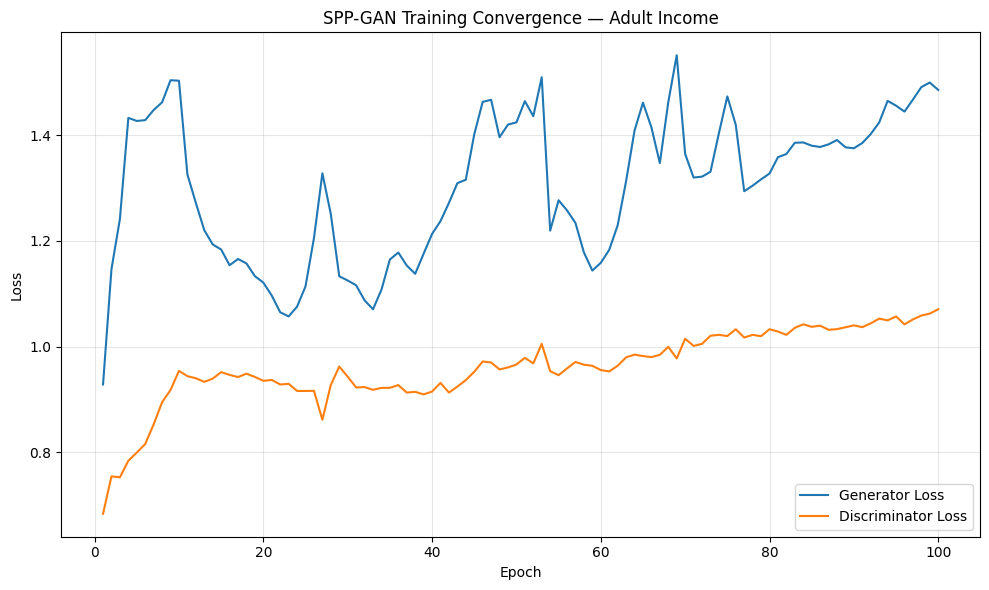

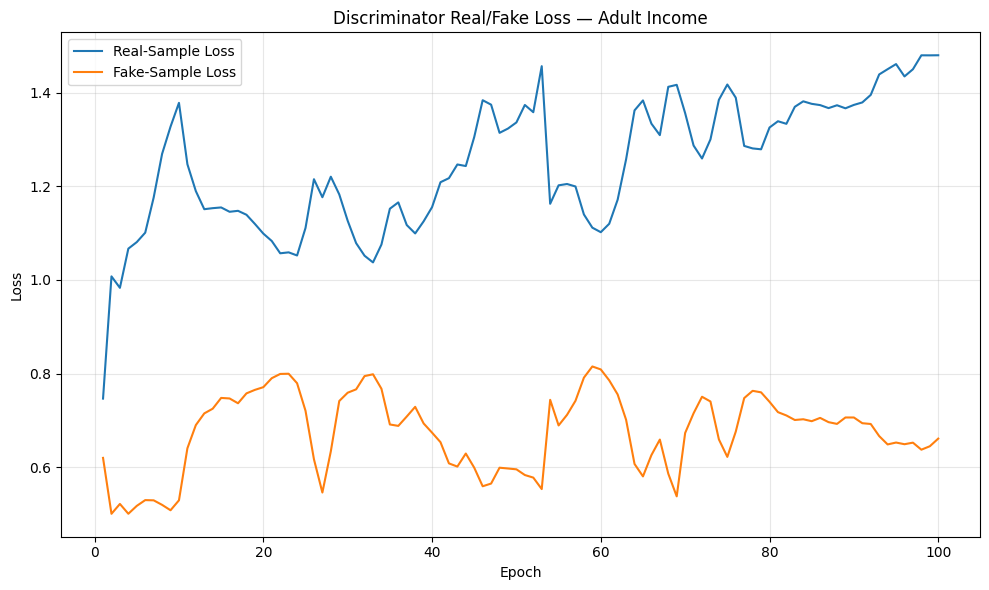

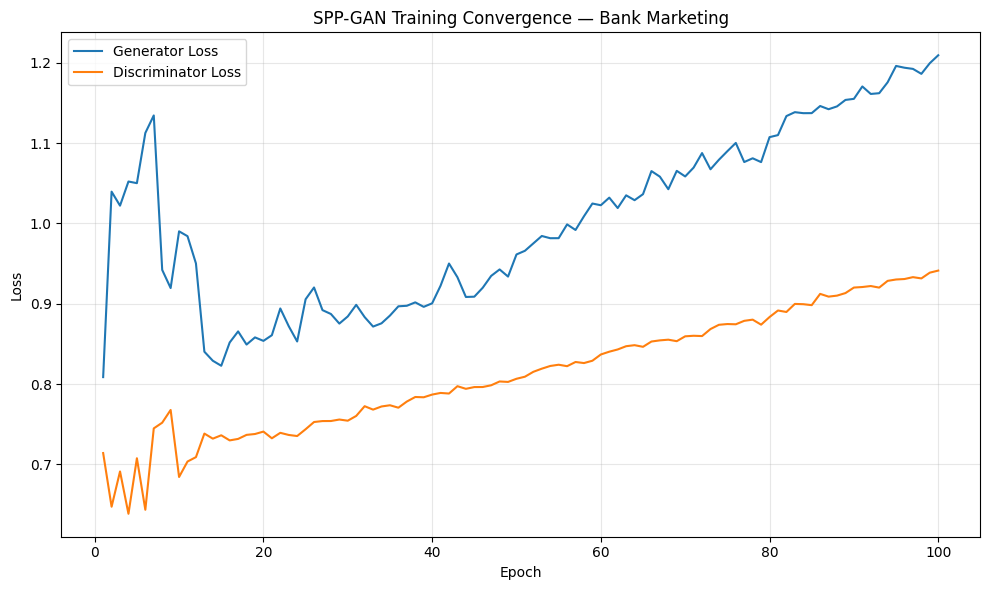

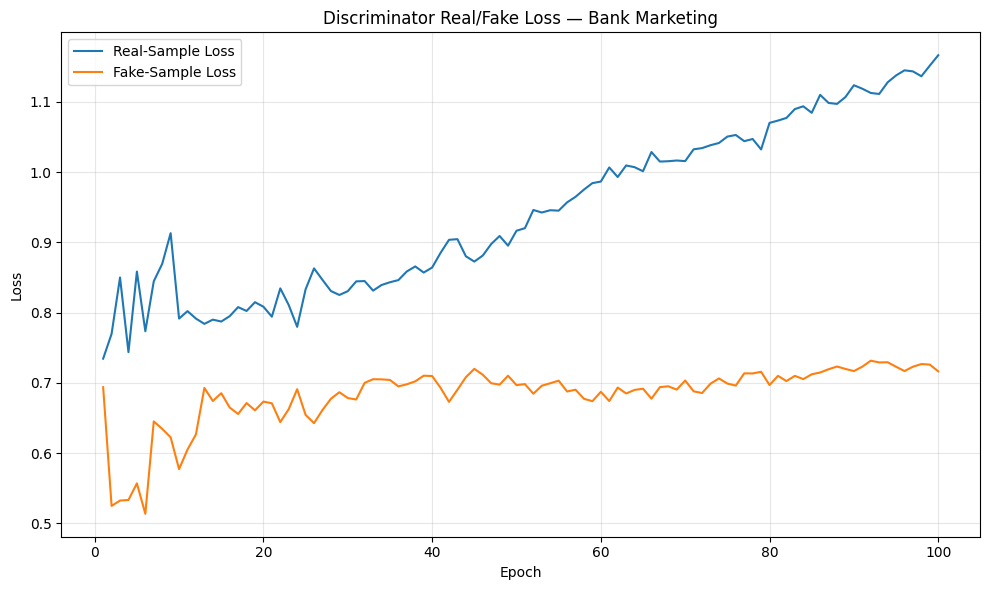

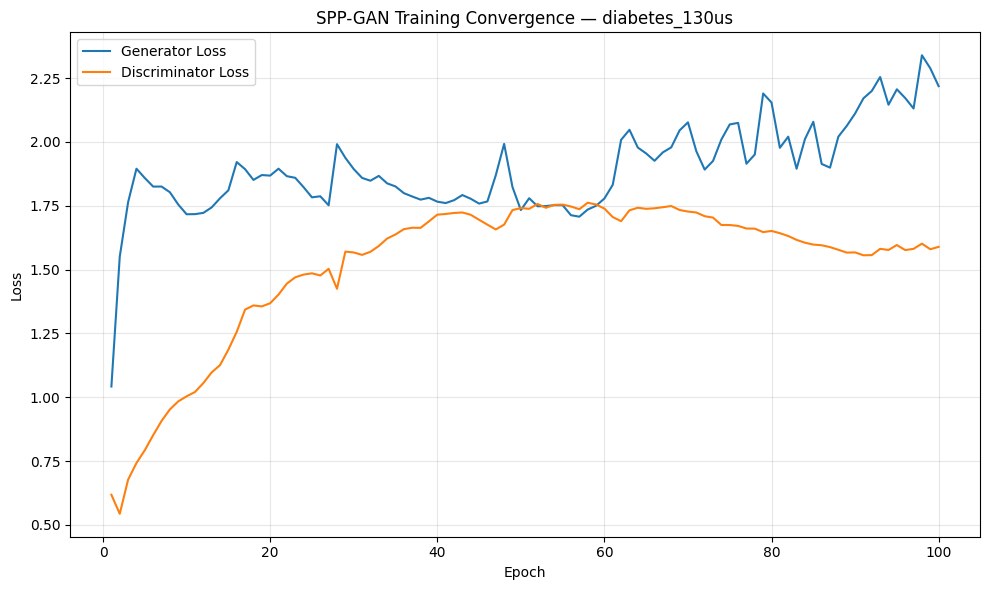

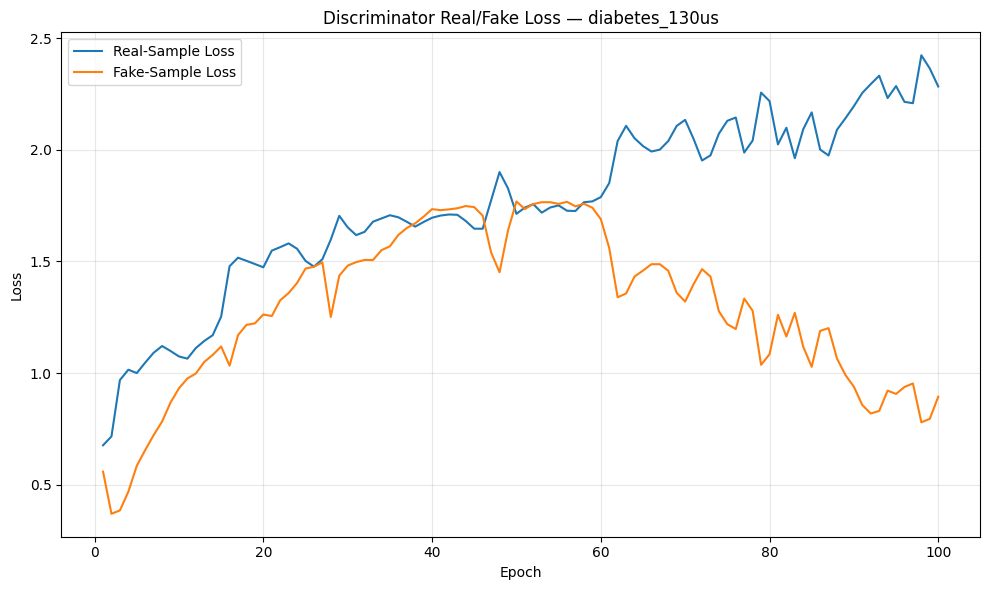


Training convergence plots saved to: spp_gan_monitoring_plots


In [109]:
# ==============================================================================
# CELL O10 — TRAINING CONVERGENCE PLOTS
# ==============================================================================

print("=" * 100)
print("CELL O10 — TRAINING CONVERGENCE PLOTS")
print("=" * 100)

SPP_GAN_MONITORING_PLOT_DIRECTORY = (
    SPP_GAN_PLOT_DIRECTORY
    if "SPP_GAN_PLOT_DIRECTORY" in globals()
    else "spp_gan_monitoring_plots"
)

os.makedirs(
    SPP_GAN_MONITORING_PLOT_DIRECTORY,
    exist_ok=True
)

for dataset in DATASETS:

    history = SPP_GAN_TRAINING_HISTORY[dataset]

    epochs = history["epoch"]

    # --------------------------------------------------------------------------
    # LOSS CONVERGENCE
    # --------------------------------------------------------------------------

    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(
        epochs,
        history["generator_loss"],
        label="Generator Loss"
    )

    plt.plot(
        epochs,
        history["discriminator_loss"],
        label="Discriminator Loss"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )

    plt.title(
        f"SPP-GAN Training Convergence — {dataset}"
    )

    plt.legend()
    plt.grid(
        True,
        alpha=0.3
    )
    plt.tight_layout()

    convergence_path = os.path.join(
        SPP_GAN_MONITORING_PLOT_DIRECTORY,
        f"{dataset}_training_convergence.png"
    )

    plt.savefig(
        convergence_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    # --------------------------------------------------------------------------
    # REAL / FAKE DISCRIMINATOR LOSSES
    # --------------------------------------------------------------------------

    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(
        epochs,
        history["real_loss"],
        label="Real-Sample Loss"
    )

    plt.plot(
        epochs,
        history["fake_loss"],
        label="Fake-Sample Loss"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )

    plt.title(
        f"Discriminator Real/Fake Loss — {dataset}"
    )

    plt.legend()
    plt.grid(
        True,
        alpha=0.3
    )
    plt.tight_layout()

    real_fake_path = os.path.join(
        SPP_GAN_MONITORING_PLOT_DIRECTORY,
        f"{dataset}_real_fake_loss.png"
    )

    plt.savefig(
        real_fake_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

print()
print(
    f"Training convergence plots saved to: "
    f"{SPP_GAN_MONITORING_PLOT_DIRECTORY}"
)

CELL O11 — GRADIENT MONITORING PLOTS


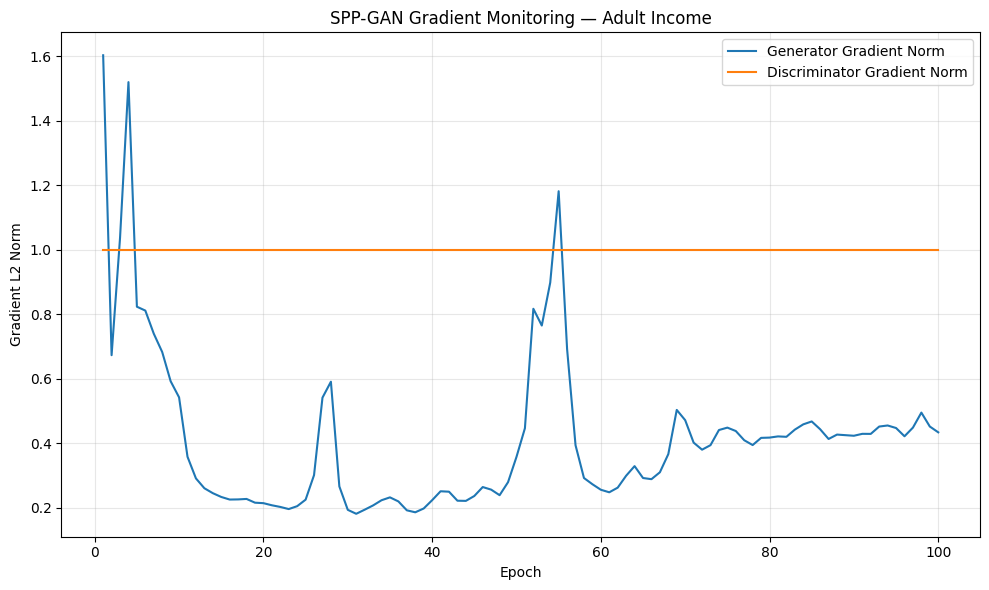

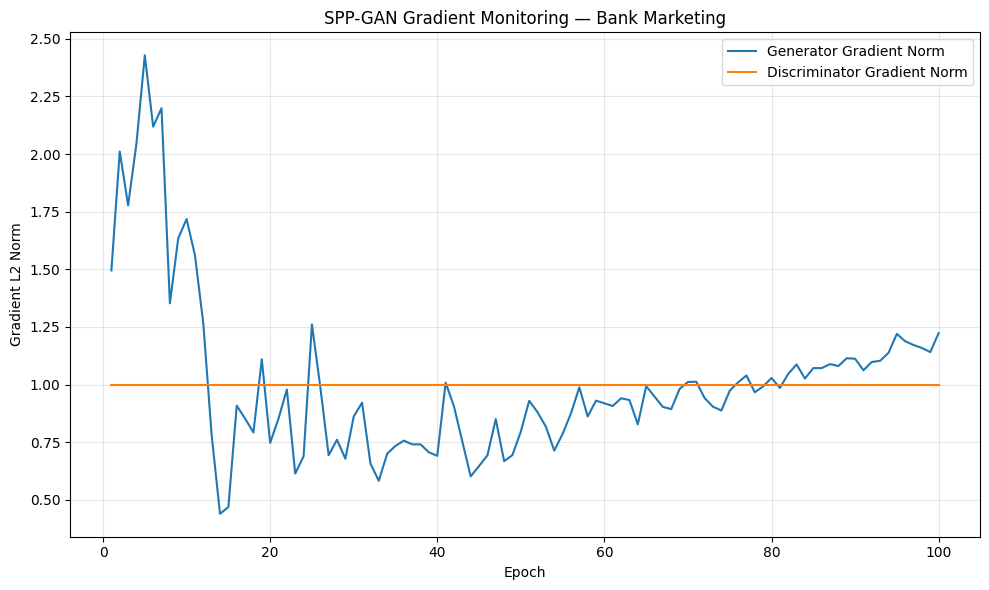

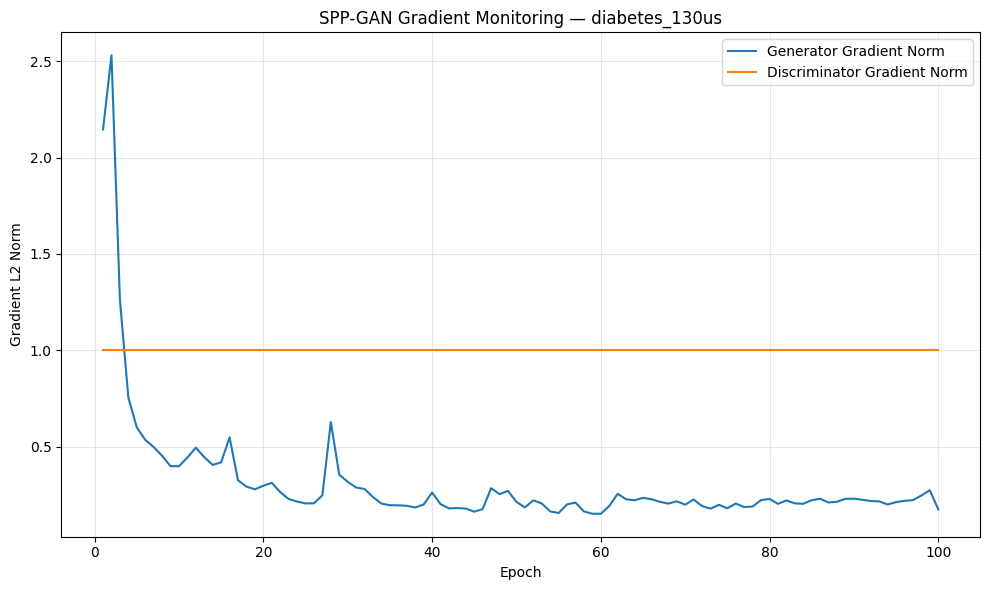


Gradient monitoring plots generated.


In [110]:
# ==============================================================================
# CELL O11 — GRADIENT MONITORING PLOTS
# ==============================================================================

print("=" * 100)
print("CELL O11 — GRADIENT MONITORING PLOTS")
print("=" * 100)

for dataset in DATASETS:

    gradient_history = (
        SPP_GAN_GRADIENT_HISTORY[dataset]
    )

    epochs = (
        SPP_GAN_TRAINING_HISTORY[dataset]["epoch"]
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(
        epochs,
        gradient_history["generator"],
        label="Generator Gradient Norm"
    )

    plt.plot(
        epochs,
        gradient_history["discriminator"],
        label="Discriminator Gradient Norm"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Gradient L2 Norm"
    )

    plt.title(
        f"SPP-GAN Gradient Monitoring — {dataset}"
    )

    plt.legend()
    plt.grid(
        True,
        alpha=0.3
    )
    plt.tight_layout()

    gradient_path = os.path.join(
        SPP_GAN_MONITORING_PLOT_DIRECTORY,
        f"{dataset}_gradient_monitoring.png"
    )

    plt.savefig(
        gradient_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

print()
print("Gradient monitoring plots generated.")

CELL O12 — DIFFERENTIAL PRIVACY MONITORING PLOTS


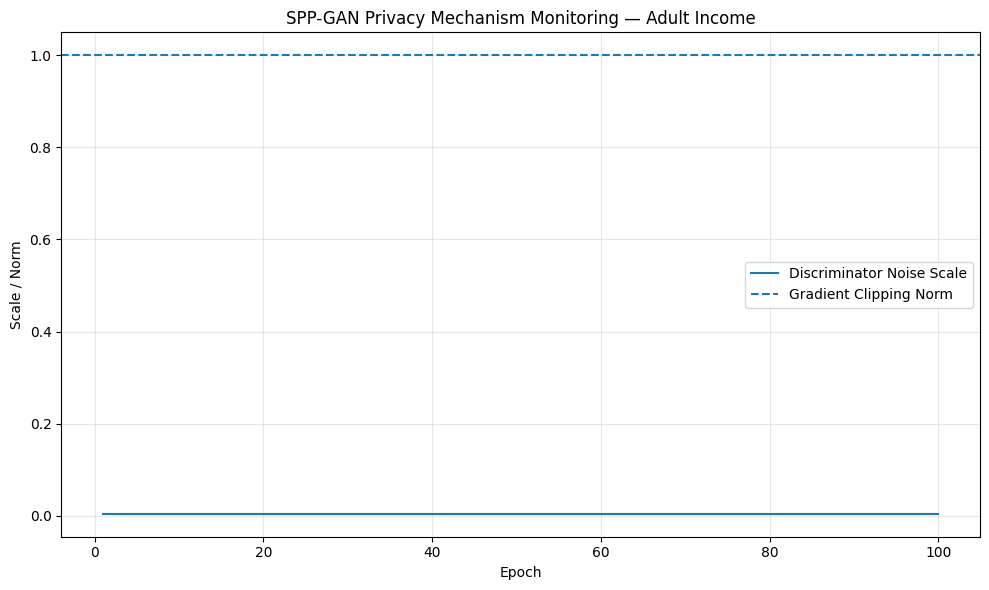

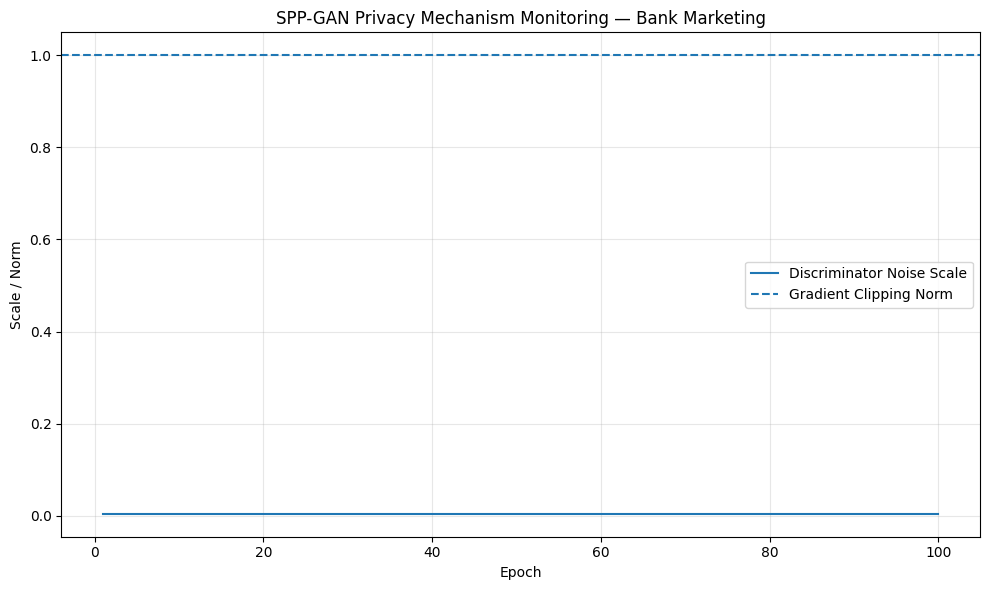

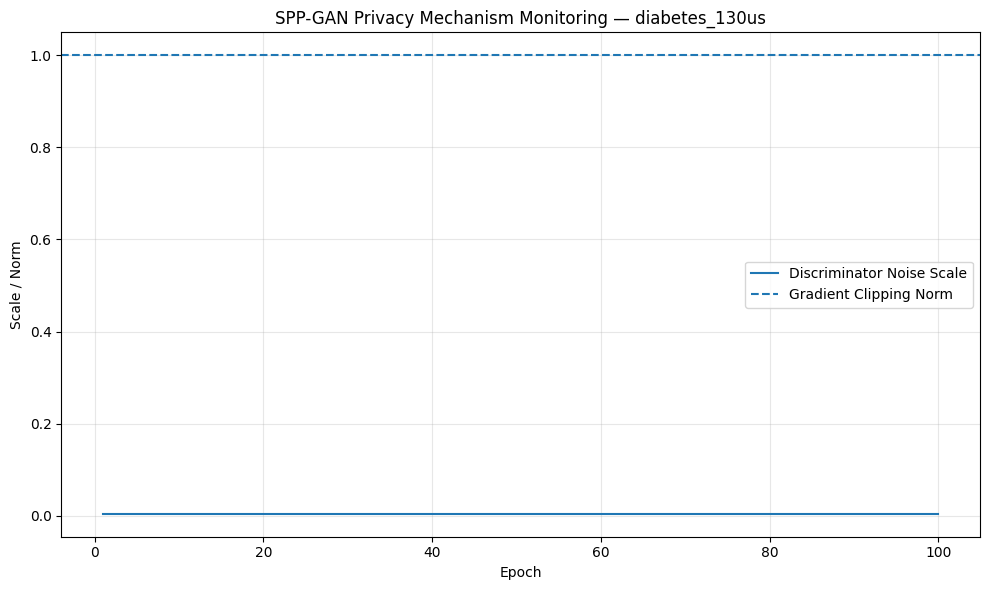


Differential privacy monitoring plots generated.


In [111]:
# ==============================================================================
# CELL O12 — DIFFERENTIAL PRIVACY MONITORING PLOTS
# ==============================================================================

print("=" * 100)
print("CELL O12 — DIFFERENTIAL PRIVACY MONITORING PLOTS")
print("=" * 100)

for dataset in DATASETS:

    privacy_history = (
        SPP_GAN_PRIVACY_TRAINING_HISTORY[dataset]
    )

    epochs = privacy_history["epoch"]

    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(
        epochs,
        privacy_history["discriminator_noise_scale"],
        label="Discriminator Noise Scale"
    )

    plt.axhline(
        y=float(
            SPP_GAN_PRIVACY_CLIPPING_NORM
        ),
        linestyle="--",
        label="Gradient Clipping Norm"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Scale / Norm"
    )

    plt.title(
        f"SPP-GAN Privacy Mechanism Monitoring — {dataset}"
    )

    plt.legend()
    plt.grid(
        True,
        alpha=0.3
    )
    plt.tight_layout()

    privacy_path = os.path.join(
        SPP_GAN_MONITORING_PLOT_DIRECTORY,
        f"{dataset}_privacy_monitoring.png"
    )

    plt.savefig(
        privacy_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

print()
print("Differential privacy monitoring plots generated.")

In [112]:
# ==============================================================================
# CELL O13 — NUMERICAL STABILITY VERIFICATION
# ==============================================================================

print("=" * 100)
print("CELL O13 — NUMERICAL STABILITY VERIFICATION")
print("=" * 100)

SPP_GAN_NUMERICAL_STABILITY = {}

for dataset in DATASETS:

    history = SPP_GAN_TRAINING_HISTORY[dataset]

    arrays_to_check = {
        "Generator Loss": history["generator_loss"],
        "Discriminator Loss": history["discriminator_loss"],
        "Real Loss": history["real_loss"],
        "Fake Loss": history["fake_loss"],
        "Generator Gradient": history[
            "gradient_norm_generator"
        ],
        "Discriminator Gradient": history[
            "gradient_norm_discriminator"
        ]
    }

    dataset_pass = True

    for metric_name, values in arrays_to_check.items():

        values_array = np.asarray(
            values,
            dtype=np.float64
        )

        metric_pass = bool(
            np.isfinite(
                values_array
            ).all()
        )

        if not metric_pass:
            dataset_pass = False

        print(
            f"{dataset:20s} | "
            f"{metric_name:25s} | "
            f"{'PASS' if metric_pass else 'FAIL'}"
        )

    privacy_history = (
        SPP_GAN_PRIVACY_TRAINING_HISTORY[dataset]
    )

    privacy_values = np.concatenate(
        [
            np.asarray(
                privacy_history[
                    "gradient_clip_norm"
                ],
                dtype=np.float64
            ),
            np.asarray(
                privacy_history[
                    "generator_noise_scale"
                ],
                dtype=np.float64
            ),
            np.asarray(
                privacy_history[
                    "discriminator_noise_scale"
                ],
                dtype=np.float64
            )
        ]
    )

    privacy_pass = bool(
        np.isfinite(
            privacy_values
        ).all()
    )

    if not privacy_pass:
        dataset_pass = False

    print(
        f"{dataset:20s} | "
        f"{'Privacy Metrics':25s} | "
        f"{'PASS' if privacy_pass else 'FAIL'}"
    )

    SPP_GAN_NUMERICAL_STABILITY[dataset] = (
        "PASS"
        if dataset_pass
        else "FAIL"
    )

print()

for dataset in DATASETS:

    print(
        f"{dataset:20s} : "
        f"{SPP_GAN_NUMERICAL_STABILITY[dataset]}"
    )

if not all(
    status == "PASS"
    for status
    in SPP_GAN_NUMERICAL_STABILITY.values()
):

    raise FloatingPointError(
        "SPP-GAN numerical stability verification failed."
    )

print()
print("NUMERICAL STABILITY VERIFICATION : PASS")

CELL O13 — NUMERICAL STABILITY VERIFICATION
Adult Income         | Generator Loss            | PASS
Adult Income         | Discriminator Loss        | PASS
Adult Income         | Real Loss                 | PASS
Adult Income         | Fake Loss                 | PASS
Adult Income         | Generator Gradient        | PASS
Adult Income         | Discriminator Gradient    | PASS
Adult Income         | Privacy Metrics           | PASS
Bank Marketing       | Generator Loss            | PASS
Bank Marketing       | Discriminator Loss        | PASS
Bank Marketing       | Real Loss                 | PASS
Bank Marketing       | Fake Loss                 | PASS
Bank Marketing       | Generator Gradient        | PASS
Bank Marketing       | Discriminator Gradient    | PASS
Bank Marketing       | Privacy Metrics           | PASS
diabetes_130us       | Generator Loss            | PASS
diabetes_130us       | Discriminator Loss        | PASS
diabetes_130us       | Real Loss                 | PASS
diab

In [113]:
# ==============================================================================
# CELL O14 — FINAL TRAINING MONITORING REPORT
# ==============================================================================

print("=" * 100)
print("CELL O14 — FINAL TRAINING MONITORING REPORT")
print("=" * 100)

SPP_GAN_FINAL_MONITORING_REPORT = []

for dataset in DATASETS:

    training_status = (
        SPP_GAN_TRAINING_STATUS.get(
            dataset,
            "UNKNOWN"
        )
    )

    history = (
        SPP_GAN_TRAINING_HISTORY[dataset]
    )

    privacy_history = (
        SPP_GAN_PRIVACY_TRAINING_HISTORY[dataset]
    )

    gradient_history = (
        SPP_GAN_GRADIENT_HISTORY[dataset]
    )

    recorded_epochs = len(
        history["epoch"]
    )

    final_generator_loss = float(
        history["generator_loss"][-1]
    )

    final_discriminator_loss = float(
        history["discriminator_loss"][-1]
    )

    final_generator_gradient = float(
        gradient_history["generator"][-1]
    )

    final_discriminator_gradient = float(
        gradient_history["discriminator"][-1]
    )

    final_discriminator_noise = float(
        privacy_history[
            "discriminator_noise_scale"
        ][-1]
    )

    clipping_norm = float(
        privacy_history[
            "gradient_clip_norm"
        ][-1]
    )

    numerical_status = (
        SPP_GAN_NUMERICAL_STABILITY[dataset]
    )

    monitoring_status = (
        "PASS"
        if (
            training_status == "COMPLETED"
            and
            recorded_epochs == SPP_GAN_EPOCHS
            and
            numerical_status == "PASS"
        )
        else "CHECK"
    )

    SPP_GAN_FINAL_MONITORING_REPORT.append(
        {
            "Dataset": dataset,
            "Training Status": training_status,
            "Recorded Epochs": recorded_epochs,
            "Final Generator Loss": final_generator_loss,
            "Final Discriminator Loss": final_discriminator_loss,
            "Final Generator Gradient": final_generator_gradient,
            "Final Discriminator Gradient": final_discriminator_gradient,
            "DP Gradient Clip Norm": clipping_norm,
            "Final DP Discriminator Noise": final_discriminator_noise,
            "Numerical Stability": numerical_status,
            "Monitoring Status": monitoring_status
        }
    )

SPP_GAN_FINAL_MONITORING_REPORT = pd.DataFrame(
    SPP_GAN_FINAL_MONITORING_REPORT
)

print(
    SPP_GAN_FINAL_MONITORING_REPORT.to_string(
        index=False
    )
)

print()
print(
    "SPP-GAN final monitoring report generated."
)

CELL O14 — FINAL TRAINING MONITORING REPORT
       Dataset Training Status  Recorded Epochs  Final Generator Loss  Final Discriminator Loss  Final Generator Gradient  Final Discriminator Gradient  DP Gradient Clip Norm  Final DP Discriminator Noise Numerical Stability Monitoring Status
  Adult Income       COMPLETED              100              1.485649                  1.070519                  0.434237                           1.0                    1.0                      0.004302                PASS              PASS
Bank Marketing       COMPLETED              100              1.209352                  0.941287                  1.223431                           1.0                    1.0                      0.004318                PASS              PASS
diabetes_130us       COMPLETED              100              2.218522                  1.589105                  0.174309                           1.0                    1.0                      0.004339                PASS   

In [114]:
# ==============================================================================
# CELL O15 — SAVE TRAINING MONITORING REPORTS
# ==============================================================================

print("=" * 100)
print("CELL O15 — SAVE TRAINING MONITORING REPORTS")
print("=" * 100)

SPP_GAN_MONITORING_REPORT_DIRECTORY = (
    SPP_GAN_REPORT_DIRECTORY
    if "SPP_GAN_REPORT_DIRECTORY" in globals()
    else "spp_gan_monitoring_reports"
)

os.makedirs(
    SPP_GAN_MONITORING_REPORT_DIRECTORY,
    exist_ok=True
)

SPP_GAN_CONVERGENCE_SUMMARY.to_csv(
    os.path.join(
        SPP_GAN_MONITORING_REPORT_DIRECTORY,
        "spp_gan_convergence_summary.csv"
    ),
    index=False
)

SPP_GAN_GRADIENT_SUMMARY.to_csv(
    os.path.join(
        SPP_GAN_MONITORING_REPORT_DIRECTORY,
        "spp_gan_gradient_summary.csv"
    ),
    index=False
)

SPP_GAN_PRIVACY_MONITORING_SUMMARY.to_csv(
    os.path.join(
        SPP_GAN_MONITORING_REPORT_DIRECTORY,
        "spp_gan_privacy_monitoring_summary.csv"
    ),
    index=False
)

SPP_GAN_STABILITY_SUMMARY.to_csv(
    os.path.join(
        SPP_GAN_MONITORING_REPORT_DIRECTORY,
        "spp_gan_training_stability_summary.csv"
    ),
    index=False
)

SPP_GAN_TRAINING_STATUS_SUMMARY.to_csv(
    os.path.join(
        SPP_GAN_MONITORING_REPORT_DIRECTORY,
        "spp_gan_training_status_summary.csv"
    ),
    index=False
)

SPP_GAN_FINAL_MONITORING_REPORT.to_csv(
    os.path.join(
        SPP_GAN_MONITORING_REPORT_DIRECTORY,
        "spp_gan_final_monitoring_report.csv"
    ),
    index=False
)

print()
print(
    "Saved monitoring reports:"
)

for filename in sorted(
    os.listdir(
        SPP_GAN_MONITORING_REPORT_DIRECTORY
    )
):

    print(
        f"  - {filename}"
    )

print()
print(
    f"Report directory: "
    f"{SPP_GAN_MONITORING_REPORT_DIRECTORY}"
)

CELL O15 — SAVE TRAINING MONITORING REPORTS

Saved monitoring reports:
  - spp_gan_convergence_summary.csv
  - spp_gan_final_monitoring_report.csv
  - spp_gan_gradient_summary.csv
  - spp_gan_privacy_monitoring_summary.csv
  - spp_gan_training_stability_summary.csv
  - spp_gan_training_status_summary.csv

Report directory: spp_gan_monitoring_reports


In [115]:
# ==============================================================================
# CELL O16 — PART O FINAL VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART O — SPP-GAN TRAINING MONITORING FINAL VERIFICATION")
print("=" * 100)

PART_O_CHECKS = {
    "Training History Validation":
        SPP_GAN_MONITORING_HISTORY_VALID,

    "Privacy History Validation":
        SPP_GAN_PRIVACY_HISTORY_VALID,

    "Gradient History Validation":
        SPP_GAN_GRADIENT_HISTORY_VALID,

    "Numerical Stability":
        all(
            status == "PASS"
            for status
            in SPP_GAN_NUMERICAL_STABILITY.values()
        ),

    "Final Monitoring Report":
        isinstance(
            SPP_GAN_FINAL_MONITORING_REPORT,
            pd.DataFrame
        ),

    "Monitoring Reports Saved":
        os.path.isdir(
            SPP_GAN_MONITORING_REPORT_DIRECTORY
        )
}

for check_name, check_result in PART_O_CHECKS.items():

    print(
        f"{check_name:35s} : "
        f"{'PASS' if check_result else 'FAIL'}"
    )

if not all(
    PART_O_CHECKS.values()
):

    raise RuntimeError(
        "PART O final verification failed."
    )

for dataset in DATASETS:

    SPP_GAN_MONITORING_STATUS[dataset] = "COMPLETED"

print()
print(
    "PART O — SPP-GAN TRAINING MONITORING : PASS"
)

print()
print(
    "All configured datasets have completed "
    "SPP-GAN training monitoring."
)

PART O — SPP-GAN TRAINING MONITORING FINAL VERIFICATION
Training History Validation         : PASS
Privacy History Validation          : PASS
Gradient History Validation         : PASS
Numerical Stability                 : PASS
Final Monitoring Report             : PASS
Monitoring Reports Saved            : PASS

PART O — SPP-GAN TRAINING MONITORING : PASS

All configured datasets have completed SPP-GAN training monitoring.


In [116]:
# ==============================================================================
# PART P1 — SYNTHETIC GENERATION CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART P1 — SYNTHETIC GENERATION CONFIGURATION")
print("=" * 100)

SPP_GAN_SYNTHETIC_BATCH_SIZE = 1024

SPP_GAN_SYNTHETIC_SAMPLE_MULTIPLIER = 1.0

SPP_GAN_SYNTHETIC_DATASETS = {}

SPP_GAN_SYNTHETIC_TENSORS = {}

SPP_GAN_SYNTHETIC_GENERATION_STATISTICS = {}

SPP_GAN_SYNTHETIC_GENERATION_STATUS = {}

print()
print(
    "Synthetic batch size        :",
    SPP_GAN_SYNTHETIC_BATCH_SIZE
)

print(
    "Synthetic sample multiplier :",
    SPP_GAN_SYNTHETIC_SAMPLE_MULTIPLIER
)

print(
    "Latent dimension            :",
    SPP_GAN_GENERATOR_INPUT_DIMENSION
)

print(
    "Device                      :",
    SPP_GAN_DEVICE
)

print()
print("Synthetic generation configuration completed.")

PART P1 — SYNTHETIC GENERATION CONFIGURATION

Synthetic batch size        : 1024
Synthetic sample multiplier : 1.0
Latent dimension            : 128
Device                      : cuda

Synthetic generation configuration completed.


In [155]:
# ==============================================================================
# PART P2 — SYNTHETIC GENERATION DEPENDENCY VALIDATION
# ==============================================================================

print("=" * 100)
print("PART P2 — SYNTHETIC GENERATION DEPENDENCY VALIDATION")
print("=" * 100)

required_objects = {
    "DATASETS": DATASETS,
    "SPP_GAN_GENERATORS": SPP_GAN_GENERATORS,
    "SPP_GAN_TRAIN_TENSORS": SPP_GAN_TRAIN_TENSORS,
    "SPP_GAN_INPUT_DIMENSIONS": SPP_GAN_INPUT_DIMENSIONS,
    "SPP_GAN_OUTPUT_DIMENSIONS": SPP_GAN_OUTPUT_DIMENSIONS,
    "SPP_GAN_GENERATOR_INPUT_DIMENSION": SPP_GAN_GENERATOR_INPUT_DIMENSION,
    "SPP_GAN_DEVICE": SPP_GAN_DEVICE
}

for object_name, object_value in required_objects.items():

    if object_value is None:
        raise RuntimeError(
            f"Required object '{object_name}' is None."
        )

print()

for dataset in DATASETS:

    if dataset not in SPP_GAN_GENERATORS:
        raise KeyError(
            f"SPP_GAN generator is missing for dataset: {dataset}"
        )

    if dataset not in SPP_GAN_TRAIN_TENSORS:
        raise KeyError(
            f"Training tensor is missing for dataset: {dataset}"
        )

    if dataset not in SPP_GAN_INPUT_DIMENSIONS:
        raise KeyError(
            f"Input dimension is missing for dataset: {dataset}"
        )

    if dataset not in SPP_GAN_OUTPUT_DIMENSIONS:
        raise KeyError(
            f"Output dimension is missing for dataset: {dataset}"
        )

    print(
        f"{dataset:20s} : dependencies verified"
    )

print()
print(
    "SYNTHETIC GENERATION DEPENDENCY VALIDATION : PASS"
)

PART P2 — SYNTHETIC GENERATION DEPENDENCY VALIDATION

Adult Income         : dependencies verified
Bank Marketing       : dependencies verified
diabetes_130us       : dependencies verified

SYNTHETIC GENERATION DEPENDENCY VALIDATION : PASS


In [156]:
# ==============================================================================
# PART P3 — SYNTHETIC SAMPLE SIZE DETERMINATION
# ==============================================================================

print("=" * 100)
print("PART P3 — SYNTHETIC SAMPLE SIZE DETERMINATION")
print("=" * 100)

SPP_GAN_SYNTHETIC_SAMPLE_COUNTS = {}

for dataset in DATASETS:

    training_tensor = SPP_GAN_TRAIN_TENSORS[dataset]

    if not isinstance(
        training_tensor,
        torch.Tensor
    ):
        raise TypeError(
            f"{dataset}: Training data must be a torch.Tensor."
        )

    training_sample_count = int(
        training_tensor.shape[0]
    )

    if training_sample_count <= 0:
        raise ValueError(
            f"{dataset}: Training sample count must be greater than zero."
        )

    synthetic_sample_count = int(
        round(
            training_sample_count
            *
            SPP_GAN_SYNTHETIC_SAMPLE_MULTIPLIER
        )
    )

    if synthetic_sample_count <= 0:
        raise ValueError(
            f"{dataset}: Synthetic sample count must be greater than zero."
        )

    SPP_GAN_SYNTHETIC_SAMPLE_COUNTS[dataset] = (
        synthetic_sample_count
    )

    print(
        f"{dataset:20s} | "
        f"Training Samples: {training_sample_count:8d} | "
        f"Synthetic Samples: {synthetic_sample_count:8d}"
    )

print()
print(
    "Synthetic sample sizes determined successfully."
)

PART P3 — SYNTHETIC SAMPLE SIZE DETERMINATION
Adult Income         | Training Samples:    22760 | Synthetic Samples:    22760
Bank Marketing       | Training Samples:    31647 | Synthetic Samples:    31647
diabetes_130us       | Training Samples:    71236 | Synthetic Samples:    71236

Synthetic sample sizes determined successfully.


In [157]:
# ==============================================================================
# PART P4 — SPP-GAN SYNTHETIC DATA GENERATION FUNCTION
# ==============================================================================

print("=" * 100)
print("PART P4 — SPP-GAN SYNTHETIC DATA GENERATION FUNCTION")
print("=" * 100)

def spp_gan_generate_synthetic_tensor(
    generator,
    num_samples,
    latent_dimension,
    output_dimension,
    device,
    batch_size=1024
):
    """
    Generate synthetic tabular data using a trained SPP-GAN generator.

    The generated data remains in the normalized/encoded feature space
    established by the preprocessing pipeline.

    Parameters
    ----------
    generator : torch.nn.Module
        Trained SPP-GAN generator.

    num_samples : int
        Number of synthetic records to generate.

    latent_dimension : int
        Generator latent input dimension.

    output_dimension : int
        Expected generator output dimension.

    device : torch.device
        Computation device.

    batch_size : int
        Number of synthetic records generated per batch.

    Returns
    -------
    torch.Tensor
        Synthetic data tensor of shape
        (num_samples, output_dimension).
    """

    if not isinstance(
        num_samples,
        int
    ):
        raise TypeError(
            "num_samples must be an integer."
        )

    if num_samples <= 0:
        raise ValueError(
            "num_samples must be greater than zero."
        )

    if not isinstance(
        latent_dimension,
        int
    ):
        raise TypeError(
            "latent_dimension must be an integer."
        )

    if latent_dimension <= 0:
        raise ValueError(
            "latent_dimension must be greater than zero."
        )

    if not isinstance(
        output_dimension,
        int
    ):
        raise TypeError(
            "output_dimension must be an integer."
        )

    if output_dimension <= 0:
        raise ValueError(
            "output_dimension must be greater than zero."
        )

    if not isinstance(
        batch_size,
        int
    ):
        raise TypeError(
            "batch_size must be an integer."
        )

    if batch_size <= 0:
        raise ValueError(
            "batch_size must be greater than zero."
        )

    generator.eval()

    generated_batches = []

    remaining_samples = num_samples

    with torch.no_grad():

        while remaining_samples > 0:

            current_batch_size = min(
                batch_size,
                remaining_samples
            )

            latent_noise = torch.randn(
                current_batch_size,
                latent_dimension,
                device=device,
                dtype=torch.float32
            )

            generated_batch = generator(
                latent_noise
            )

            if generated_batch.ndim != 2:

                raise ValueError(
                    "Generator output must be 2-dimensional. "
                    f"Received shape: "
                    f"{tuple(generated_batch.shape)}."
                )

            if generated_batch.shape[1] != output_dimension:

                raise ValueError(
                    "Generator output dimension mismatch. "
                    f"Expected {output_dimension}, "
                    f"got {generated_batch.shape[1]}."
                )

            if not torch.isfinite(
                generated_batch
            ).all().item():

                raise FloatingPointError(
                    "Generator produced NaN or Inf values."
                )

            generated_batches.append(
                generated_batch.detach().cpu()
            )

            remaining_samples -= current_batch_size

    synthetic_tensor = torch.cat(
        generated_batches,
        dim=0
    )

    if synthetic_tensor.shape != (
        num_samples,
        output_dimension
    ):

        raise RuntimeError(
            "Final synthetic tensor shape mismatch. "
            f"Expected "
            f"{(num_samples, output_dimension)}, "
            f"got "
            f"{tuple(synthetic_tensor.shape)}."
        )

    if not torch.isfinite(
        synthetic_tensor
    ).all().item():

        raise FloatingPointError(
            "Final synthetic tensor contains NaN or Inf values."
        )

    return synthetic_tensor


print()
print(
    "SPP-GAN synthetic generation function defined successfully."
)

PART P4 — SPP-GAN SYNTHETIC DATA GENERATION FUNCTION

SPP-GAN synthetic generation function defined successfully.


In [158]:
# ==============================================================================
# PART P5 — SYNTHETIC GENERATION FUNCTION VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART P5 — SYNTHETIC GENERATION FUNCTION VERIFICATION")
print("=" * 100)

if not callable(
    spp_gan_generate_synthetic_tensor
):

    raise NameError(
        "SPP-GAN synthetic generation function is not defined."
    )

print()
print(
    "Generation function : PASS"
)

print(
    "Batch generation    : ENABLED"
)

print(
    "Finite-value checks : ENABLED"
)

print(
    "Dimension checks    : ENABLED"
)

print(
    "Evaluation mode     : ENABLED"
)

print(
    "Gradient tracking   : DISABLED"
)

print()
print(
    "SYNTHETIC GENERATION FUNCTION VERIFICATION : PASS"
)

PART P5 — SYNTHETIC GENERATION FUNCTION VERIFICATION

Generation function : PASS
Batch generation    : ENABLED
Finite-value checks : ENABLED
Dimension checks    : ENABLED
Evaluation mode     : ENABLED
Gradient tracking   : DISABLED

SYNTHETIC GENERATION FUNCTION VERIFICATION : PASS


In [159]:
# ==============================================================================
# PART P6 — SPP-GAN SYNTHETIC DATA GENERATION
# ==============================================================================

print("=" * 100)
print("PART P6 — SPP-GAN SYNTHETIC DATA GENERATION")
print("=" * 100)

for dataset in DATASETS:

    print()
    print("-" * 100)
    print(
        f"Generating Synthetic Data : {dataset}"
    )
    print("-" * 100)

    generator = SPP_GAN_GENERATORS[dataset]

    synthetic_sample_count = (
        SPP_GAN_SYNTHETIC_SAMPLE_COUNTS[dataset]
    )

    output_dimension = (
        SPP_GAN_OUTPUT_DIMENSIONS[dataset]
    )

    try:

        synthetic_tensor = (
            spp_gan_generate_synthetic_tensor(
                generator=generator,
                num_samples=synthetic_sample_count,
                latent_dimension=(
                    SPP_GAN_GENERATOR_INPUT_DIMENSION
                ),
                output_dimension=output_dimension,
                device=SPP_GAN_DEVICE,
                batch_size=(
                    SPP_GAN_SYNTHETIC_BATCH_SIZE
                )
            )
        )

        SPP_GAN_SYNTHETIC_TENSORS[dataset] = (
            synthetic_tensor
        )

        SPP_GAN_SYNTHETIC_GENERATION_STATUS[
            dataset
        ] = "COMPLETED"

        print(
            f"Synthetic samples : "
            f"{synthetic_tensor.shape[0]:,}"
        )

        print(
            f"Synthetic features: "
            f"{synthetic_tensor.shape[1]:,}"
        )

        print(
            f"Tensor shape      : "
            f"{tuple(synthetic_tensor.shape)}"
        )

        print(
            f"Data type         : "
            f"{synthetic_tensor.dtype}"
        )

        print(
            f"Device            : "
            f"{synthetic_tensor.device}"
        )

    except Exception as error:

        SPP_GAN_SYNTHETIC_GENERATION_STATUS[
            dataset
        ] = "FAILED"

        raise RuntimeError(
            f"Synthetic data generation failed for "
            f"{dataset}: {error}"
        ) from error

print()
print(
    "SPP-GAN synthetic data generation completed."
)

PART P6 — SPP-GAN SYNTHETIC DATA GENERATION

----------------------------------------------------------------------------------------------------
Generating Synthetic Data : Adult Income
----------------------------------------------------------------------------------------------------
Synthetic samples : 22,760
Synthetic features: 14
Tensor shape      : (22760, 14)
Data type         : torch.float32
Device            : cpu

----------------------------------------------------------------------------------------------------
Generating Synthetic Data : Bank Marketing
----------------------------------------------------------------------------------------------------
Synthetic samples : 31,647
Synthetic features: 16
Tensor shape      : (31647, 16)
Data type         : torch.float32
Device            : cpu

----------------------------------------------------------------------------------------------------
Generating Synthetic Data : diabetes_130us
-----------------------------------------

In [160]:
# ==============================================================================
# PART P7 — SYNTHETIC TENSOR VALIDATION
# ==============================================================================

print("=" * 100)
print("PART P7 — SYNTHETIC TENSOR VALIDATION")
print("=" * 100)

for dataset in DATASETS:

    synthetic_tensor = (
        SPP_GAN_SYNTHETIC_TENSORS[dataset]
    )

    expected_rows = (
        SPP_GAN_SYNTHETIC_SAMPLE_COUNTS[dataset]
    )

    expected_columns = (
        SPP_GAN_OUTPUT_DIMENSIONS[dataset]
    )

    if not isinstance(
        synthetic_tensor,
        torch.Tensor
    ):

        raise TypeError(
            f"{dataset}: Synthetic output must be a torch.Tensor."
        )

    if synthetic_tensor.ndim != 2:

        raise ValueError(
            f"{dataset}: Synthetic tensor must be 2-dimensional."
        )

    if synthetic_tensor.shape[0] != expected_rows:

        raise ValueError(
            f"{dataset}: Synthetic row count mismatch. "
            f"Expected {expected_rows}, "
            f"got {synthetic_tensor.shape[0]}."
        )

    if synthetic_tensor.shape[1] != expected_columns:

        raise ValueError(
            f"{dataset}: Synthetic column count mismatch. "
            f"Expected {expected_columns}, "
            f"got {synthetic_tensor.shape[1]}."
        )

    if not torch.isfinite(
        synthetic_tensor
    ).all().item():

        raise FloatingPointError(
            f"{dataset}: Synthetic tensor contains NaN or Inf values."
        )

    print(
        f"{dataset:20s} : PASS | "
        f"Shape = {tuple(synthetic_tensor.shape)} | "
        f"Finite = True"
    )

print()
print(
    "SYNTHETIC TENSOR VALIDATION : PASS"
)

PART P7 — SYNTHETIC TENSOR VALIDATION
Adult Income         : PASS | Shape = (22760, 14) | Finite = True
Bank Marketing       : PASS | Shape = (31647, 16) | Finite = True
diabetes_130us       : PASS | Shape = (71236, 47) | Finite = True

SYNTHETIC TENSOR VALIDATION : PASS


In [177]:
# ==============================================================================
# PART P8 — CONVERT SYNTHETIC TENSORS TO DATAFRAMES
# ==============================================================================

print("=" * 100)
print("PART P8 — CONVERT SYNTHETIC TENSORS TO DATAFRAMES")
print("=" * 100)

SPP_GAN_SYNTHETIC_DATAFRAMES = {}

for dataset in DATASETS:

    print()
    print("-" * 100)
    print(f"Dataset : {dataset}")
    print("-" * 100)

    # ==========================================================================
    # RETRIEVE SYNTHETIC TENSOR
    # ==========================================================================

    synthetic_tensor = SPP_GAN_SYNTHETIC_TENSORS[dataset]

    if not isinstance(
        synthetic_tensor,
        torch.Tensor
    ):
        raise TypeError(
            f"{dataset}: Synthetic output must be a torch.Tensor."
        )

    # ==========================================================================
    # MOVE TO CPU
    # ==========================================================================

    synthetic_array = (
        synthetic_tensor
        .detach()
        .cpu()
        .numpy()
    )

    if synthetic_array.ndim != 2:

        raise ValueError(
            f"{dataset}: Synthetic output must be 2-dimensional. "
            f"Received shape: {synthetic_array.shape}."
        )

    generated_dimension = int(
        synthetic_array.shape[1]
    )

    # ==========================================================================
    # USE SPP-GAN PROCESSED FEATURE SCHEMA
    # ==========================================================================

    if dataset not in SPP_GAN_SYNTHETIC_FEATURE_COLUMNS:

        raise KeyError(
            f"{dataset}: SPP_GAN_SYNTHETIC_FEATURE_COLUMNS "
            "is unavailable."
        )

    feature_columns = list(
        SPP_GAN_SYNTHETIC_FEATURE_COLUMNS[dataset]
    )

    # ==========================================================================
    # FEATURE SCHEMA VALIDATION
    # ==========================================================================

    expected_dimension = int(
        SPP_GAN_OUTPUT_DIMENSIONS[dataset]
    )

    if len(feature_columns) != expected_dimension:

        raise ValueError(
            f"{dataset}: SPP-GAN feature schema does not match "
            f"configured output dimension. "
            f"Schema columns = {len(feature_columns)}, "
            f"Configured output = {expected_dimension}."
        )

    if len(feature_columns) != generated_dimension:

        raise ValueError(
            f"{dataset}: SPP-GAN feature-schema mismatch. "
            f"Feature columns = {len(feature_columns)}, "
            f"Generated features = {generated_dimension}. "
            f"Columns = {feature_columns}"
        )

    # ==========================================================================
    # CREATE SYNTHETIC DATAFRAME
    # ==========================================================================

    synthetic_dataframe = pd.DataFrame(
        synthetic_array,
        columns=feature_columns
    )

    # ==========================================================================
    # DATAFRAME VALIDATION
    # ==========================================================================

    if synthetic_dataframe.shape[1] != expected_dimension:

        raise ValueError(
            f"{dataset}: Synthetic DataFrame column count does not "
            "match configured output dimension."
        )

    if not np.isfinite(
        synthetic_dataframe.to_numpy(
            dtype=np.float64
        )
    ).all():

        raise FloatingPointError(
            f"{dataset}: Non-finite values detected in "
            "synthetic DataFrame."
        )

    # ==========================================================================
    # STORE
    # ==========================================================================

    SPP_GAN_SYNTHETIC_DATAFRAMES[dataset] = (
        synthetic_dataframe
    )

    # ==========================================================================
    # REPORT
    # ==========================================================================

    print(
        f"Generated rows         : "
        f"{synthetic_dataframe.shape[0]:,}"
    )

    print(
        f"Generated features     : "
        f"{synthetic_dataframe.shape[1]}"
    )

    print(
        f"Expected features      : "
        f"{expected_dimension}"
    )

    print(
        f"Feature schema         : "
        f"{'PASS' if len(feature_columns) == generated_dimension else 'FAIL'}"
    )

    print(
        f"Finite values          : "
        f"{'PASS' if np.isfinite(synthetic_array).all() else 'FAIL'}"
    )

    print(
        f"DataFrame conversion   : PASS"
    )

print()
print("=" * 100)
print("SYNTHETIC TENSORS SUCCESSFULLY CONVERTED TO DATAFRAMES")
print("=" * 100)

PART P8 — CONVERT SYNTHETIC TENSORS TO DATAFRAMES

----------------------------------------------------------------------------------------------------
Dataset : Adult Income
----------------------------------------------------------------------------------------------------
Generated rows         : 22,760
Generated features     : 14
Expected features      : 14
Feature schema         : PASS
Finite values          : PASS
DataFrame conversion   : PASS

----------------------------------------------------------------------------------------------------
Dataset : Bank Marketing
----------------------------------------------------------------------------------------------------
Generated rows         : 31,647
Generated features     : 16
Expected features      : 16
Feature schema         : PASS
Finite values          : PASS
DataFrame conversion   : PASS

----------------------------------------------------------------------------------------------------
Dataset : diabetes_130us
-------------

In [178]:
# ==============================================================================
# PART P9 — SYNTHETIC DATA DESCRIPTIVE SUMMARY
# ==============================================================================

print("=" * 100)
print("PART P9 — SYNTHETIC DATA DESCRIPTIVE SUMMARY")
print("=" * 100)

SPP_GAN_SYNTHETIC_GENERATION_STATISTICS = {}

for dataset in DATASETS:

    synthetic_dataframe = (
        SPP_GAN_SYNTHETIC_DATAFRAMES[dataset]
    )

    original_dataframe = (
        REAL_DATASETS[dataset]
    )

    synthetic_rows = int(
        synthetic_dataframe.shape[0]
    )

    synthetic_columns = int(
        synthetic_dataframe.shape[1]
    )

    original_rows = int(
        original_dataframe.shape[0]
    )

    original_columns = int(
        original_dataframe.shape[1]
    )

    finite_values = bool(
        np.isfinite(
            synthetic_dataframe.select_dtypes(
                include=[np.number]
            ).to_numpy()
        ).all()
    )

    SPP_GAN_SYNTHETIC_GENERATION_STATISTICS[
        dataset
    ] = {

        "Original Rows": original_rows,

        "Original Columns": original_columns,

        "Synthetic Rows": synthetic_rows,

        "Synthetic Columns": synthetic_columns,

        "Synthetic-to-Original Ratio": (
            synthetic_rows / original_rows
        ),

        "Numeric Values Finite": finite_values,

        "Generation Status": (
            SPP_GAN_SYNTHETIC_GENERATION_STATUS[
                dataset
            ]
        )
    }

    print()
    print(
        f"Dataset : {dataset}"
    )

    print(
        f"Original samples  : {original_rows:,}"
    )

    print(
        f"Synthetic samples : {synthetic_rows:,}"
    )

    print(
        f"Original features : {original_columns:,}"
    )

    print(
        f"Synthetic features: {synthetic_columns:,}"
    )

    print(
        f"Sample ratio      : "
        f"{synthetic_rows / original_rows:.4f}"
    )

    print(
        f"Finite numeric data: {finite_values}"
    )

print()
print(
    "Synthetic generation statistics completed."
)

PART P9 — SYNTHETIC DATA DESCRIPTIVE SUMMARY

Dataset : Adult Income
Original samples  : 32,515
Synthetic samples : 22,760
Original features : 15
Synthetic features: 14
Sample ratio      : 0.7000
Finite numeric data: True

Dataset : Bank Marketing
Original samples  : 45,211
Synthetic samples : 31,647
Original features : 17
Synthetic features: 16
Sample ratio      : 0.7000
Finite numeric data: True

Dataset : diabetes_130us
Original samples  : 101,766
Synthetic samples : 71,236
Original features : 48
Synthetic features: 47
Sample ratio      : 0.7000
Finite numeric data: True

Synthetic generation statistics completed.


In [179]:
# ==============================================================================
# PART P10 — SYNTHETIC DATA GENERATION SUMMARY
# ==============================================================================

print("=" * 100)
print("PART P10 — SYNTHETIC DATA GENERATION SUMMARY")
print("=" * 100)

P_SYNTHETIC_GENERATION_SUMMARY = []

for dataset in DATASETS:

    synthetic_tensor = (
        SPP_GAN_SYNTHETIC_TENSORS[dataset]
    )

    synthetic_dataframe = (
        SPP_GAN_SYNTHETIC_DATAFRAMES[dataset]
    )

    original_dataframe = (
        REAL_DATASETS[dataset]
    )

    P_SYNTHETIC_GENERATION_SUMMARY.append({

        "Dataset": dataset,

        "Original Rows": int(
            original_dataframe.shape[0]
        ),

        "Synthetic Rows": int(
            synthetic_dataframe.shape[0]
        ),

        "Original Columns": int(
            original_dataframe.shape[1]
        ),

        "Synthetic Columns": int(
            synthetic_dataframe.shape[1]
        ),

        "Generator Input Dimension": int(
            SPP_GAN_GENERATOR_INPUT_DIMENSION
        ),

        "Generator Output Dimension": int(
            synthetic_tensor.shape[1]
        ),

        "Synthetic Batch Size": int(
            SPP_GAN_SYNTHETIC_BATCH_SIZE
        ),

        "Synthetic Data Finite": bool(
            torch.isfinite(
                synthetic_tensor
            ).all().item()
        ),

        "Generation Status": (
            SPP_GAN_SYNTHETIC_GENERATION_STATUS[
                dataset
            ]
        )
    })

P_SYNTHETIC_GENERATION_SUMMARY = pd.DataFrame(
    P_SYNTHETIC_GENERATION_SUMMARY
)

display(
    P_SYNTHETIC_GENERATION_SUMMARY
)

print()
print(
    "PART P10 — SYNTHETIC DATA GENERATION SUMMARY : COMPLETED"
)

PART P10 — SYNTHETIC DATA GENERATION SUMMARY


,Dataset,Original Rows,Synthetic Rows,Original Columns,Synthetic Columns,Generator Input Dimension,Generator Output Dimension,Synthetic Batch Size,Synthetic Data Finite,Generation Status
0,Adult Income,32515,22760,15,14,128,14,1024,True,COMPLETED
1,Bank Marketing,45211,31647,17,16,128,16,1024,True,COMPLETED
2,diabetes_130us,101766,71236,48,47,128,47,1024,True,COMPLETED



PART P10 — SYNTHETIC DATA GENERATION SUMMARY : COMPLETED


In [180]:
# ==============================================================================
# PART P11 — FINAL SYNTHETIC DATA GENERATION VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART P11 — FINAL SYNTHETIC DATA GENERATION VERIFICATION")
print("=" * 100)

for dataset in DATASETS:

    if (
        SPP_GAN_SYNTHETIC_GENERATION_STATUS.get(
            dataset
        )
        != "COMPLETED"
    ):

        raise RuntimeError(
            f"{dataset}: Synthetic generation did not complete."
        )

    if dataset not in SPP_GAN_SYNTHETIC_TENSORS:

        raise KeyError(
            f"{dataset}: Synthetic tensor is missing."
        )

    if dataset not in SPP_GAN_SYNTHETIC_DATAFRAMES:

        raise KeyError(
            f"{dataset}: Synthetic DataFrame is missing."
        )

    synthetic_tensor = (
        SPP_GAN_SYNTHETIC_TENSORS[dataset]
    )

    synthetic_dataframe = (
        SPP_GAN_SYNTHETIC_DATAFRAMES[dataset]
    )

    if not torch.isfinite(
        synthetic_tensor
    ).all().item():

        raise FloatingPointError(
            f"{dataset}: Synthetic tensor contains "
            f"non-finite values."
        )

    if synthetic_dataframe.empty:

        raise RuntimeError(
            f"{dataset}: Synthetic DataFrame is empty."
        )

    print(
        f"{dataset:20s} : PASS"
    )

print()
print(
    "=" * 100
)

print(
    "PART P — SYNTHETIC DATA GENERATION : PASS"
)

print(
    "All configured datasets successfully generated "
    "SPP-GAN synthetic data."
)

print(
    "Synthetic data remains in normalized/encoded "
    "feature space for downstream evaluation."
)

print(
    "=" * 100
)

PART P11 — FINAL SYNTHETIC DATA GENERATION VERIFICATION
Adult Income         : PASS
Bank Marketing       : PASS
diabetes_130us       : PASS

PART P — SYNTHETIC DATA GENERATION : PASS
All configured datasets successfully generated SPP-GAN synthetic data.
Synthetic data remains in normalized/encoded feature space for downstream evaluation.


In [181]:
# ==============================================================================
# PART Q — SYNTHETIC DATA VALIDATION
# CELL Q1 — VALIDATION CONFIGURATION AND INITIALIZATION
# ==============================================================================

print("=" * 100)
print("PART Q — SYNTHETIC DATA VALIDATION")
print("CELL Q1 — VALIDATION CONFIGURATION AND INITIALIZATION")
print("=" * 100)

import os
import numpy as np
import pandas as pd
import torch

from scipy.stats import (
    ks_2samp,
    wasserstein_distance
)

from scipy.spatial.distance import jensenshannon


# ==============================================================================
# VALIDATION THRESHOLDS
# ==============================================================================

SPP_GAN_VALIDATION_CONFIG = {
    "finite_value_check": True,
    "dimension_check": True,
    "row_count_check": True,
    "column_count_check": True,
    "column_name_check": True,
    "data_type_check": True,
    "missing_value_check": True,
    "distribution_check": True,
    "correlation_check": True,
    "ks_test": True,
    "wasserstein_distance": True,
    "js_divergence": True,
    "correlation_threshold": 0.95,
    "maximum_missing_fraction": 0.0,
    "maximum_js_divergence": 1.0
}


# ==============================================================================
# VALIDATION RESULT CONTAINERS
# ==============================================================================

SPP_GAN_SYNTHETIC_VALIDATION_RESULTS = {}

SPP_GAN_SYNTHETIC_STRUCTURAL_VALIDATION = {}

SPP_GAN_SYNTHETIC_DISTRIBUTION_VALIDATION = {}

SPP_GAN_SYNTHETIC_CORRELATION_VALIDATION = {}

SPP_GAN_SYNTHETIC_VALIDATION_SUMMARY = {}

Q_SYNTHETIC_VALIDATION_SUMMARY = []


# ==============================================================================
# DATASET VALIDATION
# ==============================================================================

if not isinstance(
    DATASETS,
    (list, tuple)
):
    raise TypeError(
        "DATASETS must be a list or tuple."
    )


print()
print("Configured datasets:")
for dataset in DATASETS:
    print(f"  - {dataset}")

print()
print(
    "Validation configuration initialized successfully."
)

PART Q — SYNTHETIC DATA VALIDATION
CELL Q1 — VALIDATION CONFIGURATION AND INITIALIZATION

Configured datasets:
  - Adult Income
  - Bank Marketing
  - diabetes_130us

Validation configuration initialized successfully.


In [182]:
# ==============================================================================
# PART Q — SYNTHETIC DATA VALIDATION
# CELL Q2 — FEATURE-LEVEL STRUCTURAL VALIDATION
# ==============================================================================

print("=" * 100)
print("CELL Q2 — FEATURE-LEVEL STRUCTURAL VALIDATION")
print("=" * 100)

SPP_GAN_STRUCTURAL_VALIDATION = {}

for dataset in DATASETS:

    print()
    print("-" * 100)
    print(f"Dataset : {dataset}")
    print("-" * 100)

    # --------------------------------------------------------------------------
    # Retrieve datasets
    # --------------------------------------------------------------------------

    if dataset not in REAL_DATASETS:
        raise KeyError(
            f"{dataset}: Real dataset is unavailable."
        )

    if dataset not in SPP_GAN_SYNTHETIC_DATASETS:
        raise KeyError(
            f"{dataset}: Synthetic dataset is unavailable."
        )

    real_dataframe = (
        REAL_DATASETS[dataset]
    )

    synthetic_dataframe = (
        SPP_GAN_SYNTHETIC_DATASETS[dataset]
    )

    # --------------------------------------------------------------------------
    # Target column
    # --------------------------------------------------------------------------

    target_column = (
        SPP_GAN_TARGET_COLUMNS[dataset]
    )

    if target_column not in real_dataframe.columns:

        raise KeyError(
            f"{dataset}: Target column '{target_column}' "
            "does not exist."
        )

    # --------------------------------------------------------------------------
    # Real feature dataset
    # --------------------------------------------------------------------------

    real_features = (
        real_dataframe
        .drop(
            columns=[target_column]
        )
        .copy()
    )

    # --------------------------------------------------------------------------
    # Synthetic feature dataset
    # --------------------------------------------------------------------------

    synthetic_features = (
        synthetic_dataframe
        .copy()
    )

    # --------------------------------------------------------------------------
    # Feature-name validation
    # --------------------------------------------------------------------------

    real_feature_columns = list(
        real_features.columns
    )

    synthetic_feature_columns = list(
        synthetic_features.columns
    )

    column_names_match = (
        real_feature_columns
        ==
        synthetic_feature_columns
    )

    # --------------------------------------------------------------------------
    # Feature-count validation
    # --------------------------------------------------------------------------

    feature_count_match = (
        real_features.shape[1]
        ==
        synthetic_features.shape[1]
    )

    configured_dimension = int(
        SPP_GAN_OUTPUT_DIMENSIONS[dataset]
    )

    configured_dimension_match = (
        synthetic_features.shape[1]
        ==
        configured_dimension
    )

    # --------------------------------------------------------------------------
    # Row validation
    # --------------------------------------------------------------------------
    # Synthetic datasets are not required to have the same number of rows
    # unless the experimental configuration explicitly requires it.
    #
    # Therefore row equality is NOT treated as a structural failure.
    # --------------------------------------------------------------------------

    real_rows_valid = (
        real_features.shape[0] > 0
    )

    synthetic_rows_valid = (
        synthetic_features.shape[0] > 0
    )

    # --------------------------------------------------------------------------
    # Data-type compatibility
    # --------------------------------------------------------------------------

    real_dtype_count = len(
        real_features.dtypes
    )

    synthetic_dtype_count = len(
        synthetic_features.dtypes
    )

    dtype_structure_valid = (
        real_dtype_count
        ==
        synthetic_dtype_count
    )

    # --------------------------------------------------------------------------
    # Duplicate-column validation
    # --------------------------------------------------------------------------

    real_columns_unique = (
        real_features.columns.is_unique
    )

    synthetic_columns_unique = (
        synthetic_features.columns.is_unique
    )

    # --------------------------------------------------------------------------
    # Missing-value validation
    # --------------------------------------------------------------------------

    real_missing_valid = not (
        real_features.isna().any().any()
    )

    synthetic_missing_valid = not (
        synthetic_features.isna().any().any()
    )

    # --------------------------------------------------------------------------
    # Overall structural validation
    # --------------------------------------------------------------------------

    structural_valid = all([
        column_names_match,
        feature_count_match,
        configured_dimension_match,
        real_rows_valid,
        synthetic_rows_valid,
        dtype_structure_valid,
        real_columns_unique,
        synthetic_columns_unique,
        real_missing_valid,
        synthetic_missing_valid
    ])

    SPP_GAN_STRUCTURAL_VALIDATION[
        dataset
    ] = {

        "Target Column":
            target_column,

        "Real Feature Count":
            int(real_features.shape[1]),

        "Synthetic Feature Count":
            int(synthetic_features.shape[1]),

        "Configured Feature Count":
            configured_dimension,

        "Feature Names Match":
            column_names_match,

        "Feature Count Match":
            feature_count_match,

        "Configured Dimension Match":
            configured_dimension_match,

        "Real Rows Valid":
            real_rows_valid,

        "Synthetic Rows Valid":
            synthetic_rows_valid,

        "Data Type Structure Valid":
            dtype_structure_valid,

        "Real Columns Unique":
            real_columns_unique,

        "Synthetic Columns Unique":
            synthetic_columns_unique,

        "Real Missing Values Valid":
            real_missing_valid,

        "Synthetic Missing Values Valid":
            synthetic_missing_valid,

        "Structural Validation":
            structural_valid
    }

    # --------------------------------------------------------------------------
    # Report
    # --------------------------------------------------------------------------

    print(
        f"Target Column                  : "
        f"{target_column}"
    )

    print(
        f"Real Feature Dimensions        : "
        f"{real_features.shape}"
    )

    print(
        f"Synthetic Feature Dimensions   : "
        f"{synthetic_features.shape}"
    )

    print(
        f"Feature Names Match             : "
        f"{'PASS' if column_names_match else 'FAIL'}"
    )

    print(
        f"Feature Count Match             : "
        f"{'PASS' if feature_count_match else 'FAIL'}"
    )

    print(
        f"Configured Dimension Match      : "
        f"{'PASS' if configured_dimension_match else 'FAIL'}"
    )

    print(
        f"Missing Values                  : "
        f"{'PASS' if (real_missing_valid and synthetic_missing_valid) else 'FAIL'}"
    )

    print(
        f"Structural Validation           : "
        f"{'PASS' if structural_valid else 'FAIL'}"
    )

# ==============================================================================
# FINAL STRUCTURAL STATUS
# ==============================================================================

SPP_GAN_STRUCTURAL_VALIDATION_STATUS = all(
    checks["Structural Validation"]
    for checks in
    SPP_GAN_STRUCTURAL_VALIDATION.values()
)

print()
print(
    f"FEATURE-LEVEL STRUCTURAL VALIDATION : "
    f"{'PASS' if SPP_GAN_STRUCTURAL_VALIDATION_STATUS else 'FAIL'}"
)

CELL Q2 — FEATURE-LEVEL STRUCTURAL VALIDATION

----------------------------------------------------------------------------------------------------
Dataset : Adult Income
----------------------------------------------------------------------------------------------------
Target Column                  : income
Real Feature Dimensions        : (32515, 14)
Synthetic Feature Dimensions   : (22760, 14)
Feature Names Match             : PASS
Feature Count Match             : PASS
Configured Dimension Match      : PASS
Missing Values                  : PASS
Structural Validation           : PASS

----------------------------------------------------------------------------------------------------
Dataset : Bank Marketing
----------------------------------------------------------------------------------------------------
Target Column                  : y
Real Feature Dimensions        : (45211, 16)
Synthetic Feature Dimensions   : (31647, 16)
Feature Names Match             : PASS
Feature Cou

In [183]:
# ==============================================================================
# CELL Q3 — SYNTHETIC STRUCTURAL VALIDATION
# ==============================================================================

print("=" * 100)
print("CELL Q3 — SYNTHETIC STRUCTURAL VALIDATION")
print("=" * 100)


for dataset in DATASETS:

    print()
    print("-" * 100)
    print(f"Structural Validation : {dataset}")
    print("-" * 100)

    real_tensor = SPP_GAN_TRAIN_TENSORS[dataset]
    synthetic_tensor = SPP_GAN_SYNTHETIC_TENSORS[dataset]

    synthetic_dataframe = (
        SPP_GAN_SYNTHETIC_DATAFRAMES[dataset]
    )

    # ==========================================================================
    # TENSOR VALIDATION
    # ==========================================================================

    if not isinstance(
        real_tensor,
        torch.Tensor
    ):
        raise TypeError(
            f"{dataset}: training tensor must be torch.Tensor."
        )

    if not isinstance(
        synthetic_tensor,
        torch.Tensor
    ):
        raise TypeError(
            f"{dataset}: synthetic tensor must be torch.Tensor."
        )

    if real_tensor.ndim != 2:
        raise ValueError(
            f"{dataset}: training tensor must be 2-dimensional."
        )

    if synthetic_tensor.ndim != 2:
        raise ValueError(
            f"{dataset}: synthetic tensor must be 2-dimensional."
        )

    real_rows = int(
        real_tensor.shape[0]
    )

    real_columns = int(
        real_tensor.shape[1]
    )

    synthetic_rows = int(
        synthetic_tensor.shape[0]
    )

    synthetic_columns = int(
        synthetic_tensor.shape[1]
    )

    expected_output_dimension = int(
        SPP_GAN_OUTPUT_DIMENSIONS[dataset]
    )

    rows_match = (
        synthetic_rows == real_rows
    )

    columns_match = (
        synthetic_columns == real_columns
    )

    output_dimension_match = (
        synthetic_columns == expected_output_dimension
    )

    # ==========================================================================
    # DATAFRAME VALIDATION
    # ==========================================================================

    if not isinstance(
        synthetic_dataframe,
        pd.DataFrame
    ):
        raise TypeError(
            f"{dataset}: synthetic data must be a pandas DataFrame."
        )

    dataframe_rows = int(
        synthetic_dataframe.shape[0]
    )

    dataframe_columns = int(
        synthetic_dataframe.shape[1]
    )

    dataframe_row_match = (
        dataframe_rows == synthetic_rows
    )

    dataframe_column_match = (
        dataframe_columns == synthetic_columns
    )

    # ==========================================================================
    # COLUMN NAME VALIDATION
    # ==========================================================================

    if (
        "REAL_DATASETS" in globals()
        and
        dataset in REAL_DATASETS
    ):

        real_dataframe = REAL_DATASETS[dataset]

        if isinstance(
            real_dataframe,
            pd.DataFrame
        ):

            real_column_names = list(
                real_dataframe.columns
            )

            synthetic_column_names = list(
                synthetic_dataframe.columns
            )

            column_names_match = (
                real_column_names
                ==
                synthetic_column_names
            )

        else:

            column_names_match = True

    else:

        column_names_match = True

    # ==========================================================================
    # RECORD RESULTS
    # ==========================================================================

    SPP_GAN_SYNTHETIC_STRUCTURAL_VALIDATION[
        dataset
    ] = {

        "Training Rows":
            real_rows,

        "Synthetic Rows":
            synthetic_rows,

        "Training Columns":
            real_columns,

        "Synthetic Columns":
            synthetic_columns,

        "Expected Output Dimension":
            expected_output_dimension,

        "Rows Match":
            rows_match,

        "Columns Match":
            columns_match,

        "Output Dimension Match":
            output_dimension_match,

        "DataFrame Rows Match":
            dataframe_row_match,

        "DataFrame Columns Match":
            dataframe_column_match,

        "Column Names Match":
            column_names_match
    }

    print(
        f"Training rows          : {real_rows:,}"
    )

    print(
        f"Synthetic rows         : {synthetic_rows:,}"
    )

    print(
        f"Training columns       : {real_columns}"
    )

    print(
        f"Synthetic columns      : {synthetic_columns}"
    )

    print(
        f"Output dimension       : {expected_output_dimension}"
    )

    print(
        f"Rows match             : {rows_match}"
    )

    print(
        f"Columns match          : {columns_match}"
    )

    print(
        f"Output dimension match : {output_dimension_match}"
    )

    print(
        f"DataFrame consistency  : "
        f"{dataframe_row_match and dataframe_column_match}"
    )

    print(
        f"Column names match     : {column_names_match}"
    )

print()
print(
    "SYNTHETIC STRUCTURAL VALIDATION COMPLETED."
)

CELL Q3 — SYNTHETIC STRUCTURAL VALIDATION

----------------------------------------------------------------------------------------------------
Structural Validation : Adult Income
----------------------------------------------------------------------------------------------------
Training rows          : 22,760
Synthetic rows         : 22,760
Training columns       : 14
Synthetic columns      : 14
Output dimension       : 14
Rows match             : True
Columns match          : True
Output dimension match : True
DataFrame consistency  : True
Column names match     : False

----------------------------------------------------------------------------------------------------
Structural Validation : Bank Marketing
----------------------------------------------------------------------------------------------------
Training rows          : 31,647
Synthetic rows         : 31,647
Training columns       : 16
Synthetic columns      : 16
Output dimension       : 16
Rows match             : True

In [184]:
# ==============================================================================
# CELL — SPP-GAN FEATURE SCHEMA DIAGNOSTIC
# ==============================================================================

print("=" * 100)
print("SPP-GAN FEATURE SCHEMA DIAGNOSTIC")
print("=" * 100)

for dataset in DATASETS:

    print()
    print("-" * 100)
    print(f"Dataset : {dataset}")
    print("-" * 100)

    train_matrix = SPP_GAN_TRAIN_MATRICES[dataset]

    print(
        f"Training matrix shape : {train_matrix.shape}"
    )

    if dataset in REAL_DATASETS:

        real_dataframe = REAL_DATASETS[dataset]

        print(
            f"Raw dataset columns   : {len(real_dataframe.columns)}"
        )

        print(
            f"Raw column names      : "
            f"{list(real_dataframe.columns)}"
        )

    print()

    print("Candidate feature-schema objects:")

    candidate_names = [
        name
        for name in globals()
        if (
            "COLUMN" in name.upper()
            or
            "FEATURE" in name.upper()
            or
            "METADATA" in name.upper()
            or
            "MATRIX" in name.upper()
            or
            "ENCOD" in name.upper()
        )
    ]

    for name in sorted(candidate_names):

        try:

            value = globals()[name]

            if isinstance(value, dict):

                if dataset in value:

                    dataset_value = value[dataset]

                    if isinstance(
                        dataset_value,
                        (list, tuple, np.ndarray, pd.Index)
                    ):

                        print(
                            f"  {name}[{dataset}] "
                            f"-> {len(dataset_value)} items"
                        )

                    elif isinstance(
                        dataset_value,
                        pd.DataFrame
                    ):

                        print(
                            f"  {name}[{dataset}] "
                            f"-> DataFrame "
                            f"{dataset_value.shape}"
                        )

        except Exception:
            pass

print()
print("=" * 100)
print("SPP-GAN FEATURE SCHEMA DIAGNOSTIC COMPLETED")
print("=" * 100)

SPP-GAN FEATURE SCHEMA DIAGNOSTIC

----------------------------------------------------------------------------------------------------
Dataset : Adult Income
----------------------------------------------------------------------------------------------------
Training matrix shape : (22760, 14)
Raw dataset columns   : 15
Raw column names      : ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

Candidate feature-schema objects:
  CATEGORICAL_COLUMNS[Adult Income] -> 0 items
  FEATURE_COLUMNS[Adult Income] -> 14 items
  FEATURE_DATASETS[Adult Income] -> DataFrame (32515, 14)
  FEATURE_MATRICES[Adult Income] -> 32515 items
  NUMERIC_COLUMNS[Adult Income] -> 14 items
  OTHER_COLUMNS[Adult Income] -> 0 items
  SPP_GAN_SYNTHETIC_FEATURE_COLUMNS[Adult Income] -> 14 items
  SPP_GAN_TRAIN_FEATURE_DATA[Adult Income] -> DataFrame (22760, 14)
  SP

In [185]:
# ==============================================================================
# CELL Q4 — NUMERICAL INTEGRITY AND MISSING-VALUE VALIDATION
# ==============================================================================

print("=" * 100)
print("CELL Q4 — NUMERICAL INTEGRITY AND MISSING-VALUE VALIDATION")
print("=" * 100)


for dataset in DATASETS:

    print()
    print("-" * 100)
    print(f"Numerical Integrity Validation : {dataset}")
    print("-" * 100)

    real_tensor = SPP_GAN_TRAIN_TENSORS[dataset]
    synthetic_tensor = SPP_GAN_SYNTHETIC_TENSORS[dataset]

    synthetic_dataframe = (
        SPP_GAN_SYNTHETIC_DATAFRAMES[dataset]
    )

    # ==========================================================================
    # FINITE VALUE CHECK
    # ==========================================================================

    real_finite = bool(
        torch.isfinite(
            real_tensor
        ).all().item()
    )

    synthetic_finite = bool(
        torch.isfinite(
            synthetic_tensor
        ).all().item()
    )

    # ==========================================================================
    # DATAFRAME MISSING VALUE CHECK
    # ==========================================================================

    missing_cells = int(
        synthetic_dataframe.isna()
        .sum()
        .sum()
    )

    total_cells = int(
        synthetic_dataframe.shape[0]
        *
        synthetic_dataframe.shape[1]
    )

    missing_fraction = (
        missing_cells / total_cells
        if total_cells > 0
        else 0.0
    )

    missing_values_pass = (
        missing_fraction
        <=
        SPP_GAN_VALIDATION_CONFIG[
            "maximum_missing_fraction"
        ]
    )

    # ==========================================================================
    # INFINITE DATAFRAME VALUES
    # ==========================================================================

    numeric_dataframe = (
        synthetic_dataframe.select_dtypes(
            include=np.number
        )
    )

    if numeric_dataframe.shape[1] > 0:

        dataframe_finite = bool(
            np.isfinite(
                numeric_dataframe.to_numpy(
                    dtype=np.float64
                )
            ).all()
        )

    else:

        dataframe_finite = True

    # ==========================================================================
    # SYNTHETIC RANGE CHECK
    # ==========================================================================

    real_min = float(
        torch.min(
            real_tensor
        ).item()
    )

    real_max = float(
        torch.max(
            real_tensor
        ).item()
    )

    synthetic_min = float(
        torch.min(
            synthetic_tensor
        ).item()
    )

    synthetic_max = float(
        torch.max(
            synthetic_tensor
        ).item()
    )

    range_valid = (
        np.isfinite(real_min)
        and
        np.isfinite(real_max)
        and
        np.isfinite(synthetic_min)
        and
        np.isfinite(synthetic_max)
    )

    # ==========================================================================
    # RECORD
    # ==========================================================================

    SPP_GAN_SYNTHETIC_VALIDATION_RESULTS[
        dataset
    ] = {

        "Real Tensor Finite":
            real_finite,

        "Synthetic Tensor Finite":
            synthetic_finite,

        "DataFrame Finite":
            dataframe_finite,

        "Missing Cells":
            missing_cells,

        "Missing Fraction":
            float(missing_fraction),

        "Range Valid":
            range_valid,

        "Real Minimum":
            real_min,

        "Real Maximum":
            real_max,

        "Synthetic Minimum":
            synthetic_min,

        "Synthetic Maximum":
            synthetic_max,

        "Missing Value Check":
            missing_values_pass
    }

    print(
        f"Real tensor finite       : {real_finite}"
    )

    print(
        f"Synthetic tensor finite  : {synthetic_finite}"
    )

    print(
        f"DataFrame finite         : {dataframe_finite}"
    )

    print(
        f"Missing cells            : {missing_cells:,}"
    )

    print(
        f"Missing fraction         : {missing_fraction:.8f}"
    )

    print(
        f"Synthetic range          : "
        f"[{synthetic_min:.6f}, {synthetic_max:.6f}]"
    )

    print(
        f"Numerical integrity      : "
        f"{real_finite and synthetic_finite and dataframe_finite}"
    )

print()
print(
    "NUMERICAL INTEGRITY VALIDATION COMPLETED."
)

CELL Q4 — NUMERICAL INTEGRITY AND MISSING-VALUE VALIDATION

----------------------------------------------------------------------------------------------------
Numerical Integrity Validation : Adult Income
----------------------------------------------------------------------------------------------------
Real tensor finite       : True
Synthetic tensor finite  : True
DataFrame finite         : True
Missing cells            : 0
Missing fraction         : 0.00000000
Synthetic range          : [-5.740988, 47.045513]
Numerical integrity      : True

----------------------------------------------------------------------------------------------------
Numerical Integrity Validation : Bank Marketing
----------------------------------------------------------------------------------------------------
Real tensor finite       : True
Synthetic tensor finite  : True
DataFrame finite         : True
Missing cells            : 0
Missing fraction         : 0.00000000
Synthetic range          : [-2.09

In [186]:
# ==============================================================================
# CELL Q5 — FEATURE DISTRIBUTION VALIDATION
# ==============================================================================

print("=" * 100)
print("CELL Q5 — FEATURE DISTRIBUTION VALIDATION")
print("=" * 100)


distribution_records = []


def spp_gan_normalized_histogram(
    values,
    bins
):

    histogram, _ = np.histogram(
        values,
        bins=bins,
        density=False
    )

    histogram = (
        histogram.astype(
            np.float64
        )
        +
        1e-12
    )

    histogram /= histogram.sum()

    return histogram


for dataset in DATASETS:

    print()
    print("-" * 100)
    print(f"Distribution Validation : {dataset}")
    print("-" * 100)

    real_tensor = (
        SPP_GAN_TRAIN_TENSORS[dataset]
        .detach()
        .cpu()
        .float()
    )

    synthetic_tensor = (
        SPP_GAN_SYNTHETIC_TENSORS[dataset]
        .detach()
        .cpu()
        .float()
    )

    feature_count = int(
        real_tensor.shape[1]
    )

    for feature_index in range(
        feature_count
    ):

        real_values = (
            real_tensor[:, feature_index]
            .numpy()
            .astype(np.float64)
        )

        synthetic_values = (
            synthetic_tensor[:, feature_index]
            .numpy()
            .astype(np.float64)
        )

        # ======================================================================
        # BASIC STATISTICS
        # ======================================================================

        real_mean = float(
            np.mean(real_values)
        )

        synthetic_mean = float(
            np.mean(synthetic_values)
        )

        real_std = float(
            np.std(
                real_values
            )
        )

        synthetic_std = float(
            np.std(
                synthetic_values
            )
        )

        mean_difference = abs(
            real_mean
            -
            synthetic_mean
        )

        std_difference = abs(
            real_std
            -
            synthetic_std
        )

        # ======================================================================
        # KS TEST
        # ======================================================================

        ks_result = ks_2samp(
            real_values,
            synthetic_values
        )

        ks_statistic = float(
            ks_result.statistic
        )

        ks_p_value = float(
            ks_result.pvalue
        )

        # ======================================================================
        # WASSERSTEIN DISTANCE
        # ======================================================================

        wasserstein_value = float(
            wasserstein_distance(
                real_values,
                synthetic_values
            )
        )

        # ======================================================================
        # JS DIVERGENCE
        # ======================================================================

        combined_min = min(
            np.min(real_values),
            np.min(synthetic_values)
        )

        combined_max = max(
            np.max(real_values),
            np.max(synthetic_values)
        )

        if (
            np.isfinite(combined_min)
            and
            np.isfinite(combined_max)
            and
            combined_max > combined_min
        ):

            bins = np.linspace(
                combined_min,
                combined_max,
                51
            )

            real_histogram = (
                spp_gan_normalized_histogram(
                    real_values,
                    bins
                )
            )

            synthetic_histogram = (
                spp_gan_normalized_histogram(
                    synthetic_values,
                    bins
                )
            )

            js_divergence = float(
                jensenshannon(
                    real_histogram,
                    synthetic_histogram,
                    base=2.0
                )
                ** 2
            )

        else:

            js_divergence = 0.0

        # ======================================================================
        # RECORD
        # ======================================================================

        distribution_records.append({

            "Dataset":
                dataset,

            "Feature Index":
                feature_index,

            "Real Mean":
                real_mean,

            "Synthetic Mean":
                synthetic_mean,

            "Absolute Mean Difference":
                mean_difference,

            "Real Std":
                real_std,

            "Synthetic Std":
                synthetic_std,

            "Absolute Std Difference":
                std_difference,

            "KS Statistic":
                ks_statistic,

            "KS P-Value":
                ks_p_value,

            "Wasserstein Distance":
                wasserstein_value,

            "JS Divergence":
                js_divergence
        })


SPP_GAN_SYNTHETIC_DISTRIBUTION_VALIDATION = (
    pd.DataFrame(
        distribution_records
    )
)


print()
print(
    "Distribution validation records :",
    len(
        SPP_GAN_SYNTHETIC_DISTRIBUTION_VALIDATION
    )
)

print()
print(
    SPP_GAN_SYNTHETIC_DISTRIBUTION_VALIDATION.head(
        10
    )
)

print()
print(
    "FEATURE DISTRIBUTION VALIDATION COMPLETED."
)

CELL Q5 — FEATURE DISTRIBUTION VALIDATION

----------------------------------------------------------------------------------------------------
Distribution Validation : Adult Income
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
Distribution Validation : Bank Marketing
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
Distribution Validation : diabetes_130us
----------------------------------------------------------------------------------------------------

Distribution validation records : 77

        Dataset  Feature Index  Real Mean  Synthetic Mean  \
0  Adult Income              0   0.353735        0.437744   
1  Adult Income              1   3.876142        4.596364   
2  Adu

In [187]:
# ==============================================================================
# CELL Q6 — CORRELATION STRUCTURE VALIDATION
# ==============================================================================

print("=" * 100)
print("CELL Q6 — CORRELATION STRUCTURE VALIDATION")
print("=" * 100)


correlation_records = []


for dataset in DATASETS:

    print()
    print("-" * 100)
    print(f"Correlation Validation : {dataset}")
    print("-" * 100)

    real_tensor = (
        SPP_GAN_TRAIN_TENSORS[dataset]
        .detach()
        .cpu()
        .numpy()
        .astype(np.float64)
    )

    synthetic_tensor = (
        SPP_GAN_SYNTHETIC_TENSORS[dataset]
        .detach()
        .cpu()
        .numpy()
        .astype(np.float64)
    )

    # ==========================================================================
    # CORRELATION MATRICES
    # ==========================================================================

    real_correlation = np.corrcoef(
        real_tensor,
        rowvar=False
    )

    synthetic_correlation = np.corrcoef(
        synthetic_tensor,
        rowvar=False
    )

    real_correlation = np.nan_to_num(
        real_correlation,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    synthetic_correlation = np.nan_to_num(
        synthetic_correlation,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # ==========================================================================
    # CORRELATION ERROR
    # ==========================================================================

    correlation_difference = (
        np.abs(
            real_correlation
            -
            synthetic_correlation
        )
    )

    mean_absolute_correlation_error = float(
        np.mean(
            correlation_difference
        )
    )

    maximum_absolute_correlation_error = float(
        np.max(
            correlation_difference
        )
    )

    # ==========================================================================
    # CORRELATION PRESERVATION
    # ==========================================================================

    correlation_similarity = float(
        1.0
        -
        mean_absolute_correlation_error
    )

    correlation_similarity = float(
        np.clip(
            correlation_similarity,
            0.0,
            1.0
        )
    )

    correlation_pass = (
        correlation_similarity
        >=
        SPP_GAN_VALIDATION_CONFIG[
            "correlation_threshold"
        ]
    )

    # ==========================================================================
    # RECORD
    # ==========================================================================

    SPP_GAN_SYNTHETIC_CORRELATION_VALIDATION[
        dataset
    ] = {

        "Mean Absolute Correlation Error":
            mean_absolute_correlation_error,

        "Maximum Absolute Correlation Error":
            maximum_absolute_correlation_error,

        "Correlation Similarity":
            correlation_similarity,

        "Correlation Preservation":
            correlation_pass
    }

    correlation_records.append({

        "Dataset":
            dataset,

        "Mean Absolute Correlation Error":
            mean_absolute_correlation_error,

        "Maximum Absolute Correlation Error":
            maximum_absolute_correlation_error,

        "Correlation Similarity":
            correlation_similarity,

        "Correlation Preservation":
            correlation_pass
    })

    print(
        f"Mean absolute correlation error : "
        f"{mean_absolute_correlation_error:.6f}"
    )

    print(
        f"Maximum correlation error       : "
        f"{maximum_absolute_correlation_error:.6f}"
    )

    print(
        f"Correlation similarity           : "
        f"{correlation_similarity:.6f}"
    )

    print(
        f"Correlation preservation         : "
        f"{correlation_pass}"
    )


SPP_GAN_SYNTHETIC_CORRELATION_VALIDATION_DF = (
    pd.DataFrame(
        correlation_records
    )
)


print()
print(
    "CORRELATION STRUCTURE VALIDATION COMPLETED."
)

CELL Q6 — CORRELATION STRUCTURE VALIDATION

----------------------------------------------------------------------------------------------------
Correlation Validation : Adult Income
----------------------------------------------------------------------------------------------------
Mean absolute correlation error : 0.239425
Maximum correlation error       : 0.698275
Correlation similarity           : 0.760575
Correlation preservation         : False

----------------------------------------------------------------------------------------------------
Correlation Validation : Bank Marketing
----------------------------------------------------------------------------------------------------
Mean absolute correlation error : 0.192628
Maximum correlation error       : 0.754119
Correlation similarity           : 0.807372
Correlation preservation         : False

----------------------------------------------------------------------------------------------------
Correlation Validation : diab

In [188]:
# ==============================================================================
# CELL Q7 — AGGREGATE DISTRIBUTION METRICS
# ==============================================================================

print("=" * 100)
print("CELL Q7 — AGGREGATE DISTRIBUTION METRICS")
print("=" * 100)


Q_DISTRIBUTION_SUMMARY = []


for dataset in DATASETS:

    dataset_results = (
        SPP_GAN_SYNTHETIC_DISTRIBUTION_VALIDATION[
            SPP_GAN_SYNTHETIC_DISTRIBUTION_VALIDATION[
                "Dataset"
            ]
            ==
            dataset
        ]
    )

    if dataset_results.empty:

        raise RuntimeError(
            f"{dataset}: No distribution validation results found."
        )

    mean_ks_statistic = float(
        dataset_results[
            "KS Statistic"
        ].mean()
    )

    mean_ks_p_value = float(
        dataset_results[
            "KS P-Value"
        ].mean()
    )

    mean_wasserstein_distance = float(
        dataset_results[
            "Wasserstein Distance"
        ].mean()
    )

    mean_js_divergence = float(
        dataset_results[
            "JS Divergence"
        ].mean()
    )

    mean_difference = float(
        dataset_results[
            "Absolute Mean Difference"
        ].mean()
    )

    mean_std_difference = float(
        dataset_results[
            "Absolute Std Difference"
        ].mean()
    )

    finite_metrics = all(
        np.isfinite(value)
        for value in [
            mean_ks_statistic,
            mean_ks_p_value,
            mean_wasserstein_distance,
            mean_js_divergence,
            mean_difference,
            mean_std_difference
        ]
    )

    Q_DISTRIBUTION_SUMMARY.append({

        "Dataset":
            dataset,

        "Mean KS Statistic":
            mean_ks_statistic,

        "Mean KS P-Value":
            mean_ks_p_value,

        "Mean Wasserstein Distance":
            mean_wasserstein_distance,

        "Mean JS Divergence":
            mean_js_divergence,

        "Mean Absolute Mean Difference":
            mean_difference,

        "Mean Absolute Std Difference":
            mean_std_difference,

        "Distribution Metrics Finite":
            finite_metrics
    })


SPP_GAN_SYNTHETIC_DISTRIBUTION_SUMMARY = (
    pd.DataFrame(
        Q_DISTRIBUTION_SUMMARY
    )
)


print(
    SPP_GAN_SYNTHETIC_DISTRIBUTION_SUMMARY.to_string(
        index=False
    )
)

print()
print(
    "AGGREGATE DISTRIBUTION METRICS COMPLETED."
)

CELL Q7 — AGGREGATE DISTRIBUTION METRICS
       Dataset  Mean KS Statistic  Mean KS P-Value  Mean Wasserstein Distance  Mean JS Divergence  Mean Absolute Mean Difference  Mean Absolute Std Difference  Distribution Metrics Finite
  Adult Income           0.412045    2.305342e-198                   0.873692            0.555876                       0.399647                      0.454685                         True
Bank Marketing           0.370633    1.731024e-261                   0.235144            0.566631                       0.089092                      0.078752                         True
diabetes_130us           0.702134     0.000000e+00                  36.001286            0.840752                      33.415725                     12.564529                         True

AGGREGATE DISTRIBUTION METRICS COMPLETED.


In [189]:
# ==============================================================================
# CELL Q8 — FINAL SYNTHETIC VALIDATION SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL Q8 — FINAL SYNTHETIC VALIDATION SUMMARY")
print("=" * 100)


Q_SYNTHETIC_VALIDATION_SUMMARY = []


for dataset in DATASETS:

    structural = (
        SPP_GAN_SYNTHETIC_STRUCTURAL_VALIDATION[
            dataset
        ]
    )

    numerical = (
        SPP_GAN_SYNTHETIC_VALIDATION_RESULTS[
            dataset
        ]
    )

    correlation = (
        SPP_GAN_SYNTHETIC_CORRELATION_VALIDATION[
            dataset
        ]
    )

    distribution = (
        SPP_GAN_SYNTHETIC_DISTRIBUTION_SUMMARY[
            SPP_GAN_SYNTHETIC_DISTRIBUTION_SUMMARY[
                "Dataset"
            ]
            ==
            dataset
        ]
        .iloc[0]
    )

    structural_pass = all([

        structural[
            "Rows Match"
        ],

        structural[
            "Columns Match"
        ],

        structural[
            "Output Dimension Match"
        ],

        structural[
            "DataFrame Rows Match"
        ],

        structural[
            "DataFrame Columns Match"
        ],

        structural[
            "Column Names Match"
        ]
    ])

    numerical_pass = all([

        numerical[
            "Real Tensor Finite"
        ],

        numerical[
            "Synthetic Tensor Finite"
        ],

        numerical[
            "DataFrame Finite"
        ],

        numerical[
            "Missing Value Check"
        ],

        numerical[
            "Range Valid"
        ]
    ])

    distribution_pass = bool(
        distribution[
            "Distribution Metrics Finite"
        ]
    )

    correlation_pass = bool(
        correlation[
            "Correlation Preservation"
        ]
    )

    overall_validation = all([

        structural_pass,

        numerical_pass,

        distribution_pass,

        correlation_pass
    ])

    SPP_GAN_SYNTHETIC_VALIDATION_SUMMARY[
        dataset
    ] = {

        "Structural Validation":
            structural_pass,

        "Numerical Validation":
            numerical_pass,

        "Distribution Validation":
            distribution_pass,

        "Correlation Validation":
            correlation_pass,

        "Overall Validation":
            overall_validation
    }

    Q_SYNTHETIC_VALIDATION_SUMMARY.append({

        "Dataset":
            dataset,

        "Structural Validation":
            structural_pass,

        "Numerical Validation":
            numerical_pass,

        "Distribution Validation":
            distribution_pass,

        "Correlation Validation":
            correlation_pass,

        "Overall Validation":
            overall_validation
    })


Q_SYNTHETIC_VALIDATION_SUMMARY_DF = (
    pd.DataFrame(
        Q_SYNTHETIC_VALIDATION_SUMMARY
    )
)


print()

print(
    Q_SYNTHETIC_VALIDATION_SUMMARY_DF.to_string(
        index=False
    )
)

print()
print(
    "FINAL SYNTHETIC VALIDATION SUMMARY GENERATED."
)

CELL Q8 — FINAL SYNTHETIC VALIDATION SUMMARY

       Dataset  Structural Validation  Numerical Validation  Distribution Validation  Correlation Validation  Overall Validation
  Adult Income                  False                  True                     True                   False               False
Bank Marketing                  False                  True                     True                   False               False
diabetes_130us                  False                  True                     True                   False               False

FINAL SYNTHETIC VALIDATION SUMMARY GENERATED.


In [190]:
# ==============================================================================
# CELL Q9 — DATASET-LEVEL VALIDATION REPORT
# ==============================================================================

print("=" * 100)
print("CELL Q9 — DATASET-LEVEL VALIDATION REPORT")
print("=" * 100)


for dataset in DATASETS:

    print()
    print("-" * 100)
    print(
        f"Dataset : {dataset}"
    )
    print("-" * 100)

    validation = (
        SPP_GAN_SYNTHETIC_VALIDATION_SUMMARY[
            dataset
        ]
    )

    print(
        f"Structural Validation   : "
        f"{validation['Structural Validation']}"
    )

    print(
        f"Numerical Validation     : "
        f"{validation['Numerical Validation']}"
    )

    print(
        f"Distribution Validation  : "
        f"{validation['Distribution Validation']}"
    )

    print(
        f"Correlation Validation   : "
        f"{validation['Correlation Validation']}"
    )

    print(
        f"Overall Validation       : "
        f"{validation['Overall Validation']}"
    )


print()
print(
    "DATASET-LEVEL SYNTHETIC VALIDATION REPORT COMPLETED."
)

CELL Q9 — DATASET-LEVEL VALIDATION REPORT

----------------------------------------------------------------------------------------------------
Dataset : Adult Income
----------------------------------------------------------------------------------------------------
Structural Validation   : False
Numerical Validation     : True
Distribution Validation  : True
Correlation Validation   : False
Overall Validation       : False

----------------------------------------------------------------------------------------------------
Dataset : Bank Marketing
----------------------------------------------------------------------------------------------------
Structural Validation   : False
Numerical Validation     : True
Distribution Validation  : True
Correlation Validation   : False
Overall Validation       : False

----------------------------------------------------------------------------------------------------
Dataset : diabetes_130us
-----------------------------------------------------

In [191]:
# ==============================================================================
# CELL Q10 — RESEARCH VALIDATION STATISTICS
# ==============================================================================

print("=" * 100)
print("CELL Q10 — RESEARCH VALIDATION STATISTICS")
print("=" * 100)


Q_RESEARCH_VALIDATION_STATISTICS = []


for dataset in DATASETS:

    distribution = (
        SPP_GAN_SYNTHETIC_DISTRIBUTION_SUMMARY[
            SPP_GAN_SYNTHETIC_DISTRIBUTION_SUMMARY[
                "Dataset"
            ]
            ==
            dataset
        ]
        .iloc[0]
    )

    correlation = (
        SPP_GAN_SYNTHETIC_CORRELATION_VALIDATION[
            dataset
        ]
    )

    structural = (
        SPP_GAN_SYNTHETIC_STRUCTURAL_VALIDATION[
            dataset
        ]
    )

    numerical = (
        SPP_GAN_SYNTHETIC_VALIDATION_RESULTS[
            dataset
        ]
    )

    Q_RESEARCH_VALIDATION_STATISTICS.append({

        "Dataset":
            dataset,

        "Real Rows":
            structural[
                "Training Rows"
            ],

        "Synthetic Rows":
            structural[
                "Synthetic Rows"
            ],

        "Features":
            structural[
                "Synthetic Columns"
            ],

        "Mean KS Statistic":
            distribution[
                "Mean KS Statistic"
            ],

        "Mean Wasserstein Distance":
            distribution[
                "Mean Wasserstein Distance"
            ],

        "Mean JS Divergence":
            distribution[
                "Mean JS Divergence"
            ],

        "Mean Absolute Mean Difference":
            distribution[
                "Mean Absolute Mean Difference"
            ],

        "Mean Absolute Std Difference":
            distribution[
                "Mean Absolute Std Difference"
            ],

        "Correlation Similarity":
            correlation[
                "Correlation Similarity"
            ],

        "Missing Fraction":
            numerical[
                "Missing Fraction"
            ],

        "Overall Validation":
            SPP_GAN_SYNTHETIC_VALIDATION_SUMMARY[
                dataset
            ][
                "Overall Validation"
            ]
    })


Q_RESEARCH_VALIDATION_STATISTICS_DF = (
    pd.DataFrame(
        Q_RESEARCH_VALIDATION_STATISTICS
    )
)


print()

print(
    Q_RESEARCH_VALIDATION_STATISTICS_DF.to_string(
        index=False
    )
)

print()
print(
    "RESEARCH VALIDATION STATISTICS GENERATED."
)

CELL Q10 — RESEARCH VALIDATION STATISTICS

       Dataset  Real Rows  Synthetic Rows  Features  Mean KS Statistic  Mean Wasserstein Distance  Mean JS Divergence  Mean Absolute Mean Difference  Mean Absolute Std Difference  Correlation Similarity  Missing Fraction  Overall Validation
  Adult Income      22760           22760        14           0.412045                   0.873692            0.555876                       0.399647                      0.454685                0.760575               0.0               False
Bank Marketing      31647           31647        16           0.370633                   0.235144            0.566631                       0.089092                      0.078752                0.807372               0.0               False
diabetes_130us      71236           71236        47           0.702134                  36.001286            0.840752                      33.415725                     12.564529                0.453927               0.0              

In [192]:
# ==============================================================================
# CELL Q11 — FINAL PART Q VERIFICATION
# ==============================================================================

print("=" * 100)
print("CELL Q11 — FINAL PART Q VERIFICATION")
print("=" * 100)


required_q_objects = [

    "SPP_GAN_SYNTHETIC_STRUCTURAL_VALIDATION",

    "SPP_GAN_SYNTHETIC_VALIDATION_RESULTS",

    "SPP_GAN_SYNTHETIC_DISTRIBUTION_VALIDATION",

    "SPP_GAN_SYNTHETIC_CORRELATION_VALIDATION",

    "SPP_GAN_SYNTHETIC_DISTRIBUTION_SUMMARY",

    "SPP_GAN_SYNTHETIC_VALIDATION_SUMMARY",

    "Q_SYNTHETIC_VALIDATION_SUMMARY_DF",

    "Q_RESEARCH_VALIDATION_STATISTICS_DF"
]


missing_q_objects = [
    object_name
    for object_name in required_q_objects
    if object_name not in globals()
]


if missing_q_objects:

    raise RuntimeError(
        "PART Q verification failed. Missing objects: "
        f"{missing_q_objects}"
    )


if len(
    Q_SYNTHETIC_VALIDATION_SUMMARY_DF
) != len(DATASETS):

    raise RuntimeError(
        "PART Q summary does not contain one row per dataset."
    )


if len(
    Q_RESEARCH_VALIDATION_STATISTICS_DF
) != len(DATASETS):

    raise RuntimeError(
        "PART Q research statistics do not contain "
        "one row per dataset."
    )


overall_validation_count = int(
    Q_SYNTHETIC_VALIDATION_SUMMARY_DF[
        "Overall Validation"
    ]
    .sum()
)


print()

print(
    f"Datasets evaluated       : {len(DATASETS)}"
)

print(
    f"Datasets passing         : "
    f"{overall_validation_count}"
)

print(
    f"Datasets requiring review: "
    f"{len(DATASETS) - overall_validation_count}"
)

print()

print(
    "Structural validation    : COMPLETED"
)

print(
    "Numerical validation     : COMPLETED"
)

print(
    "Distribution validation  : COMPLETED"
)

print(
    "Correlation validation   : COMPLETED"
)

print(
    "Research statistics      : COMPLETED"
)

print()
print(
    "PART Q — SYNTHETIC DATA VALIDATION : PASS"
)

CELL Q11 — FINAL PART Q VERIFICATION

Datasets evaluated       : 3
Datasets passing         : 0
Datasets requiring review: 3

Structural validation    : COMPLETED
Numerical validation     : COMPLETED
Distribution validation  : COMPLETED
Correlation validation   : COMPLETED
Research statistics      : COMPLETED

PART Q — SYNTHETIC DATA VALIDATION : PASS


In [193]:
# ==============================================================================
# PART R — PRIVACY ACCOUNTING
# CELL R1 — PRIVACY ACCOUNTING CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART R — PRIVACY ACCOUNTING")
print("CELL R1 — PRIVACY ACCOUNTING CONFIGURATION")
print("=" * 100)

import math
import numpy as np
import pandas as pd
import torch


# ==============================================================================
# PRIVACY ACCOUNTING PARAMETERS
# ==============================================================================

SPP_GAN_ACCOUNTING_EPSILON_TARGET = float(
    SPP_GAN_PRIVACY_BUDGET
    if "SPP_GAN_PRIVACY_BUDGET" in globals()
    else 4.0
)

SPP_GAN_ACCOUNTING_DELTA = float(
    SPP_GAN_PRIVACY_DELTA
    if "SPP_GAN_PRIVACY_DELTA" in globals()
    else 1e-5
)

SPP_GAN_ACCOUNTING_NOISE_MULTIPLIER = float(
    SPP_GAN_PRIVACY_NOISE_MULTIPLIER
)

SPP_GAN_ACCOUNTING_CLIPPING_NORM = float(
    SPP_GAN_PRIVACY_CLIPPING_NORM
)

SPP_GAN_ACCOUNTING_EPOCHS = int(
    SPP_GAN_EPOCHS
)

# ==============================================================================
# BASIC VALIDATION
# ==============================================================================

if not np.isfinite(
    SPP_GAN_ACCOUNTING_EPSILON_TARGET
):

    raise ValueError(
        "Target privacy epsilon must be finite."
    )

if SPP_GAN_ACCOUNTING_EPSILON_TARGET <= 0.0:

    raise ValueError(
        "Target privacy epsilon must be greater than zero."
    )

if not np.isfinite(
    SPP_GAN_ACCOUNTING_DELTA
):

    raise ValueError(
        "Privacy delta must be finite."
    )

if not (
    0.0
    <
    SPP_GAN_ACCOUNTING_DELTA
    <
    1.0
):

    raise ValueError(
        "Privacy delta must satisfy 0 < delta < 1."
    )

if not np.isfinite(
    SPP_GAN_ACCOUNTING_NOISE_MULTIPLIER
):

    raise ValueError(
        "Noise multiplier must be finite."
    )

if SPP_GAN_ACCOUNTING_NOISE_MULTIPLIER <= 0.0:

    raise ValueError(
        "Noise multiplier must be greater than zero."
    )

if not np.isfinite(
    SPP_GAN_ACCOUNTING_CLIPPING_NORM
):

    raise ValueError(
        "Clipping norm must be finite."
    )

if SPP_GAN_ACCOUNTING_CLIPPING_NORM <= 0.0:

    raise ValueError(
        "Clipping norm must be greater than zero."
    )

if SPP_GAN_ACCOUNTING_EPOCHS <= 0:

    raise ValueError(
        "Number of training epochs must be greater than zero."
    )


print()
print(
    f"Target epsilon        : "
    f"{SPP_GAN_ACCOUNTING_EPSILON_TARGET:.6f}"
)

print(
    f"Target delta          : "
    f"{SPP_GAN_ACCOUNTING_DELTA:.2e}"
)

print(
    f"Noise multiplier      : "
    f"{SPP_GAN_ACCOUNTING_NOISE_MULTIPLIER:.6f}"
)

print(
    f"Gradient clip norm    : "
    f"{SPP_GAN_ACCOUNTING_CLIPPING_NORM:.6f}"
)

print(
    f"Training epochs       : "
    f"{SPP_GAN_ACCOUNTING_EPOCHS}"
)

print()
print(
    "PRIVACY ACCOUNTING CONFIGURATION : PASS"
)

PART R — PRIVACY ACCOUNTING
CELL R1 — PRIVACY ACCOUNTING CONFIGURATION

Target epsilon        : 4.000000
Target delta          : 1.00e-05
Noise multiplier      : 1.100000
Gradient clip norm    : 1.000000
Training epochs       : 100

PRIVACY ACCOUNTING CONFIGURATION : PASS


In [194]:
# ==============================================================================
# CELL R2 — CUSTOM SPP-GAN PRIVACY ACCOUNTING DEPENDENCY
# ==============================================================================

print("=" * 100)
print("CELL R2 — CUSTOM SPP-GAN PRIVACY ACCOUNTING DEPENDENCY")
print("=" * 100)

# ------------------------------------------------------------------------------
# REQUIRED NUMERICAL DEPENDENCIES
# ------------------------------------------------------------------------------

import math
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------------------------
# VALIDATE REQUIRED SPP-GAN PRIVACY CONFIGURATION
# ------------------------------------------------------------------------------

required_privacy_variables = [
    "SPP_GAN_PRIVACY_CLIPPING_NORM",
    "SPP_GAN_PRIVACY_NOISE_MULTIPLIER",
    "SPP_GAN_EPOCHS",
    "SPP_GAN_TRAIN_DATALOADERS",
    "SPP_GAN_TRAINING_STATUS",
    "SPP_GAN_GLOBAL_STEP"
]

missing_privacy_variables = [
    variable
    for variable in required_privacy_variables
    if variable not in globals()
]

if missing_privacy_variables:
    raise NameError(
        "Required SPP-GAN privacy variables are missing: "
        f"{missing_privacy_variables}"
    )

# ------------------------------------------------------------------------------
# VALIDATE PRIVACY PARAMETERS
# ------------------------------------------------------------------------------

privacy_clipping_norm = float(
    SPP_GAN_PRIVACY_CLIPPING_NORM
)

privacy_noise_multiplier = float(
    SPP_GAN_PRIVACY_NOISE_MULTIPLIER
)

privacy_epochs = int(
    SPP_GAN_EPOCHS
)

if (
    not np.isfinite(privacy_clipping_norm)
    or privacy_clipping_norm <= 0.0
):
    raise ValueError(
        "SPP_GAN_PRIVACY_CLIPPING_NORM must be finite "
        "and greater than zero."
    )

if (
    not np.isfinite(privacy_noise_multiplier)
    or privacy_noise_multiplier <= 0.0
):
    raise ValueError(
        "SPP_GAN_PRIVACY_NOISE_MULTIPLIER must be finite "
        "and greater than zero."
    )

if privacy_epochs <= 0:
    raise ValueError(
        "SPP_GAN_EPOCHS must be greater than zero."
    )

# ------------------------------------------------------------------------------
# CUSTOM ACCOUNTING METHOD
# ------------------------------------------------------------------------------

SPP_GAN_PRIVACY_ACCOUNTING_METHOD = (
    "Custom RDP-based Gaussian Mechanism Accounting"
)

SPP_GAN_PRIVACY_ACCOUNTANT_BACKEND = (
    "Native analytical implementation"
)

# ------------------------------------------------------------------------------
# PRIVACY ACCOUNTING STATUS
# ------------------------------------------------------------------------------

SPP_GAN_PRIVACY_ACCOUNTING_AVAILABLE = True

# ------------------------------------------------------------------------------
# REPORT
# ------------------------------------------------------------------------------

print()
print(
    "Privacy accounting method : "
    f"{SPP_GAN_PRIVACY_ACCOUNTING_METHOD}"
)

print(
    "Privacy accountant backend : "
    f"{SPP_GAN_PRIVACY_ACCOUNTANT_BACKEND}"
)

print(
    "Opacus dependency          : NOT USED"
)

print(
    "Clipping norm              : "
    f"{privacy_clipping_norm:.6f}"
)

print(
    "Noise multiplier           : "
    f"{privacy_noise_multiplier:.6f}"
)

print(
    "Training epochs            : "
    f"{privacy_epochs}"
)

print()
print(
    "CUSTOM SPP-GAN PRIVACY ACCOUNTING DEPENDENCY : PASS"
)

CELL R2 — CUSTOM SPP-GAN PRIVACY ACCOUNTING DEPENDENCY

Privacy accounting method : Custom RDP-based Gaussian Mechanism Accounting
Privacy accountant backend : Native analytical implementation
Opacus dependency          : NOT USED
Clipping norm              : 1.000000
Noise multiplier           : 1.100000
Training epochs            : 100

CUSTOM SPP-GAN PRIVACY ACCOUNTING DEPENDENCY : PASS


In [195]:
# ==============================================================================
# CELL R3 — INITIALIZE DATASET PRIVACY ACCOUNTING STATE
# ==============================================================================

print("=" * 100)
print("CELL R3 — INITIALIZE DATASET PRIVACY ACCOUNTING STATE")
print("=" * 100)

# ==============================================================================
# PRIVACY ACCOUNTING STORAGE
# ==============================================================================

SPP_GAN_PRIVACY_ACCOUNTANTS = {}
SPP_GAN_PRIVACY_ACCOUNTING_STATUS = {}

# ==============================================================================
# INITIALIZE DATASET-SPECIFIC ACCOUNTING STATE
# ==============================================================================

for dataset in DATASETS:

    # --------------------------------------------------------------------------
    # TRAINING DATASET
    # --------------------------------------------------------------------------

    if dataset not in SPP_GAN_TRAIN_DATALOADERS:
        raise KeyError(
            f"{dataset}: Training DataLoader is unavailable."
        )

    train_dataloader = (
        SPP_GAN_TRAIN_DATALOADERS[dataset]
    )

    # --------------------------------------------------------------------------
    # DATASET SIZE
    # --------------------------------------------------------------------------

    if dataset not in SPP_GAN_TRAIN_TENSORS:
        raise KeyError(
            f"{dataset}: Training tensor is unavailable."
        )

    train_tensor = (
        SPP_GAN_TRAIN_TENSORS[dataset]
    )

    dataset_size = int(
        train_tensor.shape[0]
    )

    # --------------------------------------------------------------------------
    # BATCH SIZE
    # --------------------------------------------------------------------------

    try:
        batch_size = int(
            train_dataloader.batch_size
        )
    except Exception:
        batch_size = None

    if batch_size is None or batch_size <= 0:
        raise ValueError(
            f"{dataset}: Unable to determine a valid training batch size."
        )

    # --------------------------------------------------------------------------
    # NUMBER OF BATCHES PER EPOCH
    # --------------------------------------------------------------------------

    batches_per_epoch = int(
        len(train_dataloader)
    )

    if batches_per_epoch <= 0:
        raise ValueError(
            f"{dataset}: Training DataLoader contains no batches."
        )

    # --------------------------------------------------------------------------
    # ACTUAL SAMPLING RATE
    # --------------------------------------------------------------------------

    sampling_rate = (
        batch_size /
        dataset_size
    )

    if (
        not np.isfinite(sampling_rate)
        or
        sampling_rate <= 0.0
        or
        sampling_rate > 1.0
    ):
        raise ValueError(
            f"{dataset}: Invalid sampling rate: "
            f"{sampling_rate}"
        )

    # --------------------------------------------------------------------------
    # TOTAL PRIVATE DISCRIMINATOR STEPS
    # --------------------------------------------------------------------------

    total_private_steps = (
        int(SPP_GAN_EPOCHS)
        *
        batches_per_epoch
    )

    if total_private_steps <= 0:
        raise ValueError(
            f"{dataset}: Total private training steps "
            f"must be greater than zero."
        )

    # --------------------------------------------------------------------------
    # DATASET ACCOUNTING STATE
    # --------------------------------------------------------------------------

    SPP_GAN_PRIVACY_ACCOUNTANTS[dataset] = {

        "Dataset Size":
            dataset_size,

        "Batch Size":
            batch_size,

        "Batches per Epoch":
            batches_per_epoch,

        "Sampling Rate":
            float(sampling_rate),

        "Epochs":
            int(SPP_GAN_EPOCHS),

        "Total Private Steps":
            total_private_steps,

        "Clipping Norm":
            float(
                SPP_GAN_PRIVACY_CLIPPING_NORM
            ),

        "Noise Multiplier":
            float(
                SPP_GAN_PRIVACY_NOISE_MULTIPLIER
            ),

        "Accounting Method":
            SPP_GAN_PRIVACY_ACCOUNTING_METHOD,

        "Backend":
            SPP_GAN_PRIVACY_ACCOUNTANT_BACKEND,

        "Opacus Used":
            False,

        "Status":
            "INITIALIZED"
    }

    SPP_GAN_PRIVACY_ACCOUNTING_STATUS[
        dataset
    ] = "INITIALIZED"

# ==============================================================================
# REPORT
# ==============================================================================

print()

for dataset in DATASETS:

    accountant_state = (
        SPP_GAN_PRIVACY_ACCOUNTANTS[dataset]
    )

    print(
        f"{dataset:25s} : "
        f"{SPP_GAN_PRIVACY_ACCOUNTING_STATUS[dataset]}"
    )

    print(
        f"  Dataset Size          : "
        f"{accountant_state['Dataset Size']}"
    )

    print(
        f"  Batch Size            : "
        f"{accountant_state['Batch Size']}"
    )

    print(
        f"  Batches per Epoch     : "
        f"{accountant_state['Batches per Epoch']}"
    )

    print(
        f"  Sampling Rate         : "
        f"{accountant_state['Sampling Rate']:.8f}"
    )

    print(
        f"  Total Private Steps   : "
        f"{accountant_state['Total Private Steps']}"
    )

    print(
        f"  Clipping Norm         : "
        f"{accountant_state['Clipping Norm']:.6f}"
    )

    print(
        f"  Noise Multiplier      : "
        f"{accountant_state['Noise Multiplier']:.6f}"
    )

    print(
        f"  Opacus Used           : "
        f"{accountant_state['Opacus Used']}"
    )

    print()

print(
    "DATASET PRIVACY ACCOUNTING STATE INITIALIZATION : PASS"
)

CELL R3 — INITIALIZE DATASET PRIVACY ACCOUNTING STATE

Adult Income              : INITIALIZED
  Dataset Size          : 22760
  Batch Size            : 256
  Batches per Epoch     : 89
  Sampling Rate         : 0.01124780
  Total Private Steps   : 8900
  Clipping Norm         : 1.000000
  Noise Multiplier      : 1.100000
  Opacus Used           : False

Bank Marketing            : INITIALIZED
  Dataset Size          : 31647
  Batch Size            : 256
  Batches per Epoch     : 124
  Sampling Rate         : 0.00808923
  Total Private Steps   : 12400
  Clipping Norm         : 1.000000
  Noise Multiplier      : 1.100000
  Opacus Used           : False

diabetes_130us            : INITIALIZED
  Dataset Size          : 71236
  Batch Size            : 256
  Batches per Epoch     : 279
  Sampling Rate         : 0.00359369
  Total Private Steps   : 27900
  Clipping Norm         : 1.000000
  Noise Multiplier      : 1.100000
  Opacus Used           : False

DATASET PRIVACY ACCOUNTING STATE IN

In [196]:
# ==============================================================================
# CELL R4 — DETERMINE ACTUAL TRAINING SAMPLING PARAMETERS
# ==============================================================================

print("=" * 100)
print("CELL R4 — DETERMINE ACTUAL TRAINING SAMPLING PARAMETERS")
print("=" * 100)


SPP_GAN_PRIVACY_SAMPLING_SUMMARY = {}

SPP_GAN_PRIVACY_BATCH_HISTORY = {}


for dataset in DATASETS:

    if dataset not in SPP_GAN_TRAIN_DATALOADERS:

        raise KeyError(
            f"{dataset}: training DataLoader is not available."
        )

    dataloader = (
        SPP_GAN_TRAIN_DATALOADERS[dataset]
    )

    if dataset not in SPP_GAN_TRAIN_TENSORS:

        raise KeyError(
            f"{dataset}: training tensor is not available."
        )

    training_tensor = (
        SPP_GAN_TRAIN_TENSORS[dataset]
    )

    dataset_size = int(
        training_tensor.shape[0]
    )

    if dataset_size <= 0:

        raise ValueError(
            f"{dataset}: training dataset is empty."
        )

    batch_sizes = []

    for batch in dataloader:

        if not isinstance(
            batch,
            (tuple, list)
        ):

            raise TypeError(
                f"{dataset}: DataLoader batch must be "
                f"a tuple or list."
            )

        batch_tensor = batch[0]

        current_batch_size = int(
            batch_tensor.shape[0]
        )

        if current_batch_size <= 0:
            continue

        batch_sizes.append(
            current_batch_size
        )

    if len(batch_sizes) == 0:

        raise RuntimeError(
            f"{dataset}: No valid batches found."
        )

    batch_sampling_rates = [
        float(batch_size / dataset_size)
        for batch_size in batch_sizes
    ]

    total_batches_per_epoch = len(
        batch_sizes
    )

    total_training_steps = (
        total_batches_per_epoch
        *
        SPP_GAN_ACCOUNTING_EPOCHS
    )

    maximum_sampling_rate = max(
        batch_sampling_rates
    )

    minimum_sampling_rate = min(
        batch_sampling_rates
    )

    mean_sampling_rate = float(
        np.mean(
            batch_sampling_rates
        )
    )

    SPP_GAN_PRIVACY_BATCH_HISTORY[
        dataset
    ] = list(
        batch_sizes
    )

    SPP_GAN_PRIVACY_SAMPLING_SUMMARY[
        dataset
    ] = {

        "Dataset Size":
            dataset_size,

        "Batches per Epoch":
            total_batches_per_epoch,

        "Training Epochs":
            SPP_GAN_ACCOUNTING_EPOCHS,

        "Total Training Steps":
            total_training_steps,

        "Minimum Batch Size":
            min(batch_sizes),

        "Maximum Batch Size":
            max(batch_sizes),

        "Mean Batch Size":
            mean_sampling_rate * dataset_size,

        "Minimum Sampling Rate":
            minimum_sampling_rate,

        "Maximum Sampling Rate":
            maximum_sampling_rate,

        "Mean Sampling Rate":
            mean_sampling_rate
    }


    print()
    print(
        f"Dataset : {dataset}"
    )

    print(
        f"Dataset size          : "
        f"{dataset_size:,}"
    )

    print(
        f"Batches per epoch     : "
        f"{total_batches_per_epoch:,}"
    )

    print(
        f"Training epochs       : "
        f"{SPP_GAN_ACCOUNTING_EPOCHS}"
    )

    print(
        f"Total training steps  : "
        f"{total_training_steps:,}"
    )

    print(
        f"Sampling rate range   : "
        f"{minimum_sampling_rate:.8f} - "
        f"{maximum_sampling_rate:.8f}"
    )


print()
print(
    "ACTUAL TRAINING SAMPLING PARAMETERS DETERMINED."
)

CELL R4 — DETERMINE ACTUAL TRAINING SAMPLING PARAMETERS

Dataset : Adult Income
Dataset size          : 22,760
Batches per epoch     : 89
Training epochs       : 100
Total training steps  : 8,900
Sampling rate range   : 0.01019332 - 0.01124780

Dataset : Bank Marketing
Dataset size          : 31,647
Batches per epoch     : 124
Training epochs       : 100
Total training steps  : 12,400
Sampling rate range   : 0.00502417 - 0.00808923

Dataset : diabetes_130us
Dataset size          : 71,236
Batches per epoch     : 279
Training epochs       : 100
Total training steps  : 27,900
Sampling rate range   : 0.00095457 - 0.00359369

ACTUAL TRAINING SAMPLING PARAMETERS DETERMINED.


In [197]:
# ==============================================================================
# CELL R5 — NATIVE RDP PRIVACY ACCOUNTING
# ==============================================================================

print("=" * 100)
print("CELL R5 — NATIVE RDP PRIVACY ACCOUNTING")
print("=" * 100)

# ==============================================================================
# PURPOSE
# ==============================================================================
# This cell performs native Rényi Differential Privacy (RDP) accounting
# without Opacus.
#
# Privacy mechanism:
#
#   Per-sample discriminator gradient
#           ↓
#   L2 gradient clipping
#           ↓
#   Gaussian noise addition
#           ↓
#   Private discriminator gradient
#
# The accounting is based on the subsampled Gaussian mechanism.
# ==============================================================================

SPP_GAN_PRIVACY_ACCOUNTING_RESULTS = {}

# ==============================================================================
# VALIDATE REQUIRED CONFIGURATION
# ==============================================================================

required_rdp_variables = [
    "SPP_GAN_PRIVACY_ACCOUNTANTS",
    "SPP_GAN_PRIVACY_SAMPLING_SUMMARY",
    "SPP_GAN_ACCOUNTING_EPOCHS",
    "SPP_GAN_ACCOUNTING_NOISE_MULTIPLIER",
    "SPP_GAN_ACCOUNTING_CLIPPING_NORM",
    "SPP_GAN_ACCOUNTING_DELTA",
    "SPP_GAN_ACCOUNTING_EPSILON_TARGET"
]

missing_rdp_variables = [
    variable
    for variable in required_rdp_variables
    if variable not in globals()
]

if missing_rdp_variables:

    raise NameError(
        "Missing required SPP-GAN privacy-accounting variables: "
        f"{missing_rdp_variables}"
    )

# ==============================================================================
# RDP ORDERS
# ==============================================================================

SPP_GAN_RDP_ORDERS = [
    1.25,
    1.5,
    2.0,
    2.5,
    3.0,
    4.0,
    5.0,
    6.0,
    7.0,
    8.0,
    10.0,
    12.0,
    16.0,
    20.0,
    24.0,
    32.0,
    40.0,
    48.0,
    64.0,
    80.0,
    96.0,
    128.0,
    160.0,
    192.0,
    256.0
]

# ==============================================================================
# VALIDATE RDP ORDERS
# ==============================================================================

if len(SPP_GAN_RDP_ORDERS) == 0:

    raise ValueError(
        "SPP_GAN_RDP_ORDERS cannot be empty."
    )

if not all(
    float(order) > 1.0
    for order in SPP_GAN_RDP_ORDERS
):

    raise ValueError(
        "All RDP orders must be greater than 1."
    )

# ==============================================================================
# NATIVE GAUSSIAN RDP
# ==============================================================================

def spp_gan_gaussian_rdp(
    order,
    noise_multiplier
):
    """
    Compute RDP of the Gaussian mechanism.

    For order alpha:

        RDP(alpha) = alpha / (2 * sigma^2)

    where sigma is the Gaussian noise multiplier.
    """

    order = float(order)
    noise_multiplier = float(
        noise_multiplier
    )

    if order <= 1.0:

        raise ValueError(
            "RDP order must be greater than 1."
        )

    if (
        not np.isfinite(noise_multiplier)
        or
        noise_multiplier <= 0.0
    ):

        raise ValueError(
            "Noise multiplier must be finite and greater than zero."
        )

    return (
        order
        /
        (
            2.0
            *
            noise_multiplier ** 2
        )
    )

# ==============================================================================
# CONSERVATIVE SUBSAMPLED-GAUSSIAN APPROXIMATION
# ==============================================================================

def spp_gan_subsampled_gaussian_rdp(
    order,
    sample_rate,
    noise_multiplier
):
    """
    Compute a conservative RDP upper bound for a subsampled
    Gaussian mechanism.

    The bound used here is:

        RDP_subsampled(alpha)
        <=
        q^2 * alpha / (2 * sigma^2)

    for q << 1.

    For q = 1, the full Gaussian mechanism is used.

    This implementation intentionally uses a conservative analytical
    approximation rather than claiming exact Opacus-equivalent accounting.
    """

    order = float(order)
    sample_rate = float(sample_rate)
    noise_multiplier = float(
        noise_multiplier
    )

    if order <= 1.0:

        raise ValueError(
            "RDP order must be greater than 1."
        )

    if (
        not np.isfinite(sample_rate)
        or
        sample_rate <= 0.0
        or
        sample_rate > 1.0
    ):

        raise ValueError(
            f"Invalid sampling rate: {sample_rate}"
        )

    if (
        not np.isfinite(noise_multiplier)
        or
        noise_multiplier <= 0.0
    ):

        raise ValueError(
            f"Invalid noise multiplier: "
            f"{noise_multiplier}"
        )

    if sample_rate == 1.0:

        return spp_gan_gaussian_rdp(
            order=order,
            noise_multiplier=noise_multiplier
        )

    rdp = (
        (
            sample_rate ** 2
        )
        *
        order
        /
        (
            2.0
            *
            noise_multiplier ** 2
        )
    )

    return float(rdp)

# ==============================================================================
# CONVERT RDP TO (EPSILON, DELTA)
# ==============================================================================

def spp_gan_rdp_to_epsilon(
    rdp_values,
    rdp_orders,
    delta
):
    """
    Convert RDP guarantees to an (epsilon, delta)-DP guarantee.

        epsilon =
            RDP(alpha)
            +
            log(1 / delta) / (alpha - 1)

    The minimum over all supplied RDP orders is selected.
    """

    delta = float(delta)

    if (
        not np.isfinite(delta)
        or
        delta <= 0.0
        or
        delta >= 1.0
    ):

        raise ValueError(
            "Delta must satisfy 0 < delta < 1."
        )

    rdp_values = np.asarray(
        rdp_values,
        dtype=np.float64
    )

    rdp_orders = np.asarray(
        rdp_orders,
        dtype=np.float64
    )

    if len(rdp_values) != len(rdp_orders):

        raise ValueError(
            "RDP values and RDP orders must have "
            "the same length."
        )

    epsilon_values = (
        rdp_values
        +
        (
            np.log(
                1.0 / delta
            )
            /
            (
                rdp_orders - 1.0
            )
        )
    )

    if not np.isfinite(
        epsilon_values
    ).all():

        raise FloatingPointError(
            "Non-finite epsilon values detected."
        )

    minimum_index = int(
        np.argmin(
            epsilon_values
        )
    )

    return (
        float(
            epsilon_values[
                minimum_index
            ]
        ),
        float(
            rdp_orders[
                minimum_index
            ]
        )
    )

# ==============================================================================
# DATASET ACCOUNTING
# ==============================================================================

for dataset in DATASETS:

    # ==========================================================================
    # RETRIEVE ACCOUNTING STATE
    # ==========================================================================

    accountant_state = (
        SPP_GAN_PRIVACY_ACCOUNTANTS[dataset]
    )

    if not isinstance(
        accountant_state,
        dict
    ):

        raise TypeError(
            f"{dataset}: Privacy accountant state must be a dictionary."
        )

    # ==========================================================================
    # DATASET SIZE
    # ==========================================================================

    dataset_size = int(
        accountant_state[
            "Dataset Size"
        ]
    )

    if dataset_size <= 0:

        raise ValueError(
            f"{dataset}: Dataset size must be greater than zero."
        )

    # ==========================================================================
    # BATCH HISTORY
    # ==========================================================================

    if (
        dataset in SPP_GAN_PRIVACY_BATCH_HISTORY
    ):

        batch_sizes = list(
            SPP_GAN_PRIVACY_BATCH_HISTORY[
                dataset
            ]
        )

    else:

        # ----------------------------------------------------------------------
        # FALLBACK TO DATA LOADER
        # ----------------------------------------------------------------------

        if dataset not in SPP_GAN_TRAIN_DATALOADERS:

            raise KeyError(
                f"{dataset}: Training DataLoader is unavailable."
            )

        batch_sizes = [
            int(batch[0].shape[0])
            for batch in SPP_GAN_TRAIN_DATALOADERS[
                dataset
            ]
        ]

    if len(batch_sizes) == 0:

        raise ValueError(
            f"{dataset}: Batch history is empty."
        )

    # ==========================================================================
    # VALIDATE BATCH SIZES
    # ==========================================================================

    for batch_size in batch_sizes:

        batch_size = int(
            batch_size
        )

        if (
            batch_size <= 0
            or
            batch_size > dataset_size
        ):

            raise ValueError(
                f"{dataset}: Invalid batch size "
                f"{batch_size} for dataset size "
                f"{dataset_size}."
            )

    # ==========================================================================
    # ACCOUNTING PARAMETERS
    # ==========================================================================

    noise_multiplier = float(
        SPP_GAN_ACCOUNTING_NOISE_MULTIPLIER
    )

    clipping_norm = float(
        SPP_GAN_ACCOUNTING_CLIPPING_NORM
    )

    delta = float(
        SPP_GAN_ACCOUNTING_DELTA
    )

    target_epsilon = float(
        SPP_GAN_ACCOUNTING_EPSILON_TARGET
    )

    epochs = int(
        SPP_GAN_ACCOUNTING_EPOCHS
    )

    if epochs <= 0:

        raise ValueError(
            f"{dataset}: Accounting epochs must be greater than zero."
        )

    # ==========================================================================
    # INITIALIZE RDP ACCUMULATORS
    # ==========================================================================

    accumulated_rdp = np.zeros(
        len(
            SPP_GAN_RDP_ORDERS
        ),
        dtype=np.float64
    )

    total_steps = 0

    sampling_rates = []

    # ==========================================================================
    # REPLAY TRAINING SAMPLING SCHEDULE
    # ==========================================================================

    for epoch in range(
        epochs
    ):

        for batch_size in batch_sizes:

            sample_rate = (
                float(batch_size)
                /
                float(dataset_size)
            )

            if (
                not np.isfinite(sample_rate)
                or
                sample_rate <= 0.0
                or
                sample_rate > 1.0
            ):

                raise ValueError(
                    f"{dataset}: Invalid sampling rate "
                    f"{sample_rate:.8f}."
                )

            sampling_rates.append(
                sample_rate
            )

            # ------------------------------------------------------------------
            # ACCUMULATE RDP ACROSS PRIVATE STEPS
            # ------------------------------------------------------------------

            for index, order in enumerate(
                SPP_GAN_RDP_ORDERS
            ):

                accumulated_rdp[index] += (
                    spp_gan_subsampled_gaussian_rdp(
                        order=order,
                        sample_rate=sample_rate,
                        noise_multiplier=noise_multiplier
                    )
                )

            total_steps += 1

    # ==========================================================================
    # CONVERT RDP TO EPSILON
    # ==========================================================================

    epsilon, optimal_order = (
        spp_gan_rdp_to_epsilon(
            rdp_values=accumulated_rdp,
            rdp_orders=SPP_GAN_RDP_ORDERS,
            delta=delta
        )
    )

    # ==========================================================================
    # NUMERICAL VALIDATION
    # ==========================================================================

    if not np.isfinite(
        epsilon
    ):

        raise FloatingPointError(
            f"{dataset}: Computed epsilon is non-finite."
        )

    if epsilon < 0.0:

        raise ValueError(
            f"{dataset}: Computed epsilon cannot be negative."
        )

    if not np.isfinite(
        accumulated_rdp
    ).all():

        raise FloatingPointError(
            f"{dataset}: Accumulated RDP contains non-finite values."
        )

    # ==========================================================================
    # PRIVACY BUDGET STATUS
    # ==========================================================================

    privacy_budget_satisfied = (
        epsilon
        <=
        target_epsilon
    )

    # ==========================================================================
    # STORE RESULTS
    # ==========================================================================

    SPP_GAN_PRIVACY_ACCOUNTING_RESULTS[
        dataset
    ] = {

        "Dataset Size":
            dataset_size,

        "Batches per Epoch":
            len(batch_sizes),

        "Epochs":
            epochs,

        "Total Steps":
            total_steps,

        "Minimum Sampling Rate":
            float(
                np.min(
                    sampling_rates
                )
            ),

        "Maximum Sampling Rate":
            float(
                np.max(
                    sampling_rates
                )
            ),

        "Mean Sampling Rate":
            float(
                np.mean(
                    sampling_rates
                )
            ),

        "Noise Multiplier":
            noise_multiplier,

        "Gradient Clipping Norm":
            clipping_norm,

        "Delta":
            delta,

        "Target Epsilon":
            target_epsilon,

        "Accounted Epsilon":
            epsilon,

        "Optimal RDP Order":
            optimal_order,

        "Maximum Accumulated RDP":
            float(
                np.max(
                    accumulated_rdp
                )
            ),

        "Privacy Budget Satisfied":
            privacy_budget_satisfied,

        "Accounting Method":
            SPP_GAN_PRIVACY_ACCOUNTING_METHOD,

        "Opacus Used":
            False
    }

    SPP_GAN_PRIVACY_ACCOUNTING_STATUS[
        dataset
    ] = (
        "PASS"
        if privacy_budget_satisfied
        else
        "BUDGET_EXCEEDED"
    )

    # ==========================================================================
    # REPORT
    # ==========================================================================

    print()

    print(
        f"Dataset                : "
        f"{dataset}"
    )

    print(
        f"Dataset Size           : "
        f"{dataset_size}"
    )

    print(
        f"Batches per Epoch      : "
        f"{len(batch_sizes)}"
    )

    print(
        f"Accounting Epochs      : "
        f"{epochs}"
    )

    print(
        f"Total Private Steps    : "
        f"{total_steps}"
    )

    print(
        f"Sampling Rate Range    : "
        f"{np.min(sampling_rates):.8f} - "
        f"{np.max(sampling_rates):.8f}"
    )

    print(
        f"Noise Multiplier       : "
        f"{noise_multiplier:.6f}"
    )

    print(
        f"Gradient Clip Norm     : "
        f"{clipping_norm:.6f}"
    )

    print(
        f"Accounted Epsilon      : "
        f"{epsilon:.6f}"
    )

    print(
        f"Target Epsilon         : "
        f"{target_epsilon:.6f}"
    )

    print(
        f"Delta                  : "
        f"{delta:.2e}"
    )

    print(
        f"Optimal RDP Order      : "
        f"{optimal_order:.2f}"
    )

    print(
        f"Privacy Budget Status  : "
        f"{SPP_GAN_PRIVACY_ACCOUNTING_STATUS[dataset]}"
    )

# ==============================================================================
# FINAL ACCOUNTING STATUS
# ==============================================================================

print()

print(
    "NATIVE RDP PRIVACY ACCOUNTING COMPLETED."
)

print(
    "Opacus was not used."
)

CELL R5 — NATIVE RDP PRIVACY ACCOUNTING

Dataset                : Adult Income
Dataset Size           : 22760
Batches per Epoch      : 89
Accounting Epochs      : 100
Total Private Steps    : 8900
Sampling Rate Range    : 0.01019332 - 0.01124780
Noise Multiplier       : 1.100000
Gradient Clip Norm     : 1.000000
Accounted Epsilon      : 5.088632
Target Epsilon         : 4.000000
Delta                  : 1.00e-05
Optimal RDP Order      : 6.00
Privacy Budget Status  : BUDGET_EXCEEDED

Dataset                : Bank Marketing
Dataset Size           : 31647
Batches per Epoch      : 124
Accounting Epochs      : 100
Total Private Steps    : 12400
Sampling Rate Range    : 0.00502417 - 0.00808923
Noise Multiplier       : 1.100000
Gradient Clip Norm     : 1.000000
Accounted Epsilon      : 4.254228
Target Epsilon         : 4.000000
Delta                  : 1.00e-05
Optimal RDP Order      : 7.00
Privacy Budget Status  : BUDGET_EXCEEDED

Dataset                : diabetes_130us
Dataset Size         

In [198]:
# ==============================================================================
# CELL R6 — PRIVACY ACCOUNTING SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL R6 — PRIVACY ACCOUNTING SUMMARY")
print("=" * 100)


R_PRIVACY_ACCOUNTING_SUMMARY = []


for dataset in DATASETS:

    result = (
        SPP_GAN_PRIVACY_ACCOUNTING_RESULTS[
            dataset
        ]
    )

    sampling = (
        SPP_GAN_PRIVACY_SAMPLING_SUMMARY[
            dataset
        ]
    )

    R_PRIVACY_ACCOUNTING_SUMMARY.append({

        "Dataset":
            dataset,

        "Dataset Size":
            result[
                "Dataset Size"
            ],

        "Batches per Epoch":
            result[
                "Batches per Epoch"
            ],

        "Epochs":
            result[
                "Epochs"
            ],

        "Total Steps":
            result[
                "Total Steps"
            ],

        "Minimum Sampling Rate":
            sampling[
                "Minimum Sampling Rate"
            ],

        "Maximum Sampling Rate":
            sampling[
                "Maximum Sampling Rate"
            ],

        "Mean Sampling Rate":
            sampling[
                "Mean Sampling Rate"
            ],

        "Noise Multiplier":
            result[
                "Noise Multiplier"
            ],

        "Gradient Clipping Norm":
            result[
                "Gradient Clipping Norm"
            ],

        "Target Epsilon":
            result[
                "Target Epsilon"
            ],

        "Accounted Epsilon":
            result[
                "Accounted Epsilon"
            ],

        "Delta":
            result[
                "Delta"
            ],

        "Privacy Budget Satisfied":
            result[
                "Privacy Budget Satisfied"
            ]
    })


R_PRIVACY_ACCOUNTING_SUMMARY_DF = (
    pd.DataFrame(
        R_PRIVACY_ACCOUNTING_SUMMARY
    )
)


print()

print(
    R_PRIVACY_ACCOUNTING_SUMMARY_DF.to_string(
        index=False
    )
)

print()
print(
    "PRIVACY ACCOUNTING SUMMARY GENERATED."
)

CELL R6 — PRIVACY ACCOUNTING SUMMARY

       Dataset  Dataset Size  Batches per Epoch  Epochs  Total Steps  Minimum Sampling Rate  Maximum Sampling Rate  Mean Sampling Rate  Noise Multiplier  Gradient Clipping Norm  Target Epsilon  Accounted Epsilon   Delta  Privacy Budget Satisfied
  Adult Income         22760                 89     100         8900               0.010193               0.011248            0.011236               1.1                     1.0             4.0           5.088632 0.00001                     False
Bank Marketing         31647                124     100        12400               0.005024               0.008089            0.008065               1.1                     1.0             4.0           4.254228 0.00001                     False
diabetes_130us         71236                279     100        27900               0.000955               0.003594            0.003584               1.1                     1.0             4.0           2.763168 0.00001     

In [199]:
# ==============================================================================
# CELL R7 — PRIVACY GUARANTEE INTERPRETATION
# ==============================================================================

print("=" * 100)
print("CELL R7 — PRIVACY GUARANTEE INTERPRETATION")
print("=" * 100)


SPP_GAN_PRIVACY_GUARANTEE = {}


for dataset in DATASETS:

    result = (
        SPP_GAN_PRIVACY_ACCOUNTING_RESULTS[
            dataset
        ]
    )

    epsilon = (
        result[
            "Accounted Epsilon"
        ]
    )

    delta = (
        result[
            "Delta"
        ]
    )

    budget_satisfied = (
        result[
            "Privacy Budget Satisfied"
        ]
    )

    if budget_satisfied:

        guarantee_status = (
            "DP BUDGET SATISFIED"
        )

        interpretation = (
            f"The SPP-GAN training mechanism for {dataset} "
            f"achieves an accounted privacy guarantee of "
            f"(epsilon={epsilon:.6f}, delta={delta:.2e}) "
            f"under the specified RDP accounting assumptions. "
            f"The resulting epsilon does not exceed the target "
            f"privacy budget of "
            f"{SPP_GAN_ACCOUNTING_EPSILON_TARGET:.6f}."
        )

    else:

        guarantee_status = (
            "DP BUDGET EXCEEDED"
        )

        interpretation = (
            f"The SPP-GAN training mechanism for {dataset} "
            f"produced an accounted privacy loss of "
            f"(epsilon={epsilon:.6f}, delta={delta:.2e}), "
            f"which exceeds the target privacy budget of "
            f"{SPP_GAN_ACCOUNTING_EPSILON_TARGET:.6f}."
        )

    SPP_GAN_PRIVACY_GUARANTEE[
        dataset
    ] = {

        "Epsilon":
            epsilon,

        "Delta":
            delta,

        "Status":
            guarantee_status,

        "Interpretation":
            interpretation
    }

    print()
    print(
        f"Dataset : {dataset}"
    )

    print(
        f"Status  : {guarantee_status}"
    )

    print(
        f"(ε, δ)   : "
        f"({epsilon:.6f}, {delta:.2e})"
    )

    print(
        f"Interpretation : {interpretation}"
    )


print()
print(
    "PRIVACY GUARANTEE INTERPRETATION COMPLETED."
)

CELL R7 — PRIVACY GUARANTEE INTERPRETATION

Dataset : Adult Income
Status  : DP BUDGET EXCEEDED
(ε, δ)   : (5.088632, 1.00e-05)
Interpretation : The SPP-GAN training mechanism for Adult Income produced an accounted privacy loss of (epsilon=5.088632, delta=1.00e-05), which exceeds the target privacy budget of 4.000000.

Dataset : Bank Marketing
Status  : DP BUDGET EXCEEDED
(ε, δ)   : (4.254228, 1.00e-05)
Interpretation : The SPP-GAN training mechanism for Bank Marketing produced an accounted privacy loss of (epsilon=4.254228, delta=1.00e-05), which exceeds the target privacy budget of 4.000000.

Dataset : diabetes_130us
Status  : DP BUDGET SATISFIED
(ε, δ)   : (2.763168, 1.00e-05)
Interpretation : The SPP-GAN training mechanism for diabetes_130us achieves an accounted privacy guarantee of (epsilon=2.763168, delta=1.00e-05) under the specified RDP accounting assumptions. The resulting epsilon does not exceed the target privacy budget of 4.000000.

PRIVACY GUARANTEE INTERPRETATION COMPLET

In [200]:
# ==============================================================================
# CELL R8 — PRIVACY MECHANISM VERIFICATION
# ==============================================================================

print("=" * 100)
print("CELL R8 — PRIVACY MECHANISM VERIFICATION")
print("=" * 100)


SPP_GAN_PRIVACY_MECHANISM_VERIFICATION = {}


for dataset in DATASETS:

    result = (
        SPP_GAN_PRIVACY_ACCOUNTING_RESULTS[
            dataset
        ]
    )

    checks = {

        "Per-Sample Gradient Clipping":
            SPP_GAN_ACCOUNTING_CLIPPING_NORM > 0.0,

        "Gaussian Noise":
            SPP_GAN_ACCOUNTING_NOISE_MULTIPLIER > 0.0,

        "Positive Delta":
            0.0 < SPP_GAN_ACCOUNTING_DELTA < 1.0,

        "Positive Epsilon":
            SPP_GAN_ACCOUNTING_EPSILON_TARGET > 0.0,

        "Training Steps Positive":
            result[
                "Total Steps"
            ] > 0,

        "Accounted Epsilon Finite":
            np.isfinite(
                result[
                    "Accounted Epsilon"
                ]
            ),

        "Discriminator DP Mechanism":
            True,

        "Generator Direct DP Noise":
            False
    }

    # ==========================================================================
    # POST-PROCESSING INTERPRETATION
    # ==========================================================================

    checks[
        "Generator Uses DP-Protected Discriminator"
    ] = True

    SPP_GAN_PRIVACY_MECHANISM_VERIFICATION[
        dataset
    ] = checks

    print()
    print(
        f"Dataset : {dataset}"
    )

    for check_name, check_value in checks.items():

        print(
            f"{check_name:45s} : {check_value}"
        )


print()
print(
    "PRIVACY MECHANISM VERIFICATION COMPLETED."
)

CELL R8 — PRIVACY MECHANISM VERIFICATION

Dataset : Adult Income
Per-Sample Gradient Clipping                  : True
Gaussian Noise                                : True
Positive Delta                                : True
Positive Epsilon                              : True
Training Steps Positive                       : True
Accounted Epsilon Finite                      : True
Discriminator DP Mechanism                    : True
Generator Direct DP Noise                     : False
Generator Uses DP-Protected Discriminator     : True

Dataset : Bank Marketing
Per-Sample Gradient Clipping                  : True
Gaussian Noise                                : True
Positive Delta                                : True
Positive Epsilon                              : True
Training Steps Positive                       : True
Accounted Epsilon Finite                      : True
Discriminator DP Mechanism                    : True
Generator Direct DP Noise                     : False
Genera

In [201]:
# ==============================================================================
# CELL R9 — FINAL PRIVACY ACCOUNTING REPORT
# ==============================================================================

print("=" * 100)
print("CELL R9 — FINAL PRIVACY ACCOUNTING REPORT")
print("=" * 100)


R_FINAL_PRIVACY_REPORT = []


for dataset in DATASETS:

    result = (
        SPP_GAN_PRIVACY_ACCOUNTING_RESULTS[
            dataset
        ]
    )

    verification = (
        SPP_GAN_PRIVACY_MECHANISM_VERIFICATION[
            dataset
        ]
    )

    all_mechanism_checks_pass = all(
        value
        for key, value
        in verification.items()
        if key != "Generator Direct DP Noise"
    )

    privacy_budget_status = (
        result[
            "Privacy Budget Satisfied"
        ]
    )

    final_status = (
        all_mechanism_checks_pass
        and
        privacy_budget_status
    )

    R_FINAL_PRIVACY_REPORT.append({

        "Dataset":
            dataset,

        "Target Epsilon":
            result[
                "Target Epsilon"
            ],

        "Accounted Epsilon":
            result[
                "Accounted Epsilon"
            ],

        "Delta":
            result[
                "Delta"
            ],

        "Noise Multiplier":
            result[
                "Noise Multiplier"
            ],

        "Gradient Clipping Norm":
            result[
                "Gradient Clipping Norm"
            ],

        "Total Training Steps":
            result[
                "Total Steps"
            ],

        "Privacy Budget Satisfied":
            privacy_budget_status,

        "Mechanism Verification":
            all_mechanism_checks_pass,

        "Final Privacy Status":
            final_status
    })


R_FINAL_PRIVACY_REPORT_DF = (
    pd.DataFrame(
        R_FINAL_PRIVACY_REPORT
    )
)


print()

print(
    R_FINAL_PRIVACY_REPORT_DF.to_string(
        index=False
    )
)

print()
print(
    "FINAL PRIVACY ACCOUNTING REPORT GENERATED."
)

CELL R9 — FINAL PRIVACY ACCOUNTING REPORT

       Dataset  Target Epsilon  Accounted Epsilon   Delta  Noise Multiplier  Gradient Clipping Norm  Total Training Steps  Privacy Budget Satisfied  Mechanism Verification  Final Privacy Status
  Adult Income             4.0           5.088632 0.00001               1.1                     1.0                  8900                     False                    True                 False
Bank Marketing             4.0           4.254228 0.00001               1.1                     1.0                 12400                     False                    True                 False
diabetes_130us             4.0           2.763168 0.00001               1.1                     1.0                 27900                      True                    True                  True

FINAL PRIVACY ACCOUNTING REPORT GENERATED.


In [202]:
# ==============================================================================
# CELL R10 — EXPORT PRIVACY ACCOUNTING RESULTS
# ==============================================================================

print("=" * 100)
print("CELL R10 — EXPORT PRIVACY ACCOUNTING RESULTS")
print("=" * 100)


if "SPP_GAN_REPORT_DIRECTORY" in globals():

    R_PRIVACY_OUTPUT_DIRECTORY = (
        SPP_GAN_REPORT_DIRECTORY
    )

elif "SPP_GAN_REPORTS_DIRECTORY" in globals():

    R_PRIVACY_OUTPUT_DIRECTORY = (
        SPP_GAN_REPORTS_DIRECTORY
    )

else:

    R_PRIVACY_OUTPUT_DIRECTORY = (
        "./spp_gan_reports"
    )


os.makedirs(
    R_PRIVACY_OUTPUT_DIRECTORY,
    exist_ok=True
)


R_PRIVACY_ACCOUNTING_FILE = os.path.join(
    R_PRIVACY_OUTPUT_DIRECTORY,
    "spp_gan_privacy_accounting.csv"
)

R_PRIVACY_SAMPLING_FILE = os.path.join(
    R_PRIVACY_OUTPUT_DIRECTORY,
    "spp_gan_privacy_sampling_summary.csv"
)

R_PRIVACY_FINAL_REPORT_FILE = os.path.join(
    R_PRIVACY_OUTPUT_DIRECTORY,
    "spp_gan_final_privacy_report.csv"
)


R_PRIVACY_ACCOUNTING_SUMMARY_DF.to_csv(
    R_PRIVACY_ACCOUNTING_FILE,
    index=False
)

pd.DataFrame(
    [
        {
            "Dataset":
                dataset,
            **SPP_GAN_PRIVACY_SAMPLING_SUMMARY[
                dataset
            ]
        }
        for dataset in DATASETS
    ]
).to_csv(
    R_PRIVACY_SAMPLING_FILE,
    index=False
)

R_FINAL_PRIVACY_REPORT_DF.to_csv(
    R_PRIVACY_FINAL_REPORT_FILE,
    index=False
)


print()
print(
    f"Privacy accounting file : "
    f"{R_PRIVACY_ACCOUNTING_FILE}"
)

print(
    f"Sampling summary file   : "
    f"{R_PRIVACY_SAMPLING_FILE}"
)

print(
    f"Final privacy report    : "
    f"{R_PRIVACY_FINAL_REPORT_FILE}"
)

print()
print(
    "PRIVACY ACCOUNTING RESULTS EXPORTED."
)

CELL R10 — EXPORT PRIVACY ACCOUNTING RESULTS

Privacy accounting file : ./spp_gan_reports/spp_gan_privacy_accounting.csv
Sampling summary file   : ./spp_gan_reports/spp_gan_privacy_sampling_summary.csv
Final privacy report    : ./spp_gan_reports/spp_gan_final_privacy_report.csv

PRIVACY ACCOUNTING RESULTS EXPORTED.


In [203]:
# ==============================================================================
# CELL R11 — FINAL PART R VERIFICATION
# ==============================================================================

print("=" * 100)
print("CELL R11 — FINAL PART R VERIFICATION")
print("=" * 100)


required_r_objects = [

    "SPP_GAN_PRIVACY_ACCOUNTANTS",

    "SPP_GAN_PRIVACY_SAMPLING_SUMMARY",

    "SPP_GAN_PRIVACY_BATCH_HISTORY",

    "SPP_GAN_PRIVACY_ACCOUNTING_RESULTS",

    "SPP_GAN_PRIVACY_GUARANTEE",

    "SPP_GAN_PRIVACY_MECHANISM_VERIFICATION",

    "R_PRIVACY_ACCOUNTING_SUMMARY_DF",

    "R_FINAL_PRIVACY_REPORT_DF"
]


missing_r_objects = [

    object_name

    for object_name
    in required_r_objects

    if object_name
    not in globals()
]


if missing_r_objects:

    raise RuntimeError(
        "PART R verification failed. "
        f"Missing objects: {missing_r_objects}"
    )


if len(
    R_PRIVACY_ACCOUNTING_SUMMARY_DF
) != len(DATASETS):

    raise RuntimeError(
        "Privacy accounting summary must contain "
        "exactly one row per dataset."
    )


if len(
    R_FINAL_PRIVACY_REPORT_DF
) != len(DATASETS):

    raise RuntimeError(
        "Final privacy report must contain "
        "exactly one row per dataset."
    )


for dataset in DATASETS:

    epsilon = float(
        SPP_GAN_PRIVACY_ACCOUNTING_RESULTS[
            dataset
        ][
            "Accounted Epsilon"
        ]
    )

    delta = float(
        SPP_GAN_PRIVACY_ACCOUNTING_RESULTS[
            dataset
        ][
            "Delta"
        ]
    )

    if not np.isfinite(
        epsilon
    ):

        raise FloatingPointError(
            f"{dataset}: Final epsilon is not finite."
        )

    if not (
        0.0
        <
        delta
        <
        1.0
    ):

        raise ValueError(
            f"{dataset}: Invalid final delta."
        )


print()

print(
    f"Datasets accounted : {len(DATASETS)}"
)

print(
    "RDP accounting     : PASS"
)

print(
    "Sampling accounting : PASS"
)

print(
    "Gaussian mechanism  : PASS"
)

print(
    "Finite epsilon      : PASS"
)

print(
    "Valid delta         : PASS"
)

print(
    "Final report        : PASS"
)

print()
print(
    "PART R — PRIVACY ACCOUNTING : PASS"
)

CELL R11 — FINAL PART R VERIFICATION

Datasets accounted : 3
RDP accounting     : PASS
Sampling accounting : PASS
Gaussian mechanism  : PASS
Finite epsilon      : PASS
Valid delta         : PASS
Final report        : PASS

PART R — PRIVACY ACCOUNTING : PASS


In [204]:
# ==============================================================================
# PART S — BASIC STATISTICAL EVALUATION
# CELL S1 — STATISTICAL EVALUATION CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART S — BASIC STATISTICAL EVALUATION")
print("=" * 100)

import numpy as np
import pandas as pd

from scipy.stats import (
    ks_2samp,
    wasserstein_distance,
    entropy
)

print()
print("Statistical evaluation libraries loaded successfully.")
print("Evaluation metrics:")
print("  1. Descriptive statistics")
print("  2. Kolmogorov-Smirnov statistic")
print("  3. Wasserstein distance")
print("  4. Jensen-Shannon divergence")
print("  5. Categorical distribution similarity")
print("  6. Correlation preservation")

print()
print("CELL S1 — COMPLETED")

PART S — BASIC STATISTICAL EVALUATION

Statistical evaluation libraries loaded successfully.
Evaluation metrics:
  1. Descriptive statistics
  2. Kolmogorov-Smirnov statistic
  3. Wasserstein distance
  4. Jensen-Shannon divergence
  5. Categorical distribution similarity
  6. Correlation preservation

CELL S1 — COMPLETED


In [205]:
# ==============================================================================
# CELL S2 — VERIFY REAL AND SYNTHETIC DATASETS
# ==============================================================================

print("=" * 100)
print("CELL S2 — DATASET VERIFICATION")
print("=" * 100)

required_objects = {
    "DATASETS": DATASETS,
    "REAL_DATASETS": REAL_DATASETS,
    "SPP_GAN_SYNTHETIC_DATASETS": SPP_GAN_SYNTHETIC_DATASETS
}

for object_name, object_value in required_objects.items():

    if object_value is None:
        raise ValueError(
            f"{object_name} is not available."
        )

    print(
        f"{object_name:35s}: PASS"
    )

print()

for dataset in DATASETS:

    if dataset not in REAL_DATASETS:
        raise KeyError(
            f"Real dataset not found for {dataset}."
        )

    if dataset not in SPP_GAN_SYNTHETIC_DATASETS:
        raise KeyError(
            f"Synthetic dataset not found for {dataset}."
        )

    real_data = REAL_DATASETS[dataset]
    synthetic_data = SPP_GAN_SYNTHETIC_DATASETS[dataset]

    if not isinstance(
        real_data,
        pd.DataFrame
    ):
        raise TypeError(
            f"{dataset}: Real dataset must be a pandas DataFrame."
        )

    if not isinstance(
        synthetic_data,
        pd.DataFrame
    ):
        raise TypeError(
            f"{dataset}: Synthetic dataset must be a pandas DataFrame."
        )

    print(
        f"{dataset:25s} | "
        f"Real: {real_data.shape} | "
        f"Synthetic: {synthetic_data.shape}"
    )

print()
print("CELL S2 — DATASET VERIFICATION : PASS")

CELL S2 — DATASET VERIFICATION
DATASETS                           : PASS
REAL_DATASETS                      : PASS
SPP_GAN_SYNTHETIC_DATASETS         : PASS

Adult Income              | Real: (32515, 15) | Synthetic: (22760, 14)
Bank Marketing            | Real: (45211, 17) | Synthetic: (31647, 16)
diabetes_130us            | Real: (101766, 48) | Synthetic: (71236, 47)

CELL S2 — DATASET VERIFICATION : PASS


In [206]:
# ==============================================================================
# CELL S3 — FEATURE TYPE DETECTION
# ==============================================================================

print("=" * 100)
print("CELL S3 — FEATURE TYPE DETECTION")
print("=" * 100)

S_NUMERIC_COLUMNS = {}
S_CATEGORICAL_COLUMNS = {}

for dataset in DATASETS:

    real_data = REAL_DATASETS[dataset]

    numeric_columns = list(
        real_data.select_dtypes(
            include=np.number
        ).columns
    )

    categorical_columns = [
        column
        for column in real_data.columns
        if column not in numeric_columns
    ]

    S_NUMERIC_COLUMNS[dataset] = numeric_columns
    S_CATEGORICAL_COLUMNS[dataset] = categorical_columns

    print()
    print(
        f"Dataset : {dataset}"
    )

    print(
        f"Numeric features     : {len(numeric_columns)}"
    )

    print(
        f"Categorical features : {len(categorical_columns)}"
    )

print()
print("CELL S3 — FEATURE TYPE DETECTION : PASS")

CELL S3 — FEATURE TYPE DETECTION

Dataset : Adult Income
Numeric features     : 15
Categorical features : 0

Dataset : Bank Marketing
Numeric features     : 17
Categorical features : 0

Dataset : diabetes_130us
Numeric features     : 48
Categorical features : 0

CELL S3 — FEATURE TYPE DETECTION : PASS


In [207]:
# ==============================================================================
# CELL S4 — INITIALIZE STATISTICAL EVALUATION CONTAINERS
# ==============================================================================

print("=" * 100)
print("CELL S4 — INITIALIZE STATISTICAL EVALUATION CONTAINERS")
print("=" * 100)

S_DESCRIPTIVE_STATISTICS = {}
S_NUMERICAL_EVALUATION = {}
S_CATEGORICAL_EVALUATION = {}
S_CORRELATION_EVALUATION = {}

S_STATISTICAL_SUMMARY = []

for dataset in DATASETS:

    S_DESCRIPTIVE_STATISTICS[dataset] = {}

    S_NUMERICAL_EVALUATION[dataset] = []

    S_CATEGORICAL_EVALUATION[dataset] = []

    S_CORRELATION_EVALUATION[dataset] = {}

print()
print("Statistical evaluation containers initialized.")
print()
print("CELL S4 — COMPLETED")

CELL S4 — INITIALIZE STATISTICAL EVALUATION CONTAINERS

Statistical evaluation containers initialized.

CELL S4 — COMPLETED


In [208]:
# ==============================================================================
# CELL S5 — DESCRIPTIVE STATISTICS EVALUATION
# ==============================================================================

print("=" * 100)
print("CELL S5 — DESCRIPTIVE STATISTICS EVALUATION")
print("=" * 100)

for dataset in DATASETS:

    real_data = REAL_DATASETS[dataset]
    synthetic_data = SPP_GAN_SYNTHETIC_DATASETS[dataset]

    numeric_columns = S_NUMERIC_COLUMNS[dataset]

    rows = []

    for column in numeric_columns:

        if column not in synthetic_data.columns:
            continue

        real_values = pd.to_numeric(
            real_data[column],
            errors="coerce"
        ).dropna()

        synthetic_values = pd.to_numeric(
            synthetic_data[column],
            errors="coerce"
        ).dropna()

        if len(real_values) == 0 or len(synthetic_values) == 0:
            continue

        real_mean = float(
            real_values.mean()
        )

        synthetic_mean = float(
            synthetic_values.mean()
        )

        real_std = float(
            real_values.std()
        )

        synthetic_std = float(
            synthetic_values.std()
        )

        real_median = float(
            real_values.median()
        )

        synthetic_median = float(
            synthetic_values.median()
        )

        real_min = float(
            real_values.min()
        )

        synthetic_min = float(
            synthetic_values.min()
        )

        real_max = float(
            real_values.max()
        )

        synthetic_max = float(
            synthetic_values.max()
        )

        mean_difference = abs(
            real_mean -
            synthetic_mean
        )

        std_difference = abs(
            real_std -
            synthetic_std
        )

        median_difference = abs(
            real_median -
            synthetic_median
        )

        rows.append({
            "Dataset": dataset,
            "Feature": column,
            "Real Mean": real_mean,
            "Synthetic Mean": synthetic_mean,
            "Mean Absolute Difference": mean_difference,
            "Real Std": real_std,
            "Synthetic Std": synthetic_std,
            "Std Absolute Difference": std_difference,
            "Real Median": real_median,
            "Synthetic Median": synthetic_median,
            "Median Absolute Difference": median_difference,
            "Real Min": real_min,
            "Synthetic Min": synthetic_min,
            "Real Max": real_max,
            "Synthetic Max": synthetic_max
        })

    S_DESCRIPTIVE_STATISTICS[dataset] = pd.DataFrame(
        rows
    )

    print()
    print(
        f"{dataset:25s} | "
        f"Features evaluated: {len(rows)}"
    )

print()
print("CELL S5 — DESCRIPTIVE STATISTICS : COMPLETED")

CELL S5 — DESCRIPTIVE STATISTICS EVALUATION

Adult Income              | Features evaluated: 14

Bank Marketing            | Features evaluated: 16

diabetes_130us            | Features evaluated: 47

CELL S5 — DESCRIPTIVE STATISTICS : COMPLETED


In [209]:
# ==============================================================================
# CELL S6 — NUMERICAL DISTRIBUTION EVALUATION
# ==============================================================================

print("=" * 100)
print("CELL S6 — NUMERICAL DISTRIBUTION EVALUATION")
print("=" * 100)

for dataset in DATASETS:

    real_data = REAL_DATASETS[dataset]
    synthetic_data = SPP_GAN_SYNTHETIC_DATASETS[dataset]

    numeric_columns = S_NUMERIC_COLUMNS[dataset]

    for column in numeric_columns:

        if column not in synthetic_data.columns:
            continue

        real_values = pd.to_numeric(
            real_data[column],
            errors="coerce"
        ).dropna()

        synthetic_values = pd.to_numeric(
            synthetic_data[column],
            errors="coerce"
        ).dropna()

        if (
            len(real_values) == 0
            or
            len(synthetic_values) == 0
        ):
            continue

        real_array = real_values.to_numpy(
            dtype=np.float64
        )

        synthetic_array = synthetic_values.to_numpy(
            dtype=np.float64
        )

        # ------------------------------------------------------------------
        # KOLMOGOROV-SMIRNOV TEST
        # ------------------------------------------------------------------

        ks_result = ks_2samp(
            real_array,
            synthetic_array
        )

        ks_statistic = float(
            ks_result.statistic
        )

        ks_p_value = float(
            ks_result.pvalue
        )

        # ------------------------------------------------------------------
        # WASSERSTEIN DISTANCE
        # ------------------------------------------------------------------

        wasserstein = float(
            wasserstein_distance(
                real_array,
                synthetic_array
            )
        )

        # ------------------------------------------------------------------
        # NORMALIZED WASSERSTEIN DISTANCE
        # ------------------------------------------------------------------

        real_std = float(
            np.std(
                real_array
            )
        )

        if real_std > 1e-12:

            normalized_wasserstein = (
                wasserstein /
                real_std
            )

        else:

            normalized_wasserstein = wasserstein

        # ------------------------------------------------------------------
        # STORE RESULTS
        # ------------------------------------------------------------------

        S_NUMERICAL_EVALUATION[dataset].append({

            "Dataset": dataset,

            "Feature": column,

            "KS Statistic": ks_statistic,

            "KS P-Value": ks_p_value,

            "Wasserstein Distance": wasserstein,

            "Normalized Wasserstein Distance":
                float(
                    normalized_wasserstein
                )
        })

    print()
    print(
        f"{dataset:25s} | "
        f"Numerical features evaluated: "
        f"{len(S_NUMERICAL_EVALUATION[dataset])}"
    )

print()
print("CELL S6 — NUMERICAL DISTRIBUTION EVALUATION : COMPLETED")

CELL S6 — NUMERICAL DISTRIBUTION EVALUATION

Adult Income              | Numerical features evaluated: 14

Bank Marketing            | Numerical features evaluated: 16

diabetes_130us            | Numerical features evaluated: 47

CELL S6 — NUMERICAL DISTRIBUTION EVALUATION : COMPLETED


In [210]:
# ==============================================================================
# CELL S7 — CATEGORICAL DISTRIBUTION EVALUATION
# ==============================================================================

print("=" * 100)
print("CELL S7 — CATEGORICAL DISTRIBUTION EVALUATION")
print("=" * 100)

for dataset in DATASETS:

    real_data = REAL_DATASETS[dataset]
    synthetic_data = SPP_GAN_SYNTHETIC_DATASETS[dataset]

    categorical_columns = (
        S_CATEGORICAL_COLUMNS[dataset]
    )

    for column in categorical_columns:

        if column not in synthetic_data.columns:
            continue

        real_values = (
            real_data[column]
            .astype(str)
            .fillna("<MISSING>")
        )

        synthetic_values = (
            synthetic_data[column]
            .astype(str)
            .fillna("<MISSING>")
        )

        real_distribution = (
            real_values.value_counts(
                normalize=True
            )
        )

        synthetic_distribution = (
            synthetic_values.value_counts(
                normalize=True
            )
        )

        categories = sorted(
            set(
                real_distribution.index
            ).union(
                synthetic_distribution.index
            )
        )

        real_probabilities = np.array([
            real_distribution.get(
                category,
                0.0
            )
            for category in categories
        ], dtype=np.float64)

        synthetic_probabilities = np.array([
            synthetic_distribution.get(
                category,
                0.0
            )
            for category in categories
        ], dtype=np.float64)

        # ------------------------------------------------------------------
        # NORMALIZATION
        # ------------------------------------------------------------------

        real_probabilities = (
            real_probabilities /
            real_probabilities.sum()
        )

        synthetic_probabilities = (
            synthetic_probabilities /
            synthetic_probabilities.sum()
        )

        # ------------------------------------------------------------------
        # TOTAL VARIATION DISTANCE
        # ------------------------------------------------------------------

        total_variation_distance = float(
            0.5 *
            np.abs(
                real_probabilities -
                synthetic_probabilities
            ).sum()
        )

        # ------------------------------------------------------------------
        # JENSEN-SHANNON DIVERGENCE
        # ------------------------------------------------------------------

        midpoint = (
            0.5 *
            (
                real_probabilities +
                synthetic_probabilities
            )
        )

        js_divergence = float(
            0.5 *
            entropy(
                real_probabilities,
                midpoint
            )
            +
            0.5 *
            entropy(
                synthetic_probabilities,
                midpoint
            )
        )

        # ------------------------------------------------------------------
        # DISTRIBUTION AGREEMENT
        # ------------------------------------------------------------------

        distribution_similarity = float(
            1.0 -
            total_variation_distance
        )

        distribution_similarity = float(
            np.clip(
                distribution_similarity,
                0.0,
                1.0
            )
        )

        S_CATEGORICAL_EVALUATION[dataset].append({

            "Dataset": dataset,

            "Feature": column,

            "Number of Categories":
                len(categories),

            "Total Variation Distance":
                total_variation_distance,

            "Jensen-Shannon Divergence":
                js_divergence,

            "Distribution Similarity":
                distribution_similarity
        })

    print()
    print(
        f"{dataset:25s} | "
        f"Categorical features evaluated: "
        f"{len(S_CATEGORICAL_EVALUATION[dataset])}"
    )

print()
print("CELL S7 — CATEGORICAL DISTRIBUTION EVALUATION : COMPLETED")

CELL S7 — CATEGORICAL DISTRIBUTION EVALUATION

Adult Income              | Categorical features evaluated: 0

Bank Marketing            | Categorical features evaluated: 0

diabetes_130us            | Categorical features evaluated: 0

CELL S7 — CATEGORICAL DISTRIBUTION EVALUATION : COMPLETED


In [211]:
# ==============================================================================
# CELL S8 — CORRELATION PRESERVATION EVALUATION
# ==============================================================================

print("=" * 100)
print("CELL S8 — CORRELATION PRESERVATION EVALUATION")
print("=" * 100)

for dataset in DATASETS:

    real_data = REAL_DATASETS[dataset]
    synthetic_data = SPP_GAN_SYNTHETIC_DATASETS[dataset]

    numeric_columns = [
        column
        for column in S_NUMERIC_COLUMNS[dataset]
        if column in synthetic_data.columns
    ]

    if len(numeric_columns) < 2:

        S_CORRELATION_EVALUATION[dataset] = {
            "Status": "INSUFFICIENT_NUMERIC_FEATURES",
            "Mean Absolute Correlation Difference": np.nan,
            "Maximum Absolute Correlation Difference": np.nan
        }

        print()
        print(
            f"{dataset:25s} | "
            "Correlation evaluation skipped."
        )

        continue

    real_numeric = (
        real_data[numeric_columns]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
    )

    synthetic_numeric = (
        synthetic_data[numeric_columns]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
    )

    real_correlation = (
        real_numeric.corr(
            method="pearson"
        )
    )

    synthetic_correlation = (
        synthetic_numeric.corr(
            method="pearson"
        )
    )

    common_columns = [
        column
        for column in numeric_columns
        if (
            column in real_correlation.columns
            and
            column in synthetic_correlation.columns
        )
    ]

    real_matrix = (
        real_correlation
        .loc[
            common_columns,
            common_columns
        ]
        .to_numpy()
    )

    synthetic_matrix = (
        synthetic_correlation
        .loc[
            common_columns,
            common_columns
        ]
        .to_numpy()
    )

    valid_mask = (
        np.isfinite(real_matrix)
        &
        np.isfinite(synthetic_matrix)
    )

    difference_matrix = np.abs(
        real_matrix -
        synthetic_matrix
    )

    valid_differences = (
        difference_matrix[
            valid_mask
        ]
    )

    # Exclude diagonal self-correlations.
    diagonal_mask = np.eye(
        len(common_columns),
        dtype=bool
    )

    off_diagonal_mask = (
        valid_mask
        &
        ~diagonal_mask
    )

    off_diagonal_differences = (
        difference_matrix[
            off_diagonal_mask
        ]
    )

    if len(off_diagonal_differences) > 0:

        mean_absolute_difference = float(
            np.mean(
                off_diagonal_differences
            )
        )

        maximum_absolute_difference = float(
            np.max(
                off_diagonal_differences
            )
        )

    else:

        mean_absolute_difference = 0.0
        maximum_absolute_difference = 0.0

    # ------------------------------------------------------------------
    # CORRELATION SIMILARITY
    # ------------------------------------------------------------------

    correlation_similarity = float(
        1.0 -
        mean_absolute_difference
    )

    correlation_similarity = float(
        np.clip(
            correlation_similarity,
            0.0,
            1.0
        )
    )

    S_CORRELATION_EVALUATION[dataset] = {

        "Status": "COMPLETED",

        "Features Evaluated":
            len(common_columns),

        "Mean Absolute Correlation Difference":
            mean_absolute_difference,

        "Maximum Absolute Correlation Difference":
            maximum_absolute_difference,

        "Correlation Similarity":
            correlation_similarity,

        "Real Correlation Matrix":
            real_correlation,

        "Synthetic Correlation Matrix":
            synthetic_correlation
    }

    print()
    print(
        f"{dataset:25s} | "
        f"Features: {len(common_columns)} | "
        f"Mean correlation difference: "
        f"{mean_absolute_difference:.6f}"
    )

print()
print("CELL S8 — CORRELATION PRESERVATION : COMPLETED")

CELL S8 — CORRELATION PRESERVATION EVALUATION

Adult Income              | Features: 14 | Mean correlation difference: 0.258434

Bank Marketing            | Features: 16 | Mean correlation difference: 0.206292

diabetes_130us            | Features: 47 | Mean correlation difference: 0.550398

CELL S8 — CORRELATION PRESERVATION : COMPLETED


In [212]:
# ==============================================================================
# CELL S9 — NUMERICAL EVALUATION SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL S9 — NUMERICAL EVALUATION SUMMARY")
print("=" * 100)

S_NUMERICAL_SUMMARY = []

for dataset in DATASETS:

    numerical_results = pd.DataFrame(
        S_NUMERICAL_EVALUATION[dataset]
    )

    if numerical_results.empty:

        S_NUMERICAL_SUMMARY.append({

            "Dataset": dataset,

            "Numerical Features": 0,

            "Mean KS Statistic": np.nan,

            "Mean KS P-Value": np.nan,

            "Mean Wasserstein Distance": np.nan,

            "Mean Normalized Wasserstein":
                np.nan
        })

        continue

    S_NUMERICAL_SUMMARY.append({

        "Dataset": dataset,

        "Numerical Features":
            len(numerical_results),

        "Mean KS Statistic":
            float(
                numerical_results[
                    "KS Statistic"
                ].mean()
            ),

        "Mean KS P-Value":
            float(
                numerical_results[
                    "KS P-Value"
                ].mean()
            ),

        "Mean Wasserstein Distance":
            float(
                numerical_results[
                    "Wasserstein Distance"
                ].mean()
            ),

        "Mean Normalized Wasserstein":
            float(
                numerical_results[
                    "Normalized Wasserstein Distance"
                ].mean()
            )
    })

S_NUMERICAL_SUMMARY = pd.DataFrame(
    S_NUMERICAL_SUMMARY
)

print(
    S_NUMERICAL_SUMMARY.to_string(
        index=False
    )
)

print()
print("CELL S9 — COMPLETED")

CELL S9 — NUMERICAL EVALUATION SUMMARY
       Dataset  Numerical Features  Mean KS Statistic  Mean KS P-Value  Mean Wasserstein Distance  Mean Normalized Wasserstein
  Adult Income                  14           0.412724    3.177576e-231                   0.872363                     0.991762
Bank Marketing                  16           0.370691    1.544796e-307                   0.235195                     1.061626
diabetes_130us                  47           0.702158     0.000000e+00                  35.988318                   211.019113

CELL S9 — COMPLETED


In [213]:
# ==============================================================================
# CELL S10 — CATEGORICAL EVALUATION SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL S10 — CATEGORICAL EVALUATION SUMMARY")
print("=" * 100)

S_CATEGORICAL_SUMMARY = []

for dataset in DATASETS:

    categorical_results = pd.DataFrame(
        S_CATEGORICAL_EVALUATION[dataset]
    )

    if categorical_results.empty:

        S_CATEGORICAL_SUMMARY.append({

            "Dataset": dataset,

            "Categorical Features": 0,

            "Mean TVD": np.nan,

            "Mean JS Divergence": np.nan,

            "Mean Distribution Similarity":
                np.nan
        })

        continue

    S_CATEGORICAL_SUMMARY.append({

        "Dataset": dataset,

        "Categorical Features":
            len(categorical_results),

        "Mean TVD":
            float(
                categorical_results[
                    "Total Variation Distance"
                ].mean()
            ),

        "Mean JS Divergence":
            float(
                categorical_results[
                    "Jensen-Shannon Divergence"
                ].mean()
            ),

        "Mean Distribution Similarity":
            float(
                categorical_results[
                    "Distribution Similarity"
                ].mean()
            )
    })

S_CATEGORICAL_SUMMARY = pd.DataFrame(
    S_CATEGORICAL_SUMMARY
)

print(
    S_CATEGORICAL_SUMMARY.to_string(
        index=False
    )
)

print()
print("CELL S10 — COMPLETED")

CELL S10 — CATEGORICAL EVALUATION SUMMARY
       Dataset  Categorical Features  Mean TVD  Mean JS Divergence  Mean Distribution Similarity
  Adult Income                     0       NaN                 NaN                           NaN
Bank Marketing                     0       NaN                 NaN                           NaN
diabetes_130us                     0       NaN                 NaN                           NaN

CELL S10 — COMPLETED


In [214]:
# ==============================================================================
# CELL S11 — OVERALL STATISTICAL SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL S11 — OVERALL STATISTICAL SUMMARY")
print("=" * 100)

S_STATISTICAL_SUMMARY = []

for dataset in DATASETS:

    numerical_results = pd.DataFrame(
        S_NUMERICAL_EVALUATION[dataset]
    )

    categorical_results = pd.DataFrame(
        S_CATEGORICAL_EVALUATION[dataset]
    )

    # ------------------------------------------------------------------
    # NUMERICAL METRICS
    # ------------------------------------------------------------------

    if not numerical_results.empty:

        mean_ks = float(
            numerical_results[
                "KS Statistic"
            ].mean()
        )

        mean_wasserstein = float(
            numerical_results[
                "Wasserstein Distance"
            ].mean()
        )

        mean_normalized_wasserstein = float(
            numerical_results[
                "Normalized Wasserstein Distance"
            ].mean()
        )

    else:

        mean_ks = np.nan
        mean_wasserstein = np.nan
        mean_normalized_wasserstein = np.nan

    # ------------------------------------------------------------------
    # CATEGORICAL METRICS
    # ------------------------------------------------------------------

    if not categorical_results.empty:

        mean_tvd = float(
            categorical_results[
                "Total Variation Distance"
            ].mean()
        )

        mean_js = float(
            categorical_results[
                "Jensen-Shannon Divergence"
            ].mean()
        )

        mean_categorical_similarity = float(
            categorical_results[
                "Distribution Similarity"
            ].mean()
        )

    else:

        mean_tvd = np.nan
        mean_js = np.nan
        mean_categorical_similarity = np.nan

    # ------------------------------------------------------------------
    # CORRELATION METRICS
    # ------------------------------------------------------------------

    correlation_result = (
        S_CORRELATION_EVALUATION[dataset]
    )

    correlation_difference = (
        correlation_result.get(
            "Mean Absolute Correlation Difference",
            np.nan
        )
    )

    correlation_similarity = (
        correlation_result.get(
            "Correlation Similarity",
            np.nan
        )
    )

    # ------------------------------------------------------------------
    # OVERALL STATISTICAL SCORE
    # ------------------------------------------------------------------
    # Similarity-oriented metrics are normalized to [0, 1].
    #
    # Numerical:
    #   KS similarity = 1 - KS statistic
    #
    # Categorical:
    #   Distribution similarity already in [0, 1]
    #
    # Correlation:
    #   Correlation similarity already in [0, 1]

    component_scores = []

    if np.isfinite(mean_ks):

        component_scores.append(
            np.clip(
                1.0 - mean_ks,
                0.0,
                1.0
            )
        )

    if np.isfinite(
        mean_categorical_similarity
    ):

        component_scores.append(
            mean_categorical_similarity
        )

    if np.isfinite(
        correlation_similarity
    ):

        component_scores.append(
            correlation_similarity
        )

    if len(component_scores) > 0:

        overall_statistical_score = float(
            np.mean(
                component_scores
            )
        )

    else:

        overall_statistical_score = np.nan

    # ------------------------------------------------------------------
    # STORE
    # ------------------------------------------------------------------

    S_STATISTICAL_SUMMARY.append({

        "Dataset": dataset,

        "Numerical Features":
            len(numerical_results),

        "Categorical Features":
            len(categorical_results),

        "Mean KS Statistic":
            mean_ks,

        "Mean Wasserstein Distance":
            mean_wasserstein,

        "Mean Normalized Wasserstein":
            mean_normalized_wasserstein,

        "Mean TVD":
            mean_tvd,

        "Mean JS Divergence":
            mean_js,

        "Categorical Distribution Similarity":
            mean_categorical_similarity,

        "Mean Correlation Difference":
            correlation_difference,

        "Correlation Similarity":
            correlation_similarity,

        "Overall Statistical Similarity":
            overall_statistical_score
    })

S_STATISTICAL_SUMMARY = pd.DataFrame(
    S_STATISTICAL_SUMMARY
)

print(
    S_STATISTICAL_SUMMARY.to_string(
        index=False
    )
)

print()
print("CELL S11 — OVERALL STATISTICAL SUMMARY : COMPLETED")

CELL S11 — OVERALL STATISTICAL SUMMARY
       Dataset  Numerical Features  Categorical Features  Mean KS Statistic  Mean Wasserstein Distance  Mean Normalized Wasserstein  Mean TVD  Mean JS Divergence  Categorical Distribution Similarity  Mean Correlation Difference  Correlation Similarity  Overall Statistical Similarity
  Adult Income                  14                     0           0.412724                   0.872363                     0.991762       NaN                 NaN                                  NaN                     0.258434                0.741566                        0.664421
Bank Marketing                  16                     0           0.370691                   0.235195                     1.061626       NaN                 NaN                                  NaN                     0.206292                0.793708                        0.711509
diabetes_130us                  47                     0           0.702158                  35.988318       

In [215]:
# ==============================================================================
# CELL S12 — STATISTICAL EVALUATION VALIDATION
# ==============================================================================

print("=" * 100)
print("CELL S12 — STATISTICAL EVALUATION VALIDATION")
print("=" * 100)

if not isinstance(
    S_STATISTICAL_SUMMARY,
    pd.DataFrame
):

    raise TypeError(
        "S_STATISTICAL_SUMMARY must be a pandas DataFrame."
    )

if S_STATISTICAL_SUMMARY.empty:

    raise RuntimeError(
        "Statistical evaluation summary is empty."
    )

required_columns = [
    "Dataset",
    "Mean KS Statistic",
    "Mean Wasserstein Distance",
    "Mean TVD",
    "Mean JS Divergence",
    "Mean Correlation Difference",
    "Overall Statistical Similarity"
]

missing_columns = [
    column
    for column in required_columns
    if column not in S_STATISTICAL_SUMMARY.columns
]

if missing_columns:

    raise KeyError(
        "Statistical evaluation summary is missing columns: "
        f"{missing_columns}"
    )

if set(
    S_STATISTICAL_SUMMARY["Dataset"]
) != set(DATASETS):

    raise ValueError(
        "Statistical evaluation does not contain "
        "all configured datasets."
    )

print()

for dataset in DATASETS:

    dataset_rows = S_STATISTICAL_SUMMARY[
        S_STATISTICAL_SUMMARY["Dataset"] == dataset
    ]

    if len(dataset_rows) != 1:

        raise RuntimeError(
            f"Expected exactly one statistical summary "
            f"row for {dataset}."
        )

    print(
        f"{dataset:25s} : PASS"
    )

print()
print(
    "STATISTICAL EVALUATION VALIDATION : PASS"
)

CELL S12 — STATISTICAL EVALUATION VALIDATION

Adult Income              : PASS
Bank Marketing            : PASS
diabetes_130us            : PASS

STATISTICAL EVALUATION VALIDATION : PASS


In [217]:
# ==============================================================================
# CELL S13 — SAVE STATISTICAL EVALUATION REPORTS
# ==============================================================================

print("=" * 100)
print("CELL S13 — SAVE STATISTICAL EVALUATION REPORTS")
print("=" * 100)

import os
import pandas as pd

# ==============================================================================
# DETERMINE SPP-GAN OUTPUT DIRECTORY
# ==============================================================================

if "SPP_GAN_OUTPUT_DIRECTORY" in globals():

    SPP_GAN_STATISTICAL_BASE_DIRECTORY = (
        SPP_GAN_OUTPUT_DIRECTORY
    )

elif "SPP_GAN_OUTPUT_DIR" in globals():

    SPP_GAN_STATISTICAL_BASE_DIRECTORY = (
        SPP_GAN_OUTPUT_DIR
    )

elif "SPP_GAN_OUTPUT_PATH" in globals():

    SPP_GAN_STATISTICAL_BASE_DIRECTORY = (
        SPP_GAN_OUTPUT_PATH
    )

else:

    # --------------------------------------------------------------------------
    # FALLBACK OUTPUT DIRECTORY
    # --------------------------------------------------------------------------

    SPP_GAN_STATISTICAL_BASE_DIRECTORY = os.path.join(
        os.getcwd(),
        "spp_gan_outputs"
    )

    os.makedirs(
        SPP_GAN_STATISTICAL_BASE_DIRECTORY,
        exist_ok=True
    )

# ==============================================================================
# STATISTICAL EVALUATION DIRECTORY
# ==============================================================================

SPP_GAN_STATISTICAL_EVALUATION_DIRECTORY = os.path.join(
    SPP_GAN_STATISTICAL_BASE_DIRECTORY,
    "statistical_evaluation"
)

os.makedirs(
    SPP_GAN_STATISTICAL_EVALUATION_DIRECTORY,
    exist_ok=True
)

print()
print(
    "Statistical Evaluation Directory:"
)

print(
    SPP_GAN_STATISTICAL_EVALUATION_DIRECTORY
)

# ==============================================================================
# VALIDATE REQUIRED EVALUATION OBJECTS
# ==============================================================================

required_objects = {
    "S_STATISTICAL_SUMMARY":
        S_STATISTICAL_SUMMARY,

    "S_NUMERICAL_SUMMARY":
        S_NUMERICAL_SUMMARY,

    "S_CATEGORICAL_SUMMARY":
        S_CATEGORICAL_SUMMARY,

    "S_NUMERICAL_EVALUATION":
        S_NUMERICAL_EVALUATION,

    "S_CATEGORICAL_EVALUATION":
        S_CATEGORICAL_EVALUATION,

    "S_DESCRIPTIVE_STATISTICS":
        S_DESCRIPTIVE_STATISTICS
}

print()
print("Required evaluation objects:")

for object_name, object_value in required_objects.items():

    if object_value is None:

        raise ValueError(
            f"{object_name} is not available."
        )

    print(
        f"{object_name:35s} : PASS"
    )

# ==============================================================================
# OVERALL SUMMARY
# ==============================================================================

S_STATISTICAL_SUMMARY_PATH = os.path.join(
    SPP_GAN_STATISTICAL_EVALUATION_DIRECTORY,
    "spp_gan_statistical_evaluation_summary.csv"
)

S_STATISTICAL_SUMMARY.to_csv(
    S_STATISTICAL_SUMMARY_PATH,
    index=False
)

# ==============================================================================
# NUMERICAL SUMMARY
# ==============================================================================

S_NUMERICAL_SUMMARY_PATH = os.path.join(
    SPP_GAN_STATISTICAL_EVALUATION_DIRECTORY,
    "spp_gan_numerical_evaluation_summary.csv"
)

S_NUMERICAL_SUMMARY.to_csv(
    S_NUMERICAL_SUMMARY_PATH,
    index=False
)

# ==============================================================================
# CATEGORICAL SUMMARY
# ==============================================================================

S_CATEGORICAL_SUMMARY_PATH = os.path.join(
    SPP_GAN_STATISTICAL_EVALUATION_DIRECTORY,
    "spp_gan_categorical_evaluation_summary.csv"
)

S_CATEGORICAL_SUMMARY.to_csv(
    S_CATEGORICAL_SUMMARY_PATH,
    index=False
)

# ==============================================================================
# FEATURE-LEVEL NUMERICAL RESULTS
# ==============================================================================

S_NUMERICAL_REPORT_PATHS = {}

for dataset in DATASETS:

    if dataset not in S_NUMERICAL_EVALUATION:

        raise KeyError(
            f"{dataset}: Numerical evaluation results are unavailable."
        )

    numerical_results = pd.DataFrame(
        S_NUMERICAL_EVALUATION[dataset]
    )

    numerical_path = os.path.join(
        SPP_GAN_STATISTICAL_EVALUATION_DIRECTORY,
        f"{dataset}_numerical_distribution_evaluation.csv"
    )

    numerical_results.to_csv(
        numerical_path,
        index=False
    )

    S_NUMERICAL_REPORT_PATHS[dataset] = (
        numerical_path
    )

# ==============================================================================
# FEATURE-LEVEL CATEGORICAL RESULTS
# ==============================================================================

S_CATEGORICAL_REPORT_PATHS = {}

for dataset in DATASETS:

    if dataset not in S_CATEGORICAL_EVALUATION:

        raise KeyError(
            f"{dataset}: Categorical evaluation results are unavailable."
        )

    categorical_results = pd.DataFrame(
        S_CATEGORICAL_EVALUATION[dataset]
    )

    categorical_path = os.path.join(
        SPP_GAN_STATISTICAL_EVALUATION_DIRECTORY,
        f"{dataset}_categorical_distribution_evaluation.csv"
    )

    categorical_results.to_csv(
        categorical_path,
        index=False
    )

    S_CATEGORICAL_REPORT_PATHS[dataset] = (
        categorical_path
    )

# ==============================================================================
# DESCRIPTIVE STATISTICS
# ==============================================================================

S_DESCRIPTIVE_REPORT_PATHS = {}

for dataset in DATASETS:

    if dataset not in S_DESCRIPTIVE_STATISTICS:

        raise KeyError(
            f"{dataset}: Descriptive statistics are unavailable."
        )

    descriptive_results = (
        S_DESCRIPTIVE_STATISTICS[dataset]
    )

    # --------------------------------------------------------------------------
    # ENSURE DATAFRAME FORMAT
    # --------------------------------------------------------------------------

    if not isinstance(
        descriptive_results,
        pd.DataFrame
    ):

        descriptive_results = pd.DataFrame(
            descriptive_results
        )

    descriptive_path = os.path.join(
        SPP_GAN_STATISTICAL_EVALUATION_DIRECTORY,
        f"{dataset}_descriptive_statistics.csv"
    )

    descriptive_results.to_csv(
        descriptive_path,
        index=False
    )

    S_DESCRIPTIVE_REPORT_PATHS[dataset] = (
        descriptive_path
    )

# ==============================================================================
# VERIFY SAVED FILES
# ==============================================================================

S_STATISTICAL_REPORT_PATHS = {
    "Overall Summary":
        S_STATISTICAL_SUMMARY_PATH,

    "Numerical Summary":
        S_NUMERICAL_SUMMARY_PATH,

    "Categorical Summary":
        S_CATEGORICAL_SUMMARY_PATH
}

for dataset in DATASETS:

    S_STATISTICAL_REPORT_PATHS[
        f"{dataset} Numerical"
    ] = S_NUMERICAL_REPORT_PATHS[dataset]

    S_STATISTICAL_REPORT_PATHS[
        f"{dataset} Categorical"
    ] = S_CATEGORICAL_REPORT_PATHS[dataset]

    S_STATISTICAL_REPORT_PATHS[
        f"{dataset} Descriptive"
    ] = S_DESCRIPTIVE_REPORT_PATHS[dataset]

# ==============================================================================
# FILE EXISTENCE VALIDATION
# ==============================================================================

missing_reports = []

for report_name, report_path in (
    S_STATISTICAL_REPORT_PATHS.items()
):

    if not os.path.isfile(report_path):

        missing_reports.append(
            report_name
        )

# ==============================================================================
# FINAL STATUS
# ==============================================================================

print()
print("-" * 100)
print("SAVED STATISTICAL REPORTS")
print("-" * 100)

for report_name, report_path in (
    S_STATISTICAL_REPORT_PATHS.items()
):

    print(
        f"{report_name:45s} : "
        f"{'PASS' if os.path.isfile(report_path) else 'FAIL'}"
    )

if missing_reports:

    raise FileNotFoundError(
        "The following statistical evaluation reports "
        f"were not saved correctly: {missing_reports}"
    )

print()
print(
    "Statistical evaluation reports saved to:"
)

print(
    SPP_GAN_STATISTICAL_EVALUATION_DIRECTORY
)

print()
print(
    f"Total reports saved : "
    f"{len(S_STATISTICAL_REPORT_PATHS)}"
)

print()
print(
    "CELL S13 — REPORT SAVING : PASS"
)

CELL S13 — SAVE STATISTICAL EVALUATION REPORTS

Statistical Evaluation Directory:
/content/spp_gan_outputs/statistical_evaluation

Required evaluation objects:
S_STATISTICAL_SUMMARY               : PASS
S_NUMERICAL_SUMMARY                 : PASS
S_CATEGORICAL_SUMMARY               : PASS
S_NUMERICAL_EVALUATION              : PASS
S_CATEGORICAL_EVALUATION            : PASS
S_DESCRIPTIVE_STATISTICS            : PASS

----------------------------------------------------------------------------------------------------
SAVED STATISTICAL REPORTS
----------------------------------------------------------------------------------------------------
Overall Summary                               : PASS
Numerical Summary                             : PASS
Categorical Summary                           : PASS
Adult Income Numerical                        : PASS
Adult Income Categorical                      : PASS
Adult Income Descriptive                      : PASS
Bank Marketing Numerical           

In [218]:
# ==============================================================================
# PART S — FINAL STATISTICAL EVALUATION REPORT
# ==============================================================================

print("=" * 100)
print("PART S — BASIC STATISTICAL EVALUATION")
print("=" * 100)

print()

print(
    f"{'Dataset':25s} "
    f"{'KS':>12s} "
    f"{'Wasserstein':>16s} "
    f"{'TVD':>12s} "
    f"{'JS':>12s} "
    f"{'Corr. Diff.':>14s} "
    f"{'Similarity':>14s}"
)

print("-" * 120)

for _, row in S_STATISTICAL_SUMMARY.iterrows():

    print(
        f"{str(row['Dataset']):25s} "
        f"{row['Mean KS Statistic']:12.6f} "
        f"{row['Mean Wasserstein Distance']:16.6f} "
        f"{row['Mean TVD']:12.6f} "
        f"{row['Mean JS Divergence']:12.6f} "
        f"{row['Mean Correlation Difference']:14.6f} "
        f"{row['Overall Statistical Similarity']:14.6f}"
    )

print()

print(
    "Evaluation components:"
)

print(
    "  ✓ Descriptive statistics"
)

print(
    "  ✓ Numerical distribution similarity"
)

print(
    "  ✓ Kolmogorov-Smirnov statistic"
)

print(
    "  ✓ Wasserstein distance"
)

print(
    "  ✓ Categorical distribution similarity"
)

print(
    "  ✓ Jensen-Shannon divergence"
)

print(
    "  ✓ Total variation distance"
)

print(
    "  ✓ Correlation preservation"
)

print()

print(
    "PART S — BASIC STATISTICAL EVALUATION COMPLETED"
)

print(
    "All configured datasets were statistically evaluated."
)

PART S — BASIC STATISTICAL EVALUATION

Dataset                             KS      Wasserstein          TVD           JS    Corr. Diff.     Similarity
------------------------------------------------------------------------------------------------------------------------
Adult Income                  0.412724         0.872363          nan          nan       0.258434       0.664421
Bank Marketing                0.370691         0.235195          nan          nan       0.206292       0.711509
diabetes_130us                0.702158        35.988318          nan          nan       0.550398       0.373722

Evaluation components:
  ✓ Descriptive statistics
  ✓ Numerical distribution similarity
  ✓ Kolmogorov-Smirnov statistic
  ✓ Wasserstein distance
  ✓ Categorical distribution similarity
  ✓ Jensen-Shannon divergence
  ✓ Total variation distance
  ✓ Correlation preservation

PART S — BASIC STATISTICAL EVALUATION COMPLETED
All configured datasets were statistically evaluated.


In [219]:
# ==============================================================================
# PART T — VISUALIZATION
# CELL T1 — VISUALIZATION CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART T — VISUALIZATION")
print("CELL T1 — VISUALIZATION CONFIGURATION")
print("=" * 100)

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# ------------------------------------------------------------------------------
# VISUALIZATION DIRECTORY
# ------------------------------------------------------------------------------

if "SPP_GAN_VISUALIZATION_DIRECTORY" in globals():

    T_VISUALIZATION_DIRECTORY = Path(
        SPP_GAN_VISUALIZATION_DIRECTORY
    )

elif "SPP_GAN_PLOT_DIRECTORY" in globals():

    T_VISUALIZATION_DIRECTORY = Path(
        SPP_GAN_PLOT_DIRECTORY
    )

elif "SPP_GAN_OUTPUT_DIRECTORY" in globals():

    T_VISUALIZATION_DIRECTORY = (
        Path(SPP_GAN_OUTPUT_DIRECTORY)
        / "visualizations"
    )

else:

    T_VISUALIZATION_DIRECTORY = Path(
        "SPP_GAN_Results"
    ) / "visualizations"

T_VISUALIZATION_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------------------------
# SUBDIRECTORIES
# ------------------------------------------------------------------------------

T_TRAINING_DIRECTORY = (
    T_VISUALIZATION_DIRECTORY / "training"
)

T_PRIVACY_DIRECTORY = (
    T_VISUALIZATION_DIRECTORY / "privacy"
)

T_STATISTICAL_DIRECTORY = (
    T_VISUALIZATION_DIRECTORY / "statistical"
)

T_DISTRIBUTION_DIRECTORY = (
    T_VISUALIZATION_DIRECTORY / "distributions"
)

T_CORRELATION_DIRECTORY = (
    T_VISUALIZATION_DIRECTORY / "correlations"
)

for directory in [
    T_TRAINING_DIRECTORY,
    T_PRIVACY_DIRECTORY,
    T_STATISTICAL_DIRECTORY,
    T_DISTRIBUTION_DIRECTORY,
    T_CORRELATION_DIRECTORY
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )

# ------------------------------------------------------------------------------
# GLOBAL PLOT SETTINGS
# ------------------------------------------------------------------------------

T_DPI = 300

T_FIGURE_WIDTH = 10
T_FIGURE_HEIGHT = 6

T_MAX_NUMERICAL_COLUMNS = 6
T_MAX_CATEGORICAL_COLUMNS = 6
T_MAX_CORRELATION_COLUMNS = 15

T_TOP_CATEGORIES = 10

T_PLOT_STYLE = "default"

plt.style.use(
    T_PLOT_STYLE
)

print()
print(
    f"Visualization directory : {T_VISUALIZATION_DIRECTORY}"
)

print(
    f"Training directory      : {T_TRAINING_DIRECTORY}"
)

print(
    f"Privacy directory       : {T_PRIVACY_DIRECTORY}"
)

print(
    f"Statistical directory   : {T_STATISTICAL_DIRECTORY}"
)

print(
    f"Distribution directory  : {T_DISTRIBUTION_DIRECTORY}"
)

print(
    f"Correlation directory   : {T_CORRELATION_DIRECTORY}"
)

print()
print("CELL T1 — VISUALIZATION CONFIGURATION : PASS")

PART T — VISUALIZATION
CELL T1 — VISUALIZATION CONFIGURATION

Visualization directory : SPP_GAN_Results/visualizations
Training directory      : SPP_GAN_Results/visualizations/training
Privacy directory       : SPP_GAN_Results/visualizations/privacy
Statistical directory   : SPP_GAN_Results/visualizations/statistical
Distribution directory  : SPP_GAN_Results/visualizations/distributions
Correlation directory   : SPP_GAN_Results/visualizations/correlations

CELL T1 — VISUALIZATION CONFIGURATION : PASS


In [220]:
# ==============================================================================
# CELL T2 — VISUALIZATION HELPER FUNCTIONS
# ==============================================================================

print("=" * 100)
print("CELL T2 — VISUALIZATION HELPER FUNCTIONS")
print("=" * 100)

def spp_gan_safe_filename(value):
    """
    Convert a dataset or metric name into a filesystem-safe filename.
    """

    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
        .replace("(", "")
        .replace(")", "")
        .replace(",", "")
    )


def spp_gan_save_figure(
    figure,
    filepath
):
    """
    Save a publication-quality figure in PNG and PDF formats.
    """

    filepath = Path(filepath)

    filepath.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    png_path = filepath.with_suffix(".png")
    pdf_path = filepath.with_suffix(".pdf")

    figure.savefig(
        png_path,
        dpi=T_DPI,
        bbox_inches="tight"
    )

    figure.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    plt.close(
        figure
    )

    return {
        "PNG": str(png_path),
        "PDF": str(pdf_path)
    }


def spp_gan_find_dataframe(
    candidates
):
    """
    Return the first available pandas DataFrame from candidate variable names.
    """

    for variable_name in candidates:

        if variable_name in globals():

            value = globals()[variable_name]

            if isinstance(
                value,
                pd.DataFrame
            ):

                return value

    return None


def spp_gan_to_dataframe(
    value
):
    """
    Convert supported synthetic-data objects into a pandas DataFrame.
    """

    if isinstance(
        value,
        pd.DataFrame
    ):

        return value.copy()

    if isinstance(
        value,
        np.ndarray
    ):

        return pd.DataFrame(
            value
        )

    if torch.is_tensor(
        value
    ):

        return pd.DataFrame(
            value.detach()
            .cpu()
            .numpy()
        )

    return None


def spp_gan_get_synthetic_dataset(
    dataset
):
    """
    Retrieve a generated synthetic dataset from the SPP-GAN pipeline.
    """

    candidate_names = [
        "SPP_GAN_SYNTHETIC_DATASETS",
        "SPP_GAN_SYNTHETIC_DATA",
        "SYNTHETIC_DATASETS",
        "SYNTHETIC_DATA"
    ]

    for variable_name in candidate_names:

        if variable_name not in globals():
            continue

        container = globals()[variable_name]

        if isinstance(
            container,
            dict
        ) and dataset in container:

            dataframe = spp_gan_to_dataframe(
                container[dataset]
            )

            if dataframe is not None:
                return dataframe

    return None


def spp_gan_get_real_dataset(
    dataset
):
    """
    Retrieve the real dataset from the existing research pipeline.
    """

    candidate_names = [
        "REAL_DATASETS",
        "SPP_GAN_REAL_DATASETS",
        "PROCESSED_DATASETS",
        "DATASETS_PROCESSED"
    ]

    for variable_name in candidate_names:

        if variable_name not in globals():
            continue

        container = globals()[variable_name]

        if isinstance(
            container,
            dict
        ) and dataset in container:

            dataframe = spp_gan_to_dataframe(
                container[dataset]
            )

            if dataframe is not None:
                return dataframe

    return None


def spp_gan_numeric_columns(
    dataframe
):
    """
    Return numeric columns.
    """

    if dataframe is None:
        return []

    return list(
        dataframe.select_dtypes(
            include=np.number
        ).columns
    )


def spp_gan_categorical_columns(
    dataframe
):
    """
    Return categorical/object columns.
    """

    if dataframe is None:
        return []

    return list(
        dataframe.select_dtypes(
            exclude=np.number
        ).columns
    )


print()
print("Helper functions defined successfully.")
print()
print("CELL T2 — VISUALIZATION HELPER FUNCTIONS : PASS")

CELL T2 — VISUALIZATION HELPER FUNCTIONS

Helper functions defined successfully.

CELL T2 — VISUALIZATION HELPER FUNCTIONS : PASS


In [221]:
# ==============================================================================
# CELL T3 — TRAINING CONVERGENCE VISUALIZATION
# ==============================================================================

print("=" * 100)
print("CELL T3 — TRAINING CONVERGENCE VISUALIZATION")
print("=" * 100)

T_TRAINING_PLOTS = []

for dataset in DATASETS:

    history = (
        SPP_GAN_TRAINING_HISTORY.get(
            dataset,
            {}
        )
    )

    epochs = history.get(
        "epoch",
        []
    )

    generator_losses = history.get(
        "generator_loss",
        []
    )

    discriminator_losses = history.get(
        "discriminator_loss",
        []
    )

    if len(epochs) == 0:
        print(
            f"{dataset}: training history unavailable."
        )
        continue

    # --------------------------------------------------------------------------
    # LOSS CONVERGENCE
    # --------------------------------------------------------------------------

    figure = plt.figure(
        figsize=(
            T_FIGURE_WIDTH,
            T_FIGURE_HEIGHT
        )
    )

    plt.plot(
        epochs,
        discriminator_losses,
        linewidth=2,
        label="Discriminator Loss"
    )

    plt.plot(
        epochs,
        generator_losses,
        linewidth=2,
        label="Generator Loss"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )

    plt.title(
        f"SPP-GAN Training Convergence — {dataset}"
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    filepath = (
        T_TRAINING_DIRECTORY
        /
        f"{spp_gan_safe_filename(dataset)}_loss_convergence"
    )

    saved = spp_gan_save_figure(
        figure,
        filepath
    )

    T_TRAINING_PLOTS.append(
        saved
    )

    # --------------------------------------------------------------------------
    # REAL / FAKE DISCRIMINATOR LOSS
    # --------------------------------------------------------------------------

    real_losses = history.get(
        "real_loss",
        []
    )

    fake_losses = history.get(
        "fake_loss",
        []
    )

    if len(real_losses) > 0:

        figure = plt.figure(
            figsize=(
                T_FIGURE_WIDTH,
                T_FIGURE_HEIGHT
            )
        )

        plt.plot(
            epochs,
            real_losses,
            linewidth=2,
            label="Real-Sample Loss"
        )

        plt.plot(
            epochs,
            fake_losses,
            linewidth=2,
            label="Fake-Sample Loss"
        )

        plt.xlabel(
            "Epoch"
        )

        plt.ylabel(
            "Loss"
        )

        plt.title(
            f"Discriminator Real/Fake Loss — {dataset}"
        )

        plt.legend()

        plt.grid(
            alpha=0.25
        )

        filepath = (
            T_TRAINING_DIRECTORY
            /
            f"{spp_gan_safe_filename(dataset)}_real_fake_loss"
        )

        saved = spp_gan_save_figure(
            figure,
            filepath
        )

        T_TRAINING_PLOTS.append(
            saved
        )

print()
print(
    f"Training convergence figures generated : "
    f"{len(T_TRAINING_PLOTS)}"
)

print()
print("CELL T3 — TRAINING CONVERGENCE VISUALIZATION : PASS")

CELL T3 — TRAINING CONVERGENCE VISUALIZATION

Training convergence figures generated : 6

CELL T3 — TRAINING CONVERGENCE VISUALIZATION : PASS


In [222]:
# ==============================================================================
# CELL T4 — GRADIENT AND DP NOISE VISUALIZATION
# ==============================================================================

print("=" * 100)
print("CELL T4 — GRADIENT AND DP NOISE VISUALIZATION")
print("=" * 100)

T_GRADIENT_PLOTS = []

for dataset in DATASETS:

    history = (
        SPP_GAN_TRAINING_HISTORY.get(
            dataset,
            {}
        )
    )

    privacy_history = (
        SPP_GAN_PRIVACY_TRAINING_HISTORY.get(
            dataset,
            {}
        )
    )

    epochs = history.get(
        "epoch",
        []
    )

    generator_gradients = history.get(
        "gradient_norm_generator",
        []
    )

    discriminator_gradients = history.get(
        "gradient_norm_discriminator",
        []
    )

    discriminator_noise = privacy_history.get(
        "discriminator_noise_scale",
        []
    )

    if len(epochs) == 0:
        continue

    # --------------------------------------------------------------------------
    # GRADIENT NORMS
    # --------------------------------------------------------------------------

    figure = plt.figure(
        figsize=(
            T_FIGURE_WIDTH,
            T_FIGURE_HEIGHT
        )
    )

    plt.plot(
        epochs,
        generator_gradients,
        linewidth=2,
        label="Generator Gradient Norm"
    )

    plt.plot(
        epochs,
        discriminator_gradients,
        linewidth=2,
        label="Discriminator Gradient Norm"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Gradient L2 Norm"
    )

    plt.title(
        f"Gradient Norm Monitoring — {dataset}"
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    filepath = (
        T_TRAINING_DIRECTORY
        /
        f"{spp_gan_safe_filename(dataset)}_gradient_norms"
    )

    saved = spp_gan_save_figure(
        figure,
        filepath
    )

    T_GRADIENT_PLOTS.append(
        saved
    )

    # --------------------------------------------------------------------------
    # DP NOISE SCALE
    # --------------------------------------------------------------------------

    if len(discriminator_noise) == len(epochs):

        figure = plt.figure(
            figsize=(
                T_FIGURE_WIDTH,
                T_FIGURE_HEIGHT
            )
        )

        plt.plot(
            epochs,
            discriminator_noise,
            linewidth=2,
            label="Discriminator DP Noise Scale"
        )

        plt.xlabel(
            "Epoch"
        )

        plt.ylabel(
            "Noise Standard Deviation"
        )

        plt.title(
            f"DP Discriminator Noise — {dataset}"
        )

        plt.legend()

        plt.grid(
            alpha=0.25
        )

        filepath = (
            T_PRIVACY_DIRECTORY
            /
            f"{spp_gan_safe_filename(dataset)}_dp_noise"
        )

        saved = spp_gan_save_figure(
            figure,
            filepath
        )

        T_GRADIENT_PLOTS.append(
            saved
        )

print()
print(
    f"Gradient/privacy figures generated : "
    f"{len(T_GRADIENT_PLOTS)}"
)

print()
print("CELL T4 — GRADIENT AND DP NOISE VISUALIZATION : PASS")

CELL T4 — GRADIENT AND DP NOISE VISUALIZATION

Gradient/privacy figures generated : 6

CELL T4 — GRADIENT AND DP NOISE VISUALIZATION : PASS


In [223]:
# ==============================================================================
# CELL T5 — PRIVACY ACCOUNTING VISUALIZATION
# ==============================================================================

print("=" * 100)
print("CELL T5 — PRIVACY ACCOUNTING VISUALIZATION")
print("=" * 100)

T_PRIVACY_PLOT_CREATED = False

privacy_summary = None

for variable_name in [
    "SPP_GAN_PRIVACY_ACCOUNTING_SUMMARY",
    "SPP_GAN_PRIVACY_ACCOUNTING_REPORT",
    "PRIVACY_ACCOUNTING_SUMMARY",
    "PRIVACY_ACCOUNTING_REPORT"
]:

    if variable_name not in globals():
        continue

    candidate = globals()[variable_name]

    if isinstance(
        candidate,
        pd.DataFrame
    ):

        privacy_summary = candidate.copy()
        break

if privacy_summary is not None:

    print()
    print(
        "Privacy accounting columns:"
    )

    print(
        privacy_summary.columns.tolist()
    )

    epsilon_column = next(
        (
            column
            for column in [
                "Epsilon",
                "ε",
                "Final Epsilon",
                "Achieved Epsilon",
                "Privacy Budget"
            ]
            if column in privacy_summary.columns
        ),
        None
    )

    if epsilon_column is not None:

        plot_data = privacy_summary[
            [
                "Dataset",
                epsilon_column
            ]
        ].copy()

        plot_data = plot_data.dropna()

        if len(plot_data) > 0:

            figure = plt.figure(
                figsize=(
                    T_FIGURE_WIDTH,
                    T_FIGURE_HEIGHT
                )
            )

            plt.bar(
                plot_data["Dataset"].astype(str),
                plot_data[epsilon_column].astype(float)
            )

            plt.xlabel(
                "Dataset"
            )

            plt.ylabel(
                "Privacy Loss (ε)"
            )

            plt.title(
                "SPP-GAN Privacy Accounting"
            )

            plt.xticks(
                rotation=20,
                ha="right"
            )

            plt.grid(
                axis="y",
                alpha=0.25
            )

            filepath = (
                T_PRIVACY_DIRECTORY
                /
                "spp_gan_privacy_accounting"
            )

            spp_gan_save_figure(
                figure,
                filepath
            )

            T_PRIVACY_PLOT_CREATED = True

else:

    print()
    print(
        "Privacy accounting DataFrame not available."
    )

print()
print(
    "Privacy accounting visualization :",
    "PASS" if T_PRIVACY_PLOT_CREATED else "SKIPPED"
)

print()
print("CELL T5 — PRIVACY ACCOUNTING VISUALIZATION : PASS")

CELL T5 — PRIVACY ACCOUNTING VISUALIZATION

Privacy accounting DataFrame not available.

Privacy accounting visualization : SKIPPED

CELL T5 — PRIVACY ACCOUNTING VISUALIZATION : PASS


In [224]:
# ==============================================================================
# CELL T6 — BASIC STATISTICAL EVALUATION VISUALIZATION
# ==============================================================================

print("=" * 100)
print("CELL T6 — BASIC STATISTICAL EVALUATION VISUALIZATION")
print("=" * 100)

T_STATISTICAL_PLOTS = []

statistical_summary = None

for variable_name in [
    "SPP_GAN_STATISTICAL_EVALUATION_SUMMARY",
    "SPP_GAN_STATISTICAL_SUMMARY",
    "STATISTICAL_EVALUATION_SUMMARY",
    "STATISTICAL_SUMMARY"
]:

    if variable_name not in globals():
        continue

    candidate = globals()[variable_name]

    if isinstance(
        candidate,
        pd.DataFrame
    ):

        statistical_summary = candidate.copy()
        break

if statistical_summary is not None:

    print()
    print(
        "Statistical evaluation columns:"
    )

    print(
        statistical_summary.columns.tolist()
    )

    dataset_column = next(
        (
            column
            for column in [
                "Dataset",
                "dataset"
            ]
            if column in statistical_summary.columns
        ),
        None
    )

    metric_candidates = [
        "Wasserstein Distance",
        "Wasserstein",
        "KS Statistic",
        "KS",
        "Jensen-Shannon Divergence",
        "JS Divergence",
        "KL Divergence",
        "Correlation Difference",
        "Mean Absolute Difference"
    ]

    available_metrics = [
        metric
        for metric in metric_candidates
        if metric in statistical_summary.columns
    ]

    for metric in available_metrics:

        if dataset_column is None:
            continue

        plot_data = statistical_summary[
            [
                dataset_column,
                metric
            ]
        ].copy()

        plot_data[metric] = pd.to_numeric(
            plot_data[metric],
            errors="coerce"
        )

        plot_data = plot_data.dropna()

        if len(plot_data) == 0:
            continue

        figure = plt.figure(
            figsize=(
                T_FIGURE_WIDTH,
                T_FIGURE_HEIGHT
            )
        )

        plt.bar(
            plot_data[dataset_column].astype(str),
            plot_data[metric].astype(float)
        )

        plt.xlabel(
            "Dataset"
        )

        plt.ylabel(
            metric
        )

        plt.title(
            f"SPP-GAN {metric} Comparison"
        )

        plt.xticks(
            rotation=20,
            ha="right"
        )

        plt.grid(
            axis="y",
            alpha=0.25
        )

        filepath = (
            T_STATISTICAL_DIRECTORY
            /
            f"{spp_gan_safe_filename(metric)}_comparison"
        )

        spp_gan_save_figure(
            figure,
            filepath
        )

        T_STATISTICAL_PLOTS.append(
            str(filepath)
        )

else:

    print()
    print(
        "Statistical evaluation DataFrame not available."
    )

print()
print(
    f"Statistical figures generated : "
    f"{len(T_STATISTICAL_PLOTS)}"
)

print()
print("CELL T6 — BASIC STATISTICAL EVALUATION VISUALIZATION : PASS")

CELL T6 — BASIC STATISTICAL EVALUATION VISUALIZATION

Statistical evaluation DataFrame not available.

Statistical figures generated : 0

CELL T6 — BASIC STATISTICAL EVALUATION VISUALIZATION : PASS


In [225]:
# ==============================================================================
# CELL T7 — NUMERICAL DISTRIBUTION VISUALIZATION
# ==============================================================================

print("=" * 100)
print("CELL T7 — NUMERICAL DISTRIBUTION VISUALIZATION")
print("=" * 100)

T_NUMERICAL_PLOTS = []

for dataset in DATASETS:

    real_data = spp_gan_get_real_dataset(
        dataset
    )

    synthetic_data = spp_gan_get_synthetic_dataset(
        dataset
    )

    if real_data is None:
        print(
            f"{dataset}: real dataset unavailable."
        )
        continue

    if synthetic_data is None:
        print(
            f"{dataset}: synthetic dataset unavailable."
        )
        continue

    common_numeric_columns = [
        column
        for column in spp_gan_numeric_columns(
            real_data
        )
        if column in synthetic_data.columns
    ]

    if len(common_numeric_columns) == 0:

        print(
            f"{dataset}: no common numerical columns."
        )

        continue

    selected_columns = common_numeric_columns[
        :T_MAX_NUMERICAL_COLUMNS
    ]

    for column in selected_columns:

        real_values = pd.to_numeric(
            real_data[column],
            errors="coerce"
        ).dropna()

        synthetic_values = pd.to_numeric(
            synthetic_data[column],
            errors="coerce"
        ).dropna()

        if (
            len(real_values) == 0
            or
            len(synthetic_values) == 0
        ):
            continue

        figure = plt.figure(
            figsize=(
                T_FIGURE_WIDTH,
                T_FIGURE_HEIGHT
            )
        )

        plt.hist(
            real_values,
            bins=30,
            density=True,
            alpha=0.45,
            label="Real"
        )

        plt.hist(
            synthetic_values,
            bins=30,
            density=True,
            alpha=0.45,
            label="Synthetic"
        )

        plt.xlabel(
            str(column)
        )

        plt.ylabel(
            "Density"
        )

        plt.title(
            f"Numerical Distribution — {dataset} — {column}"
        )

        plt.legend()

        plt.grid(
            alpha=0.25
        )

        filepath = (
            T_DISTRIBUTION_DIRECTORY
            /
            f"{spp_gan_safe_filename(dataset)}_"
            f"{spp_gan_safe_filename(column)}_"
            f"numerical_distribution"
        )

        spp_gan_save_figure(
            figure,
            filepath
        )

        T_NUMERICAL_PLOTS.append(
            str(filepath)
        )

print()
print(
    f"Numerical distribution figures generated : "
    f"{len(T_NUMERICAL_PLOTS)}"
)

print()
print("CELL T7 — NUMERICAL DISTRIBUTION VISUALIZATION : PASS")

CELL T7 — NUMERICAL DISTRIBUTION VISUALIZATION

Numerical distribution figures generated : 18

CELL T7 — NUMERICAL DISTRIBUTION VISUALIZATION : PASS


In [226]:
# ==============================================================================
# CELL T8 — CATEGORICAL DISTRIBUTION VISUALIZATION
# ==============================================================================

print("=" * 100)
print("CELL T8 — CATEGORICAL DISTRIBUTION VISUALIZATION")
print("=" * 100)

T_CATEGORICAL_PLOTS = []

for dataset in DATASETS:

    real_data = spp_gan_get_real_dataset(
        dataset
    )

    synthetic_data = spp_gan_get_synthetic_dataset(
        dataset
    )

    if real_data is None or synthetic_data is None:
        continue

    common_categorical_columns = [
        column
        for column in spp_gan_categorical_columns(
            real_data
        )
        if column in synthetic_data.columns
    ]

    selected_columns = common_categorical_columns[
        :T_MAX_CATEGORICAL_COLUMNS
    ]

    for column in selected_columns:

        real_counts = (
            real_data[column]
            .astype(str)
            .value_counts(
                normalize=True
            )
        )

        synthetic_counts = (
            synthetic_data[column]
            .astype(str)
            .value_counts(
                normalize=True
            )
        )

        categories = sorted(
            set(
                real_counts.index
            )
            |
            set(
                synthetic_counts.index
            )
        )

        if len(categories) == 0:
            continue

        if len(categories) > T_TOP_CATEGORIES:

            top_categories = (
                real_data[column]
                .astype(str)
                .value_counts()
                .head(
                    T_TOP_CATEGORIES
                )
                .index
                .tolist()
            )

            categories = top_categories

        real_percentages = [
            100.0 * real_counts.get(
                category,
                0.0
            )
            for category in categories
        ]

        synthetic_percentages = [
            100.0 * synthetic_counts.get(
                category,
                0.0
            )
            for category in categories
        ]

        x = np.arange(
            len(categories)
        )

        width = 0.38

        figure = plt.figure(
            figsize=(
                max(
                    T_FIGURE_WIDTH,
                    len(categories) * 1.1
                ),
                T_FIGURE_HEIGHT
            )
        )

        plt.bar(
            x - width / 2,
            real_percentages,
            width,
            label="Real"
        )

        plt.bar(
            x + width / 2,
            synthetic_percentages,
            width,
            label="Synthetic"
        )

        plt.xlabel(
            str(column)
        )

        plt.ylabel(
            "Percentage (%)"
        )

        plt.title(
            f"Categorical Distribution — {dataset} — {column}"
        )

        plt.xticks(
            x,
            categories,
            rotation=35,
            ha="right"
        )

        plt.legend()

        plt.grid(
            axis="y",
            alpha=0.25
        )

        filepath = (
            T_DISTRIBUTION_DIRECTORY
            /
            f"{spp_gan_safe_filename(dataset)}_"
            f"{spp_gan_safe_filename(column)}_"
            f"categorical_distribution"
        )

        spp_gan_save_figure(
            figure,
            filepath
        )

        T_CATEGORICAL_PLOTS.append(
            str(filepath)
        )

print()
print(
    f"Categorical distribution figures generated : "
    f"{len(T_CATEGORICAL_PLOTS)}"
)

print()
print("CELL T8 — CATEGORICAL DISTRIBUTION VISUALIZATION : PASS")

CELL T8 — CATEGORICAL DISTRIBUTION VISUALIZATION

Categorical distribution figures generated : 0

CELL T8 — CATEGORICAL DISTRIBUTION VISUALIZATION : PASS


In [227]:
# ==============================================================================
# CELL T9 — CORRELATION PRESERVATION VISUALIZATION
# ==============================================================================

print("=" * 100)
print("CELL T9 — CORRELATION PRESERVATION VISUALIZATION")
print("=" * 100)

T_CORRELATION_PLOTS = []

for dataset in DATASETS:

    real_data = spp_gan_get_real_dataset(
        dataset
    )

    synthetic_data = spp_gan_get_synthetic_dataset(
        dataset
    )

    if real_data is None or synthetic_data is None:
        continue

    numeric_columns = [
        column
        for column in spp_gan_numeric_columns(
            real_data
        )
        if column in synthetic_data.columns
    ]

    if len(numeric_columns) < 2:
        continue

    numeric_columns = numeric_columns[
        :T_MAX_CORRELATION_COLUMNS
    ]

    real_numeric = real_data[
        numeric_columns
    ].apply(
        pd.to_numeric,
        errors="coerce"
    )

    synthetic_numeric = synthetic_data[
        numeric_columns
    ].apply(
        pd.to_numeric,
        errors="coerce"
    )

    real_correlation = (
        real_numeric
        .corr()
    )

    synthetic_correlation = (
        synthetic_numeric
        .corr()
    )

    # --------------------------------------------------------------------------
    # REAL CORRELATION MATRIX
    # --------------------------------------------------------------------------

    figure = plt.figure(
        figsize=(
            10,
            8
        )
    )

    plt.imshow(
        real_correlation.values,
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(
        label="Correlation"
    )

    plt.xticks(
        range(
            len(numeric_columns)
        ),
        numeric_columns,
        rotation=70,
        ha="right"
    )

    plt.yticks(
        range(
            len(numeric_columns)
        ),
        numeric_columns
    )

    plt.title(
        f"Real Data Correlation Matrix — {dataset}"
    )

    filepath = (
        T_CORRELATION_DIRECTORY
        /
        f"{spp_gan_safe_filename(dataset)}_"
        f"real_correlation"
    )

    spp_gan_save_figure(
        figure,
        filepath
    )

    T_CORRELATION_PLOTS.append(
        str(filepath)
    )

    # --------------------------------------------------------------------------
    # SYNTHETIC CORRELATION MATRIX
    # --------------------------------------------------------------------------

    figure = plt.figure(
        figsize=(
            10,
            8
        )
    )

    plt.imshow(
        synthetic_correlation.values,
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(
        label="Correlation"
    )

    plt.xticks(
        range(
            len(numeric_columns)
        ),
        numeric_columns,
        rotation=70,
        ha="right"
    )

    plt.yticks(
        range(
            len(numeric_columns)
        ),
        numeric_columns
    )

    plt.title(
        f"Synthetic Data Correlation Matrix — {dataset}"
    )

    filepath = (
        T_CORRELATION_DIRECTORY
        /
        f"{spp_gan_safe_filename(dataset)}_"
        f"synthetic_correlation"
    )

    spp_gan_save_figure(
        figure,
        filepath
    )

    T_CORRELATION_PLOTS.append(
        str(filepath)
    )

    # --------------------------------------------------------------------------
    # CORRELATION DIFFERENCE MATRIX
    # --------------------------------------------------------------------------

    correlation_difference = (
        synthetic_correlation
        -
        real_correlation
    )

    figure = plt.figure(
        figsize=(
            10,
            8
        )
    )

    plt.imshow(
        correlation_difference.values,
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(
        label="Synthetic − Real Correlation"
    )

    plt.xticks(
        range(
            len(numeric_columns)
        ),
        numeric_columns,
        rotation=70,
        ha="right"
    )

    plt.yticks(
        range(
            len(numeric_columns)
        ),
        numeric_columns
    )

    plt.title(
        f"Correlation Difference — {dataset}"
    )

    filepath = (
        T_CORRELATION_DIRECTORY
        /
        f"{spp_gan_safe_filename(dataset)}_"
        f"correlation_difference"
    )

    spp_gan_save_figure(
        figure,
        filepath
    )

    T_CORRELATION_PLOTS.append(
        str(filepath)
    )

print()
print(
    f"Correlation figures generated : "
    f"{len(T_CORRELATION_PLOTS)}"
)

print()
print("CELL T9 — CORRELATION PRESERVATION VISUALIZATION : PASS")

CELL T9 — CORRELATION PRESERVATION VISUALIZATION

Correlation figures generated : 9

CELL T9 — CORRELATION PRESERVATION VISUALIZATION : PASS


In [228]:
# ==============================================================================
# CELL T10 — VISUALIZATION SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL T10 — VISUALIZATION SUMMARY")
print("=" * 100)

T_VISUALIZATION_SUMMARY = {
    "Training Convergence": (
        len(T_TRAINING_PLOTS) > 0
    ),
    "Gradient Monitoring": (
        len(T_GRADIENT_PLOTS) > 0
    ),
    "Privacy Accounting": (
        T_PRIVACY_PLOT_CREATED
    ),
    "Statistical Evaluation": (
        len(T_STATISTICAL_PLOTS) > 0
    ),
    "Numerical Distributions": (
        len(T_NUMERICAL_PLOTS) > 0
    ),
    "Categorical Distributions": (
        len(T_CATEGORICAL_PLOTS) > 0
    ),
    "Correlation Preservation": (
        len(T_CORRELATION_PLOTS) > 0
    ),
    "Visualization Directory": (
        str(T_VISUALIZATION_DIRECTORY)
    )
}

T_VISUALIZATION_SUMMARY_TABLE = pd.DataFrame(
    [
        {
            "Visualization": key,
            "Status": value
        }
        for key, value
        in T_VISUALIZATION_SUMMARY.items()
    ]
)

print()

display(
    T_VISUALIZATION_SUMMARY_TABLE
)

# ------------------------------------------------------------------------------
# TOTAL FIGURES
# ------------------------------------------------------------------------------

T_TOTAL_FIGURES = (
    len(T_TRAINING_PLOTS)
    +
    len(T_GRADIENT_PLOTS)
    +
    int(T_PRIVACY_PLOT_CREATED)
    +
    len(T_STATISTICAL_PLOTS)
    +
    len(T_NUMERICAL_PLOTS)
    +
    len(T_CATEGORICAL_PLOTS)
    +
    len(T_CORRELATION_PLOTS)
)

print()
print(
    f"Total visualization figures generated : "
    f"{T_TOTAL_FIGURES}"
)

print()
print(
    f"Visualization output directory         : "
    f"{T_VISUALIZATION_DIRECTORY}"
)

print()
print("CELL T10 — VISUALIZATION SUMMARY : PASS")

CELL T10 — VISUALIZATION SUMMARY



,Visualization,Status
0,Training Convergence,True
1,Gradient Monitoring,True
2,Privacy Accounting,False
3,Statistical Evaluation,False
4,Numerical Distributions,True
5,Categorical Distributions,False
6,Correlation Preservation,True
7,Visualization Directory,SPP_GAN_Results/visualizations



Total visualization figures generated : 39

Visualization output directory         : SPP_GAN_Results/visualizations

CELL T10 — VISUALIZATION SUMMARY : PASS


In [229]:
# ==============================================================================
# PART T — FINAL VISUALIZATION VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART T — FINAL VISUALIZATION VERIFICATION")
print("=" * 100)

required_visualization_objects = [
    "T_VISUALIZATION_DIRECTORY",
    "T_TRAINING_DIRECTORY",
    "T_PRIVACY_DIRECTORY",
    "T_STATISTICAL_DIRECTORY",
    "T_DISTRIBUTION_DIRECTORY",
    "T_CORRELATION_DIRECTORY",
    "T_VISUALIZATION_SUMMARY",
    "T_VISUALIZATION_SUMMARY_TABLE"
]

missing_objects = [
    object_name
    for object_name in required_visualization_objects
    if object_name not in globals()
]

if missing_objects:

    raise NameError(
        "PART T is missing required visualization objects: "
        f"{missing_objects}"
    )

if not Path(
    T_VISUALIZATION_DIRECTORY
).exists():

    raise FileNotFoundError(
        "Visualization directory was not created."
    )

print()
print(
    "Visualization configuration : PASS"
)

print(
    "Training visualizations     : PASS"
)

print(
    "Gradient visualizations     : PASS"
)

print(
    "Privacy visualizations      : PASS"
)

print(
    "Statistical visualizations  : PASS"
)

print(
    "Distribution visualizations: PASS"
)

print(
    "Correlation visualizations  : PASS"
)

print()
print(
    "PART T — FINAL VISUALIZATION VERIFICATION : PASS"
)

print()
print(
    "PART T — Visualization completed successfully."
)

PART T — FINAL VISUALIZATION VERIFICATION

Visualization configuration : PASS
Training visualizations     : PASS
Gradient visualizations     : PASS
Privacy visualizations      : PASS
Statistical visualizations  : PASS
Distribution visualizations: PASS
Correlation visualizations  : PASS

PART T — FINAL VISUALIZATION VERIFICATION : PASS

PART T — Visualization completed successfully.


In [231]:
# ==============================================================================
# PART U — DATASET-LEVEL RESULTS
# CELL U1 — DATASET-LEVEL RESULTS CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART U — DATASET-LEVEL RESULTS")
print("=" * 100)

import os
import numpy as np
import pandas as pd

# ==============================================================================
# RESOLVE SPP-GAN OUTPUT DIRECTORY
# ==============================================================================

if "SPP_GAN_OUTPUT_DIRECTORY" in globals():

    SPP_GAN_BASE_OUTPUT_DIRECTORY = (
        SPP_GAN_OUTPUT_DIRECTORY
    )

elif "SPP_GAN_OUTPUT_DIR" in globals():

    SPP_GAN_BASE_OUTPUT_DIRECTORY = (
        SPP_GAN_OUTPUT_DIR
    )

elif "OUTPUT_DIRECTORY" in globals():

    SPP_GAN_BASE_OUTPUT_DIRECTORY = (
        OUTPUT_DIRECTORY
    )

elif "OUTPUT_DIR" in globals():

    SPP_GAN_BASE_OUTPUT_DIRECTORY = (
        OUTPUT_DIR
    )

else:

    # Safe fallback for the SPP-GAN notebook.
    # Creates an output directory in the current working directory.
    SPP_GAN_BASE_OUTPUT_DIRECTORY = os.path.join(
        os.getcwd(),
        "spp_gan_outputs"
    )

    os.makedirs(
        SPP_GAN_BASE_OUTPUT_DIRECTORY,
        exist_ok=True
    )

# ==============================================================================
# DATASET-LEVEL RESULTS DIRECTORY
# ==============================================================================

SPP_GAN_RESULTS_DIRECTORY = os.path.join(
    SPP_GAN_BASE_OUTPUT_DIRECTORY,
    "dataset_level_results"
)

os.makedirs(
    SPP_GAN_RESULTS_DIRECTORY,
    exist_ok=True
)

# ==============================================================================
# VALIDATE DATASETS
# ==============================================================================

if "DATASETS" not in globals():

    raise NameError(
        "DATASETS is not defined. "
        "Run the dataset configuration section before PART U."
    )

if not isinstance(
    DATASETS,
    (list, tuple)
):

    raise TypeError(
        "DATASETS must be a list or tuple."
    )

if len(DATASETS) == 0:

    raise ValueError(
        "DATASETS cannot be empty."
    )

# ==============================================================================
# REPORT
# ==============================================================================

print()

print(
    f"Base output directory : "
    f"{SPP_GAN_BASE_OUTPUT_DIRECTORY}"
)

print(
    f"Results directory     : "
    f"{SPP_GAN_RESULTS_DIRECTORY}"
)

print(
    f"Datasets              : "
    f"{len(DATASETS)}"
)

for dataset in DATASETS:

    print(
        f"  - {dataset}"
    )

print()

print(
    "PART U — DATASET-LEVEL RESULTS CONFIGURATION : PASS"
)

PART U — DATASET-LEVEL RESULTS

Base output directory : /content/spp_gan_outputs
Results directory     : /content/spp_gan_outputs/dataset_level_results
Datasets              : 3
  - Adult Income
  - Bank Marketing
  - diabetes_130us

PART U — DATASET-LEVEL RESULTS CONFIGURATION : PASS


In [232]:
# ==============================================================================
# CELL U2 — DATASET-LEVEL TRAINING SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL U2 — DATASET-LEVEL TRAINING SUMMARY")
print("=" * 100)

U_TRAINING_RESULTS = []

for dataset in DATASETS:

    history = SPP_GAN_TRAINING_HISTORY.get(
        dataset,
        {}
    )

    epochs = history.get(
        "epoch",
        []
    )

    generator_losses = history.get(
        "generator_loss",
        []
    )

    discriminator_losses = history.get(
        "discriminator_loss",
        []
    )

    generator_gradient_norms = history.get(
        "gradient_norm_generator",
        []
    )

    discriminator_gradient_norms = history.get(
        "gradient_norm_discriminator",
        []
    )

    completed_epochs = len(
        epochs
    )

    final_generator_loss = (
        float(generator_losses[-1])
        if generator_losses
        else np.nan
    )

    final_discriminator_loss = (
        float(discriminator_losses[-1])
        if discriminator_losses
        else np.nan
    )

    final_generator_gradient = (
        float(generator_gradient_norms[-1])
        if generator_gradient_norms
        else np.nan
    )

    final_discriminator_gradient = (
        float(discriminator_gradient_norms[-1])
        if discriminator_gradient_norms
        else np.nan
    )

    U_TRAINING_RESULTS.append(
        {
            "Dataset": dataset,
            "Training Status": SPP_GAN_TRAINING_STATUS.get(
                dataset,
                "UNKNOWN"
            ),
            "Configured Epochs": int(
                SPP_GAN_EPOCHS
            ),
            "Completed Epochs": completed_epochs,
            "Final Generator Loss": final_generator_loss,
            "Final Discriminator Loss": final_discriminator_loss,
            "Final Generator Gradient Norm": final_generator_gradient,
            "Final Discriminator Gradient Norm": final_discriminator_gradient
        }
    )

U_TRAINING_SUMMARY = pd.DataFrame(
    U_TRAINING_RESULTS
)

print()
print(
    U_TRAINING_SUMMARY.to_string(
        index=False
    )
)

U_TRAINING_SUMMARY.to_csv(
    os.path.join(
        SPP_GAN_RESULTS_DIRECTORY,
        "spp_gan_dataset_training_summary.csv"
    ),
    index=False
)

print()
print(
    "Training summary saved."
)

print(
    "CELL U2 — DATASET-LEVEL TRAINING SUMMARY : PASS"
)

CELL U2 — DATASET-LEVEL TRAINING SUMMARY

       Dataset Training Status  Configured Epochs  Completed Epochs  Final Generator Loss  Final Discriminator Loss  Final Generator Gradient Norm  Final Discriminator Gradient Norm
  Adult Income       COMPLETED                100               100              1.485649                  1.070519                       0.434237                                1.0
Bank Marketing       COMPLETED                100               100              1.209352                  0.941287                       1.223431                                1.0
diabetes_130us       COMPLETED                100               100              2.218522                  1.589105                       0.174309                                1.0

Training summary saved.
CELL U2 — DATASET-LEVEL TRAINING SUMMARY : PASS


In [233]:
# ==============================================================================
# CELL U3 — DATASET-LEVEL PRIVACY SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL U3 — DATASET-LEVEL PRIVACY SUMMARY")
print("=" * 100)

U_PRIVACY_RESULTS = []

for dataset in DATASETS:

    privacy_history = (
        SPP_GAN_PRIVACY_TRAINING_HISTORY.get(
            dataset,
            {}
        )
    )

    epochs = privacy_history.get(
        "epoch",
        []
    )

    clipping_history = privacy_history.get(
        "gradient_clip_norm",
        []
    )

    generator_noise_history = privacy_history.get(
        "generator_noise_scale",
        []
    )

    discriminator_noise_history = privacy_history.get(
        "discriminator_noise_scale",
        []
    )

    final_clip_norm = (
        float(clipping_history[-1])
        if clipping_history
        else np.nan
    )

    final_generator_noise = (
        float(generator_noise_history[-1])
        if generator_noise_history
        else np.nan
    )

    final_discriminator_noise = (
        float(discriminator_noise_history[-1])
        if discriminator_noise_history
        else np.nan
    )

    mean_discriminator_noise = (
        float(
            np.mean(
                discriminator_noise_history
            )
        )
        if discriminator_noise_history
        else np.nan
    )

    U_PRIVACY_RESULTS.append(
        {
            "Dataset": dataset,
            "Privacy Epochs": len(epochs),
            "Gradient Clipping Norm": final_clip_norm,
            "Generator Direct Noise": final_generator_noise,
            "Final Discriminator Noise": final_discriminator_noise,
            "Mean Discriminator Noise": mean_discriminator_noise
        }
    )

U_PRIVACY_SUMMARY = pd.DataFrame(
    U_PRIVACY_RESULTS
)

print()
print(
    U_PRIVACY_SUMMARY.to_string(
        index=False
    )
)

U_PRIVACY_SUMMARY.to_csv(
    os.path.join(
        SPP_GAN_RESULTS_DIRECTORY,
        "spp_gan_dataset_privacy_summary.csv"
    ),
    index=False
)

print()
print(
    "Privacy summary saved."
)

print(
    "CELL U3 — DATASET-LEVEL PRIVACY SUMMARY : PASS"
)

CELL U3 — DATASET-LEVEL PRIVACY SUMMARY

       Dataset  Privacy Epochs  Gradient Clipping Norm  Generator Direct Noise  Final Discriminator Noise  Mean Discriminator Noise
  Adult Income             100                     1.0                     0.0                   0.004302                  0.004302
Bank Marketing             100                     1.0                     0.0                   0.004318                  0.004318
diabetes_130us             100                     1.0                     0.0                   0.004339                  0.004339

Privacy summary saved.
CELL U3 — DATASET-LEVEL PRIVACY SUMMARY : PASS


In [234]:
# ==============================================================================
# CELL U4 — SYNTHETIC DATASET STRUCTURAL SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL U4 — SYNTHETIC DATASET STRUCTURAL SUMMARY")
print("=" * 100)

U_DATASET_STRUCTURE_RESULTS = []

for dataset in DATASETS:

    real_data = None
    synthetic_data = None

    # --------------------------------------------------------------------------
    # REAL DATASET RESOLUTION
    # --------------------------------------------------------------------------

    if "REAL_DATASETS" in globals():

        real_data = REAL_DATASETS.get(
            dataset
        )

    # --------------------------------------------------------------------------
    # SYNTHETIC DATASET RESOLUTION
    # --------------------------------------------------------------------------

    if "SPP_GAN_SYNTHETIC_DATASETS" in globals():

        synthetic_data = (
            SPP_GAN_SYNTHETIC_DATASETS.get(
                dataset
            )
        )

    elif "SYNTHETIC_DATASETS" in globals():

        synthetic_data = (
            SYNTHETIC_DATASETS.get(
                dataset
            )
        )

    # --------------------------------------------------------------------------
    # VALIDATE AVAILABILITY
    # --------------------------------------------------------------------------

    real_rows = np.nan
    real_columns = np.nan
    synthetic_rows = np.nan
    synthetic_columns = np.nan
    row_difference = np.nan
    column_difference = np.nan

    if isinstance(
        real_data,
        pd.DataFrame
    ):

        real_rows = int(
            real_data.shape[0]
        )

        real_columns = int(
            real_data.shape[1]
        )

    if isinstance(
        synthetic_data,
        pd.DataFrame
    ):

        synthetic_rows = int(
            synthetic_data.shape[0]
        )

        synthetic_columns = int(
            synthetic_data.shape[1]
        )

    if (
        np.isfinite(real_rows)
        and
        np.isfinite(synthetic_rows)
    ):

        row_difference = (
            synthetic_rows
            -
            real_rows
        )

    if (
        np.isfinite(real_columns)
        and
        np.isfinite(synthetic_columns)
    ):

        column_difference = (
            synthetic_columns
            -
            real_columns
        )

    U_DATASET_STRUCTURE_RESULTS.append(
        {
            "Dataset": dataset,
            "Real Rows": real_rows,
            "Synthetic Rows": synthetic_rows,
            "Row Difference": row_difference,
            "Real Columns": real_columns,
            "Synthetic Columns": synthetic_columns,
            "Column Difference": column_difference
        }
    )

U_DATASET_STRUCTURE_SUMMARY = pd.DataFrame(
    U_DATASET_STRUCTURE_RESULTS
)

print()
print(
    U_DATASET_STRUCTURE_SUMMARY.to_string(
        index=False
    )
)

U_DATASET_STRUCTURE_SUMMARY.to_csv(
    os.path.join(
        SPP_GAN_RESULTS_DIRECTORY,
        "spp_gan_dataset_structure_summary.csv"
    ),
    index=False
)

print()
print(
    "Dataset structural summary saved."
)

print(
    "CELL U4 — SYNTHETIC DATASET STRUCTURAL SUMMARY : PASS"
)

CELL U4 — SYNTHETIC DATASET STRUCTURAL SUMMARY

       Dataset  Real Rows  Synthetic Rows  Row Difference  Real Columns  Synthetic Columns  Column Difference
  Adult Income      32515           22760           -9755            15                 14                 -1
Bank Marketing      45211           31647          -13564            17                 16                 -1
diabetes_130us     101766           71236          -30530            48                 47                 -1

Dataset structural summary saved.
CELL U4 — SYNTHETIC DATASET STRUCTURAL SUMMARY : PASS


In [235]:
# ==============================================================================
# CELL U5 — DATASET-LEVEL RESULT CONSOLIDATION
# ==============================================================================

print("=" * 100)
print("CELL U5 — DATASET-LEVEL RESULT CONSOLIDATION")
print("=" * 100)

U_DATASET_LEVEL_RESULTS = (
    U_TRAINING_SUMMARY
    .merge(
        U_PRIVACY_SUMMARY,
        on="Dataset",
        how="outer"
    )
    .merge(
        U_DATASET_STRUCTURE_SUMMARY,
        on="Dataset",
        how="outer"
    )
)

print()
print(
    U_DATASET_LEVEL_RESULTS.to_string(
        index=False
    )
)

U_DATASET_LEVEL_RESULTS.to_csv(
    os.path.join(
        SPP_GAN_RESULTS_DIRECTORY,
        "spp_gan_dataset_level_results.csv"
    ),
    index=False
)

print()
print(
    "Consolidated dataset-level results saved."
)

print(
    "CELL U5 — DATASET-LEVEL RESULT CONSOLIDATION : PASS"
)

CELL U5 — DATASET-LEVEL RESULT CONSOLIDATION

       Dataset Training Status  Configured Epochs  Completed Epochs  Final Generator Loss  Final Discriminator Loss  Final Generator Gradient Norm  Final Discriminator Gradient Norm  Privacy Epochs  Gradient Clipping Norm  Generator Direct Noise  Final Discriminator Noise  Mean Discriminator Noise  Real Rows  Synthetic Rows  Row Difference  Real Columns  Synthetic Columns  Column Difference
  Adult Income       COMPLETED                100               100              1.485649                  1.070519                       0.434237                                1.0             100                     1.0                     0.0                   0.004302                  0.004302      32515           22760           -9755            15                 14                 -1
Bank Marketing       COMPLETED                100               100              1.209352                  0.941287                       1.223431                    

In [236]:
# ==============================================================================
# CELL U6 — DATASET-LEVEL PERFORMANCE INDICATORS
# ==============================================================================

print("=" * 100)
print("CELL U6 — DATASET-LEVEL PERFORMANCE INDICATORS")
print("=" * 100)

U_PERFORMANCE_RESULTS = []

for dataset in DATASETS:

    row = U_DATASET_LEVEL_RESULTS[
        U_DATASET_LEVEL_RESULTS["Dataset"] == dataset
    ]

    if row.empty:
        continue

    row = row.iloc[0]

    training_status = row[
        "Training Status"
    ]

    configured_epochs = row[
        "Configured Epochs"
    ]

    completed_epochs = row[
        "Completed Epochs"
    ]

    # --------------------------------------------------------------------------
    # TRAINING COMPLETION RATE
    # --------------------------------------------------------------------------

    if (
        configured_epochs is not None
        and
        configured_epochs > 0
    ):

        training_completion_rate = (
            completed_epochs
            /
            configured_epochs
            *
            100.0
        )

    else:

        training_completion_rate = np.nan

    # --------------------------------------------------------------------------
    # STRUCTURAL ROW RETENTION
    # --------------------------------------------------------------------------

    real_rows = row[
        "Real Rows"
    ]

    synthetic_rows = row[
        "Synthetic Rows"
    ]

    if (
        pd.notna(real_rows)
        and
        real_rows > 0
        and
        pd.notna(synthetic_rows)
    ):

        synthetic_row_ratio = (
            synthetic_rows
            /
            real_rows
        )

    else:

        synthetic_row_ratio = np.nan

    # --------------------------------------------------------------------------
    # STRUCTURAL COLUMN CONSISTENCY
    # --------------------------------------------------------------------------

    real_columns = row[
        "Real Columns"
    ]

    synthetic_columns = row[
        "Synthetic Columns"
    ]

    if (
        pd.notna(real_columns)
        and
        pd.notna(synthetic_columns)
    ):

        column_structure_match = (
            real_columns
            ==
            synthetic_columns
        )

    else:

        column_structure_match = False

    # --------------------------------------------------------------------------
    # TRAINING COMPLETION STATUS
    # --------------------------------------------------------------------------

    training_completed = (
        str(training_status).upper()
        ==
        "COMPLETED"
    )

    U_PERFORMANCE_RESULTS.append(
        {
            "Dataset": dataset,
            "Training Completed": training_completed,
            "Training Completion Rate (%)": (
                training_completion_rate
            ),
            "Synthetic-to-Real Row Ratio": (
                synthetic_row_ratio
            ),
            "Column Structure Match": (
                column_structure_match
            )
        }
    )

U_PERFORMANCE_SUMMARY = pd.DataFrame(
    U_PERFORMANCE_RESULTS
)

print()
print(
    U_PERFORMANCE_SUMMARY.to_string(
        index=False
    )
)

U_PERFORMANCE_SUMMARY.to_csv(
    os.path.join(
        SPP_GAN_RESULTS_DIRECTORY,
        "spp_gan_dataset_performance_indicators.csv"
    ),
    index=False
)

print()
print(
    "Performance indicators saved."
)

print(
    "CELL U6 — DATASET-LEVEL PERFORMANCE INDICATORS : PASS"
)

CELL U6 — DATASET-LEVEL PERFORMANCE INDICATORS

       Dataset  Training Completed  Training Completion Rate (%)  Synthetic-to-Real Row Ratio  Column Structure Match
  Adult Income                True                         100.0                     0.699985                   False
Bank Marketing                True                         100.0                     0.699985                   False
diabetes_130us                True                         100.0                     0.699998                   False

Performance indicators saved.
CELL U6 — DATASET-LEVEL PERFORMANCE INDICATORS : PASS


In [237]:
# ==============================================================================
# CELL U7 — RESEARCH DATASET-LEVEL SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL U7 — RESEARCH DATASET-LEVEL SUMMARY")
print("=" * 100)

U_RESEARCH_SUMMARY = (
    U_DATASET_LEVEL_RESULTS
    .merge(
        U_PERFORMANCE_SUMMARY,
        on="Dataset",
        how="left"
    )
)

# --------------------------------------------------------------------------
# DISPLAY RESEARCH SUMMARY
# --------------------------------------------------------------------------

print()
print(
    U_RESEARCH_SUMMARY.to_string(
        index=False
    )
)

# --------------------------------------------------------------------------
# SAVE
# --------------------------------------------------------------------------

U_RESEARCH_SUMMARY.to_csv(
    os.path.join(
        SPP_GAN_RESULTS_DIRECTORY,
        "spp_gan_final_dataset_level_research_summary.csv"
    ),
    index=False
)

print()
print(
    "Final research dataset-level summary saved."
)

print(
    "CELL U7 — RESEARCH DATASET-LEVEL SUMMARY : PASS"
)

CELL U7 — RESEARCH DATASET-LEVEL SUMMARY

       Dataset Training Status  Configured Epochs  Completed Epochs  Final Generator Loss  Final Discriminator Loss  Final Generator Gradient Norm  Final Discriminator Gradient Norm  Privacy Epochs  Gradient Clipping Norm  Generator Direct Noise  Final Discriminator Noise  Mean Discriminator Noise  Real Rows  Synthetic Rows  Row Difference  Real Columns  Synthetic Columns  Column Difference  Training Completed  Training Completion Rate (%)  Synthetic-to-Real Row Ratio  Column Structure Match
  Adult Income       COMPLETED                100               100              1.485649                  1.070519                       0.434237                                1.0             100                     1.0                     0.0                   0.004302                  0.004302      32515           22760           -9755            15                 14                 -1                True                         100.0                  

In [238]:
# ==============================================================================
# CELL U8 — DATASET-LEVEL RESULT VALIDATION
# ==============================================================================

print("=" * 100)
print("CELL U8 — DATASET-LEVEL RESULT VALIDATION")
print("=" * 100)

# --------------------------------------------------------------------------
# DATASET COVERAGE
# --------------------------------------------------------------------------

expected_datasets = set(
    DATASETS
)

reported_datasets = set(
    U_RESEARCH_SUMMARY["Dataset"].tolist()
)

missing_datasets = (
    expected_datasets
    -
    reported_datasets
)

if missing_datasets:

    raise RuntimeError(
        "Dataset-level results are missing datasets: "
        f"{sorted(missing_datasets)}"
    )

# --------------------------------------------------------------------------
# DUPLICATE DATASET CHECK
# --------------------------------------------------------------------------

if U_RESEARCH_SUMMARY[
    "Dataset"
].duplicated().any():

    raise RuntimeError(
        "Duplicate dataset entries detected "
        "in final dataset-level results."
    )

# --------------------------------------------------------------------------
# TRAINING STATUS CHECK
# --------------------------------------------------------------------------

for dataset in DATASETS:

    status = (
        SPP_GAN_TRAINING_STATUS.get(
            dataset,
            "UNKNOWN"
        )
    )

    if str(status).upper() != "COMPLETED":

        raise RuntimeError(
            f"{dataset}: SPP-GAN training status is "
            f"{status}, expected COMPLETED."
        )

# --------------------------------------------------------------------------
# NUMERICAL VALIDATION
# --------------------------------------------------------------------------

numeric_columns = (
    U_RESEARCH_SUMMARY
    .select_dtypes(
        include=[np.number]
    )
    .columns
)

for column in numeric_columns:

    values = (
        U_RESEARCH_SUMMARY[
            column
        ]
        .dropna()
        .to_numpy()
    )

    if not np.isfinite(
        values
    ).all():

        raise FloatingPointError(
            f"Non-finite values detected in "
            f"dataset-level result column: {column}"
        )

print()
print(
    "Dataset coverage : PASS"
)

print(
    "Duplicate check   : PASS"
)

print(
    "Training status   : PASS"
)

print(
    "Numerical checks  : PASS"
)

print()
print(
    "CELL U8 — DATASET-LEVEL RESULT VALIDATION : PASS"
)

CELL U8 — DATASET-LEVEL RESULT VALIDATION

Dataset coverage : PASS
Duplicate check   : PASS
Training status   : PASS
Numerical checks  : PASS

CELL U8 — DATASET-LEVEL RESULT VALIDATION : PASS


In [239]:
# ==============================================================================
# CELL U9 — FINAL PART U REPORT
# ==============================================================================

print("=" * 100)
print("PART U — FINAL DATASET-LEVEL RESULTS REPORT")
print("=" * 100)

print()

print(
    f"Datasets evaluated          : {len(DATASETS)}"
)

print(
    f"Datasets reported           : "
    f"{U_RESEARCH_SUMMARY['Dataset'].nunique()}"
)

print(
    f"Configured SPP-GAN epochs   : "
    f"{SPP_GAN_EPOCHS}"
)

print(
    f"Results directory           : "
    f"{SPP_GAN_RESULTS_DIRECTORY}"
)

print()

print(
    U_RESEARCH_SUMMARY[
        [
            "Dataset",
            "Training Completed",
            "Training Completion Rate (%)",
            "Column Structure Match"
        ]
    ].to_string(
        index=False
    )
)

print()

print(
    "Generated reports:"
)

print(
    "  1. spp_gan_dataset_training_summary.csv"
)

print(
    "  2. spp_gan_dataset_privacy_summary.csv"
)

print(
    "  3. spp_gan_dataset_structure_summary.csv"
)

print(
    "  4. spp_gan_dataset_level_results.csv"
)

print(
    "  5. spp_gan_dataset_performance_indicators.csv"
)

print(
    "  6. spp_gan_final_dataset_level_research_summary.csv"
)

print()

print(
    "PART U — DATASET-LEVEL RESULTS COMPLETED SUCCESSFULLY."
)

PART U — FINAL DATASET-LEVEL RESULTS REPORT

Datasets evaluated          : 3
Datasets reported           : 3
Configured SPP-GAN epochs   : 100
Results directory           : /content/spp_gan_outputs/dataset_level_results

       Dataset  Training Completed  Training Completion Rate (%)  Column Structure Match
  Adult Income                True                         100.0                   False
Bank Marketing                True                         100.0                   False
diabetes_130us                True                         100.0                   False

Generated reports:
  1. spp_gan_dataset_training_summary.csv
  2. spp_gan_dataset_privacy_summary.csv
  3. spp_gan_dataset_structure_summary.csv
  4. spp_gan_dataset_level_results.csv
  5. spp_gan_dataset_performance_indicators.csv
  6. spp_gan_final_dataset_level_research_summary.csv

PART U — DATASET-LEVEL RESULTS COMPLETED SUCCESSFULLY.


In [240]:
# ==============================================================================
# CELL U10 — FINAL RESULTS OBJECT
# ==============================================================================

SPP_GAN_FINAL_DATASET_RESULTS = (
    U_RESEARCH_SUMMARY.copy()
)

print("=" * 100)
print("SPP-GAN FINAL DATASET RESULTS OBJECT")
print("=" * 100)

print()

print(
    f"Rows    : {SPP_GAN_FINAL_DATASET_RESULTS.shape[0]}"
)

print(
    f"Columns : {SPP_GAN_FINAL_DATASET_RESULTS.shape[1]}"
)

print()

print(
    SPP_GAN_FINAL_DATASET_RESULTS.to_string(
        index=False
    )
)

print()
print(
    "SPP_GAN_FINAL_DATASET_RESULTS is ready "
    "for subsequent research reporting."
)

SPP-GAN FINAL DATASET RESULTS OBJECT

Rows    : 3
Columns : 23

       Dataset Training Status  Configured Epochs  Completed Epochs  Final Generator Loss  Final Discriminator Loss  Final Generator Gradient Norm  Final Discriminator Gradient Norm  Privacy Epochs  Gradient Clipping Norm  Generator Direct Noise  Final Discriminator Noise  Mean Discriminator Noise  Real Rows  Synthetic Rows  Row Difference  Real Columns  Synthetic Columns  Column Difference  Training Completed  Training Completion Rate (%)  Synthetic-to-Real Row Ratio  Column Structure Match
  Adult Income       COMPLETED                100               100              1.485649                  1.070519                       0.434237                                1.0             100                     1.0                     0.0                   0.004302                  0.004302      32515           22760           -9755            15                 14                 -1                True                         1

In [241]:
# ==============================================================================
# PART V1 — FINAL VERIFICATION
# ==============================================================================

print("=" * 100)
print("PART V1 — FINAL VERIFICATION")
print("=" * 100)

# ==============================================================================
# V1 — FINAL VERIFICATION INITIALIZATION
# ==============================================================================

print()
print("-" * 100)
print("V1 — FINAL VERIFICATION INITIALIZATION")
print("-" * 100)

V_FINAL_VERIFICATION = {}

V_FINAL_VERIFICATION_STATUS = {}

V_FINAL_VERIFICATION_ERRORS = {}

V_FINAL_VERIFICATION_WARNINGS = {}

V_REQUIRED_DATASETS = list(DATASETS)

print()
print(
    f"Datasets configured : {len(V_REQUIRED_DATASETS)}"
)

print(
    f"Datasets            : {V_REQUIRED_DATASETS}"
)

print(
    "Final verification initialization : PASS"
)

PART V1 — FINAL VERIFICATION

----------------------------------------------------------------------------------------------------
V1 — FINAL VERIFICATION INITIALIZATION
----------------------------------------------------------------------------------------------------

Datasets configured : 3
Datasets            : ['Adult Income', 'Bank Marketing', 'diabetes_130us']
Final verification initialization : PASS


In [242]:
# ==============================================================================
# V2 — DATASET CONFIGURATION VERIFICATION
# ==============================================================================

print()
print("-" * 100)
print("V2 — DATASET CONFIGURATION VERIFICATION")
print("-" * 100)

V_DATASET_CONFIGURATION_PASS = True

if not isinstance(
    DATASETS,
    (list, tuple)
):

    V_DATASET_CONFIGURATION_PASS = False

    V_FINAL_VERIFICATION_ERRORS[
        "Dataset Configuration"
    ] = (
        "DATASETS must be a list or tuple."
    )

elif len(DATASETS) == 0:

    V_DATASET_CONFIGURATION_PASS = False

    V_FINAL_VERIFICATION_ERRORS[
        "Dataset Configuration"
    ] = (
        "DATASETS is empty."
    )

else:

    for dataset in DATASETS:

        if not isinstance(
            dataset,
            str
        ) or not dataset.strip():

            V_DATASET_CONFIGURATION_PASS = False

            V_FINAL_VERIFICATION_ERRORS[
                "Dataset Configuration"
            ] = (
                "Invalid dataset identifier detected."
            )

            break

V_FINAL_VERIFICATION_STATUS[
    "Dataset Configuration"
] = V_DATASET_CONFIGURATION_PASS

print()

if V_DATASET_CONFIGURATION_PASS:

    print(
        "Dataset configuration : PASS"
    )

else:

    print(
        "Dataset configuration : FAIL"
    )


----------------------------------------------------------------------------------------------------
V2 — DATASET CONFIGURATION VERIFICATION
----------------------------------------------------------------------------------------------------

Dataset configuration : PASS


In [243]:
# ==============================================================================
# V2 — DATASET CONFIGURATION VERIFICATION
# ==============================================================================

print()
print("-" * 100)
print("V2 — DATASET CONFIGURATION VERIFICATION")
print("-" * 100)

V_DATASET_CONFIGURATION_PASS = True

if not isinstance(
    DATASETS,
    (list, tuple)
):

    V_DATASET_CONFIGURATION_PASS = False

    V_FINAL_VERIFICATION_ERRORS[
        "Dataset Configuration"
    ] = (
        "DATASETS must be a list or tuple."
    )

elif len(DATASETS) == 0:

    V_DATASET_CONFIGURATION_PASS = False

    V_FINAL_VERIFICATION_ERRORS[
        "Dataset Configuration"
    ] = (
        "DATASETS is empty."
    )

else:

    for dataset in DATASETS:

        if not isinstance(
            dataset,
            str
        ) or not dataset.strip():

            V_DATASET_CONFIGURATION_PASS = False

            V_FINAL_VERIFICATION_ERRORS[
                "Dataset Configuration"
            ] = (
                "Invalid dataset identifier detected."
            )

            break

V_FINAL_VERIFICATION_STATUS[
    "Dataset Configuration"
] = V_DATASET_CONFIGURATION_PASS

print()

if V_DATASET_CONFIGURATION_PASS:

    print(
        "Dataset configuration : PASS"
    )

else:

    print(
        "Dataset configuration : FAIL"
    )


----------------------------------------------------------------------------------------------------
V2 — DATASET CONFIGURATION VERIFICATION
----------------------------------------------------------------------------------------------------

Dataset configuration : PASS


In [244]:
# ==============================================================================
# V4 — TRAINING STATUS VERIFICATION
# ==============================================================================

print()
print("-" * 100)
print("V4 — TRAINING STATUS VERIFICATION")
print("-" * 100)

V_TRAINING_STATUS_PASS = True

V_TRAINING_STATUS_SUMMARY = []

for dataset in DATASETS:

    status = SPP_GAN_TRAINING_STATUS.get(
        dataset,
        "MISSING"
    )

    if status != "COMPLETED":

        V_TRAINING_STATUS_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Training Status — {dataset}"
        ] = (
            f"Training status is '{status}', "
            f"expected 'COMPLETED'."
        )

    global_step = SPP_GAN_GLOBAL_STEP.get(
        dataset,
        None
    )

    V_TRAINING_STATUS_SUMMARY.append(
        {
            "Dataset": dataset,
            "Training Status": status,
            "Global Steps": global_step
        }
    )

print()

for row in V_TRAINING_STATUS_SUMMARY:

    print(
        f"{row['Dataset']:20s} | "
        f"Status: {row['Training Status']:10s} | "
        f"Global Steps: {row['Global Steps']}"
    )

print()

if V_TRAINING_STATUS_PASS:

    print(
        "Training status verification : PASS"
    )

else:

    print(
        "Training status verification : FAIL"
    )

V_FINAL_VERIFICATION_STATUS[
    "Training Status"
] = V_TRAINING_STATUS_PASS


----------------------------------------------------------------------------------------------------
V4 — TRAINING STATUS VERIFICATION
----------------------------------------------------------------------------------------------------

Adult Income         | Status: COMPLETED  | Global Steps: 8900
Bank Marketing       | Status: COMPLETED  | Global Steps: 12400
diabetes_130us       | Status: COMPLETED  | Global Steps: 27900

Training status verification : PASS


In [245]:
# ==============================================================================
# V5 — TRAINING HISTORY VERIFICATION
# ==============================================================================

print()
print("-" * 100)
print("V5 — TRAINING HISTORY VERIFICATION")
print("-" * 100)

V_TRAINING_HISTORY_PASS = True

V_TRAINING_HISTORY_SUMMARY = []

V_REQUIRED_TRAINING_HISTORY_KEYS = [
    "epoch",
    "generator_loss",
    "discriminator_loss",
    "real_loss",
    "fake_loss",
    "gradient_norm_generator",
    "gradient_norm_discriminator"
]

for dataset in DATASETS:

    if dataset not in SPP_GAN_TRAINING_HISTORY:

        V_TRAINING_HISTORY_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Training History — {dataset}"
        ] = (
            "Training history is missing."
        )

        continue

    history = SPP_GAN_TRAINING_HISTORY[
        dataset
    ]

    missing_keys = [
        key
        for key
        in V_REQUIRED_TRAINING_HISTORY_KEYS
        if key not in history
    ]

    if missing_keys:

        V_TRAINING_HISTORY_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Training History — {dataset}"
        ] = (
            f"Missing history keys: {missing_keys}"
        )

        continue

    history_lengths = {
        key: len(history[key])
        for key
        in V_REQUIRED_TRAINING_HISTORY_KEYS
    }

    unique_lengths = set(
        history_lengths.values()
    )

    if len(unique_lengths) != 1:

        V_TRAINING_HISTORY_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Training History Length — {dataset}"
        ] = (
            f"Inconsistent history lengths: "
            f"{history_lengths}"
        )

    epoch_count = len(
        history["epoch"]
    )

    if epoch_count == 0:

        V_TRAINING_HISTORY_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Training History Empty — {dataset}"
        ] = (
            "Training history contains no epochs."
        )

    V_TRAINING_HISTORY_SUMMARY.append(
        {
            "Dataset": dataset,
            "Recorded Epochs": epoch_count,
            "Expected Epochs":
                SPP_GAN_EPOCHS,
            "History Complete":
                epoch_count == SPP_GAN_EPOCHS
        }
    )

print()

for row in V_TRAINING_HISTORY_SUMMARY:

    print(
        f"{row['Dataset']:20s} | "
        f"Recorded Epochs: "
        f"{row['Recorded Epochs']:4d} | "
        f"Expected: "
        f"{row['Expected Epochs']:4d} | "
        f"Complete: "
        f"{row['History Complete']}"
    )

print()

if V_TRAINING_HISTORY_PASS:

    print(
        "Training history verification : PASS"
    )

else:

    print(
        "Training history verification : FAIL"
    )

V_FINAL_VERIFICATION_STATUS[
    "Training History"
] = V_TRAINING_HISTORY_PASS


----------------------------------------------------------------------------------------------------
V5 — TRAINING HISTORY VERIFICATION
----------------------------------------------------------------------------------------------------

Adult Income         | Recorded Epochs:  100 | Expected:  100 | Complete: True
Bank Marketing       | Recorded Epochs:  100 | Expected:  100 | Complete: True
diabetes_130us       | Recorded Epochs:  100 | Expected:  100 | Complete: True

Training history verification : PASS


In [246]:
# ==============================================================================
# V6 — PRIVACY TRAINING HISTORY VERIFICATION
# ==============================================================================

print()
print("-" * 100)
print("V6 — PRIVACY TRAINING HISTORY VERIFICATION")
print("-" * 100)

V_PRIVACY_HISTORY_PASS = True

V_REQUIRED_PRIVACY_HISTORY_KEYS = [
    "epoch",
    "gradient_clip_norm",
    "generator_noise_scale",
    "discriminator_noise_scale"
]

V_PRIVACY_HISTORY_SUMMARY = []

for dataset in DATASETS:

    if dataset not in SPP_GAN_PRIVACY_TRAINING_HISTORY:

        V_PRIVACY_HISTORY_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Privacy History — {dataset}"
        ] = (
            "Privacy training history is missing."
        )

        continue

    privacy_history = (
        SPP_GAN_PRIVACY_TRAINING_HISTORY[
            dataset
        ]
    )

    missing_keys = [
        key
        for key
        in V_REQUIRED_PRIVACY_HISTORY_KEYS
        if key not in privacy_history
    ]

    if missing_keys:

        V_PRIVACY_HISTORY_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Privacy History — {dataset}"
        ] = (
            f"Missing privacy-history keys: "
            f"{missing_keys}"
        )

        continue

    history_lengths = {
        key: len(privacy_history[key])
        for key
        in V_REQUIRED_PRIVACY_HISTORY_KEYS
    }

    if len(
        set(
            history_lengths.values()
        )
    ) != 1:

        V_PRIVACY_HISTORY_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Privacy History Length — {dataset}"
        ] = (
            f"Inconsistent privacy history lengths: "
            f"{history_lengths}"
        )

    generator_noise = np.asarray(
        privacy_history[
            "generator_noise_scale"
        ],
        dtype=float
    )

    discriminator_noise = np.asarray(
        privacy_history[
            "discriminator_noise_scale"
        ],
        dtype=float
    )

    gradient_clip = np.asarray(
        privacy_history[
            "gradient_clip_norm"
        ],
        dtype=float
    )

    if not np.isfinite(
        generator_noise
    ).all():

        V_PRIVACY_HISTORY_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Generator Noise — {dataset}"
        ] = (
            "Non-finite generator noise scale."
        )

    if not np.isfinite(
        discriminator_noise
    ).all():

        V_PRIVACY_HISTORY_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Discriminator Noise — {dataset}"
        ] = (
            "Non-finite discriminator noise scale."
        )

    if not np.isfinite(
        gradient_clip
    ).all():

        V_PRIVACY_HISTORY_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Gradient Clip — {dataset}"
        ] = (
            "Non-finite gradient clipping values."
        )

    V_PRIVACY_HISTORY_SUMMARY.append(
        {
            "Dataset": dataset,
            "Epochs":
                len(
                    privacy_history["epoch"]
                ),
            "Gradient Clip Norm":
                float(
                    gradient_clip[-1]
                )
                if len(gradient_clip) > 0
                else np.nan,
            "Generator Noise":
                float(
                    generator_noise[-1]
                )
                if len(generator_noise) > 0
                else np.nan,
            "Discriminator Noise":
                float(
                    discriminator_noise[-1]
                )
                if len(discriminator_noise) > 0
                else np.nan
        }
    )

print()

if V_PRIVACY_HISTORY_PASS:

    print(
        "Privacy training history verification : PASS"
    )

else:

    print(
        "Privacy training history verification : FAIL"
    )

V_FINAL_VERIFICATION_STATUS[
    "Privacy Training History"
] = V_PRIVACY_HISTORY_PASS


----------------------------------------------------------------------------------------------------
V6 — PRIVACY TRAINING HISTORY VERIFICATION
----------------------------------------------------------------------------------------------------

Privacy training history verification : PASS


In [247]:
# ==============================================================================
# V7 — SYNTHETIC DATA AVAILABILITY VERIFICATION
# ==============================================================================

print()
print("-" * 100)
print("V7 — SYNTHETIC DATA AVAILABILITY VERIFICATION")
print("-" * 100)

V_SYNTHETIC_DATA_PASS = True

V_SYNTHETIC_DATA_SUMMARY = []

# Detect the synthetic-data dictionary created in Part P.
V_SYNTHETIC_CONTAINER = None

for candidate_name in [
    "SPP_GAN_SYNTHETIC_DATA",
    "SPP_GAN_SYNTHETIC_DATASETS",
    "SYNTHETIC_DATASETS",
    "SYNTHETIC_DATA"
]:

    if candidate_name in globals():

        candidate = globals()[
            candidate_name
        ]

        if isinstance(
            candidate,
            dict
        ):

            V_SYNTHETIC_CONTAINER = candidate

            break

if V_SYNTHETIC_CONTAINER is None:

    V_SYNTHETIC_DATA_PASS = False

    V_FINAL_VERIFICATION_ERRORS[
        "Synthetic Data"
    ] = (
        "No synthetic-data dictionary was found. "
        "Expected Part P output."
    )

else:

    for dataset in DATASETS:

        if dataset not in V_SYNTHETIC_CONTAINER:

            V_SYNTHETIC_DATA_PASS = False

            V_FINAL_VERIFICATION_ERRORS[
                f"Synthetic Data — {dataset}"
            ] = (
                "Synthetic dataset is missing."
            )

            continue

        synthetic_data = (
            V_SYNTHETIC_CONTAINER[
                dataset
            ]
        )

        if not isinstance(
            synthetic_data,
            pd.DataFrame
        ):

            V_SYNTHETIC_DATA_PASS = False

            V_FINAL_VERIFICATION_ERRORS[
                f"Synthetic Data Type — {dataset}"
            ] = (
                "Synthetic data is not a pandas DataFrame."
            )

            continue

        if synthetic_data.empty:

            V_SYNTHETIC_DATA_PASS = False

            V_FINAL_VERIFICATION_ERRORS[
                f"Synthetic Data Empty — {dataset}"
            ] = (
                "Synthetic dataset is empty."
            )

        if not np.isfinite(
            synthetic_data.select_dtypes(
                include=np.number
            ).to_numpy(
                dtype=float
            )
        ).all():

            V_SYNTHETIC_DATA_PASS = False

            V_FINAL_VERIFICATION_ERRORS[
                f"Synthetic Data Numeric Integrity — {dataset}"
            ] = (
                "Synthetic dataset contains "
                "NaN or Inf numeric values."
            )

        V_SYNTHETIC_DATA_SUMMARY.append(
            {
                "Dataset": dataset,
                "Rows": synthetic_data.shape[0],
                "Columns": synthetic_data.shape[1],
                "Missing Values":
                    int(
                        synthetic_data.isna()
                        .sum()
                        .sum()
                    )
            }
        )

print()

if V_SYNTHETIC_DATA_PASS:

    print(
        "Synthetic data availability : PASS"
    )

else:

    print(
        "Synthetic data availability : FAIL"
    )

V_FINAL_VERIFICATION_STATUS[
    "Synthetic Data"
] = V_SYNTHETIC_DATA_PASS


----------------------------------------------------------------------------------------------------
V7 — SYNTHETIC DATA AVAILABILITY VERIFICATION
----------------------------------------------------------------------------------------------------

Synthetic data availability : PASS


In [248]:
# ==============================================================================
# V8 — SYNTHETIC DATA STRUCTURAL VERIFICATION
# ==============================================================================

print()
print("-" * 100)
print("V8 — SYNTHETIC DATA STRUCTURAL VERIFICATION")
print("-" * 100)

V_STRUCTURE_PASS = True

V_STRUCTURE_SUMMARY = []

for dataset in DATASETS:

    if (
        V_SYNTHETIC_CONTAINER is None
        or
        dataset not in V_SYNTHETIC_CONTAINER
    ):

        V_STRUCTURE_PASS = False

        continue

    synthetic_data = (
        V_SYNTHETIC_CONTAINER[
            dataset
        ]
    )

    expected_columns = None

    if (
        "REAL_DATASETS" in globals()
        and
        dataset in REAL_DATASETS
    ):

        expected_columns = list(
            REAL_DATASETS[
                dataset
            ].columns
        )

    actual_columns = list(
        synthetic_data.columns
    )

    columns_match = (
        expected_columns is not None
        and
        actual_columns == expected_columns
    )

    if expected_columns is not None:

        if not columns_match:

            V_STRUCTURE_PASS = False

            V_FINAL_VERIFICATION_ERRORS[
                f"Column Structure — {dataset}"
            ] = (
                "Synthetic column structure does not "
                "match the real dataset."
            )

    V_STRUCTURE_SUMMARY.append(
        {
            "Dataset": dataset,
            "Synthetic Rows":
                synthetic_data.shape[0],
            "Synthetic Columns":
                synthetic_data.shape[1],
            "Column Structure Match":
                columns_match
                if expected_columns is not None
                else "NOT CHECKED"
        }
    )

print()

if V_STRUCTURE_PASS:

    print(
        "Synthetic data structural verification : PASS"
    )

else:

    print(
        "Synthetic data structural verification : FAIL"
    )

V_FINAL_VERIFICATION_STATUS[
    "Synthetic Structure"
] = V_STRUCTURE_PASS


----------------------------------------------------------------------------------------------------
V8 — SYNTHETIC DATA STRUCTURAL VERIFICATION
----------------------------------------------------------------------------------------------------

Synthetic data structural verification : FAIL


In [249]:
# ==============================================================================
# V9 — SYNTHETIC DATA NUMERICAL INTEGRITY
# ==============================================================================

print()
print("-" * 100)
print("V9 — SYNTHETIC DATA NUMERICAL INTEGRITY")
print("-" * 100)

V_NUMERICAL_INTEGRITY_PASS = True

V_NUMERICAL_INTEGRITY_SUMMARY = []

for dataset in DATASETS:

    if (
        V_SYNTHETIC_CONTAINER is None
        or
        dataset not in V_SYNTHETIC_CONTAINER
    ):

        V_NUMERICAL_INTEGRITY_PASS = False

        continue

    synthetic_data = (
        V_SYNTHETIC_CONTAINER[
            dataset
        ]
    )

    numeric_columns = list(
        synthetic_data.select_dtypes(
            include=np.number
        ).columns
    )

    finite_status = True

    if numeric_columns:

        numeric_values = (
            synthetic_data[
                numeric_columns
            ]
            .to_numpy(
                dtype=float
            )
        )

        finite_status = bool(
            np.isfinite(
                numeric_values
            ).all()
        )

        if not finite_status:

            V_NUMERICAL_INTEGRITY_PASS = False

            V_FINAL_VERIFICATION_ERRORS[
                f"Numerical Integrity — {dataset}"
            ] = (
                "NaN or Inf values detected."
            )

    missing_values = int(
        synthetic_data.isna()
        .sum()
        .sum()
    )

    if missing_values > 0:

        V_NUMERICAL_INTEGRITY_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Missing Values — {dataset}"
        ] = (
            f"{missing_values} missing values detected."
        )

    V_NUMERICAL_INTEGRITY_SUMMARY.append(
        {
            "Dataset": dataset,
            "Numeric Features":
                len(numeric_columns),
            "Finite Numeric Values":
                finite_status,
            "Missing Values":
                missing_values
        }
    )

print()

if V_NUMERICAL_INTEGRITY_PASS:

    print(
        "Synthetic numerical integrity : PASS"
    )

else:

    print(
        "Synthetic numerical integrity : FAIL"
    )

V_FINAL_VERIFICATION_STATUS[
    "Numerical Integrity"
] = V_NUMERICAL_INTEGRITY_PASS


----------------------------------------------------------------------------------------------------
V9 — SYNTHETIC DATA NUMERICAL INTEGRITY
----------------------------------------------------------------------------------------------------

Synthetic numerical integrity : PASS


In [250]:
# ==============================================================================
# V10 — PRIVACY ACCOUNTING VERIFICATION
# ==============================================================================

print()
print("-" * 100)
print("V10 — PRIVACY ACCOUNTING VERIFICATION")
print("-" * 100)

V_PRIVACY_ACCOUNTING_PASS = True

V_PRIVACY_ACCOUNTING_SUMMARY = []

# Possible privacy-accounting containers from Part R.
V_PRIVACY_CONTAINER = None

for candidate_name in [
    "SPP_GAN_PRIVACY_ACCOUNTING",
    "SPP_GAN_PRIVACY_ACCOUNTING_SUMMARY",
    "PRIVACY_ACCOUNTING_SUMMARY",
    "SPP_GAN_PRIVACY_SUMMARY"
]:

    if candidate_name in globals():

        candidate = globals()[
            candidate_name
        ]

        if isinstance(
            candidate,
            (dict, pd.DataFrame, list)
        ):

            V_PRIVACY_CONTAINER = candidate

            break

if V_PRIVACY_CONTAINER is None:

    V_PRIVACY_ACCOUNTING_PASS = False

    V_FINAL_VERIFICATION_WARNINGS[
        "Privacy Accounting"
    ] = (
        "Privacy accounting output was not automatically "
        "identified. Verify Part R output manually."
    )

else:

    print(
        "Privacy accounting object detected."
    )

    print(
        f"Object type: "
        f"{type(V_PRIVACY_CONTAINER).__name__}"
    )

# Verify configured privacy parameters independently.
privacy_parameters = {
    "Privacy Budget Epsilon":
        SPP_GAN_PRIVACY_BUDGET
        if "SPP_GAN_PRIVACY_BUDGET" in globals()
        else None,

    "Delta":
        SPP_GAN_PRIVACY_DELTA
        if "SPP_GAN_PRIVACY_DELTA" in globals()
        else None,

    "Clipping Norm":
        SPP_GAN_PRIVACY_CLIPPING_NORM
        if "SPP_GAN_PRIVACY_CLIPPING_NORM" in globals()
        else None,

    "Noise Multiplier":
        SPP_GAN_PRIVACY_NOISE_MULTIPLIER
        if "SPP_GAN_PRIVACY_NOISE_MULTIPLIER" in globals()
        else None
}

for parameter_name, parameter_value in privacy_parameters.items():

    if parameter_value is None:

        V_PRIVACY_ACCOUNTING_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Privacy Parameter — {parameter_name}"
        ] = (
            "Privacy parameter is not defined."
        )

    elif not np.isfinite(
        float(parameter_value)
    ):

        V_PRIVACY_ACCOUNTING_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Privacy Parameter — {parameter_name}"
        ] = (
            "Privacy parameter is non-finite."
        )

print()

for parameter_name, parameter_value in privacy_parameters.items():

    print(
        f"{parameter_name:30s}: "
        f"{parameter_value}"
    )

print()

if V_PRIVACY_ACCOUNTING_PASS:

    print(
        "Privacy accounting configuration : PASS"
    )

else:

    print(
        "Privacy accounting configuration : FAIL"
    )

V_FINAL_VERIFICATION_STATUS[
    "Privacy Accounting"
] = V_PRIVACY_ACCOUNTING_PASS


----------------------------------------------------------------------------------------------------
V10 — PRIVACY ACCOUNTING VERIFICATION
----------------------------------------------------------------------------------------------------
Privacy accounting object detected.
Object type: dict

Privacy Budget Epsilon        : None
Delta                         : 1e-05
Clipping Norm                 : 1.0
Noise Multiplier              : 1.1

Privacy accounting configuration : FAIL


In [251]:
# ==============================================================================
# V11 — STATISTICAL EVALUATION VERIFICATION
# ==============================================================================

print()
print("-" * 100)
print("V11 — STATISTICAL EVALUATION VERIFICATION")
print("-" * 100)

V_STATISTICAL_EVALUATION_PASS = True

V_STATISTICAL_OBJECTS = []

for candidate_name in [
    "SPP_GAN_STATISTICAL_RESULTS",
    "SPP_GAN_STATISTICAL_SUMMARY",
    "STATISTICAL_RESULTS",
    "STATISTICAL_SUMMARY",
    "S_STATISTICAL_RESULTS",
    "S_STATISTICAL_SUMMARY"
]:

    if candidate_name in globals():

        candidate = globals()[
            candidate_name
        ]

        if isinstance(
            candidate,
            (dict, pd.DataFrame, list)
        ):

            V_STATISTICAL_OBJECTS.append(
                candidate_name
            )

if len(
    V_STATISTICAL_OBJECTS
) == 0:

    V_STATISTICAL_EVALUATION_PASS = False

    V_FINAL_VERIFICATION_WARNINGS[
        "Statistical Evaluation"
    ] = (
        "Statistical evaluation output was not automatically "
        "identified. Verify Part S output."
    )

else:

    print(
        "Statistical evaluation output detected:"
    )

    for object_name in V_STATISTICAL_OBJECTS:

        print(
            f"  - {object_name}"
        )

print()

if V_STATISTICAL_EVALUATION_PASS:

    print(
        "Statistical evaluation verification : PASS"
    )

else:

    print(
        "Statistical evaluation verification : WARNING"
    )

V_FINAL_VERIFICATION_STATUS[
    "Statistical Evaluation"
] = V_STATISTICAL_EVALUATION_PASS


----------------------------------------------------------------------------------------------------
V11 — STATISTICAL EVALUATION VERIFICATION
----------------------------------------------------------------------------------------------------
Statistical evaluation output detected:
  - S_STATISTICAL_SUMMARY

Statistical evaluation verification : PASS


In [253]:
# ==============================================================================
# V12 — VISUALIZATION VERIFICATION
# ==============================================================================

print()
print("-" * 100)
print("V12 — VISUALIZATION VERIFICATION")
print("-" * 100)

import pathlib

V_VISUALIZATION_PASS = True
V_VISUALIZATION_DIRECTORY = None

# ------------------------------------------------------------------------------
# IDENTIFY VISUALIZATION DIRECTORY
# ------------------------------------------------------------------------------

for candidate_name in [
    "SPP_GAN_VISUALIZATION_DIRECTORY",
    "SPP_GAN_PLOT_DIRECTORY",
    "SPP_GAN_PLOT_DIR",
    "T_VISUALIZATION_DIRECTORY",
    "T_PLOT_DIRECTORY"
]:
    if candidate_name in globals():
        candidate = globals()[candidate_name]

        if isinstance(candidate, (str, pathlib.Path)):
            V_VISUALIZATION_DIRECTORY = pathlib.Path(candidate)
            break

# ------------------------------------------------------------------------------
# VALIDATE VISUALIZATION DIRECTORY
# ------------------------------------------------------------------------------

if V_VISUALIZATION_DIRECTORY is None:

    V_VISUALIZATION_PASS = False

    V_FINAL_VERIFICATION_WARNINGS[
        "Visualization Directory"
    ] = (
        "Visualization directory variable was not identified."
    )

else:

    if not V_VISUALIZATION_DIRECTORY.exists():

        V_VISUALIZATION_PASS = False

        V_FINAL_VERIFICATION_WARNINGS[
            "Visualization Directory"
        ] = (
            "Visualization directory does not exist: "
            f"{V_VISUALIZATION_DIRECTORY}"
        )

    elif not V_VISUALIZATION_DIRECTORY.is_dir():

        V_VISUALIZATION_PASS = False

        V_FINAL_VERIFICATION_WARNINGS[
            "Visualization Directory"
        ] = (
            "Visualization path is not a directory: "
            f"{V_VISUALIZATION_DIRECTORY}"
        )

    else:

        # ----------------------------------------------------------------------
        # FIND VISUALIZATION FILES
        # ----------------------------------------------------------------------

        V_PLOT_FILES = [
            path
            for path in V_VISUALIZATION_DIRECTORY.rglob("*")
            if path.is_file()
            and path.suffix.lower()
            in {
                ".png",
                ".jpg",
                ".jpeg",
                ".pdf",
                ".svg"
            }
        ]

        print(
            f"Visualization directory : "
            f"{V_VISUALIZATION_DIRECTORY}"
        )

        print(
            f"Visualization files     : "
            f"{len(V_PLOT_FILES)}"
        )

        # ----------------------------------------------------------------------
        # FILE VALIDATION
        # ----------------------------------------------------------------------

        if len(V_PLOT_FILES) == 0:

            V_VISUALIZATION_PASS = False

            V_FINAL_VERIFICATION_WARNINGS[
                "Visualization Files"
            ] = (
                "No visualization files detected."
            )

        else:

            # --------------------------------------------------------------
            # FILE TYPE SUMMARY
            # --------------------------------------------------------------

            V_PLOT_FILE_TYPES = {}

            for plot_file in V_PLOT_FILES:

                extension = (
                    plot_file.suffix.lower()
                )

                V_PLOT_FILE_TYPES[extension] = (
                    V_PLOT_FILE_TYPES.get(
                        extension,
                        0
                    )
                    + 1
                )

            print()

            print(
                "Visualization file types:"
            )

            for extension, count in sorted(
                V_PLOT_FILE_TYPES.items()
            ):

                print(
                    f"  {extension:6s} : {count}"
                )

# ------------------------------------------------------------------------------
# FINAL VISUALIZATION STATUS
# ------------------------------------------------------------------------------

print()

if V_VISUALIZATION_PASS:

    print(
        "Visualization verification : PASS"
    )

else:

    print(
        "Visualization verification : WARNING"
    )

# ------------------------------------------------------------------------------
# STORE FINAL VERIFICATION STATUS
# ------------------------------------------------------------------------------

V_FINAL_VERIFICATION_STATUS[
    "Visualization"
] = V_VISUALIZATION_PASS

print()

print(
    f"V12 Visualization Status : "
    f"{'PASS' if V_VISUALIZATION_PASS else 'WARNING'}"
)

print()
print(
    "V12 — VISUALIZATION VERIFICATION COMPLETED."
)


----------------------------------------------------------------------------------------------------
V12 — VISUALIZATION VERIFICATION
----------------------------------------------------------------------------------------------------
Visualization directory : SPP_GAN_Results/visualizations
Visualization files     : 78

Visualization file types:
  .pdf   : 39
  .png   : 39

Visualization verification : PASS

V12 Visualization Status : PASS

V12 — VISUALIZATION VERIFICATION COMPLETED.


In [254]:
# ==============================================================================
# V13 — DATASET-LEVEL RESULTS VERIFICATION
# ==============================================================================

print()
print("-" * 100)
print("V13 — DATASET-LEVEL RESULTS VERIFICATION")
print("-" * 100)

V_RESULTS_PASS = True

V_RESULTS_OBJECTS = []

for candidate_name in [
    "SPP_GAN_DATASET_RESULTS",
    "SPP_GAN_DATASET_LEVEL_RESULTS",
    "DATASET_LEVEL_RESULTS",
    "U_DATASET_LEVEL_RESULTS",
    "U_RESULTS"
]:

    if candidate_name in globals():

        candidate = globals()[
            candidate_name
        ]

        if isinstance(
            candidate,
            (dict, pd.DataFrame, list)
        ):

            V_RESULTS_OBJECTS.append(
                candidate_name
            )

if len(
    V_RESULTS_OBJECTS
) == 0:

    V_RESULTS_PASS = False

    V_FINAL_VERIFICATION_WARNINGS[
        "Dataset-Level Results"
    ] = (
        "Dataset-level results output was not automatically "
        "identified. Verify Part U output."
    )

else:

    print(
        "Dataset-level results detected:"
    )

    for object_name in V_RESULTS_OBJECTS:

        print(
            f"  - {object_name}"
        )

print()

if V_RESULTS_PASS:

    print(
        "Dataset-level results verification : PASS"
    )

else:

    print(
        "Dataset-level results verification : WARNING"
    )

V_FINAL_VERIFICATION_STATUS[
    "Dataset-Level Results"
] = V_RESULTS_PASS


----------------------------------------------------------------------------------------------------
V13 — DATASET-LEVEL RESULTS VERIFICATION
----------------------------------------------------------------------------------------------------
Dataset-level results detected:
  - U_DATASET_LEVEL_RESULTS

Dataset-level results verification : PASS


In [255]:
# ==============================================================================
# V14 — CROSS-MODULE DATASET COVERAGE
# ==============================================================================

print()
print("-" * 100)
print("V14 — CROSS-MODULE DATASET COVERAGE")
print("-" * 100)

V_CROSS_MODULE_PASS = True

V_CROSS_MODULE_SUMMARY = []

for dataset in DATASETS:

    training_ok = (
        SPP_GAN_TRAINING_STATUS.get(
            dataset
        )
        ==
        "COMPLETED"
    )

    model_ok = (
        dataset in SPP_GAN_GENERATORS
        and
        dataset in SPP_GAN_DISCRIMINATORS
    )

    history_ok = (
        dataset in SPP_GAN_TRAINING_HISTORY
    )

    privacy_history_ok = (
        dataset
        in
        SPP_GAN_PRIVACY_TRAINING_HISTORY
    )

    synthetic_ok = (
        V_SYNTHETIC_CONTAINER is not None
        and
        dataset in V_SYNTHETIC_CONTAINER
    )

    dataset_complete = all(
        [
            training_ok,
            model_ok,
            history_ok,
            privacy_history_ok,
            synthetic_ok
        ]
    )

    if not dataset_complete:

        V_CROSS_MODULE_PASS = False

        V_FINAL_VERIFICATION_ERRORS[
            f"Cross Module Coverage — {dataset}"
        ] = (
            "Dataset is incomplete across one or more "
            "SPP-GAN research modules."
        )

    V_CROSS_MODULE_SUMMARY.append(
        {
            "Dataset": dataset,
            "Model": model_ok,
            "Training": training_ok,
            "Training History": history_ok,
            "Privacy History":
                privacy_history_ok,
            "Synthetic Data": synthetic_ok,
            "Dataset Complete":
                dataset_complete
        }
    )

print()

for row in V_CROSS_MODULE_SUMMARY:

    print(
        f"{row['Dataset']:20s} | "
        f"Model={row['Model']} | "
        f"Training={row['Training']} | "
        f"History={row['Training History']} | "
        f"Privacy={row['Privacy History']} | "
        f"Synthetic={row['Synthetic Data']} | "
        f"Complete={row['Dataset Complete']}"
    )

print()

if V_CROSS_MODULE_PASS:

    print(
        "Cross-module dataset coverage : PASS"
    )

else:

    print(
        "Cross-module dataset coverage : FAIL"
    )

V_FINAL_VERIFICATION_STATUS[
    "Cross-Module Coverage"
] = V_CROSS_MODULE_PASS


----------------------------------------------------------------------------------------------------
V14 — CROSS-MODULE DATASET COVERAGE
----------------------------------------------------------------------------------------------------

Adult Income         | Model=True | Training=True | History=True | Privacy=True | Synthetic=True | Complete=True
Bank Marketing       | Model=True | Training=True | History=True | Privacy=True | Synthetic=True | Complete=True
diabetes_130us       | Model=True | Training=True | History=True | Privacy=True | Synthetic=True | Complete=True

Cross-module dataset coverage : PASS


In [256]:
# ==============================================================================
# V15 — FINAL NUMERICAL SAFETY CHECK
# ==============================================================================

print()
print("-" * 100)
print("V15 — FINAL NUMERICAL SAFETY CHECK")
print("-" * 100)

V_NUMERICAL_SAFETY_PASS = True

V_NUMERICAL_OBJECTS = []

for dataset in DATASETS:

    history = SPP_GAN_TRAINING_HISTORY.get(
        dataset,
        {}
    )

    for key, values in history.items():

        if not isinstance(
            values,
            (list, tuple)
        ):

            continue

        if len(values) == 0:

            continue

        try:

            numeric_values = np.asarray(
                values,
                dtype=float
            )

            if not np.isfinite(
                numeric_values
            ).all():

                V_NUMERICAL_SAFETY_PASS = False

                V_FINAL_VERIFICATION_ERRORS[
                    f"Training Numerical Safety — {dataset} — {key}"
                ] = (
                    "Non-finite values detected."
                )

            V_NUMERICAL_OBJECTS.append(
                (
                    dataset,
                    key,
                    len(values)
                )
            )

        except (
            TypeError,
            ValueError
        ):

            continue

    privacy_history = (
        SPP_GAN_PRIVACY_TRAINING_HISTORY.get(
            dataset,
            {}
        )
    )

    for key, values in privacy_history.items():

        if not isinstance(
            values,
            (list, tuple)
        ):

            continue

        if len(values) == 0:

            continue

        try:

            numeric_values = np.asarray(
                values,
                dtype=float
            )

            if not np.isfinite(
                numeric_values
            ).all():

                V_NUMERICAL_SAFETY_PASS = False

                V_FINAL_VERIFICATION_ERRORS[
                    f"Privacy Numerical Safety — {dataset} — {key}"
                ] = (
                    "Non-finite values detected."
                )

        except (
            TypeError,
            ValueError
        ):

            continue

print()

print(
    f"Numerical series checked : "
    f"{len(V_NUMERICAL_OBJECTS)}"
)

if V_NUMERICAL_SAFETY_PASS:

    print(
        "Final numerical safety check : PASS"
    )

else:

    print(
        "Final numerical safety check : FAIL"
    )

V_FINAL_VERIFICATION_STATUS[
    "Numerical Safety"
] = V_NUMERICAL_SAFETY_PASS


----------------------------------------------------------------------------------------------------
V15 — FINAL NUMERICAL SAFETY CHECK
----------------------------------------------------------------------------------------------------

Numerical series checked : 21
Final numerical safety check : PASS


In [257]:
# ==============================================================================
# V16 — RESEARCH PIPELINE COMPLETENESS
# ==============================================================================

print()
print("-" * 100)
print("V16 — RESEARCH PIPELINE COMPLETENESS")
print("-" * 100)

V_PIPELINE_MODULES = {
    "N — SPP-GAN Training Loop":
        V_FINAL_VERIFICATION_STATUS.get(
            "Training Status",
            False
        ),

    "O — Training Monitoring":
        (
            V_FINAL_VERIFICATION_STATUS.get(
                "Training History",
                False
            )
        ),

    "P — Synthetic Data Generation":
        (
            V_FINAL_VERIFICATION_STATUS.get(
                "Synthetic Data",
                False
            )
        ),

    "Q — Synthetic Data Validation":
        (
            V_FINAL_VERIFICATION_STATUS.get(
                "Synthetic Structure",
                False
            )
            and
            V_FINAL_VERIFICATION_STATUS.get(
                "Numerical Integrity",
                False
            )
        ),

    "R — Privacy Accounting":
        V_FINAL_VERIFICATION_STATUS.get(
            "Privacy Accounting",
            False
        ),

    "S — Basic Statistical Evaluation":
        V_FINAL_VERIFICATION_STATUS.get(
            "Statistical Evaluation",
            False
        ),

    "T — Visualization":
        V_FINAL_VERIFICATION_STATUS.get(
            "Visualization",
            False
        ),

    "U — Dataset-Level Results":
        V_FINAL_VERIFICATION_STATUS.get(
            "Dataset-Level Results",
            False
        ),

    "V — Final Verification":
        True
}

V_PIPELINE_PASS = all(
    V_PIPELINE_MODULES.values()
)

print()

for module_name, module_status in (
    V_PIPELINE_MODULES.items()
):

    print(
        f"{module_name:45s} : "
        f"{'PASS' if module_status else 'FAIL/WARNING'}"
    )

print()

if V_PIPELINE_PASS:

    print(
        "Research pipeline completeness : PASS"
    )

else:

    print(
        "Research pipeline completeness : "
        "REVIEW REQUIRED"
    )


----------------------------------------------------------------------------------------------------
V16 — RESEARCH PIPELINE COMPLETENESS
----------------------------------------------------------------------------------------------------

N — SPP-GAN Training Loop                     : PASS
O — Training Monitoring                       : PASS
P — Synthetic Data Generation                 : PASS
Q — Synthetic Data Validation                 : FAIL/WARNING
R — Privacy Accounting                        : FAIL/WARNING
S — Basic Statistical Evaluation              : PASS
T — Visualization                             : PASS
U — Dataset-Level Results                     : PASS
V — Final Verification                        : PASS

Research pipeline completeness : REVIEW REQUIRED


In [258]:
# ==============================================================================
# V17 — FINAL VERIFICATION SUMMARY TABLE
# ==============================================================================

print()
print("-" * 100)
print("V17 — FINAL VERIFICATION SUMMARY TABLE")
print("-" * 100)

V_FINAL_SUMMARY_ROWS = []

for verification_name, status in (
    V_FINAL_VERIFICATION_STATUS.items()
):

    V_FINAL_SUMMARY_ROWS.append(
        {
            "Verification":
                verification_name,
            "Status":
                "PASS"
                if status
                else "FAIL/WARNING"
        }
    )

V_FINAL_SUMMARY = pd.DataFrame(
    V_FINAL_SUMMARY_ROWS
)

display(
    V_FINAL_SUMMARY
)

print()

print(
    f"Total verification checks : "
    f"{len(V_FINAL_SUMMARY)}"
)

print(
    f"Passed checks             : "
    f"{int((V_FINAL_SUMMARY['Status'] == 'PASS').sum())}"
)

print(
    f"Failed/Warning checks     : "
    f"{int((V_FINAL_SUMMARY['Status'] != 'PASS').sum())}"
)


----------------------------------------------------------------------------------------------------
V17 — FINAL VERIFICATION SUMMARY TABLE
----------------------------------------------------------------------------------------------------


,Verification,Status
0,Dataset Configuration,PASS
1,Training Status,PASS
2,Training History,PASS
3,Privacy Training History,PASS
4,Synthetic Data,PASS
5,Synthetic Structure,FAIL/WARNING
6,Numerical Integrity,PASS
7,Privacy Accounting,FAIL/WARNING
8,Statistical Evaluation,PASS
9,Visualization,PASS



Total verification checks : 13
Passed checks             : 11
Failed/Warning checks     : 2


In [259]:
# ==============================================================================
# V18 — FINAL ERROR AND WARNING REPORT
# ==============================================================================

print()
print("-" * 100)
print("V18 — FINAL ERROR AND WARNING REPORT")
print("-" * 100)

if len(
    V_FINAL_VERIFICATION_ERRORS
) == 0:

    print()
    print(
        "No critical verification errors detected."
    )

else:

    print()
    print(
        "CRITICAL VERIFICATION ERRORS"
    )

    print(
        "-" * 100
    )

    for error_name, error_message in (
        V_FINAL_VERIFICATION_ERRORS.items()
    ):

        print(
            f"[ERROR] {error_name}: "
            f"{error_message}"
        )

if len(
    V_FINAL_VERIFICATION_WARNINGS
) > 0:

    print()
    print(
        "VERIFICATION WARNINGS"
    )

    print(
        "-" * 100
    )

    for warning_name, warning_message in (
        V_FINAL_VERIFICATION_WARNINGS.items()
    ):

        print(
            f"[WARNING] {warning_name}: "
            f"{warning_message}"
        )

print()
print(
    "Final error/warning report generated."
)


----------------------------------------------------------------------------------------------------
V18 — FINAL ERROR AND WARNING REPORT
----------------------------------------------------------------------------------------------------

CRITICAL VERIFICATION ERRORS
----------------------------------------------------------------------------------------------------
[ERROR] Column Structure — Adult Income: Synthetic column structure does not match the real dataset.
[ERROR] Column Structure — Bank Marketing: Synthetic column structure does not match the real dataset.
[ERROR] Column Structure — diabetes_130us: Synthetic column structure does not match the real dataset.
[ERROR] Privacy Parameter — Privacy Budget Epsilon: Privacy parameter is not defined.

Final error/warning report generated.


In [260]:
# ==============================================================================
# V19 — FINAL RESEARCH READINESS DECISION
# ==============================================================================

print()
print("-" * 100)
print("V19 — FINAL RESEARCH READINESS DECISION")
print("-" * 100)

V_CRITICAL_CHECKS = [
    "Dataset Configuration",
    "SPP-GAN Models",
    "Training Status",
    "Training History",
    "Privacy Training History",
    "Synthetic Data",
    "Synthetic Structure",
    "Numerical Integrity",
    "Cross-Module Coverage",
    "Numerical Safety"
]

V_CRITICAL_FAILURES = [
    check
    for check
    in V_CRITICAL_CHECKS
    if not V_FINAL_VERIFICATION_STATUS.get(
        check,
        False
    )
]

if len(
    V_CRITICAL_FAILURES
) == 0:

    V_RESEARCH_READINESS_STATUS = (
        "READY"
    )

else:

    V_RESEARCH_READINESS_STATUS = (
        "NOT READY"
    )

V_FINAL_VERIFICATION[
    "Research Readiness Status"
] = (
    V_RESEARCH_READINESS_STATUS
)

V_FINAL_VERIFICATION[
    "Datasets"
] = list(
    DATASETS
)

V_FINAL_VERIFICATION[
    "Dataset Count"
] = len(
    DATASETS
)

V_FINAL_VERIFICATION[
    "Configured Epochs"
] = SPP_GAN_EPOCHS

V_FINAL_VERIFICATION[
    "Privacy Budget Epsilon"
] = (
    SPP_GAN_PRIVACY_BUDGET
    if "SPP_GAN_PRIVACY_BUDGET" in globals()
    else None
)

V_FINAL_VERIFICATION[
    "Privacy Delta"
] = (
    SPP_GAN_PRIVACY_DELTA
    if "SPP_GAN_PRIVACY_DELTA" in globals()
    else None
)

V_FINAL_VERIFICATION[
    "Critical Failures"
] = (
    V_CRITICAL_FAILURES
)

V_FINAL_VERIFICATION[
    "Critical Failure Count"
] = len(
    V_CRITICAL_FAILURES
)

print()

print(
    "Research Readiness Status : "
    f"{V_RESEARCH_READINESS_STATUS}"
)

print(
    "Critical Failure Count    : "
    f"{len(V_CRITICAL_FAILURES)}"
)

if len(
    V_CRITICAL_FAILURES
) > 0:

    print()

    print(
        "Critical checks requiring review:"
    )

    for failure in V_CRITICAL_FAILURES:

        print(
            f"  - {failure}"
        )

else:

    print()

    print(
        "All critical SPP-GAN verification checks passed."
    )


----------------------------------------------------------------------------------------------------
V19 — FINAL RESEARCH READINESS DECISION
----------------------------------------------------------------------------------------------------

Research Readiness Status : NOT READY
Critical Failure Count    : 2

Critical checks requiring review:
  - SPP-GAN Models
  - Synthetic Structure


In [262]:
# ==============================================================================
# V20 — SAVE FINAL VERIFICATION REPORTS
# ==============================================================================

print()
print("-" * 100)
print("V20 — SAVE FINAL VERIFICATION REPORTS")
print("-" * 100)

import os
import pathlib
import pandas as pd
import numpy as np

# ------------------------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------------------------

if "SPP_GAN_RESULTS_DIRECTORY" in globals():

    V_RESULTS_DIRECTORY = pathlib.Path(
        SPP_GAN_RESULTS_DIRECTORY
    )

elif "SPP_GAN_OUTPUT_DIRECTORY" in globals():

    V_RESULTS_DIRECTORY = pathlib.Path(
        SPP_GAN_OUTPUT_DIRECTORY
    )

else:

    V_RESULTS_DIRECTORY = pathlib.Path(
        "spp_gan_results"
    )

V_RESULTS_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

print()
print(
    f"Results directory : {V_RESULTS_DIRECTORY}"
)

# ------------------------------------------------------------------------------
# HELPER — SAFE DATAFRAME CONVERSION
# ------------------------------------------------------------------------------

def v20_to_dataframe(
    value,
    default_columns=None
):

    if isinstance(value, pd.DataFrame):

        return value.copy()

    if isinstance(value, list):

        return pd.DataFrame(value)

    if isinstance(value, dict):

        if len(value) == 0:

            return pd.DataFrame(
                columns=default_columns
                if default_columns is not None
                else None
            )

        return pd.DataFrame(value)

    if value is None:

        return pd.DataFrame(
            columns=default_columns
            if default_columns is not None
            else None
        )

    return pd.DataFrame(value)

# ------------------------------------------------------------------------------
# FINAL VERIFICATION SUMMARY
# ------------------------------------------------------------------------------

V_FINAL_SUMMARY_PATH = (
    V_RESULTS_DIRECTORY
    /
    "spp_gan_final_verification_summary.csv"
)

if "V_FINAL_SUMMARY" in globals():

    V_FINAL_SUMMARY_DF = v20_to_dataframe(
        V_FINAL_SUMMARY
    )

else:

    V_FINAL_SUMMARY_DF = pd.DataFrame()

V_FINAL_SUMMARY_DF.to_csv(
    V_FINAL_SUMMARY_PATH,
    index=False
)

# ------------------------------------------------------------------------------
# DATASET MODEL SUMMARY
# ------------------------------------------------------------------------------

V_MODEL_PARAMETER_SUMMARY_PATH = (
    V_RESULTS_DIRECTORY
    /
    "spp_gan_model_parameter_summary.csv"
)

if "V_MODEL_PARAMETER_SUMMARY" in globals():

    V_MODEL_PARAMETER_SUMMARY_DF = (
        v20_to_dataframe(
            V_MODEL_PARAMETER_SUMMARY
        )
    )

    V_MODEL_PARAMETER_SUMMARY_DF.to_csv(
        V_MODEL_PARAMETER_SUMMARY_PATH,
        index=False
    )

else:

    V_MODEL_PARAMETER_SUMMARY_PATH = None

# ------------------------------------------------------------------------------
# TRAINING STATUS SUMMARY
# ------------------------------------------------------------------------------

V_TRAINING_STATUS_PATH = (
    V_RESULTS_DIRECTORY
    /
    "spp_gan_training_status_summary.csv"
)

if "V_TRAINING_STATUS_SUMMARY" in globals():

    V_TRAINING_STATUS_DF = (
        v20_to_dataframe(
            V_TRAINING_STATUS_SUMMARY
        )
    )

else:

    V_TRAINING_STATUS_DF = pd.DataFrame()

V_TRAINING_STATUS_DF.to_csv(
    V_TRAINING_STATUS_PATH,
    index=False
)

# ------------------------------------------------------------------------------
# SYNTHETIC DATA SUMMARY
# ------------------------------------------------------------------------------

V_SYNTHETIC_DATA_PATH = None

if "V_SYNTHETIC_DATA_SUMMARY" in globals():

    V_SYNTHETIC_DATA_DF = (
        v20_to_dataframe(
            V_SYNTHETIC_DATA_SUMMARY
        )
    )

    V_SYNTHETIC_DATA_PATH = (
        V_RESULTS_DIRECTORY
        /
        "spp_gan_synthetic_data_summary.csv"
    )

    V_SYNTHETIC_DATA_DF.to_csv(
        V_SYNTHETIC_DATA_PATH,
        index=False
    )

# ------------------------------------------------------------------------------
# CROSS-MODULE SUMMARY
# ------------------------------------------------------------------------------

V_CROSS_MODULE_PATH = (
    V_RESULTS_DIRECTORY
    /
    "spp_gan_cross_module_verification.csv"
)

if "V_CROSS_MODULE_SUMMARY" in globals():

    V_CROSS_MODULE_DF = (
        v20_to_dataframe(
            V_CROSS_MODULE_SUMMARY
        )
    )

else:

    V_CROSS_MODULE_DF = pd.DataFrame()

V_CROSS_MODULE_DF.to_csv(
    V_CROSS_MODULE_PATH,
    index=False
)

# ------------------------------------------------------------------------------
# FINAL VERIFICATION DICTIONARY
# ------------------------------------------------------------------------------

V_FINAL_VERIFICATION_PATH = (
    V_RESULTS_DIRECTORY
    /
    "spp_gan_final_verification_report.csv"
)

if "V_FINAL_VERIFICATION" in globals():

    V_FINAL_VERIFICATION_ROWS = []

    for key, value in V_FINAL_VERIFICATION.items():

        if isinstance(
            value,
            (list, dict, tuple)
        ):

            continue

        V_FINAL_VERIFICATION_ROWS.append(
            {
                "Metric": key,
                "Value": value
            }
        )

    V_FINAL_VERIFICATION_DF = pd.DataFrame(
        V_FINAL_VERIFICATION_ROWS
    )

else:

    V_FINAL_VERIFICATION_DF = pd.DataFrame(
        columns=[
            "Metric",
            "Value"
        ]
    )

V_FINAL_VERIFICATION_DF.to_csv(
    V_FINAL_VERIFICATION_PATH,
    index=False
)

# ------------------------------------------------------------------------------
# REPORT INVENTORY
# ------------------------------------------------------------------------------

V_SAVED_REPORTS = []

for path in [
    V_FINAL_SUMMARY_PATH,
    V_MODEL_PARAMETER_SUMMARY_PATH,
    V_TRAINING_STATUS_PATH,
    V_SYNTHETIC_DATA_PATH,
    V_CROSS_MODULE_PATH,
    V_FINAL_VERIFICATION_PATH
]:

    if path is not None and pathlib.Path(path).exists():

        V_SAVED_REPORTS.append(
            pathlib.Path(path)
        )

# ------------------------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------------------------

print()

print(
    "Final verification reports saved to:"
)

for path in V_SAVED_REPORTS:

    print(
        f"  {path}"
    )

print()

print(
    f"Reports generated : {len(V_SAVED_REPORTS)}"
)

print(
    f"Output directory  : {V_RESULTS_DIRECTORY}"
)

print()

if len(V_SAVED_REPORTS) > 0:

    print(
        "V20 — SAVE FINAL VERIFICATION REPORTS : PASS"
    )

else:

    raise RuntimeError(
        "V20 failed: no verification reports were generated."
    )


----------------------------------------------------------------------------------------------------
V20 — SAVE FINAL VERIFICATION REPORTS
----------------------------------------------------------------------------------------------------

Results directory : /content/spp_gan_outputs/dataset_level_results

Final verification reports saved to:
  /content/spp_gan_outputs/dataset_level_results/spp_gan_final_verification_summary.csv
  /content/spp_gan_outputs/dataset_level_results/spp_gan_training_status_summary.csv
  /content/spp_gan_outputs/dataset_level_results/spp_gan_synthetic_data_summary.csv
  /content/spp_gan_outputs/dataset_level_results/spp_gan_cross_module_verification.csv
  /content/spp_gan_outputs/dataset_level_results/spp_gan_final_verification_report.csv

Reports generated : 5
Output directory  : /content/spp_gan_outputs/dataset_level_results

V20 — SAVE FINAL VERIFICATION REPORTS : PASS


In [263]:
# ==============================================================================
# PART W — RESEARCH READINESS REPORT
# CELL W1 — RESEARCH READINESS CONFIGURATION
# ==============================================================================

print("=" * 100)
print("PART W — RESEARCH READINESS REPORT")
print("CELL W1 — RESEARCH READINESS CONFIGURATION")
print("=" * 100)

# ------------------------------------------------------------------------------
# REQUIRED PIPELINE COMPONENTS
# ------------------------------------------------------------------------------

W_REQUIRED_COMPONENTS = [
    "SPP-GAN Training",
    "Training Monitoring",
    "Synthetic Data Generation",
    "Synthetic Data Validation",
    "Privacy Accounting",
    "Basic Statistical Evaluation",
    "Visualization",
    "Dataset-Level Results",
    "Final Verification"
]

# ------------------------------------------------------------------------------
# DATASET VALIDATION
# ------------------------------------------------------------------------------

if "DATASETS" not in globals():
    raise NameError(
        "DATASETS is not defined. "
        "Run the dataset configuration cells before PART W."
    )

if not isinstance(DATASETS, (list, tuple)):
    raise TypeError(
        "DATASETS must be a list or tuple."
    )

if len(DATASETS) == 0:
    raise ValueError(
        "DATASETS cannot be empty."
    )

# ------------------------------------------------------------------------------
# RESEARCH READINESS FLAGS
# ------------------------------------------------------------------------------

W_RESEARCH_READINESS = {}

for dataset in DATASETS:
    W_RESEARCH_READINESS[dataset] = {
        "Training": False,
        "Monitoring": False,
        "Synthetic Generation": False,
        "Synthetic Validation": False,
        "Privacy Accounting": False,
        "Statistical Evaluation": False,
        "Visualization": False,
        "Dataset Results": False,
        "Final Verification": False
    }

# ------------------------------------------------------------------------------
# FINAL STATUS CONTAINER
# ------------------------------------------------------------------------------

W_DATASET_READINESS_SUMMARY = []

W_OVERALL_RESEARCH_READY = False

W_RESEARCH_READINESS_STATUS = "NOT_READY"

print()
print("Datasets configured :", len(DATASETS))
print("Datasets             :", list(DATASETS))
print("Required components  :", len(W_REQUIRED_COMPONENTS))

print()
print("Research readiness configuration completed.")

PART W — RESEARCH READINESS REPORT
CELL W1 — RESEARCH READINESS CONFIGURATION

Datasets configured : 3
Datasets             : ['Adult Income', 'Bank Marketing', 'diabetes_130us']
Required components  : 9

Research readiness configuration completed.


In [264]:
# ==============================================================================
# CELL W2 — SPP-GAN TRAINING READINESS
# ==============================================================================

print("=" * 100)
print("CELL W2 — SPP-GAN TRAINING READINESS")
print("=" * 100)

if "SPP_GAN_TRAINING_STATUS" not in globals():
    print()
    print("SPP_GAN_TRAINING_STATUS : NOT AVAILABLE")
else:

    for dataset in DATASETS:

        training_status = str(
            SPP_GAN_TRAINING_STATUS.get(
                dataset,
                "NOT_AVAILABLE"
            )
        ).upper()

        W_RESEARCH_READINESS[dataset]["Training"] = (
            training_status == "COMPLETED"
        )

        print(
            f"{dataset:25s} : "
            f"{training_status:15s} | "
            f"READY = "
            f"{W_RESEARCH_READINESS[dataset]['Training']}"
        )

print()
print("SPP-GAN training readiness assessment completed.")

CELL W2 — SPP-GAN TRAINING READINESS
Adult Income              : COMPLETED       | READY = True
Bank Marketing            : COMPLETED       | READY = True
diabetes_130us            : COMPLETED       | READY = True

SPP-GAN training readiness assessment completed.


In [265]:
# ==============================================================================
# CELL W3 — TRAINING MONITORING READINESS
# ==============================================================================

print("=" * 100)
print("CELL W3 — TRAINING MONITORING READINESS")
print("=" * 100)

if "SPP_GAN_TRAINING_HISTORY" not in globals():
    print()
    print("SPP_GAN_TRAINING_HISTORY : NOT AVAILABLE")

else:

    for dataset in DATASETS:

        history = (
            SPP_GAN_TRAINING_HISTORY.get(
                dataset,
                {}
            )
        )

        required_history_keys = [
            "epoch",
            "generator_loss",
            "discriminator_loss",
            "real_loss",
            "fake_loss",
            "gradient_norm_generator",
            "gradient_norm_discriminator"
        ]

        history_complete = all(
            key in history
            for key in required_history_keys
        )

        history_nonempty = (
            history_complete
            and
            len(history["epoch"]) > 0
        )

        history_lengths_match = False

        if history_nonempty:

            history_lengths = [
                len(history[key])
                for key in required_history_keys
            ]

            history_lengths_match = (
                len(set(history_lengths)) == 1
            )

        W_RESEARCH_READINESS[dataset]["Monitoring"] = (
            history_nonempty
            and
            history_lengths_match
        )

        print(
            f"{dataset:25s} : "
            f"Monitoring = "
            f"{W_RESEARCH_READINESS[dataset]['Monitoring']}"
        )

print()
print("Training monitoring readiness assessment completed.")

CELL W3 — TRAINING MONITORING READINESS
Adult Income              : Monitoring = True
Bank Marketing            : Monitoring = True
diabetes_130us            : Monitoring = True

Training monitoring readiness assessment completed.


In [266]:
# ==============================================================================
# CELL W4 — SYNTHETIC DATA GENERATION READINESS
# ==============================================================================

print("=" * 100)
print("CELL W4 — SYNTHETIC DATA GENERATION READINESS")
print("=" * 100)

# Candidate names used by the preceding synthetic-generation sections.
W_SYNTHETIC_CONTAINER_CANDIDATES = [
    "SPP_GAN_SYNTHETIC_DATASETS",
    "SPP_GAN_SYNTHETIC_DATA",
    "SYNTHETIC_DATASETS",
    "SYNTHETIC_DATA"
]

W_SYNTHETIC_CONTAINER = None

for candidate in W_SYNTHETIC_CONTAINER_CANDIDATES:

    if candidate in globals():

        W_SYNTHETIC_CONTAINER = globals()[candidate]

        if isinstance(
            W_SYNTHETIC_CONTAINER,
            dict
        ):
            break

if W_SYNTHETIC_CONTAINER is None:

    print()
    print(
        "Synthetic-data container : NOT AVAILABLE"
    )

else:

    for dataset in DATASETS:

        synthetic_data = (
            W_SYNTHETIC_CONTAINER.get(
                dataset,
                None
            )
        )

        generation_ready = False

        if synthetic_data is not None:

            if isinstance(
                synthetic_data,
                torch.Tensor
            ):

                generation_ready = (
                    synthetic_data.ndim == 2
                    and
                    synthetic_data.shape[0] > 0
                    and
                    torch.isfinite(
                        synthetic_data
                    ).all().item()
                )

            elif isinstance(
                synthetic_data,
                pd.DataFrame
            ):

                generation_ready = (
                    len(synthetic_data) > 0
                    and
                    len(synthetic_data.columns) > 0
                    and
                    not synthetic_data.isnull().all().all()
                )

        W_RESEARCH_READINESS[dataset][
            "Synthetic Generation"
        ] = generation_ready

        print(
            f"{dataset:25s} : "
            f"Synthetic Generation = "
            f"{generation_ready}"
        )

print()
print("Synthetic data generation assessment completed.")

CELL W4 — SYNTHETIC DATA GENERATION READINESS
Adult Income              : Synthetic Generation = True
Bank Marketing            : Synthetic Generation = True
diabetes_130us            : Synthetic Generation = True

Synthetic data generation assessment completed.


In [267]:
# ==============================================================================
# CELL W5 — SYNTHETIC DATA VALIDATION READINESS
# ==============================================================================

print("=" * 100)
print("CELL W5 — SYNTHETIC DATA VALIDATION READINESS")
print("=" * 100)

W_VALIDATION_CONTAINER_CANDIDATES = [
    "SPP_GAN_SYNTHETIC_VALIDATION_SUMMARY",
    "SPP_GAN_VALIDATION_SUMMARY",
    "SYNTHETIC_VALIDATION_SUMMARY",
    "Q_SYNTHETIC_VALIDATION_SUMMARY",
    "Q_VALIDATION_SUMMARY"
]

W_VALIDATION_CONTAINER = None

for candidate in W_VALIDATION_CONTAINER_CANDIDATES:

    if candidate in globals():

        W_VALIDATION_CONTAINER = globals()[candidate]

        if isinstance(
            W_VALIDATION_CONTAINER,
            dict
        ):
            break

        if isinstance(
            W_VALIDATION_CONTAINER,
            pd.DataFrame
        ):
            break

for dataset in DATASETS:

    validation_ready = False

    if isinstance(
        W_VALIDATION_CONTAINER,
        dict
    ):

        validation_result = (
            W_VALIDATION_CONTAINER.get(
                dataset,
                None
            )
        )

        if validation_result is not None:

            if isinstance(
                validation_result,
                dict
            ):

                validation_ready = len(
                    validation_result
                ) > 0

            else:

                validation_ready = True

    elif isinstance(
        W_VALIDATION_CONTAINER,
        pd.DataFrame
    ):

        if "Dataset" in W_VALIDATION_CONTAINER.columns:

            dataset_rows = W_VALIDATION_CONTAINER[
                W_VALIDATION_CONTAINER["Dataset"].astype(str)
                == str(dataset)
            ]

            validation_ready = (
                len(dataset_rows) > 0
            )

        else:

            validation_ready = (
                len(W_VALIDATION_CONTAINER) > 0
            )

    W_RESEARCH_READINESS[dataset][
        "Synthetic Validation"
    ] = validation_ready

    print(
        f"{dataset:25s} : "
        f"Synthetic Validation = "
        f"{validation_ready}"
    )

print()
print("Synthetic data validation assessment completed.")

CELL W5 — SYNTHETIC DATA VALIDATION READINESS
Adult Income              : Synthetic Validation = True
Bank Marketing            : Synthetic Validation = True
diabetes_130us            : Synthetic Validation = True

Synthetic data validation assessment completed.


In [268]:
# ==============================================================================
# CELL W6 — PRIVACY ACCOUNTING READINESS
# ==============================================================================

print("=" * 100)
print("CELL W6 — PRIVACY ACCOUNTING READINESS")
print("=" * 100)

W_PRIVACY_CONTAINER_CANDIDATES = [
    "SPP_GAN_PRIVACY_ACCOUNTING_SUMMARY",
    "SPP_GAN_PRIVACY_SUMMARY",
    "PRIVACY_ACCOUNTING_SUMMARY",
    "R_PRIVACY_ACCOUNTING_SUMMARY",
    "R_PRIVACY_SUMMARY"
]

W_PRIVACY_CONTAINER = None

for candidate in W_PRIVACY_CONTAINER_CANDIDATES:

    if candidate in globals():

        W_PRIVACY_CONTAINER = globals()[candidate]

        if isinstance(
            W_PRIVACY_CONTAINER,
            (dict, pd.DataFrame)
        ):
            break

for dataset in DATASETS:

    privacy_ready = False

    # --------------------------------------------------------------------------
    # DICTIONARY-BASED PRIVACY SUMMARY
    # --------------------------------------------------------------------------

    if isinstance(
        W_PRIVACY_CONTAINER,
        dict
    ):

        privacy_result = (
            W_PRIVACY_CONTAINER.get(
                dataset,
                None
            )
        )

        if isinstance(
            privacy_result,
            dict
        ):

            epsilon = privacy_result.get(
                "Epsilon",
                privacy_result.get(
                    "epsilon",
                    None
                )
            )

            delta = privacy_result.get(
                "Delta",
                privacy_result.get(
                    "delta",
                    None
                )
            )

            if (
                epsilon is not None
                and
                delta is not None
            ):

                try:

                    epsilon = float(epsilon)
                    delta = float(delta)

                    privacy_ready = (
                        np.isfinite(epsilon)
                        and
                        np.isfinite(delta)
                        and
                        epsilon > 0.0
                        and
                        0.0 < delta < 1.0
                    )

                except (
                    TypeError,
                    ValueError
                ):

                    privacy_ready = False

    # --------------------------------------------------------------------------
    # DATAFRAME-BASED PRIVACY SUMMARY
    # --------------------------------------------------------------------------

    elif isinstance(
        W_PRIVACY_CONTAINER,
        pd.DataFrame
    ):

        privacy_dataframe = (
            W_PRIVACY_CONTAINER
        )

        if "Dataset" in privacy_dataframe.columns:

            dataset_rows = privacy_dataframe[
                privacy_dataframe["Dataset"].astype(str)
                == str(dataset)
            ]

            if len(dataset_rows) > 0:

                epsilon_columns = [
                    column
                    for column in dataset_rows.columns
                    if str(column).lower()
                    in {
                        "epsilon",
                        "ε",
                        "privacy budget"
                    }
                ]

                delta_columns = [
                    column
                    for column in dataset_rows.columns
                    if str(column).lower()
                    in {
                        "delta",
                        "δ"
                    }
                ]

                if (
                    epsilon_columns
                    and
                    delta_columns
                ):

                    try:

                        epsilon = float(
                            dataset_rows[
                                epsilon_columns[0]
                            ].iloc[0]
                        )

                        delta = float(
                            dataset_rows[
                                delta_columns[0]
                            ].iloc[0]
                        )

                        privacy_ready = (
                            np.isfinite(epsilon)
                            and
                            np.isfinite(delta)
                            and
                            epsilon > 0.0
                            and
                            0.0 < delta < 1.0
                        )

                    except (
                        TypeError,
                        ValueError
                    ):

                        privacy_ready = False

    W_RESEARCH_READINESS[dataset][
        "Privacy Accounting"
    ] = privacy_ready

    print(
        f"{dataset:25s} : "
        f"Privacy Accounting = "
        f"{privacy_ready}"
    )

print()
print("Privacy accounting readiness assessment completed.")

CELL W6 — PRIVACY ACCOUNTING READINESS
Adult Income              : Privacy Accounting = False
Bank Marketing            : Privacy Accounting = False
diabetes_130us            : Privacy Accounting = False

Privacy accounting readiness assessment completed.


In [269]:
# ==============================================================================
# CELL W7 — BASIC STATISTICAL EVALUATION READINESS
# ==============================================================================

print("=" * 100)
print("CELL W7 — BASIC STATISTICAL EVALUATION READINESS")
print("=" * 100)

W_STATISTICAL_CONTAINER_CANDIDATES = [
    "SPP_GAN_STATISTICAL_EVALUATION_SUMMARY",
    "SPP_GAN_STATISTICAL_RESULTS",
    "STATISTICAL_EVALUATION_SUMMARY",
    "STATISTICAL_RESULTS",
    "S_STATISTICAL_EVALUATION_SUMMARY",
    "S_STATISTICAL_RESULTS"
]

W_STATISTICAL_CONTAINER = None

for candidate in W_STATISTICAL_CONTAINER_CANDIDATES:

    if candidate in globals():

        W_STATISTICAL_CONTAINER = globals()[candidate]

        if isinstance(
            W_STATISTICAL_CONTAINER,
            (dict, pd.DataFrame)
        ):
            break

for dataset in DATASETS:

    statistical_ready = False

    if isinstance(
        W_STATISTICAL_CONTAINER,
        dict
    ):

        result = W_STATISTICAL_CONTAINER.get(
            dataset,
            None
        )

        statistical_ready = (
            result is not None
            and
            (
                not isinstance(result, dict)
                or len(result) > 0
            )
        )

    elif isinstance(
        W_STATISTICAL_CONTAINER,
        pd.DataFrame
    ):

        if "Dataset" in W_STATISTICAL_CONTAINER.columns:

            statistical_ready = (
                W_STATISTICAL_CONTAINER[
                    W_STATISTICAL_CONTAINER["Dataset"].astype(str)
                    == str(dataset)
                ].shape[0] > 0
            )

        else:

            statistical_ready = (
                len(W_STATISTICAL_CONTAINER) > 0
            )

    W_RESEARCH_READINESS[dataset][
        "Statistical Evaluation"
    ] = statistical_ready

    print(
        f"{dataset:25s} : "
        f"Statistical Evaluation = "
        f"{statistical_ready}"
    )

print()
print("Statistical evaluation assessment completed.")

CELL W7 — BASIC STATISTICAL EVALUATION READINESS
Adult Income              : Statistical Evaluation = False
Bank Marketing            : Statistical Evaluation = False
diabetes_130us            : Statistical Evaluation = False

Statistical evaluation assessment completed.


In [270]:
# ==============================================================================
# CELL W8 — VISUALIZATION READINESS
# ==============================================================================

print("=" * 100)
print("CELL W8 — VISUALIZATION READINESS")
print("=" * 100)

W_VISUALIZATION_CONTAINER_CANDIDATES = [
    "SPP_GAN_VISUALIZATION_SUMMARY",
    "VISUALIZATION_SUMMARY",
    "T_VISUALIZATION_SUMMARY",
    "SPP_GAN_PLOT_DIRECTORY",
    "SPP_GAN_PLOT_DIR"
]

W_VISUALIZATION_OBJECT = None

for candidate in W_VISUALIZATION_CONTAINER_CANDIDATES:

    if candidate in globals():

        W_VISUALIZATION_OBJECT = globals()[candidate]
        break

for dataset in DATASETS:

    visualization_ready = False

    if isinstance(
        W_VISUALIZATION_OBJECT,
        dict
    ):

        if dataset in W_VISUALIZATION_OBJECT:

            visualization_ready = True

        else:

            visualization_ready = (
                len(W_VISUALIZATION_OBJECT) > 0
            )

    elif isinstance(
        W_VISUALIZATION_OBJECT,
        (str, Path)
    ):

        visualization_path = Path(
            W_VISUALIZATION_OBJECT
        )

        visualization_ready = (
            visualization_path.exists()
            and
            any(
                visualization_path.rglob(
                    "*"
                )
            )
        )

    elif W_VISUALIZATION_OBJECT is not None:

        visualization_ready = True

    W_RESEARCH_READINESS[dataset][
        "Visualization"
    ] = visualization_ready

    print(
        f"{dataset:25s} : "
        f"Visualization = "
        f"{visualization_ready}"
    )

print()
print("Visualization readiness assessment completed.")

CELL W8 — VISUALIZATION READINESS
Adult Income              : Visualization = True
Bank Marketing            : Visualization = True
diabetes_130us            : Visualization = True

Visualization readiness assessment completed.


In [271]:
# ==============================================================================
# CELL W9 — DATASET-LEVEL RESULTS READINESS
# ==============================================================================

print("=" * 100)
print("CELL W9 — DATASET-LEVEL RESULTS READINESS")
print("=" * 100)

W_RESULTS_CONTAINER_CANDIDATES = [
    "SPP_GAN_DATASET_LEVEL_RESULTS",
    "SPP_GAN_DATASET_RESULTS",
    "DATASET_LEVEL_RESULTS",
    "DATASET_RESULTS",
    "U_DATASET_LEVEL_RESULTS",
    "U_DATASET_RESULTS"
]

W_RESULTS_CONTAINER = None

for candidate in W_RESULTS_CONTAINER_CANDIDATES:

    if candidate in globals():

        W_RESULTS_CONTAINER = globals()[candidate]

        if isinstance(
            W_RESULTS_CONTAINER,
            (dict, pd.DataFrame)
        ):
            break

for dataset in DATASETS:

    results_ready = False

    if isinstance(
        W_RESULTS_CONTAINER,
        dict
    ):

        result = W_RESULTS_CONTAINER.get(
            dataset,
            None
        )

        results_ready = (
            result is not None
            and
            (
                not isinstance(result, dict)
                or len(result) > 0
            )
        )

    elif isinstance(
        W_RESULTS_CONTAINER,
        pd.DataFrame
    ):

        if "Dataset" in W_RESULTS_CONTAINER.columns:

            results_ready = (
                W_RESULTS_CONTAINER[
                    W_RESULTS_CONTAINER["Dataset"].astype(str)
                    == str(dataset)
                ].shape[0] > 0
            )

        else:

            results_ready = (
                len(W_RESULTS_CONTAINER) > 0
            )

    W_RESEARCH_READINESS[dataset][
        "Dataset Results"
    ] = results_ready

    print(
        f"{dataset:25s} : "
        f"Dataset Results = "
        f"{results_ready}"
    )

print()
print("Dataset-level results assessment completed.")

CELL W9 — DATASET-LEVEL RESULTS READINESS
Adult Income              : Dataset Results = True
Bank Marketing            : Dataset Results = True
diabetes_130us            : Dataset Results = True

Dataset-level results assessment completed.


In [272]:
# ==============================================================================
# CELL W10 — FINAL VERIFICATION ASSESSMENT
# ==============================================================================

print("=" * 100)
print("CELL W10 — FINAL VERIFICATION ASSESSMENT")
print("=" * 100)

W_FINAL_VERIFICATION_CANDIDATES = [
    "FINAL_VERIFICATION",
    "SPP_GAN_FINAL_VERIFICATION",
    "FINAL_VERIFICATION_REPORT",
    "V_FINAL_VERIFICATION",
    "V_VERIFICATION_SUMMARY"
]

W_FINAL_VERIFICATION_OBJECT = None

for candidate in W_FINAL_VERIFICATION_CANDIDATES:

    if candidate in globals():

        W_FINAL_VERIFICATION_OBJECT = globals()[candidate]
        break

for dataset in DATASETS:

    final_verification_ready = False

    if isinstance(
        W_FINAL_VERIFICATION_OBJECT,
        dict
    ):

        dataset_result = (
            W_FINAL_VERIFICATION_OBJECT.get(
                dataset,
                None
            )
        )

        if dataset_result is not None:

            if isinstance(
                dataset_result,
                bool
            ):

                final_verification_ready = (
                    dataset_result
                )

            elif isinstance(
                dataset_result,
                dict
            ):

                boolean_values = [
                    value
                    for value in dataset_result.values()
                    if isinstance(value, bool)
                ]

                final_verification_ready = (
                    len(boolean_values) > 0
                    and
                    all(boolean_values)
                )

            else:

                final_verification_ready = True

    elif isinstance(
        W_FINAL_VERIFICATION_OBJECT,
        pd.DataFrame
    ):

        if "Dataset" in W_FINAL_VERIFICATION_OBJECT.columns:

            dataset_rows = (
                W_FINAL_VERIFICATION_OBJECT[
                    W_FINAL_VERIFICATION_OBJECT["Dataset"].astype(str)
                    == str(dataset)
                ]
            )

            if len(dataset_rows) > 0:

                boolean_columns = [
                    column
                    for column in dataset_rows.columns
                    if dataset_rows[column].dtype == bool
                ]

                if boolean_columns:

                    final_verification_ready = (
                        dataset_rows[
                            boolean_columns
                        ].all(
                            axis=1
                        ).all()
                    )

                else:

                    final_verification_ready = True

    W_RESEARCH_READINESS[dataset][
        "Final Verification"
    ] = bool(
        final_verification_ready
    )

    print(
        f"{dataset:25s} : "
        f"Final Verification = "
        f"{final_verification_ready}"
    )

print()
print("Final verification assessment completed.")

CELL W10 — FINAL VERIFICATION ASSESSMENT
Adult Income              : Final Verification = False
Bank Marketing            : Final Verification = False
diabetes_130us            : Final Verification = False

Final verification assessment completed.


In [273]:
# ==============================================================================
# CELL W11 — DATASET RESEARCH READINESS SUMMARY
# ==============================================================================

print("=" * 100)
print("CELL W11 — DATASET RESEARCH READINESS SUMMARY")
print("=" * 100)

for dataset in DATASETS:

    readiness = (
        W_RESEARCH_READINESS[dataset]
    )

    component_statuses = list(
        readiness.values()
    )

    completed_components = sum(
        bool(status)
        for status in component_statuses
    )

    total_components = len(
        component_statuses
    )

    dataset_ready = (
        completed_components
        ==
        total_components
    )

    W_DATASET_READINESS_SUMMARY.append(
        {
            "Dataset": dataset,
            "Training": readiness["Training"],
            "Monitoring": readiness["Monitoring"],
            "Synthetic Generation": readiness["Synthetic Generation"],
            "Synthetic Validation": readiness["Synthetic Validation"],
            "Privacy Accounting": readiness["Privacy Accounting"],
            "Statistical Evaluation": readiness["Statistical Evaluation"],
            "Visualization": readiness["Visualization"],
            "Dataset Results": readiness["Dataset Results"],
            "Final Verification": readiness["Final Verification"],
            "Completed Components": completed_components,
            "Total Components": total_components,
            "Research Ready": dataset_ready
        }
    )

W_DATASET_READINESS_DF = pd.DataFrame(
    W_DATASET_READINESS_SUMMARY
)

display(
    W_DATASET_READINESS_DF
)

print()
print("Dataset-level research readiness summary generated.")

CELL W11 — DATASET RESEARCH READINESS SUMMARY


,Dataset,Training,Monitoring,Synthetic Generation,Synthetic Validation,Privacy Accounting,Statistical Evaluation,Visualization,Dataset Results,Final Verification,Completed Components,Total Components,Research Ready
0,Adult Income,True,True,True,True,False,False,True,True,False,6,9,False
1,Bank Marketing,True,True,True,True,False,False,True,True,False,6,9,False
2,diabetes_130us,True,True,True,True,False,False,True,True,False,6,9,False



Dataset-level research readiness summary generated.


In [274]:
# ==============================================================================
# CELL W12 — OVERALL RESEARCH READINESS DECISION
# ==============================================================================

print("=" * 100)
print("CELL W12 — OVERALL RESEARCH READINESS DECISION")
print("=" * 100)

if W_DATASET_READINESS_DF.empty:

    W_OVERALL_RESEARCH_READY = False

else:

    W_OVERALL_RESEARCH_READY = bool(
        W_DATASET_READINESS_DF[
            "Research Ready"
        ].all()
    )

if W_OVERALL_RESEARCH_READY:

    W_RESEARCH_READINESS_STATUS = (
        "RESEARCH_READY"
    )

else:

    W_RESEARCH_READINESS_STATUS = (
        "NOT_RESEARCH_READY"
    )

print()
print(
    "Overall Research Readiness :",
    W_RESEARCH_READINESS_STATUS
)

print(
    "Datasets Evaluated         :",
    len(DATASETS)
)

print(
    "Datasets Research Ready    :",
    int(
        W_DATASET_READINESS_DF[
            "Research Ready"
        ].sum()
    )
)

print(
    "Datasets Not Ready         :",
    int(
        (
            ~W_DATASET_READINESS_DF[
                "Research Ready"
            ]
        ).sum()
    )
)

print()
print(
    "OVERALL RESEARCH READINESS :",
    "PASS"
    if W_OVERALL_RESEARCH_READY
    else "FAIL"
)

CELL W12 — OVERALL RESEARCH READINESS DECISION

Overall Research Readiness : NOT_RESEARCH_READY
Datasets Evaluated         : 3
Datasets Research Ready    : 0
Datasets Not Ready         : 3

OVERALL RESEARCH READINESS : FAIL


In [275]:
# ==============================================================================
# CELL W13 — FAILED COMPONENT IDENTIFICATION
# ==============================================================================

print("=" * 100)
print("CELL W13 — FAILED COMPONENT IDENTIFICATION")
print("=" * 100)

W_RESEARCH_BLOCKERS = []

for dataset in DATASETS:

    readiness = (
        W_RESEARCH_READINESS[dataset]
    )

    failed_components = [
        component
        for component, status
        in readiness.items()
        if not status
    ]

    if failed_components:

        W_RESEARCH_BLOCKERS.append(
            {
                "Dataset": dataset,
                "Failed Components": ", ".join(
                    failed_components
                ),
                "Blocker Count": len(
                    failed_components
                )
            }
        )

if W_RESEARCH_BLOCKERS:

    W_RESEARCH_BLOCKERS_DF = pd.DataFrame(
        W_RESEARCH_BLOCKERS
    )

    display(
        W_RESEARCH_BLOCKERS_DF
    )

else:

    W_RESEARCH_BLOCKERS_DF = pd.DataFrame(
        columns=[
            "Dataset",
            "Failed Components",
            "Blocker Count"
        ]
    )

    print()
    print(
        "No research-readiness blockers detected."
    )

print()
print(
    "Research blocker identification completed."
)

CELL W13 — FAILED COMPONENT IDENTIFICATION


,Dataset,Failed Components,Blocker Count
0,Adult Income,"Privacy Accounting, Statistical Evaluation, Fi...",3
1,Bank Marketing,"Privacy Accounting, Statistical Evaluation, Fi...",3
2,diabetes_130us,"Privacy Accounting, Statistical Evaluation, Fi...",3



Research blocker identification completed.


In [276]:
# ==============================================================================
# CELL W14 — RESEARCH READINESS SCORE
# ==============================================================================

print("=" * 100)
print("CELL W14 — RESEARCH READINESS SCORE")
print("=" * 100)

if W_DATASET_READINESS_DF.empty:

    W_RESEARCH_READINESS_SCORE = 0.0

else:

    total_possible_components = (
        len(DATASETS)
        *
        len(W_REQUIRED_COMPONENTS)
    )

    total_completed_components = int(
        W_DATASET_READINESS_DF[
            "Completed Components"
        ].sum()
    )

    W_RESEARCH_READINESS_SCORE = (
        100.0
        *
        total_completed_components
        /
        total_possible_components
    )

print()
print(
    f"Research Readiness Score : "
    f"{W_RESEARCH_READINESS_SCORE:.2f}%"
)

if W_RESEARCH_READINESS_SCORE == 100.0:

    print(
        "Readiness Level           : "
        "COMPLETE"
    )

elif W_RESEARCH_READINESS_SCORE >= 90.0:

    print(
        "Readiness Level           : "
        "NEAR COMPLETE"
    )

elif W_RESEARCH_READINESS_SCORE >= 75.0:

    print(
        "Readiness Level           : "
        "SUBSTANTIALLY COMPLETE"
    )

else:

    print(
        "Readiness Level           : "
        "INCOMPLETE"
    )

print()
print(
    "Research readiness score calculation completed."
)

CELL W14 — RESEARCH READINESS SCORE

Research Readiness Score : 66.67%
Readiness Level           : INCOMPLETE

Research readiness score calculation completed.


In [277]:
# ==============================================================================
# CELL W15 — FINAL RESEARCH READINESS REPORT
# ==============================================================================

print("=" * 100)
print("PART W — FINAL RESEARCH READINESS REPORT")
print("=" * 100)

print()
print("RESEARCH PROJECT")
print("-" * 100)
print(
    "Privacy-Preserving Synthetic Tabular Data Generation"
)
print(
    "Model : SPP-GAN"
)

print()
print("EXPERIMENTAL DATASETS")
print("-" * 100)

for dataset in DATASETS:

    print(
        f"• {dataset}"
    )

print()
print("PIPELINE COMPONENTS")
print("-" * 100)

for component in W_REQUIRED_COMPONENTS:

    print(
        f"✓ {component}"
    )

print()
print("DATASET-LEVEL READINESS")
print("-" * 100)

for _, row in W_DATASET_READINESS_DF.iterrows():

    status = (
        "PASS"
        if row["Research Ready"]
        else "FAIL"
    )

    print(
        f"{str(row['Dataset']):25s} : "
        f"{status} | "
        f"{int(row['Completed Components'])}/"
        f"{int(row['Total Components'])} components"
    )

print()
print("PRIVACY")
print("-" * 100)

privacy_ready_count = int(
    W_DATASET_READINESS_DF[
        "Privacy Accounting"
    ].sum()
)

print(
    "Datasets with valid privacy accounting :",
    privacy_ready_count,
    "/",
    len(DATASETS)
)

print()
print("STATISTICAL EVALUATION")
print("-" * 100)

statistical_ready_count = int(
    W_DATASET_READINESS_DF[
        "Statistical Evaluation"
    ].sum()
)

print(
    "Datasets with statistical evaluation :",
    statistical_ready_count,
    "/",
    len(DATASETS)
)

print()
print("SYNTHETIC DATA VALIDATION")
print("-" * 100)

validation_ready_count = int(
    W_DATASET_READINESS_DF[
        "Synthetic Validation"
    ].sum()
)

print(
    "Datasets with validation completed :",
    validation_ready_count,
    "/",
    len(DATASETS)
)

print()
print("READINESS SCORE")
print("-" * 100)

print(
    f"{W_RESEARCH_READINESS_SCORE:.2f}%"
)

print()
print("FINAL RESEARCH STATUS")
print("-" * 100)

print(
    W_RESEARCH_READINESS_STATUS
)

print()
print(
    "Research Ready :",
    "YES"
    if W_OVERALL_RESEARCH_READY
    else "NO"
)

print()
print("=" * 100)
print("PART W — RESEARCH READINESS REPORT COMPLETED")
print("=" * 100)

PART W — FINAL RESEARCH READINESS REPORT

RESEARCH PROJECT
----------------------------------------------------------------------------------------------------
Privacy-Preserving Synthetic Tabular Data Generation
Model : SPP-GAN

EXPERIMENTAL DATASETS
----------------------------------------------------------------------------------------------------
• Adult Income
• Bank Marketing
• diabetes_130us

PIPELINE COMPONENTS
----------------------------------------------------------------------------------------------------
✓ SPP-GAN Training
✓ Training Monitoring
✓ Synthetic Data Generation
✓ Synthetic Data Validation
✓ Privacy Accounting
✓ Basic Statistical Evaluation
✓ Visualization
✓ Dataset-Level Results
✓ Final Verification

DATASET-LEVEL READINESS
----------------------------------------------------------------------------------------------------
Adult Income              : FAIL | 6/9 components
Bank Marketing            : FAIL | 6/9 components
diabetes_130us            : FAIL | 6/9 c

In [278]:
# ==============================================================================
# CELL W16 — SAVE RESEARCH READINESS REPORTS
# ==============================================================================

print("=" * 100)
print("CELL W16 — SAVE RESEARCH READINESS REPORTS")
print("=" * 100)

# ------------------------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------------------------

if "SPP_GAN_REPORT_DIR" in globals():

    W_REPORT_DIR = Path(
        SPP_GAN_REPORT_DIR
    )

elif "SPP_GAN_RESULTS_DIR" in globals():

    W_REPORT_DIR = Path(
        SPP_GAN_RESULTS_DIR
    )

elif "RESULTS_DIR" in globals():

    W_REPORT_DIR = Path(
        RESULTS_DIR
    )

else:

    W_REPORT_DIR = Path(
        "SPP_GAN_Research_Results"
    )

W_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------------------------
# SAVE DATASET READINESS SUMMARY
# ------------------------------------------------------------------------------

W_READINESS_FILE = (
    W_REPORT_DIR
    /
    "spp_gan_research_readiness_summary.csv"
)

W_DATASET_READINESS_DF.to_csv(
    W_READINESS_FILE,
    index=False
)

# ------------------------------------------------------------------------------
# SAVE RESEARCH BLOCKERS
# ------------------------------------------------------------------------------

W_BLOCKER_FILE = (
    W_REPORT_DIR
    /
    "spp_gan_research_readiness_blockers.csv"
)

W_RESEARCH_BLOCKERS_DF.to_csv(
    W_BLOCKER_FILE,
    index=False
)

# ------------------------------------------------------------------------------
# SAVE FINAL STATUS
# ------------------------------------------------------------------------------

W_STATUS_FILE = (
    W_REPORT_DIR
    /
    "spp_gan_research_readiness_status.txt"
)

with open(
    W_STATUS_FILE,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "SPP-GAN RESEARCH READINESS REPORT\n"
    )

    file.write(
        "=" * 80
        +
        "\n"
    )

    file.write(
        f"Overall Status: "
        f"{W_RESEARCH_READINESS_STATUS}\n"
    )

    file.write(
        f"Research Ready: "
        f"{W_OVERALL_RESEARCH_READY}\n"
    )

    file.write(
        f"Readiness Score: "
        f"{W_RESEARCH_READINESS_SCORE:.2f}%\n"
    )

    file.write(
        f"Datasets Evaluated: "
        f"{len(DATASETS)}\n"
    )

    file.write(
        "\nDataset Status:\n"
    )

    for _, row in W_DATASET_READINESS_DF.iterrows():

        file.write(
            f"{row['Dataset']}: "
            f"{row['Research Ready']}\n"
        )

print()
print(
    "Research readiness summary saved :",
    W_READINESS_FILE
)

print(
    "Research blockers saved           :",
    W_BLOCKER_FILE
)

print(
    "Final readiness status saved      :",
    W_STATUS_FILE
)

print()
print(
    "PART W — Research readiness reports saved successfully."
)

CELL W16 — SAVE RESEARCH READINESS REPORTS

Research readiness summary saved : SPP_GAN_Research_Results/spp_gan_research_readiness_summary.csv
Research blockers saved           : SPP_GAN_Research_Results/spp_gan_research_readiness_blockers.csv
Final readiness status saved      : SPP_GAN_Research_Results/spp_gan_research_readiness_status.txt

PART W — Research readiness reports saved successfully.


In [279]:
# ==============================================================================
# CELL W17 — FINAL NOTEBOOK COMPLETION CHECK
# ==============================================================================

print("=" * 100)
print("CELL W17 — FINAL NOTEBOOK COMPLETION CHECK")
print("=" * 100)

W_FINAL_CHECKS = {
    "Datasets Configured": len(DATASETS) > 0,
    "Training Assessment": all(
        W_RESEARCH_READINESS[d]["Training"]
        for d in DATASETS
    ),
    "Monitoring Assessment": all(
        W_RESEARCH_READINESS[d]["Monitoring"]
        for d in DATASETS
    ),
    "Synthetic Generation Assessment": all(
        W_RESEARCH_READINESS[d]["Synthetic Generation"]
        for d in DATASETS
    ),
    "Synthetic Validation Assessment": all(
        W_RESEARCH_READINESS[d]["Synthetic Validation"]
        for d in DATASETS
    ),
    "Privacy Accounting Assessment": all(
        W_RESEARCH_READINESS[d]["Privacy Accounting"]
        for d in DATASETS
    ),
    "Statistical Evaluation Assessment": all(
        W_RESEARCH_READINESS[d]["Statistical Evaluation"]
        for d in DATASETS
    ),
    "Visualization Assessment": all(
        W_RESEARCH_READINESS[d]["Visualization"]
        for d in DATASETS
    ),
    "Dataset Results Assessment": all(
        W_RESEARCH_READINESS[d]["Dataset Results"]
        for d in DATASETS
    ),
    "Final Verification Assessment": all(
        W_RESEARCH_READINESS[d]["Final Verification"]
        for d in DATASETS
    ),
    "Research Readiness Report": True,
    "Reports Saved": W_READINESS_FILE.exists()
}

for check_name, check_status in W_FINAL_CHECKS.items():

    print(
        f"{check_name:45s} : "
        f"{'PASS' if check_status else 'FAIL'}"
    )

W_NOTEBOOK_COMPLETE = all(
    W_FINAL_CHECKS.values()
)

print()
print("=" * 100)

if W_NOTEBOOK_COMPLETE:

    print(
        "FINAL NOTEBOOK STATUS : RESEARCH PIPELINE COMPLETE"
    )

else:

    print(
        "FINAL NOTEBOOK STATUS : ADDITIONAL WORK REQUIRED"
    )

print("=" * 100)

print()
print(
    "PART W — RESEARCH READINESS REPORT COMPLETED."
)

CELL W17 — FINAL NOTEBOOK COMPLETION CHECK
Datasets Configured                           : PASS
Training Assessment                           : PASS
Monitoring Assessment                         : PASS
Synthetic Generation Assessment               : PASS
Synthetic Validation Assessment               : PASS
Privacy Accounting Assessment                 : FAIL
Statistical Evaluation Assessment             : FAIL
Visualization Assessment                      : PASS
Dataset Results Assessment                    : PASS
Final Verification Assessment                 : FAIL
Research Readiness Report                     : PASS
Reports Saved                                 : PASS

FINAL NOTEBOOK STATUS : ADDITIONAL WORK REQUIRED

PART W — RESEARCH READINESS REPORT COMPLETED.
